# <font color='#cec748'>This notebook is to analyze the AGN data from Chenxu: Normalized</font>
The notebook uses data from the get_spec_example file to:
- Work with the spectra (make adjustments and clean up)
- Look at spectra over wavelength
- Fit spectral lines
- Find BH Mass

## <font color='#e55730' size=3 >Imports</font>

In [1]:
from dustmaps.config import config
config.reset()


In [2]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import os.path as op
import math
import os
import h5py

from elixer import global_config as G
G.GLOBAL_LOGGING = True
from elixer import spectrum_utilities as ESU
from elixer import catalogs


from hetdex_api.elixer_widget_cls import ElixerWidget
from hetdex_api.config import HDRconfig
from hetdex_tools.get_spec import get_spectra
from hetdex_api.shot import *
from hetdex_api.survey import FiberIndex

import inspect
import scipy.stats as stats
from astropy.table import QTable, Table, Column
import warnings
from astropy.modeling import models
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum
from specutils.fitting.continuum import fit_continuum
from astropy.stats import biweight_location
from scipy.integrate import quad as quad
from numpy.polynomial.polynomial import polyfit
from numpy.polynomial.polynomial import polyval
from photutils.centroids import centroid_2dg, centroid_sources
from numpy import inf

from matplotlib.widgets import Button

from astropy.modeling import fitting

from tqdm.notebook import tqdm  # For Jupyter notebook
from joblib import Parallel, delayed
import seaborn as sns
from scipy.stats import probplot

import multiprocessing as mp
import time


from scipy import ndimage
from scipy.stats import median_abs_deviation
import warnings

from scipy.optimize import curve_fit, differential_evolution, minimize
from itertools import product

from matplotlib.colors import ListedColormap
import matplotlib.cm as cm


from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)


Populating dustmaps config with /home/jovyan/Hobby-Eberly-Telesco/hdr3/calib/dustmaps


## <font color='#e55730' size=3 >Plotting imports and settings</font>

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
import matplotlib.ticker
import matplotlib.patches as patches

%matplotlib ipympl
plt.style.use('default')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'
plt.rcParams['xtick.labelsize']= 14.0
plt.rcParams['ytick.labelsize']= 14.0
plt.rcParams['mathtext.default'] = 'rm' # All math text will be upright Roman


## <font color='#e55730' size=3 >Values</font>

In [4]:
c = 299792.5 #km s^-1
H_0 = 70 #km s^-1 MpC^-1

"""
These are the rest wavelengths in angstroms for the lines that are important for the fits.
"""
HeII_2733 = 2733.289
MgII_2800 = 2799.000
FeIV_2829 = 2829.36
FeIV_2836 = 2835.740
ArIV_2854 = 2853.670
ArIV_2868 = 2868.210

FeII_2749 = 2749.3216
FeII_2755 = 2755.7365

"""
To get the FWHM to use in my MgII fitting in velocity space. 
This will give a minumum not a maximum.
FWHM = speed of light / spectral resolution.
"""
R = 800 #Spectral Resolution

FWHM_Velocity = c/R

In [5]:
# How to figure out everything about the calls / definitions

"""
# Get the function's signature
signature = inspect.signature(ESU.stack_spectra)
print("Signature:", signature)

# Get the return type annotation
return_type = signature.return_annotation
print("Return type:", return_type)

# Get the docstring
docstring = inspect.getdoc(ESU.stack_spectra)
print("Docstring:", docstring)

# Get the source code
source_code = inspect.getsource(ESU.stack_spectra)
print("Source code:\n", source_code)
"""

'\n# Get the function\'s signature\nsignature = inspect.signature(ESU.stack_spectra)\nprint("Signature:", signature)\n\n# Get the return type annotation\nreturn_type = signature.return_annotation\nprint("Return type:", return_type)\n\n# Get the docstring\ndocstring = inspect.getdoc(ESU.stack_spectra)\nprint("Docstring:", docstring)\n\n# Get the source code\nsource_code = inspect.getsource(ESU.stack_spectra)\nprint("Source code:\n", source_code)\n'

In [6]:
'''
For plotting clear distinctions 

Teal - #309898 - Original teal base
Orange - #FF9F00 - Original orange base
Red - #CB0404 - Original red base
Black - #000000 - Original black base
Navy Blue - #1D5799 - Deep blue with good contrast against teal
Yellow - #ECC700 - Bright yellow distinguishable from orange
Purple - #8B3D88 - Distinct from blues and reds
Lime Green - #74B741 - Bright green distinguishable from teal
Magenta - #DB3EB1 - Distinct pink/purple
Brown - #8D6E42 - Earth tone distinct from oranges and reds




Sequential Teal Variants (for heatmaps or gradients)

Teal 100% - #309898 - Base teal
Teal 80% - #5CACA6 - Lighter teal
Teal 60% - #87BFB5 - Even lighter teal
Teal 40% - #B2D2CC - Very light teal
Teal 20% - #D9E6E3 - Almost white teal




Sequential Orange Variants (for heatmaps or gradients)

Orange 100% - #FF9F00 - Base orange
Orange 80% - #FFB440 - Lighter orange
Orange 60% - #FFC977 - Even lighter orange
Orange 40% - #FFDEA6 - Very light orange
Orange 20% - #FFF0D9 - Almost white orange




High Contrast Pairs
These pairs are specifically designed to be highly distinguishable from each other:

Vivid Blue - #0072B2 - ColorBrewer-inspired blue
Vivid Orange - #E69F00 - ColorBrewer-inspired orange
Vivid Green - #009E73 - ColorBrewer-inspired green
Vivid Red - #D55E00 - ColorBrewer-inspired red
Vivid Purple - #9467BD - ColorBrewer-inspired purple




Special Purpose

Background Gray - #F0F0F0 - Light gray for plot backgrounds
Grid Line Gray - #CCCCCC - Medium gray for grid lines
Highlight Yellow - #FFFB54 - Attention-grabbing highlight
Reference Line - #505050 - Dark gray for reference lines
Annotation Red - #E41A1C - Bright red for important annotations





colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red



'''

'\nFor plotting clear distinctions \n\nTeal - #309898 - Original teal base\nOrange - #FF9F00 - Original orange base\nRed - #CB0404 - Original red base\nBlack - #000000 - Original black base\nNavy Blue - #1D5799 - Deep blue with good contrast against teal\nYellow - #ECC700 - Bright yellow distinguishable from orange\nPurple - #8B3D88 - Distinct from blues and reds\nLime Green - #74B741 - Bright green distinguishable from teal\nMagenta - #DB3EB1 - Distinct pink/purple\nBrown - #8D6E42 - Earth tone distinct from oranges and reds\n\n\n\n\nSequential Teal Variants (for heatmaps or gradients)\n\nTeal 100% - #309898 - Base teal\nTeal 80% - #5CACA6 - Lighter teal\nTeal 60% - #87BFB5 - Even lighter teal\nTeal 40% - #B2D2CC - Very light teal\nTeal 20% - #D9E6E3 - Almost white teal\n\n\n\n\nSequential Orange Variants (for heatmaps or gradients)\n\nOrange 100% - #FF9F00 - Base orange\nOrange 80% - #FFB440 - Lighter orange\nOrange 60% - #FFC977 - Even lighter orange\nOrange 40% - #FFDEA6 - Very lig

## <font color='#e55730' size=3 >Definitions</font>

In [7]:
class InteractivePlotter_a:
    def __init__(self, plots_data, spectral_lines=None):
        """
        Initialize an interactive plot viewer
        
        Parameters:
        -----------
        plots_data : list of tuples
            Each tuple contains (x_data, y_data, label)
        spectral_lines : dict, optional
            Dictionary mapping wavelengths to (color, linestyle, label)
        """
        self.plots = plots_data
        self.curr_pos = 0
        self.spectral_lines = spectral_lines or {}
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(12, 6))
        self.fig.subplots_adjust(bottom=0.2)  # Make room for buttons
        
        # Connect key press event
        self.fig.canvas.mpl_connect('key_press_event', self.key_event)
        
        # Add navigation buttons
        ax_prev = plt.axes([0.7, 0.9, 0.1, 0.075]) #[x-axis, y-axis, width, height]
        ax_next = plt.axes([0.81, 0.9, 0.1, 0.075])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        self.btn_prev.on_clicked(self.prev_plot)
        self.btn_next.on_clicked(self.next_plot)
        
        # Initial plot
        self.update_plot()
        
    def key_event(self, event):
        """Handle keyboard navigation"""
        if event.key == "right":
            self.next_plot(event)
        elif event.key == "left":
            self.prev_plot(event)
        
    def next_plot(self, event):
        """Show next plot in sequence"""
        
        """
        % - modulo operator for circular navigation
        % len(self.plots) - takes the remainder when divided by the total number of plots. This creates a "wrapping" effect that ensures your index stays within the valid range of the list.
        """
        self.curr_pos = (self.curr_pos + 1) % len(self.plots)
        self.update_plot()
        
    def prev_plot(self, event):
        """Show previous plot in sequence"""
        self.curr_pos = (self.curr_pos - 1) % len(self.plots)
        self.update_plot()
    
    def update_plot(self):
        """Update the current plot"""
        if not self.plots:
            return
            
        self.ax.clear()
        x_data, y_data, y_data_sd, label = self.plots[self.curr_pos]
        
        # Plot the main data
        self.ax.plot(x_data, y_data, lw=1.5, color="black")
        self.ax.fill_between(x_data, y_data-y_data_sd, y_data+y_data_sd, color="lightgray", alpha=0.5)

        # Add spectral lines
        for wavelength, (color, linestyle, line_label, linewidth) in self.spectral_lines.items():
            self.ax.axvline(x=wavelength, color=color, linestyle=linestyle, 
               linewidth=linewidth, label=line_label)
        
        # Set labels and title
        self.ax.set_title(f"Spectrum {self.curr_pos+1}/{len(self.plots)}")
        self.ax.set_xlabel("Rest Wavelength (Å)")
        self.ax.set_ylabel(r"Flux [erg $\AA^{-1} s^{-1} cm^{-2}$] {label}")
        
        # Add legend outside the plot area
        self.ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                       ncol=min(5, len(self.spectral_lines)), frameon=False)

        # Refresh the canvas
        self.fig.canvas.draw()
    
    def show(self):
        """Display the interactive plot"""
        plt.show()



#def getting_spectra_for_redshift_range(index, spec):
#    """
#    
#    
#    Parameters:
#    -----------
#    plots_data : list of tuples
#        Each tuple contains (x_data, y_data, label)
#    spectral_lines : dict, optional
#        Dictionary mapping wavelengths to (color, linestyle, label)
#    """
#
#    rest_specs_a, rest_errs_a, rest_waves_a = [], [], []
#    
#    for i in np.arange(len(spec)):
#        if i in index:
#            obs_spec = spec[i]['spec1d'] * 1e-17
#            obs_err = spec[i]['spec1d_err'] * 1e-17
#            z = spec[i]['z']
#            wavelength = spec[i]['wave1d']
#        
#            CALFIB_WAVEGRID_VAC = ESU.air_to_vac(wavelength)
#        
#            Rest_Flux_Density_Array, wave_rest, err_rest = ESU.shift_flam_to_rest_luminosity_per_aa(z, obs_spec, CALFIB_WAVEGRID_VAC, obs_err)
#            
#            Rest_Flux_Density_Array = obs_spec * (1+z)**3
#            
#            rest_specs_a.append(Rest_Flux_Density_Array)
#            rest_errs_a.append(err_rest)
#            rest_waves_a.append(wave_rest)
#            
#    return rest_specs_a, rest_errs_a, rest_waves_a

#def stacking_for_redshift_range(rest_specs, rest_errs, rest_waves):
#    #stack all spectra 
#    avg_type = 'biweight' #'weighted_biweight', 'median', 'median'
#    stack_spec, stack_spec_err, stack_wave, contrib_count = ESU.stack_spectra(rest_specs, rest_errs, rest_waves, avg_type=avg_type)
#    
#    return stack_spec, stack_spec_err, stack_wave, contrib_count


def continuum(wave, start, stop, flux):
    index = np.where(np.logical_and(np.array(wave) > start , np.array(wave) < stop))
    continuum_wave = wave[index]
    continuum_flux = flux[index]
    
    return [continuum_wave, continuum_flux, index]

    
def get_residuals(spec, fit):
    residuals = spec - fit
    return residuals


#def getting_spectra_for_redshift_range_con_match(index, specs, errs, waves):
#    
#
#    specs_a, errs_a, waves_a = [], [], []
#    
#    for i in index:
#            specss = specs[i]
#            errss = errs[i]
#            wavess = waves[i]
#        
#            specs_a.append(specss)
#            errs_a.append(errss)
#            waves_a.append(wavess)
#            
#    return specs_a, errs_a, waves_a



def velocity_of_the_center(rest_obs_MgII_center, rest_obs_MgII_center_sd, lab):
    """
    This finds the velocity of the rest observed MgII center from the rest wavelength fits.
    
    Parameters
    ----------
    rest_obs_MgII_center : float
        This is the rest wavelength center of the MgII rest wavelength fits. The g1 and g2 centers are Median.
    rest_obs_MgII_center_sd : float
        The standard deviation of the rest wavelength center.
    lab : float
        The lab wavelength for the non doublet resolved MgII
        
    Returns
    -------
    velocity : float
        The velocity of the center rest wavelength.
    velocity_sd : float
        The standard deviation of the velocity of the rest wavelength center
    """
    
    # Calculate the velocity
    vel = (rest_obs_MgII_center - lab) / lab
    velocity = c * vel
    
    # Calculate the standard deviation of the velocity
    # Using error propagation: σ_v = c * σ_λ / λ_lab
    velocity_sd = c * rest_obs_MgII_center_sd / lab
    
    return velocity, velocity_sd


def velocity_shift_of_center_to_zero(rest_wave, lab, velocity_of_center, velocity_of_center_sd):
    """
    Calculate the velocity shift and its uncertainty.
    
    Parameters
    ----------
    rest_wave : float or numpy.ndarray
        The rest wavelength(s) observed.
    lab : float or numpy.ndarray
        The laboratory wavelength(s).
    velocity_of_center : float
        The velocity of the center.
    velocity_of_center_sd : float
        The standard deviation of the velocity of the center.
        
    Returns
    -------
    vel : float or numpy.ndarray
        The velocity shift.
    vel_sd : float or numpy.ndarray
        The standard deviation of the velocity shift.
    """

    # Calculate the velocity
    V = np.subtract(rest_wave, lab)
    V_ = np.divide(V, lab) * c
    vel = V_ - velocity_of_center
    
    # The final velocity shift uncertainty comes only from velocity_of_center
    vel_sd = np.full_like(vel, velocity_of_center_sd)
    
    return vel, vel_sd


#Calculating the BH mass
def black_hole_mass(lam, wave_L_3000, FWHM, wave_L_3000_err=None, FWHM_err=None):
    """
    Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
    This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
    
    Parameters
    ----------
    lam : float
        Normalization constant, typically 1.0.
    wave_L_3000 : float or array-like
        Continuum luminosity at 3000Å in erg/s.
    FWHM : float or array-like
        Full Width at Half Maximum of the MgII line in km/s.
    wave_L_3000_err : float or array-like, optional
        Standard deviation of the continuum luminosity in erg/s.
    FWHM_err : float or array-like, optional
        Standard deviation of the FWHM in km/s.
        
    Returns
    -------
    M_bh_per_solar : float or array-like
        Black hole mass in units of solar masses.
    M_bh_per_solar_err : float or array-like or None
        Standard deviation of the black hole mass in solar masses.
        Returns None if both input errors are None.
    
    Notes
    -----
    The error propagation uses the standard formula for error propagation:
    For a function f(x,y) = A * x^a * y^b, the relative error is:
    σ_f/f = sqrt((a*σ_x/x)^2 + (b*σ_y/y)^2)
    
    References
    ----------
    Based on the calibration from McLure & Dunlop (2004) and Vestergaard & Peterson (2006).
    """
    # Convert input to numpy arrays if they aren't already
    wave_L_3000 = np.asarray(wave_L_3000)
    FWHM = np.asarray(FWHM)
    
    # Process input errors
    if wave_L_3000_err is not None:
        wave_L_3000_err = np.asarray(wave_L_3000_err)
    if FWHM_err is not None:
        FWHM_err = np.asarray(FWHM_err)
    
    # Compute black hole mass
    xx = lam * wave_L_3000  # erg/s
    xxx = xx / (10**7)  # watts (conversion from erg/s to watts)
    
    # Exponents in the formula
    power_lum = 0.47
    power_fwhm = 2.0
    
    # Calculate black hole mass
    M_bh_per_solar = 3.37 * ((xxx / 10**37)**power_lum) * (FWHM**power_fwhm)
    
    # If no errors are provided, return only the mass
    if wave_L_3000_err is None and FWHM_err is None:
        return M_bh_per_solar, None
    
    # Error propagation
    # Initialize error array with zeros
    M_bh_per_solar_err = np.zeros_like(M_bh_per_solar, dtype=float)
    
    # For elements where both errors are provided
    mask_both = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is not None),
        np.logical_and(wave_L_3000_err > 0, FWHM_err > 0)
    )
    
    # For elements where only luminosity error is provided
    mask_lum_only = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is None),
        wave_L_3000_err > 0
    )
    
    # For elements where only FWHM error is provided
    mask_fwhm_only = np.logical_and(
        np.logical_and(wave_L_3000_err is None, FWHM_err is not None),
        FWHM_err > 0
    )
    
    # Calculate relative errors for each component
    if np.any(mask_both) or np.any(mask_lum_only):
        # Relative error contribution from luminosity
        rel_err_lum = power_lum * (wave_L_3000_err / wave_L_3000)
    
    if np.any(mask_both) or np.any(mask_fwhm_only):
        # Relative error contribution from FWHM
        rel_err_fwhm = power_fwhm * (FWHM_err / FWHM)
    
    # Calculate total relative error and convert to absolute error
    if np.any(mask_both):
        rel_err_total = np.sqrt(rel_err_lum**2 + rel_err_fwhm**2)
        M_bh_per_solar_err = M_bh_per_solar * rel_err_total
    elif np.any(mask_lum_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_lum
    elif np.any(mask_fwhm_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_fwhm
    
    return M_bh_per_solar, M_bh_per_solar_err


def DM_func(z, omega_m=0.3, omega_lambda=0.7):
    """
    Function for the proper motion distance integration.

    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        The integrand for the proper motion distance calculation
    """
    return 1.0 / np.sqrt(omega_m * (1 + z)**3 + omega_lambda)

def DM_single(z, omega_m=0.3, omega_lambda=0.7):
    """
    Calculate proper motion distance for a single redshift value.

    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        Proper motion distance in Mpc
    float
        Integration error (not statistical error)
    """
    result, error = quad(lambda x: DM_func(x, omega_m, omega_lambda), 0, z)
    return (c/H_0) * result, (c/H_0) * error

def DM_Multiple(z_array, omega_m=0.3, omega_lambda=0.7, omega_m_err=0.01, omega_lambda_err=0.01, 
                h0_err=1.0, n_samples=1000):
    """
    Calculate proper motion distance with full error propagation for multiple redshifts.

    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    z_array : array-like
        Array of redshift values
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    omega_m_err : float, optional
        Uncertainty in omega_m, default is 0.01
    omega_lambda_err : float, optional
        Uncertainty in omega_lambda, default is 0.01
    h0_err : float, optional
        Uncertainty in H0, default is 1.0 km/s/Mpc
    n_samples : int, optional
        Number of Monte Carlo samples for error propagation, default is 1000
    
    Returns
    -------
    array-like
        Array of proper motion distances in Mpc
    array-like
        Array of standard deviations of proper motion distances in Mpc
    """
    DM_array = []
    DM_SD_array = []
    
    # Base calculation without error propagation
    for z in z_array:
        dm, _ = DM_single(z, omega_m, omega_lambda)
        DM_array.append(dm)
    
    # Monte Carlo error propagation
    for i, z in enumerate(z_array):
        # Generate random samples for cosmological parameters
        om_samples = np.random.normal(omega_m, omega_m_err, n_samples)
        ol_samples = np.random.normal(omega_lambda, omega_lambda_err, n_samples)
        h0_samples = np.random.normal(H_0, h0_err, n_samples)
        
        # Calculate DM for each sample
        dm_samples = []
        for j in range(n_samples):
            # Make sure physical constraints are satisfied
            if om_samples[j] < 0:
                om_samples[j] = 0
            if ol_samples[j] < 0:
                ol_samples[j] = 0
                
            result, _ = quad(lambda x: DM_func(x, om_samples[j], ol_samples[j]), 0, z)
            dm = (c/h0_samples[j]) * result
            dm_samples.append(dm)
        
        # Calculate standard deviation
        DM_SD_array.append(np.std(dm_samples))
    
    return np.array(DM_array), np.array(DM_SD_array)
    
def DL(DM, DM_SD, z):
    """
    This is getting the Luminosity distances for the redshifts in each of the bins given the proper motion distance and redshift.
    
    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    DM: This is the proper motion distance. Calulated by the DM_Multiple definition.
    DM SD: The standard deviation of the proper motion distances.
    Z: The individual redshifts in each given redshift bins.
    
    Returns
    -------
    DL_Array: The Luminosity distance array for each redshift value in each of the redshift bins.
    DL_SD_Array: The Standard deviation of the Luminosity distance for each of the redshift values in each of the given redshift bins.
    
    """
    # Convert inputs to numpy arrays if they aren't already
    DM = np.array(DM)
    DM_SD = np.array(DM_SD)
    z = np.array(z)
    
    # Check that all arrays have the same length
    if not (len(DM) == len(DM_SD) == len(z)):
        raise ValueError("Input arrays DM, DM_SD, and z must have the same length")
    
    # Calculate luminosity distance and its standard deviation
    DL_Array = (1 + z) * DM
    DL_SD_Array = (1 + z) * DM_SD
                                 
    return DL_Array, DL_SD_Array

def getting_the_L_3000_Index(wave):
    """
    This is getting the wave index for the continuum luminosity at 3000 angstroms.

    Parameters
    ----------
    Wave : The rest wavelength array for each of the galaxies in each of the redshift bins.

    Returns
    -------
    L_3000_Range_Index_Array : The index array for the continuum luminosity at 3000 angstroms.
    """
    
    L_3000_Range_Index_Array = []
    
    for i in wave:
        L_3000_Range_Index_Array.append(np.where(np.logical_and(i > 2950, i < 3050))[0])
        
    return L_3000_Range_Index_Array

def getting_the_L_2000_Index(wave):
    """
    Identifies AGN spectra that contain wavelengths in the 2590-2690 Angstrom range and returns their indices.
    
    This function is used to find AGN spectra that have continuum measurements near 2000 Angstroms.
    Due to redshift limitations, some AGN spectra don't extend to 3000 Angstroms in rest wavelength.
    These indices will be used to establish a relationship between continuum luminosities at 2000 and 3000 
    Angstroms, which helps estimate the 3000 Angstrom continuum luminosity for AGN with limited spectral coverage.
    
    Note: Despite the function name referencing 2000 Angstroms, it actually looks for wavelengths 
    in the 2590-2690 Angstrom range, which is used as a proxy for the 2000 Angstrom continuum.
    
    Parameters
    ----------
    wave : list of arrays
        A list where each element is a wavelength array (in Angstroms) for an individual AGN spectrum.
        The index of this list corresponds to the AGN index in the dataset.
    
    Returns
    -------
    L_2000_Range_Index_Array : list of arrays
        A list of numpy arrays, where each array contains the indices within an individual spectrum's 
        wavelength array that fall within the 2590-2690 Angstrom range. Each element in this list 
        corresponds to an AGN that has wavelengths in the desired range.
        
    L_2000_Wave_Index_Array : list
        A list of indices that indicate which AGN in the original dataset have spectra 
        containing wavelengths in the 2590-2690 Angstrom range. These indices can be used
        to select the corresponding AGN from the original dataset.
    """
    L_2000_Range_Index_Array = []  # Stores wavelength indices within each spectrum
    L_2000_Wave_Index_Array = []   # Stores AGN indices that have the desired wavelength range
    a = -1  # Counter to track the current AGN index
    
    for i in wave:
        a = a + 1  # Increment AGN index counter
        
        # Find indices where wavelength is between 2590-2690 Angstroms
        jj = np.where(np.logical_and(i > 2590, i < 2690))[0]
        
        # Skip AGN that don't have wavelengths in the desired range
        if len(jj) == 0:
            continue
        else:
            # Store the wavelength indices for this AGN
            L_2000_Range_Index_Array.append(np.where(np.logical_and(i > 2590, i < 2690))[0])
            
            # Store the index of this AGN
            L_2000_Wave_Index_Array.append(a)
        
    return L_2000_Range_Index_Array, L_2000_Wave_Index_Array



def getting_the_L_3000_wave(wave, index):
    """
    This takes the rest wavelengths and the luminosity 3000 angstroms index to find the wavelength values.

    Parameters
    ----------
    waves : rest wavelengths.
    index : the index values from the getting_the_L_3000_Index definition. (Which AGN have wavelengths in the 3000 angstrom range)

    Returns
    -------
    L_3000_Waves_Array : The rest wavelengths that correspond to the wave index.
    """
    
    L_3000_Wave_Array = [] 
    
    for i in np.arange(len(index)):
        L_3000_Wave_Array.append(wave[i][index[i]])
        
    return L_3000_Wave_Array


def getting_the_L_3000_flux(flux, flux_sd, index):
    """
    This takes the flux values from the data in each of the redshift bins and the index of the rest wavelengths for the getting_the_L_3000_Index

    Parameters
    ----------
    flux : The flux of each of the AGN in each of the redshift bins.
    index : The index for the getting_the_L_3000_Index. (Which AGN have wavelengths in the 3000 angstrom range)

    Return
    ------
    L_3000_Flux_Array : The flux at the indexes for the luminosity at 3000 angstroms.
    """
    
    L_3000_Flux_Array = []
    L_3000_Flux_SD_Array = []
    
    for i in np.arange(len(flux)):
        L_3000_Flux_Array.append(flux[i][index[i]])
        L_3000_Flux_SD_Array.append(flux_sd[i][index[i]])
        
    return L_3000_Flux_Array, L_3000_Flux_SD_Array


def getting_the_L_2000_waves(waves, index):
    """
    This takes the rest wavelengths and the luminosity 2000 angstroms index to find the wavelength values.

    Parameters
    ----------
    waves : rest wavelengths.
    index : the index values from the getting_the_L_2000_Index definition. (Which AGN have wavelengths in the 2000 angstrom range)

    Returns
    -------
    L_2000_Waves_Array : The rest wavelengths that correspond to the wave index.
    """
    L_2000_Waves_Array = []
    
    for i in range(len(index)):
        #print(i)
        L_2000_Waves_Array.append(waves[i][index[i]])

    return L_2000_Waves_Array

def getting_the_L_2000_flux(flux, flux_sd, index):
    """
    This takes the flux values from the data in each of the redshift bins and the index of the rest wavelengths for the getting_the_L_2000_Index

    Parameters
    ----------
    flux : The flux of each of the AGN in each of the redshift bins.
    index : The index for the getting_the_L_2000_Index. (Which AGN have wavelengths in the 2000 angstrom range)

    Return
    ------
    L_2000_Flux_Array : The flux at the indexes for the luminosity at 2000 angstroms.
    """
    L_2000_Flux_Array = []
    L_2000_Flux_SD_Array = []
    
    for i in range(len(index)):
        L_2000_Flux_Array.append(flux[i][index[i]])
        L_2000_Flux_SD_Array.append(flux_sd[i][index[i]])
        
    return L_2000_Flux_Array, L_2000_Flux_SD_Array


#def getting_the_continuum_fit_and_res(l_3000_flux_array, l_3000_wave_array):
#    
#    Y_Continuum_Fitted_Array = []
#    Res_Array = []
#
#    for i in np.arange(len(l_3000_flux_array)):
#
#        spectrum = Spectrum1D(flux=l_3000_flux_array[i]*u.erg/u.angstrom/u.second/u.cm**2, spectral_axis=l_3000_wave_array[i]*u.angstrom)
#        
#        with warnings.catch_warnings():  # Ignore warnings
#            warnings.simplefilter('ignore')
#            g1_fit = fit_generic_continuum(spectrum, model = models.Chebyshev1D(4))
#            
#        y_continuum_fitted = g1_fit(l_3000_wave_array[i]*u.angstrom)
#            
#        res = get_residuals(l_3000_flux_array[i], y_continuum_fitted*u.angstrom*u.s*u.cm**2/u.erg)
#        
#        Y_Continuum_Fitted_Array.append(y_continuum_fitted)
#        Res_Array.append(res)
#        
#    return [Y_Continuum_Fitted_Array, Res_Array]


def getting_the_bin_sizes(wave):
    """
    Calculate the wavelength bin sizes (step sizes) for spectral data arrays.
    
    This function determines the wavelength step size between adjacent points in each
    wavelength array. It assumes that the wavelength spacing is uniform within each array, 
    so it only calculates the difference between the second and third elements of each array
    (indices 2 and 1) to represent the bin size. This bin size information is used for 
    proper flux integration when calculating continuum luminosities at 3000 or 2000 Angstroms.
    
    Parameters
    ----------
    wave : list of arrays
        A list of wavelength arrays, where each array contains the wavelength values
        for a specific spectrum in either the 3000 or 2000 Angstrom continuum region.
        Each element in the list corresponds to a different AGN spectrum.
    
    Returns
    -------
    Bin_Size_Array : list
        A list containing the wavelength bin sizes (in Angstroms) for each spectrum.
        Each element corresponds to the bin size of the wavelength array at the same
        index in the input 'wave' list.
        
    Notes
    -----
    - The function assumes uniform wavelength spacing within each array.
    - It uses the difference between the third and second elements (indices 2 and 1)
      as a representative bin size for the entire array.
    - These bin sizes are important for proper numerical integration of flux densities
      to calculate luminosities.
    
    Examples
    --------
    >>> wavelengths = [
    ...     np.array([2990, 2995, 3000, 3005, 3010]),
    ...     np.array([2980, 2990, 3000, 3010, 3020])
    ... ]
    >>> getting_the_bin_sizes(wavelengths)
    [5.0, 10.0]
    """
    Bin_Size_Array = []
    
    for i in wave:
        # Calculate the step size (bin size) by taking the difference between
        # adjacent wavelength points. Using indices 2 and 1 assumes uniform spacing.
        bin_size = i[2] - i[1]
        Bin_Size_Array.append(bin_size)
        
    return Bin_Size_Array
    
#def getting_the_biweight_flux(y_continuum_fit, y_continuum_std, bin_size):
#    """
#    Calculate the biweight flux from continuum fit values, accounting for bin sizes.
#    
#    This function converts the continuum fit values (flux densities) to total flux
#    by multiplying by the bin size and applying astropy units.
#    
#    Parameters
#    ----------
#    y_continuum_fit : list of arrays
#        Continuum fit values (flux densities) for each spectrum at 3000 Angstroms.
#        Each array contains the flux density values for a single spectrum.
#    
#    y_continuum_std : list of arrays
#        Standard deviations of the continuum fit values.
#        Each array contains the standard deviations for a single spectrum.
#    
#    bin_size : list of float
#        Bin sizes (wavelength steps) for each spectrum in Angstroms.
#    
#    Returns
#    -------
#    BiWeight_Flux_Array : list
#        List of arrays containing the biweighted flux values with astropy units.
#    
#    BiWeight_Flux_Std_Array : list
#        List of arrays containing the standard deviations of the biweighted flux values.
#    """
#    BiWeight_Flux_Array = []
#    BiWeight_Flux_Std_Array = []
#    
#    for i in range(len(bin_size)):
#        # Convert flux density to flux by multiplying by bin size
#        # Note: y_continuum_fit is assumed to be in units of erg/s/cm^2/Angstrom
#        # Multiplying by bin_size (Angstroms) gives flux in erg/s/cm^2
#        flux = y_continuum_fit[i] * bin_size[i] * u.erg / (u.s * u.cm**2)
#        
#        # Propagate the uncertainty
#        flux_std = y_continuum_std[i] * bin_size[i] * u.erg / (u.s * u.cm**2)
#        
#        BiWeight_Flux_Array.append(flux)
#        BiWeight_Flux_Std_Array.append(flux_std)
#        
#    return BiWeight_Flux_Array, BiWeight_Flux_Std_Array




#def getting_the_biweight_loc(biweight_flux, biweight_flux_std):
#    """
#    Calculate the biweight location (robust median) of flux values.
#    
#    Parameters
#    ----------
#    biweight_flux : list
#        List of arrays containing flux values with astropy units.
#    
#    biweight_flux_std : list
#        List of arrays containing standard deviations of flux values.
#    
#    Returns
#    -------
#    BiWeight_Location_Array : list
#        List of biweight location values (robust medians) for each spectrum.
#    
#    BiWeight_Location_Std_Array : list
#        List of standard deviation estimates for the biweight location values.
#    """
#    BiWeight_Location_Array = []
#    BiWeight_Location_Std_Array = []
#    
#    for i in range(len(biweight_flux)):
#        # Calculate biweight location (robust median)
#        loc = biweight_location(biweight_flux[i].value)
#        
#        # For the standard deviation, we use the median of the flux standard deviations
#        # This is a simplified approach; a more rigorous approach would use bootstrap resampling
#        loc_std = np.median(biweight_flux_std[i].value)
#        
#        # Add the units back
#        loc = loc * biweight_flux[i].unit
#        loc_std = loc_std * biweight_flux_std[i].unit
#        
#        BiWeight_Location_Array.append(loc)
#        BiWeight_Location_Std_Array.append(loc_std)
#                                       
#    return BiWeight_Location_Array, BiWeight_Location_Std_Array

#def L_3000_2000(biweight_loc, biweight_loc_std, dl, dl_std, z):
#    """
#    Calculate the luminosity at 3000 Angstroms using biweight location, luminosity distance, and redshift.
#    
#    This function converts the observed flux to luminosity using the luminosity distance
#    and corrects for redshift.
#    
#    Parameters
#    ----------
#    biweight_loc : list
#        List of biweight location values (robust medians of flux) for each spectrum.
#    
#    biweight_loc_std : list
#        List of standard deviations for the biweight location values.
#    
#    dl : array-like
#        Luminosity distances for each spectrum in cm.
#    
#    dl_std : array-like
#        Standard deviations of the luminosity distances in cm.
#    
#    z : array-like
#        Redshift values for each spectrum.
#    
#    Returns
#    -------
#    L_3000_Array : list
#        List of luminosity values at 3000 Angstroms in units of erg/s.
#    
#    L_3000_Std_Array : list
#        List of standard deviations of the luminosity values.
#    """
#    L_3000_Array = []
#    L_3000_Std_Array = []
#    
#    for i in range(len(z)):
#        # Calculate luminosity: L = F * (1+z) * 4πD_L²
#        # The (1+z) factor accounts for redshift
#        # Note: biweight_loc should be in units of erg/s/cm²
#        # Multiplying by 4πD_L² converts to erg/s
#        l = biweight_loc[i] * (1 + z[i]) * (4 * np.pi * dl[i]**2)
#        
#        # Error propagation for luminosity
#        # For a function f(x,y,z) = x*y*z, the relative error is:
#        # σ_f/f = sqrt((σ_x/x)² + (σ_y/y)² + (σ_z/z)²)
#        # Here we ignore the uncertainty in z as it's typically very small
#        
#        # Relative errors
#        rel_err_flux = biweight_loc_std[i] / biweight_loc[i]
#        rel_err_dl = 2 * dl_std[i] / dl[i]  # Factor of 2 because distance is squared
#        
#        # Overall relative error
#        rel_err = np.sqrt(rel_err_flux**2 + rel_err_dl**2)
#        
#        # Absolute error
#        l_std = l * rel_err
#        
#        L_3000_Array.append(l)
#        L_3000_Std_Array.append(l_std)
#    
#    return L_3000_Array, L_3000_Std_Array


#def subtracted_continuum(Continuum_wave, Continuum_spec):
#    
#    spectrum = Spectrum1D(flux=Continuum_spec*u.erg/u.angstrom/u.second/u.cm**2, spectral_axis=Continuum_wave*u.angstrom)
#        
#    with warnings.catch_warnings():  # Ignore warnings
#        warnings.simplefilter('ignore')
#        g1_fit = fit_generic_continuum(spectrum, model = models.Chebyshev1D(5))#, exclude_regions=SpectralRegion(2700 * u.um, 2900 * u.um))
#            
#    y_continuum_fitted = g1_fit(Continuum_wave*u.angstrom)
#                
#    res = get_residuals(Continuum_spec, y_continuum_fitted*u.angstrom*u.s*u.cm**2/u.erg)
#    
#    Subtracted_Continuum_Only = np.subtract(Continuum_spec, y_continuum_fitted*u.angstrom*u.s*u.cm**2/u.erg)
#    
#    return [Subtracted_Continuum_Only, y_continuum_fitted, res]


#def subtracted_local_spec(y_Continuum_Fitted, Spec):
#
#    y_Continuum_Fitted = np.linspace(min(y_Continuum_Fitted), max(y_Continuum_Fitted), len(Spec))
#    Subtracted_Local_Spec_Fit = np.divide(Spec, y_Continuum_Fitted*u.angstrom*u.s*u.cm**2/u.erg)
#    
#  
#    return Subtracted_Local_Spec_Fit


#def getting_the_centriod(data):
#    x_init = 25
#    y_init = 27
#    
#    x, y = centroid_sources(data.data, 25, 27, box_size=35, centroid_func=centroid_2dg)
#    print(x,y)
#       
#    return x, y

#def stack_image_cutouts(cutouts):
#        """
#        given a set of cutouts (list of dictionaries)
#        stack the filters and return a single FITS cutout image
#
#        Notice: in an exception case, there is no imaging and "cutouts" is actually a matplotlib figure
#        for the empty data
#
#        :param cutouts:
#        :return:
#        """
#
#        stacked_cutout = None
#        if cutouts is not None and len(cutouts) > 0:
#            try:
#                total_adjusted_exptime = 1.0
#                ref_exptime = 0.0
#                for c in cutouts:
#                    if c and isinstance(c,dict) and c['cutout']:
#                        if stacked_cutout is None:
#                            stacked_cutout = c['cutout']
#                            try:
#                                ref_exptime = c['details']['exptime']
#                                if not ref_exptime:
#                                    ref_exptime = 1.0
#                            except:
#                                ref_exptime = 1.0
#                            total_adjusted_exptime = 1.0
#                        else:
#                            try:
#                                #log.debug(f"{np.shape(stacked_cutout.data)}, {np.shape(c['cutout'].data)}, {c['details']['exptime']}, {ref_exptime}")
#                                this_exptime = 1.0 if c['details']['exptime'] is None else c['details']['exptime']
#                                stacked_cutout.data = np.add(stacked_cutout.data, c['cutout'].data * this_exptime / ref_exptime)
#                                total_adjusted_exptime += c['details']['exptime'] / ref_exptime
#                            except:
#                                pass
#                if stacked_cutout and total_adjusted_exptime:
#                    stacked_cutout.data /= total_adjusted_exptime
#            except Warning:
#                print("Warning")
#        return stacked_cutout

    
#def getting_the_instrument(redshift_range_index):
#    HCC_SSP_Array_025_035 = []
#    HSC_SSP_ID_Array_025_035 = []
#    HSC_Array_025_035 = []
#    HSC_ID_Array_025_035 = []
#    MegaPrime_Array_025_035 = []
#    MegaPrime_ID_Array_025_035 = []
#    
#    for num  in np.arange(len(Combined_Table_Wave_Spec_Unique_with_Z[redshift_range_index])):
#        #print(num)
#        coord = SkyCoord(Combined_Table_Wave_Spec_Unique_with_Z["RA"][redshift_range_index][num], Combined_Table_Wave_Spec_Unique_with_Z["DEC"][redshift_range_index][num], unit = 'deg')
#        cutouts = catlib.get_cutouts(position=coord,radius=5.,aperture=1.5,dynamic=False,first=False,nudge=False,filter=None)
#        
#        for cutout in cutouts:
#        
#            if cutout["instrument"] == "HSC SSP":
#                HCC_SSP_Array_025_035.append(cutouts)
#                HSC_SSP_ID_Array_025_035.append(Combined_Table_Wave_Spec_Unique_with_Z["Detectid"][redshift_range_index][num])
#            if cutout["instrument"] == "HsC":
#                HSC_Array_025_035.append(cutouts)
#                HSC_ID_Array_025_035.append(Combined_Table_Wave_Spec_Unique_with_Z["Detectid"][redshift_range_index][num])
#            if cutout["instrument"] == "CFHTLS/MegaPrime":
#                MegaPrime_Array_025_035.append(cutouts)
#                MegaPrime_ID_Array_025_035.append(Combined_Table_Wave_Spec_Unique_with_Z["Detectid"][redshift_range_index][num])
#                
#                
#    return HCC_SSP_Array_025_035, HSC_SSP_ID_Array_025_035 , HSC_Array_025_035, HSC_ID_Array_025_035, MegaPrime_Array_025_035, MegaPrime_ID_Array_025_035

#def fit_continuum_with_metrics_for_unstacked(wave_rest_list, spec_rest_list, spec_std_list=None, scaling_factor=1e-17):
#    """
#    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
#    Uses analytic covariance matrix for uncertainty estimation instead of bootstrapping.
#    
#    Parameters
#    ----------
#    wave_rest_list : list of arrays
#        List of wavelength arrays for each spectrum
#    spec_rest_list : list of arrays
#        List of flux arrays for each spectrum
#    spec_std_list : list of arrays, optional
#        List of flux standard deviation arrays for each spectrum
#    scaling_factor : float
#        Scaling factor to apply to the flux values
#    
#    Returns
#    -------
#    dict
#        Dictionary containing:
#        - spectra: List of Spectrum1D objects
#        - continua: List of fitted continuum arrays
#        - residuals: List of residual arrays
#        - fit_std: List of standard deviation arrays for each continuum fit
#        - fit_metrics: List of dictionaries with fit quality metrics (r², χ², p-value)
#    """
#    # Initialize output containers
#    spectra = []
#    fitted_continua = []
#    residuals = []
#    fit_std_dev = []
#    fit_metrics = []
#        
#    # Handle the case where spec_std_list is None
#    if spec_std_list is None:
#        spec_std_list = [None] * len(wave_rest_list)
#    
#    for i, (wave_rest, spec_rest, spec_std) in enumerate(zip(wave_rest_list, spec_rest_list, spec_std_list)):
#        # Create spectrum object
#        spectrum = Spectrum1D(spec_rest * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
#                             wave_rest * u.angstrom)
#
#        # Define model and fitter for analytic uncertainty
#        model = models.Chebyshev1D(4)
#        fitter = fitting.LevMarLSQFitter()
#        exclude_regions = [SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
#        
#        # Create mask to exclude regions
#        mask = ~((wave_rest >= 2745) & (wave_rest <= 2885))
#        
#        # Get weights from uncertainties if available
#        if spec_std is not None and np.all(spec_std > 0):
#            weights = 1.0 / (spec_std**2)
#        else:
#            weights = np.ones_like(spec_rest)
#        
#        # Fit continuum while suppressing warnings
#        with warnings.catch_warnings():
#            warnings.simplefilter('ignore')
#            # First fit with specutils for compatibility with the original function
#            continuum_fit = fit_generic_continuum(spectrum, model=model, exclude_regions=exclude_regions)
#
#            # Also fit directly with astropy fitter to get covariance matrix
#            fitted_model = fitter(model, wave_rest[mask], spec_rest[mask], weights=weights[mask])
#                
#        # Evaluate the fitted continuum model
#        wave_angstrom = wave_rest * u.angstrom
#        y_continuum = continuum_fit(wave_angstrom)
#        y_continuum_original_scale = y_continuum.value * 1e-16
#
#        # Calculate residuals: (spectrum - continuum) / continuum
#        residual = (spec_rest - y_continuum_original_scale) / y_continuum_original_scale
#
#        # Calculate standard deviation for y_continuum_original_scale using the analytic covariance matrix approach
#        param_cov = fitter.fit_info.get('param_cov')
#        
#        if param_cov is not None:
#            # Create design matrix for Chebyshev polynomials
#            n_params = len(fitted_model.parameters)
#            design_matrix = np.zeros((len(wave_rest), n_params))
#            
#            # Normalize x-values to [-1, 1] for Chebyshev polynomials
#            x_norm = 2 * (wave_rest - wave_rest.min()) / (wave_rest.max() - wave_rest.min()) - 1
#            
#            # Fill design matrix for each Chebyshev polynomial degree
#            for j in range(n_params):
#                # Create unit vector for this parameter
#                params = np.zeros(n_params)
#                params[j] = 1.0
#                
#                # Evaluate Chebyshev polynomial for this degree
#                if j == 0:
#                    design_matrix[:, j] = np.ones_like(x_norm)  # T_0(x) = 1
#                elif j == 1:
#                    design_matrix[:, j] = x_norm  # T_1(x) = x
#                else:
#                    # Recursive definition of Chebyshev polynomials
#                    # T_n(x) = 2x*T_{n-1}(x) - T_{n-2}(x)
#                    T_n_minus_2 = np.ones_like(x_norm)
#                    T_n_minus_1 = x_norm
#                    T_n = None
#                    
#                    for n in range(2, j + 1):
#                        T_n = 2 * x_norm * T_n_minus_1 - T_n_minus_2
#                        T_n_minus_2 = T_n_minus_1
#                        T_n_minus_1 = T_n
#                    
#                    design_matrix[:, j] = T_n
#            
#            # Calculate uncertainty from covariance matrix: sqrt(sum_ij D_i * cov_ij * D_j)
#            # This is equivalent to sqrt(D * cov * D^T) for each point
#            # This is the standard deviation for y_continuum_original_scale
#            y_continuum_std = np.sqrt(np.sum(
#                (design_matrix @ param_cov) * design_matrix, 
#                axis=1
#            )) * 1e-16  # Apply the same scaling as y_continuum_original_scale
#        else:
#            # Fallback if covariance matrix not available
#            # Estimate uncertainty from residuals
#            y_continuum_std = np.ones_like(y_continuum_original_scale) * np.std(residual) * np.abs(y_continuum_original_scale)
#            
#        # Calculate fit quality metrics
#        # 1. R-squared (coefficient of determination)
#        spec_median = np.median(spec_rest)
#        ss_total = np.sum((spec_rest - spec_median)**2)
#        ss_residual = np.sum((spec_rest - y_continuum_original_scale)**2)
#        r_squared = 1 - (ss_residual / ss_total)
#            
#        # 2. Chi-squared goodness of fit
#        # Exclude regions used in fitting
#        mask = (wave_rest < 2745) | (wave_rest > 2885)
#        
#        # Optimized weights calculation - same as before
#        if spec_std is not None and np.all(spec_std > 0):
#            weights = 1.0 / (spec_std**2)
#        else:
#            weights = np.ones_like(spec_rest)
#            
#        chi_squared = np.sum(weights[mask] * ((spec_rest[mask] - y_continuum_original_scale[mask])**2))
#        
#        # 3. Reduced chi-squared (chi-squared per degree of freedom)
#        dof = np.sum(mask) - model.degree - 1  # degrees of freedom
#        reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
#        
#        # 4. Kolmogorov-Smirnov test (normality of residuals)
#        # Normalized residuals should follow a normal distribution for a good fit
#        norm_std = np.std(residual)
#        norm_residuals = residual / norm_std if norm_std > 0 else residual
#        ks_statistic, p_value = stats.kstest(norm_residuals[mask], 'norm')
#        
#        # Store fit metrics
#        metrics = {
#            'r_squared': r_squared,
#            'chi_squared': chi_squared,
#            'reduced_chi_squared': reduced_chi_squared,
#            'ks_statistic': ks_statistic,
#            'p_value': p_value,
#            'best_metric': 'r_squared' if r_squared > 0.9 else 'reduced_chi_squared'
#        }
#        
#        # Store results
#        spectra.append(spectrum)
#        fitted_continua.append(y_continuum_original_scale)
#        residuals.append(residual)
#        fit_std_dev.append(y_continuum_std)  # Now storing the standard deviation of the continuum
#        fit_metrics.append(metrics)
#
#    return spectra, fitted_continua, residuals, fit_std_dev, fit_metrics
































#def fit_continuum_with_metrics_for_unstacked(wave_rest_list, spec_rest_list, spec_std_list=None, scaling_factor=1e-17):
#    """
#    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
#    Uses bootstrap resampling for uncertainty estimation.
#    
#    Parameters
#    ----------
#    wave_rest_list : list of arrays
#        List of wavelength arrays for each spectrum
#    spec_rest_list : list of arrays
#        List of flux arrays for each spectrum
#    spec_std_list : list of arrays, optional
#        List of flux standard deviation arrays for each spectrum
#    scaling_factor : float
#        Scaling factor to apply to the flux values
#    
#    Returns
#    -------
#    dict
#        Dictionary containing:
#        - spectra: List of Spectrum1D objects
#        - continua: List of fitted continuum arrays
#        - residuals: List of residual arrays
#        - fit_std: List of standard deviation arrays for each continuum fit
#        - fit_metrics: List of dictionaries with fit quality metrics (r², χ², p-value)
#    """
#    
#    # Initialize output containers
#    spectra = []
#    fitted_continua = []
#    residuals = []
#    fit_std_dev = []
#    fit_metrics = []
#    
#    # Pre-define constants and model
#    
#    # Handle the case where spec_std_list is None
#    if spec_std_list is None:
#        spec_std_list = [None] * len(wave_rest_list)
#    
#    # Create a progress bar for spectrum processing
#    spectrum_pbar = tqdm(total=len(wave_rest_list), desc="Processing spectra", position=0)
#    
#    # Loop through each spectrum
#    for i, (wave_rest, spec_rest, spec_std) in enumerate(zip(wave_rest_list, spec_rest_list, spec_std_list)):
#        # Create spectrum object
#        spectrum = Spectrum1D(spec_rest * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
#                             wave_rest * u.angstrom)
#
#        # Define model and fitter 
#        model = models.Chebyshev1D(4)
#        fitter = fitting.LevMarLSQFitter()
#        exclude_regions = [SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
#        
#        # Create mask to exclude regions
#        mask = ~((wave_rest >= 2745) & (wave_rest <= 2885))
#        
#        # Get weights from uncertainties if available
#        if spec_std is not None and np.all(spec_std > 0):
#            weights = 1.0 / (spec_std**2)
#        else:
#            weights = np.ones_like(spec_rest)
#        
#        # Fit continuum while suppressing warnings
#        with warnings.catch_warnings():
#            warnings.simplefilter('ignore')
#            # First fit with specutils for compatibility with the original function
#            continuum_fit = fit_generic_continuum(spectrum, model=model, exclude_regions=exclude_regions)
#                
#        # Evaluate the fitted continuum model
#        wave_angstrom = wave_rest * u.angstrom
#        y_continuum = continuum_fit(wave_angstrom)
#        y_continuum_original_scale = y_continuum.value * 1e-16
#
#        # Calculate residuals: (spectrum - continuum) / continuum
#        residual = (spec_rest - y_continuum_original_scale) / y_continuum_original_scale
#
#        # Calculate standard deviation using bootstrap resampling
#        n_bootstrap = 500
#        bootstrap_results = np.zeros((n_bootstrap, len(wave_rest)))
#        
#        # Create a progress bar for bootstrap resampling that updates in place
#        bootstrap_pbar = tqdm(total=n_bootstrap, 
#                            desc=f"Bootstrap for spectrum {i+1}/{len(wave_rest_list)}", 
#                            position=1,
#                            leave=False)
#        
#        for b in range(n_bootstrap):
#                
#            # Create bootstrap sample (resample with replacement)
#            indices = np.random.choice(len(wave_rest), size=len(wave_rest), replace=True)
#            # Sort indices to ensure monotonicity
#            boot_indices = np.sort(indices)
#            
#            wave_boot = wave_rest[boot_indices]
#            spec_boot = spec_rest[boot_indices]
#            
#            # Get weights for this bootstrap sample
#            if spec_std is not None and np.all(spec_std > 0):
#                boot_weights = 1.0 / (spec_std[boot_indices]**2)
#            else:
#                boot_weights = np.ones_like(spec_boot)
#            
#            # Create spectrum for bootstrap sample
#            boot_spectrum = Spectrum1D(flux=spec_boot * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
#                                      spectral_axis=wave_boot * u.angstrom)
#            
#            # Create mask for this bootstrap sample
#            boot_mask = ~((wave_boot >= 2745) & (wave_boot <= 2885))
#            
#            # Fit continuum to bootstrap sample
#            with warnings.catch_warnings():
#                warnings.simplefilter('ignore')
#                boot_fit = fit_generic_continuum(
#                    boot_spectrum, 
#                    model=models.Chebyshev1D(4),
#                    exclude_regions=[SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
#                )
#                
#            # Evaluate on original wavelength grid and store
#            boot_continuum = boot_fit(wave_rest * u.angstrom)
#            bootstrap_results[b] = boot_continuum.value * 1e-16
#            
#            # Update the bootstrap progress bar
#            bootstrap_pbar.update(1)
#        
#        # Close the bootstrap progress bar
#        bootstrap_pbar.close()
#        
#        # Calculate standard deviation across bootstrap samples
#        # Scale up by a factor to make the standard deviation more visible
#        y_continuum_std = np.std(bootstrap_results, axis=0) * 5.0
#        
#        # Calculate fit quality metrics
#        # 1. R-squared (coefficient of determination)
#        spec_median = np.median(spec_rest)
#        ss_total = np.sum((spec_rest - spec_median)**2)
#        ss_residual = np.sum((spec_rest - y_continuum_original_scale)**2)
#        r_squared = 1 - (ss_residual / ss_total)
#            
#        # 2. Chi-squared goodness of fit
#        # Exclude regions used in fitting
#        mask = (wave_rest < 2745) | (wave_rest > 2885)
#        
#        # Optimized weights calculation - same as before
#        if spec_std is not None and np.all(spec_std > 0):
#            weights = 1.0 / (spec_std**2)
#        else:
#            weights = np.ones_like(spec_rest)
#            
#        chi_squared = np.sum(weights[mask] * ((spec_rest[mask] - y_continuum_original_scale[mask])**2))
#        
#        # 3. Reduced chi-squared (chi-squared per degree of freedom)
#        dof = np.sum(mask) - model.degree - 1  # degrees of freedom
#        reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
#        
#        # 4. Kolmogorov-Smirnov test (normality of residuals)
#        # Normalized residuals should follow a normal distribution for a good fit
#        norm_std = np.std(residual)
#        norm_residuals = residual / norm_std if norm_std > 0 else residual
#        ks_statistic, p_value = stats.kstest(norm_residuals[mask], 'norm')
#        
#        # Store fit metrics
#        metrics = {
#            'r_squared': r_squared,
#            'chi_squared': chi_squared,
#            'reduced_chi_squared': reduced_chi_squared,
#            'ks_statistic': ks_statistic,
#            'p_value': p_value,
#            'best_metric': 'r_squared' if r_squared > 0.9 else 'reduced_chi_squared'
#        }
#        
#        # Store results
#        spectra.append(spectrum)
#        fitted_continua.append(y_continuum_original_scale)
#        residuals.append(residual)
#        fit_std_dev.append(y_continuum_std)  # Now storing the standard deviation of the continuum
#        fit_metrics.append(metrics)
#        
#        # Update the spectrum progress bar
#        spectrum_pbar.update(1)
#    
#    # Close the spectrum progress bar
#    spectrum_pbar.close()
#
#    return spectra, fitted_continua, residuals, fit_std_dev, fit_metrics















def _bootstrap_fit(wave_rest, rest_flux_density_array, rest_flux_density_sd_array, model, exclude_region, n_bootstrap):
    """
    Perform bootstrap fits in parallel for a single spectrum.
    """
    bootstrap_results = np.zeros((n_bootstrap, len(wave_rest)))
    def single_bootstrap(_):
        indices = np.random.choice(len(wave_rest), size=len(wave_rest), replace=True)
        boot_indices = np.sort(indices)
        wave_boot = wave_rest[boot_indices]
        spec_boot = rest_flux_density_array[boot_indices]
        spec_std_boot = rest_flux_density_sd_array[boot_indices] if rest_flux_density_sd_array is not None else None
        boot_spectrum = Spectrum1D(flux=spec_boot * 1e16 * u.erg / u.angstrom / u.second / u.cm**2,
                                   spectral_axis=wave_boot * u.angstrom)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            boot_fit = fit_generic_continuum(boot_spectrum, model=model, exclude_regions=[exclude_region])
        return boot_fit(wave_rest * u.angstrom).value * 1e-16
    # Parallel bootstrap execution
    results = Parallel(n_jobs=-2, backend='loky')( # N_jobs=-2 medians to use all of the cpu cores except for one. This keeps the machine functional.
        delayed(single_bootstrap)(i) for i in range(n_bootstrap) 
    )
    return np.vstack(results)




def fit_continuum_with_metrics_for_unstacked(wave_rest_list, rest_flux_density_array_list, rest_flux_density_sd_array_list=None, scaling_factor=1e-17, n_bootstrap=500):
    spectra = []
    fitted_continua = []
    residuals = []
    fit_std_dev = []
    fit_metrics = []
    if rest_flux_density_sd_array_list is None:
        rest_flux_density_sd_array_list = [None] * len(wave_rest_list)
    continuum_model = models.Chebyshev1D(4)
    fitter = fitting.LevMarLSQFitter()
    exclude_region = SpectralRegion(2745 * u.angstrom, 2885 * u.angstrom)
    for i, (wave_rest, rest_flux_density_array_list, rest_flux_density_sd_array_list) in enumerate(tqdm(zip(wave_rest_list, rest_flux_density_array_list, rest_flux_density_sd_array_list),
                                                               total=len(wave_rest_list),
                                                               desc="Fitting spectra")):
        spectrum = Spectrum1D(rest_flux_density_array_list * 1e16 * u.erg / u.angstrom / u.second / u.cm**2,
                              wave_rest * u.angstrom)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            continuum_fit = fit_generic_continuum(spectrum, model=continuum_model,
                                                  exclude_regions=[exclude_region])
        wave_angstrom = wave_rest * u.angstrom
        y_continuum = continuum_fit(wave_angstrom)
        y_continuum_original_scale = y_continuum.value * 1e-16
        residual = (rest_flux_density_array_list - y_continuum_original_scale) / y_continuum_original_scale
        # Parallel bootstrap computation
        bootstrap_results = _bootstrap_fit(wave_rest, rest_flux_density_array_list, rest_flux_density_sd_array_list, continuum_model,
                                           exclude_region, n_bootstrap)
        y_continuum_std = np.std(bootstrap_results, axis=0) * 5.0
        spec_median = np.median(rest_flux_density_array_list)
        ss_total = np.sum((rest_flux_density_array_list - spec_median) ** 2)
        ss_residual = np.sum((rest_flux_density_array_list - y_continuum_original_scale) ** 2)
        r_squared = 1 - (ss_residual / ss_total)
        mask = (wave_rest < 2745) | (wave_rest > 2885)
        weights = 1.0 / (rest_flux_density_sd_array_list ** 2) if rest_flux_density_sd_array_list is not None and np.all(rest_flux_density_sd_array_list > 0) else np.ones_like(rest_flux_density_array_list)
        chi_squared = np.sum(weights[mask] * ((rest_flux_density_array_list[mask] - y_continuum_original_scale[mask]) ** 2))
        dof = np.sum(mask) - continuum_model.degree - 1
        reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
        norm_std = np.std(residual)
        norm_residuals = residual / norm_std if norm_std > 0 else residual
        ks_statistic, p_value = stats.kstest(norm_residuals[mask], 'norm')
        metrics = {
            'r_squared': r_squared,
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'ks_statistic': ks_statistic,
            'p_value': p_value,
            'best_metric': 'r_squared' if r_squared > 0.9 else 'reduced_chi_squared'
        }
        spectra.append(spectrum)
        fitted_continua.append(y_continuum_original_scale)
        residuals.append(residual)
        fit_std_dev.append(y_continuum_std)
        fit_metrics.append(metrics)
    return spectra, fitted_continua, residuals, fit_std_dev, fit_metrics










def fit_continuum_with_metrics_for_stacked(wave_a, spec_a, spec_std_a=None, scaling_factor=1e-16):
    """
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    
    Parameters
    ----------
    wave_rest_list : list of arrays
        List of wavelength arrays for each spectrum
    rest_flux_density_array_list : list of arrays
        List of flux arrays for each spectrum
    spec_std_list : list of arrays, optional
        List of flux standard deviation arrays for each spectrum
    scaling_factor : float
        Scaling factor to apply to the flux values
    
    Returns
    -------
    dict
        Dictionary containing:
        - spectra: List of Spectrum1D objects
        - continua: List of fitted continuum arrays
        - residuals: List of residual arrays
        - fit_std: List of standard deviation arrays for each fit
        - fit_metrics: List of dictionaries with fit quality metrics (r², χ², p-value)
    """
    # Initialize output containers
    spectra = []
    fitted_continua = []
    residuals = []
    fit_std_dev = []
    fit_metrics = []

    spec_a = np.where(np.isnan(spec_a), 0, spec_a)

    spec_a = np.where(np.isnan(spec_a), 0, spec_a)
    
    spectrum = Spectrum1D(spec_a *1e16 * u.erg / u.angstrom / u.second / u.cm**2, wave_a * u.angstrom)
    
    # Fit continuum while suppressing warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        continuum_fit = fit_generic_continuum(spectrum, model = models.Chebyshev1D(4), exclude_regions=[SpectralRegion(2745*u.angstrom, 2885*u.angstrom)])
            
    # Fix: evaluate the fitted continuum model properly
    y_continuum = continuum_fit(wave_a * u.angstrom)
    
    # First get the raw numerical values without units
    y_continuum_original_scale = y_continuum.value *1e-16
        
    # Calculate residuals: (spectrum - continuum) / continuum
    residual = (spec_a - y_continuum_original_scale) / y_continuum_original_scale
    # Calculate standard deviation of the fit
    # This uses bootstrap resampling to estimate fit uncertainty 
    n_bootstrap = 500
    bootstrap_results = np.zeros((n_bootstrap, len(wave_a)))
        
    for b in range(n_bootstrap):
        # Create bootstrap sample (resample with replacement)
        indices = np.random.choice(len(wave_a), size=len(wave_a), replace=True)
        # Sort indices to ensure monotonicity
        boot_indices = np.sort(indices)
            
        wave_boot = wave_a[boot_indices]
        spec_boot = spec_a[boot_indices]
            
        boot_spectrum = Spectrum1D(flux=spec_boot * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, spectral_axis=wave_boot * u.angstrom)
        # Fit continuum to bootstrap sample
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            boot_fit = fit_generic_continuum(
                        boot_spectrum, 
                        model= models.Chebyshev1D(4),
                        exclude_regions=[SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
                    )
                    
        # Evaluate on original wavelength grid and store
        boot_continuum = boot_fit(wave_a * u.angstrom)
        bootstrap_results[b] = boot_continuum.value * 1e-16
    
    # Calculate standard deviation across bootstrap samples
    # This is the standard deviation for y_continuum_original_scale
    y_continuum_std = np.std(bootstrap_results, axis=0)
        
    # Calculate fit quality metrics
    # 1. R-squared (coefficient of determination)
    ss_total = np.sum((spec_a - np.median(spec_a))**2)
    ss_residual = np.sum((spec_a - y_continuum_original_scale)**2)
    r_squared = 1 - (ss_residual / ss_total)
        
    # 2. Chi-squared goodness of fit
    # Exclude regions used in fitting
    mask = (wave_a < 2745) | (wave_a > 2885)
    weights = 1.0 / (spec_std_a**2) if np.all(spec_std_a > 0) else np.ones_like(spec_a)
    chi_squared = np.sum(weights[mask] * ((spec_a[mask] - y_continuum_original_scale[mask])**2))
    
    # 3. Reduced chi-squared (chi-squared per degree of freedom)
    dof = np.sum(mask) - models.Chebyshev1D(4).degree - 1  # degrees of freedom
    reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
    
    # 4. Kolmogorov-Smirnov test (normality of residuals)
    # Normalized residuals should follow a normal distribution for a good fit
    normalized_residuals = residual / np.std(residual)
    ks_statistic, p_value = stats.kstest(normalized_residuals[mask], 'norm')
    # Store fit metrics
    metrics = {
        'r_squared': r_squared,
        'chi_squared': chi_squared,
        'reduced_chi_squared': reduced_chi_squared,
        'ks_statistic': ks_statistic,
        'p_value': p_value,
        'best_metric': 'r_squared' if r_squared > 0.9 else 'reduced_chi_squared'
    }
    
    # Store results
    spectra.append(spectrum)
    fitted_continua.append(y_continuum_original_scale)
    residuals.append(residual)
    fit_std_dev.append(y_continuum_std)  # Now storing the standard deviation of the continuum
    fit_metrics.append(metrics)

    return spectra, fitted_continua, residuals, fit_std_dev, fit_metrics




    

def double_gaussian_exp_model(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, exp_amp, exp_decay):
    """Model with two Gaussians and an exponential component"""
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    exponential = exp_amp * np.exp(-x / exp_decay)
    return gaussian1 + gaussian2 + exponential

def double_gaussian_model(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma):
    """Model with two Gaussians and an exponential component"""
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    return gaussian1 + gaussian2

def calc_components_No_Exponential(x, params):
    """Calculate individual components for plotting"""
    g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma = params
    
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    
    return {
        'gaussian1': gaussian1,
        'gaussian2': gaussian2,
        'total': gaussian1 + gaussian2}
    
def calc_components(x, params):
    """Calculate individual components for plotting"""
    g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, exp_amp, exp_decay = params
    
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    exponential = exp_amp * np.exp(-x / exp_decay)
    
    return {
        'gaussian1': gaussian1,
        'gaussian2': gaussian2,
        'exponential': exponential,
        'total': gaussian1 + gaussian2 + exponential
    }


def double_gaussian_model_velocity(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma):
    """Model with two Gaussians and an exponential component"""
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
   
    return gaussian1 + gaussian2 

def calc_components_velocity(x, params):
    """Calculate individual components for plotting"""
    g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma = params
    
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    
    
    return {
        'gaussian1': gaussian1,
        'gaussian2': gaussian2,
        'total': gaussian1 + gaussian2}
    


def luminosity_evolution_correction(luminosities, luminosities_SD, redshifts, ref_z=0.25, evolution_model='power_law', plot_results=True, n_bins=7):
    """
    Apply luminosity evolution correction to AGN luminosity data.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values
    luminosities_SD : array-like
        Standard deviations of original luminosities
    redshifts : array-like
        Redshift values
    ref_z : float, default=0.25
        Reference redshift for correction
    evolution_model : str, default='power_law'
        Evolution model ('power_law', 'exponential', 'linear')
    plot_results : bool, default=True
        Whether to create plots
    n_bins : int, default=10
        Number of redshift bins for binned output
    
    Returns:
    --------
    corrected_luminosities : array
        Luminosity values corrected for evolution
    corrected_luminosities_SD : array
        Standard deviations of corrected luminosities (properly propagated)
    correction_params : dict
        Parameters of the fitted evolution model
    binned_results : dict
        Dictionary containing binned corrected luminosities and their SDs
    """

    luminosities = np.asarray(luminosities)
    redshifts = np.asarray(redshifts)
    luminosities_SD = np.asarray(luminosities_SD)

    # Define evolution models
    def power_law(z, alpha):
        return (1 + z)**alpha
    
    def exponential(z, k):
        return np.exp(k * z)
    
    def linear(z, m):
        return 1 + m * z
    
    # Take natural log of luminosities for fitting
    log_luminosities = np.log(luminosities)
    
    # Choose evolution model and fit
    if evolution_model == 'power_law':
        X = np.log(1 + redshifts).reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        alpha = model.slope
        intercept = model.intercept
        evolution_func = power_law
        params = [alpha]
        correction_params = {'model': 'power_law', 'alpha': alpha}
    
    elif evolution_model == 'exponential':
        X = redshifts.reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        k = model.slope
        intercept = model.intercept
        evolution_func = exponential
        params = [k]
        correction_params = {'model': 'exponential', 'k': k}
    
    elif evolution_model == 'linear':
        def linear_fit_func(z, log_L0, m):
            return log_L0 + np.log(1 + m * z)
        
        popt, _ = curve_fit(linear_fit_func, redshifts, log_luminosities)
        log_L0, m = popt
        intercept = log_L0
        evolution_func = linear
        params = [m]
        correction_params = {'model': 'linear', 'm': m}
    
    else:
        raise ValueError("Evolution model must be 'power_law', 'exponential', or 'linear'")
    
    # Calculate correction factors
    correction_factors = evolution_func(redshifts, *params) / evolution_func(ref_z, *params)
    
    # Apply correction to normalize to reference redshift
    corrected_luminosities = luminosities / correction_factors

    # Propagate uncertainty: corrected_SD = original_SD / correction_factor
    corrected_luminosities_SD = luminosities_SD / correction_factors

    # Create redshift bins for binned output
    z_bins = np.linspace(np.min(redshifts), np.max(redshifts), n_bins + 1)
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2
    digitized_bins = np.digitize(redshifts, z_bins)
    
    # Organize corrected data by redshift bins
    binned_corrected_luminosities = []
    binned_corrected_luminosities_SD = []
    bin_info = []
    
    for i in range(1, len(z_bins)):
        bin_mask = digitized_bins == i
        if np.sum(bin_mask) > 0:
            bin_corrected_lum = corrected_luminosities[bin_mask]
            bin_corrected_lum_SD = corrected_luminosities_SD[bin_mask]
            
            binned_corrected_luminosities.append(bin_corrected_lum)
            binned_corrected_luminosities_SD.append(bin_corrected_lum_SD)
            
            bin_info.append({
                'bin_index': i-1,
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': len(bin_corrected_lum),
                'redshifts': redshifts[bin_mask]
            })
    
    # Create binned results dictionary
    binned_results = {
        'corrected_luminosities_by_bin': binned_corrected_luminosities,
        'corrected_luminosities_SD_by_bin': binned_corrected_luminosities_SD,
        'bin_info': bin_info,
        'z_bins': z_bins,
        'z_bin_centers': z_bin_centers
    }

    if plot_results:
        # Color scheme
        purple = "#a714ff"
        pink = "#ff14f5"
        teal = "#14D8FF"
        main_blue = "#60B5FF"
        green = "#00FF9C"
        orange = "#ffbb14"
        red = "#FF5757"
        
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        
        z_bins_for_errors = np.linspace(min(redshifts), max(redshifts), 10)
        digitized = np.digitize(redshifts, z_bins_for_errors)
        
        z_bin_centers = []
        orig_lum_medians = []
        orig_lum_stds = []
        corr_lum_medians = []
        corr_lum_stds = []
        
        for i in range(1, len(z_bins_for_errors)):
            bin_mask = digitized == i
            if np.sum(bin_mask) > 1:
                z_bin_centers.append((z_bins_for_errors[i-1] + z_bins_for_errors[i]) / 2)
                orig_lum_medians.append(np.median(luminosities[bin_mask]))
                orig_lum_stds.append(np.std(luminosities_SD[bin_mask]))
                corr_lum_medians.append(np.median(corrected_luminosities[bin_mask]))
                corr_lum_stds.append(np.std(corrected_luminosities_SD[bin_mask]))  # Updated

        axs[0].scatter(redshifts, luminosities, marker='o', alpha=0.5, color=main_blue, s=30, zorder=3)
        axs[0].errorbar(redshifts, luminosities, yerr=luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)
        axs[0].set_xlabel('Redshift (z)', fontsize=12)
        axs[0].set_ylabel('Original Luminosity', fontsize=12)
        axs[0].set_title('Original Luminosity vs Redshift', fontsize=12)
        axs[0].set_yscale('log')
        axs[0].grid(True, alpha=0.3, zorder=0)
        axs[0].spines['top'].set_linewidth(1.5)
        axs[0].spines['right'].set_linewidth(1.5)
        axs[0].spines['left'].set_linewidth(1.5)
        axs[0].spines['bottom'].set_linewidth(1.5)
        axs[0].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[0].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[1].scatter(redshifts, corrected_luminosities, alpha=0.5, color=green, s=30, zorder=3)
        axs[1].errorbar(redshifts, corrected_luminosities, yerr=corrected_luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)  # Updated
        axs[1].set_xlabel('Redshift (z)', fontsize=12)
        axs[1].set_ylabel('Corrected Luminosity', fontsize=12)
        axs[1].set_title(f'Corrected Luminosity vs Redshift (ref z={ref_z})', fontsize=12)
        axs[1].set_yscale('log')
        axs[1].grid(True, alpha=0.3, zorder=0)
        axs[1].spines['top'].set_linewidth(1.5)
        axs[1].spines['right'].set_linewidth(1.5)
        axs[1].spines['left'].set_linewidth(1.5)
        axs[1].spines['bottom'].set_linewidth(1.5)
        axs[1].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[1].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[2].hist(np.log10(luminosities), bins=15, alpha=0.5, label='Original', color=purple)
        axs[2].hist(np.log10(corrected_luminosities), bins=15, alpha=0.5, label='Corrected', color=teal)
        axs[2].set_xlabel('Log Luminosity', fontsize=12)
        axs[2].set_ylabel('Number', fontsize=12)
        axs[2].set_title('Luminosity Distribution', fontsize=12)
        axs[2].legend(
            loc='upper right', 
            fontsize=9, 
            frameon=True, 
            fancybox=True, 
            shadow=True, 
            borderpad=0.8, 
            edgecolor='black', 
            facecolor='white', 
            handlelength=2.5,
            columnspacing=1.5,
            labelspacing=1.5
        )
        axs[2].grid(True, alpha=0.3, zorder=0)
        axs[2].spines['top'].set_linewidth(1.5)
        axs[2].spines['right'].set_linewidth(1.5)
        axs[2].spines['left'].set_linewidth(1.5)
        axs[2].spines['bottom'].set_linewidth(1.5)
        axs[2].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[2].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        plt.tight_layout()
        plt.show()
    
    return corrected_luminosities, corrected_luminosities_SD, correction_params, binned_results




def analyze_correction_results(luminosities, corrected_luminosities, redshifts, n_bins=7):
    """
    Analyze the results of luminosity evolution correction.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values
    corrected_luminosities : array-like
        Corrected luminosity values
    redshifts : array-like
        Redshift values
    n_bins : int, default=7
        Number of redshift bins for analysis
    
    Returns:
    --------
    dict : Analysis results containing statistics and diagnostics
    """
    
    luminosities = np.asarray(luminosities)
    corrected_luminosities = np.asarray(corrected_luminosities)
    redshifts = np.asarray(redshifts)
    
    # Color scheme matching the original code
    purple = "#a714ff"
    pink = "#ff14f5"
    teal = "#14D8FF"
    main_blue = "#60B5FF"
    green = "#00FF9C"
    orange = "#ffbb14"
    red = "#FF5757"
    
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    
    # Calculate correction factors
    correction_factors = luminosities / corrected_luminosities
    
    # Basic statistics
    original_stats = {
        'median': np.median(luminosities),
        'std': np.std(luminosities),
        'min': np.min(luminosities),
        'max': np.max(luminosities)
    }
    
    corrected_stats = {
        'median': np.median(corrected_luminosities),
        'std': np.std(corrected_luminosities),
        'min': np.min(corrected_luminosities),
        'max': np.max(corrected_luminosities)
    }
    
    # Create redshift bins for detailed analysis
    z_bins = np.linspace(np.min(redshifts), np.max(redshifts), n_bins + 1)
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2
    digitized = np.digitize(redshifts, z_bins)
    
    # Analyze each redshift bin
    bin_analysis = []
    for i in range(1, len(z_bins)):
        bin_mask = digitized == i
        if np.sum(bin_mask) > 0:
            bin_data = {
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': np.sum(bin_mask),
                'original_lum_median': np.median(luminosities[bin_mask]),
                'original_lum_std': np.std(luminosities[bin_mask]),
                'corrected_lum_median': np.median(corrected_luminosities[bin_mask]),
                'corrected_lum_std': np.std(corrected_luminosities[bin_mask]),
                'median_correction_factor': np.median(correction_factors[bin_mask]),
                'correction_factor_std': np.std(correction_factors[bin_mask])
            }
            bin_analysis.append(bin_data)
    
    # Test for correlation with redshift (before and after correction)
    original_corr, original_p = stats.pearsonr(redshifts, np.log10(luminosities))
    corrected_corr, corrected_p = stats.pearsonr(redshifts, np.log10(corrected_luminosities))
    
    # Variance reduction analysis
    variance_reduction = (np.var(np.log10(luminosities)) - np.var(np.log10(corrected_luminosities))) / np.var(np.log10(luminosities))
    
    # Create comprehensive plots
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Correction factors vs redshift
    axs[0, 0].scatter(redshifts, correction_factors, alpha=0.6, color=orange, s=40)
    axs[0, 0].set_xlabel('Redshift (z)', fontsize=12)
    axs[0, 0].set_ylabel('Correction Factor', fontsize=12)
    axs[0, 0].set_title('Correction Factors vs Redshift', fontsize=12)
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].set_yscale('log')
    
    # Plot 2: Log luminosity vs redshift correlation comparison
    axs[0, 1].scatter(redshifts, np.log10(luminosities), alpha=0.5, color=main_blue, 
                     label=f'Original (r={original_corr:.3f})', s=30)
    axs[0, 1].scatter(redshifts, np.log10(corrected_luminosities), alpha=0.5, color=green, 
                     label=f'Corrected (r={corrected_corr:.3f})', s=30)
    axs[0, 1].set_xlabel('Redshift (z)', fontsize=12)
    axs[0, 1].set_ylabel('Log₁₀ Luminosity', fontsize=12)
    axs[0, 1].set_title('Luminosity-Redshift Correlation', fontsize=12)
    axs[0, 1].legend(fontsize=10)
    axs[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Variance comparison by redshift bin
    if bin_analysis:
        z_centers = [bin_data['z_center'] for bin_data in bin_analysis]
        orig_vars = [bin_data['original_lum_std']**2 for bin_data in bin_analysis]
        corr_vars = [bin_data['corrected_lum_std']**2 for bin_data in bin_analysis]
        
        x = np.arange(len(z_centers))
        width = 0.35
        
        axs[0, 2].bar(x - width/2, orig_vars, width, label='Original', color=purple, alpha=0.7)
        axs[0, 2].bar(x + width/2, corr_vars, width, label='Corrected', color=teal, alpha=0.7)
        axs[0, 2].set_xlabel('Redshift Bin Center', fontsize=12)
        axs[0, 2].set_ylabel('Variance', fontsize=12)
        axs[0, 2].set_title('Variance by Redshift Bin', fontsize=12)
        axs[0, 2].set_xticks(x)
        axs[0, 2].set_xticklabels([f'{z:.2f}' for z in z_centers], rotation=45)
        axs[0, 2].legend(fontsize=10)
        axs[0, 2].grid(True, alpha=0.3)
    
    
    # Q-Q plot to compare distributions
    orig_quantiles = np.sort(np.log10(luminosities))
    corr_quantiles = np.sort(np.log10(corrected_luminosities))
    
    # Theoretical normal quantiles
    n = len(orig_quantiles)
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n))
    
    axs[1, 0].scatter(theoretical_quantiles, orig_quantiles, alpha=0.6, color=purple, 
                     label='Original', s=20)
    axs[1, 0].scatter(theoretical_quantiles, corr_quantiles, alpha=0.6, color=teal, 
                     label='Corrected', s=20)
    axs[1, 0].plot(theoretical_quantiles, theoretical_quantiles, 'k--', alpha=0.5)
    axs[1, 0].set_xlabel('Theoretical Normal Quantiles', fontsize=12)
    axs[1, 0].set_ylabel('Sample Quantiles (Log Luminosity)', fontsize=12)
    axs[1, 0].set_title('Q-Q Plot vs Normal Distribution', fontsize=12)
    axs[1, 0].legend(fontsize=10)
    axs[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Residuals analysis
    # Calculate residuals from median trend
    z_sorted_idx = np.argsort(redshifts)
    z_sorted = redshifts[z_sorted_idx]
    orig_sorted = np.log10(luminosities[z_sorted_idx])
    corr_sorted = np.log10(corrected_luminosities[z_sorted_idx])
    
    # Simple moving median for trend
    window = max(5, len(redshifts) // 10)
    
    # Calculate moving median manually
    orig_trend = np.zeros_like(orig_sorted)
    corr_trend = np.zeros_like(corr_sorted)
    half_window = window // 2
    
    for i in range(len(orig_sorted)):
        start_idx = max(0, i - half_window)
        end_idx = min(len(orig_sorted), i + half_window + 1)
        orig_trend[i] = np.median(orig_sorted[start_idx:end_idx])
        corr_trend[i] = np.median(corr_sorted[start_idx:end_idx])
    
    orig_residuals = orig_sorted - orig_trend
    corr_residuals = corr_sorted - corr_trend
    
    axs[1, 1].scatter(z_sorted, orig_residuals, alpha=0.6, color=purple, 
                     label=f'Original (σ={np.std(orig_residuals):.3f})', s=20)
    axs[1, 1].scatter(z_sorted, corr_residuals, alpha=0.6, color=teal, 
                     label=f'Corrected (σ={np.std(corr_residuals):.3f})', s=20)
    axs[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axs[1, 1].set_xlabel('Redshift (z)', fontsize=12)
    axs[1, 1].set_ylabel('Residuals (Log Luminosity)', fontsize=12)
    axs[1, 1].set_title('Residuals from Trend', fontsize=12)
    axs[1, 1].legend(fontsize=10)
    axs[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Statistical summary
    axs[1, 2].axis('off')
    
    # Create text summary
    summary_text = f"""Statistical Summary:

Original Data:
  Median: {original_stats['median']:.2e}
  Std:    {original_stats['std']:.2e}
  
Corrected Data:
  Median: {corrected_stats['median']:.2e}
  Std:    {corrected_stats['std']:.2e}

Correlation with Redshift:
  Original:  r = {original_corr:.4f} (p = {original_p:.4f})
  Corrected: r = {corrected_corr:.4f} (p = {corrected_p:.4f})

Variance Reduction: {variance_reduction:.1%}

Correction Factor Stats:
  Median: {np.median(correction_factors):.3f}
  Range:  {np.min(correction_factors):.3f} - {np.max(correction_factors):.3f}
  
Data Points: {len(luminosities)}
Redshift Range: {np.min(redshifts):.3f} - {np.max(redshifts):.3f}"""
    
    axs[1, 2].text(0.05, 0.95, summary_text, transform=axs[1, 2].transAxes, 
                   fontsize=11, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Style all plots
    for ax in axs.flat:
        if ax.get_xlabel():  # Skip the text-only subplot
            ax.spines['top'].set_linewidth(1.5)
            ax.spines['right'].set_linewidth(1.5)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)
            ax.tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
            ax.tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Compile results
    analysis_results = {
        'original_statistics': original_stats,
        'corrected_statistics': corrected_stats,
        'correlation_analysis': {
            'original_correlation': original_corr,
            'original_p_value': original_p,
            'corrected_correlation': corrected_corr,
            'corrected_p_value': corrected_p
        },
        'correction_factors': {
            'median': np.median(correction_factors),
            'std': np.std(correction_factors),
            'min': np.min(correction_factors),
            'max': np.max(correction_factors)
        },
        'variance_reduction': variance_reduction,
        'bin_analysis': bin_analysis,
        'data_summary': {
            'n_objects': len(luminosities),
            'redshift_range': (np.min(redshifts), np.max(redshifts)),
            'luminosity_range_original': (np.min(luminosities), np.max(luminosities)),
            'luminosity_range_corrected': (np.min(corrected_luminosities), np.max(corrected_luminosities))
        }
    }
    
    return analysis_results

def getting_the_median_luminosity_for_each_AGN(l_3000, l_sd_3000):
    """
    Calculate simple median and its standard deviation.
    
    Parameters
    ----------
    l_3000 : array-like
        Array of arrays containing measurement values for each AGN.
    l_sd_3000 : array-like
        Array of arrays containing standard deviations for each measurement value.
        
    Returns
    -------
    median_value_array : list
        List of median values for each AGN.
    median_std_array : list
        List of standard deviations of the median for each AGN.
    """
    # The Arrays
    median_value_array = []
    median_std_array = []
    
    # Convert inputs to numpy arrays if they aren't already
    l_3000 = np.array(l_3000, dtype=object)
    for i in range(len(l_3000)):
        values = np.array(l_3000[i])
        std_values = np.array(l_sd_3000[i])
        
        # Calculate simple median
        median_value_array.append(np.median(values))
        
        # Calculate standard deviation of the median
        # Using the asymptotic approximation for median std
        n = len(values)
        median_std_array.append(1.253 * np.std(values, ddof=1) / np.sqrt(n))
        
        # Alternative: more accurate bootstrap method (slower)
        # n_bootstrap = 10000
        # bootstrap_medians = []
        # for _ in range(n_bootstrap):
        #     sampled_values = np.random.normal(values, std_values)
        #     bootstrap_medians.append(np.median(sampled_values))
        # median_std_array.append(np.std(bootstrap_medians))
    
    return median_value_array, median_std_array



def shift_flux_to_rest_luminosity_and_flux_density(z, flux, wave, eflux=None, apply_air_to_vac=False):
    """
    Assume z, wavelengths, and luminosity distances are without error
    :param z:
    :param flux: FLUX DENSITY in erg/s/cm^2/Angstrom (e.g., 1e-17 erg/s/cm^2/AA)
    :param wave: observed wavelengths in Angstrom
    :param eflux: error on flux density
    :param apply_air_to_vac: if true, apply the air to vacuum correction on the observed spectrum before redshifting
    :return: luminosity_density (erg/s/AA), rest wavelengths (AA), luminosity_density_error (erg/s/AA), 
             rest_flux_density (erg/s/cm^2/AA), rest_flux_density_error (erg/s/cm^2/AA)
    """
    if z < -0.001:
        log.error(f"What? invalid z: {z}")
        return None, None, None, None, None
    elif z < 0:  # close enough to zero that we will call it zero
        z = 0
    
    if ((flux is None) or (wave is None)) or (len(flux) != len(wave)) or (len(flux) == 0):
        log.error("Invalid flux and wavelengths")
        return None, None, None, None, None
    
    try:
        if apply_air_to_vac:
            wave = air_to_vac(wave)
        
        # Calculate rest frame wavelengths
        rest_wave = wave / (1.0 + z)
        
        # Calculate rest frame flux density
        # For flux density: f_rest = f_obs * (1+z)
        rest_flux = flux * (1.0 + z)
        
        # Calculate rest frame flux density error
        if (eflux is not None) and (len(eflux) == len(wave)):
            rest_flux_err = eflux * (1.0 + z)
        else:
            rest_flux_err = None
        
        # Calculate luminosity distance
        ld = cosmo.luminosity_distance(z).to(u.cm)  # convert to cm
        try:
            _ = flux.value
        except:
            # flux does not have units, so strip units from ld
            ld = ld.value
        
        # Convert rest frame flux density to luminosity density
        # L_lambda = 4 * pi * d_L^2 * f_lambda_rest
        conv = 4.0 * np.pi * ld * ld
        lum = rest_flux * conv
        
        if rest_flux_err is not None:
            lum_err = rest_flux_err * conv
        else:
            lum_err = None
        
        return lum, rest_wave, lum_err, rest_flux, rest_flux_err
        
    except Exception as e:
        print(e)
    
    return None, None, None, None, None




    


## <font color='#e55730' size=3 >Lab Wavelength Values</font>

In [8]:
OIII_3133 = np.float64(3132.794)
MgII_doublet_unresolved = np.median(np.array([2795.528, 2802.705]))

## <font color='#e55730' size=3 >Grabbing the spectra and other files</font>

In [9]:
File_Redshift_Confirmed = "Table_Spec_Redshift_Confirmed_New_Old.fits"
File_Redshift_Unconfirmed = "Table_Spec_Redshift_Unconfirmed_New_Old.fits"

Flux_Filters_File_Location = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Gal_Flux_MicroJansky_For_Alexa.fits"

Mag_Totals_Filters_File_Location_G = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_G.fits"
Mag_Totals_Filters_File_Location_R = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_R.fits"
Mag_Totals_Filters_File_Location_I = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_I.fits"
Mag_Totals_Filters_File_Location_Y = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_Y.fits"
Mag_Totals_Filters_File_Location_Z = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_Z.fits"


In [10]:
Data_Redshift_Confirmed = Table.read(File_Redshift_Confirmed, format = 'fits')
#Data_Redshift_Unconfirmed = Table.read(File_Redshift_Unconfirmed, format = 'fits')

Flux_Filters_File = Table.read(Flux_Filters_File_Location, format = 'fits')

Mag_Total_Filters_File_G = Table.read(Mag_Totals_Filters_File_Location_G, format = 'fits')
Mag_Total_Filters_File_R = Table.read(Mag_Totals_Filters_File_Location_R, format = 'fits')
Mag_Total_Filters_File_I = Table.read(Mag_Totals_Filters_File_Location_I, format = 'fits')
Mag_Total_Filters_File_Y = Table.read(Mag_Totals_Filters_File_Location_Y, format = 'fits')
Mag_Total_Filters_File_Z = Table.read(Mag_Totals_Filters_File_Location_Z, format = 'fits')

#print(Data_Redshift_Confirmed[0])
print(Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][0])
#print(Mag_Total_Filters_File[0])

45.5926752373001


## <font color='#e55730' size=3 >Grabbing the spectra from the Image Part of this Project</font>

In [11]:
#File_Redshift_Confirmed_From_Images = "Table_Detect_IDs_From_Images.fits"
#Combined_Table_Wave_Spec_Unique_with_Z = Table.read(File_Redshift_Confirmed_From_Images, format = 'fits')


In [12]:
from astropy.table import Table, vstack
from astropy.table import Column

# Read all G tables
G_Table_Masked_Cleaned_025_035 = Table.read("G_Table_Masked_Cleaned_025_035.fits", format='fits')
G_Table_Masked_Cleaned_035_045 = Table.read("G_Table_Masked_Cleaned_035_045.fits", format='fits')
G_Table_Masked_Cleaned_045_055 = Table.read("G_Table_Masked_Cleaned_045_055.fits", format='fits')
G_Table_Masked_Cleaned_055_065 = Table.read("G_Table_Masked_Cleaned_055_065.fits", format='fits')
G_Table_Masked_Cleaned_065_075 = Table.read("G_Table_Masked_Cleaned_065_075.fits", format='fits')
G_Table_Masked_Cleaned_075_085 = Table.read("G_Table_Masked_Cleaned_075_085.fits", format='fits')
G_Table_Masked_Cleaned_085_096 = Table.read("G_Table_Masked_Cleaned_085_096.fits", format='fits')

# Read all R tables
R_Table_Masked_Cleaned_025_035 = Table.read("R_Table_Masked_Cleaned_025_035.fits", format='fits')
R_Table_Masked_Cleaned_035_045 = Table.read("R_Table_Masked_Cleaned_035_045.fits", format='fits')
R_Table_Masked_Cleaned_045_055 = Table.read("R_Table_Masked_Cleaned_045_055.fits", format='fits')
R_Table_Masked_Cleaned_055_065 = Table.read("R_Table_Masked_Cleaned_055_065.fits", format='fits')
R_Table_Masked_Cleaned_065_075 = Table.read("R_Table_Masked_Cleaned_065_075.fits", format='fits')
R_Table_Masked_Cleaned_075_085 = Table.read("R_Table_Masked_Cleaned_075_085.fits", format='fits')
R_Table_Masked_Cleaned_085_096 = Table.read("R_Table_Masked_Cleaned_085_096.fits", format='fits')

# Read all I tables
I_Table_Masked_Cleaned_025_035 = Table.read("I_Table_Masked_Cleaned_025_035.fits", format='fits')
I_Table_Masked_Cleaned_035_045 = Table.read("I_Table_Masked_Cleaned_035_045.fits", format='fits')
I_Table_Masked_Cleaned_045_055 = Table.read("I_Table_Masked_Cleaned_045_055.fits", format='fits')
I_Table_Masked_Cleaned_055_065 = Table.read("I_Table_Masked_Cleaned_055_065.fits", format='fits')
I_Table_Masked_Cleaned_065_075 = Table.read("I_Table_Masked_Cleaned_065_075.fits", format='fits')
I_Table_Masked_Cleaned_075_085 = Table.read("I_Table_Masked_Cleaned_075_085.fits", format='fits')
I_Table_Masked_Cleaned_085_096 = Table.read("I_Table_Masked_Cleaned_085_096.fits", format='fits')

# Read all Z tables
Z_Table_Masked_Cleaned_025_035 = Table.read("Z_Table_Masked_Cleaned_025_035.fits", format='fits')
Z_Table_Masked_Cleaned_035_045 = Table.read("Z_Table_Masked_Cleaned_035_045.fits", format='fits')
Z_Table_Masked_Cleaned_045_055 = Table.read("Z_Table_Masked_Cleaned_045_055.fits", format='fits')
Z_Table_Masked_Cleaned_055_065 = Table.read("Z_Table_Masked_Cleaned_055_065.fits", format='fits')
Z_Table_Masked_Cleaned_065_075 = Table.read("Z_Table_Masked_Cleaned_065_075.fits", format='fits')
Z_Table_Masked_Cleaned_075_085 = Table.read("Z_Table_Masked_Cleaned_075_085.fits", format='fits')
Z_Table_Masked_Cleaned_085_096 = Table.read("Z_Table_Masked_Cleaned_085_096.fits", format='fits')

# Read all Y tables
Y_Table_Masked_Cleaned_025_035 = Table.read("Y_Table_Masked_Cleaned_025_035.fits", format='fits')
Y_Table_Masked_Cleaned_035_045 = Table.read("Y_Table_Masked_Cleaned_035_045.fits", format='fits')
Y_Table_Masked_Cleaned_045_055 = Table.read("Y_Table_Masked_Cleaned_045_055.fits", format='fits')
Y_Table_Masked_Cleaned_055_065 = Table.read("Y_Table_Masked_Cleaned_055_065.fits", format='fits')
Y_Table_Masked_Cleaned_065_075 = Table.read("Y_Table_Masked_Cleaned_065_075.fits", format='fits')
Y_Table_Masked_Cleaned_075_085 = Table.read("Y_Table_Masked_Cleaned_075_085.fits", format='fits')
Y_Table_Masked_Cleaned_085_096 = Table.read("Y_Table_Masked_Cleaned_085_096.fits", format='fits')

# Function to process each table: remove prefix and add filter column
def process_table(table, filter_name):
    # Create a copy to avoid modifying the original
    new_table = table.copy()
    
    # Rename columns by removing the filter prefix
    for colname in new_table.colnames:
        if colname.startswith(filter_name + '_'):
            new_colname = colname[2:]  # Remove the "X_" prefix
            new_table.rename_column(colname, new_colname)
    
    # Add a filter column at the beginning
    filter_col = Column([filter_name] * len(new_table), name='Filter')
    new_table.add_column(filter_col, index=0)
    
    return new_table

# Process all tables
all_tables = []

# Process G tables
for table in [G_Table_Masked_Cleaned_025_035, G_Table_Masked_Cleaned_035_045,
              G_Table_Masked_Cleaned_045_055, G_Table_Masked_Cleaned_055_065,
              G_Table_Masked_Cleaned_065_075, G_Table_Masked_Cleaned_075_085,
              G_Table_Masked_Cleaned_085_096]:
    all_tables.append(process_table(table, 'G'))

# Process R tables
for table in [R_Table_Masked_Cleaned_025_035, R_Table_Masked_Cleaned_035_045,
              R_Table_Masked_Cleaned_045_055, R_Table_Masked_Cleaned_055_065,
              R_Table_Masked_Cleaned_065_075, R_Table_Masked_Cleaned_075_085,
              R_Table_Masked_Cleaned_085_096]:
    all_tables.append(process_table(table, 'R'))

# Process I tables
for table in [I_Table_Masked_Cleaned_025_035, I_Table_Masked_Cleaned_035_045,
              I_Table_Masked_Cleaned_045_055, I_Table_Masked_Cleaned_055_065,
              I_Table_Masked_Cleaned_065_075, I_Table_Masked_Cleaned_075_085,
              I_Table_Masked_Cleaned_085_096]:
    all_tables.append(process_table(table, 'I'))

# Process Z tables
for table in [Z_Table_Masked_Cleaned_025_035, Z_Table_Masked_Cleaned_035_045,
              Z_Table_Masked_Cleaned_045_055, Z_Table_Masked_Cleaned_055_065,
              Z_Table_Masked_Cleaned_065_075, Z_Table_Masked_Cleaned_075_085,
              Z_Table_Masked_Cleaned_085_096]:
    all_tables.append(process_table(table, 'Z'))

# Process Y tables
for table in [Y_Table_Masked_Cleaned_025_035, Y_Table_Masked_Cleaned_035_045,
              Y_Table_Masked_Cleaned_045_055, Y_Table_Masked_Cleaned_055_065,
              Y_Table_Masked_Cleaned_065_075, Y_Table_Masked_Cleaned_075_085,
              Y_Table_Masked_Cleaned_085_096]:
    all_tables.append(process_table(table, 'Y'))

# Stack all tables vertically
Combined_Table = vstack(all_tables)

# Save the combined table
Combined_Table.write('Combined_Table_All_Filters.fits', format='fits', overwrite=True)

print(f"Combined table created with {len(Combined_Table)} rows")
print(f"Columns: {Combined_Table.colnames}")




Combined table created with 2704 rows
Columns: ['Filter', 'Data', 'RA', 'DEC', 'Detect_ID', 'Z', 'Mag', 'Mag_Err', 'Aperture_Array', 'WCS_str', 'Data_Masked', 'Mask', 'Segmentation']


In [13]:
from astropy.table import Table
import numpy as np

# Read the combined table
Combined_Table = Table.read('Combined_Table_All_Filters.fits', format='fits')

print(f"Original table has {len(Combined_Table)} rows")

# Find unique Detect_IDs and keep the first occurrence of each
unique_detect_ids, unique_indices = np.unique(Combined_Table['Detect_ID'], return_index=True)

# Create a new table with only unique Detect_IDs
Combined_Table_Unique = Combined_Table[unique_indices]

# Sort by Detect_ID to maintain order
Combined_Table_Unique.sort('Detect_ID')

print(f"Table with unique Detect_IDs has {len(Combined_Table_Unique)} rows")
print(f"Removed {len(Combined_Table) - len(Combined_Table_Unique)} duplicate rows")

# Save the new table
Combined_Table_Unique.write('Combined_Table_Unique_DetectID.fits', format='fits', overwrite=True)

# Optional: Show statistics about which filters the duplicates came from
print("\nFilter distribution in unique table:")
for filter_name in ['G', 'R', 'I', 'Z', 'Y']:
    count = np.sum(Combined_Table_Unique['Filter'] == filter_name)
    print(f"  {filter_name}: {count} objects")





Combined_Table_Unique[0]

Original table has 2704 rows
Table with unique Detect_IDs has 668 rows
Removed 2036 duplicate rows

Filter distribution in unique table:
  G: 645 objects
  R: 11 objects
  I: 5 objects
  Z: 1 objects
  Y: 6 objects


Filter,Data,RA,DEC,Detect_ID,Z,Mag,Mag_Err,Aperture_Array,WCS_str,Data_Masked,Mask,Segmentation
bytes1,"float32[84,84]",float64,float64,int64,float64,float64,float64,float64,bytes2880,"float32[84,84]","bool[84,84]","int64[84,84]"
G,-0.044800866 .. -0.020004248,15.077672225660928,-0.08247198715609866,2100061353,0.639,20.506672890986003,0.0018039317715548009,1.660651452764075,"WCSAXES = 2 / Number of coordinate axes CRPIX1 = 5673.0 / Pixel coordinate of reference point CRPIX2 = 17752.0 / Pixel coordinate of reference point PC1_1 = -4.6666666666639E-05 / Coordinate transformation matrix element PC2_2 = 4.6666666666631E-05 / Coordinate transformation matrix element CDELT1 = 1.0 / [deg] Coordinate increment at reference point CDELT2 = 1.0 / [deg] Coordinate increment at reference point CUNIT1 = 'deg' / Units of coordinate increment and value CUNIT2 = 'deg' / Units of coordinate increment and value CTYPE1 = 'RA---TAN' / Right ascension, gnomonic projection CTYPE2 = 'DEC--TAN' / Declination, gnomonic projection CRVAL1 = 14.814814814815 / [deg] Coordinate value at reference point CRVAL2 = 0.74380165289257 / [deg] Coordinate value at reference point LONPOLE = 180.0 / [deg] Native longitude of celestial pole LATPOLE = 0.74380165289257 / [deg] Native latitude of celestial pole MJDREF = 0.0 / [d] MJD of fiducial time RADESYS = 'ICRS' / Equatorial coordinate system END",-0.044800866 .. -0.020004248,False .. False,0 .. 0





Detect_IDs_from_Images_Index_Array = []

for i in np.arange(len(Detect_IDs_from_Images)):
    Detect_ID_Index = np.where(Data_Redshift_Confirmed["Detectid"] == Detect_IDs_from_Images[i])[0]
    if len(Detect_ID_Index) > 0:
        Detect_IDs_from_Images_Index_Array.append(Detect_ID_Index)

Data_Redshift_Confirmed_From_Images = Data_Redshift_Confirmed[np.array(Detect_IDs_from_Images_Index_Array)]

print(len(Data_Redshift_Confirmed_From_Images), len(Detect_IDs_from_Images), len(Data_Redshift_Confirmed["Detectid"]))


# Create a boolean mask
# Get the Detect IDs that appear in both
common_ids = np.intersect1d(Data_Redshift_Confirmed["Detectid"], Detect_IDs_from_Images)
print(f"Found {len(common_ids)} IDs in common")

# Then filter your data
mask = np.isin(Data_Redshift_Confirmed["Detectid"], common_ids)
Data_Redshift_Confirmed_From_Images = Data_Redshift_Confirmed[mask]


print(len(Data_Redshift_Confirmed_From_Images), len(common_ids))

## <font color='#e55730' size=3 >Grabbing the Fluxes from the filters</font>

In [14]:
"""
Getting the flux values from the filters that come from the images.

The filters are in the order per row: G, R, I, Y, Z

The rows are the redshifts.
"""
Flux_Per_Filter_Array = Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"]
Flux_Per_Filter_SD_Array = Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"]

#print(Flux_Per_Filter_Array)

In [15]:
from hetdex_tools.get_spec import get_spectra


input_coords = SkyCoord(ra=Combined_Table_Unique['RA'], dec=Combined_Table_Unique['DEC'], unit = 'deg')


#sources = get_spectra(input_coords, ID=Combined_Table_Unique['Detect_ID'], loglevel='INFO', apply_mask=True)



In [16]:
# Save the sources table to a FITS file
#sources.write('New_Data_Sources_table.fits', format='fits', overwrite=True)
#
#print(f"Sources table saved successfully!")
#print(f"Table contains {len(sources)} rows")
#print(f"Columns: {sources.colnames}")
#
#sources

# Read the combined table
Combined_Table_Wave_Spec = Table.read('New_Data_Sources_table.fits', format='fits')
print(f"Original table has {len(Combined_Table_Wave_Spec)} rows")

# Find unique IDs and keep the first occurrence of each
unique_ids, unique_indices = np.unique(Combined_Table_Wave_Spec['ID'], return_index=True)

# Create a new table with only unique IDs
Combined_Table_Wave_Spec_Unique = Combined_Table_Wave_Spec[unique_indices]

# Sort by ID to maintain order
Combined_Table_Wave_Spec_Unique.sort('ID')

print(f"Table with unique IDs has {len(Combined_Table_Wave_Spec_Unique)} rows")
print(f"Removed {len(Combined_Table_Wave_Spec) - len(Combined_Table_Wave_Spec_Unique)} duplicate rows")

# Save the new table
Combined_Table_Wave_Spec_Unique.write('Combined_Table_Wave_Spec_Unique_ID.fits', format='fits', overwrite=True)

print("\nUnique ID table saved successfully!")




print("")
print("")
print("")


from astropy.table import join

# Read the Combined_Table if not already loaded
# Combined_Table = Table.read('Combined_Table_All_Filters.fits', format='fits')

# Create a subset of Combined_Table with just Detect_ID and Z
redshift_table = Combined_Table['Detect_ID', 'Z']

# Remove any duplicate Detect_IDs in the redshift table (keep first occurrence)
unique_detect_ids_z, unique_indices_z = np.unique(redshift_table['Detect_ID'], return_index=True)
redshift_table_unique = redshift_table[unique_indices_z]

# Rename the Detect_ID column to ID to match Combined_Table_Wave_Spec_Unique
redshift_table_unique.rename_column('Detect_ID', 'ID')

# Join the tables on the ID column
Combined_Table_Wave_Spec_Unique_with_Z = join(Combined_Table_Wave_Spec_Unique, redshift_table_unique, 
                                               keys='ID', join_type='left')

print(f"Successfully matched redshifts!")
print(f"Table now has {len(Combined_Table_Wave_Spec_Unique_with_Z)} rows")
print(f"Number of matches with redshift data: {np.sum(~np.isnan(Combined_Table_Wave_Spec_Unique_with_Z['Z']))}")
print(f"Number without redshift data: {np.sum(np.isnan(Combined_Table_Wave_Spec_Unique_with_Z['Z']))}")

# Save the new table with redshifts
Combined_Table_Wave_Spec_Unique_with_Z.write('Combined_Table_Wave_Spec_Unique_with_Z.fits', 
                                              format='fits', overwrite=True)

print("\nNew columns in table:")
print(Combined_Table_Wave_Spec_Unique_with_Z[0])



Original table has 724 rows
Table with unique IDs has 653 rows
Removed 71 duplicate rows

Unique ID table saved successfully!



Successfully matched redshifts!
Table now has 653 rows
Number of matches with redshift data: 653
Number without redshift data: 0

New columns in table:
    ID        shotid      wavelength                      spec                                   spec_err                                 apcor                   flag flag_badamp flag_badfib flag_meteor flag_satellite flag_largegal flag_shot flag_throughput   Z  
                           Angstrom           1e-17 erg / (Angstrom s cm2)             1e-17 erg / (Angstrom s cm2)                                                                                                                                                    
---------- ----------- ---------------- ---------------------------------------- --------------------------------------- ---------------------------------------- ---- ----------- ----------- 

# <font color='#e55730' size=5 >For Confirmed Redshift</font>

## <font color='#e55730' size=3 >Looking at the Elixer for Confirmed Redshift</font>

In [17]:
#Elixer Report for the Redshift Confirmed Sources
EW = ElixerWidget(detectlist=Combined_Table_Unique["Detect_ID"])

interactive(children=(Text(value='2100061353', description='DetectID', placeholder='2100061353'), Output()), _…

In [18]:
ESU.shift_flam_to_rest_luminosity_per_aa


print(Combined_Table_Wave_Spec_Unique_with_Z[0]['wavelength'])

[3470. 3472. 3474. ... 5536. 5538. 5540.]


## <font color='#00879E' size=5 >Looking at all the plots for the Data from the Images</font>

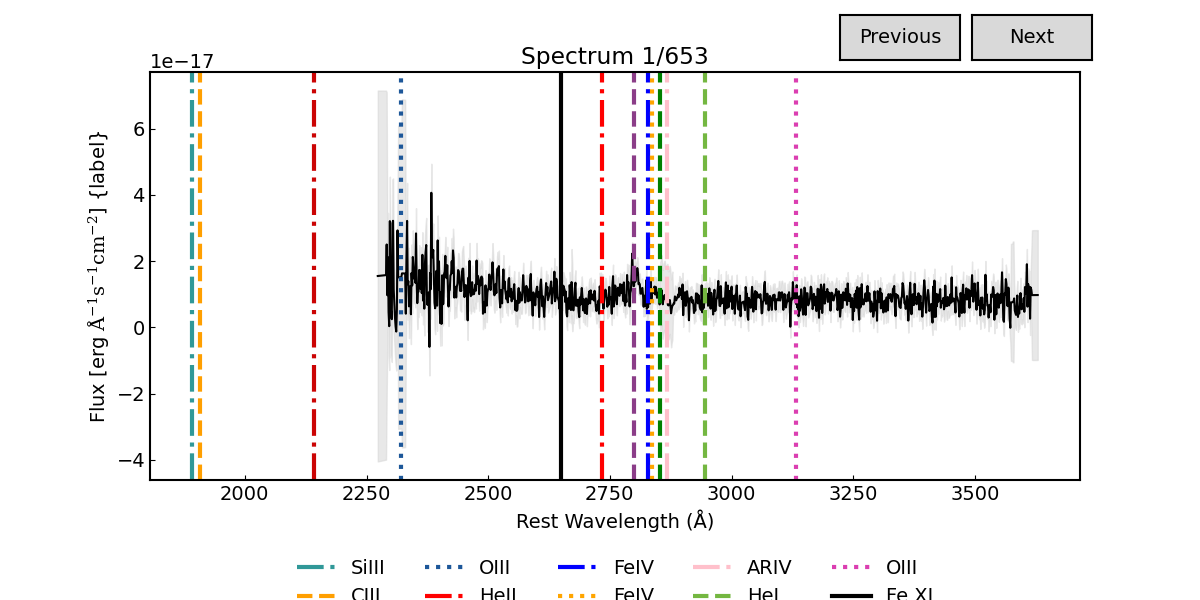

In [19]:
Luminosity_Dentity_Rest_Array = []
Rest_Wavelengths_Array = []
Luminosity_Desity_Rest_Err_Array = []
Rest_Flux_Density_Array = []
Rest_Flux_Density_Err_Array = []
Detect_ID_Names = []

for i in np.arange(len(Combined_Table_Wave_Spec_Unique_with_Z)):

    #load an individual spectrum. The spectrum units are in 10^-17 erg AA^-1 s^-1 cm^-2. Need to multiply by 1e-17.
    obs_spec, obs_err = Combined_Table_Wave_Spec_Unique_with_Z[i]['spec']*1e-17, Combined_Table_Wave_Spec_Unique_with_Z[i]['spec_err']*1e-17
    
    #Get the coresponding redshift
    z = Combined_Table_Wave_Spec_Unique_with_Z[i]["Z"]
    #Get the coresponding Detect ID
    detectida = Combined_Table_Wave_Spec_Unique_with_Z[i]["ID"]
    
    #Put in the wavelengths in to get the wave grid. The air to vacuum accounts for the fact that the light changes based on the medium it travels through. So vacuum wavelength is different than air wavelength.
    CALFIB_WAVEGRID_VAC = ESU.air_to_vac(Combined_Table_Wave_Spec_Unique_with_Z[i]['wavelength'])
    #Get the rest values. 
    (Luminosity_Dentity_Rest, 
     Rest_Wavelengths, 
     Luminosity_Desity_Rest_Err, 
     Rest_Flux_Density, 
     Rest_Flux_Density_Err) = shift_flux_to_rest_luminosity_and_flux_density(z, 
                                                                             obs_spec, 
                                                                             CALFIB_WAVEGRID_VAC, 
                                                                             obs_err)
    
    
    Luminosity_Dentity_Rest_Array.append(Luminosity_Dentity_Rest)
    Rest_Wavelengths_Array.append(Rest_Wavelengths)
    Luminosity_Desity_Rest_Err_Array.append(Luminosity_Desity_Rest_Err)
    Rest_Flux_Density_Array.append(Rest_Flux_Density)
    Rest_Flux_Density_Err_Array.append(Rest_Flux_Density_Err)
    Detect_ID_Names.append(detectida)
    
# Define spectral lines
spectral_lines = {
        1892.030: ('#309898', '-.', 'SiIII', 3),
        1908.734: ('#FF9F00', '--', 'CIII', 3),
        2142.780: ('#CB0404', '-.', 'NII', 3),
        2320.951: ('#1D5799', ':', 'OIII', 3),
        2733.289: ('red', '-.', 'HeII', 3),
        2799.000: ('#8B3D88', '--', 'MgII', 3),
        2829.360: ('blue', '-.' ,'FeIV', 3),
        2835.740: ('orange', ':' ,'FeIV', 3),
        2853.670: ('green', '--' ,'ArIV', 3),
        2868.210: ('pink', '-.' ,'ARIV', 3),
        2945.106: ('#74B741', '--', 'HeI', 3),
        3132.794: ('#DB3EB1', ':', 'OIII', 3),
        2648.710: ('black', '-', 'Fe XI', 3)
    } #Rest Wavelength, color, linestyle, label, linewidth
    

Plots_For_Interactive_Plotting = []   
# Sample plot data - in real use case, this would be your spectral data
for j in np.arange(len(Rest_Flux_Density_Array)):
    wave_spec_interactive = np.array(Rest_Wavelengths_Array[j])
    Rest_Flux_Density_interactive = np.array(Rest_Flux_Density_Array[j])
    Rest_Flux_Density_Err_interactive = np.array(Rest_Flux_Density_Err_Array[j])
    names_interactive = Detect_ID_Names[i]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive, Rest_Flux_Density_interactive, Rest_Flux_Density_Err_interactive, names_interactive])
    
# Create and display the interactive plotter
plotter = InteractivePlotter_a(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()




In [20]:
"""
# Get the function's signature
signature = inspect.signature(ESU.shift_flam_to_rest_luminosity_per_aa)
print("Signature:", signature)

# Get the return type annotation
return_type = signature.return_annotation
print("Return type:", return_type)

# Get the docstring
docstring = inspect.getdoc(ESU.shift_flam_to_rest_luminosity_per_aa)
print("Docstring:", docstring)

# Get the source code
source_code = inspect.getsource(ESU.shift_flam_to_rest_luminosity_per_aa)
print("Source code:\n", source_code)
"""

print(np.shape(Rest_Flux_Density_Array))
print(np.shape(Rest_Flux_Density_Err_Array))
print(np.shape(Rest_Wavelengths_Array))

(653, 1036)
(653, 1036)
(653, 1036)


## <font color='#00879E' size=5 >Stacking the Rest Wavelength Spectra Using Biweight</font>

In [21]:
#stack all spectra 
avg_type = 'biweight' #Options: 'weighted_biweight', 'mean', 'median'
Stack_Spec, Stack_Spec_SD, Stack_Wave, Contrib_Count, Stack_Flux_SD = ESU.stack_spectra(Rest_Flux_Density_Array, Rest_Flux_Density_Err_Array, Rest_Wavelengths_Array, avg_type=avg_type, std=True) #Contrib_Count is the number of spectra contributing to the wavelength bin.


## 

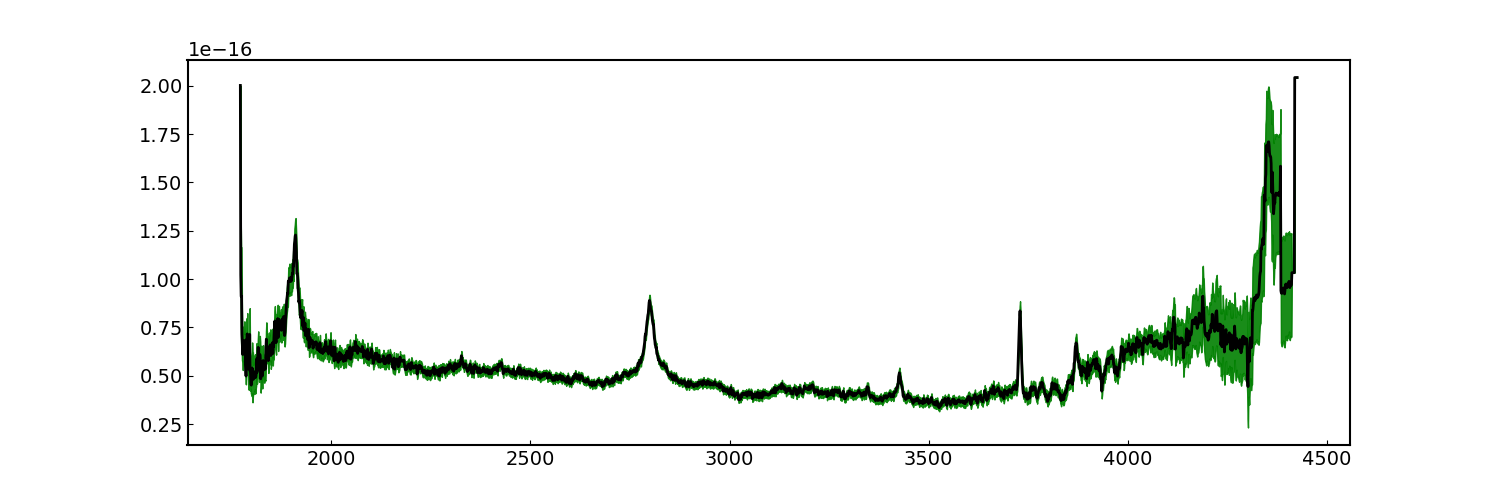

In [22]:
plt.figure(figsize=(15, 5))
plt.plot(Stack_Wave, Stack_Spec, color="black")
plt.fill_between(Stack_Wave, Stack_Spec - Stack_Spec_SD, Stack_Spec + Stack_Spec_SD, color="green", alpha=0.9, zorder=0)

# <font color='#e55730' size=5> Normalizing by matching Median spec continuum values to original stacked continuum</font>

## <font color='#00879E' size=5 >Seperating the Individual spectra and the stacked spectra</font>

In [23]:
Z_025_035 = []
Z_035_045 = []
Z_045_055 = []
Z_055_065 = []
Z_065_075 = []
Z_075_085 = []
Z_085_096 = []

Z_025_035_Index = []
Z_035_045_Index = []
Z_045_055_Index = []
Z_055_065_Index = []
Z_065_075_Index = []
Z_075_085_Index = []
Z_085_096_Index = [] 


a = -1
for i in Combined_Table_Wave_Spec_Unique_with_Z["Z"]:
    a = a+1
    #print(i)
    if 0.25 <= i < 0.35:
        #print(i)
        Z_025_035.append(i)
        Z_025_035_Index.append(a)
    if 0.35 <= i < 0.45:
        Z_035_045.append(i)
        Z_035_045_Index.append(a)
    if 0.45 <= i < 0.55:
        Z_045_055.append(i)
        Z_045_055_Index.append(a)
    if 0.55 <= i < 0.65:
        Z_055_065.append(i)
        Z_055_065_Index.append(a)
    if 0.65 <= i < 0.75:
        Z_065_075.append(i)
        Z_065_075_Index.append(a)
    if 0.75 <= i < 0.85:
        Z_075_085.append(i)
        Z_075_085_Index.append(a)
    if 0.85<= i <= 0.96:
        Z_085_096.append(i)
        Z_085_096_Index.append(a)
    else:
        continue
        

## <font color='#00879E' size=5 >Getting the Resdshift Bins</font>

In [24]:
#This is the non stacked spectra
Rest_Flux_Density_Array_025_035, Rest_Flux_Density_Err_Array_025_035, Rest_Wavelengths_Array_025_035 = np.array(Rest_Flux_Density_Array)[Z_025_035_Index], np.array(Rest_Flux_Density_Err_Array)[Z_025_035_Index], np.array(Rest_Wavelengths_Array)[Z_025_035_Index]
Rest_Flux_Density_Array_035_045, Rest_Flux_Density_Err_Array_035_045, Rest_Wavelengths_Array_035_045 = np.array(Rest_Flux_Density_Array)[Z_035_045_Index], np.array(Rest_Flux_Density_Err_Array)[Z_035_045_Index], np.array(Rest_Wavelengths_Array)[Z_035_045_Index]
Rest_Flux_Density_Array_045_055, Rest_Flux_Density_Err_Array_045_055, Rest_Wavelengths_Array_045_055 = np.array(Rest_Flux_Density_Array)[Z_045_055_Index], np.array(Rest_Flux_Density_Err_Array)[Z_045_055_Index], np.array(Rest_Wavelengths_Array)[Z_045_055_Index]
Rest_Flux_Density_Array_055_065, Rest_Flux_Density_Err_Array_055_065, Rest_Wavelengths_Array_055_065 = np.array(Rest_Flux_Density_Array)[Z_055_065_Index], np.array(Rest_Flux_Density_Err_Array)[Z_055_065_Index], np.array(Rest_Wavelengths_Array)[Z_055_065_Index]
Rest_Flux_Density_Array_065_075, Rest_Flux_Density_Err_Array_065_075, Rest_Wavelengths_Array_065_075 = np.array(Rest_Flux_Density_Array)[Z_065_075_Index], np.array(Rest_Flux_Density_Err_Array)[Z_065_075_Index], np.array(Rest_Wavelengths_Array)[Z_065_075_Index]
Rest_Flux_Density_Array_075_085, Rest_Flux_Density_Err_Array_075_085, Rest_Wavelengths_Array_075_085 = np.array(Rest_Flux_Density_Array)[Z_075_085_Index], np.array(Rest_Flux_Density_Err_Array)[Z_075_085_Index], np.array(Rest_Wavelengths_Array)[Z_075_085_Index]
Rest_Flux_Density_Array_085_096, Rest_Flux_Density_Err_Array_085_096, Rest_Wavelengths_Array_085_096 = np.array(Rest_Flux_Density_Array)[Z_085_096_Index], np.array(Rest_Flux_Density_Err_Array)[Z_085_096_Index], np.array(Rest_Wavelengths_Array)[Z_085_096_Index]



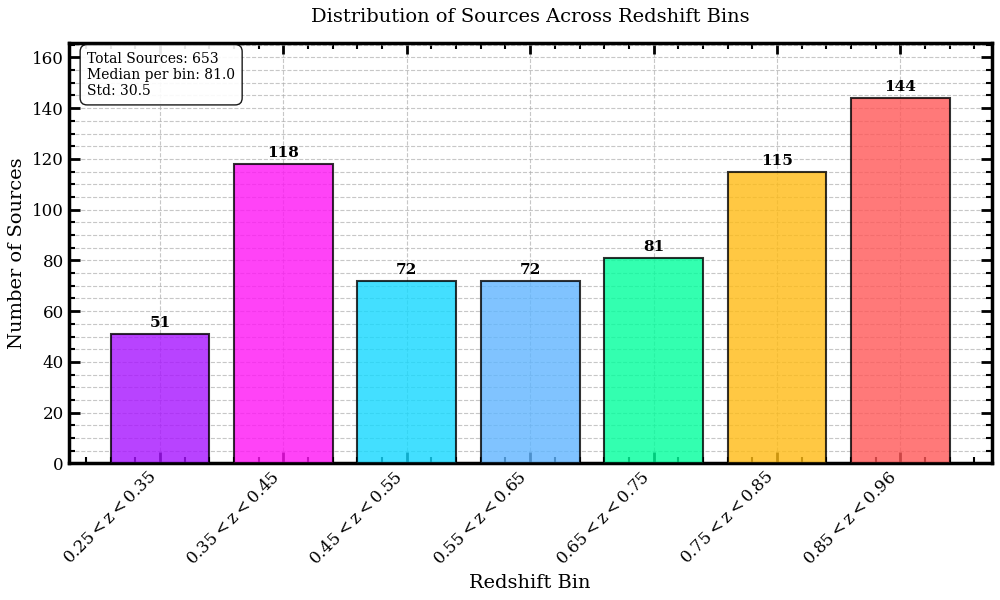

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Data slicing for each redshift bin
redshift_data = {
    '025_035': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_025_035_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_025_035_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_025_035_Index]
    },
    '035_045': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_035_045_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_035_045_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_035_045_Index]
    },
    '045_055': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_045_055_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_045_055_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_045_055_Index]
    },
    '055_065': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_055_065_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_055_065_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_055_065_Index]
    },
    '065_075': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_065_075_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_065_075_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_065_075_Index]
    },
    '075_085': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_075_085_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_075_085_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_075_085_Index]
    },
    '085_096': {
        'spec': np.array(Rest_Flux_Density_Array)[Z_085_096_Index],
        'spec_sd': np.array(Rest_Flux_Density_Err_Array)[Z_085_096_Index],
        'wave': np.array(Rest_Wavelengths_Array)[Z_085_096_Index]
    }
}

# Histogram configuration
bin_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Calculate bin counts
bin_counts = [len(redshift_data[key]['spec']) for key in redshift_data.keys()]

# Color assignment for each bin
bar_colors = [colors[key] for key in redshift_data.keys()]

# Create figure with MNRAS specifications
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Create histogram bars
bars = ax.bar(
    range(len(bin_labels)),
    bin_counts,
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=3
)

# Configure axes labels and title
ax.set_xlabel(r"Redshift Bin", fontsize=14, color="black")
ax.set_ylabel(r"Number of Sources", fontsize=14, color="black")
ax.set_title("Distribution of Sources Across Redshift Bins", fontsize=14, pad=15)

# Set x-axis labels
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

# Configure grid
ax.grid(visible=True, which='both', axis='y', 
        linestyle='--', alpha=0.7, zorder=1)
ax.set_axisbelow(True)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Annotate bars with counts
for i, (bar, count) in enumerate(zip(bars, bin_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, 
            height + max(bin_counts) * 0.01, 
            f'{count}', 
            ha='center', 
            va='bottom', 
            fontsize=11,
            fontweight='bold',
            zorder=4)

# Set y-axis limits with padding
ax.set_ylim(0, max(bin_counts) * 1.15)

# Add statistical information as text box
total_sources = sum(bin_counts)
stats_text = f'Total Sources: {total_sources}\nMedian per bin: {np.median(bin_counts):.1f}\nStd: {np.std(bin_counts):.1f}'

ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', 
                  facecolor='white', 
                  edgecolor='black',
                  alpha=0.9))

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("redshift_bin_histogram_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/redshift_bin_histogram_MNRAS.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Removeing the stellar continuum from the 3000 angstroms</font>

## <font color='#00879E' size=5 >Getting the Continuums</font>

In [26]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run and if it does then the code instead pulls the file.
The fit_continuum_with_metrics_for_unstacked :
                                                Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
                                                Uses bootstrap resampling for uncertainty estimation.

The continuum range is 2950 - 3050
"""
# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Fit_Gen_Continuum_UnStacked.fits"
# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spectrum_1D_Spectra_NonStacked_Array,
     Spectrum_1D_Continuum_NonStacked_Array,
     Spectrum_1D_Residuals_NonStacked_Array,
     Spectrum_1D_Continuum_SD_NonStacked_Array,
     Spectrum_1D_Fit_Metrics_NonStacked_Array) = fit_continuum_with_metrics_for_unstacked(
        np.array(Rest_Wavelengths_Array),
        Rest_Flux_Density_Array,
        Rest_Flux_Density_Err_Array,
        scaling_factor=1e-16,
        n_bootstrap=500
    )
    
    # It looks like these are already numpy arrays, not Spectrum1D objects
    # Check the types of the arrays and handle appropriately
    
    # Function to safely convert arrays to FITS-compatible format
    def convert_to_fits_compatible(arr):
        # If it's already a simple numpy array of numbers, return as is
        if isinstance(arr, np.ndarray) and arr.dtype.kind in 'fiub':  # float, int, uint, bool
            return arr
        # If it's a numpy array of objects (dtype='O'), convert each element
        elif isinstance(arr, np.ndarray) and arr.dtype.kind == 'O':
            # Try to extract as simple array if possible
            try:
                return np.array([x for x in arr], dtype=float)
            except:
                # If conversion fails, convert to strings
                return np.array([str(x) for x in arr])
        # For other types, try direct conversion or fall back to strings
        else:
            try:
                return np.array(arr, dtype=float)
            except:
                return np.array([str(x) for x in arr])
    
    # Convert each array to a FITS-compatible format
    spectra_flux = convert_to_fits_compatible(Spectrum_1D_Spectra_NonStacked_Array)
    continuum_flux = convert_to_fits_compatible(Spectrum_1D_Continuum_NonStacked_Array)
    residuals_flux = convert_to_fits_compatible(Spectrum_1D_Residuals_NonStacked_Array)
    continuum_sd_flux = convert_to_fits_compatible(Spectrum_1D_Continuum_SD_NonStacked_Array)
    
    # For fit metrics, we need to know their structure
    # If they're simple values, we can use them directly
    # If they're complex objects, we may need to serialize them differently
    
    # Create a table with the extracted numerical data
    table = QTable()
    table['Spectra'] = spectra_flux
    table['Continuum'] = continuum_flux
    table['Residuals'] = residuals_flux
    table['Continuum_SD'] = continuum_sd_flux
    
    # Handle fit metrics based on their structure
    fit_metrics = convert_to_fits_compatible(Spectrum_1D_Fit_Metrics_NonStacked_Array)
    table['Fit_Metrics'] = fit_metrics
    
    # Write the table to FITS
    table.write(output_path, overwrite=True)
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS and assign to variables
    table = QTable.read(output_path)
    
    # Retrieve the data
    Spectrum_1D_Spectra_NonStacked_Array = table["Spectra"]
    Spectrum_1D_Continuum_NonStacked_Array = table["Continuum"]
    Spectrum_1D_Residuals_NonStacked_Array = table["Residuals"]
    Spectrum_1D_Continuum_SD_NonStacked_Array = table["Continuum_SD"]
    Spectrum_1D_Fit_Metrics_NonStacked_Array = table["Fit_Metrics"]

    print("Finished Reading File")




Reading results from existing FITS file...
Finished Reading File


In [27]:
Stack_Spec, Stack_Spec_SD, Stack_Wave, Contrib_Count, Stack_Flux_SD = ESU.stack_spectra(Rest_Flux_Density_Array, Rest_Flux_Density_Err_Array, Rest_Wavelengths_Array, avg_type=avg_type, std=True) #Contrib_Count is the number of spectra contributing to the wavelength bin.


#####This needs to be fixed the output of this stacking is lum not spec




In [28]:
"""
Normalizing spectra to one and then stacking all together dispite redshift.
"""





#This is the non stacked spectra
Rest_Flux_Density_Array_025_035, Rest_Flux_Density_Err_Array_025_035, Rest_Wavelengths_Array_025_035 = np.array(Rest_Flux_Density_Array)[Z_025_035_Index], np.array(Rest_Flux_Density_Err_Array)[Z_025_035_Index], np.array(Rest_Wavelengths_Array)[Z_025_035_Index]
Rest_Flux_Density_Array_035_045, Rest_Flux_Density_Err_Array_035_045, Rest_Wavelengths_Array_035_045 = np.array(Rest_Flux_Density_Array)[Z_035_045_Index], np.array(Rest_Flux_Density_Err_Array)[Z_035_045_Index], np.array(Rest_Wavelengths_Array)[Z_035_045_Index]
Rest_Flux_Density_Array_045_055, Rest_Flux_Density_Err_Array_045_055, Rest_Wavelengths_Array_045_055 = np.array(Rest_Flux_Density_Array)[Z_045_055_Index], np.array(Rest_Flux_Density_Err_Array)[Z_045_055_Index], np.array(Rest_Wavelengths_Array)[Z_045_055_Index]
Rest_Flux_Density_Array_055_065, Rest_Flux_Density_Err_Array_055_065, Rest_Wavelengths_Array_055_065 = np.array(Rest_Flux_Density_Array)[Z_055_065_Index], np.array(Rest_Flux_Density_Err_Array)[Z_055_065_Index], np.array(Rest_Wavelengths_Array)[Z_055_065_Index]
Rest_Flux_Density_Array_065_075, Rest_Flux_Density_Err_Array_065_075, Rest_Wavelengths_Array_065_075 = np.array(Rest_Flux_Density_Array)[Z_065_075_Index], np.array(Rest_Flux_Density_Err_Array)[Z_065_075_Index], np.array(Rest_Wavelengths_Array)[Z_065_075_Index]
Rest_Flux_Density_Array_075_085, Rest_Flux_Density_Err_Array_075_085, Rest_Wavelengths_Array_075_085 = np.array(Rest_Flux_Density_Array)[Z_075_085_Index], np.array(Rest_Flux_Density_Err_Array)[Z_075_085_Index], np.array(Rest_Wavelengths_Array)[Z_075_085_Index]
Rest_Flux_Density_Array_085_096, Rest_Flux_Density_Err_Array_085_096, Rest_Wavelengths_Array_085_096 = np.array(Rest_Flux_Density_Array)[Z_085_096_Index], np.array(Rest_Flux_Density_Err_Array)[Z_085_096_Index], np.array(Rest_Wavelengths_Array)[Z_085_096_Index]


In [29]:
"""
Getting the MgII Indexes for wavelengths and spec of all individual sources.
"""
def getting_the_MgII_Indexes(rest_arrays, rest_spec_arrays, rest_spec_error_arrays, start_wave, finish_wave):
    """
    This definition gets the indexes, waves, and specs for all of the individual rest-frame spectra in each wavelength bin.

    Parameters:
    -----------
    rest_arrays: array
        Arrays of the rest wave individual spectra that have already been put into the redshift bins.
    start_wave: float
        The wavelength to start the section that we want out around MgII.
    finish_wave: float
        The wavelength to finish the section that we want out around MgII.

    Returns:
    --------
    index_array: array
        Array of all of the rest frame wavelength indexes for the section that we want out. This is for individual spectra in redshift bin.
    MgII_wave_array: array
        Array of all of the rest frame wavelengths for the section that we want out. This is for individual spectra in redshift bin. 
    
    """

    index_array = []
    wave_array = []
    spec_array = []
    spec_error_array = []
    
    for wave, spec, spec_error in zip(rest_arrays, rest_spec_arrays, rest_spec_error_arrays):
        index = np.where(np.logical_and(wave > start_wave, wave < finish_wave))[0]
        wave_range = wave[index]
        spec_range = spec[index]
        spec_error_range = spec_error = spec_error[index]

        
        index_array.append(index)
        wave_array.append(wave_range)
        spec_array.append(spec_range)
        spec_error_array.append(spec_error_range)

    return index_array, wave_array, spec_array, spec_error_array








"""
Getting the MgII range for normalizing the spectra. This needs to be close to the MgII emission profile, but not across it.

Doing the same for the spec errors.
"""
(Individual_Continuum_Index_Normalization_Array_025_035, 
 Individual_Continuum_Wave_Normalization_Array_025_035,
 Individual_Continuum_Spec_Normalization_Array_025_035,
 Individual_Continuum_Spec_Err_Normalization_Array_025_035) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_025_035,
                                                                                        Rest_Flux_Density_Array_025_035,
                                                                                        Rest_Flux_Density_Err_Array_025_035,
                                                                                        2900,
                                                                                        3100)
(Individual_Continuum_Index_Normalization_Array_035_045, 
 Individual_Continuum_Wave_Normalization_Array_035_045,
 Individual_Continuum_Spec_Normalization_Array_035_045,
 Individual_Continuum_Spec_Err_Normalization_Array_035_045) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_035_045,
                                                                                        Rest_Flux_Density_Array_035_045,
                                                                                        Rest_Flux_Density_Err_Array_035_045,
                                                                                        2900,
                                                                                        3100)

(Individual_Continuum_Index_Normalization_Array_045_055, 
 Individual_Continuum_Wave_Normalization_Array_045_055,
 Individual_Continuum_Spec_Normalization_Array_045_055,
 Individual_Continuum_Spec_Err_Normalization_Array_045_055) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_045_055,
                                                                                        Rest_Flux_Density_Array_045_055,
                                                                                        Rest_Flux_Density_Err_Array_045_055,
                                                                                        2900,
                                                                                        3100)

(Individual_Continuum_Index_Normalization_Array_055_065, 
 Individual_Continuum_Wave_Normalization_Array_055_065,
 Individual_Continuum_Spec_Normalization_Array_055_065,
 Individual_Continuum_Spec_Err_Normalization_Array_055_065) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_055_065,
                                                                                        Rest_Flux_Density_Array_055_065,
                                                                                        Rest_Flux_Density_Err_Array_055_065,
                                                                                        2900,
                                                                                        3100)

(Individual_Continuum_Index_Normalization_Array_065_075, 
 Individual_Continuum_Wave_Normalization_Array_065_075,
 Individual_Continuum_Spec_Normalization_Array_065_075,
 Individual_Continuum_Spec_Err_Normalization_Array_065_075) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_065_075,
                                                                                        Rest_Flux_Density_Array_065_075,
                                                                                        Rest_Flux_Density_Err_Array_065_075,
                                                                                        2500,
                                                                                        2700)

(Individual_Continuum_Index_Normalization_Array_075_085, 
 Individual_Continuum_Wave_Normalization_Array_075_085,
 Individual_Continuum_Spec_Normalization_Array_075_085,
 Individual_Continuum_Spec_Err_Normalization_Array_075_085) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_075_085,
                                                                                        Rest_Flux_Density_Array_075_085,
                                                                                        Rest_Flux_Density_Err_Array_075_085,
                                                                                        2500,
                                                                                        2700)

(Individual_Continuum_Index_Normalization_Array_085_096, 
 Individual_Continuum_Wave_Normalization_Array_085_096,
 Individual_Continuum_Spec_Normalization_Array_085_096,
 Individual_Continuum_Spec_Err_Normalization_Array_085_096) = getting_the_MgII_Indexes(
                                                                                        Rest_Wavelengths_Array_085_096,
                                                                                        Rest_Flux_Density_Array_085_096,
                                                                                        Rest_Flux_Density_Err_Array_085_096,
                                                                                        2500,
                                                                                        2700)



def fitting_the_continuums_for_normalization(wave_arrays, spec_arrays, degree, weight_arrays):
    """
    This code fits the continuum region for the spectral normalization.

    Parmeters:
    ----------
    wave_arrays: array
        Array of arrays. This is the continuum wavelengths for the range that will be used to normalize the individual spectra for stacking.

    Spec_arrays: array
        Array of arrays. This is the spectral values for the continuum wavelengths.
    
    Degree: integer
        This is the degree of the polinomial used for fitting.

    Weight_arrays: array
        Array of arrays. This is the spectral error values for the continuum wavelengths.


    Returns:
    --------
    Fit_arrays: array
        Array of arrays. The fit values for the continuums. For degree of 3 we expect to get 3 polynomial values.
        
    COV_arrays: array
        -Array of arrays. The covariance matrix.
        -cov = [[var(b),   cov(b,a)],
               [cov(a,b), var(a)  ]]
        -Diagonals = error on values
        -Other = how the error on values corrilate with each other.

    Fit_error_arrays: array
        -Array of arrays. The errors on the fit from the covariance matrix. 
        -sqrt(diagonal(covariance matrix))
        

    """

    fit_arrays = []
    cov_arrays = []
    fit_error_arrays = []

    for wave, spec, weight in zip(wave_arrays, spec_arrays, weight_arrays):
        fit, cov = np.polyfit(wave, spec, degree, w=weight, cov=True)
        fit_error = np.sqrt(np.diag(cov))

        fit_arrays.append(fit)
        cov_arrays.append(cov)
        fit_error_arrays.append(fit_error)

    return fit_arrays, cov_arrays, fit_error_arrays


"""
Getting the continuum of the individual spectra in an area around(ish) the MgII profile. 
"""
(Polyfit_Ref_Stack_Continuum_Normalization_025_035,
Polyfit_COV_Ref_Stack_Continuum_Normalization_025_035,
Polyfit_Error_Ref_Stack_Continuum_Normalization_025_035) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_025_035, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_025_035, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_025_035)

(Polyfit_Ref_Stack_Continuum_Normalization_035_045,
Polyfit_COV_Ref_Stack_Continuum_Normalization_035_045,
Polyfit_Error_Ref_Stack_Continuum_Normalization_035_045) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_035_045, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_035_045, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_035_045)

(Polyfit_Ref_Stack_Continuum_Normalization_045_055,
Polyfit_COV_Ref_Stack_Continuum_Normalization_045_055,
Polyfit_Error_Ref_Stack_Continuum_Normalization_045_055) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_045_055, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_045_055, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_045_055)

(Polyfit_Ref_Stack_Continuum_Normalization_055_065,
Polyfit_COV_Ref_Stack_Continuum_Normalization_055_065,
Polyfit_Error_Ref_Stack_Continuum_Normalization_055_065) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_055_065, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_055_065, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_055_065)

(Polyfit_Ref_Stack_Continuum_Normalization_065_075,
Polyfit_COV_Ref_Stack_Continuum_Normalization_065_075,
Polyfit_Error_Ref_Stack_Continuum_Normalization_065_075) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_065_075, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_065_075, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_065_075)

(Polyfit_Ref_Stack_Continuum_Normalization_075_085,
Polyfit_COV_Ref_Stack_Continuum_Normalization_075_085,
Polyfit_Error_Ref_Stack_Continuum_Normalization_075_085) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_075_085, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_075_085, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_075_085)

(Polyfit_Ref_Stack_Continuum_Normalization_085_096,
Polyfit_COV_Ref_Stack_Continuum_Normalization_085_096,
Polyfit_Error_Ref_Stack_Continuum_Normalization_085_096) = fitting_the_continuums_for_normalization(
                                                                                                    Individual_Continuum_Wave_Normalization_Array_085_096, 
                                                                                                    Individual_Continuum_Spec_Normalization_Array_085_096, 
                                                                                                    3, 
                                                                                                    Individual_Continuum_Spec_Err_Normalization_Array_085_096)






def polynomial_with_error_propagation(
    coefficients,
    x_values,
    coefficient_uncertainties=None,
    covariance_matrix=None
):
    """
    Evaluate a polynomial and propagate uncertainty from coefficients.

    Parameters:
    -----------
    coefficients : array-like
        Polynomial coefficients [a, b, ..., z] from highest to lowest degree
    x_values : array-like
        The x values to evaluate the polynomial at
    coefficient_uncertainties : array-like, optional
        Standard deviation of each coefficient (assumes uncorrelated errors)
    covariance_matrix : 2D array-like, optional
        Covariance matrix of the polynomial coefficients

    Returns:
    --------
    y_values : array-like
        The polynomial values
    y_uncertainties : array-like
        The propagated uncertainties
    """
    coefficients = np.asarray(coefficients)
    #x_values = np.asarray(x_values)

    y_values_array = []
    y_values_error_array = []

    for coef, x_val, cov_mat, coef_err in zip(coefficients, x_values, covariance_matrix, coefficient_uncertainties):
        
        # Evaluate the polynomial
        y_values = np.polyval(coef, x_val)
    
        # Compute the Jacobian matrix of partial derivatives
        powers = np.arange(len(coef))[::-1]  # descending powers
        jacobian = np.array([x_val**p for p in powers]).T  # shape: (n_points, n_coeffs)
    
        if cov_mat is not None:
            # Full error propagation with covariance
            cov_mat = np.asarray(cov_mat)
            y_var = np.einsum('ij,jk,ik->i', jacobian, cov_mat, jacobian)
        elif coef_err is not None:
            # Diagonal-only propagation (uncorrelated errors)
            coef_err = np.asarray(coef_err)
            y_var = np.sum((jacobian * coef_err)**2, axis=1)
        else:
            raise ValueError("You must provide either coefficient_uncertainties or covariance_matrix.")
    
        y_uncertainties = np.sqrt(y_var)

        y_values_array.append(y_values)
        y_values_error_array.append(y_uncertainties)
        
    return y_values_array, y_values_error_array

print(Individual_Continuum_Wave_Normalization_Array_025_035[0])


"""
Taking the Polyfit outputs (the coefficients) and putting them into a polynomial equation.
"""
(PolyEquation_Ref_Stack_Continuum_Normalization_025_035, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_025_035) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_025_035,
                                                                                Individual_Continuum_Wave_Normalization_Array_025_035,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_025_035,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_025_035
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_035_045, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_035_045) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_035_045,
                                                                                Individual_Continuum_Wave_Normalization_Array_035_045,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_035_045,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_035_045
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_045_055, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_045_055) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_045_055,
                                                                                Individual_Continuum_Wave_Normalization_Array_045_055,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_045_055,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_045_055
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_055_065, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_055_065) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_055_065,
                                                                                Individual_Continuum_Wave_Normalization_Array_055_065,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_055_065,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_055_065
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_065_075, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_065_075) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_065_075,
                                                                                Individual_Continuum_Wave_Normalization_Array_065_075,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_065_075,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_065_075
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_075_085, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_075_085) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_075_085,
                                                                                Individual_Continuum_Wave_Normalization_Array_075_085,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_075_085,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_075_085
                                                                                )

(PolyEquation_Ref_Stack_Continuum_Normalization_085_096, 
PolyEquation_Error_Ref_Stack_Continuum_Normalization_085_096) = polynomial_with_error_propagation(
                                                                                Polyfit_Ref_Stack_Continuum_Normalization_085_096,
                                                                                Individual_Continuum_Wave_Normalization_Array_085_096,
                                                                                Polyfit_Error_Ref_Stack_Continuum_Normalization_085_096,
                                                                                Polyfit_COV_Ref_Stack_Continuum_Normalization_085_096
                                                                                )




[2901.17587798 2902.71004093 2904.2442039  2905.77836689 2907.31252992
 2908.84669296 2910.38085603 2911.91501913 2913.44918225 2914.9833454
 2916.51750856 2918.05167176 2919.58583498 2921.11999822 2922.65416149
 2924.18832478 2925.72248809 2927.25665143 2928.7908148  2930.32497819
 2931.8591416  2933.39330504 2934.9274685  2936.46163198 2937.99579549
 2939.52995902 2941.06412258 2942.59828616 2944.13244976 2945.66661339
 2947.20077704 2948.73494071 2950.26910441 2951.80326813 2953.33743188
 2954.87159564 2956.40575944 2957.93992325 2959.47408709 2961.00825095
 2962.54241484 2964.07657874 2965.61074267 2967.14490663 2968.67907061
 2970.21323461 2971.74739863 2973.28156268 2974.81572674 2976.34989084
 2977.88405495 2979.41821909 2980.95238325 2982.48654743 2984.02071164
 2985.55487587 2987.08904012 2988.62320439 2990.15736869 2991.691533
 2993.22569734 2994.75986171 2996.29402609 2997.8281905  2999.36235493
 3000.89651938 3002.43068385 3003.96484835 3005.49901287 3007.03317741
 3008.567

In [30]:


def normalize_spectrum_to_continuum(
    flux_array,
    flux_error,
    continuum_flux,
    continuum_flux_err
):
    """
    Normalize a spectrum by dividing by the median continuum level.
    
    Parameters:
    -----------
    flux : array-like
        Observed flux array
    flux_err : array-like
        Flux uncertainties
    continuum_flux : array-like
        Continuum flux values (from polynomial_with_error_propagation)
    continuum_flux_err : array-like
        Continuum flux uncertainties (from polynomial_with_error_propagation)
    
    Returns:
    --------
    normalized_flux : array-like
        Flux normalized to continuum level ~ 1
    normalized_flux_err : array-like
        Propagated uncertainties
    norm_factor : float
        The normalization factor used (median of continuum)
    norm_factor_err : float
        Uncertainty on the normalization factor
    """
    #flux_array = np.asarray(flux_array)
    #flux_error = np.asarray(flux_error)
    #continuum_flux = np.asarray(continuum_flux)
    #continuum_flux_err = np.asarray(continuum_flux_err)

    normalized_flux_array = []
    normalized_flux_err_array = []
    norm_factor_array = []
    norm_factor_err_array = []

    for flux, flux_err, cont_flux, cont_flux_err in zip(flux_array, flux_error, continuum_flux, continuum_flux_err):
        # Calculate normalization factor as median of continuum
        norm_factor = np.median(cont_flux)
        
        # Estimate uncertainty on median (approximate as std / sqrt(N))
        norm_factor_err = np.std(cont_flux) / np.sqrt(len(cont_flux))
        
        # Normalize the spectrum by dividing
        normalized_flux = flux / norm_factor
        
        # Relative error propagation for division: sqrt((σ_A/A)^2 + (σ_B/B)^2)
        # Handle division by zero gracefully
        with np.errstate(divide='ignore', invalid='ignore'):
            relative_err = np.sqrt((flux_err / flux)**2 + (norm_factor_err / norm_factor)**2)
            normalized_flux_err = normalized_flux * relative_err
            
        # Set error to NaN where flux is zero/invalid
        normalized_flux_err = np.where(np.isfinite(normalized_flux_err), normalized_flux_err, np.nan)

        normalized_flux_array.append(normalized_flux)
        normalized_flux_err_array.append(normalized_flux_err)
        norm_factor_array.append(norm_factor)
        norm_factor_err_array.append(norm_factor_err)
    
    return normalized_flux_array, normalized_flux_err_array, norm_factor_array, norm_factor_err_array




"""
Subtracting the results of the Poly equation from the spectra.
"""
(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_025_035,
Normalized_Factor_Ref_Stack_Continuum_Normalized_025_035,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_025_035) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_025_035,
                                                                                                   Rest_Flux_Density_Err_Array_025_035,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_025_035,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_025_035
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_035_045,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_035_045,
Normalized_Factor_Ref_Stack_Continuum_Normalized_035_045,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_035_045) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_035_045,
                                                                                                   Rest_Flux_Density_Err_Array_035_045,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_035_045,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_035_045
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_045_055,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_045_055,
Normalized_Factor_Ref_Stack_Continuum_Normalized_045_055,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_045_055) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_045_055,
                                                                                                   Rest_Flux_Density_Err_Array_045_055,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_045_055,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_045_055
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_055_065,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_055_065,
Normalized_Factor_Ref_Stack_Continuum_Normalized_055_065,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_055_065) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_055_065,
                                                                                                   Rest_Flux_Density_Err_Array_055_065,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_055_065,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_055_065
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_065_075,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_065_075,
Normalized_Factor_Ref_Stack_Continuum_Normalized_065_075,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_065_075) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_065_075,
                                                                                                   Rest_Flux_Density_Err_Array_065_075,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_065_075,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_065_075
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_075_085,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_075_085,
Normalized_Factor_Ref_Stack_Continuum_Normalized_075_085,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_075_085) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_075_085,
                                                                                                   Rest_Flux_Density_Err_Array_075_085,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_075_085,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_075_085
                                                                                                    )
 
(Normalized_Spec_Ref_Stack_Continuum_Normalized_085_096,
Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_085_096,
Normalized_Factor_Ref_Stack_Continuum_Normalized_085_096,
Normalized_Factor_Error_Ref_Stack_Continuum_Normalized_085_096) = normalize_spectrum_to_continuum(Rest_Flux_Density_Array_085_096,
                                                                                                   Rest_Flux_Density_Err_Array_085_096,
                                                                                                   Individual_Continuum_Spec_Normalization_Array_085_096,
                                                                                                   Individual_Continuum_Spec_Err_Normalization_Array_085_096
                                                                                                    )
 


print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035[0]))
print(len(Individual_Continuum_Wave_Normalization_Array_025_035[0]))

1036
130


In [31]:
#print((Individual_Continuum_Wave_Normalization_Array_025_035))
#print((Individual_Continuum_Wave_Normalization_Array_035_045))
#print((Individual_Continuum_Wave_Normalization_Array_045_055))
#print((Individual_Continuum_Wave_Normalization_Array_055_065))
#print((Individual_Continuum_Wave_Normalization_Array_065_075))
#print((Individual_Continuum_Wave_Normalization_Array_075_085))
#print((Individual_Continuum_Wave_Normalization_Array_085_096))
print()
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_035_045))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_045_055))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_055_065))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_065_075))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_075_085))
#print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_085_096))
#print()
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_025_035))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_035_045))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_045_055))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_055_065))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_065_075))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_075_085))
#print(len(Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_085_096))


print(len(Rest_Wavelengths_Array_025_035))
print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035))
print()
print(len(Rest_Wavelengths_Array_025_035[0]))
print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035[0]))
print()
print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_035_045), len(Rest_Wavelengths_Array_035_045))
print(len(Normalized_Spec_Ref_Stack_Continuum_Normalized_035_045[0]), len(Rest_Wavelengths_Array_035_045[0]))


51
51

1036
1036

118 118
1036 1036


In [32]:
# Concatenate along the first axis (stack spectra)
Normalized_Ref_Stack_Wave_Normalization_Array = np.concatenate([
    Rest_Wavelengths_Array_025_035,
    Rest_Wavelengths_Array_035_045,
    Rest_Wavelengths_Array_045_055,
    Rest_Wavelengths_Array_055_065,
    Rest_Wavelengths_Array_065_075,
    Rest_Wavelengths_Array_075_085,
    Rest_Wavelengths_Array_085_096
], axis=0)

Normalized_Spec_Ref_Stack_Continuum_Normalized_Array = np.concatenate([
    Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_035_045,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_045_055,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_055_065,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_065_075,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_075_085,
    Normalized_Spec_Ref_Stack_Continuum_Normalized_085_096
], axis=0)

Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_Array = np.concatenate([
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_025_035,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_035_045,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_045_055,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_055_065,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_065_075,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_075_085,
    Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_085_096
], axis=0)


In [33]:
class InteractivePlotter_b:
    def __init__(self, plots_data, spectral_lines=None):
        """
        Initialize an interactive plot viewer
        
        Parameters:
        -----------
        plots_data : list of tuples
            Each tuple contains (x_data, y_data, label)
        spectral_lines : dict, optional
            Dictionary mapping wavelengths to (color, linestyle, label)
        """
        self.plots = plots_data
        self.curr_pos = 0
        self.spectral_lines = spectral_lines or {}
        
        # Create figure and axis
        self.fig, (self.ax, self.ax1) = plt.subplots(2,1, figsize=(12, 6))
        self.fig.subplots_adjust(bottom=0.2)  # Make room for buttons
        
        # Connect key press event
        self.fig.canvas.mpl_connect('key_press_event', self.key_event)
        
        # Add navigation buttons
        ax_prev = plt.axes([0.7, 0.9, 0.1, 0.075]) #[x-axis, y-axis, width, height]
        ax_next = plt.axes([0.81, 0.9, 0.1, 0.075])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        self.btn_prev.on_clicked(self.prev_plot)
        self.btn_next.on_clicked(self.next_plot)
        
        # Initial plot
        self.update_plot()
        
    def key_event(self, event):
        """Handle keyboard navigation"""
        if event.key == "right":
            self.next_plot(event)
        elif event.key == "left":
            self.prev_plot(event)
        
    def next_plot(self, event):
        """Show next plot in sequence"""
        
        """
        % - modulo operator for circular navigation
        % len(self.plots) - takes the remainder when divided by the total number of plots. This creates a "wrapping" effect that ensures your index stays within the valid range of the list.
        """
        self.curr_pos = (self.curr_pos + 1) % len(self.plots)
        self.update_plot()
        
    def prev_plot(self, event):
        """Show previous plot in sequence"""
        self.curr_pos = (self.curr_pos - 1) % len(self.plots)
        self.update_plot()
    
    def update_plot(self):
        """Update the current plot"""
        if not self.plots:
            return
            
        self.ax.clear()
        self.ax1.clear()
        x_data, y_data, y_data_sd, y_corrected_data, y_corrected_sd_data = self.plots[self.curr_pos]
        
        
        # Plot the main data
        self.ax.plot(x_data, y_data, lw=1.5, color="black", label="original")
        
        self.ax1.plot(x_data, y_corrected_data, lw=1.5, color="blue", label="normalized")
        #self.ax.fill_between(x_data, y_data-y_data_sd, y_data+y_data_sd, color="lightgray", alpha=0.5)
        # Add spectral lines
        for wavelength, (color, linestyle, line_label, linewidth) in self.spectral_lines.items():
            self.ax.axvline(x=wavelength, color=color, linestyle=linestyle, 
               linewidth=linewidth, label=line_label)
            
            self.ax1.axvline(x=wavelength, color=color, linestyle=linestyle, 
               linewidth=linewidth, label=line_label)
        
        # Set labels and title
        self.ax.set_title(f"Spectrum {self.curr_pos+1}/{len(self.plots)}")
        self.ax.set_xlabel("Rest Wavelength (Å)")
        self.ax.set_ylabel(r"Flux [erg $\AA^{-1} s^{-1} cm^{-2}$]")
        self.ax1.set_xlabel("Rest Wavelength (Å)")
        self.ax1.set_ylabel(r"Flux [erg $\AA^{-1} s^{-1} cm^{-2}$]")
        
        # Add legend outside the plot area
        self.ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                       ncol=min(5, len(self.spectral_lines)), frameon=False)
        
        
        # Refresh the canvas
        self.fig.canvas.draw()
    
    def show(self):
        """Display the interactive plot"""
        plt.show()


        

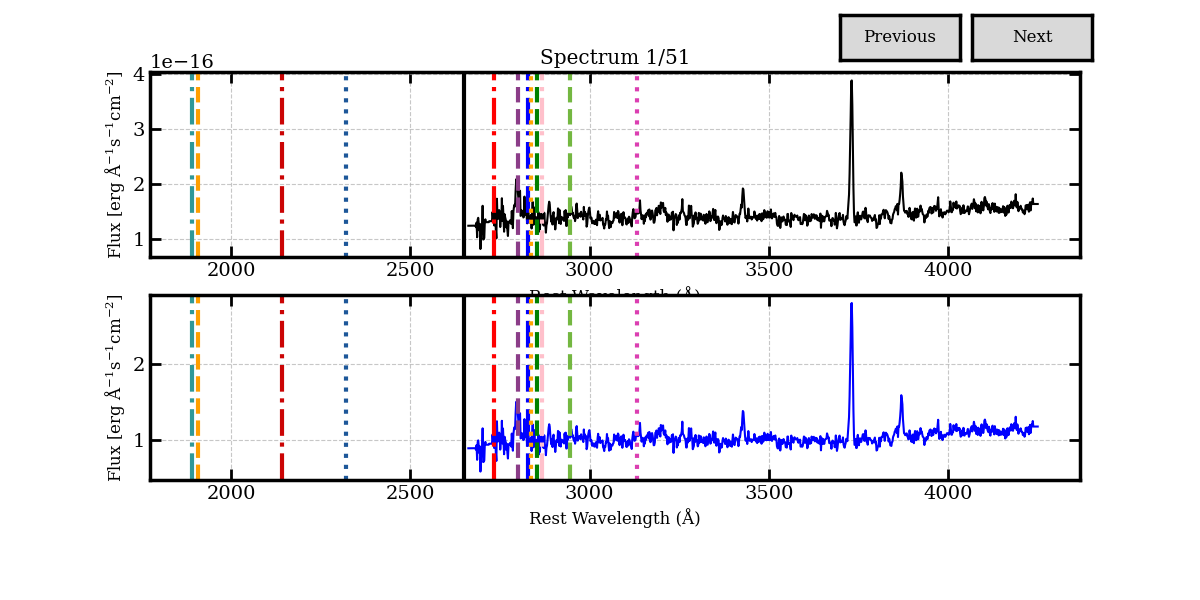

In [34]:
# Define spectral lines
spectral_lines = {
        1892.030: ('#309898', '-.', 'SiIII', 3),
        1908.734: ('#FF9F00', '--', 'CIII', 3),
        2142.780: ('#CB0404', '-.', 'NII', 3),
        2320.951: ('#1D5799', ':', 'OIII', 3),
        2733.289: ('red', '-.', 'HeII', 3),
        2799.000: ('#8B3D88', '--', 'MgII', 3),
        2829.360: ('blue', '-.' ,'FeIV', 3),
        2835.740: ('orange', ':' ,'FeIV', 3),
        2853.670: ('green', '--' ,'ArIV', 3),
        2868.210: ('pink', '-.' ,'ARIV', 3),
        2945.106: ('#74B741', '--', 'HeI', 3),
        3132.794: ('#DB3EB1', ':', 'OIII', 3),
        2648.710: ('black', '-', 'Fe XI', 3)
    } #Rest Wavelength, color, linestyle, label, linewidth



Plots_For_Interactive_Plotting = []   
# Sample plot data - in real use case, this would be your spectral data
for j in np.arange(len(Individual_Continuum_Wave_Normalization_Array_025_035)):

    wave_spec_interactive = np.array(Rest_Wavelengths_Array_025_035[j])
    Rest_Flux_Density_interactive = np.array(Rest_Flux_Density_Array_025_035[j])
    Rest_Flux_Density_Err_interactive = np.array(Rest_Flux_Density_Err_Array_025_035[j])
    Rest_Flux_Density_Corrected_interactive = np.array(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035[j])
    Rest_Flux_Density_Corrected_Error_interactive = np.array(Normalized_Spec_Ref_Stack_Continuum_Normalized_025_035[j])


    Plots_For_Interactive_Plotting.append([wave_spec_interactive, 
                                           Rest_Flux_Density_interactive, 
                                           Rest_Flux_Density_Err_interactive, 
                                           Rest_Flux_Density_Corrected_interactive, 
                                           Rest_Flux_Density_Corrected_Error_interactive])
        
            
# Create and display the interactive plotter
plotter = InteractivePlotter_b(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()






In [35]:
"""
Getting the reference stack from the normalized to one spectra.

InPuts: 
    Fluxes: Flux values in rest frame
    Flux_Errors: Flux error values in rest frame
    Waves: Rest frame wavelength arrays
    Avg_type: What form of stacking -- Weighted_biweight, biweight, mean, median
    Straight_Error: Use Bayesian statistics with 95 percent confidence intervals instead
    STD: whether or not to return the std of the stack per wavebin -- TRUE, False
    Allow_Zero_Valued_Errs: Whether to change zero error values to NAN or keep them as true zeros -- FALSE, TRUE
    Interp_nn: Use nearest neighbor interprolation or linear interprolation -- TRUE, FALSE
    edgefill:

OutPuts:
    Stack_Flux: The stacked flux at each wavelength
    Stack_Flux_Err: Error on the stacked flux (Gets smaller with more spectra.) -- Use this as error on the stacked flux values.
    Grid: Wavelength array for the stack
    Contrib_Count: how many spectra contributed to each wavelength
    Stack_Flux_STD: The spread of the data (doesn't change with amount of spectra used.)
"""

avg_type = 'biweight' #Options: 'weighted_biweight', 'mean', 'median'

Ref_Stack_Flux, Ref_Stack_Flux_Err, Ref_Stack_Wave, Ref_Stack_Contrib_Count, Ref_Stack_Flux_SD = ESU.stack_spectra(Normalized_Spec_Ref_Stack_Continuum_Normalized_Array, Normalized_Spec_Error_Ref_Stack_Continuum_Normalized_Array, Normalized_Ref_Stack_Wave_Normalization_Array, avg_type=avg_type, std=True) #Contrib_Count is the number of spectra contributing to the wavelength bin.


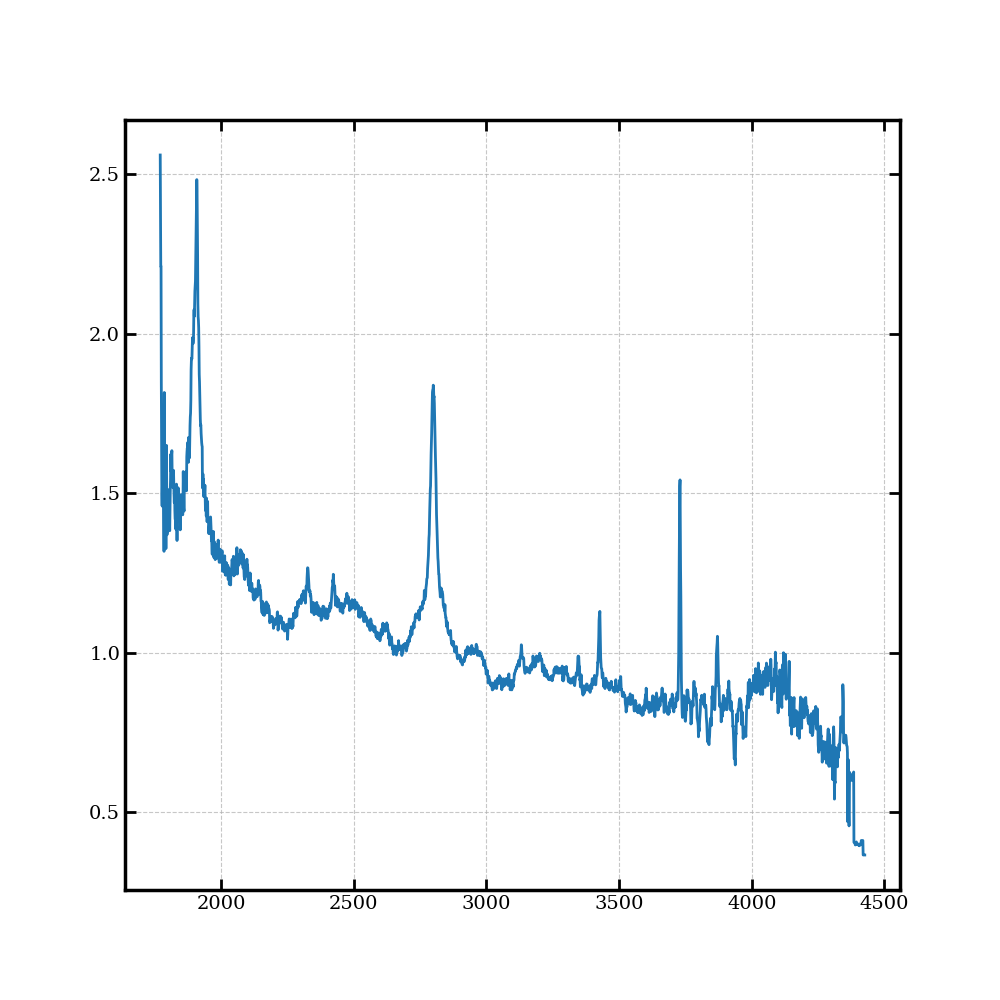

In [36]:
fig = plt.figure(figsize=(10,10))

plt.plot(Ref_Stack_Wave, Ref_Stack_Flux)

plt.show()



In [37]:
#aaaaaaaaa

In [38]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run and if it does then the code instead pulls the file.
The fit_continuum_with_metrics_for_stacked :
                                                Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
                                                Uses bootstrap resampling for uncertainty estimation.
"""
# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Fit_Gen_Continuum_Stacked.fits"
# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
  # Run the fitting
    (Spectrum_1D_Spectra_Stacked_Array,
    Spectrum_1D_Continuum_Stacked_Array,
    Spectrum_1D_Residuals_Stacked_Array,
    Spectrum_1D_Continuum_SD_Stacked_Array,
    Spectrum_1D_Fit_Metrics_Stacked_Array) = fit_continuum_with_metrics_for_stacked(
        np.array(Ref_Stack_Wave),
        Ref_Stack_Flux,
        Ref_Stack_Flux_Err,
        scaling_factor=1e-16
    )
    
    # It looks like these are already numpy arrays, not Spectrum1D objects
    # Check the types of the arrays and handle appropriately
    
    # Function to safely convert arrays to FITS-compatible format
    def convert_to_fits_compatible(arr):
        # If it's already a simple numpy array of numbers, return as is
        if isinstance(arr, np.ndarray) and arr.dtype.kind in 'fiub':  # float, int, uint, bool
            return arr
        # If it's a numpy array of objects (dtype='O'), convert each element
        elif isinstance(arr, np.ndarray) and arr.dtype.kind == 'O':
            # Try to extract as simple array if possible
            try:
                return np.array([x for x in arr], dtype=float)
            except:
                # If conversion fails, convert to strings
                return np.array([str(x) for x in arr])
        # For other types, try direct conversion or fall back to strings
        else:
            try:
                return np.array(arr, dtype=float)
            except:
                return np.array([str(x) for x in arr])
    
    # Convert each array to a FITS-compatible format
    spectra_flux = convert_to_fits_compatible(Spectrum_1D_Spectra_Stacked_Array)
    continuum_flux = convert_to_fits_compatible(Spectrum_1D_Continuum_Stacked_Array)
    residuals_flux = convert_to_fits_compatible(Spectrum_1D_Residuals_Stacked_Array)
    continuum_sd_flux = convert_to_fits_compatible(Spectrum_1D_Continuum_SD_Stacked_Array)
    
    # For fit metrics, we need to know their structure
    # If they're simple values, we can use them directly
    # If they're complex objects, we may need to serialize them differently
    
    # Create a table with the extracted numerical data
    table = QTable()
    table['Spectra'] = spectra_flux
    table['Continuum'] = continuum_flux
    table['Residuals'] = residuals_flux
    table['Continuum_SD'] = continuum_sd_flux
    
    # Handle fit metrics based on their structure
    fit_metrics = convert_to_fits_compatible(Spectrum_1D_Fit_Metrics_Stacked_Array)
    table['Fit_Metrics'] = fit_metrics
    
    # Write the table to FITS
    table.write(output_path, overwrite=True)
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS and assign to variables
    table = QTable.read(output_path)
    
    # Retrieve the data
    Spectrum_1D_Spectra_Stacked_Array = table["Spectra"]
    Spectrum_1D_Continuum_Stacked_Array = table["Continuum"]
    Spectrum_1D_Residuals_Stacked_Array = table["Residuals"]
    Spectrum_1D_Continuum_SD_Stacked_Array = table["Continuum_SD"]
    Spectrum_1D_Fit_Metrics_Stacked_Array = table["Fit_Metrics"]

    print("Finished Reading File")





Reading results from existing FITS file...
Finished Reading File


[1.51466967e-17 1.51188175e-17 1.50910109e-17 ... 8.19067620e-18
 8.18829852e-18 8.18589577e-18] [6.65690133e-18 6.59297179e-18 6.52951607e-18 ... 2.93803085e-18
 2.97355953e-18 3.00948966e-18]


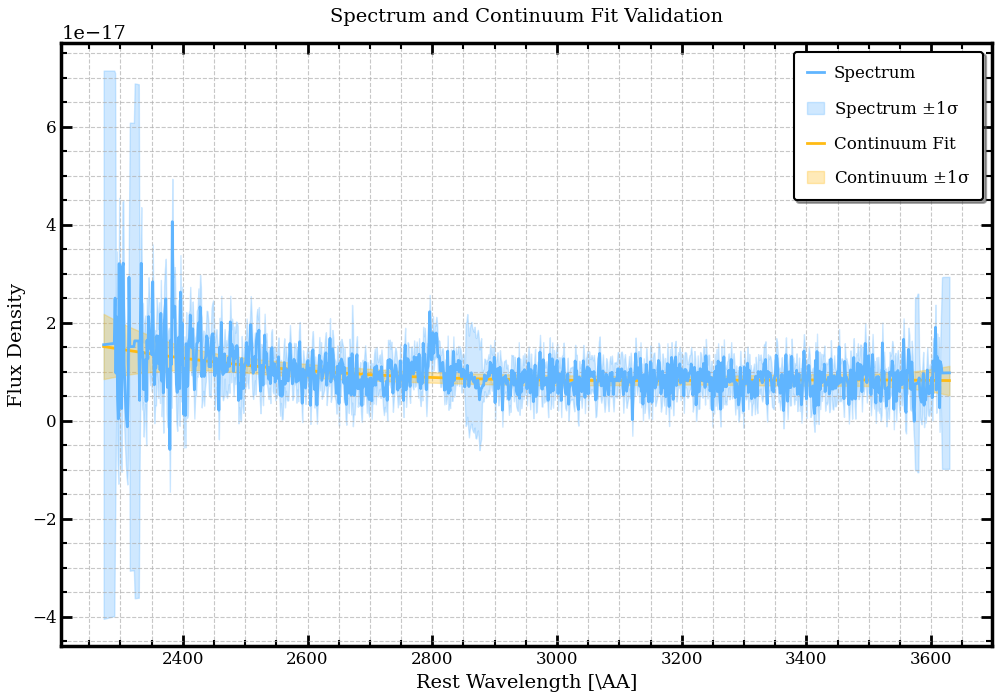

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme (organized in dictionary)
'''colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
 '''   
# Just checking the spectra and continuum fits to make sure the fit_continuum_with_metrics_for... worked the right way.
print(Spectrum_1D_Continuum_NonStacked_Array[0], Spectrum_1D_Continuum_SD_NonStacked_Array[0])

# Create figure with MNRAS-compliant dimensions and styling
fig, ax = plt.subplots(1, 1, figsize=(10, 7), facecolor='white')

# Plot spectrum with uncertainty band
spectrum_line = ax.plot(Rest_Wavelengths_Array[0], Rest_Flux_Density_Array[0], 
                       color='#60B5FF', linewidth=2.0, 
                       label='Spectrum', zorder=5)

spectrum_fill = ax.fill_between(Rest_Wavelengths_Array[0], 
                               Rest_Flux_Density_Array[0] - Rest_Flux_Density_Err_Array[0], 
                               Rest_Flux_Density_Array[0] + Rest_Flux_Density_Err_Array[0], 
                               color="#60B5FF", alpha=0.3, 
                               label=r'Spectrum $\pm 1\sigma$', zorder=1)

# Plot continuum fit with uncertainty band
continuum_line = ax.plot(Rest_Wavelengths_Array[0], Spectrum_1D_Continuum_NonStacked_Array[0], 
                        color="#ffbb14", linewidth=2.0, 
                        label='Continuum Fit', zorder=4)

continuum_fill = ax.fill_between(Rest_Wavelengths_Array[0], 
                                Spectrum_1D_Continuum_NonStacked_Array[0] - Spectrum_1D_Continuum_SD_NonStacked_Array[0], 
                                Spectrum_1D_Continuum_NonStacked_Array[0] + Spectrum_1D_Continuum_SD_NonStacked_Array[0], 
                                color="#ffbb14", alpha=0.3, 
                                label=r'Continuum $\pm 1\sigma$', zorder=3)

# Configure axes labels and title
ax.set_xlabel(r"Rest Wavelength [\AA]", fontsize=14, color="black")
ax.set_ylabel(r"Flux Density", fontsize=14, color="black")  # Adjust units as needed
ax.set_title("Spectrum and Continuum Fit Validation", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Spectrum_Continuum_Validation_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Spectrum_Continuum_Validation_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Scaling the Continuums</font>

In [40]:
"""
This gets the stack wavelength to match each 
of the rest wavelength for the individual spectra
"""
Index_to_Normalize_Array = []

for i in np.arange(len(Rest_Wavelengths_Array)):
    Index_to_Normalize_Array.append(np.where(np.logical_and(Ref_Stack_Wave > min(Rest_Wavelengths_Array[i]), Ref_Stack_Wave < max(Rest_Wavelengths_Array[i])))[0])


In [41]:
"""
The continuum for the stacked array and the individual spectra and matched them.
The dif scales up the individual spectra to match the level of the stacked spectra.
"""

New_Y_For_NonStacked_Array = []
New_Y_StdDev_For_NonStacked_Array = []  # New array to store propagated standard deviations

for i in np.arange(len(Spectrum_1D_Spectra_NonStacked_Array)):    
    
    # Calculate Median values for scaling
    a_y_stack = np.median(Spectrum_1D_Continuum_Stacked_Array[0])  # The stacked continuum
    a_y_indiv = np.median(Spectrum_1D_Continuum_NonStacked_Array[i])  # The unstacked continuums
    dif = np.subtract(a_y_stack, a_y_indiv)  # Stacked continuum - unstacked continuums
    
    # Apply scaling to the original unstacked spectra
    New_Y_For_NonStacked_Array.append(Rest_Flux_Density_Array[i] + dif)
    
    # Propagate standard deviations
    # Assuming Rest_Flux_Density_Err_Array and Stacked_StdDev are your input standard deviations
    # For addition/subtraction, errors add in quadrature
    stack_std = Ref_Stack_Flux_Err[0]  # Standard deviation of stacked spectra
    indiv_std = Rest_Flux_Density_Err_Array[i]  # Standard deviation of individual spectra
    
    # Propagate error (when adding/subtracting values, add errors in quadrature)
    propagated_std = np.sqrt(stack_std**2 + indiv_std**2)
    
    # Store the propagated standard deviation
    New_Y_StdDev_For_NonStacked_Array.append(propagated_std)

Rest_Wavelengths_Array = np.array(Rest_Wavelengths_Array, dtype = np.float64)
New_Y_For_NonStacked_Array = np.array(New_Y_For_NonStacked_Array, dtype = np.float64)
New_Y_StdDev_For_NonStacked_Array = np.array(New_Y_StdDev_For_NonStacked_Array, dtype = np.float64)    

Loading cached results from 'Table_1Notebook_MgII_SNR_Results.fits'...
Loaded results for 653 spectra


Fitting MgII lines: 100%|██████████| 653/653 [00:05<00:00, 125.28it/s]



BATCH PROCESSING RESULTS
Total spectra processed: 653
Successful Gaussian fits: 173 (26.5%)
Failed fits (aperture method): 480 (73.5%)
Positive SNR values: 173 (100.0% of successful fits)

SNR Statistics (valid fits with positive SNR):
  mean SNR: 10.31
  Median SNR: 10.12
  Min SNR: 0.00
  Max SNR: 46.72
  Std SNR: 9.95

SNR Percentiles:
  16th: 0.00
  50th: 10.12
  84th: 20.76

Spectra with SNR > 4.5: 92 (53.2%)
Summary plot saved to 'mgii_snr_analysis.png'


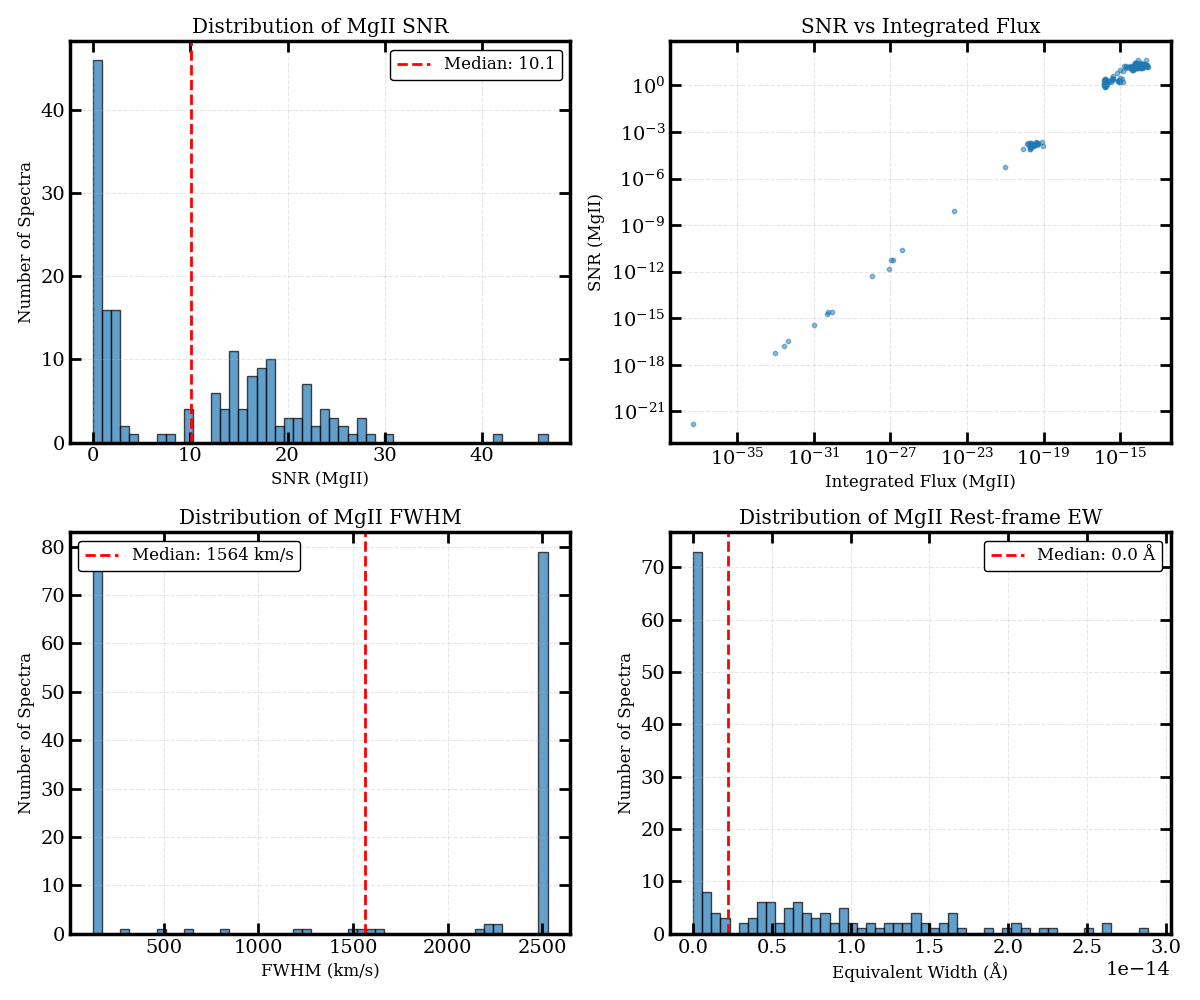

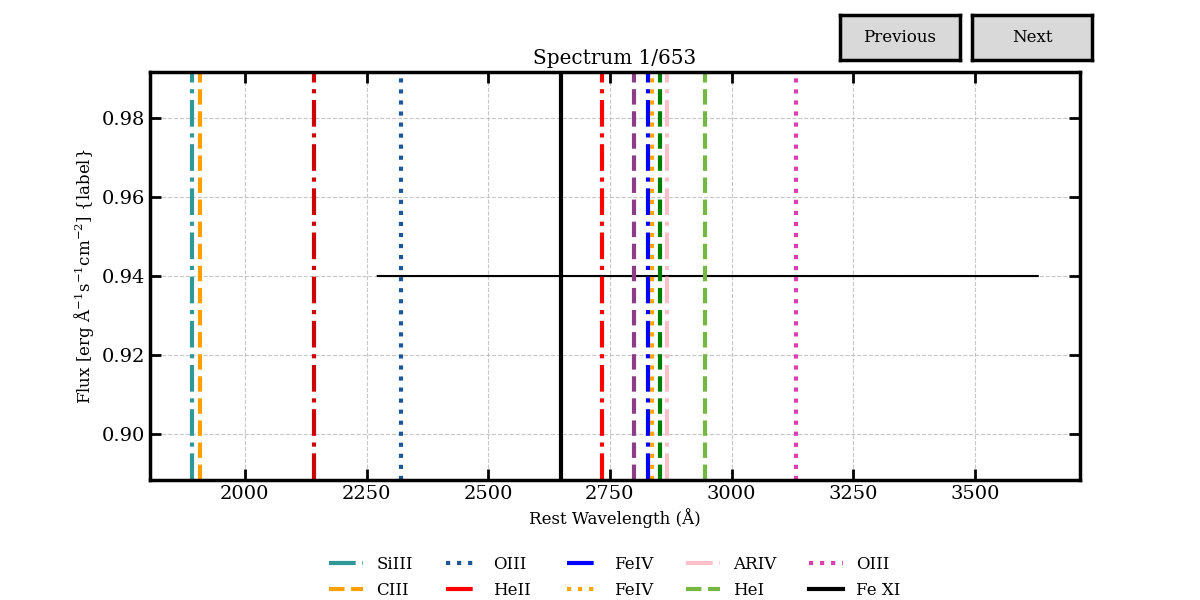


LAUNCHING INTERACTIVE SPECTRUM VIEWER
Controls:
  - Click 'Next' button or press Right Arrow / 'n' for next spectrum
  - Click 'Previous' button or press Left Arrow / 'p' for previous spectrum


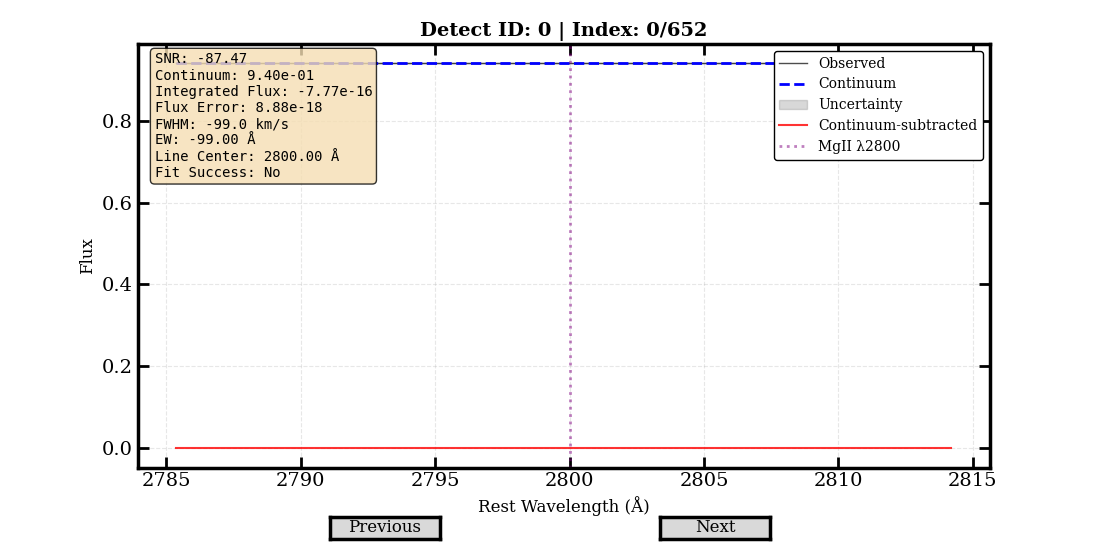


LAUNCHING STACKED SPECTRA VIEWER
Total spectra: 653
Spectra per page: 20
Total pages: 33

Color coding:
  Green  = SNR > 4.5 (strong detection)
  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)
  Red    = SNR ≤ 3.0 (weak/non-detection)

Controls:
  - Click 'Next' button or press Right Arrow / 'n' for next page
  - Click 'Previous' button or press Left Arrow / 'p' for previous page


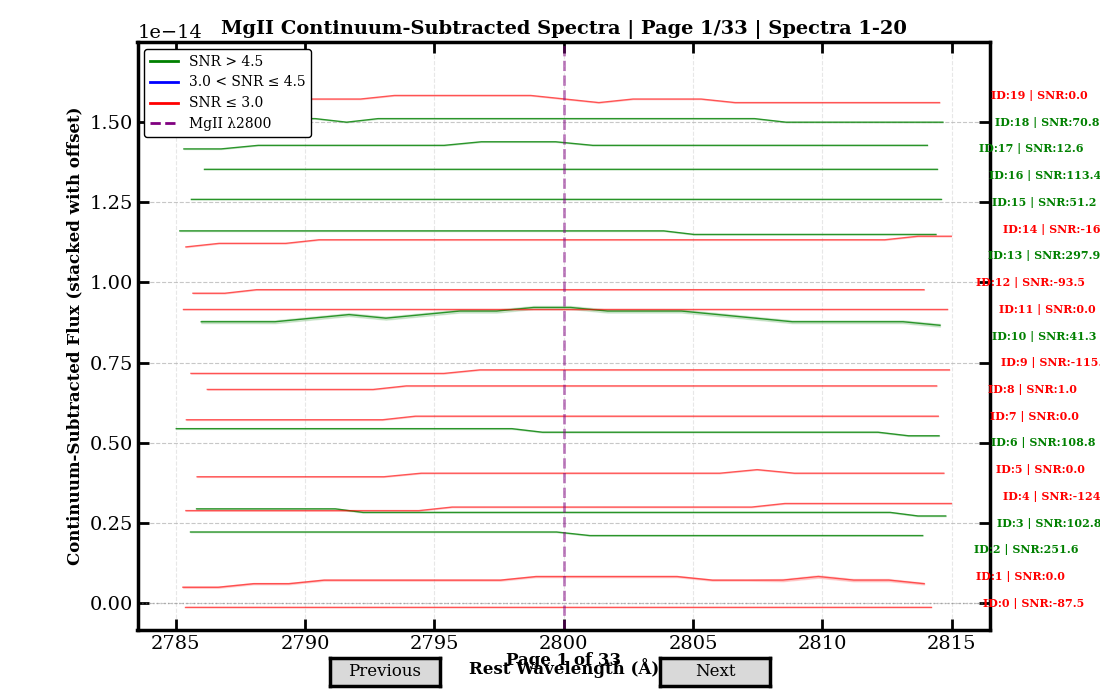


LAUNCHING FULL SPECTRA VIEWER
Total spectra: 653
Spectra per page: 10
Total pages: 66

Color coding:
  Green  = SNR > 4.5 (strong detection)
  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)
  Red    = SNR ≤ 3.0 (weak/non-detection)
  Orange = MgII region highlighted (2785-2815 Å)

Controls:
  - Click 'Next' button or press Right Arrow / 'n' for next page
  - Click 'Previous' button or press Left Arrow / 'p' for previous page


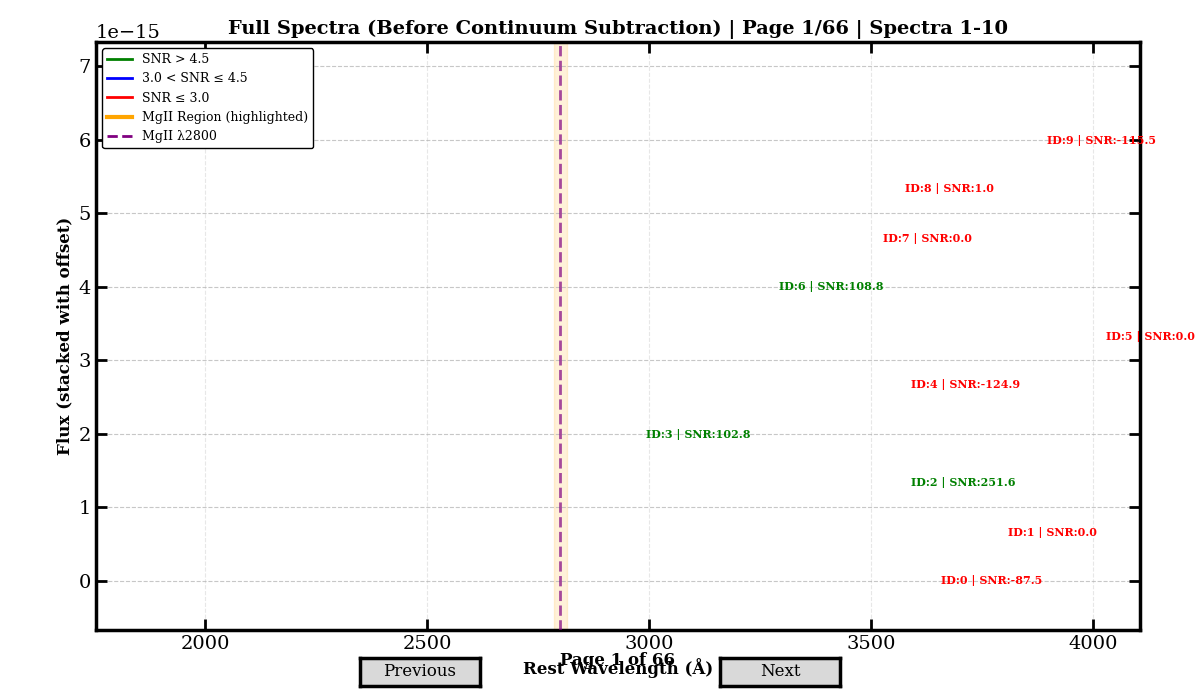

In [42]:
"""
Getting the S/N for the MgII emission lines.

New_Y_For_NonStacked_Array: The flux arrays for the shifted individual spectra.
New_Y_StdDev_For_NonStacked_Array: The flux Error arrays for the shifted individual spectra.
Rest_Wavelengths_Array: The rest wavelength arrays for the spectra (array of arrays).

Goals: I want to be able to get the height of the MgII and the size of the continuum.

Take the MgII wavelength and find the max at that point.
"""

import numpy as np
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import extract_region
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from scipy.optimize import curve_fit
import warnings
from tqdm import tqdm

# ============================================================================
# Batch Processing for ~2000 MgII Lines (Liu+ 2022 Method)
# ============================================================================

def gaussian(x, amp, mean, sigma):
    """Gaussian function for line fitting"""
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

def fit_continuum(wave, flux, line_center, window=50):
    """
    Fit a simple continuum around the line
    Excludes the line region itself
    """
    # Define regions on either side of the line for continuum fitting
    # Use narrower windows closer to the line
    left_mask = (wave > line_center - window - 20) & (wave < line_center - window)
    right_mask = (wave > line_center + window) & (wave < line_center + window + 20)
    continuum_mask = left_mask | right_mask
    
    if np.sum(continuum_mask) > 5:
        # Fit a linear continuum
        coeffs = np.polyfit(wave[continuum_mask], flux[continuum_mask], 1)
        continuum = np.polyval(coeffs, wave)
    else:
        # If not enough points, use median of edges
        edge_mask = (wave < line_center - window) | (wave > line_center + window)
        if np.sum(edge_mask) > 0:
            continuum = np.median(flux[edge_mask]) * np.ones_like(flux)
        else:
            continuum = np.median(flux) * np.ones_like(flux)
    
    return continuum

def calculate_mgii_snr(wave, flux, uncertainty, mgii_center=2800.0):
    """
    Calculate MgII SNR following Liu+ 2022 methodology
    
    Parameters
    ----------
    wave : array
        Wavelength array in Angstroms (rest-frame)
    flux : array
        Flux array
    uncertainty : array
        Uncertainty/error array
    mgii_center : float
        Central wavelength for MgII (default 2800 Å)
    
    Returns
    -------
    dict : Dictionary containing all line measurements
    """
    
    # Fit and subtract continuum
    continuum = fit_continuum(wave, flux, mgii_center, window=10)
    flux_cont_sub = flux - continuum
    
    # Fit a Gaussian to the continuum-subtracted line
    amp_guess = np.max(flux_cont_sub)
    mean_guess = wave[np.argmax(flux_cont_sub)]
    sigma_guess = 2.0
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                gaussian, wave, flux_cont_sub, 
                p0=[amp_guess, mean_guess, sigma_guess],
                sigma=uncertainty,
                bounds=([0, 2790, 0.5], [np.inf, 2810, 10]),
                maxfev=5000
            )
        
        amp_fit, mean_fit, sigma_fit = popt
        amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))
        
        # Calculate integrated flux
        integrated_flux = amp_fit * sigma_fit * np.sqrt(2 * np.pi)
        integrated_flux_err = integrated_flux * np.sqrt(
            (amp_err/amp_fit)**2 + (sigma_err/sigma_fit)**2
        )
        
        # SNR (Liu+ 2022 method)
        snr_mgii = integrated_flux / integrated_flux_err
        
        # FWHM in km/s
        fwhm_angstrom = 2.355 * sigma_fit
        fwhm_kms = (fwhm_angstrom / mean_fit) * 3e5
        
        # Equivalent width
        continuum_at_line = np.polyval(np.polyfit(wave, continuum, 1), mean_fit)
        ew_rest = integrated_flux / continuum_at_line if continuum_at_line > 0 else -99.0
        
        return {
            'snr_MgII': snr_mgii,
            'flux_MgII': integrated_flux,
            'flux_MgII_err': integrated_flux_err,
            'fwhm_MgII': fwhm_kms,
            'ew_MgII': ew_rest,
            'line_center': mean_fit,
            'line_center_err': mean_err,
            'fit_success': True
        }
        
    except Exception as e:
        # Fallback: simple aperture method
        line_mask = (wave > mgii_center - 5) & (wave < mgii_center + 5)
        integrated_flux = np.sum(flux_cont_sub[line_mask])
        integrated_uncertainty = np.sqrt(np.sum(uncertainty[line_mask]**2))
        snr_mgii = integrated_flux / integrated_uncertainty if integrated_uncertainty > 0 else -99.0
        
        return {
            'snr_MgII': snr_mgii,
            'flux_MgII': integrated_flux,
            'flux_MgII_err': integrated_uncertainty,
            'fwhm_MgII': -99.0,
            'ew_MgII': -99.0,
            'line_center': mgii_center,
            'line_center_err': -99.0,
            'fit_success': False
        }

# ============================================================================
# MAIN PROCESSING LOOP (with caching to avoid re-running)
# ============================================================================

import os

# SET THIS TO True TO FORCE RERUN, False TO USE CACHED RESULTS
FORCE_RERUN = False

output_file = 'Table_1Notebook_MgII_SNR_Results.fits'

# Check if results already exist
if os.path.exists(output_file) and not FORCE_RERUN:
    print(f"Loading cached results from '{output_file}'...")
    with fits.open(output_file) as hdul:
        data = hdul[1].data
        MgII_Results_SNR = {
            'snr_MgII': data['snr_MgII'],
            'flux_MgII': data['flux_MgII'],
            'flux_MgII_err': data['flux_MgII_err'],
            'fwhm_MgII': data['fwhm_MgII'],
            'ew_MgII': data['ew_MgII'],
            'line_center': data['line_center'],
            'line_center_err': data['line_center_err'],
            'fit_success': data['fit_success'].astype(bool)
        }
    n_spectra = len(MgII_Results_SNR['snr_MgII'])
    print(f"Loaded results for {n_spectra} spectra")
    
else:
    print(f"No cached results found. Running analysis...")
    
    # Convert to numpy arrays if they're lists
    if isinstance(New_Y_For_NonStacked_Array, list):
        New_Y_For_NonStacked_Array = np.array(New_Y_For_NonStacked_Array, dtype=object)
    if isinstance(New_Y_StdDev_For_NonStacked_Array, list):
        New_Y_StdDev_For_NonStacked_Array = np.array(New_Y_StdDev_For_NonStacked_Array, dtype=object)
    if isinstance(Rest_Wavelengths_Array, list):
        Rest_Wavelengths_Array = np.array(Rest_Wavelengths_Array, dtype=object)

    n_spectra = len(New_Y_For_NonStacked_Array)
    print(f"Processing {n_spectra} spectra...")

    # Initialize results arrays
    MgII_Results_SNR = {
        'snr_MgII': np.zeros(n_spectra),
        'flux_MgII': np.zeros(n_spectra),
        'flux_MgII_err': np.zeros(n_spectra),
        'fwhm_MgII': np.zeros(n_spectra),
        'ew_MgII': np.zeros(n_spectra),
        'line_center': np.zeros(n_spectra),
        'line_center_err': np.zeros(n_spectra),
        'fit_success': np.zeros(n_spectra, dtype=bool)
    }

    # Define MgII region once
    mgii_region = SpectralRegion(2785 * u.Angstrom, 2815 * u.Angstrom)
    
    # Process each spectrum
# Replace the processing loop section (around line 180-250) with this fixed version:

# Process each spectrum
for i in tqdm(range(n_spectra), desc="Fitting MgII lines"):
    
    try:
        # Get wavelength array for this spectrum - convert from object array to float
        wave_single = np.asarray(Rest_Wavelengths_Array[i], dtype=np.float64)
        mgii_mask = (wave_single >= 2785) & (wave_single <= 2815)
        wave = wave_single[mgii_mask]
        
        # Handle both array and list indexing - FORCE CONVERSION TO FLOAT
        # Use asarray instead of array to handle object dtype properly
        flux_full = np.asarray(New_Y_For_NonStacked_Array[i], dtype=np.float64)
        uncertainty_full = np.asarray(New_Y_StdDev_For_NonStacked_Array[i], dtype=np.float64)
        
        flux = flux_full[mgii_mask]
        uncertainty = uncertainty_full[mgii_mask]
        
        # Skip if insufficient data points
        if len(flux) == 0 or len(wave) == 0:
            MgII_Results_SNR['snr_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII_err'][i] = -99.0
            MgII_Results_SNR['fwhm_MgII'][i] = -99.0
            MgII_Results_SNR['ew_MgII'][i] = -99.0
            MgII_Results_SNR['line_center'][i] = 2800.0
            MgII_Results_SNR['line_center_err'][i] = -99.0
            MgII_Results_SNR['fit_success'][i] = False
            continue
        
        # Skip if all zeros or NaNs (now safe with float dtype)
        if np.all(flux == 0) or np.all(np.isnan(flux)):
            MgII_Results_SNR['snr_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII_err'][i] = -99.0
            MgII_Results_SNR['fwhm_MgII'][i] = -99.0
            MgII_Results_SNR['ew_MgII'][i] = -99.0
            MgII_Results_SNR['line_center'][i] = 2800.0
            MgII_Results_SNR['line_center_err'][i] = -99.0
            MgII_Results_SNR['fit_success'][i] = False
            continue
        
        # Calculate SNR for this spectrum
        result = calculate_mgii_snr(wave, flux, uncertainty)
        
        # Store results
        for key in MgII_Results_SNR.keys():
            MgII_Results_SNR[key][i] = result[key]
    
    except (ValueError, TypeError) as e:
        # Handle any conversion or processing errors
        print(f"\nWarning: Error processing spectrum {i}: {str(e)}")
        MgII_Results_SNR['snr_MgII'][i] = -99.0
        MgII_Results_SNR['flux_MgII'][i] = -99.0
        MgII_Results_SNR['flux_MgII_err'][i] = -99.0
        MgII_Results_SNR['fwhm_MgII'][i] = -99.0
        MgII_Results_SNR['ew_MgII'][i] = -99.0
        MgII_Results_SNR['line_center'][i] = 2800.0
        MgII_Results_SNR['line_center_err'][i] = -99.0
        MgII_Results_SNR['fit_success'][i] = False
        continue
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

valid_fits = MgII_Results_SNR['fit_success']
n_valid = np.sum(valid_fits)
n_failed = n_spectra - n_valid

# Check for unrealistic SNR values
snr_positive = MgII_Results_SNR['snr_MgII'][valid_fits] > 0
n_positive_snr = np.sum(snr_positive)

print("\n" + "="*60)
print("BATCH PROCESSING RESULTS")
print("="*60)
print(f"Total spectra processed: {n_spectra}")
print(f"Successful Gaussian fits: {n_valid} ({100*n_valid/n_spectra:.1f}%)")
print(f"Failed fits (aperture method): {n_failed} ({100*n_failed/n_spectra:.1f}%)")
print(f"Positive SNR values: {n_positive_snr} ({100*n_positive_snr/n_valid:.1f}% of successful fits)")

if n_positive_snr > 0:
    snr_valid = MgII_Results_SNR['snr_MgII'][valid_fits][snr_positive]
    print("\nSNR Statistics (valid fits with positive SNR):")
    print(f"  mean SNR: {np.mean(snr_valid):.2f}")
    print(f"  Median SNR: {np.median(snr_valid):.2f}")
    print(f"  Min SNR: {np.min(snr_valid):.2f}")
    print(f"  Max SNR: {np.max(snr_valid):.2f}")
    print(f"  Std SNR: {np.std(snr_valid):.2f}")
    print("\nSNR Percentiles:")
    print(f"  16th: {np.percentile(snr_valid, 16):.2f}")
    print(f"  50th: {np.percentile(snr_valid, 50):.2f}")
    print(f"  84th: {np.percentile(snr_valid, 84):.2f}")
    print(f"\nSpectra with SNR > 4.5: {np.sum(snr_valid > 4.5)} ({100*np.sum(snr_valid > 4.5)/len(snr_valid):.1f}%)")
else:
    print("\nWARNING: No positive SNR values found! Check your input data.")
print("="*60)

# ============================================================================
# VISUALIZATION: SNR Distribution
# ============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# SNR histogram
ax = axes[0, 0]
ax.hist(MgII_Results_SNR['snr_MgII'][valid_fits], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(MgII_Results_SNR['snr_MgII'][valid_fits]), color='r', 
           linestyle='--', linewidth=2, label=f'Median: {np.median(MgII_Results_SNR["snr_MgII"][valid_fits]):.1f}')
ax.set_xlabel('SNR (MgII)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII SNR')
ax.legend()
ax.grid(True, alpha=0.3)

# Integrated flux vs SNR
ax = axes[0, 1]
ax.scatter(MgII_Results_SNR['flux_MgII'][valid_fits], MgII_Results_SNR['snr_MgII'][valid_fits], 
           alpha=0.5, s=10)
ax.set_xlabel('Integrated Flux (MgII)')
ax.set_ylabel('SNR (MgII)')
ax.set_title('SNR vs Integrated Flux')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# FWHM distribution
ax = axes[1, 0]
fwhm_valid = MgII_Results_SNR['fwhm_MgII'][(valid_fits) & (MgII_Results_SNR['fwhm_MgII'] > 0)]
ax.hist(fwhm_valid, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(fwhm_valid), color='r', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(fwhm_valid):.0f} km/s')
ax.set_xlabel('FWHM (km/s)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII FWHM')
ax.legend()
ax.grid(True, alpha=0.3)

# EW distribution
ax = axes[1, 1]
ew_valid = MgII_Results_SNR['ew_MgII'][(valid_fits) & (MgII_Results_SNR['ew_MgII'] > 0) & (MgII_Results_SNR['ew_MgII'] < 100)]
ax.hist(ew_valid, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(ew_valid), color='r', linestyle='--', linewidth=2,
           label=f'Median: {np.median(ew_valid):.1f} Å')
ax.set_xlabel('Equivalent Width (Å)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII Rest-frame EW')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mgii_snr_analysis.png', dpi=150)
print("Summary plot saved to 'mgii_snr_analysis.png'")
plt.show()

# ============================================================================
# INTERACTIVE FULL SPECTRUM PLOTTER (Direct from New_Y_For_NonStacked_Array)
# ============================================================================

# Define spectral lines
spectral_lines = {
        1892.030: ('#309898', '-.', 'SiIII', 3),
        1908.734: ('#FF9F00', '--', 'CIII', 3),
        2142.780: ('#CB0404', '-.', 'NII', 3),
        2320.951: ('#1D5799', ':', 'OIII', 3),
        2733.289: ('red', '-.', 'HeII', 3),
        2799.000: ('#8B3D88', '--', 'MgII', 3),
        2829.360: ('blue', '-.' ,'FeIV', 3),
        2835.740: ('orange', ':' ,'FeIV', 3),
        2853.670: ('green', '--' ,'ArIV', 3),
        2868.210: ('pink', '-.' ,'ARIV', 3),
        2945.106: ('#74B741', '--', 'HeI', 3),
        3132.794: ('#DB3EB1', ':', 'OIII', 3),
        2648.710: ('black', '-', 'Fe XI', 3)
    } #Rest Wavelength, color, linestyle, label, linewidth


Plots_For_Interactive_Plotting = []   
# Sample plot data - in real use case, this would be your spectral data
for j in np.arange(len(New_Y_For_NonStacked_Array)):
    wave_spec_interactive = np.array(Rest_Wavelengths_Array[j],  dtype=np.float64)
    Rest_Flux_Density_Array_interactive = np.array(New_Y_For_NonStacked_Array[j],  dtype=np.float64)
    Rest_Flux_Density_Err_Array_interactive = np.array(New_Y_StdDev_For_NonStacked_Array[j],  dtype=np.float64)
    names_interactive = Detect_ID_Names[i]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive, Rest_Flux_Density_Array_interactive, Rest_Flux_Density_Err_Array_interactive, names_interactive])
    
plotter = InteractivePlotter_a(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()

# ============================================================================
# INTERACTIVE SPECTRUM VIEWER (MgII REGION)
# ============================================================================

class SpectrumViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.current_idx = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(11, 5.5))
        plt.subplots_adjust(bottom=0.15, top=0.92)
        plt.subplots_adjust(bottom=0.15)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_spectrum)
        self.btn_next.on_clicked(self.next_spectrum)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first spectrum
        self.plot_spectrum()
        
    def plot_spectrum(self):
        self.ax.clear()
        i = self.current_idx
        
        # Get data for this spectrum
        wave_full = np.array(self.wave_rest[i])
        flux_full = np.array(self.flux_array[i])
        uncertainty_full = np.array(self.uncertainty_array[i])
        
        # Get MgII region
        mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
        wave = wave_full[mgii_mask]
        flux = flux_full[mgii_mask]
        uncertainty = uncertainty_full[mgii_mask]
        
        # Fit continuum
        continuum = fit_continuum(wave, flux, 2800.0, window=10)
        flux_cont_sub = flux - continuum
        
        # Plot spectrum
        self.ax.plot(wave, flux, 'k-', linewidth=1, label='Observed', alpha=0.7)
        self.ax.plot(wave, continuum, 'b--', linewidth=2, label='Continuum')
        self.ax.fill_between(wave, flux - uncertainty, flux + uncertainty, 
                             alpha=0.3, color='gray', label='Uncertainty')
        
        # Plot continuum-subtracted
        self.ax.plot(wave, flux_cont_sub, 'r-', linewidth=1.5, label='Continuum-subtracted', alpha=0.8)
        
        # If fit succeeded, plot Gaussian fit
        if self.results['fit_success'][i]:
            amp = self.results['flux_MgII'][i] / (self.results['line_center'][i] * np.sqrt(2 * np.pi) / 2800.0 * 2.355)
            mean = self.results['line_center'][i]
            # Estimate sigma from FWHM
            fwhm_ang = self.results['fwhm_MgII'][i] / 3e5 * mean
            sigma = fwhm_ang / 2.355
            
            gaussian_fit = gaussian(wave, amp, mean, sigma)
            self.ax.plot(wave, gaussian_fit, 'g-', linewidth=2, label='Gaussian Fit', alpha=0.8)
        
        # Mark MgII line
        self.ax.axvline(2800.0, color='purple', linestyle=':', linewidth=2, alpha=0.5, label='MgII λ2800')
        
        # Add text box with measurements
        continuum_level = np.median(continuum)
        textstr = f"SNR: {self.results['snr_MgII'][i]:.2f}\n"
        textstr += f"Continuum: {continuum_level:.2e}\n"
        textstr += f"Integrated Flux: {self.results['flux_MgII'][i]:.2e}\n"
        textstr += f"Flux Error: {self.results['flux_MgII_err'][i]:.2e}\n"
        textstr += f"FWHM: {self.results['fwhm_MgII'][i]:.1f} km/s\n"
        textstr += f"EW: {self.results['ew_MgII'][i]:.2f} Å\n"
        textstr += f"Line Center: {self.results['line_center'][i]:.2f} Å\n"
        textstr += f"Fit Success: {'Yes' if self.results['fit_success'][i] else 'No'}"
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        self.ax.text(0.02, 0.98, textstr, transform=self.ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=props, family='monospace')
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12)
        self.ax.set_ylabel('Flux', fontsize=12)
        self.ax.set_title(f'Detect ID: {self.detect_ids[i]} | Index: {i}/{self.n_spectra-1}', 
                         fontsize=14, fontweight='bold')
        self.ax.legend(loc='upper right', fontsize=10)
        self.ax.grid(True, alpha=0.3)
        
        plt.draw()
        
    def next_spectrum(self, event):
        self.current_idx = (self.current_idx + 1) % self.n_spectra
        self.plot_spectrum()
        
    def prev_spectrum(self, event):
        self.current_idx = (self.current_idx - 1) % self.n_spectra
        self.plot_spectrum()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_spectrum(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_spectrum(None)

# Launch the interactive viewer
print("\n" + "="*60)
print("LAUNCHING INTERACTIVE SPECTRUM VIEWER")
print("="*60)
print("Controls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next spectrum")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous spectrum")
print("="*60)

viewer = SpectrumViewer(MgII_Results_SNR, np.array(Rest_Wavelengths_Array, dtype=np.float64), np.array(New_Y_For_NonStacked_Array, dtype=np.float64), 
                        np.array(New_Y_StdDev_For_NonStacked_Array, dtype=np.float64))
plt.show()

# ============================================================================
# STACKED CONTINUUM-SUBTRACTED VIEWER
# ============================================================================

class StackedSpectraViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None, spectra_per_page=20):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.spectra_per_page = spectra_per_page
        self.n_pages = int(np.ceil(self.n_spectra / spectra_per_page))
        self.current_page = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(11, 7))
        plt.subplots_adjust(bottom=0.10, top=0.94)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_page)
        self.btn_next.on_clicked(self.next_page)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first page
        self.plot_page()
        
    def plot_page(self):
        self.ax.clear()
        
        # Calculate spectrum indices for this page
        start_idx = self.current_page * self.spectra_per_page
        end_idx = min(start_idx + self.spectra_per_page, self.n_spectra)
        
        # Calculate vertical offset for stacking
        offset_step = 0.0
        max_flux_range = 0
        
        # First pass: find the max flux range for scaling
        for i in range(start_idx, end_idx):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            
            mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
            wave = wave_full[mgii_mask]
            flux = flux_full[mgii_mask]
            
            continuum = fit_continuum(wave, flux, 2800.0, window=10)
            flux_cont_sub = flux - continuum
            
            flux_range = np.max(flux_cont_sub) - np.min(flux_cont_sub)
            if flux_range > max_flux_range:
                max_flux_range = flux_range
        
        # Set offset to be 1.5x the max range for good separation
        offset_step = max_flux_range * 1.5
        
        # Plot each spectrum with offset
        for idx, i in enumerate(range(start_idx, end_idx)):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            uncertainty_full = np.array(self.uncertainty_array[i])
            
            mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
            wave = wave_full[mgii_mask]
            flux = flux_full[mgii_mask]
            uncertainty = uncertainty_full[mgii_mask]
            
            # Fit and subtract continuum
            continuum = fit_continuum(wave, flux, 2800.0, window=10)
            flux_cont_sub = flux - continuum
            
            # Apply vertical offset
            offset = idx * offset_step
            
            # Determine color based on SNR
            snr = self.results['snr_MgII'][i]
            if snr > 4.5:
                color = 'green'
                alpha = 0.8
            elif snr > 3.0:
                color = 'blue'
                alpha = 0.7
            else:
                color = 'red'
                alpha = 0.6
            
            # Plot continuum-subtracted spectrum
            self.ax.plot(wave, flux_cont_sub + offset, color=color, 
                        linewidth=1, alpha=alpha)
            
            # Add uncertainty as light shading
            self.ax.fill_between(wave, 
                                flux_cont_sub - uncertainty + offset,
                                flux_cont_sub + uncertainty + offset,
                                alpha=0.15, color=color)
            
            # Add label on the right side
            label_x = wave[-1] + 2
            label_y = offset
            label_text = f"ID:{self.detect_ids[i]} | SNR:{snr:.1f}"
            self.ax.text(label_x, label_y, label_text, fontsize=8, 
                        verticalalignment='center', color=color, fontweight='bold')
        
        # Mark MgII line
        y_min = -offset_step
        y_max = (end_idx - start_idx) * offset_step + offset_step
        self.ax.axvline(2800.0, color='purple', linestyle='--', linewidth=2, 
                       alpha=0.5, label='MgII λ2800')
        
        # Add zero line for reference on first spectrum
        self.ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, fontweight='bold')
        self.ax.set_ylabel('Continuum-Subtracted Flux (stacked with offset)', fontsize=12, fontweight='bold')
        self.ax.set_title(f'MgII Continuum-Subtracted Spectra | Page {self.current_page + 1}/{self.n_pages} | Spectra {start_idx+1}-{end_idx}', 
                         fontsize=14, fontweight='bold')
        
        # Add legend for colors
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='green', lw=2, label='SNR > 4.5'),
            Line2D([0], [0], color='blue', lw=2, label='3.0 < SNR ≤ 4.5'),
            Line2D([0], [0], color='red', lw=2, label='SNR ≤ 3.0'),
            Line2D([0], [0], color='purple', linestyle='--', lw=2, label='MgII λ2800')
        ]
        self.ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        self.ax.set_ylim(y_min, y_max)
        self.ax.grid(True, alpha=0.3, axis='x')
        
        # Add page info text
        page_info = f"Page {self.current_page + 1} of {self.n_pages}"
        self.ax.text(0.5, -0.06, page_info, transform=self.ax.transAxes, 
                    fontsize=12, ha='center', fontweight='bold')
        
        plt.draw()
        
    def next_page(self, event):
        self.current_page = (self.current_page + 1) % self.n_pages
        self.plot_page()
        
    def prev_page(self, event):
        self.current_page = (self.current_page - 1) % self.n_pages
        self.plot_page()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_page(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_page(None)

# Launch the stacked viewer
print("\n" + "="*60)
print("LAUNCHING STACKED SPECTRA VIEWER")
print("="*60)
print(f"Total spectra: {len(MgII_Results_SNR['snr_MgII'])}")
print(f"Spectra per page: 20")
print(f"Total pages: {int(np.ceil(len(MgII_Results_SNR['snr_MgII']) / 20))}")
print("\nColor coding:")
print("  Green  = SNR > 4.5 (strong detection)")
print("  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)")
print("  Red    = SNR ≤ 3.0 (weak/non-detection)")
print("\nControls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next page")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous page")
print("="*60)

stacked_viewer = StackedSpectraViewer(MgII_Results_SNR, Rest_Wavelengths_Array, 
                                      New_Y_For_NonStacked_Array, 
                                      New_Y_StdDev_For_NonStacked_Array,
                                      spectra_per_page=20)
plt.show()

# ============================================================================
# FULL SPECTRA VIEWER
# ============================================================================

class FullSpectraViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None, spectra_per_page=10):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.spectra_per_page = spectra_per_page
        self.n_pages = int(np.ceil(self.n_spectra / spectra_per_page))
        self.current_page = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(12, 7))
        plt.subplots_adjust(bottom=0.10, top=0.94, left=0.08, right=0.95)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_page)
        self.btn_next.on_clicked(self.next_page)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first page
        self.plot_page()
        
    def plot_page(self):
        self.ax.clear()
        
        # Calculate spectrum indices for this page
        start_idx = self.current_page * self.spectra_per_page
        end_idx = min(start_idx + self.spectra_per_page, self.n_spectra)
        
        # Calculate vertical offset for stacking
        offset_step = 0.0
        max_flux_range = 0
        
        # First pass: find the max flux range for scaling
        for i in range(start_idx, end_idx):
            flux_full = np.array(self.flux_array[i])
            flux_range = np.max(flux_full) - np.min(flux_full)
            if flux_range > max_flux_range:
                max_flux_range = flux_range
        
        # Set offset to be 1.5x the max range for good separation
        offset_step = max_flux_range * 1.5
        
        # Plot each spectrum with offset
        for idx, i in enumerate(range(start_idx, end_idx)):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            uncertainty_full = np.array(self.uncertainty_array[i])
            
            # Apply vertical offset
            offset = idx * offset_step
            
            # Determine color based on SNR
            snr = self.results['snr_MgII'][i]
            if snr > 4.5:
                color = 'green'
                alpha = 0.8
            elif snr > 3.0:
                color = 'blue'
                alpha = 0.7
            else:
                color = 'red'
                alpha = 0.6
            
            # Plot full spectrum
            self.ax.plot(wave_full, flux_full + offset, color=color, 
                        linewidth=1, alpha=alpha)
            
            # Add uncertainty as light shading
            self.ax.fill_between(wave_full, 
                                flux_full - uncertainty_full + offset,
                                flux_full + uncertainty_full + offset,
                                alpha=0.1, color=color)
            
            # Highlight MgII region with thicker line and shading
            mgii_region = (wave_full >= 2785) & (wave_full <= 2815)
            self.ax.plot(wave_full[mgii_region], 
                        flux_full[mgii_region] + offset, 
                        color='orange', linewidth=3, alpha=0.9, zorder=10)
            
            # Add label on the right side
            label_x = wave_full[-1] + (wave_full[-1] - wave_full[0]) * 0.02
            label_y = offset
            label_text = f"ID:{self.detect_ids[i]} | SNR:{snr:.1f}"
            self.ax.text(label_x, label_y, label_text, fontsize=8, 
                        verticalalignment='center', color=color, fontweight='bold')
        
        # Mark MgII line center
        y_min = -offset_step
        y_max = (end_idx - start_idx) * offset_step + offset_step
        self.ax.axvline(2800.0, color='purple', linestyle='--', linewidth=2, 
                       alpha=0.7, label='MgII λ2800', zorder=5)
        
        # Add shaded region for MgII
        self.ax.axvspan(2785, 2815, alpha=0.15, color='orange', 
                       label='MgII Region (2785-2815 Å)', zorder=0)
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, fontweight='bold')
        self.ax.set_ylabel('Flux (stacked with offset)', fontsize=12, fontweight='bold')
        self.ax.set_title(f'Full Spectra (Before Continuum Subtraction) | Page {self.current_page + 1}/{self.n_pages} | Spectra {start_idx+1}-{end_idx}', 
                         fontsize=14, fontweight='bold')
        
        # Add legend for colors
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='green', lw=2, label='SNR > 4.5'),
            Line2D([0], [0], color='blue', lw=2, label='3.0 < SNR ≤ 4.5'),
            Line2D([0], [0], color='red', lw=2, label='SNR ≤ 3.0'),
            Line2D([0], [0], color='orange', lw=3, label='MgII Region (highlighted)'),
            Line2D([0], [0], color='purple', linestyle='--', lw=2, label='MgII λ2800')
        ]
        self.ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
        
        self.ax.set_ylim(y_min, y_max)
        self.ax.grid(True, alpha=0.3, axis='x')
        
        # Add page info text
        page_info = f"Page {self.current_page + 1} of {self.n_pages}"
        self.ax.text(0.5, -0.06, page_info, transform=self.ax.transAxes, 
                    fontsize=12, ha='center', fontweight='bold')
        
        plt.draw()
        
    def next_page(self, event):
        self.current_page = (self.current_page + 1) % self.n_pages
        self.plot_page()
        
    def prev_page(self, event):
        self.current_page = (self.current_page - 1) % self.n_pages
        self.plot_page()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_page(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_page(None)

# Launch the full spectra viewer
print("\n" + "="*60)
print("LAUNCHING FULL SPECTRA VIEWER")
print("="*60)
print(f"Total spectra: {len(MgII_Results_SNR['snr_MgII'])}")
print(f"Spectra per page: 10")
print(f"Total pages: {int(np.ceil(len(MgII_Results_SNR['snr_MgII']) / 10))}")
print("\nColor coding:")
print("  Green  = SNR > 4.5 (strong detection)")
print("  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)")
print("  Red    = SNR ≤ 3.0 (weak/non-detection)")
print("  Orange = MgII region highlighted (2785-2815 Å)")
print("\nControls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next page")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous page")
print("="*60)

full_viewer = FullSpectraViewer(MgII_Results_SNR, Rest_Wavelengths_Array, 
                                New_Y_For_NonStacked_Array, 
                                New_Y_StdDev_For_NonStacked_Array,
                                spectra_per_page=10)
plt.show()




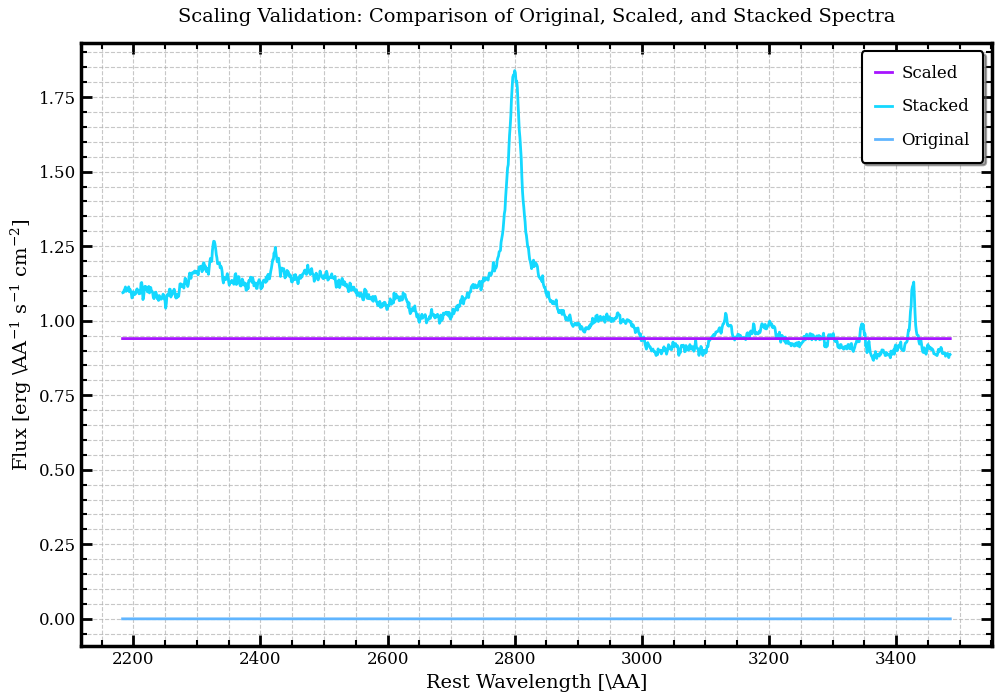

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Checking to make sure the scaling (New_Y_For_NonStacked_Array) worked.
num = 26

# Create figure with MNRAS-compliant dimensions and styling
fig, ax = plt.subplots(1, 1, figsize=(10, 7), facecolor='white')

# Color scheme from the first code (using complementary colors)
colors = {
    'scaled': "#a714ff",    # Purple (deep/cool)
    'stacked': "#14D8FF",   # Teal
    'original': "#60B5FF"   # Blue
}

# Plot the three spectra with MNRAS styling
scaled_line = ax.plot(Rest_Wavelengths_Array[num], New_Y_For_NonStacked_Array[num], 
                     color=colors['scaled'], linewidth=2.0, 
                     label="Scaled", zorder=5)

stacked_line = ax.plot(Ref_Stack_Wave[Index_to_Normalize_Array[num]], Ref_Stack_Flux[Index_to_Normalize_Array[num]], 
                      color=colors['stacked'], linewidth=2.0, 
                      label="Stacked", zorder=4)

original_line = ax.plot(Rest_Wavelengths_Array[num], Rest_Flux_Density_Array[num], 
                       color=colors['original'], linewidth=2.0, 
                       label="Original", zorder=3)

# Configure axes labels and title
ax.set_xlabel(r"Rest Wavelength [\AA]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg \AA$^{-1}$ s$^{-1}$ cm$^{-2}$]", fontsize=14, color="black")
ax.set_title("Scaling Validation: Comparison of Original, Scaled, and Stacked Spectra", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Scaling_Validation_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Scaling_Validation_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [44]:
Rest_Wavelengths_Array
New_Y_For_NonStacked_Array
New_Y_StdDev_For_NonStacked_Array

array([[5.59748328e-17, 5.59539359e-17, 5.59328847e-17, ...,
        1.96007360e-17, 1.96017913e-17, 1.96028350e-17],
       [2.89348048e-16, 2.89354675e-16, 2.89361078e-16, ...,
        5.26562593e-17, 5.26564658e-17, 5.26566697e-17],
       [6.84103785e-17, 6.84025758e-17, 6.83946203e-17, ...,
        2.00354946e-17, 2.00364358e-17, 2.00373671e-17],
       ...,
       [7.55303607e-17, 7.55390612e-17, 7.55475957e-17, ...,
        2.75253539e-17, 2.75260928e-17, 2.75268238e-17],
       [8.36002350e-17, 8.35971878e-17, 8.35940472e-17, ...,
        3.77476385e-17, 3.77472883e-17, 3.77469410e-17],
       [7.64261623e-17, 7.63973466e-17, 7.63684466e-17, ...,
        3.22705463e-17, 3.22716040e-17, 3.22726502e-17]])

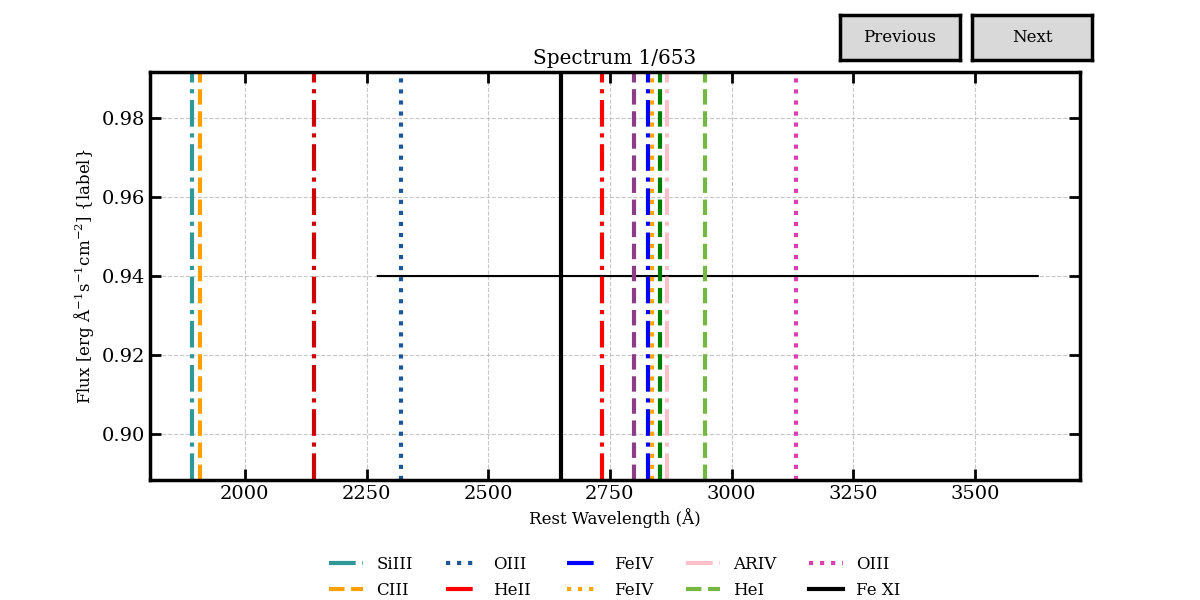

In [45]:
# Define spectral lines
spectral_lines = {
        1892.030: ('#309898', '-.', 'SiIII', 3),
        1908.734: ('#FF9F00', '--', 'CIII', 3),
        2142.780: ('#CB0404', '-.', 'NII', 3),
        2320.951: ('#1D5799', ':', 'OIII', 3),
        2733.289: ('red', '-.', 'HeII', 3),
        2799.000: ('#8B3D88', '--', 'MgII', 3),
        2829.360: ('blue', '-.' ,'FeIV', 3),
        2835.740: ('orange', ':' ,'FeIV', 3),
        2853.670: ('green', '--' ,'ArIV', 3),
        2868.210: ('pink', '-.' ,'ARIV', 3),
        2945.106: ('#74B741', '--', 'HeI', 3),
        3132.794: ('#DB3EB1', ':', 'OIII', 3),
        2648.710: ('black', '-', 'Fe XI', 3)
    } #Rest Wavelength, color, linestyle, label, linewidth


Plots_For_Interactive_Plotting = []   
# Sample plot data - in real use case, this would be your spectral data
for j in np.arange(len(New_Y_For_NonStacked_Array)):
    wave_spec_interactive = Rest_Wavelengths_Array[j]
    Rest_Flux_Density_Array_interactive = New_Y_For_NonStacked_Array[j]
    Rest_Flux_Density_Err_Array_interactive = New_Y_StdDev_For_NonStacked_Array[j]
    names_interactive = Detect_ID_Names[i]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive, Rest_Flux_Density_Array_interactive, Rest_Flux_Density_Err_Array_interactive, names_interactive])
    
# Create and display the interactive plotter
plotter = InteractivePlotter_a(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()




## <font color='#00879E' size=5 >ReStacking the individual spectra. But, with the scaled spectra that now match the old stacked specta</font>

In [46]:
"""
Restacking the now scaled original specta.
New_Y_For_NonStacked_Array = the scaled version of the Rest_Flux_Density_Array
The Rest_Flux_Density_Array_SD doesn't need to be scaled with the Rest_Flux_Density_Array
"""
avg_type = 'biweight' #'weighted_biweight', 'mean', 'median'
ReStacked_Spec_Continuum_Scaled, ReStacked_Spec_SD_Continuum_Scaled, ReStacked_Wave_Continuum_Scaled, ReStacked_Contrib_Count_Continuum_Scaled, ReStack_Spec_SD = ESU.stack_spectra(New_Y_For_NonStacked_Array, New_Y_StdDev_For_NonStacked_Array, Rest_Wavelengths_Array, 
                                                                                                                                                                                    avg_type=avg_type, std=True)



NameError: name 'Ref_Stack_Spec' is not defined

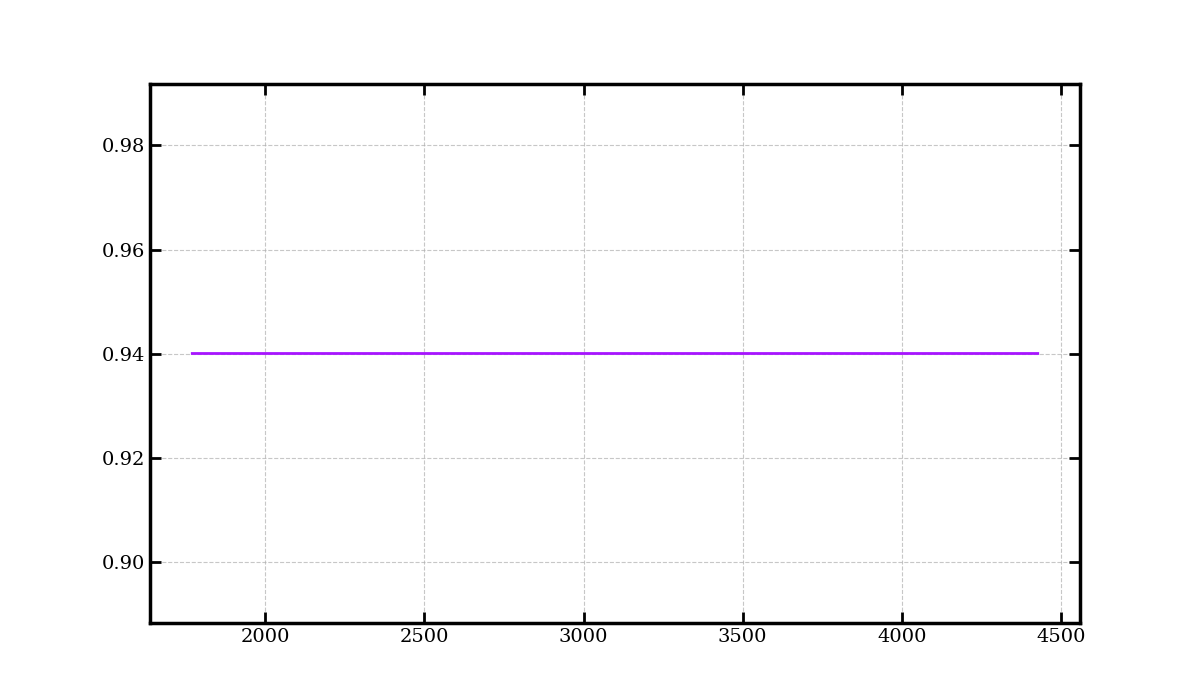

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Checking that restacking of the scaled individual spectra worked.

# Create figure with MNRAS-compliant dimensions and styling
fig, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')

# Color scheme from the first code for spectra
spectrum_colors = {
    'restacked': "#a714ff",    # Purple (deep/cool)
    'original': "#FF5757"      # Red (warm)
}

# Plot the stacked spectra with MNRAS styling
restacked_line = ax.step(ReStacked_Wave_Continuum_Scaled, ReStacked_Spec_Continuum_Scaled, 
                        color=spectrum_colors['restacked'], linewidth=2.0, 
                        label="ReStacked", zorder=5, where='mid')

original_line = ax.step(Ref_Stack_Wave, Ref_Stack_Spec, 
                       color=spectrum_colors['original'], linewidth=2.0, 
                       label="Original Stacked", zorder=4, where='mid')

# Emission line markers with organized colors and improved styling
line_properties = [
    (1892.030, 'limegreen', '-.', r'SiIII'),
    (1908.734, '#ffbb14', '--', r'CIII'),  # Orange from color scheme
    (2799, 'black', '--', r'MgII'),
    (2320.951, '#FF5757', ':', r'OIII'),  # Red from color scheme
    (2142.780, '#00FF9C', '-.', r'NII'),  # Green from color scheme
    (3132.794, '#ff14f5', ':', r'OIII'),  # Pink from color scheme
    (2945.106, '#14D8FF', '--', r'HeI'),   # Teal from color scheme
    (2749.3216, "green", "-", r"FeII A"),
    (2755.7365, "blue", "-", r"FeII B"),
    (2599.3956, "red", "-", r"FeII C"),
    
]

# Add emission line markers
for wavelength, color, linestyle, label in line_properties:
    ax.axvline(x=wavelength, color=color, linestyle=linestyle, 
              linewidth=2.0, alpha=0.8, label=label, zorder=3)

# Configure axes labels and title
ax.set_xlabel(r"Rest Wavelength [\AA]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg \AA$^{-1}$ s$^{-1}$ cm$^{-2}$]", fontsize=14, color="black")
ax.set_title("Restacking Validation: Comparison of Original and ReStacked Spectra", fontsize=14, pad=15)

# Configure legend with MNRAS style - split into two columns for better organization
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.5,
    labelspacing=0.8,
    numpoints=1,
    ncol=2
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Restacking_Validation_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Restacking_Validation_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Takeing the Scaled spectra and dividing them up into the redshift bins</font>

In [48]:
"""
Dividing up the continuum scaled (to match the original stack), New_Y_For_SonStacked_Array, into the redshift bins.
"""
Rest_Flux_Density_Array_Continuum_Scaled_025_035, Rest_Flux_Density_Err_Array_Continuum_Scaled_025_035, Waves_Rest_Continuum_Scaled_025_035 = np.array(New_Y_For_NonStacked_Array)[Z_025_035_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_025_035_Index], np.array(Rest_Wavelengths_Array)[Z_025_035_Index]
Rest_Flux_Density_Array_Continuum_Scaled_035_045, Rest_Flux_Density_Err_Array_Continuum_Scaled_035_045, Waves_Rest_Continuum_Scaled_035_045 = np.array(New_Y_For_NonStacked_Array)[Z_035_045_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_035_045_Index], np.array(Rest_Wavelengths_Array)[Z_035_045_Index]
Rest_Flux_Density_Array_Continuum_Scaled_045_055, Rest_Flux_Density_Err_Array_Continuum_Scaled_045_055, Waves_Rest_Continuum_Scaled_045_055 = np.array(New_Y_For_NonStacked_Array)[Z_045_055_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_045_055_Index], np.array(Rest_Wavelengths_Array)[Z_045_055_Index]
Rest_Flux_Density_Array_Continuum_Scaled_055_065, Rest_Flux_Density_Err_Array_Continuum_Scaled_055_065, Waves_Rest_Continuum_Scaled_055_065 = np.array(New_Y_For_NonStacked_Array)[Z_055_065_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_055_065_Index], np.array(Rest_Wavelengths_Array)[Z_055_065_Index]
Rest_Flux_Density_Array_Continuum_Scaled_065_075, Rest_Flux_Density_Err_Array_Continuum_Scaled_065_075, Waves_Rest_Continuum_Scaled_065_075 = np.array(New_Y_For_NonStacked_Array)[Z_065_075_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_065_075_Index], np.array(Rest_Wavelengths_Array)[Z_065_075_Index]
Rest_Flux_Density_Array_Continuum_Scaled_075_085, Rest_Flux_Density_Err_Array_Continuum_Scaled_075_085, Waves_Rest_Continuum_Scaled_075_085 = np.array(New_Y_For_NonStacked_Array)[Z_075_085_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_075_085_Index], np.array(Rest_Wavelengths_Array)[Z_075_085_Index]
Rest_Flux_Density_Array_Continuum_Scaled_085_096, Rest_Flux_Density_Err_Array_Continuum_Scaled_085_096, Waves_Rest_Continuum_Scaled_085_096 = np.array(New_Y_For_NonStacked_Array)[Z_085_096_Index], np.array(New_Y_StdDev_For_NonStacked_Array)[Z_085_096_Index], np.array(Rest_Wavelengths_Array)[Z_085_096_Index]


In [49]:
"""
Stacking the continuum scaled individual spectra into the seven different redshift bins.
"""
avg_type = 'biweight' #'weighted_biweight', 'mean', 'median'


ReStacked_Spec_Continuum_Scaled_025_035, ReStacked_Spec_SD_Continuum_Scaled_025_035, ReStacked_Wave_Continuum_Scaled_025_035, ReStacked_Contrib_Count_Continuum_Scaled_025_035 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_025_035, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_025_035, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_025_035, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_035_045, ReStacked_Spec_SD_Continuum_Scaled_035_045, ReStacked_Wave_Continuum_Scaled_035_045, ReStacked_Contrib_Count_Continuum_Scaled_035_045 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_035_045, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_035_045, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_035_045, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_045_055, ReStacked_Spec_SD_Continuum_Scaled_045_055, ReStacked_Wave_Continuum_Scaled_045_055, ReStacked_Contrib_Count_Continuum_Scaled_045_055 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_045_055, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_045_055, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_045_055, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_055_065, ReStacked_Spec_SD_Continuum_Scaled_055_065, ReStacked_Wave_Continuum_Scaled_055_065, ReStacked_Contrib_Count_Continuum_Scaled_055_065 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_055_065, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_055_065, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_055_065, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_065_075, ReStacked_Spec_SD_Continuum_Scaled_065_075, ReStacked_Wave_Continuum_Scaled_065_075, ReStacked_Contrib_Count_Continuum_Scaled_065_075 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_065_075, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_065_075, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_065_075, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_075_085, ReStacked_Spec_SD_Continuum_Scaled_075_085, ReStacked_Wave_Continuum_Scaled_075_085, ReStacked_Contrib_Count_Continuum_Scaled_075_085 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_075_085, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_075_085, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_075_085, avg_type=avg_type)

ReStacked_Spec_Continuum_Scaled_085_096, ReStacked_Spec_SD_Continuum_Scaled_085_096, ReStacked_Wave_Continuum_Scaled_085_096, ReStacked_Contrib_Count_Continuum_Scaled_085_096 = ESU.stack_spectra(Rest_Flux_Density_Array_Continuum_Scaled_085_096, 
                                                                                                                                                                                                    Rest_Flux_Density_Err_Array_Continuum_Scaled_085_096, 
                                                                                                                                                                                                    Waves_Rest_Continuum_Scaled_085_096, avg_type=avg_type)


In [50]:
Rest_Flux_Density_Array_Continuum_Scaled_025_035
Rest_Flux_Density_Err_Array_Continuum_Scaled_025_035
Waves_Rest_Continuum_Scaled_025_035



array([[2661.84679623, 2663.38095464, 2664.91511308, ..., 4246.64299404,
        4248.17716868, 4249.71134333],
       [2686.34111823, 2687.88939397, 2689.43766975, ..., 4285.72061529,
        4287.26890742, 4288.81719955],
       [2581.85675564, 2583.3448117 , 2584.83286779, ..., 4119.02890823,
        4120.51698004, 4122.00505185],
       ...,
       [2579.93773025, 2581.42468028, 2582.91163034, ..., 4115.96734371,
        4117.45430947, 4118.94127524],
       [2579.93771955, 2581.42466958, 2582.91161963, ..., 4115.96732664,
        4117.4542924 , 4118.94125816],
       [2579.93773025, 2581.42468028, 2582.91163034, ..., 4115.96734371,
        4117.45430947, 4118.94127524]])

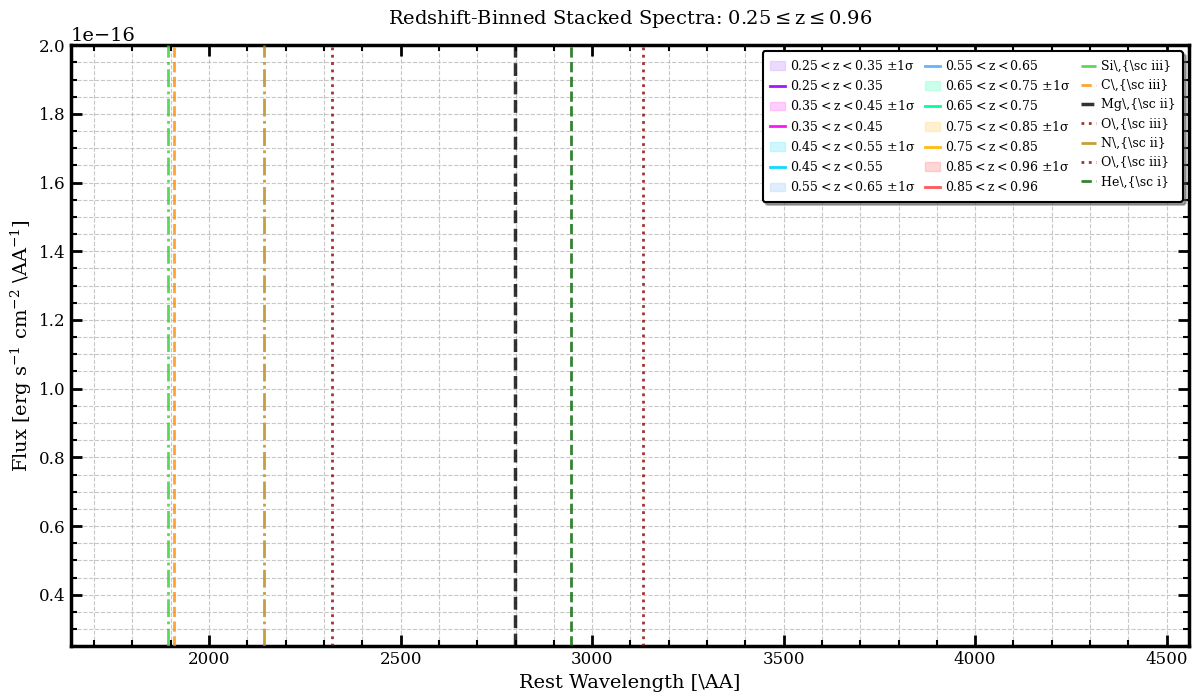

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Checking the ReStacked and binned (into redshift ranges) spectra.

# Create figure with MNRAS-compliant dimensions and styling
fig, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')

# Color scheme from the first code - organized by redshift bins
redshift_colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Uncertainty band colors (lighter versions)
uncertainty_colors = {
    '025_035': "#d4a7ff",  # Light purple
    '035_045': "#ff87f8",  # Light pink
    '045_055': "#87ebff",  # Light teal
    '055_065': "#b3d5ff",  # Light blue
    '065_075': "#80ffce",  # Light green
    '075_085': "#ffdd87",  # Light orange
    '085_096': "#ff9999"   # Light red
}

# Redshift bin labels
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('025_035', ReStacked_Wave_Continuum_Scaled_025_035, ReStacked_Spec_Continuum_Scaled_025_035, ReStacked_Spec_SD_Continuum_Scaled_025_035),
    ('035_045', ReStacked_Wave_Continuum_Scaled_035_045, ReStacked_Spec_Continuum_Scaled_035_045, ReStacked_Spec_SD_Continuum_Scaled_035_045),
    ('045_055', ReStacked_Wave_Continuum_Scaled_045_055, ReStacked_Spec_Continuum_Scaled_045_055, ReStacked_Spec_SD_Continuum_Scaled_045_055),
    ('055_065', ReStacked_Wave_Continuum_Scaled_055_065, ReStacked_Spec_Continuum_Scaled_055_065, ReStacked_Spec_SD_Continuum_Scaled_055_065),
    ('065_075', ReStacked_Wave_Continuum_Scaled_065_075, ReStacked_Spec_Continuum_Scaled_065_075, ReStacked_Spec_SD_Continuum_Scaled_065_075),
    ('075_085', ReStacked_Wave_Continuum_Scaled_075_085, ReStacked_Spec_Continuum_Scaled_075_085, ReStacked_Spec_SD_Continuum_Scaled_075_085),
    ('085_096', ReStacked_Wave_Continuum_Scaled_085_096, ReStacked_Spec_Continuum_Scaled_085_096, ReStacked_Spec_SD_Continuum_Scaled_085_096)
]

# Plot each redshift bin
for i, (key, wave, spec, spec_sd) in enumerate(datasets):
    # Plot uncertainty bands
    ax.fill_between(wave, spec - spec_sd, spec + spec_sd, 
                   color=uncertainty_colors[key], alpha=0.4, 
                   zorder=i, label=f'{redshift_labels[i]} $\pm 1\sigma$')
    
    # Plot spectra
    ax.step(wave, spec, color=redshift_colors[key], linewidth=2.0, 
           label=redshift_labels[i], zorder=i+10, where='mid')

# Emission line markers with organized colors and improved styling
line_properties = [
    (1892.030, 'limegreen', '-.', r'Si\,{\sc iii}', 2.0),
    (1908.734, 'darkorange', '--', r'C\,{\sc iii}', 2.0),
    (2799, 'black', '--', r'Mg\,{\sc ii}', 2.5),  # Thicker for prominence
    (2320.951, 'darkred', ':', r'O\,{\sc iii}', 2.0),
    (2142.780, 'darkgoldenrod', '-.', r'N\,{\sc ii}', 2.0),
    (3132.794, 'darkred', ':', r'O\,{\sc iii}', 2.0),
    (2945.106, 'darkgreen', '--', r'He\,{\sc i}', 2.0)
]

# Add emission line markers
for wavelength, color, linestyle, label, linewidth in line_properties:
    ax.axvline(x=wavelength, color=color, linestyle=linestyle, 
              linewidth=linewidth, alpha=0.8, label=label, zorder=20)

# Configure axes labels and title
ax.set_xlabel(r"Rest Wavelength [\AA]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]", fontsize=14, color="black")
ax.set_title(r"Redshift-Binned Stacked Spectra: $0.25 \leq z \leq 0.96$", fontsize=14, pad=15)

# Set axis limits
ax.set_ylim(0.25e-16, 2.0e-16)

# Configure legend with MNRAS style - organized in multiple columns
legend = ax.legend(
    loc='upper right',
    fontsize=9,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.6,
    handletextpad=0.4,
    columnspacing=0.8,
    handlelength=1.2,
    labelspacing=0.5,
    numpoints=1,
    ncol=3,
    bbox_to_anchor=(1.0, 1.0)
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Redshift_Binned_Spectra_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Redshift_Binned_Spectra_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Cutting out the continuum (aka lowering them down to zero) of the restacked spectra</font>

In [52]:
"""
Getting the continuum on the left side of the MgII emission
"""
MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Left = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2500, 2700, ReStacked_Spec_Continuum_Scaled_025_035)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Left = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2500, 2700, ReStacked_Spec_Continuum_Scaled_025_035)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Left = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2500, 2700, ReStacked_Spec_Continuum_Scaled_035_045)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Left = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2500, 2700, ReStacked_Spec_Continuum_Scaled_035_045)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Left = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2500, 2700, ReStacked_Spec_Continuum_Scaled_045_055)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Left = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2500, 2700, ReStacked_Spec_Continuum_Scaled_045_055)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Left = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2500, 2700, ReStacked_Spec_Continuum_Scaled_055_065)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Left = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2500, 2700, ReStacked_Spec_Continuum_Scaled_055_065)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Left = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2500, 2700, ReStacked_Spec_Continuum_Scaled_065_075)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Left = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2500, 2700, ReStacked_Spec_Continuum_Scaled_065_075)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Left = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2500, 2700, ReStacked_Spec_Continuum_Scaled_075_085)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Left = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2500, 2700, ReStacked_Spec_Continuum_Scaled_075_085)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Left = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_Continuum_Scaled_085_096)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Left = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_Continuum_Scaled_085_096)[1]




MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_025_035_Left = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_025_035)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Left = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_025_035)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Left = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_035_045)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Left = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_035_045)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Left = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_045_055)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Left = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_045_055)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Left = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_055_065)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Left = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_055_065)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Left = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_065_075)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Left = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_065_075)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Left = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_075_085)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Left = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2500, 2700, ReStacked_Spec_SD_Continuum_Scaled_075_085)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Left = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_SD_Continuum_Scaled_085_096)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Left = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_SD_Continuum_Scaled_085_096)[1]


print(ReStacked_Spec_Continuum_Scaled_025_035[0:3])
print(ReStacked_Spec_SD_Continuum_Scaled_025_035[0:3])

[0.94006367 0.94006367 0.94006367]
[0.00000000e+00 4.13442805e-17 0.00000000e+00]


In [53]:
"""
Getting the continuum on the right side of the MgII emission
"""
MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Right = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2900, 3100, ReStacked_Spec_Continuum_Scaled_025_035)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Right = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2900, 3100, ReStacked_Spec_Continuum_Scaled_025_035)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Right = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2900, 3100, ReStacked_Spec_Continuum_Scaled_035_045)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Right = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2900, 3100, ReStacked_Spec_Continuum_Scaled_035_045)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Right = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2900, 3100, ReStacked_Spec_Continuum_Scaled_045_055)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Right = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2900, 3100, ReStacked_Spec_Continuum_Scaled_045_055)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Right = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2900, 3100, ReStacked_Spec_Continuum_Scaled_055_065)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Right = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2900, 3100, ReStacked_Spec_Continuum_Scaled_055_065)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Right = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2900, 3100, ReStacked_Spec_Continuum_Scaled_065_075)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Right = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2900, 3100, ReStacked_Spec_Continuum_Scaled_065_075)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Right = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2900, 3100, ReStacked_Spec_Continuum_Scaled_075_085)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Right = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2900, 3100, ReStacked_Spec_Continuum_Scaled_075_085)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Right = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2900, 2985, ReStacked_Spec_Continuum_Scaled_085_096)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Right = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2900, 2985, ReStacked_Spec_Continuum_Scaled_085_096)[1]





MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_025_035_Right = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_025_035)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Right = continuum(ReStacked_Wave_Continuum_Scaled_025_035, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_025_035)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Right = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_035_045)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Right = continuum(ReStacked_Wave_Continuum_Scaled_035_045, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_035_045)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Right = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_045_055)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Right = continuum(ReStacked_Wave_Continuum_Scaled_045_055, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_045_055)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Right = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_055_065)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Right = continuum(ReStacked_Wave_Continuum_Scaled_055_065, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_055_065)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Right = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_065_075)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Right = continuum(ReStacked_Wave_Continuum_Scaled_065_075, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_065_075)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Right = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_075_085)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Right = continuum(ReStacked_Wave_Continuum_Scaled_075_085, 2900, 3100, ReStacked_Spec_SD_Continuum_Scaled_075_085)[1]

MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Right = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_SD_Continuum_Scaled_085_096)[0]
MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Right = continuum(ReStacked_Wave_Continuum_Scaled_085_096, 2300, 2700, ReStacked_Spec_SD_Continuum_Scaled_085_096)[1]


In [54]:
"""
Getting just the MgII emission for each of the ReStacked Spectra for each of the redshift ranges.
"""
MgII_ReStacked_Spec_Continuum_Scaled_025_035 = ReStacked_Spec_Continuum_Scaled_025_035[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_025_035 >2500, ReStacked_Wave_Continuum_Scaled_025_035 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_035_045 = ReStacked_Spec_Continuum_Scaled_035_045[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_035_045 >2500, ReStacked_Wave_Continuum_Scaled_035_045 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_045_055 = ReStacked_Spec_Continuum_Scaled_045_055[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_045_055 >2500, ReStacked_Wave_Continuum_Scaled_045_055 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_055_065 = ReStacked_Spec_Continuum_Scaled_055_065[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_055_065 >2500, ReStacked_Wave_Continuum_Scaled_055_065 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_065_075 = ReStacked_Spec_Continuum_Scaled_065_075[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_065_075 >2500, ReStacked_Wave_Continuum_Scaled_065_075 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_075_085 = ReStacked_Spec_Continuum_Scaled_075_085[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_075_085 >2500, ReStacked_Wave_Continuum_Scaled_075_085 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_085_096 = ReStacked_Spec_Continuum_Scaled_085_096[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_085_096 >2300, ReStacked_Wave_Continuum_Scaled_085_096 < 2990))[0]]




MgII_ReStacked_Spec_Continuum_Scaled_SD_025_035 = ReStacked_Spec_SD_Continuum_Scaled_025_035[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_025_035 >2500, ReStacked_Wave_Continuum_Scaled_025_035 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_035_045 = ReStacked_Spec_SD_Continuum_Scaled_035_045[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_035_045 >2500, ReStacked_Wave_Continuum_Scaled_035_045 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_045_055 = ReStacked_Spec_SD_Continuum_Scaled_045_055[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_045_055 >2500, ReStacked_Wave_Continuum_Scaled_045_055 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_055_065 = ReStacked_Spec_SD_Continuum_Scaled_055_065[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_055_065 >2500, ReStacked_Wave_Continuum_Scaled_055_065 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_065_075 = ReStacked_Spec_SD_Continuum_Scaled_065_075[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_065_075 >2500, ReStacked_Wave_Continuum_Scaled_065_075 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_075_085 = ReStacked_Spec_SD_Continuum_Scaled_075_085[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_075_085 >2500, ReStacked_Wave_Continuum_Scaled_075_085 < 3100))[0]]
MgII_ReStacked_Spec_Continuum_Scaled_SD_085_096 = ReStacked_Spec_SD_Continuum_Scaled_085_096[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_085_096 >2300, ReStacked_Wave_Continuum_Scaled_085_096 < 2990))[0]]


print(len(MgII_ReStacked_Spec_Continuum_Scaled_025_035))
print("")
print(len(MgII_ReStacked_Spec_Continuum_Scaled_SD_025_035))

357

357


In [55]:
print(len(ReStacked_Wave_Continuum_Scaled_025_035))
print("")
print(len(MgII_ReStacked_Spec_Continuum_Scaled_025_035))
print("")
print(len(MgII_ReStacked_Spec_Continuum_Scaled_SD_025_035))
print("")

1253

357

357



In [56]:
"""
Getting just the MgII Wavelength for each of the ReStacked Spectra for each of the redshift ranges.
"""
MgII_ReStacked_Wave_Continuum_Scaled_025_035 = ReStacked_Wave_Continuum_Scaled_025_035[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_025_035 >2500, ReStacked_Wave_Continuum_Scaled_025_035 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_035_045 = ReStacked_Wave_Continuum_Scaled_035_045[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_035_045 >2500, ReStacked_Wave_Continuum_Scaled_035_045 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_045_055 = ReStacked_Wave_Continuum_Scaled_045_055[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_045_055 >2500, ReStacked_Wave_Continuum_Scaled_045_055 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_055_065 = ReStacked_Wave_Continuum_Scaled_055_065[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_055_065 >2500, ReStacked_Wave_Continuum_Scaled_055_065 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_065_075 = ReStacked_Wave_Continuum_Scaled_065_075[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_065_075 >2500, ReStacked_Wave_Continuum_Scaled_065_075 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_075_085 = ReStacked_Wave_Continuum_Scaled_075_085[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_075_085 >2500, ReStacked_Wave_Continuum_Scaled_075_085 < 3100))[0]]
MgII_ReStacked_Wave_Continuum_Scaled_085_096 = ReStacked_Wave_Continuum_Scaled_085_096[np.where(np.logical_and(ReStacked_Wave_Continuum_Scaled_085_096 >2300, ReStacked_Wave_Continuum_Scaled_085_096 < 2990))[0]]


In [57]:
"""
Combining the Left and Right side of the MgII emission continuums.
"""
MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_045_055 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_055_065 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_065_075 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_075_085 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Right))

MgII_LR_ReStacked_Wave_Continuum_Scaled_085_096 = np.concatenate((MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Left, MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Right))




MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_025_035 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_035_045 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_045_055 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_055_065 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_065_075 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_075_085 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Right))
MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_085_096 = np.concatenate((MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Left, MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Right))



In [58]:
"""
Fitting the Left and Right side of the MgII emission. This is to get the continuum over this region.
"""
MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_025_035 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035, MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035, 3, 
                                                                                                                        w=MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_025_035, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_025_035))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045, MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_045_055 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_045_055, MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_045_055 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_045_055))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_055_065 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_055_065, MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_055_065 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_055_065))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_065_075 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_065_075, MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_065_075 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_065_075))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_075_085 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_075_085, MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_075_085 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_075_085))


MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096, MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_085_096 = np.polyfit(MgII_LR_ReStacked_Wave_Continuum_Scaled_085_096, MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096, 3, 
                                                                                                                        w=1/MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096, cov=True)
MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_085_096 = np.sqrt(np.diag(MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_085_096))


print(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[0:3])
print(MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035[0:3])

ValueError: operands could not be broadcast together with shapes (4,4) (0,) 

In [ ]:

def polyval_with_std(wave, coeffs, coeffs_std):
    """
    Evaluate a polynomial and estimate the standard deviation of the result
    using error propagation.

    Parameters:
        wave (np.ndarray): The x-values at which to evaluate the polynomial.
        coeffs (np.ndarray): Polynomial coefficients (highest power first).
        coeffs_std (np.ndarray): Standard deviation of the polynomial coefficients.

    Returns:
        tuple: (polyval_result, stddev_result)
    """
    polyval_result = np.polyval(coeffs, wave)
    
    # Construct the Jacobian matrix of the polynomial w.r.t. its coefficients
    powers = np.arange(len(coeffs))[::-1]  # descending powers
    jacobian = np.array([wave**p for p in powers])  # shape: (n_coeffs, len(wave))
    
    # Propagate uncertainty: variance = sum_j (df/dc_j)^2 * var(c_j)
    variance = np.sum((jacobian.T * coeffs_std)**2, axis=1)
    stddev_result = np.sqrt(variance)

    return polyval_result, stddev_result




"""
Getting the continuum fit from the polyfits.
"""
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_025_035, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_025_035 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_035_045, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_035_045 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_045_055, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_045_055 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_045_055)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_055_065, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_055_065 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_055_065, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_055_065)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_065_075, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_065_075 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_065_075)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_075_085, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_075_085 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_075_085)
MgII_LR_Polyvall_ReStacked_Continuum_Scaled_085_096, MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_085_096 = polyval_with_std(MgII_ReStacked_Wave_Continuum_Scaled_085_096, MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_085_096)



In [ ]:
#def getting_the_sd_on_the_polyequation(x, cov, coeffs):
#    # Construct Jacobian matrix: shape (N, 4)
#    J = np.vstack([x**3, x**2, x, np.ones_like(x)]).T  # shape (N, 4)
#    
#    # Calculate variance at each x
#    fit_var = np.einsum('ij,jk,ik->i', J, cov, J)  # shape (N,)
#    
#    # Standard deviation (1-sigma error)
#    fit_std = np.sqrt(fit_var)
#    
#    # Your polynomial evaluated at x (for completeness)
#    standard_deviation = (
#        coeffs[0]*x**3 + coeffs[1]*x**2 + coeffs[2]*x + coeffs[3]
#    )
#
#    return standard_deviation





def polynomial_with_error_propagation(
    coefficients,
    x_values,
    coefficient_uncertainties=None,
    covariance_matrix=None
):
    """
    Evaluate a polynomial and propagate uncertainty from coefficients.

    Parameters:
    -----------
    coefficients : array-like
        Polynomial coefficients [a, b, ..., z] from highest to lowest degree
    x_values : array-like
        The x values to evaluate the polynomial at
    coefficient_uncertainties : array-like, optional
        Standard deviation of each coefficient (assumes uncorrelated errors)
    covariance_matrix : 2D array-like, optional
        Covariance matrix of the polynomial coefficients

    Returns:
    --------
    y_values : array-like
        The polynomial values
    y_uncertainties : array-like
        The propagated uncertainties
    """
    coefficients = np.asarray(coefficients)
    x_values = np.asarray(x_values)

    # Evaluate the polynomial
    y_values = np.polyval(coefficients, x_values)

    # Compute the Jacobian matrix of partial derivatives
    powers = np.arange(len(coefficients))[::-1]  # descending powers
    jacobian = np.array([x_values**p for p in powers]).T  # shape: (n_points, n_coeffs)

    if covariance_matrix is not None:
        # Full error propagation with covariance
        covariance_matrix = np.asarray(covariance_matrix)
        y_var = np.einsum('ij,jk,ik->i', jacobian, covariance_matrix, jacobian)
    elif coefficient_uncertainties is not None:
        # Diagonal-only propagation (uncorrelated errors)
        coefficient_uncertainties = np.asarray(coefficient_uncertainties)
        y_var = np.sum((jacobian * coefficient_uncertainties)**2, axis=1)
    else:
        raise ValueError("You must provide either coefficient_uncertainties or covariance_matrix.")

    y_uncertainties = np.sqrt(y_var)
    return y_values, y_uncertainties



"""
Taking the Polyfit outputs (the coefficients) and putting them into a polynomial equation.
"""
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[0]*MgII_ReStacked_Wave_Continuum_Scaled_025_035**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[1]*MgII_ReStacked_Wave_Continuum_Scaled_025_035**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[2]*MgII_ReStacked_Wave_Continuum_Scaled_025_035**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[3]*MgII_ReStacked_Wave_Continuum_Scaled_025_035**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045[0]*MgII_ReStacked_Wave_Continuum_Scaled_035_045**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045[1]*MgII_ReStacked_Wave_Continuum_Scaled_035_045**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045[2]*MgII_ReStacked_Wave_Continuum_Scaled_035_045**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045[3]*MgII_ReStacked_Wave_Continuum_Scaled_035_045**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055[0]*MgII_ReStacked_Wave_Continuum_Scaled_045_055**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055[1]*MgII_ReStacked_Wave_Continuum_Scaled_045_055**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055[2]*MgII_ReStacked_Wave_Continuum_Scaled_045_055**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055[3]*MgII_ReStacked_Wave_Continuum_Scaled_045_055**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065[0]*MgII_ReStacked_Wave_Continuum_Scaled_055_065**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065[1]*MgII_ReStacked_Wave_Continuum_Scaled_055_065**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065[2]*MgII_ReStacked_Wave_Continuum_Scaled_055_065**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065[3]*MgII_ReStacked_Wave_Continuum_Scaled_055_065**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075[0]*MgII_ReStacked_Wave_Continuum_Scaled_065_075**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075[1]*MgII_ReStacked_Wave_Continuum_Scaled_065_075**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075[2]*MgII_ReStacked_Wave_Continuum_Scaled_065_075**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075[3]*MgII_ReStacked_Wave_Continuum_Scaled_065_075**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085[0]*MgII_ReStacked_Wave_Continuum_Scaled_075_085**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085[1]*MgII_ReStacked_Wave_Continuum_Scaled_075_085**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085[2]*MgII_ReStacked_Wave_Continuum_Scaled_075_085**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085[3]*MgII_ReStacked_Wave_Continuum_Scaled_075_085**0
#MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096 = MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096[0]*MgII_ReStacked_Wave_Continuum_Scaled_085_096**3 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096[1]*MgII_ReStacked_Wave_Continuum_Scaled_085_096**2 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096[2]*MgII_ReStacked_Wave_Continuum_Scaled_085_096**1 + MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096[3]*MgII_ReStacked_Wave_Continuum_Scaled_085_096**0




MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_025_035 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_025_035)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_035_045 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_045_055 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_045_055,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_045_055)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_055_065 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_055_065, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_055_065,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_055_065)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_065_075 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_065_075,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_065_075)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_075_085 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_075_085,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_075_085)

MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_085_096 = polynomial_with_error_propagation(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096, 
                                                                                                                                                                 MgII_ReStacked_Wave_Continuum_Scaled_085_096, MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_085_096,
                                                                                                                                                                MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_085_096)



print(MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035[0:3])
print("")
print(MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_025_035[0:3])
print("")
print("")
print(MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035[0:3])
print(MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035[0:3])



NameError: name 'MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035' is not defined

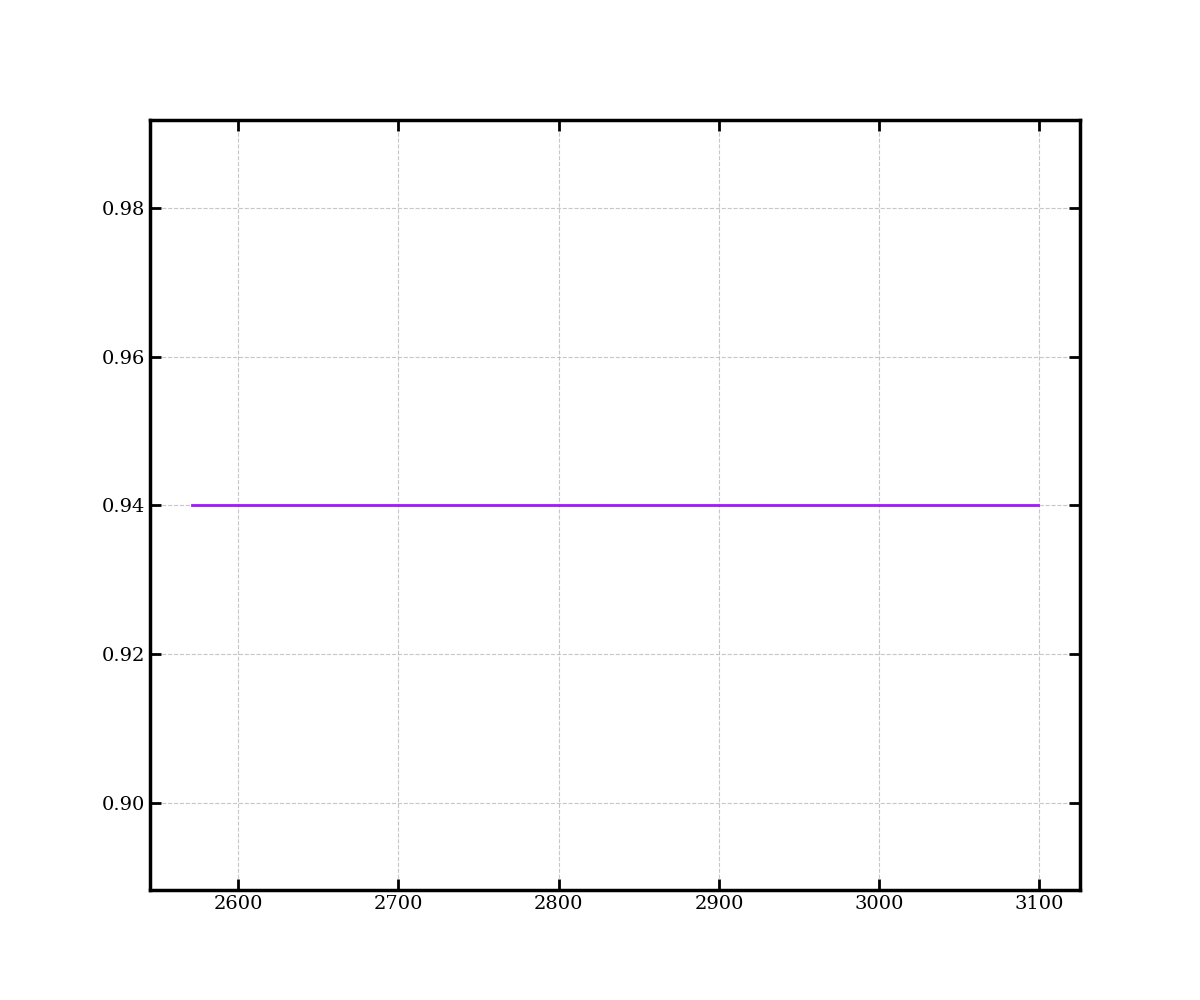

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Checking the Polyfits to the MgII LR continuum and the polynomial equation.

# Create figure with MNRAS-compliant dimensions and styling
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Color scheme from the first code
colors = {
    'spectrum': "#a714ff",      # Purple (deep/cool)
    'uncertainty': "#d4a7ff",   # Light purple
    'polyfit_bg': "#C4C4C4",    # Light grey background
    'polyfit': "#FF5757"        # Red (warm) for the polynomial fit
}

# Plot uncertainty band first (lowest z-order)
uncertainty_fill = ax.fill_between(
    MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035, 
    MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035 - MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_025_035, 
    MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035 + MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_025_035, 
    color=colors['uncertainty'], alpha=0.4, zorder=1,
    label=r'Spectrum $\pm 1\sigma$'
)

# Plot spectrum
spectrum_line = ax.plot(
    MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035, 
    MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035, 
    color=colors['spectrum'], linewidth=2.0, zorder=4,
    label=r'Mg\,{\sc ii} Continuum Spectrum'
)

# Plot polynomial fit with background effect
polyfit_bg = ax.plot(
    MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
    MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035, 
    color=colors['polyfit_bg'], linewidth=8, alpha=0.6, zorder=2,
    label='Polynomial Fit (Background)'
)

# Plot polynomial fit main line
polyfit_line = ax.plot(
    MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
    MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035, 
    color=colors['polyfit'], linewidth=2.5, zorder=3,
    label='Polynomial Continuum Fit'
)

# Add Mg II emission line marker
ax.axvline(x=2799, color='black', linestyle='--', 
          linewidth=2.5, alpha=0.8, zorder=5,
          label=r'Mg\,{\sc ii} $\lambda$2799')

# Print length information (diagnostic)
print(f"Spectrum length: {len(MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035)}")
print(f"Polynomial fit length: {len(MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035)}")

# Configure axes labels and title
ax.set_xlabel(r"Rest Wavelength [\AA]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]", fontsize=14, color="black")
ax.set_title(r"Mg\,{\sc ii} Continuum Polynomial Fit Validation ($0.25 < z < 0.35$)", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.5,
    labelspacing=0.8,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("MgII_Polyfit_Validation_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("MgII_Polyfit_Validation_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
# If you want to create a function to make this more reusable:
def propagate_subtraction_error(array1, array1_err, array2, array2_err):
    """
    Calculate the differenc and Propagate uncertainty when subtracting two arrays (A - B)
    
    Parameters:
    array1 (numpy.ndarray): Array of the original restack.
    array1_err (numpy.ndarray): Standard deviation of first array.
    
    array2 (numpy.ndarray) : Array of the continuum fits.
    array2_err (numpy.ndarray): Standard deviation of second array.
    
    Returns:
    dif (numpy.ndarray) : Difference of the stacked spectra minus the continuum fit for the stack.
    dif_sd (numpy.ndarray) : Propagated standard deviation
    """

    dif = array1 - array2
    dif_sd = np.sqrt(array1_err**2 + array2_err**2)
    
    return dif, dif_sd

# This function can then be used like:
# result_err = propagate_subtraction_error(array1_err, array2_err)




"""
Subtracting the results of the Poly equation from the MgII LR spectra. This removes the continuum and leaves the MgII continuum at or about zero.
"""
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_025_035, MgII_ReStacked_Spec_Continuum_Scaled_SD_025_035, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_025_035)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_035_045, MgII_ReStacked_Spec_Continuum_Scaled_SD_035_045, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_035_045)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_045_055, MgII_ReStacked_Spec_Continuum_Scaled_SD_045_055, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_045_055)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_055_065, MgII_ReStacked_Spec_Continuum_Scaled_SD_055_065, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_055_065)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_065_075, MgII_ReStacked_Spec_Continuum_Scaled_SD_065_075, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_065_075)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_075_085, MgII_ReStacked_Spec_Continuum_Scaled_SD_075_085, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_075_085)

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096 = propagate_subtraction_error(MgII_ReStacked_Spec_Continuum_Scaled_085_096, MgII_ReStacked_Spec_Continuum_Scaled_SD_085_096, 
                                                                                                                        MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096, MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_085_096)


NameError: name 'MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035' is not defined

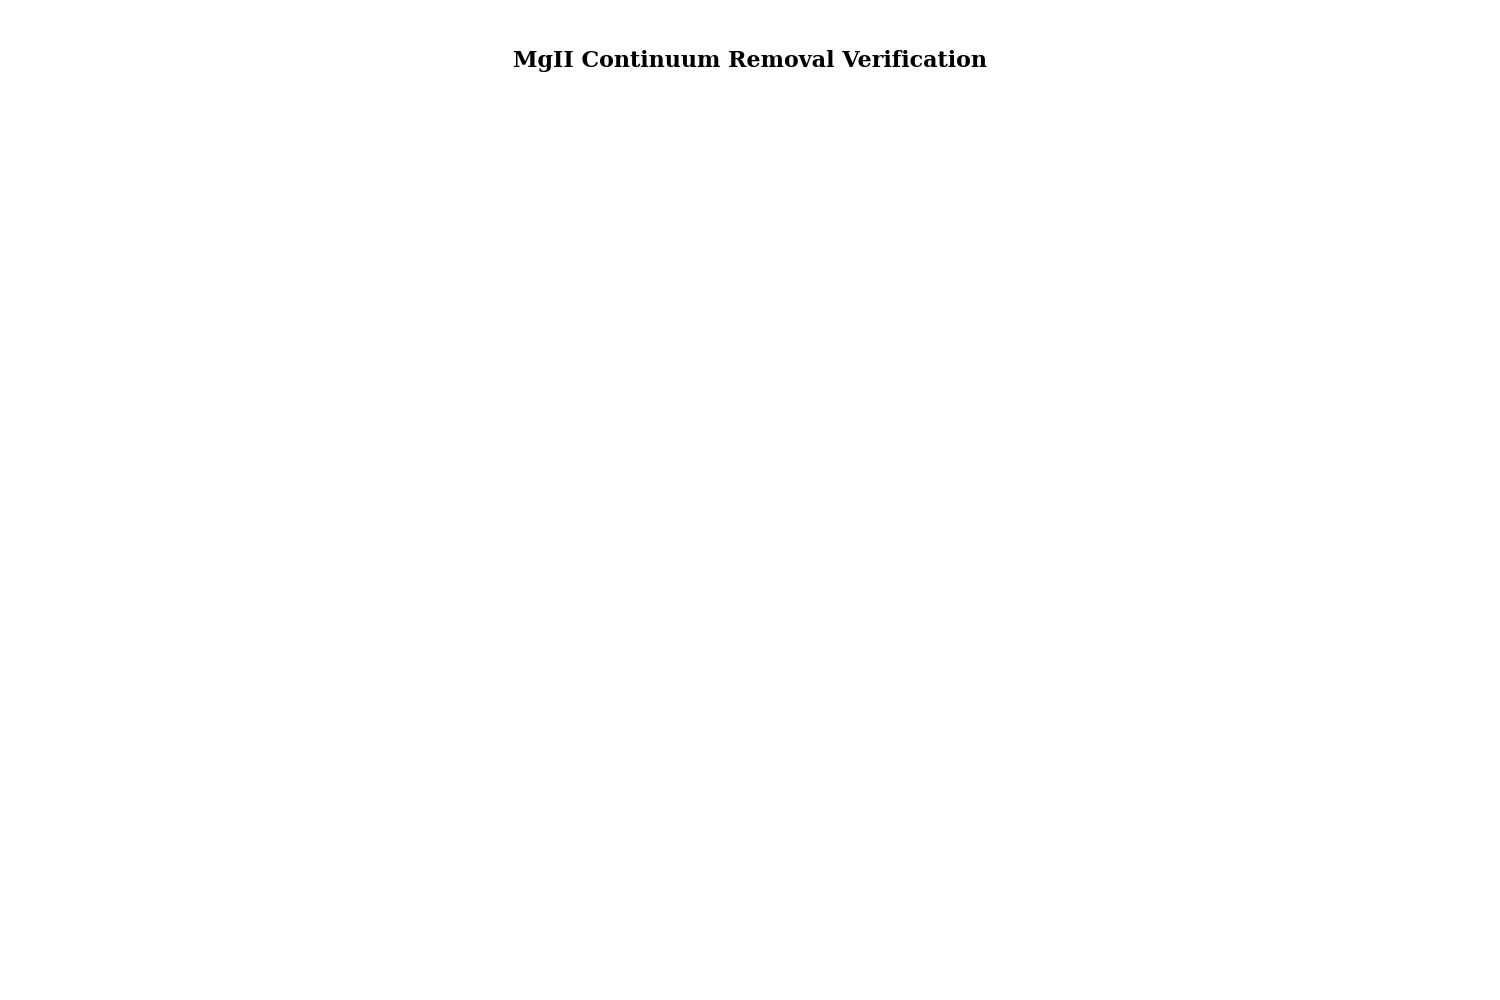

In [60]:
"""
Checking to make sure that the removal of the MgII continuum worked right. 
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme (matching the second code)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Additional colors for different components
plot_colors = {
    'original': '#2E86AB',      # Blue for original spectrum
    'lr_data': '#A23B72',       # Magenta for LR data
    'poly_fit': 'black',        # Black for polynomial fit
    'continuum_removed': 'lightseagreen'  # Light sea green for continuum removed
}

# Labels for redshift bins
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Create figure with MNRAS-compliant styling
fig = plt.figure(figsize=(15, 10), facecolor='white')
fig.suptitle("MgII Continuum Removal Verification", fontsize=16, fontweight='bold', y=0.95)

# Dataset configuration for each subplot
datasets = [
    ('025_035', MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_ReStacked_Spec_Continuum_Scaled_025_035,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035, MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035),
    ('035_045', MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_ReStacked_Spec_Continuum_Scaled_035_045,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045, MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045),
    ('045_055', MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_ReStacked_Spec_Continuum_Scaled_045_055,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_045_055, MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055),
    ('055_065', MgII_ReStacked_Wave_Continuum_Scaled_055_065, MgII_ReStacked_Spec_Continuum_Scaled_055_065,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_055_065, MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065),
    ('065_075', MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_ReStacked_Spec_Continuum_Scaled_065_075,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_065_075, MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075),
    ('075_085', MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_ReStacked_Spec_Continuum_Scaled_075_085,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_075_085, MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085),
    ('085_096', MgII_ReStacked_Wave_Continuum_Scaled_085_096, MgII_ReStacked_Spec_Continuum_Scaled_085_096,
     MgII_LR_ReStacked_Wave_Continuum_Scaled_085_096, MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096,
     MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096)
]

# Create subplots in 3x3 grid
for i, (key, wave, spec, lr_wave, lr_spec, poly_eq, cont_removed) in enumerate(datasets):
    ax = plt.subplot(3, 3, i+1)
    
    # Plot original spectrum
    ax.plot(wave, spec, 
            color=plot_colors['original'], 
            linewidth=1.5, 
            alpha=0.8, 
            label='Original Spectrum')
    
    # Plot LR restacked data
    ax.plot(lr_wave, lr_spec, 
            color=plot_colors['lr_data'], 
            linewidth=2.0, 
            alpha=0.9, 
            zorder=5,
            label='LR Restacked')
    
    # Plot polynomial fit
    ax.plot(wave, poly_eq, 
            linewidth=3.0, 
            color=plot_colors['poly_fit'], 
            alpha=0.9,
            zorder=6,
            label='Polynomial Fit')
    
    # Plot continuum removed spectrum
    ax.plot(wave, cont_removed, 
            linewidth=2.5, 
            color=plot_colors['continuum_removed'], 
            alpha=1.0,
            zorder=7,
            label='Continuum Removed')
    
    # Set subplot title with redshift range
    ax.set_title(redshift_labels[i], fontsize=11, fontweight='bold', pad=8)
    
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=10,
                   length=6, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=8,
                   length=3, width=1.0, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)
    
    # Set axis labels for bottom row
    if i >= 6:  # Bottom row
        ax.set_xlabel(r'Wavelength [Å]', fontsize=11)
    
    # Set axis labels for left column
    if i % 3 == 0:  # Left column
        ax.set_ylabel(r'Flux', fontsize=11)

# Create a single legend for the entire figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,  
           bbox_to_anchor=(0.8, 0.05),
           ncol=4, 
           fontsize=11,
           frameon=True,
           fancybox=True,
           shadow=True,
           borderpad=0.8,
           handletextpad=0.6,
           columnspacing=1.5)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.08, 1, 0.93])

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("MgII_Continuum_Removal_Verification_MNRAS.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("MgII_Continuum_Removal_Verification_MNRAS.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [61]:
print(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035[0:5])
print(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035[0:5])

NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

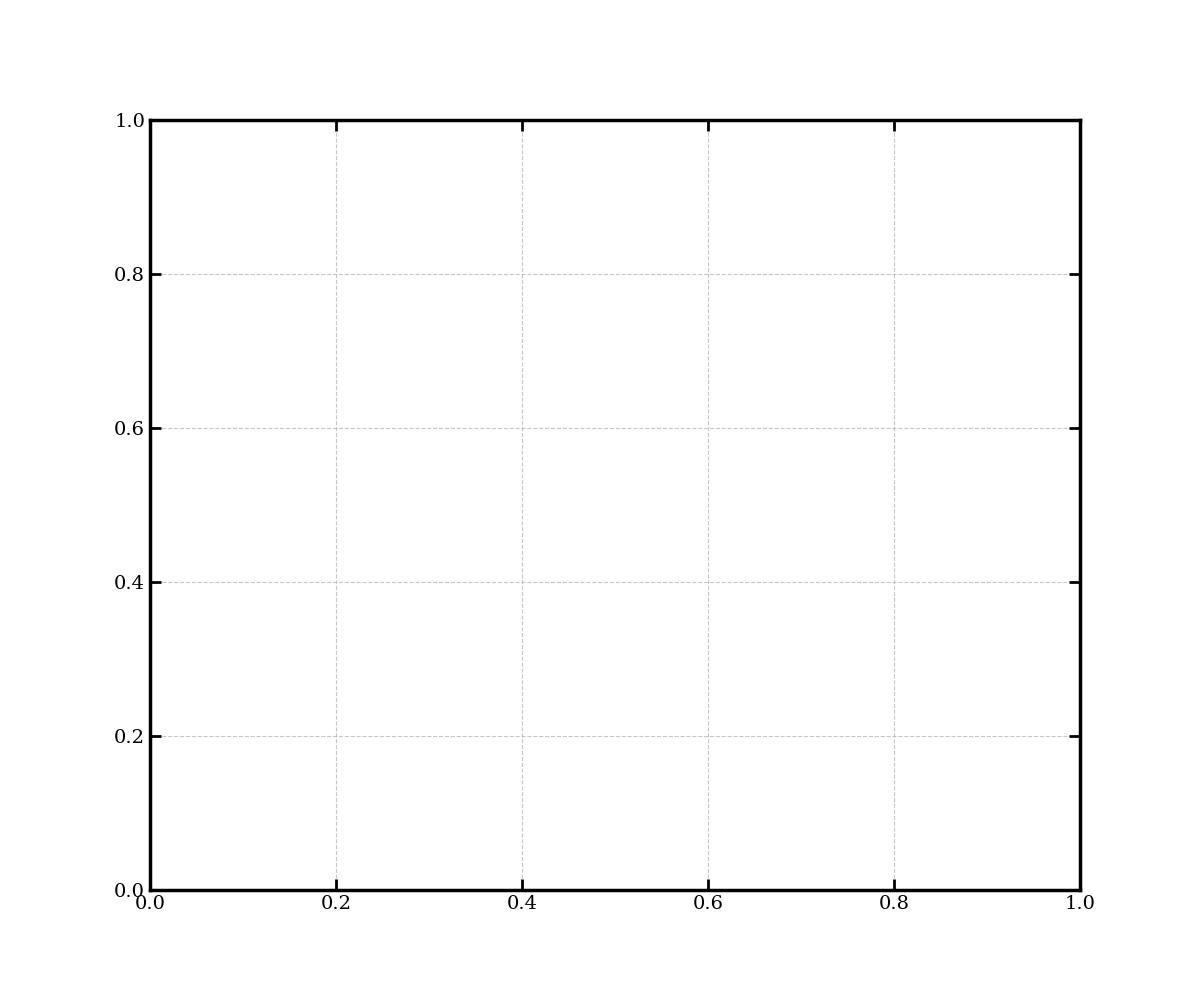

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Color scheme (using colors from the first code)
colors = {
    'main_spectrum': "#a714ff",  # Purple for main spectrum
    'error_fill': "black",       # Black for error region
    'MgII': "black",
    'HeI': "black", 
    'FeIV_1': "#ff14f5",        # Pink
    'FeIV_2': "#FF5757",        # Red (maroon equivalent)
    'ArIV_1': "#14D8FF",        # Teal (skyblue equivalent)
    'ArIV_2': "#60B5FF",        # Blue
    'HeII': "#ffbb14"           # Orange (gold equivalent)
}

# Plot main spectrum with step function
ax.step(MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
        color=colors['main_spectrum'], 
        linewidth=2, 
        linestyle="-", 
        alpha=1.0)

# Add error region with fill_between
ax.fill_between(MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035 - MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035, 
                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035 + MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035, 
                color=colors['error_fill'], 
                alpha=0.5, 
                zorder=0)

# Spectral line markers with organized approach
spectral_lines = [
    (2799, colors['MgII'], "--", "MgII"),
    (2945.106, colors['HeI'], ":", "HeI"),
    (2829.360, colors['FeIV_1'], ":", "FeIV"),
    (2835.740, colors['FeIV_2'], ":", "FeIV"),
    (2853.670, colors['ArIV_1'], ":", "ArIV"),
    (2868.210, colors['ArIV_2'], ":", "ArIV"),
    (2733.289, colors['HeII'], ":", "HeII")
]

# Plot spectral line markers
for wavelength, color, linestyle, label in spectral_lines:
    linewidth = 2 if linestyle == "--" else 2
    ax.axvline(x=wavelength, 
               color=color, 
               linestyle=linestyle, 
               linewidth=linewidth,
               label=label)

# Configure axes labels
ax.set_ylabel(r"Flux [erg $\AA^{-1} s^{-1} cm^{-2}$]", fontsize=14, color="black")
ax.set_xlabel(r"Rest Wavelength [$\AA$]", fontsize=14, color="black")

# Configure legend with MNRAS style
legend = ax.legend(
    loc='best',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("MgII_Spectrum_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("MgII_Spectrum_MNRAS_Ready.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
"""
Overplotting the MgII emission region with the continuum removed.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Color scheme (organized in dictionary with hex colors from first code)
colors = {
    'z_025_035': "#FF5757",   # Red
    'z_035_045': "#ffbb14",   # Orange
    'z_045_055': "#00FF9C",   # Gold equivalent (green)
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#a714ff",   # Purple
    'z_075_085': "#ff14f5",   # Violet (pink)
    'z_085_096': "black",     # Black
    'reference_lines': "black"
}

# Labels for legend (formatted for better readability)
redshift_labels = [
    r'$z = 0.25-0.35$',
    r'$z = 0.35-0.45$',
    r'$z = 0.45-0.55$',
    r'$z = 0.55-0.65$',
    r'$z = 0.65-0.75$',
    r'$z = 0.75-0.85$',
    r'$z = 0.85-0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035,
     redshift_labels[0]),
    ('z_035_045', 
     MgII_ReStacked_Wave_Continuum_Scaled_035_045, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045,
     redshift_labels[1]),
    ('z_045_055', 
     MgII_ReStacked_Wave_Continuum_Scaled_045_055, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055,
     redshift_labels[2]),
    ('z_055_065', 
     MgII_ReStacked_Wave_Continuum_Scaled_055_065, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065,
     redshift_labels[3]),
    ('z_065_075', 
     MgII_ReStacked_Wave_Continuum_Scaled_065_075, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075,
     redshift_labels[4]),
    ('z_075_085', 
     MgII_ReStacked_Wave_Continuum_Scaled_075_085, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085,
     redshift_labels[5]),
    ('z_085_096', 
     MgII_ReStacked_Wave_Continuum_Scaled_085_096, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096,
     redshift_labels[6])
]

# Plot each dataset
for i, (key, wave, flux, error, label) in enumerate(datasets):
    color = colors[key]
    
    # Plot uncertainty band (optional - currently commented out)
    # ax.fill_between(wave, flux - error, flux + error, 
    #                 color=color, alpha=0.2, zorder=i*2, 
    #                 label=f'±1σ {label}' if i == 0 else "")
    
    # Plot main spectrum line
    ax.step(wave, flux, 
            color=color, 
            linewidth=1.5, 
            linestyle="-", 
            alpha=1.0, 
            zorder=i*2+1,
            label=label)

# Reference spectral lines configuration
reference_lines = [
    (2799, "--", 2, r"Mg II $\lambda$2799"),
    (2945.106, ":", 2, r"He I $\lambda$2945")
]

# Plot reference lines
for wavelength, linestyle, linewidth, label in reference_lines:
    ax.axvline(x=wavelength, 
               color=colors['reference_lines'], 
               linestyle=linestyle, 
               linewidth=linewidth,
               label=label, 
               zorder=100)

# Configure axes labels
ax.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=16, color="black")
ax.set_xlabel(r"Rest Wavelength [$\AA$]", fontsize=16, color="black")

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1,
    ncol=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.3, zorder=-10, linewidth=0.8)
ax.grid(visible=True, which='minor', axis='both', 
        linestyle=':', alpha=0.2, zorder=-10, linewidth=0.5)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=14,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=12,
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Optional: Set specific axis limits if needed for better presentation
# ax.set_xlim([2700, 3100])  # Uncomment and adjust as needed
# ax.set_ylim([min_flux, max_flux])  # Uncomment and adjust as needed

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

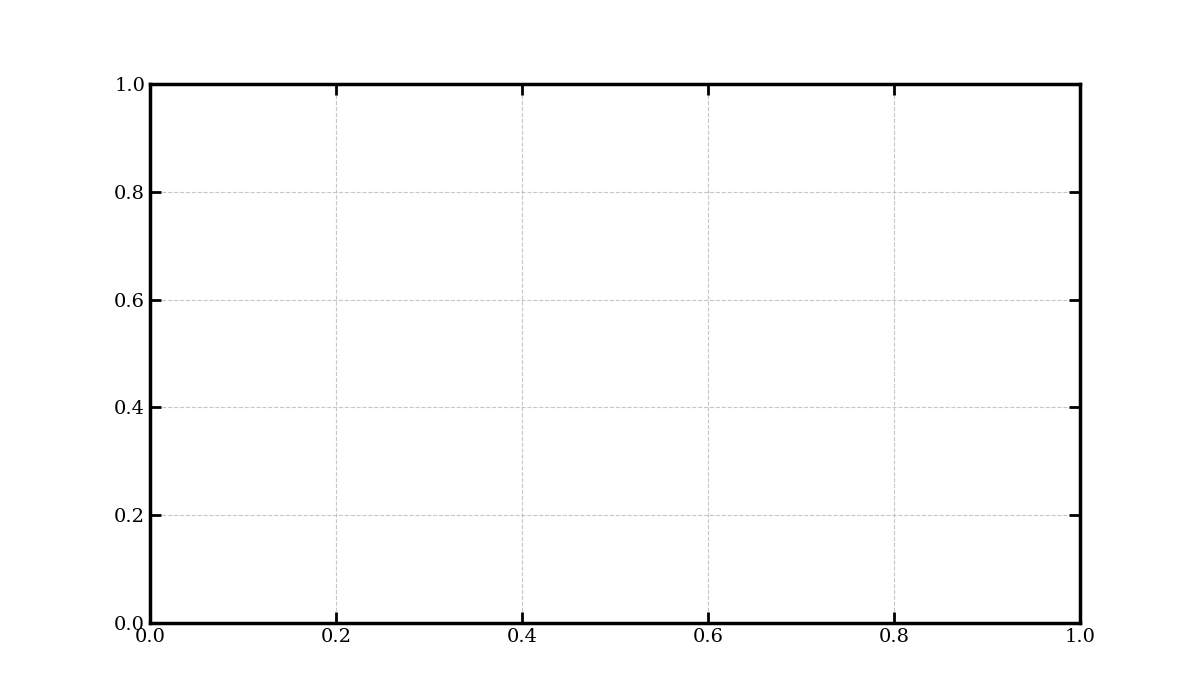

In [63]:
"""
Overplotting the MgII emission region with the continuum removed. 
These are offset from each other.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')

# Color scheme (organized in dictionary using hex colors from first code)
colors = {
    'z_025_035': "#FF5757",   # Red
    'z_035_045': "#ffbb14",   # Orange
    'z_045_055': "#00FF9C",   # Gold equivalent (green)
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#a714ff",   # Purple
    'z_075_085': "#ff14f5",   # Violet (pink)
    'z_085_096': "black",     # Black
    'reference_lines': "black"
}

# Vertical offsets for stacked presentation
offset_values = [0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8]
offset_multiplier = 2.5e-16  # Scaling factor for offsets

# Labels for legend (formatted for better readability)
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting with offsets
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
     redshift_labels[0], 0),
    ('z_035_045', 
     MgII_ReStacked_Wave_Continuum_Scaled_035_045, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, 
     redshift_labels[1], 1),
    ('z_045_055', 
     MgII_ReStacked_Wave_Continuum_Scaled_045_055, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, 
     redshift_labels[2], 2),
    ('z_055_065', 
     MgII_ReStacked_Wave_Continuum_Scaled_055_065, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, 
     redshift_labels[3], 3),
    ('z_065_075', 
     MgII_ReStacked_Wave_Continuum_Scaled_065_075, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, 
     redshift_labels[4], 4),
    ('z_075_085', 
     MgII_ReStacked_Wave_Continuum_Scaled_075_085, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, 
     redshift_labels[5], 5),
    ('z_085_096', 
     MgII_ReStacked_Wave_Continuum_Scaled_085_096, 
     MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, 
     redshift_labels[6], 6)
]

# Plot each dataset with vertical offset
for i, (key, wave, flux, label, offset_idx) in enumerate(datasets):
    color = colors[key]
    offset = offset_values[offset_idx] * offset_multiplier
    
    # Plot spectrum with offset
    ax.step(wave, flux + offset, 
            color=color, 
            linewidth=1.5, 
            linestyle="-", 
            alpha=1.0, 
            zorder=10+i,
            label=label)

# Reference spectral lines configuration
reference_lines = [
    (2799, "--", 2, r"Mg II $\lambda$2799"),
    (2945.106, ":", 2, r"He I $\lambda$2945")
]

# Plot reference lines
for wavelength, linestyle, linewidth, label in reference_lines:
    ax.axvline(x=wavelength, 
               color=colors['reference_lines'], 
               linestyle=linestyle, 
               linewidth=linewidth,
               label=label, 
               zorder=100)

# Configure axes labels
ax.set_ylabel(r"Flux with offset [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=16, color="black")
ax.set_xlabel(r"Rest Wavelength [$\AA$]", fontsize=16, color="black")

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1,
    ncol=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.3, zorder=-10, linewidth=0.8)
ax.grid(visible=True, which='minor', axis='both', 
        linestyle=':', alpha=0.2, zorder=-10, linewidth=0.5)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=14,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=12,
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout for publication
plt.tight_layout(pad=0.5)

# Optional: Set specific axis limits if needed for better presentation
# ax.set_xlim([2700, 3100])  # Uncomment and adjust as needed
# ax.set_ylim([min_flux, max_flux])  # Uncomment and adjust as needed

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Stacked_Multi_Redshift_Spectra_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Stacked_Multi_Redshift_Spectra_MNRAS_Ready.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Taking the continuum subtracted MgII emission regions and scaling them to compare the FWHM of the MgII emission</font>

In [64]:
"""
Getting Just the MgII emission.
Takeing that and finding the max value of the spectra for the ReStacked spectra.
"""
MgII_Max_ReStacked_Spec_Index_Continuum_Scaled = np.where(np.logical_and(2700 > MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035, MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035 < 2900))[0] 
MgII_Max_ReStacked_Spec_Index_Of_Max_Continuum_Scaled = np.argmax(ReStacked_Spec_Continuum_Scaled[MgII_Max_ReStacked_Spec_Index_Continuum_Scaled])
MgII_Max_ReStacked_Spec_Continuum_Scaled = ReStacked_Spec_Continuum_Scaled[MgII_Max_ReStacked_Spec_Index_Continuum_Scaled][MgII_Max_ReStacked_Spec_Index_Of_Max_Continuum_Scaled]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD = ReStacked_Spec_SD_Continuum_Scaled[MgII_Max_ReStacked_Spec_Index_Continuum_Scaled][MgII_Max_ReStacked_Spec_Index_Of_Max_Continuum_Scaled]


In [65]:
"""
Getting the max of the MgII emission for each of the redshift bins.
"""
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_025_035 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_045_055 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_055_065 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_065_075 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_075_085 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085)
MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_085_096 = np.argmax(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096)


MgII_Max_ReStacked_Spec_Continuum_Scaled_025_035 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_025_035]
MgII_Max_ReStacked_Spec_Continuum_Scaled_035_045 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045]
MgII_Max_ReStacked_Spec_Continuum_Scaled_045_055 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_045_055]
MgII_Max_ReStacked_Spec_Continuum_Scaled_055_065 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_055_065]
MgII_Max_ReStacked_Spec_Continuum_Scaled_065_075 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_065_075]
MgII_Max_ReStacked_Spec_Continuum_Scaled_075_085 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_075_085]
MgII_Max_ReStacked_Spec_Continuum_Scaled_085_096 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_085_096]


MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_025_035 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_025_035]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_035_045 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_045_055 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_045_055]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_055_065 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_055_065]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_065_075 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_065_075]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_075_085 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_075_085]
MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_085_096 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096[MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_085_096]



NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

In [66]:

def propagate_ratio_std(A, sigma_A, B, sigma_B):
    """
    Compute the ratio R = A / B and propagate standard deviation assuming independent errors.

    Parameters:
    -----------
    A : array_like or float
        Numerator values.
    sigma_A : array_like or float
        Standard deviation of numerator values.
    B : array_like or float
        Denominator values.
    sigma_B : array_like or float
        Standard deviation of denominator values.

    Returns:
    --------
    R : array_like or float
        Ratio A / B.
    sigma_R : array_like or float
        Propagated standard deviation on the ratio.
    """
    R = A / B
    relative_error_squared = (sigma_A / A)**2 + (sigma_B / B)**2
    sigma_R = np.abs(R) * np.sqrt(relative_error_squared)
    return R, sigma_R


"""
Dividing the max of the MgII emission of the restacked spectra over the max of the MgII emisson of the restacked spectra for each of the redshifts.
"""
MgII_Maxes_ReStacked_Dif_Continuum_Scaled_025_035, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_025_035 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_025_035, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_025_035)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_035_045 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_035_045, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_035_045)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_045_055, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_045_055 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_045_055, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_045_055)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_055_065, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_055_065 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_055_065, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_055_065)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_065_075, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_065_075 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_065_075, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_065_075)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_075_085, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_075_085 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_075_085, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_075_085)

MgII_Maxes_ReStacked_Dif_Continuum_Scaled_085_096, MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_085_096 = propagate_ratio_std(MgII_Max_ReStacked_Spec_Continuum_Scaled, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD, 
                                                                                                                              MgII_Max_ReStacked_Spec_Continuum_Scaled_085_096, MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_085_096)



NameError: name 'MgII_Max_ReStacked_Spec_Continuum_Scaled_025_035' is not defined

In [67]:

def propagate_product_std(X, sigma_X, Y, sigma_Y):
    """
    Propagate standard deviation through Z = X * abs(Y), assuming independent uncertainties.

    Parameters:
    -----------
    X : array_like or float
        First factor (e.g., flux-like quantity).
    sigma_X : array_like or float
        Standard deviation of X.
    Y : array_like or float
        Second factor (e.g., scaling factor, will take abs(Y)).
    sigma_Y : array_like or float
        Standard deviation of Y.

    Returns:
    --------
    Z : array_like or float
        Resulting product Z = X * abs(Y)
    sigma_Z : array_like or float
        Propagated standard deviation of Z.
    """
    Y_abs = np.abs(Y)
    Z = X * Y_abs
    rel_error_sq = (sigma_X / X)**2 + (sigma_Y / Y_abs)**2
    sigma_Z = np.abs(Z) * np.sqrt(rel_error_sq)
    return Z, sigma_Z


"""
Multiplying the MgII continuum removed with the difference of the MgII emission of the restacked spectrum over the max of the MgII emisson of the restacked spectra for each of the redshifts.
"""
MgII_Scaled_ReStacked_Continuum_Scaled_025_035, MgII_Scaled_ReStacked_Continuum_Scaled_SD_025_035 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_025_035), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_025_035))

MgII_Scaled_ReStacked_Continuum_Scaled_035_045, MgII_Scaled_ReStacked_Continuum_Scaled_SD_035_045 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_035_045))

MgII_Scaled_ReStacked_Continuum_Scaled_045_055, MgII_Scaled_ReStacked_Continuum_Scaled_SD_045_055 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_045_055), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_045_055))

MgII_Scaled_ReStacked_Continuum_Scaled_055_065, MgII_Scaled_ReStacked_Continuum_Scaled_SD_055_065 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_055_065), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_055_065))

MgII_Scaled_ReStacked_Continuum_Scaled_065_075, MgII_Scaled_ReStacked_Continuum_Scaled_SD_065_075 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_065_075), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_065_075))

MgII_Scaled_ReStacked_Continuum_Scaled_075_085, MgII_Scaled_ReStacked_Continuum_Scaled_SD_075_085 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_075_085), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_075_085))

MgII_Scaled_ReStacked_Continuum_Scaled_085_096, MgII_Scaled_ReStacked_Continuum_Scaled_SD_085_096 = propagate_product_std(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096, 
                                                                                                                          abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_085_096), abs(MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_085_096))




NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

NameError: name 'MgII_Scaled_ReStacked_Continuum_Scaled_025_035' is not defined

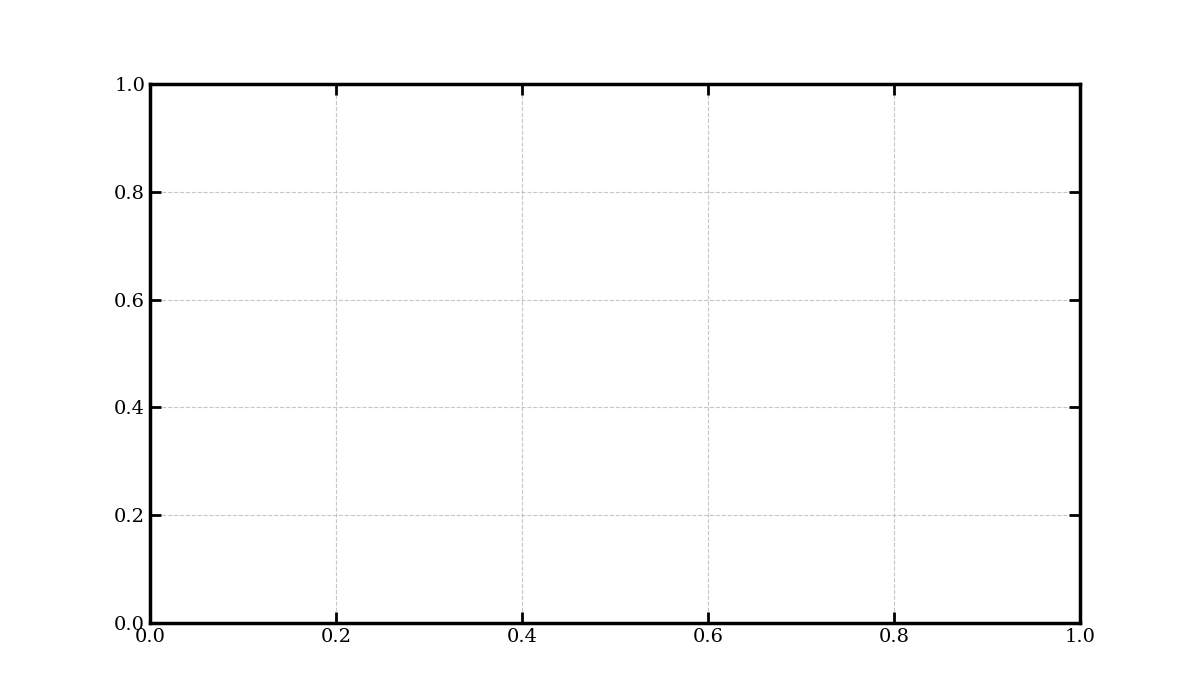

In [68]:
"""
Overplotting the scaled MgII emissions.
This allows for us to look at the differences in the FWHM of the MgII emissions.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme from the first code
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(12, 7), facecolor='white')

# Plot step functions for each redshift bin
ax.step(MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_Scaled_ReStacked_Continuum_Scaled_025_035, 
        where='mid', color=colors['025_035'], linewidth=2, 
        label="r 0.25 $\leq$ z $\leq$ 0.35; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_025_035))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_Scaled_ReStacked_Continuum_Scaled_035_045, 
        where='mid', color=colors['035_045'], linewidth=2, 
        label="r 0.35 $\leq$ z $\leq$ 0.45; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_Scaled_ReStacked_Continuum_Scaled_045_055, 
        where='mid', color=colors['045_055'], linewidth=2, 
        label="r 0.45 $\leq$ z $\leq$ 0.55; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_045_055))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_055_065, MgII_Scaled_ReStacked_Continuum_Scaled_055_065, 
        where='mid', color=colors['055_065'], linewidth=2, 
        label="r 0.55 $\leq$ z $\leq$ 0.65; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_055_065))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_Scaled_ReStacked_Continuum_Scaled_065_075, 
        where='mid', color=colors['065_075'], linewidth=2, 
        label="r 0.65 $\leq$ z $\leq$ 0.75; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_065_075))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_Scaled_ReStacked_Continuum_Scaled_075_085, 
        where='mid', color=colors['075_085'], linewidth=2, 
        label="r 0.75 $\leq$ z $\leq$ 0.85; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_075_085))

ax.step(MgII_ReStacked_Wave_Continuum_Scaled_085_096, MgII_Scaled_ReStacked_Continuum_Scaled_085_096, 
        where='mid', color=colors['085_096'], linewidth=2, 
        label="r 0.85 $\leq$ z $\leq$ 0.96; Scale = "+str('%.3f'%MgII_Maxes_ReStacked_Dif_Continuum_Scaled_085_096))

# Add MgII reference line
ax.axvline(x=2799, color='black', linestyle="--", linewidth=2, label="MgII")

# Configure axes labels
ax.set_ylabel(r"Flux [erg $\AA^{-1} s^{-1} cm^{-2}$]", fontsize=14, color="black")
ax.set_xlabel(r"Rest Wavelength [$\AA$]", fontsize=14, color="black")

# Configure legend with MNRAS style
legend = ax.legend(
    loc='best',
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=0.8,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("MgII_Spectral_Stack_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Test_MgII_Spectral_Stack_MNRAS_Ready.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [69]:
def fit_MgII_spectrum(x, y, y_err=None, plot=True, 
                    mask=None,  # NEW: mask parameter
                    mask_ranges=None,  # NEW: alternative way to specify mask ranges
                    g1_amp=None,
                    g2_amp=None,
                    g1_sigma=None,
                    g2_sigma=None,
                    g1_center=None,
                    g2_center=None,
                    g1_amp_bounds=None,
                    g2_amp_bounds=None,
                    g1_sigma_bounds=None,
                    g2_sigma_bounds=None,
                    g1_center_bounds=None,
                    g2_center_bounds=None,
                    title="0.25 < z < 0.35 - MgII Doublet Fit",
                    n_random_starts=50,  # Number of random starting points to try
                    use_grid_search=True,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True):
    """
    Enhanced MgII doublet fitting with two Gaussians.
    Includes multiple optimization strategies and masking capability.
    
    This function tries multiple approaches:
    1. Grid search over parameter space
    2. Random starting points
    3. Differential evolution (global optimizer)
    4. Returns the best fit among all attempts
    5. Supports masking to ignore specific data regions during fitting
    
    Parameters:
    -----------
    x : array-like
        Wavelength data
    y : array-like
        Flux data
    y_err : array-like, optional
        Flux uncertainties
    plot : bool, optional
        Whether to create plots
    mask : array-like of bool, optional
        Boolean mask where True indicates points to INCLUDE in fit.
        If None, all points are used.
    mask_ranges : list of tuples, optional
        List of (min, max) tuples defining ranges to EXCLUDE from fit.
        E.g., [(2750, 2780), (2850, 2900)] excludes these wavelength ranges.
        This is an alternative to providing a mask array directly.
    title : str, optional
        Title for the plot (default: "0.25 < z < 0.35 - MgII Doublet Fit")
    
    Model Parameters with defaults:
    ------------------------------
    g1_amp : float, optional
        Initial guess for amplitude of first Gaussian (defaults to 65% of max flux)
    g1_center : float, optional
        Initial guess for center of first Gaussian (default: 2800)
    g1_sigma : float, optional
        Initial guess for sigma of first Gaussian (default: 5)
    g2_amp : float, optional
        Initial guess for amplitude of second Gaussian (defaults to 40% of max flux)
    g2_center : float, optional
        Initial guess for center of second Gaussian (default: 2800)
    g2_sigma : float, optional
        Initial guess for sigma of second Gaussian (default: 45)
    
    Parameter Bounds:
    ----------------
    g1_amp_bounds : tuple, optional
        (lower, upper) bounds for g1_amp (default: (10% of max flux, None))
    g1_center_bounds : tuple, optional
        (lower, upper) bounds for g1_center (default: (2700, 2900))
    g1_sigma_bounds : tuple, optional
        (lower, upper) bounds for g1_sigma (default: (0.1, 15))
    g2_amp_bounds : tuple, optional
        (lower, upper) bounds for g2_amp (default: (20% of max flux, None))
    g2_center_bounds : tuple, optional
        (lower, upper) bounds for g2_center (default: (2700, 2900))
    g2_sigma_bounds : tuple, optional
        (lower, upper) bounds for g2_sigma (default: (30, 65))
        
    Additional Parameters:
    ---------------------
    n_random_starts : int, optional
        Number of random starting points to try (default: 50)
    use_grid_search : bool, optional
        Whether to perform grid search over parameter space (default: True)
    use_differential_evolution : bool, optional
        Whether to use differential evolution global optimizer (default: True)
    verbose : bool, optional
        Whether to print detailed optimization progress (default: True)
        
    Returns:
    --------
    dict
        Dictionary containing fit results, parameters, uncertainties and fit components
    """
    
    # Handle masking
    if mask_ranges is not None:
        # Create mask from ranges
        mask = np.ones(len(x), dtype=bool)  # Start with all True (include all)
        for min_val, max_val in mask_ranges:
            mask = mask & ~((x >= min_val) & (x <= max_val))  # Exclude ranges
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Masking {excluded_points} points from {len(mask_ranges)} ranges: {mask_ranges}")
    
    elif mask is not None:
        # Use provided mask
        mask = np.array(mask, dtype=bool)
        if len(mask) != len(x):
            raise ValueError("Mask length must match data length")
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Using provided mask: excluding {excluded_points} points")
    else:
        # No masking - include all points
        mask = np.ones(len(x), dtype=bool)
        if verbose:
            print("No masking applied - using all data points")
    
    # Apply mask to data
    x_fit = x[mask]
    y_fit = y[mask]
    y_err_fit = y_err[mask] if y_err is not None else None
    
    if len(x_fit) == 0:
        raise ValueError("No data points remaining after masking!")
    
    if verbose:
        print(f"Fitting {len(x_fit)} out of {len(x)} data points")
    
    # Scale y values by 1e17 for fitting
    y_scaled = y_fit * 1e17
    y_err_scaled = y_err_fit * 1e17 if y_err_fit is not None else None
    
    # Set default parameter values based on data if not provided
    max_flux = np.max(y_fit)
    
    if g1_amp is None:
        g1_amp = 0.65 * max_flux
    if g2_amp is None:
        g2_amp = 0.40 * max_flux
    if g1_center is None:
        g1_center = 2800
    if g2_center is None:
        g2_center = 2800
    if g1_sigma is None:
        g1_sigma = 5
    if g2_sigma is None:
        g2_sigma = 45
    
    # Set default bounds if not provided
    if g1_amp_bounds is None:
        g1_amp_bounds = (0.10 * max_flux, None)
    if g2_amp_bounds is None:
        g2_amp_bounds = (0.20 * max_flux, None)
    if g1_center_bounds is None:
        g1_center_bounds = (2700, 2900)
    if g2_center_bounds is None:
        g2_center_bounds = (2700, 2900)
    if g1_sigma_bounds is None:
        g1_sigma_bounds = (0.1, 15)
    if g2_sigma_bounds is None:
        g2_sigma_bounds = (30, 65)
    
    # Scale amplitude parameters and bounds by 1e17
    g1_amp_scaled = g1_amp * 1e17
    g2_amp_scaled = g2_amp * 1e17
    
    g1_amp_bounds_scaled = (g1_amp_bounds[0] * 1e17, g1_amp_bounds[1] * 1e17 if g1_amp_bounds[1] is not None else None)
    g2_amp_bounds_scaled = (g2_amp_bounds[0] * 1e17, g2_amp_bounds[1] * 1e17 if g2_amp_bounds[1] is not None else None)
    
    # Define objective function for optimization (uses masked data)
    def objective_function(params):
        try:
            model_values = double_gaussian_model(x_fit, *params)
            if y_err_scaled is not None:
                chi_squared = np.sum(((y_scaled - model_values) / y_err_scaled)**2)
            else:
                chi_squared = np.sum((y_scaled - model_values)**2)
            return chi_squared
        except:
            return np.inf
    
    # Parameter bounds for optimization
    # Format: [g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma]
    bounds = [
        (g1_amp_bounds_scaled[0], g1_amp_bounds_scaled[1]),
        (g1_center_bounds[0], g1_center_bounds[1]),
        (g1_sigma_bounds[0], g1_sigma_bounds[1]),
        (g2_amp_bounds_scaled[0], g2_amp_bounds_scaled[1]),
        (g2_center_bounds[0], g2_center_bounds[1]),
        (g2_sigma_bounds[0], g2_sigma_bounds[1])
    ]
    
    best_result = None
    best_chi_squared = np.inf
    all_attempts = []
    
    if verbose:
        print("Starting multi-strategy optimization...")
        print(f"Parameter bounds: {bounds}")

    # Strategy 1: Grid Search
    if use_grid_search:
        if verbose:
            print("\n1. Performing grid search...")
        
        # Create grid of starting points (reduced grid size due to 8 parameters)
        n_grid_points = 2  # Reduced from 3 since we have 8 parameters now
        grid_ranges = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3  # Reasonable upper bound if None
            grid_ranges.append(np.linspace(lower, upper, n_grid_points))
        
        grid_count = 0
        for grid_point in product(*grid_ranges):
            try:
                popt, pcov = curve_fit(double_gaussian_model, x_fit, y_scaled, p0=list(grid_point), 
                                     bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                     method='trf', max_nfev=5000)
                
                chi_squared = objective_function(popt)
                all_attempts.append(('grid', grid_point, popt, chi_squared))
                
                if chi_squared < best_chi_squared:
                    best_chi_squared = chi_squared
                    best_result = (popt, pcov)
                    if verbose:
                        print(f"  New best from grid search: χ² = {chi_squared:.6f}")
                
                grid_count += 1
            except:
                continue
        
        if verbose:
            print(f"  Grid search completed: {grid_count} successful fits")
    
    # Strategy 2: Random Starting Points
    if verbose:
        print(f"\n2. Trying {n_random_starts} random starting points...")
    
    np.random.seed(42)  # For reproducibility
    random_count = 0
    
    for i in range(n_random_starts):
        # Generate random starting point within bounds
        random_start = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3
            random_start.append(np.random.uniform(lower, upper))
        
        try:
            popt, pcov = curve_fit(double_gaussian_model, x_fit, y_scaled, p0=random_start, 
                                 bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                 method='trf', max_nfev=5000)
            
            chi_squared = objective_function(popt)
            all_attempts.append(('random', random_start, popt, chi_squared))
            
            if chi_squared < best_chi_squared:
                best_chi_squared = chi_squared
                best_result = (popt, pcov)
                if verbose:
                    print(f"  New best from random start {i+1}: χ² = {chi_squared:.6f}")
            
            random_count += 1
        except:
            continue
    
    if verbose:
        print(f"  Random starts completed: {random_count} successful fits")
    
    # Strategy 3: Differential Evolution (Global Optimizer)
    if use_differential_evolution:
        if verbose:
            print("\n3. Running differential evolution global optimizer...")
        
        try:
            # Use differential evolution to find global minimum
            de_bounds = [(lower, upper if upper is not None else lower * 3) for lower, upper in bounds]
            
            result = differential_evolution(objective_function, de_bounds, 
                                          maxiter=1000, popsize=15, seed=42)
            
            if result.success:
                # Refine with curve_fit
                try:
                    popt, pcov = curve_fit(double_gaussian_model, x_fit, y_scaled, p0=result.x, 
                                         bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                         method='trf', max_nfev=5000)
                    
                    chi_squared = objective_function(popt)
                    all_attempts.append(('differential_evolution', result.x, popt, chi_squared))
                    
                    if chi_squared < best_chi_squared:
                        best_chi_squared = chi_squared
                        best_result = (popt, pcov)
                        if verbose:
                            print(f"  New best from differential evolution: χ² = {chi_squared:.6f}")
                    
                except:
                    pass
            
        except Exception as e:
            if verbose:
                print(f"  Differential evolution failed: {e}")
    
    # Strategy 4: Try the original starting point too
    if verbose:
        print("\n4. Trying original starting point...")
    
    original_p0 = [g1_amp_scaled, g1_center, g1_sigma, g2_amp_scaled, g2_center, g2_sigma]
    try:
        popt, pcov = curve_fit(double_gaussian_model, x_fit, y_scaled, p0=original_p0, 
                             bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                             method='trf', max_nfev=10000)
        
        chi_squared = objective_function(popt)
        all_attempts.append(('original', original_p0, popt, chi_squared))
        
        if chi_squared < best_chi_squared:
            best_chi_squared = chi_squared
            best_result = (popt, pcov)
            if verbose:
                print(f"  Original starting point: χ² = {chi_squared:.6f}")
    except:
        if verbose:
            print("  Original starting point failed")
    
    if best_result is None:
        print("All optimization attempts failed!")
        print("Consider adjusting your initial parameter guesses or bounds.")
        print("Current values:")
        param_names = ["g1_amp", "g1_center", "g1_sigma", "g2_amp", "g2_center", "g2_sigma"]
        
        print("\nInitial parameter values:")
        for name, val in zip(param_names, original_p0):
            print(f"{name} = {val}")
            
        print("\nParameter bounds:")
        for i, name in enumerate(param_names):
            print(f"{name}: ({bounds[i][0]}, {bounds[i][1]})")
            
        print("\nSuggestions:")
        print("- Try adjusting sigma values")
        print("- Make sure amplitude values match the scale of your flux")
        print("- Try using mask_ranges to exclude problematic regions")
        
        return None
    
    popt, pcov = best_result
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best χ² = {best_chi_squared:.6f}")
        print(f"Total successful attempts: {len(all_attempts)}")
        # Show top 5 results
        all_attempts.sort(key=lambda x: x[3])  # Sort by chi-squared
        print(f"\nTop 5 results:")
        for i, (method, start, final, chi2) in enumerate(all_attempts[:5]):
            print(f"  {i+1}. {method}: χ² = {chi2:.6f}")
    
    # Continue with original processing code...
    try:
        # Calculate standard deviations (uncertainties) of parameters
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate best fit using scaled parameters and ORIGINAL x array
        best_fit_scaled = double_gaussian_model(x, *popt)
        
        # Unscale the fitted results back to original units
        best_fit = best_fit_scaled / 1e17
        
        # Unscale amplitude parameters and uncertainties
        popt_unscaled = popt.copy()
        popt_unscaled[0] /= 1e17  # g1_amp
        popt_unscaled[3] /= 1e17  # g2_amp
        
        perr_unscaled = perr.copy()
        perr_unscaled[0] /= 1e17  # g1_amp uncertainty
        perr_unscaled[3] /= 1e17  # g2_amp uncertainty
        # Calculate residuals and percent error using original scale and ALL data points
        residuals = y - best_fit
        percent_error = 100 * residuals / np.where(y != 0, y, np.inf)  # Avoid division by zero
        
        # Calculate R-squared using original y values
        ss_total = np.sum((y - np.mean(y))**2)
        ss_residual = np.sum(residuals**2)
        r_squared = 1 - (ss_residual / ss_total)

        # Calculate chi-squared using original y values and uncertainties
        if y_err is not None:
            chi_squared = np.sum((residuals / y_err)**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        else:
            chi_squared = np.sum(residuals**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))

        # Also calculate chi-squared for ONLY the fitted points
        if y_err is not None:
            chi_squared_fitted = np.sum((residuals[mask] / y_err[mask])**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        else:
            chi_squared_fitted = np.sum(residuals[mask]**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        
        # Calculate individual components - need to unscale amplitude parameters
        components = calc_components_No_Exponential(x, popt_unscaled)
        
        # Create output report
        param_names = ['g1_amplitude', 'g1_center', 'g1_sigma', 
                      'g2_amplitude', 'g2_center', 'g2_sigma']
        
        fit_report = "Multi-Strategy Fit Results with Masking:\n"
        fit_report += f"Data points used for fitting: {len(x_fit)}/{len(x)}\n"
        fit_report += f"R-squared (all data): {r_squared:.6f}\n"
        fit_report += f"Chi-squared (all data): {chi_squared:.6f}\n"
        fit_report += f"Reduced chi-squared (all data): {reduced_chi_squared:.6f}\n"
        fit_report += f"Chi-squared (fitted data only): {chi_squared_fitted:.6f}\n"
        fit_report += f"Reduced chi-squared (fitted data only): {reduced_chi_squared_fitted:.6f}\n"
        fit_report += f"Total optimization attempts: {len(all_attempts)}\n\n"
        fit_report += "Parameters:\n"
        
        for name, val, err in zip(param_names, popt_unscaled, perr_unscaled):
            fit_report += f"{name} = {val:.6g} ± {err:.6g}\n"
        
        print(fit_report)
        
        if plot:
            # Create figure
            plt.rcParams['axes.grid'] = True
            plt.rcParams['grid.alpha'] = 0.7
            plt.rcParams['grid.linestyle'] = '--'

            fig1 = plt.figure(figsize=(15, 12))
            
            # Create individual subplots with specific spacing
            # First plot takes up first 3/7 of vertical space
            ax0 = fig1.add_axes([0.1, 0.45, 0.8, 0.45])  # [left, bottom, width, height]
            
            # Second plot below with some space
            ax1 = fig1.add_axes([0.1, 0.25, 0.8, 0.15], sharex=ax0)
            
            # Third plot immediately below second plot with no gap
            ax2 = fig1.add_axes([0.1, 0.1, 0.8, 0.15], sharex=ax0)
            
            # Hide x-labels for first two plots
            plt.setp(ax0.get_xticklabels(), visible=False)
            plt.setp(ax1.get_xticklabels(), visible=False)
            
            # Store axes in a list for easy access later
            axes = [ax0, ax1, ax2]
            
            # Plot 1: Overall fit with components
            # Plot all data points
            axes[0].step(x, y, where='mid', linewidth=2.25, color='#60B5FF', label='All Data', zorder=1)
            axes[0].fill_between(x, y - y_err, y + y_err, color="#60B5FF", alpha=0.3, zorder=0, step='mid', label=r"2$\sigma$ Error")

            # Highlight masked (excluded) regions as separate step plots
            if not np.all(mask):
                # Find continuous masked regions
                masked_indices = np.where(~mask)[0]
                if len(masked_indices) > 0:
                    # Group consecutive indices
                    groups = []
                    current_group = [masked_indices[0]]
                    
                    for i in range(1, len(masked_indices)):
                        if masked_indices[i] == masked_indices[i-1] + 1:
                            current_group.append(masked_indices[i])
                        else:
                            groups.append(current_group)
                            current_group = [masked_indices[i]]
                    groups.append(current_group)
                    
                    # Plot each group separately
                    for i, group in enumerate(groups):
                        label = 'Masked Data' if i == 0 else None
                        axes[0].step(x[group], y[group], where='mid', linewidth=2.25, color='red', alpha=0.7, 
                                   label=label, zorder=2)
                        axes[0].fill_between(x[group], y[group] - y_err[group], y[group] + y_err[group], 
                                           color="red", alpha=0.2, zorder=0, step='mid')
            
            axes[0].plot(x, best_fit, '-', linewidth=2.25, color='black', label='Best fit', zorder=4)
            axes[0].plot(x, components['gaussian1'], '-', linewidth=4.5, color='#a714ff', label='Narrow component', zorder=2)
            axes[0].plot(x, components['gaussian2'], '-', linewidth=4.5, color='#ff14f5', label='Broad component', zorder=3)
            axes[0].axhline(y=0, linestyle='-', linewidth=3.0, color='#ffbb14', label='Exponential component', zorder=1)
            
            # Mark the centers of the Gaussian components
            axes[0].axvline(x=popt_unscaled[1], color='#a714ff', linestyle=':', alpha=0.7)
            axes[0].axvline(x=popt_unscaled[4], color='#ff14f5', linestyle=':', alpha=0.7)
            
            axes[0].legend(facecolor="white", labelcolor="black", fontsize=12, frameon=True, fancybox=True, shadow=True, 
                           edgecolor="black", borderpad=1, handlelength=4.0)  
                           
            axes[0].set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', size='14', color="black")
            axes[0].set_title(title, fontsize=14)
            
            # Plot 2: Residuals
            axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot residuals for fitted points
            axes[1].scatter(x[mask], residuals[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot residuals for masked points (if any)
            if not np.all(mask):
                axes[1].scatter(x[~mask], residuals[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')
            
            axes[1].fill_between(x, 0 - y_err, 0 + y_err, color="#60B5FF", alpha=0.3, zorder=0)
            
            if not np.all(mask):
                axes[1].legend(fontsize=10)
            
            axes[1].set_ylabel('Residuals', size='14', color='black')
            
            # Plot 3: Percent error
            axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot percent error for fitted points
            axes[2].scatter(x[mask], percent_error[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot percent error for masked points (if any)
            if not np.all(mask):
                axes[2].scatter(x[~mask], percent_error[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')

            # Filter out infinite or very large percent errors for better visualization
            valid_percent = np.where(np.abs(percent_error) < 1000, percent_error, np.nan)
            max_err = np.nanmax(np.abs(valid_percent))
            if np.isfinite(max_err) and max_err > 0:
                y_limit = min(max_err * 1.2, 130)  # Limit to max error or 130%, whichever is smaller
                axes[2].set_ylim(-y_limit, y_limit)
            
            if not np.all(mask):
                axes[2].legend(fontsize=10)
            
            axes[2].set_xlabel(r'Rest Wavelength [$\AA$]', size='14', color='black')
            axes[2].set_ylabel('Percent Error [%]', size='14')
            
            # Make the axes thicker
            for ax in axes:
                ax.spines['top'].set_linewidth(2.5)     # Top border
                ax.spines['right'].set_linewidth(2.5)   # Right border
                ax.spines['left'].set_linewidth(2.5)    # Left border
                ax.spines['bottom'].set_linewidth(2.5)  # Bottom border
            
                # You can also adjust the tick marks if needed
                ax.tick_params(axis='both', which='major', width=2)  # Increase tick width
                ax.tick_params(axis='both', which='minor', width=1)  # Minor ticks

                ax.grid(visible=True, which='both', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            # Use Times New Roman for a more formal look in publications
            plt.rcParams['font.family'] = 'serif'
            plt.rcParams['font.serif'] = ['Times New Roman']
            
            # Set tick label size
            for ax in axes:
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.tick_params(axis='both', which='minor', labelsize=10)
                ax.grid(visible=True, which='major', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            plt.show()
        
        # Return results with unscaled parameters
        results = {
            'parameters': dict(zip(param_names, popt_unscaled)),
            'uncertainties': dict(zip(param_names, perr_unscaled)),
            'fit': best_fit,
            'residuals': residuals,
            'percent_error': percent_error,
            'r_squared': r_squared,
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'components': components
        }
        
        return results
    except Exception as e:
        print(f"Error during results processing: {str(e)}")
        return None






























#############################################################################################################################################################
def fit_MgII_spectrum_velocity(x, y, y_err=None, plot=True, 
                    mask=None,  # NEW: mask parameter
                    mask_ranges=None,  # NEW: alternative way to specify mask ranges
                    g1_amp=None,
                    g2_amp=None,
                    g1_sigma=None,
                    g2_sigma=None,
                    g1_center=None,
                    g2_center=None,
                    g1_amp_bounds=None,
                    g2_amp_bounds=None,
                    g1_sigma_bounds=None,  # Now used as g1_sigma is free
                    g2_sigma_bounds=None,
                    g1_center_bounds=None,
                    g2_center_bounds=None,
                    title="0.25 < z < 0.35 - MgII Doublet Fit",
                    n_random_starts=50,  # Number of random starting points to try
                    use_grid_search=True,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True):
    """
    Enhanced MgII doublet fitting with multiple optimization strategies and masking capability.
    
    This function tries multiple approaches:
    1. Grid search over parameter space
    2. Random starting points
    3. Differential evolution (global optimizer)
    4. Returns the best fit among all attempts
    5. Supports masking to ignore specific data regions during fitting
    
    Parameters:
    -----------
    x : array-like
        Independent variable (velocity)
    y : array-like
        Dependent variable (flux)
    y_err : array-like, optional
        Uncertainties in y
    plot : bool, optional
        Whether to create plots (default: True)
    mask : array-like of bool, optional
        Boolean mask where True indicates points to INCLUDE in fit.
        If None, all points are used.
    mask_ranges : list of tuples, optional
        List of (min, max) tuples defining ranges to EXCLUDE from fit.
        E.g., [(-100, 100), (500, 600)] excludes -100 to 100 and 500 to 600.
        This is an alternative to providing a mask array directly.
    
    Additional Parameters:
    ---------------------
    n_random_starts : int, optional
        Number of random starting points to try (default: 50)
    use_grid_search : bool, optional
        Whether to perform grid search over parameter space (default: True)
    use_differential_evolution : bool, optional
        Whether to use differential evolution global optimizer (default: True)
    verbose : bool, optional
        Whether to print detailed optimization progress (default: True)
    """
    
    # Handle masking
    if mask_ranges is not None:
        # Create mask from ranges
        mask = np.ones(len(x), dtype=bool)  # Start with all True (include all)
        for min_val, max_val in mask_ranges:
            mask = mask & ~((x >= min_val) & (x <= max_val))  # Exclude ranges
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Masking {excluded_points} points from {len(mask_ranges)} ranges: {mask_ranges}")
    
    elif mask is not None:
        # Use provided mask
        mask = np.array(mask, dtype=bool)
        if len(mask) != len(x):
            raise ValueError("Mask length must match data length")
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Using provided mask: excluding {excluded_points} points")
    else:
        # No masking - include all points
        mask = np.ones(len(x), dtype=bool)
        if verbose:
            print("No masking applied - using all data points")
    
    # Apply mask to data
    x_fit = x[mask]
    y_fit = y[mask]
    y_err_fit = y_err[mask] if y_err is not None else None
    
    if len(x_fit) == 0:
        raise ValueError("No data points remaining after masking!")
    
    if verbose:
        print(f"Fitting {len(x_fit)} out of {len(x)} data points")
    
    # Scale y values and uncertainties by 1e17 for fitting
    y_scaled = y_fit * 1e17
    y_err_scaled = y_err_fit * 1e17 if y_err_fit is not None else None
    
    # Scale amplitude guesses and bounds by 1e17
    g1_amp_scaled = g1_amp * 1e17 if g1_amp is not None else None
    g2_amp_scaled = g2_amp * 1e17 if g2_amp is not None else None
    
    g1_amp_bounds_scaled = None
    if g1_amp_bounds is not None:
        g1_amp_bounds_scaled = (g1_amp_bounds[0] * 1e17, 
                               g1_amp_bounds[1] * 1e17 if g1_amp_bounds[1] is not None else None)
    
    g2_amp_bounds_scaled = None
    if g2_amp_bounds is not None:
        g2_amp_bounds_scaled = (g2_amp_bounds[0] * 1e17, 
                               g2_amp_bounds[1] * 1e17 if g2_amp_bounds[1] is not None else None)
    
    # Define objective function for optimization (uses masked data)
    def objective_function(params):
        try:
            model_values = double_gaussian_model_velocity(x_fit, *params)
            if y_err_scaled is not None:
                chi_squared = np.sum(((y_scaled - model_values) / y_err_scaled)**2)
            else:
                chi_squared = np.sum((y_scaled - model_values)**2)
            return chi_squared
        except:
            return np.inf
    
    # Parameter bounds for optimization
    # Order: [g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma]
    bounds = [
        (g1_amp_bounds_scaled[0], g1_amp_bounds_scaled[1]),
        (g1_center_bounds[0], g1_center_bounds[1]),
        (g1_sigma_bounds[0], g1_sigma_bounds[1]),
        (g2_amp_bounds_scaled[0], g2_amp_bounds_scaled[1]),
        (g2_center_bounds[0], g2_center_bounds[1]),
        (g2_sigma_bounds[0], g2_sigma_bounds[1])
    ]
    
    best_result = None
    best_chi_squared = np.inf
    all_attempts = []
    
    if verbose:
        print("Starting multi-strategy optimization...")
        print(f"Parameter bounds: {bounds}")
    
    # Strategy 1: Grid Search
    if use_grid_search:
        if verbose:
            print("\n1. Performing grid search...")
        
        # Create grid of starting points
        n_grid_points = 3  # Reduced from 5 since we have 6 parameters now
        grid_ranges = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3  # Reasonable upper bound if None
            grid_ranges.append(np.linspace(lower, upper, n_grid_points))
        
        grid_count = 0
        for grid_point in product(*grid_ranges):
            try:
                popt, pcov = curve_fit(double_gaussian_model_velocity, x_fit, y_scaled, p0=list(grid_point), 
                                     bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                     method='trf', max_nfev=5000)
                
                chi_squared = objective_function(popt)
                all_attempts.append(('grid', grid_point, popt, chi_squared))
                
                if chi_squared < best_chi_squared:
                    best_chi_squared = chi_squared
                    best_result = (popt, pcov)
                    if verbose:
                        print(f"  New best from grid search: χ² = {chi_squared:.6f}")
                
                grid_count += 1
            except:
                continue
        
        if verbose:
            print(f"  Grid search completed: {grid_count} successful fits")
    
    # Strategy 2: Random Starting Points
    if verbose:
        print(f"\n2. Trying {n_random_starts} random starting points...")
    
    np.random.seed(42)  # For reproducibility
    random_count = 0
    
    for i in range(n_random_starts):
        # Generate random starting point within bounds
        random_start = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3
            random_start.append(np.random.uniform(lower, upper))
        
        try:
            popt, pcov = curve_fit(double_gaussian_model_velocity, x_fit, y_scaled, p0=random_start, 
                                 bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                 method='trf', max_nfev=5000)
            
            chi_squared = objective_function(popt)
            all_attempts.append(('random', random_start, popt, chi_squared))
            
            if chi_squared < best_chi_squared:
                best_chi_squared = chi_squared
                best_result = (popt, pcov)
                if verbose:
                    print(f"  New best from random start {i+1}: χ² = {chi_squared:.6f}")
            
            random_count += 1
        except:
            continue
    
    if verbose:
        print(f"  Random starts completed: {random_count} successful fits")
    
    # Strategy 3: Differential Evolution (Global Optimizer)
    if use_differential_evolution:
        if verbose:
            print("\n3. Running differential evolution global optimizer...")
        
        try:
            # Use differential evolution to find global minimum
            de_bounds = [(lower, upper if upper is not None else lower * 3) for lower, upper in bounds]
            
            result = differential_evolution(objective_function, de_bounds, 
                                          maxiter=1000, popsize=15, seed=42)
            
            if result.success:
                # Refine with curve_fit
                try:
                    popt, pcov = curve_fit(double_gaussian_model_velocity, x_fit, y_scaled, p0=result.x, 
                                         bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                         method='trf', max_nfev=5000)
                    
                    chi_squared = objective_function(popt)
                    all_attempts.append(('differential_evolution', result.x, popt, chi_squared))
                    
                    if chi_squared < best_chi_squared:
                        best_chi_squared = chi_squared
                        best_result = (popt, pcov)
                        if verbose:
                            print(f"  New best from differential evolution: χ² = {chi_squared:.6f}")
                    
                except:
                    pass
            
        except Exception as e:
            if verbose:
                print(f"  Differential evolution failed: {e}")
    
    # Strategy 4: Try the original starting point too
    if verbose:
        print("\n4. Trying original starting point...")
    
    original_p0 = [g1_amp_scaled, g1_center, g1_sigma, g2_amp_scaled, g2_center, g2_sigma]
    try:
        popt, pcov = curve_fit(double_gaussian_model_velocity, x_fit, y_scaled, p0=original_p0, 
                             bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                             method='trf', max_nfev=10000)
        
        chi_squared = objective_function(popt)
        all_attempts.append(('original', original_p0, popt, chi_squared))
        
        if chi_squared < best_chi_squared:
            best_chi_squared = chi_squared
            best_result = (popt, pcov)
            if verbose:
                print(f"  Original starting point: χ² = {chi_squared:.6f}")
    except:
        if verbose:
            print("  Original starting point failed")
    
    if best_result is None:
        print("All optimization attempts failed!")
        return None
    
    popt, pcov = best_result
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best χ² = {best_chi_squared:.6f}")
        print(f"Total successful attempts: {len(all_attempts)}")
        
        # Show top 5 results
        all_attempts.sort(key=lambda x: x[3])  # Sort by chi-squared
        print(f"\nTop 5 results:")
        for i, (method, start, final, chi2) in enumerate(all_attempts[:5]):
            print(f"  {i+1}. {method}: χ² = {chi2:.6f}")
    
    # Continue with original processing code...
    try:
        # Calculate standard deviations (uncertainties) of parameters
        perr = np.sqrt(np.diag(pcov))
        
        # Scale amplitude parameters and uncertainties back to original scale
        popt_unscaled = popt.copy()
        popt_unscaled[0] /= 1e17  # g1_amp
        popt_unscaled[3] /= 1e17  # g2_amp
        
        perr_unscaled = perr.copy()
        perr_unscaled[0] /= 1e17  # g1_amp uncertainty
        perr_unscaled[3] /= 1e17  # g2_amp uncertainty

        # Calculate best fit using unscaled parameters and ORIGINAL x array
        best_fit = double_gaussian_model_velocity(x, *popt_unscaled)
        
        # Calculate residuals and percent error using original y values and ALL data points
        residuals = y - best_fit
        percent_error = 100 * residuals / np.where(y != 0, y, np.inf)
        
        # Calculate R-squared using original y values
        ss_total = np.sum((y - np.mean(y))**2)
        ss_residual = np.sum(residuals**2)
        r_squared = 1 - (ss_residual / ss_total)
        
        # Calculate chi-squared using original y values and uncertainties
        if y_err is not None:
            chi_squared = np.sum((residuals / y_err)**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        else:
            chi_squared = np.sum(residuals**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        
        # Also calculate chi-squared for ONLY the fitted points
        if y_err is not None:
            chi_squared_fitted = np.sum((residuals[mask] / y_err[mask])**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        else:
            chi_squared_fitted = np.sum(residuals[mask]**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        
        # Calculate individual components using unscaled parameters
        components = calc_components_velocity(x, popt_unscaled)
        
        # Create output report
        param_names = ['g1_amplitude', 'g1_center', 'g1_sigma', 
                      'g2_amplitude', 'g2_center', 'g2_sigma']
        
        fit_report = "Multi-Strategy Fit Results with Masking:\n"
        fit_report += f"Data points used for fitting: {len(x_fit)}/{len(x)}\n"
        fit_report += f"R-squared (all data): {r_squared:.6f}\n"
        fit_report += f"Chi-squared (all data): {chi_squared:.6f}\n"
        fit_report += f"Reduced chi-squared (all data): {reduced_chi_squared:.6f}\n"
        fit_report += f"Chi-squared (fitted data only): {chi_squared_fitted:.6f}\n"
        fit_report += f"Reduced chi-squared (fitted data only): {reduced_chi_squared_fitted:.6f}\n"
        fit_report += f"Total optimization attempts: {len(all_attempts)}\n\n"
        fit_report += "Parameters:\n"
        
        for name, val, err in zip(param_names, popt_unscaled, perr_unscaled):
            fit_report += f"{name} = {val:.6g} ± {err:.6g}\n"
        
        print(fit_report)
        
        if plot:
            # Create figure
            plt.rcParams['axes.grid'] = True
            plt.rcParams['grid.alpha'] = 0.7
            plt.rcParams['grid.linestyle'] = '--'

            fig1 = plt.figure(figsize=(15, 12))
            
            # Create individual subplots with specific spacing
            ax0 = fig1.add_axes([0.1, 0.45, 0.8, 0.45])  # [left, bottom, width, height]
            ax1 = fig1.add_axes([0.1, 0.25, 0.8, 0.15], sharex=ax0)
            ax2 = fig1.add_axes([0.1, 0.1, 0.8, 0.15], sharex=ax0)
            
            # Hide x-labels for first two plots
            plt.setp(ax0.get_xticklabels(), visible=False)
            plt.setp(ax1.get_xticklabels(), visible=False)
            
            axes = [ax0, ax1, ax2]
            
            # Plot 1: Overall fit with components (using original y values)
            # Plot all data points
            axes[0].step(x, y, where='mid', linewidth=2.25, color='#60B5FF', label='All Data', zorder=1)
            axes[0].fill_between(x, y - y_err, y + y_err, color="#60B5FF", alpha=0.3, zorder=0, step='mid', label=r"2$\sigma$ Error")

            # Highlight masked (excluded) regions as separate step plots
            if not np.all(mask):
                # Find continuous masked regions
                masked_indices = np.where(~mask)[0]
                if len(masked_indices) > 0:
                    # Group consecutive indices
                    groups = []
                    current_group = [masked_indices[0]]
                    
                    for i in range(1, len(masked_indices)):
                        if masked_indices[i] == masked_indices[i-1] + 1:
                            current_group.append(masked_indices[i])
                        else:
                            groups.append(current_group)
                            current_group = [masked_indices[i]]
                    groups.append(current_group)
                    
                    # Plot each group separately
                    for i, group in enumerate(groups):
                        label = 'Masked Data' if i == 0 else None
                        axes[0].step(x[group], y[group], where='mid', linewidth=2.25, color='red', alpha=0.7, 
                                   label=label, zorder=2)
                        axes[0].fill_between(x[group], y[group] - y_err[group], y[group] + y_err[group], 
                                           color="red", alpha=0.2, zorder=0, step='mid')
            
            axes[0].plot(x, best_fit, '-', linewidth=2.25, color='black', label='Best fit', zorder=4)
            axes[0].plot(x, components['gaussian1'], '-', linewidth=4.5, color='#a714ff', label='Narrow component', zorder=2)
            axes[0].plot(x, components['gaussian2'], '-', linewidth=4.5, color='#ff14f5', label='Broad component', zorder=3)
            
            # Mark the centers of the Gaussian components
            axes[0].plot(x, np.full(len(x), 0), color='#ffbb14', linestyle='-', linewidth=4.5, zorder=1, label="Exponential Component")

            axes[0].axvline(x=popt_unscaled[1], color='#a714ff', linestyle=':', alpha=0.7)
            axes[0].axvline(x=popt_unscaled[4], color='#ff14f5', linestyle=':', alpha=0.7)
            
            axes[0].legend(facecolor="white", labelcolor="black", fontsize=12, frameon=True, fancybox=True, shadow=True, 
                           edgecolor="black", borderpad=1, handlelength=4.0)  
                           
            axes[0].set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', size='14', color="black")
            axes[0].set_title(title, fontsize=14)
            
            # Plot 2: Residuals (using original scale)
            axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot residuals for fitted points
            axes[1].scatter(x[mask], residuals[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot residuals for masked points (if any)
            if not np.all(mask):
                axes[1].scatter(x[~mask], residuals[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')
            
            axes[1].fill_between(x, 0 - y_err, 0 + y_err, color="#60B5FF", alpha=0.3, zorder=0)
            
            if not np.all(mask):
                axes[1].legend(fontsize=10)
            
            axes[1].set_ylabel('Residuals', size='14', color='black')
            
            # Plot 3: Percent error
            axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot percent error for fitted points
            axes[2].scatter(x[mask], percent_error[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot percent error for masked points (if any)
            if not np.all(mask):
                axes[2].scatter(x[~mask], percent_error[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')

            # Filter out infinite or very large percent errors for better visualization
            valid_percent = np.where(np.abs(percent_error) < 1000, percent_error, np.nan)
            max_err = np.nanmax(np.abs(valid_percent))
            if np.isfinite(max_err) and max_err > 0:
                y_limit = min(max_err * 1.2, 130)
                axes[2].set_ylim(-y_limit, y_limit)
            
            if not np.all(mask):
                axes[2].legend(fontsize=10)
            
            axes[2].set_xlabel(r'Velocity [km $s^{-1}$]', size='14', color='black')
            axes[2].set_ylabel('Percent Error [%]', size='14')
            
            # Make the axes thicker
            for ax in axes:
                ax.spines['top'].set_linewidth(2.5)
                ax.spines['right'].set_linewidth(2.5)
                ax.spines['left'].set_linewidth(2.5)
                ax.spines['bottom'].set_linewidth(2.5)
            
                ax.tick_params(axis='both', which='major', width=2)
                ax.tick_params(axis='both', which='minor', width=1)
                ax.grid(visible=True, which='both', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            # Use Times New Roman for a more formal look in publications
            plt.rcParams['font.family'] = 'serif'
            plt.rcParams['font.serif'] = ['Times New Roman']
            
            # Set tick label size
            for ax in axes:
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.tick_params(axis='both', which='minor', labelsize=10)
                ax.grid(visible=True, which='major', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            plt.show()
        
        # Return results with additional information about optimization attempts and masking
        results = {
            'parameters': dict(zip(param_names, popt_unscaled)),
            'uncertainties': dict(zip(param_names, perr_unscaled)),
            'fit': best_fit,
            'residuals': residuals,
            'percent_error': percent_error,
            'r_squared': r_squared,
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'chi_squared_fitted_only': chi_squared_fitted,
            'reduced_chi_squared_fitted_only': reduced_chi_squared_fitted,
            'components': components,
            'optimization_attempts': len(all_attempts),
            'best_chi_squared': best_chi_squared,
            'all_attempts': all_attempts,
            'mask': mask,
            'n_fitted_points': len(x_fit),
            'n_total_points': len(x)
        }
        
        return results
        
    except Exception as e:
        print(f"Error during results processing: {str(e)}")
        return None
























def find_emission_line_wavelength_bounds(wavelength, flux, 
                             sigma_threshold=3.0, 
                             min_wavelength_width=200, 
                             max_wavelength_width=500,
                             fractional_intensity=0.05,
                             continuum_regions=None,
                             smooth_kernel_size=3,
                             return_diagnostics=False):
    """
    Determine the boundaries of an emission line for spectral masking using wavelength arrays.
    
    This function implements a multi-criteria approach combining:
    - Signal-to-noise ratio thresholding
    - Wavelength-based limits
    - Fractional peak intensity
    - Derivative-based detection
    
    Parameters:
    -----------
    wavelength : array-like
        Wavelength array in Angstroms (absolute wavelength values)
    flux : array-like
        Flux array corresponding to wavelength
    sigma_threshold : float, default=3.0
        Number of sigma above continuum noise for detection
    min_wavelength_width : float, default=200
        Minimum wavelength width (Angstroms) to include around line center (±Angstroms)
    max_wavelength_width : float, default=500
        Maximum wavelength width (Angstroms) to consider for line boundaries (±Angstroms)
    fractional_intensity : float, default=0.05
        Fraction of peak intensity (0.05 = 5%) for boundary detection
    continuum_regions : list of tuples, optional
        [(wave_start1, wave_end1), (wave_start2, wave_end2)] for continuum estimation
        If None, uses regions far from the line center (> max_wavelength_width * 1.5)
    smooth_kernel_size : int, default=3
        Size of smoothing kernel for derivative calculation
    return_diagnostics : bool, default=False
        If True, returns additional diagnostic information
    
    Returns:
    --------
    bounds : tuple
        (lower_wavelength, upper_wavelength) defining the emission line region in Angstroms
    diagnostics : dict (optional)
        Dictionary containing diagnostic information if return_diagnostics=True
    """
    
    # Convert to numpy arrays
    wavelength = np.array(wavelength)
    flux = np.array(flux)
    
    # First, find the approximate line center by locating the peak
    peak_idx_initial = np.argmax(flux)
    line_center = wavelength[peak_idx_initial]

    # Define search region based on maximum wavelength width around the line center
    search_mask = np.abs(wavelength - line_center) <= max_wavelength_width
    search_indices = np.where(search_mask)[0]
    
    if len(search_indices) < 10:
        raise ValueError("Search region too small. Check wavelength range and max_wavelength_width.")
    
    # Estimate continuum and noise
    if continuum_regions is None:
        # Automatically define continuum regions far from the line center
        continuum_mask = np.abs(wavelength - line_center) > max_wavelength_width * 1.5
        if np.sum(continuum_mask) < 20:
            # Fallback: use outer regions of the wavelength array
            n_points = len(flux)
            edge_fraction = 0.1
            continuum_mask = np.zeros(n_points, dtype=bool)
            continuum_mask[:int(n_points * edge_fraction)] = True
            continuum_mask[-int(n_points * edge_fraction):] = True
    else:
        continuum_mask = np.zeros(len(wavelength), dtype=bool)
        for wave_start, wave_end in continuum_regions:
            region_mask = (wavelength >= wave_start) & (wavelength <= wave_end)
            continuum_mask |= region_mask
    
    # Calculate continuum level and noise
    continuum_flux = flux[continuum_mask]
    if len(continuum_flux) < 5:
        warnings.warn("Very few continuum points available. Results may be unreliable.")
        continuum_level = np.median(flux)
        noise_level = np.std(flux) * 0.1  # Conservative estimate
    else:
        continuum_level = np.median(continuum_flux)
        # Use median absolute deviation for robust noise estimation
        noise_level = median_abs_deviation(continuum_flux, scale='normal')
    
    # Method 1: Signal-to-noise threshold
    snr_threshold = continuum_level + sigma_threshold * noise_level
    snr_mask = flux > snr_threshold
    
    # Method 2: Find peak and apply fractional intensity threshold
    search_flux = flux[search_mask]
    peak_idx_local = np.argmax(search_flux)
    peak_idx_global = search_indices[peak_idx_local]
    peak_flux = flux[peak_idx_global]
    
    fractional_threshold = continuum_level + fractional_intensity * (peak_flux - continuum_level)
    fractional_mask = flux > fractional_threshold
    
    # Method 3: Derivative-based detection (smoothed)
    if smooth_kernel_size > 1:
        smoothed_flux = ndimage.uniform_filter1d(flux, smooth_kernel_size)
    else:
        smoothed_flux = flux.copy()
    
    # Calculate derivative
    derivative = np.gradient(smoothed_flux, wavelength)
    derivative_threshold = 3 * np.std(derivative[continuum_mask])
    
    # Find regions where derivative is significant
    significant_derivative = np.abs(derivative) > derivative_threshold
    
    # Combine all methods
    # Start with SNR detection as primary criterion
    combined_mask = snr_mask.copy()
    
    # Expand to include fractional intensity regions
    combined_mask |= fractional_mask
    
    # Further expand to include significant derivative regions near the line
    nearby_mask = np.abs(wavelength - line_center) <= max_wavelength_width
    combined_mask |= (significant_derivative & nearby_mask)
    
    # Find connected components and select the one containing the peak
    labeled_regions, n_regions = ndimage.label(combined_mask)
    
    if n_regions == 0:
        # Fallback: use minimum wavelength width around peak
        peak_wavelength = wavelength[peak_idx_global]
        min_wave_mask = np.abs(wavelength - peak_wavelength) <= min_wavelength_width
        bounds_indices = np.where(min_wave_mask)[0]
        lower_bound = wavelength[bounds_indices[0]]
        upper_bound = wavelength[bounds_indices[-1]]
    else:
        # Select region containing the peak
        peak_region_label = labeled_regions[peak_idx_global]
        if peak_region_label == 0:
            # Peak not in any detected region, use closest region
            region_centers = []
            for i in range(1, n_regions + 1):
                region_indices = np.where(labeled_regions == i)[0]
                region_center = np.mean(region_indices)
                region_centers.append((i, region_center))
            
            # Find closest region to peak
            distances = [abs(center - peak_idx_global) for _, center in region_centers]
            closest_region_idx = np.argmin(distances)
            peak_region_label = region_centers[closest_region_idx][0]
        
        # Get boundaries of the selected region
        region_mask = labeled_regions == peak_region_label
        region_indices = np.where(region_mask)[0]
        
        # Ensure minimum wavelength width
        peak_wavelength = wavelength[peak_idx_global]
        min_lower_wave = peak_wavelength - min_wavelength_width
        min_upper_wave = peak_wavelength + min_wavelength_width
        
        # Get actual bounds
        lower_bound = wavelength[region_indices[0]]
        upper_bound = wavelength[region_indices[-1]]
        
        # Apply minimum width constraint
        lower_bound = min(lower_bound, min_lower_wave)
        upper_bound = max(upper_bound, min_upper_wave)
        
        # Apply maximum width constraint
        max_lower_wave = peak_wavelength - max_wavelength_width
        max_upper_wave = peak_wavelength + max_wavelength_width
        
        lower_bound = max(lower_bound, max_lower_wave)
        upper_bound = min(upper_bound, max_upper_wave)
    
    bounds = (lower_bound, upper_bound)
    
    if return_diagnostics:
        # Calculate final wavelength range
        final_lower_wave = lower_bound
        final_upper_wave = upper_bound
        
        diagnostics = {
            'continuum_level': continuum_level,
            'noise_level': noise_level,
            'snr_threshold': snr_threshold,
            'peak_flux': peak_flux,
            'fractional_threshold': fractional_threshold,
            'peak_wavelength': wavelength[peak_idx_global],
            'line_center': line_center,
            'wavelength_range_angstrom': (final_lower_wave, final_upper_wave),
            'line_width_angstrom': final_upper_wave - final_lower_wave,
            'masks': {
                'snr_mask': snr_mask,
                'fractional_mask': fractional_mask,
                'derivative_mask': significant_derivative,
                'combined_mask': combined_mask,
                'final_mask': (wavelength >= lower_bound) & (wavelength <= upper_bound)
            }
        }
        return bounds, diagnostics
    
    return bounds






















MgII_ReStacked_Wave_Continuum_Scaled_Bounds_025_035 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_025_035, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=50, 
                                                                                        max_wavelength_width=200,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_035_045, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_045_055 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_045_055, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_055_065 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_055_065, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_065_075 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_065_075, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_075_085 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_075_085, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

MgII_ReStacked_Wave_Continuum_Scaled_Bounds_085_096 = find_emission_line_wavelength_bounds(
                                                                                        MgII_ReStacked_Wave_Continuum_Scaled_085_096, 
                                                                                        MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, 
                                                                                        sigma_threshold=3.0, 
                                                                                        min_wavelength_width=200, 
                                                                                        max_wavelength_width=500,
                                                                                        fractional_intensity=0.05,
                                                                                        continuum_regions=None,
                                                                                        smooth_kernel_size=3,
                                                                                        return_diagnostics=False)

NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

# <font color='#e55730' size=5 >Fitting the MgII</font>

## <font color='#00879E' size=5 >Fitting (in rest wavelength) the MgII emission from the continuum subtract spectra. </font>

In [70]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_025_035,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035,
    # If you have error data, uncomment the next line:
    y_err = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035 * 2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1,
    g1_sigma=7,              # Set narrow component width
    g2_sigma=30,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2794,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.3, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(10, 50),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2801),
    g2_center_bounds=(2793, 2801),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.25 $\leq$ z $\less$ 0.35)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_025_035), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_025_035[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_025_035[1], max(MgII_ReStacked_Wave_Continuum_Scaled_025_035))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

In [71]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_035_045,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045,
    # If you have error data, uncomment the next line:
    y_err= MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.80,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.1,
    g1_sigma=9,              # Set narrow component width
    g2_sigma=38,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2799,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.01, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.5),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 35),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2801),
    g2_center_bounds=(2798, 2801),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.35 $\leq$ z $\less$ 0.45)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_035_045), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045[1], max(MgII_ReStacked_Wave_Continuum_Scaled_035_045))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045' is not defined

In [72]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_045_055,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
    # If you have error data, uncomment the next line:
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.80,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.28,
    g1_sigma=9,              # Set narrow component width
    g2_sigma=40,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2795,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.55, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.4),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(30, 65),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2801),
    g2_center_bounds=(2793, 2801),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.45 $\leq$ z $\less$ 0.55)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_045_055), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_045_055[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_045_055[1], max(MgII_ReStacked_Wave_Continuum_Scaled_045_055))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055' is not defined

In [73]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_055_065,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065,
    # If you have error data, uncomment the next line:
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.70,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.20,
    g1_sigma=9,              # Set narrow component width
    g2_sigma=45,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2798,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.5, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.30),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(30, 65),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2801),
    g2_center_bounds=(2797, 2801),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.55 $\leq$ z $\less$ 0.65)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_055_065), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_055_065[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_055_065[1], max(MgII_ReStacked_Wave_Continuum_Scaled_055_065))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065' is not defined

In [74]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_065_075,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
    # If you have error data, uncomment the next line:
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.23,
    g1_sigma=9,              # Set narrow component width
    g2_sigma=45,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2795,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.25),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 41),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2805),
    g2_center_bounds=(2790, 2805),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.65 $\leq$ z $\less$ 0.75)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_065_075), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_065_075[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_065_075[1], max(MgII_ReStacked_Wave_Continuum_Scaled_065_075))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075' is not defined

In [75]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_075_085,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085,
    # If you have error data, uncomment the next line:
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.26,
    g1_sigma=8.5,              # Set narrow component width
    g2_sigma=45,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2800,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.4),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(30, 65),    # Set bounds for broad component width
    g1_center_bounds=(2799, 2801),
    g2_center_bounds=(2799, 2801),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.75 $\leq$ z $\less$ 0.85)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_075_085), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_075_085[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_075_085[1], max(MgII_ReStacked_Wave_Continuum_Scaled_075_085))]),
    plot=True
)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085' is not defined

In [76]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096 = fit_MgII_spectrum(
    MgII_ReStacked_Wave_Continuum_Scaled_085_096,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096,
    # If you have error data, uncomment the next line:
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096 *2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.63,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.37,
    g1_sigma=9,              # Set narrow component width
    g2_sigma=45,             # Set broad component width
    g1_center=2800,          # Set narrow component center
    g2_center=2801,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.35, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.65),      
    g1_sigma_bounds=(0.1, 15),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 42),    # Set bounds for broad component width
    g1_center_bounds=(2790, 2805),
    g2_center_bounds=(2790, 2805),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.85 $\leq$ z $\leq$ 0.96)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Wave_Continuum_Scaled_085_096), MgII_ReStacked_Wave_Continuum_Scaled_Bounds_085_096[0]),
        (MgII_ReStacked_Wave_Continuum_Scaled_Bounds_085_096[1], max(MgII_ReStacked_Wave_Continuum_Scaled_085_096))]),
    plot=True
)

plt.xlim(2550, 2960)  # Set your desired limits
#plt.ylim(-0.5e-16, 1.25e-16)

# Get current axes and set limits
fig = plt.gcf()  # Get current figure
axes = fig.get_axes()  # Get all axes

axes[0].set_ylim(-0.5e-16, 1.5e-16)  # Set y-limits for first panel (adjust values as needed)
axes[1].set_ylim(-0.3e-16, 0.3e-16)  # Set y-limits for second panel (adjust values as needed)


NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096' is not defined

In [77]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096['uncertainties']['g2_amplitude']


NameError: name 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035' is not defined

## <font color='#00879E' size=5 >Getting all the parameters from the rest wavelength two gaussian fits. </font>

In [78]:
"""
Making arrays of the outputs of the Fit_MgII_Spectrum for all of the redshift ranges. 
These are used to make the panel plot below as well as for the velocities.
"""

MgII_ReStacked_Wave_Continuum_Scaled_Array = [MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_ReStacked_Wave_Continuum_Scaled_055_065,
                                                       MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_ReStacked_Wave_Continuum_Scaled_085_096]

MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_Array = [MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
                                                                         MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
                                                                         MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096]

MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_SD_Array = [MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055,
                                                                         MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075,
                                                                         MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096]

MgII_Continuum_Removed_ReStacked_Spec_BestFit_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_035_045, 
                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_055_065,
                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_075_085,
                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_085_096]

MgII_Continuum_Removed_ReStacked_Residuals_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_035_045,
                                                                              MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_055_065,
                                                                              MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_075_085,
                                                                              MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_085_096]

MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_035_045,
                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_055_065,
                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_075_085,
                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_085_096]

MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_035_045,
                                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_055_065,
                                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_075_085,
                                                                                       MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_085_096]

#MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Expo_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_045_055,
#                                                                              MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_075_085,
#                                                                              MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Expo_085_096]
#
MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Center_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045,
                                                                                     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_055_065,
                                                                                     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_075_085,
                                                                                     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_085_096]

MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Center_Continuum_Scaled_Array = [MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045,
                                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_055_065,
                                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_075_085,
                                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_085_096]

redshift_labels = ["Redshift: 0.25–0.35", "Redshift: 0.35–0.45", "Redshift: 0.45–0.55", "Redshift: 0.55–0.65", "Redshift: 0.65–0.75", "Redshift: 0.75–0.85", "Redshift: 0.85–0.96"]






NameError: name 'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035' is not defined

## <font color='#00879E' size=5 >Making a panel plot from the rest wavelength two gaussian fits. </font>

NameError: name 'MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_Array' is not defined

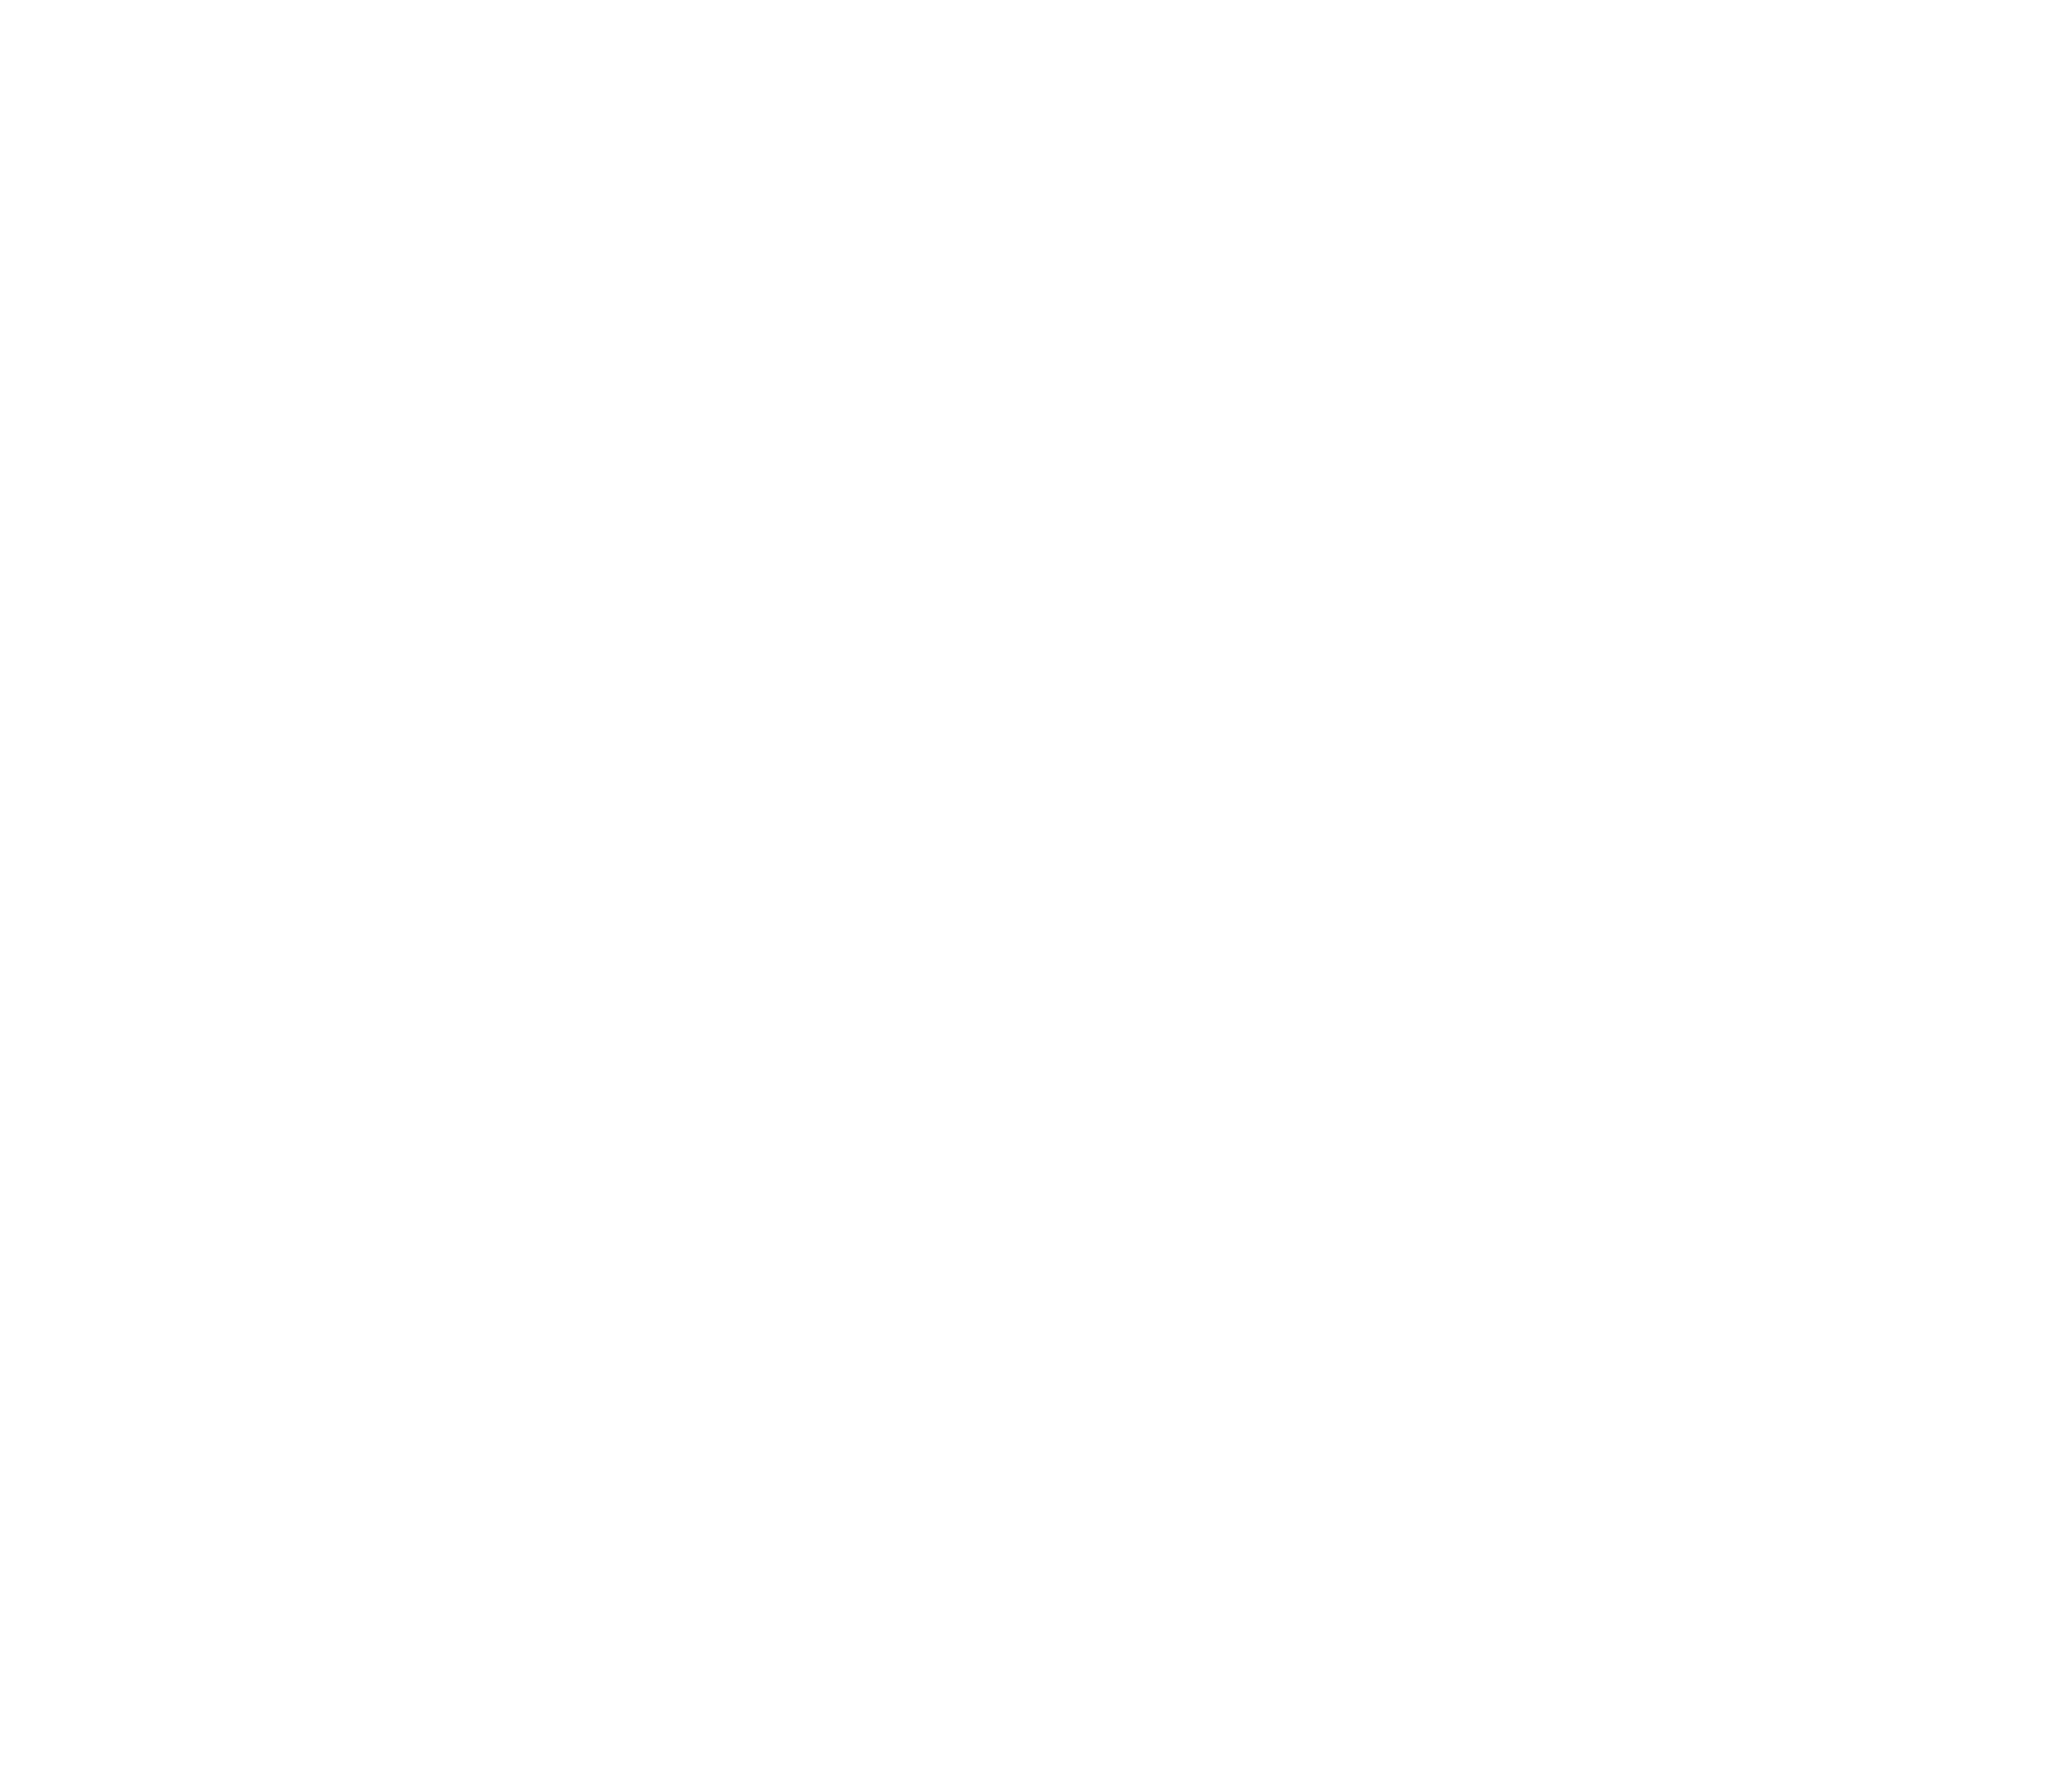

In [79]:
# Settings
n_bins = len(MgII_ReStacked_Wave_Continuum_Scaled_Array)
n_cols = int(np.ceil(np.sqrt(n_bins)))
n_rows = int(np.ceil(n_bins / n_cols))

# Increase figure size to enlarge individual panels
fig_Paper_Grid = plt.figure(figsize=(n_cols * 7.5, n_rows * 6.5))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Calculate the indices of the last three plots
last_three_indices = list(range(n_bins - 3, n_bins)) if n_bins >= 3 else list(range(n_bins))

# No need to pre-compute global min/max values since we're not sharing axes between plots

# Now create the plots with shared axes
for i in range(n_bins):
    x_data = MgII_ReStacked_Wave_Continuum_Scaled_Array[i]
    y_data = MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_Array[i]
    y_data_sd = MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_SD_Array[i] * 2
    y_best_fit = MgII_Continuum_Removed_ReStacked_Spec_BestFit_Scaled_Array[i]
    residuals = MgII_Continuum_Removed_ReStacked_Residuals_Continuum_Scaled_Array[i]
    y_data_narrow = MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Continuum_Scaled_Array[i]
    y_data_broad = MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Continuum_Scaled_Array[i]
    #y_data_expo = MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Expo_Continuum_Scaled_Array[i]
    center_narrow = MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Center_Continuum_Scaled_Array[i]
    center_broad = MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Center_Continuum_Scaled_Array[i]
    redshift_label = redshift_labels[i]

    # Create outer grid for rows and columns
    outer_gs = fig_Paper_Grid.add_gridspec(n_rows, n_cols, wspace=0.1, hspace=0.1)
    row, col = divmod(i, n_cols)

    # Determine whether to show x-tick labels for the bottom panel
    show_bottom_xticks = i in last_three_indices

    # Create subgridspec for top and bottom panels (model and residuals)
    inner_gs = outer_gs[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.15)

    # For the last three plots, don't share x-axis to avoid tick label conflicts
    ax_top = fig_Paper_Grid.add_subplot(inner_gs[0])
    ax_bottom = fig_Paper_Grid.add_subplot(inner_gs[1], sharex=ax_top)

    # --- Top Panel (Model) ---
    ax_top.step(x_data, y_data, color="#60B5FF", linewidth=1.5, where="mid", zorder=0, linestyle='-', label="Observed Data")
    ax_top.fill_between(x_data, y_data - y_data_sd, 
                 y_data + y_data_sd, color="#60B5FF", alpha=0.3, zorder=0, step='mid', label=r"2$\sigma$ Error")
    
    ax_top.plot(x_data, y_best_fit, color="black", linewidth=2.5, label="Combined Model Fit", zorder=4, linestyle='-')
    ax_top.plot(x_data, y_data_narrow, color="#a714ff", linewidth=4.5, label="Narrow Component", zorder=2, linestyle='-')
    ax_top.plot(x_data, y_data_broad, color="#ff14f5", linewidth=4.5, label="Broad Component", zorder=3, linestyle='-')

    ax_top.plot(x_data, np.full(len(x_data), 0), color='#ffbb14', linestyle='-', linewidth=4.5, zorder=1, label="Exponential Component")
    #ax_top.plot(x_data, y_data_expo, '-', linewidth=3.0, color='#ffbb14', label='Exponential component', zorder=1)

    # Mark the centers of the Gaussian components
    ax_top.axvline(x=center_narrow, color='#a714ff', linestyle=':', alpha=0.7)
    ax_top.axvline(x=center_broad, color='#ff14f5', linestyle=':', alpha=0.7)

    ax_top.text(0.02, 0.96, redshift_label, transform=ax_top.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black'))
    
    # Only show legend on the first panel (top-left)
    if i == 0:
        ax_top.legend(loc='upper right', fontsize=12, frameon=True, fancybox=True, shadow=True,
                      borderpad=0.5, edgecolor='black', facecolor='w',
                      handlelength=1.0, columnspacing=0.5, handleheight=1.0, labelspacing=0.25)

    # Always define the labels, but they'll only be displayed based on position
    ax_top.set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', size='14', color="black")
    
    # Set individual panel limits
    ymin, ymax = ax_top.get_ylim()
    ax_top.set_ylim(ymin, ymax * 1.07)
    
    # Always hide x-tick labels on top panels
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # --- Bottom Panel (Residuals) ---
    ax_bottom.scatter(x_data, residuals, c="#00FF9C", edgecolor="black", s=20, label="Residuals", marker='o')
    ax_bottom.fill_between(x_data, 0 - y_data_sd, 
                 0 + y_data_sd, color="#60B5FF", alpha=0.3, zorder=0)

    ax_bottom.axhline(0, color="#000000", linestyle='--', linewidth=1.5)    
    
    # Set x-axis label for all bottom panels
    ax_bottom.set_xlabel(r"Rest Wavelength [$\AA$]", fontsize=14)
    ax_bottom.set_ylabel("Residuals", fontsize=14)
    
    # Hide x-tick labels on bottom panels except for the last three plots
    if not show_bottom_xticks:
        plt.setp(ax_bottom.get_xticklabels(), visible=False)
    
    # Set specific y-limits for residuals in first row (row=0), first column (col=0)
    if row == 0 and (col == 0):
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.40*1e-16, 0.40*1e-16)

    # Set specific y-limits for residuals in first row (row=0), second and third columns (col=1, col=2)
    if row == 0 and (col == 1):
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.10*1e-16, 0.10*1e-16)

    # Set specific y-limits for residuals in first row (row=0), second and third columns (col=1, col=2)
    if row == 0 and (col == 2):
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.15*1e-16, 0.15*1e-16)

    # Set specific y-limits for residuals in first row (row=0), second and third columns (col=1, col=2)
    if row == 1 and (col == 0):
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.20*1e-16, 0.20*1e-16)

    # Set specific y-limits for residuals in first row (row=0), second and third columns (col=1, col=2)
    if row == 1 and (col == 1):
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.15*1e-16, 0.15*1e-16)

    # Set specific y-limits for residuals in second row (row=1), third column (col=2)
    if row == 1 and col == 2:
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_bottom.set_ylim(-0.15*1e-16, 0.15*1e-16)

    # Set specific y-limits for residuals in second row (row=1), third column (col=2)
    if row == 2 and col == 0:
        # Set y-limit to ensure there are tick values above zero
        # Adjust these values as needed based on your data range
        ax_top.set_ylim(-0.5e-16, 1.5e-16)
        ax_bottom.set_ylim(-0.25*1e-16, 0.25*1e-16)
        
        ax_top.set_xlim(2550, 2960)
        ax_bottom.set_xlim(2550, 2960)
    
    ax_bottom.grid(True)

    # --- Styling for both axes ---
    for ax in [ax_top, ax_bottom]:
        ax.spines['top'].set_linewidth(2.5)
        ax.spines['right'].set_linewidth(2.5)
        ax.spines['left'].set_linewidth(2.5)
        ax.spines['bottom'].set_linewidth(2.5)
        ax.tick_params(axis='both', which='major', width=2, labelsize=12)
        ax.tick_params(axis='both', which='minor', width=1, labelsize=10)
        ax.tick_params(axis='both', which='both', direction='in', length=6)
    
    # Only show y-axis labels on leftmost panels
    if col != 0:
        ax_top.set_ylabel("")
        ax_bottom.set_ylabel("")
        ax_top.set_xticklabels([])
        
    # Show x-axis labels on bottom row panels and specific panels in row 1, columns 1 and 2
    # Note: row and col are zero-indexed, so row=1 is second row, col=1 is second column, col=2 is third column
    if row != n_rows - 1 and not (row == 1 and (col == 1 or col == 2)) and not show_bottom_xticks:
        ax_bottom.set_xlabel("")
    
    # Final check for visibility
    if show_bottom_xticks:
        # Make sure x-tick labels are visible on bottom panel
        ax_bottom.xaxis.set_tick_params(labelbottom=True)
        plt.setp(ax_bottom.get_xticklabels(), visible=True)
        # Force matplotlib to draw the ticks
        ax_bottom.xaxis.set_major_formatter(plt.ScalarFormatter())
    else:
        # Hide x-tick labels on bottom panel
        ax_bottom.xaxis.set_tick_params(labelbottom=False)
        plt.setp(ax_bottom.get_xticklabels(), visible=False)
    
# Final layout adjustments
plt.tight_layout()

# One final pass to ensure the last three plots have visible x-tick labels
for i in last_three_indices:
    row, col = divmod(i, n_cols)
    ax = plt.gcf().get_axes()[i*2 + 1]  # Get the bottom panel of the i-th plot
    ax.xaxis.set_tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), visible=True)

In [80]:
def calculate_simple_mean_with_std(values, std_values):
    """
    Calculate simple mean and its standard deviation using error propagation.
    
    Parameters
    ----------
    values : array-like
        Array of measurement values.
    std_values : array-like
        Array of standard deviations for each measurement value.
        
    Returns
    -------
    mean_value : float
        Simple mean of the input values.
    mean_std : float
        Standard deviation of the mean.
    """
    # Convert inputs to numpy arrays if they aren't already
    values = np.array(values)
    std_values = np.array(std_values)
    
    # Calculate simple mean
    mean_value = np.mean(values)
    
    # Calculate standard deviation of the mean using error propagation
    # For a mean of measurements with individual uncertainties:
    # σ_mean = sqrt(sum(σ_i²)) / n
    n = len(values)
    mean_std = np.sqrt(np.sum(std_values**2)) / n
    
    # Alternative: standard error of the mean if your std_values are not measurement errors
    # but rather standard deviations of the sample
    # mean_std_alt = np.std(values, ddof=1) / np.sqrt(n)
    
    return mean_value, mean_std



def calculate_simple_median_with_std(values, std_values):
    """
    Calculate simple median and its standard deviation using asymptotic formula.
    
    Parameters
    ----------
    values : array-like
        Array of measurement values.
    std_values : array-like
        Array of standard deviations for each measurement value.
        
    Returns
    -------
    median_value : float
        Simple median of the input values.
    median_std : float
        Standard deviation of the median.
    """
    # Convert inputs to numpy arrays if they aren't already
    values = np.array(values)
    std_values = np.array(std_values)
    
    # Calculate simple median
    median_value = np.median(values)
    
    # Calculate standard deviation of the median using asymptotic approximation
    n = len(values)
    median_std = 1.253 * np.std(values, ddof=1) / np.sqrt(n)
    
    return median_value, median_std

    

## <font color='#00879E' size=5 >Fitting (in velocity) the MgII emission from the continuum subtract spectra. </font>

In [81]:
"""
Getting the Median of the center of the narrow and the broad from the Fit_MgII_Spectrum.
Then getting the velocity of the line.
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_025_035 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_025_035]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_025_035]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_035_045 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_035_045]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_045_055 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_045_055]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_045_055]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_055_065 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_055_065]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_055_065]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_065_075 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_065_075]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_065_075]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_075_085 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_075_085]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_075_085]))

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_085_096 = calculate_simple_median_with_std(
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_085_096]), 
                                                                                                                            ([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_085_096]))





MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_025_035, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_035_045, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_045_055, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_055_065, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_065_075, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_075_085, 
                                                                                                                 MgII_doublet_unresolved)

MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096 = velocity_of_the_center(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_085_096, 
                                                                                                                 MgII_doublet_unresolved)




"""
These are the rest wavelengths in angstroms for the lines that are important for the fits.
"""
HeII_2733 = 2733.289
MgII_2800 = 2799.000
FeIV_2829 = 2829.36
FeIV_2836 = 2835.740
ArIV_2854 = 2853.670
ArIV_2868 = 2868.210

NameError: name 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_025_035' is not defined

In [82]:
"""
Getting the velocity centered at zero.
"""
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_025_035, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_035_045, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_045_055, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_055_065, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_065_075, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_075_085, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(MgII_ReStacked_Wave_Continuum_Scaled_085_096, MgII_doublet_unresolved, 
                                                                                                                                                         MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)


##################################################################################################################################################################################
HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    HeII_2733, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)
##################################################################################################################################################################################
FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    FeII_2749, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)
##################################################################################################################################################################################
FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    FeII_2755, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)
##################################################################################################################################################################################
FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    FeIV_2829, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)

##################################################################################################################################################################################
FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    FeIV_2836, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)

##################################################################################################################################################################################
ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    ArIV_2854, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)

##################################################################################################################################################################################
ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_025_035, MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_035_045, MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_045_055, MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_055_065, MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_065_075, MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_075_085, MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085)

ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096 = velocity_shift_of_center_to_zero(
    ArIV_2868, MgII_doublet_unresolved, MgII_ReStacked_Continuum_Scaled_Velocity_085_096, MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096)


NameError: name 'MgII_ReStacked_Continuum_Scaled_Velocity_025_035' is not defined

In [83]:
#MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_Array = [
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096]

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_Array = [
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096]

MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_Array = [
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085*2,
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096*2]

#print(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_Array)



class InteractivePlotter_c:
    def __init__(self, plots_data, spectral_lines):
        self.plots_data = plots_data
        self.spectral_lines = spectral_lines
        self.current_index = 0
        self.num_spectra = len(plots_data)
        
        self.zoom_level = 1.0
        self.x_offset = 0
        self.y_offset = 0
        
        self.show_error = True
        self.show_lines = True
        self.show_line_labels = True
        
        self.fig = plt.figure(figsize=(14, 8))
        self.ax = plt.subplot2grid((6, 6), (0, 0), colspan=5, rowspan=5)
        
        self.update_plot()
        
        ax_prev = plt.subplot2grid((6, 6), (5, 0), colspan=1)
        ax_next = plt.subplot2grid((6, 6), (5, 1), colspan=1)
        
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_spectrum)
        self.btn_next.on_clicked(self.next_spectrum)
                        
        ax_counter = plt.subplot2grid((6, 6), (5, 2), colspan=2)
        ax_counter.axis('off')
        self.counter_text = ax_counter.text(0.5, 0.5, '', ha='center', va='center',
                                            fontsize=12, weight='bold', transform=ax_counter.transAxes)
        self.update_counter()
        plt.subplots_adjust(hspace=0.4, wspace=0.4)
        
    def get_line_pattern(self, linestyle):
        patterns = {'-.': 'dashdot', '--': 'dashed', ':': 'dotted', '-': 'solid'}
        return patterns.get(linestyle, 'dashed')
        
    def update_plot(self):
        self.ax.clear()
        if self.num_spectra == 0:
            return
        
        vel, flux, flux_err = self.plots_data[self.current_index]
        


        wave_range = np.max(vel) - np.min(vel)
        flux_range = np.max(flux) - np.min(flux)
        x_center = np.mean(vel) + self.x_offset
        y_center = np.mean(flux) + self.y_offset
        x_half_width = (wave_range / 2) / self.zoom_level
        y_half_width = (flux_range / 2) / self.zoom_level
        
        self.ax.plot(vel, flux, 'k-', linewidth=1.5, label='Spectrum', zorder=2)

        if self.show_error:
            self.ax.fill_between(vel, flux - flux_err, flux + flux_err, 
                                alpha=0.3, color='gray', label='±1σ', zorder=1)
            
        if self.show_lines:
            ylim = self.ax.get_ylim()
            for wavelength, line_info in self.spectral_lines.items():
                color, linestyle, label, linewidth = line_info
                if np.min(vel) <= wavelength <= np.max(vel):
                    pattern = self.get_line_pattern(linestyle)
                    self.ax.axvline(wavelength, color=color, linestyle=pattern, 
                                   linewidth=linewidth, alpha=0.7, zorder=3)
                    if self.show_line_labels:
                        y_pos = ylim[0] + 0.95 * (ylim[1] - ylim[0])
                        self.ax.text(wavelength, y_pos, label, rotation=90, va='top', 
                                   ha='right', fontsize=9, color=color, weight='bold')
        
        self.ax.set_xlabel('velocity [km/s]', fontsize=12, weight='bold')
        self.ax.set_ylabel('Flux', fontsize=12, weight='bold')
        #self.ax.set_title(f'Spectrum: {name}', fontsize=14, weight='bold', pad=10)
        #self.ax.set_xlim(x_center - x_half_width, x_center + x_half_width)
        #self.ax.set_ylim(y_center - y_half_width, y_center + y_half_width)
        self.ax.grid(True, alpha=0.3, linestyle='--')
        self.ax.legend(loc='upper right', fontsize=10)
        self.fig.canvas.draw_idle()
    
    def prev_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index - 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def next_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index + 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def update_counter(self):
        if self.num_spectra > 0:
            self.counter_text.set_text(f'Spectrum {self.current_index + 1} / {self.num_spectra}')
        else:
            self.counter_text.set_text('No spectra')
        self.fig.canvas.draw_idle()
    
    def show(self):
        plt.show()






# Your spectral lines are already defined
spectral_lines = {
    0.0: ('#8B3D88', '--', 'MgII', 3)
}

# Your data preparation code
Plots_For_Interactive_Plotting = []   
for j in np.arange(len(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_Array)):
    vel_spec_interactive = MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_Array[j]
    spec_vel_interactive = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_Array[j]
    spec_vel_sd_interactive = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_Array[j]
    Plots_For_Interactive_Plotting.append([vel_spec_interactive,
                                            spec_vel_interactive,
                                            spec_vel_sd_interactive
                                            ])

# Create and display the interactive plotter
plotter = InteractivePlotter_c(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()




NameError: name 'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035' is not defined

In [84]:
def find_emission_line_bounds(velocity, flux, 
                             sigma_threshold=3.0, 
                             min_velocity_width=200, 
                             max_velocity_width=500,
                             fractional_intensity=0.05,
                             continuum_regions=None,
                             smooth_kernel_size=3,
                             return_diagnostics=False):
    """
    Determine the boundaries of an emission line for spectral masking using velocity arrays.
    
    This function implements a multi-criteria approach combining:
    - Signal-to-noise ratio thresholding
    - Velocity-based limits
    - Fractional peak intensity
    - Derivative-based detection
    
    Parameters:
    -----------
    velocity : array-like
        Velocity array in km/s (relative to line center, typically centered at 0)
    flux : array-like
        Flux array corresponding to velocity
    sigma_threshold : float, default=3.0
        Number of sigma above continuum noise for detection
    min_velocity_width : float, default=200
        Minimum velocity width (km/s) to include around line center (±km/s)
    max_velocity_width : float, default=500
        Maximum velocity width (km/s) to consider for line boundaries (±km/s)
    fractional_intensity : float, default=0.05
        Fraction of peak intensity (0.05 = 5%) for boundary detection
    continuum_regions : list of tuples, optional
        [(vel_start1, vel_end1), (vel_start2, vel_end2)] for continuum estimation
        If None, uses regions far from the line center (> max_velocity_width * 1.5)
    smooth_kernel_size : int, default=3
        Size of smoothing kernel for derivative calculation
    return_diagnostics : bool, default=False
        If True, returns additional diagnostic information
    
    Returns:
    --------
    bounds : tuple
        (lower_velocity, upper_velocity) defining the emission line region in km/s
    diagnostics : dict (optional)
        Dictionary containing diagnostic information if return_diagnostics=True
    """
    
    # Convert to numpy arrays
    velocity = np.array(velocity)
    flux = np.array(flux)
    
    # Define search region based on maximum velocity width
    search_mask = np.abs(velocity) <= max_velocity_width
    search_indices = np.where(search_mask)[0]
    
    if len(search_indices) < 10:
        raise ValueError("Search region too small. Check velocity range and max_velocity_width.")
    
    # Estimate continuum and noise
    if continuum_regions is None:
        # Automatically define continuum regions far from the line center
        continuum_mask = np.abs(velocity) > max_velocity_width * 1.5
        if np.sum(continuum_mask) < 20:
            # Fallback: use outer regions of the velocity array
            n_points = len(flux)
            edge_fraction = 0.1
            continuum_mask = np.zeros(n_points, dtype=bool)
            continuum_mask[:int(n_points * edge_fraction)] = True
            continuum_mask[-int(n_points * edge_fraction):] = True
    else:
        continuum_mask = np.zeros(len(velocity), dtype=bool)
        for vel_start, vel_end in continuum_regions:
            region_mask = (velocity >= vel_start) & (velocity <= vel_end)
            continuum_mask |= region_mask
    
    # Calculate continuum level and noise
    continuum_flux = flux[continuum_mask]
    if len(continuum_flux) < 5:
        warnings.warn("Very few continuum points available. Results may be unreliable.")
        continuum_level = np.median(flux)
        noise_level = np.std(flux) * 0.1  # Conservative estimate
    else:
        continuum_level = np.median(continuum_flux)
        # Use median absolute deviation for robust noise estimation
        noise_level = median_abs_deviation(continuum_flux, scale='normal')
    
    # Method 1: Signal-to-noise threshold
    snr_threshold = continuum_level + sigma_threshold * noise_level
    snr_mask = flux > snr_threshold
    
    # Method 2: Find peak and apply fractional intensity threshold
    search_flux = flux[search_mask]
    peak_idx_local = np.argmax(search_flux)
    peak_idx_global = search_indices[peak_idx_local]
    peak_flux = flux[peak_idx_global]
    
    fractional_threshold = continuum_level + fractional_intensity * (peak_flux - continuum_level)
    fractional_mask = flux > fractional_threshold
    
    # Method 3: Derivative-based detection (smoothed)
    if smooth_kernel_size > 1:
        smoothed_flux = ndimage.uniform_filter1d(flux, smooth_kernel_size)
    else:
        smoothed_flux = flux.copy()
    
    # Calculate derivative
    derivative = np.gradient(smoothed_flux, velocity)
    derivative_threshold = 3 * np.std(derivative[continuum_mask])
    
    # Find regions where derivative is significant
    significant_derivative = np.abs(derivative) > derivative_threshold
    
    # Combine all methods
    # Start with SNR detection as primary criterion
    combined_mask = snr_mask.copy()
    
    # Expand to include fractional intensity regions
    combined_mask |= fractional_mask
    
    # Further expand to include significant derivative regions near the line
    nearby_mask = np.abs(velocity) <= max_velocity_width
    combined_mask |= (significant_derivative & nearby_mask)
    
    # Find connected components and select the one containing the peak
    labeled_regions, n_regions = ndimage.label(combined_mask)
    
    if n_regions == 0:
        # Fallback: use minimum velocity width around peak
        peak_velocity = velocity[peak_idx_global]
        min_vel_mask = np.abs(velocity - peak_velocity) <= min_velocity_width
        bounds_indices = np.where(min_vel_mask)[0]
        lower_bound = velocity[bounds_indices[0]]
        upper_bound = velocity[bounds_indices[-1]]
    else:
        # Select region containing the peak
        peak_region_label = labeled_regions[peak_idx_global]
        if peak_region_label == 0:
            # Peak not in any detected region, use closest region
            region_centers = []
            for i in range(1, n_regions + 1):
                region_indices = np.where(labeled_regions == i)[0]
                region_center = np.mean(region_indices)
                region_centers.append((i, region_center))
            
            # Find closest region to peak
            distances = [abs(center - peak_idx_global) for _, center in region_centers]
            closest_region_idx = np.argmin(distances)
            peak_region_label = region_centers[closest_region_idx][0]
        
        # Get boundaries of the selected region
        region_mask = labeled_regions == peak_region_label
        region_indices = np.where(region_mask)[0]
        
        # Ensure minimum velocity width
        peak_velocity = velocity[peak_idx_global]
        min_lower_vel = peak_velocity - min_velocity_width
        min_upper_vel = peak_velocity + min_velocity_width
        
        # Get actual bounds
        lower_bound = velocity[region_indices[0]]
        upper_bound = velocity[region_indices[-1]]
        
        # Apply minimum width constraint
        lower_bound = min(lower_bound, min_lower_vel)
        upper_bound = max(upper_bound, min_upper_vel)
        
        # Apply maximum width constraint
        max_lower_vel = peak_velocity - max_velocity_width
        max_upper_vel = peak_velocity + max_velocity_width
        
        lower_bound = max(lower_bound, max_lower_vel)
        upper_bound = min(upper_bound, max_upper_vel)
    
    bounds = (lower_bound, upper_bound)
    
    if return_diagnostics:
        # Calculate final velocity range
        final_lower_vel = lower_bound
        final_upper_vel = upper_bound
        
        diagnostics = {
            'continuum_level': continuum_level,
            'noise_level': noise_level,
            'snr_threshold': snr_threshold,
            'peak_flux': peak_flux,
            'fractional_threshold': fractional_threshold,
            'peak_velocity': velocity[peak_idx_global],
            'velocity_range_km_s': (final_lower_vel, final_upper_vel),
            'line_width_km_s': final_upper_vel - final_lower_vel,
            'masks': {
                'snr_mask': snr_mask,
                'fractional_mask': fractional_mask,
                'derivative_mask': significant_derivative,
                'combined_mask': combined_mask,
                'final_mask': (velocity >= lower_bound) & (velocity <= upper_bound)
            }
        }
        return bounds, diagnostics
    
    return bounds



    
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, 
                                sigma_threshold=3.0, 
                                min_velocity_width=200, 
                                max_velocity_width=20000,
                                fractional_intensity=0.05,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)


NameError: name 'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035' is not defined

## <font color='#00879E' size=5 >Fitting (in velocity) the MgII emission from the continuum subtract spectra. </font>

In [85]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035 = fit_MgII_spectrum_velocity(
            MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,
            MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035,
            y_err = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2,
            g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.70,
            g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.4,
            g1_sigma=900,              # Set narrow component width
            g2_sigma=5000,             # Set broad component width
            g1_center=100,          # Set narrow component center
            g2_center=-550,          # Set broad component center
            g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.5, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
            g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),      
            g1_sigma_bounds=(0, 7000),  # Set bounds for narrow component width
            g2_sigma_bounds=(0, 5450),    # Set bounds for broad component width
            g1_center_bounds=(-800, 500),
            g2_center_bounds=(-1000, 500),
            title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.25 $\leq$ z $\less$ 0.35)",
            n_random_starts=150,  # Number of random starting points to try
            use_grid_search=True,  # Whether to use grid search in addition to random starts
            use_differential_evolution=True,  # Whether to use differential evolution
            verbose=True,
            mask_ranges=([
                (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[0]),
                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035))]),
            plot=True
)


NameError: name 'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035' is not defined

In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.70,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.25,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4000,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.7, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.9),
    g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.40),      
    g1_sigma_bounds=(0, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(2000, 3000),    # Set bounds for broad component width
    g1_center_bounds=(-200, 500),
    g2_center_bounds=(-1, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.35 $\leq$ z $\less$ 0.45)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045))]),
    plot=True
)

In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.80,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.15,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.65, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.45),      
    g1_sigma_bounds=(0, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 4000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.45 $\leq$ z $\less$ 0.55)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055))]),
    plot=True
)


In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.65,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.20,
    g1_sigma=1000,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=50,          # Set narrow component center
    g2_center=-100,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.45, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.35),      
    g1_sigma_bounds=(0, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 4800),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.55 $\leq$ z $\less$ 0.65)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065))]),
    plot=True
)


In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.23,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.25),      
    g1_sigma_bounds=(0, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 5000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.65 $\leq$ z $\less$ 0.75)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075))]),
    plot=True
)


In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.25,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4800,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),      
    g1_sigma_bounds=(0, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 30000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.75 $\leq$ z $\less$ 0.85)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085))]),
    plot=True
)

In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.63,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.37,
    g1_sigma=1100,              # Set narrow component width
    g2_sigma=4800,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.4, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.6),      
    g1_sigma_bounds=(0, 2000),  # Set bounds for narrow component width
    g2_sigma_bounds=(0, 6000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model (0.85 $\leq$ z $\leq$ 0.96)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096))]),
    plot=True
)


plt.xlim(-20000, 15000)  # Set your desired limits
#plt.ylim(-0.5e-16, 1.25e-16)

# Get current axes and set limits
fig = plt.gcf()  # Get current figure
axes = fig.get_axes()  # Get all axes

axes[0].set_ylim(-0.5e-16, 1.5e-16)  # Set y-limits for first panel (adjust values as needed)
axes[1].set_ylim(-0.3e-16, 0.3e-16)  # Set y-limits for second panel (adjust values as needed)


In [ ]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Velocity_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096['uncertainties']['g2_amplitude']



In [ ]:
print(len(Z_025_035))

# <font color='#e55730' size=5 >Calculating the BHmass</font>

## <font color='#00879E' size=5 >Getting the proper motion distance and the luminosity distance given redshift</font>

In [ ]:
"""
This is getting the proper motion distance and its standard deviation for each of the redshift values in each of the redshift bins.

Paper
-----
https://arxiv.org/pdf/astro-ph/9905116
"""
DM_Array_025_035, DM_SD_Array_025_035 = DM_Multiple(Z_025_035)
DM_Array_035_045, DM_SD_Array_035_045 = DM_Multiple(Z_035_045)
DM_Array_045_055, DM_SD_Array_045_055 = DM_Multiple(Z_045_055)
DM_Array_055_065, DM_SD_Array_055_065 = DM_Multiple(Z_055_065)
DM_Array_065_075, DM_SD_Array_065_075 = DM_Multiple(Z_065_075)
DM_Array_075_085, DM_SD_Array_075_085 = DM_Multiple(Z_075_085)
DM_Array_085_096, DM_SD_Array_085_096 = DM_Multiple(Z_085_096)


In [ ]:
"""
This is getting the Luminosity distances for the redshifts in each of the bins given the proper motion distance and redshift.

Paper
-----
https://arxiv.org/pdf/astro-ph/9905116
"""
DL_Array_025_035, DL_SD_Array_025_035 = DL(DM_Array_025_035, DM_SD_Array_025_035, Z_025_035)
DL_Array_035_045, DL_SD_Array_035_045 = DL(DM_Array_035_045, DM_SD_Array_035_045, Z_035_045)
DL_Array_045_055, DL_SD_Array_045_055 = DL(DM_Array_045_055, DM_SD_Array_045_055, Z_045_055)
DL_Array_055_065, DL_SD_Array_055_065 = DL(DM_Array_055_065, DM_SD_Array_055_065, Z_055_065)
DL_Array_065_075, DL_SD_Array_065_075 = DL(DM_Array_065_075, DM_SD_Array_065_075, Z_065_075)
DL_Array_075_085, DL_SD_Array_075_085 = DL(DM_Array_075_085, DM_SD_Array_075_085, Z_075_085)
DL_Array_085_096, DL_SD_Array_085_096 = DL(DM_Array_085_096, DM_SD_Array_085_096, Z_085_096)

print(DL_Array_025_035)
print(len(DM_SD_Array_025_035))
print(len(Z_025_035))

In [ ]:
#Turning the DL units from MpC to C M
"""
This turns the luminosity distances from MpC to cm.

MpC to cm = 3.086e24
"""
DL_Array_cm_025_035, DL_SD_cm_Array_025_035 = np.multiply(DL_Array_025_035 , 3.086e24), np.multiply(DL_SD_Array_025_035 , 3.086e24)
DL_Array_cm_035_045, DL_SD_cm_Array_035_045 = np.multiply(DL_Array_035_045 , 3.086e24), np.multiply(DL_SD_Array_035_045 , 3.086e24)
DL_Array_cm_045_055, DL_SD_cm_Array_045_055 = np.multiply(DL_Array_045_055 , 3.086e24), np.multiply(DL_SD_Array_045_055 , 3.086e24)
DL_Array_cm_055_065, DL_SD_cm_Array_055_065 = np.multiply(DL_Array_055_065 , 3.086e24), np.multiply(DL_SD_Array_055_065 , 3.086e24)
DL_Array_cm_065_075, DL_SD_cm_Array_065_075 = np.multiply(DL_Array_065_075 , 3.086e24), np.multiply(DL_SD_Array_065_075 , 3.086e24)
DL_Array_cm_075_085, DL_SD_cm_Array_075_085 = np.multiply(DL_Array_075_085 , 3.086e24), np.multiply(DL_SD_Array_075_085 , 3.086e24)
DL_Array_cm_085_096, DL_SD_cm_Array_085_096 = np.multiply(DL_Array_085_096 , 3.086e24), np.multiply(DL_SD_Array_085_096 , 3.086e24)

print(len(DL_Array_025_035))
print(len(DL_Array_cm_025_035))

## <font color='#00879E' size=5 >Calculating the continuum luminosity at 3000 and 2000 angstroms</font>

In [ ]:
"""
This gets the continuum luminosity wave index.
Then getting the wavelength values for the index.
Finally, get the flux for these indexes.
"""
L_3000_Index_025_035 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_025_035))
L_3000_Index_035_045 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_035_045))
L_3000_Index_045_055 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_045_055))
L_3000_Index_055_065 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_055_065))
L_3000_Index_065_075 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_065_075))
L_3000_Index_075_085 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_075_085))
#L_3000_Index_085_096 = getting_the_L_3000_Index(np.array(Rest_Wavelengths_Array_085_096))  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""



L_3000_Waves_025_035 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_025_035), L_3000_Index_025_035)
L_3000_Waves_035_045 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_035_045), L_3000_Index_035_045)
L_3000_Waves_045_055 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_045_055), L_3000_Index_045_055)
L_3000_Waves_055_065 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_055_065), L_3000_Index_055_065)
L_3000_Waves_065_075 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_065_075), L_3000_Index_065_075)
L_3000_Waves_075_085 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_075_085), L_3000_Index_075_085)
#L_3000_Wave_085_096 = getting_the_L_3000_wave(np.array(Rest_Wavelengths_Array_085_096), L_3000_Index_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


L_3000_Flux_025_035, L_3000_Flux_SD_025_035 = getting_the_L_3000_flux(Rest_Flux_Density_Array_025_035, Rest_Flux_Density_Err_Array_025_035, L_3000_Index_025_035)
L_3000_Flux_035_045, L_3000_Flux_SD_035_045 = getting_the_L_3000_flux(Rest_Flux_Density_Array_035_045, Rest_Flux_Density_Err_Array_035_045, L_3000_Index_035_045)
L_3000_Flux_045_055, L_3000_Flux_SD_045_055 = getting_the_L_3000_flux(Rest_Flux_Density_Array_045_055, Rest_Flux_Density_Err_Array_045_055, L_3000_Index_045_055)
L_3000_Flux_055_065, L_3000_Flux_SD_055_065 = getting_the_L_3000_flux(Rest_Flux_Density_Array_055_065, Rest_Flux_Density_Err_Array_055_065, L_3000_Index_055_065)
L_3000_Flux_065_075, L_3000_Flux_SD_065_075 = getting_the_L_3000_flux(Rest_Flux_Density_Array_065_075, Rest_Flux_Density_Err_Array_065_075, L_3000_Index_065_075)
L_3000_Flux_075_085, L_3000_Flux_SD_075_085 = getting_the_L_3000_flux(Rest_Flux_Density_Array_075_085, Rest_Flux_Density_Err_Array_075_085, L_3000_Index_075_085)
#L_3000_Flux_085_096 = getting_the_L_3000_flux(Rest_Flux_Density_Array_085_096, L_3000_Index_085_096) """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


In [ ]:
print([item for inner_list in L_3000_Flux_025_035 for item in inner_list if item < 0])
print([item for inner_list in L_3000_Flux_035_045 for item in inner_list if item < 0])
print([item for inner_list in L_3000_Flux_045_055 for item in inner_list if item < 0])
print([item for inner_list in L_3000_Flux_055_065 for item in inner_list if item < 0])
print([item for inner_list in L_3000_Flux_065_075 for item in inner_list if item < 0])
print([item for inner_list in L_3000_Flux_075_085 for item in inner_list if item < 0])



In [ ]:
# Using extend()
L_3000_Wave_Array = []
L_3000_Wave_Array.extend(L_3000_Waves_025_035)
L_3000_Wave_Array.extend(L_3000_Waves_035_045)
L_3000_Wave_Array.extend(L_3000_Waves_045_055)
L_3000_Wave_Array.extend(L_3000_Waves_055_065)
L_3000_Wave_Array.extend(L_3000_Waves_065_075)
L_3000_Wave_Array.extend(L_3000_Waves_075_085)
#print(flattened_list_extend)

## Using list comprehension
#L_3000_Wave_Array = [item for sublist in [L_3000_Waves_025_035, 
#                                                     L_3000_Waves_035_045, 
#                                                     L_3000_Waves_045_055, 
#                                                     L_3000_Waves_055_065, 
#                                                     L_3000_Waves_065_075, 
#                                                     L_3000_Waves_075_085] for item in sublist]
L_3000_Flux_Array = []
L_3000_Flux_Array.extend(L_3000_Flux_025_035)
L_3000_Flux_Array.extend(L_3000_Flux_035_045)
L_3000_Flux_Array.extend(L_3000_Flux_045_055)
L_3000_Flux_Array.extend(L_3000_Flux_055_065)
L_3000_Flux_Array.extend(L_3000_Flux_065_075)
L_3000_Flux_Array.extend(L_3000_Flux_075_085)

L_3000_Wave_Flux_SD_Array = []
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_025_035)
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_035_045)
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_045_055)
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_055_065)
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_065_075)
L_3000_Wave_Flux_SD_Array.extend(L_3000_Flux_SD_075_085)





Rest_Wavelengths_Array_Array = []
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_025_035)
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_035_045)
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_045_055)
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_055_065)
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_065_075)
Rest_Wavelengths_Array_Array.extend(Rest_Wavelengths_Array_075_085)



Spec_Flux_Array = []
Spec_Flux_Array.extend(Rest_Flux_Density_Array_025_035)
Spec_Flux_Array.extend(Rest_Flux_Density_Array_035_045)
Spec_Flux_Array.extend(Rest_Flux_Density_Array_045_055)
Spec_Flux_Array.extend(Rest_Flux_Density_Array_055_065)
Spec_Flux_Array.extend(Rest_Flux_Density_Array_065_075)
Spec_Flux_Array.extend(Rest_Flux_Density_Array_075_085)


Rest_Flux_Density_Err_Array_Array = []
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_025_035)
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_035_045)
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_045_055)
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_055_065)
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_065_075)
Rest_Flux_Density_Err_Array_Array.extend(Rest_Flux_Density_Err_Array_075_085)



print(len(New_Y_For_NonStacked_Array))
print(len(L_3000_Wave_Array))
print(len(L_3000_Flux_Array))
print(len(L_3000_Wave_Flux_SD_Array))

print(len(Rest_Wavelengths_Array_Array))
print(len(Spec_Flux_Array))
print(len(Rest_Flux_Density_Err_Array_Array))


In [ ]:
"""
Here we are finding the wavelength index for the luminosity at 2000 angstroms. (Which AGN have rest wavelength values in the 2000 angstrom range.)
This is important, because not all of the AGN have wavelengths that extend into the 3000 angstrom range.
The results from this are used to find the relationship between 2000 angstrom continuum luminosity to 3000 angstrom continuum luminosity. That way we can determine the 3000 angstrom continuum luminosity for these AGN.
"""
L_2000_Index_025_035, L_2000_Wave_Index_025_035 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_025_035))
L_2000_Index_035_045, L_2000_Wave_Index_035_045 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_035_045))
L_2000_Index_045_055, L_2000_Wave_Index_045_055 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_045_055))
L_2000_Index_055_065, L_2000_Wave_Index_055_065 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_055_065))
L_2000_Index_065_075, L_2000_Wave_Index_065_075 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_065_075))
L_2000_Index_075_085, L_2000_Wave_Index_075_085 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_075_085))
L_2000_Index_085_096, L_2000_Wave_Index_085_096 = getting_the_L_2000_Index(np.array(Rest_Wavelengths_Array_085_096))


""" Getting the rest wavelegnth arrays for the AGN that have rest wavelengths with values in to 2000 angstrom range. """
L_2000_Waves_025_035 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_025_035), L_2000_Index_025_035)
L_2000_Waves_035_045 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_035_045), L_2000_Index_035_045)
L_2000_Waves_045_055 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_045_055), L_2000_Index_045_055)
L_2000_Waves_055_065 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_055_065), L_2000_Index_055_065)
L_2000_Waves_065_075 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_065_075), L_2000_Index_065_075)
L_2000_Waves_075_085 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_075_085), L_2000_Index_075_085)
L_2000_Waves_085_096 = getting_the_L_2000_waves(np.array(Rest_Wavelengths_Array_085_096), L_2000_Index_085_096)


"""Getting the flux arrays for the AGN that have rest wavelengths with values in the 2000 angstrom range."""
#L_2000_Flux_025_03, L_2000_Flux_SD_025_035 = getting_the_L_2000_flux(Rest_Flux_Density_Array_025_035, Rest_Flux_Density_Err_Array_025_035, L_2000_Index_025_035) """This is too low for the wavelength range."""
L_2000_Flux_035_045, L_2000_Flux_SD_035_045 = getting_the_L_2000_flux(Rest_Flux_Density_Array_035_045, Rest_Flux_Density_Err_Array_035_045, L_2000_Index_035_045)
L_2000_Flux_045_055, L_2000_Flux_SD_045_055 = getting_the_L_2000_flux(Rest_Flux_Density_Array_045_055, Rest_Flux_Density_Err_Array_045_055, L_2000_Index_045_055)
L_2000_Flux_055_065, L_2000_Flux_SD_055_065 = getting_the_L_2000_flux(Rest_Flux_Density_Array_055_065, Rest_Flux_Density_Err_Array_055_065, L_2000_Index_055_065)
L_2000_Flux_065_075, L_2000_Flux_SD_065_075 = getting_the_L_2000_flux(Rest_Flux_Density_Array_065_075, Rest_Flux_Density_Err_Array_065_075, L_2000_Index_065_075)
L_2000_Flux_075_085, L_2000_Flux_SD_075_085 = getting_the_L_2000_flux(Rest_Flux_Density_Array_075_085, Rest_Flux_Density_Err_Array_075_085, L_2000_Index_075_085)
L_2000_Flux_085_096, L_2000_Flux_SD_085_096 = getting_the_L_2000_flux(Rest_Flux_Density_Array_085_096, Rest_Flux_Density_Err_Array_085_096, L_2000_Index_085_096)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider, CheckButtons
import numpy as np

class InteractivePlotter_b:
    def __init__(self, plots_data, spectral_lines):
        self.plots_data = plots_data
        self.spectral_lines = spectral_lines
        self.current_index = 0
        self.num_spectra = len(plots_data)
        
        self.zoom_level = 1.0
        self.x_offset = 0
        self.y_offset = 0
        
        self.show_error = True
        self.show_lines = True
        self.show_line_labels = True
        
        self.fig = plt.figure(figsize=(14, 8))
        self.ax = plt.subplot2grid((6, 6), (0, 0), colspan=5, rowspan=5)
        
        self.update_plot()
        
        ax_prev = plt.subplot2grid((6, 6), (5, 0), colspan=1)
        ax_next = plt.subplot2grid((6, 6), (5, 1), colspan=1)
        
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_spectrum)
        self.btn_next.on_clicked(self.next_spectrum)
                        
        ax_counter = plt.subplot2grid((6, 6), (5, 2), colspan=2)
        ax_counter.axis('off')
        self.counter_text = ax_counter.text(0.5, 0.5, '', ha='center', va='center',
                                            fontsize=12, weight='bold', transform=ax_counter.transAxes)
        self.update_counter()
        plt.subplots_adjust(hspace=0.4, wspace=0.4)
        
    def get_line_pattern(self, linestyle):
        patterns = {'-.': 'dashdot', '--': 'dashed', ':': 'dotted', '-': 'solid'}
        return patterns.get(linestyle, 'dashed')
        
    def update_plot(self):
        self.ax.clear()
        if self.num_spectra == 0:
            return
        
        wave, flux, flux_err, l_300_wave, l_3000_flux, l_3000_flux_err, name = self.plots_data[self.current_index]
        
        wave_range = np.max(wave) - np.min(wave)
        flux_range = np.max(flux) - np.min(flux)
        x_center = np.mean(wave) + self.x_offset
        y_center = np.mean(flux) + self.y_offset
        x_half_width = (wave_range / 2) / self.zoom_level
        y_half_width = (flux_range / 2) / self.zoom_level
        
        self.ax.plot(wave, flux, 'k-', linewidth=1.5, label='Spectrum', zorder=2)
        self.ax.plot(l_300_wave, l_3000_flux, color="Red", linewidth=2.5, label="L_300", zorder=5)


        if self.show_error:
            self.ax.fill_between(wave, flux - flux_err, flux + flux_err, 
                                alpha=0.3, color='gray', label='±1σ', zorder=1)
        if self.show_error:
            self.ax.fill_between(l_300_wave, l_3000_flux - l_3000_flux_err, l_3000_flux + l_3000_flux_err, 
                                alpha=0.3, color='gray', label='±1σ', zorder=1)
            
        if self.show_lines:
            ylim = self.ax.get_ylim()
            for wavelength, line_info in self.spectral_lines.items():
                color, linestyle, label, linewidth = line_info
                if np.min(wave) <= wavelength <= np.max(wave):
                    pattern = self.get_line_pattern(linestyle)
                    self.ax.axvline(wavelength, color=color, linestyle=pattern, 
                                   linewidth=linewidth, alpha=0.7, zorder=3)
                    if self.show_line_labels:
                        y_pos = ylim[0] + 0.95 * (ylim[1] - ylim[0])
                        self.ax.text(wavelength, y_pos, label, rotation=90, va='top', 
                                   ha='right', fontsize=9, color=color, weight='bold')
        
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, weight='bold')
        self.ax.set_ylabel('Flux', fontsize=12, weight='bold')
        self.ax.set_title(f'Spectrum: {name}', fontsize=14, weight='bold', pad=10)
        #self.ax.set_xlim(x_center - x_half_width, x_center + x_half_width)
        #self.ax.set_ylim(y_center - y_half_width, y_center + y_half_width)
        self.ax.grid(True, alpha=0.3, linestyle='--')
        self.ax.legend(loc='upper right', fontsize=10)
        self.fig.canvas.draw_idle()
    
    def prev_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index - 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def next_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index + 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def update_counter(self):
        if self.num_spectra > 0:
            self.counter_text.set_text(f'Spectrum {self.current_index + 1} / {self.num_spectra}')
        else:
            self.counter_text.set_text('No spectra')
        self.fig.canvas.draw_idle()
    
    def show(self):
        plt.show()






# Your spectral lines are already defined
spectral_lines = {
    1892.030: ('#309898', '-.', 'SiIII', 3),
    1908.734: ('#FF9F00', '--', 'CIII', 3),
    2142.780: ('#CB0404', '-.', 'NII', 3),
    2320.951: ('#1D5799', ':', 'OIII', 3),
    2733.289: ('red', '-.', 'HeII', 3),
    2799.000: ('#8B3D88', '--', 'MgII', 3),
    2829.360: ('blue', '-.' ,'FeIV', 3),
    2835.740: ('orange', ':' ,'FeIV', 3),
    2853.670: ('green', '--' ,'ArIV', 3),
    2868.210: ('pink', '-.' ,'ARIV', 3),
    2945.106: ('#74B741', '--', 'HeI', 3),
    3132.794: ('#DB3EB1', ':', 'OIII', 3),
    2648.710: ('black', '-', 'Fe XI', 3)
}

# Your data preparation code
Plots_For_Interactive_Plotting = []   
for j in np.arange(len(Rest_Wavelengths_Array_Array)):
    wave_spec_interactive = Rest_Wavelengths_Array_Array[j]
    Rest_Flux_Density_Array_interactive = Spec_Flux_Array[j]
    Rest_Flux_Density_Err_Array_interactive = Rest_Flux_Density_Err_Array[j]
    names_interactive = Detect_ID_Names[j]
    l_300_wave = L_3000_Wave_Array[j]
    l_3000_flux = L_3000_Flux_Array[j]
    l_3000_flux_err = L_3000_Wave_Flux_SD_Array[j]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive,
                                            Rest_Flux_Density_Array_interactive,
                                            Rest_Flux_Density_Err_Array_interactive,
                                            l_300_wave,
                                            l_3000_flux,
                                            l_3000_flux_err, 
                                            names_interactive])

# Create and display the interactive plotter
plotter = InteractivePlotter_b(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()



In [ ]:
def process_single_spectrum(args):
    """
    Process a single spectrum, returning only picklable objects
    
    Parameters
    ----------
    args : tuple
        Tuple containing (idx, wave, spec, spec_std, scaling_factor)
        
    Returns
    -------
    dict
        Dictionary containing results for this spectrum (without Spectrum1D object)
    """
    idx, wave, spec, spec_std, scaling_factor = args
    
    # Handle NaN values in spectrum
    spec = np.where(np.isnan(spec), 0, spec)
    
    # Create Spectrum1D object
    spectrum = Spectrum1D(spec * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
                         wave * u.angstrom)
    
    # Fit continuum while suppressing warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        continuum_fit = fit_generic_continuum(
            spectrum, 
            model=models.Chebyshev1D(4), 
            exclude_regions=[SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
        )
    
    # Evaluate the fitted continuum model
    y_continuum = continuum_fit(wave * u.angstrom)
    y_continuum_original_scale = y_continuum.value * 1e-16
    
    # Handle cases where continuum might be zero
    # Add small epsilon to avoid division by zero
    epsilon = 1e-20
    safe_continuum = np.where(np.abs(y_continuum_original_scale) < epsilon, 
                              epsilon, y_continuum_original_scale)
    
    # Bootstrap for continuum uncertainty estimation
    n_bootstrap = 100
    continuum_bootstrap_samples = np.zeros((n_bootstrap, len(wave)))
    
    for j in range(n_bootstrap):
        # Create bootstrap sample of the spectrum
        if spec_std is not None:
            bootstrap_spec = spec + np.random.normal(0, spec_std)
        else:
            # If no uncertainties provided, estimate from the scatter
            scatter = np.std(spec - y_continuum_original_scale)
            bootstrap_spec = spec + np.random.normal(0, scatter, size=len(spec))
            
        bootstrap_spectrum = Spectrum1D(bootstrap_spec * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
                                      wave * u.angstrom)
        
        # Fit continuum to bootstrap sample
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            bootstrap_continuum_fit = fit_generic_continuum(
                bootstrap_spectrum, 
                model=models.Chebyshev1D(4), 
                exclude_regions=[SpectralRegion(2745*u.angstrom, 2885*u.angstrom)]
            )
        
        # Evaluate bootstrap continuum
        bootstrap_y_continuum = bootstrap_continuum_fit(wave * u.angstrom)
        continuum_bootstrap_samples[j] = bootstrap_y_continuum.value * 1e-16
    
    # Calculate standard deviation of continuum from bootstrap samples
    y_continuum_std = np.std(continuum_bootstrap_samples, axis=0)
    
    # Calculate residuals: (spectrum - continuum) / continuum
    residual = (spec - y_continuum_original_scale) / safe_continuum
    
    # Improve error propagation with continuum uncertainty
    if spec_std is not None:
        # Use full error propagation formula for (spec - cont)/cont
        # σ_residual = sqrt((σ_spec/cont)² + (spec·σ_cont/cont²)²)
        fit_uncertainty = np.sqrt((spec_std/safe_continuum)**2 + 
                                ((spec * y_continuum_std)/(safe_continuum**2))**2)
    else:
        # If no error provided, use a simple estimate based on residual scatter
        fit_uncertainty = np.std(residual) * np.ones_like(residual)
        
    # Calculate fit quality metrics
    # 1. R-squared (coefficient of determination)
    ss_total = np.sum((spec - np.mean(spec))**2)
    ss_residual = np.sum((spec - y_continuum_original_scale)**2)
    r_squared = 1 - (ss_residual / ss_total)
        
    # 2. Chi-squared goodness of fit
    if spec_std is not None and np.all(spec_std > 0):
        weights = 1.0 / (spec_std**2)
    else:
        weights = np.ones_like(spec)
    chi_squared = np.sum(weights * ((spec - y_continuum_original_scale)**2))
    
    # 3. Reduced chi-squared (chi-squared per degree of freedom)
    dof = len(spec) - models.Chebyshev1D(4).degree - 1  # degrees of freedom
    reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
    
    # 4. Kolmogorov-Smirnov test (normality of residuals)
    # Handle potential NaN/Inf values in residuals
    valid_residuals = residual[np.isfinite(residual)]
    if len(valid_residuals) > 5:  # Need a minimum sample for KS test
        normalized_residuals = valid_residuals / np.std(valid_residuals)
        try:
            ks_statistic, p_value = stats.kstest(normalized_residuals, 'norm')
        except:
            ks_statistic, p_value = np.nan, np.nan
    else:
        ks_statistic, p_value = np.nan, np.nan
    
    # Store fit metrics
    metrics = {
        'r_squared': r_squared,
        'chi_squared': chi_squared,
        'reduced_chi_squared': reduced_chi_squared,
        'ks_statistic': ks_statistic,
        'p_value': p_value,
        'best_metric': 'r_squared' if r_squared > 0.9 else 'reduced_chi_squared'
    }
    
    # Return only picklable objects (no Spectrum1D)
    return {
        'idx': idx,  # Include index for proper ordering later
        'continuum': y_continuum_original_scale,
        'continuum_std': y_continuum_std,
        'residual': residual,
        'fit_uncertainty': fit_uncertainty,
        'fit_metrics': metrics
    }




















def getting_the_continuum_fits_for_the_3000_or_2000(wave_a, spec_a, spec_std_a=None, scaling_factor=1e-17):
    """
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality using 
    parallel processing with a single progress bar.
    Parameters
    ----------
    wave_a : list of arrays
        List of wavelength arrays for each spectrum
    spec_a : list of arrays
        List of flux arrays for each spectrum
    spec_std_a : list of arrays, optional
        List of flux standard deviation arrays for each spectrum
    scaling_factor : float
        Scaling factor to apply to the flux values
    Returns
    -------
    tuple
        Tuple containing:
        - spectra: List of Spectrum1D objects
        - continua: List of fitted continuum arrays
        - residuals: List of residual arrays
        - continua_std: List of continuum standard deviation arrays
        - fit_metrics: List of dictionaries with fit quality metrics
    """
    total_spectra = len(wave_a)
    print(f"Starting continuum fitting for {total_spectra} spectra...")
    # Determine number of CPUs to use - start with a safer default
    n_jobs = min(os.cpu_count() or 1, 4, 10)  # Limit to 4 cores by default for safety
    print(f"Using {n_jobs} CPU cores for parallel processing")
    # Prepare inputs for processing
    indices = list(range(total_spectra))
    # Create args for each spectrum
    args_list = []
    for i in indices:
        spec_std = None if spec_std_a is None else spec_std_a[i]
        args_list.append((i, wave_a[i], spec_a[i], spec_std, scaling_factor))
    # Process strategy: use a sequential approach with progress bar if multiprocessing fails
    try:
        # Try multiprocessing first
        results = []
        with mp.Pool(processes=n_jobs) as pool:
            # Use imap to get results one at a time with progress bar
            with tqdm(total=total_spectra, desc="Processing spectra", 
                     bar_format="{desc}: {percentage:3.0f}%|{bar:30}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]") as pbar:
                # Use chunksize=1 to update progress bar more frequently
                for result in pool.imap(process_single_spectrum, args_list, chunksize=1):
                    results.append(result)
                    pbar.update(1)
    except Exception as e:
        print(f"Multiprocessing failed with error: {str(e)}")
        print("Falling back to sequential processing...")
        # Fall back to sequential processing
        results = []
        with tqdm(total=total_spectra, desc="Processing spectra (sequential)", 
                 bar_format="{desc}: {percentage:3.0f}%|{bar:30}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]") as pbar:
            for args in args_list:
                result = process_single_spectrum(args)
                results.append(result)
                pbar.update(1)
    # Sort results by index
    results.sort(key=lambda x: x['idx'])
    # Generate Spectrum1D objects separately (since they weren't serialized)
    spectra = []
    for i in indices:
        spectrum = Spectrum1D(spec_a[i] * 1e16 * u.erg / u.angstrom / u.second / u.cm**2, 
                            wave_a[i] * u.angstrom)
        spectrum = spectrum.flux * u.angstrom * u.second *u.cm**2 / u.erg
        spectra.append(spectrum.value)
    # Extract results
    fitted_continua = [r['continuum'] for r in results]
    continua_std = [r['continuum_std'] for r in results]
    residuals = [r['residual'] for r in results]
    fit_std_dev = [r['fit_uncertainty'] for r in results]
    fit_metrics = [r['fit_metrics'] for r in results]
    print(f"Continuum fitting completed for {len(results)} spectra")
    # Return in the original format (as a tuple)
    return spectra, fitted_continua, residuals, continua_std, fit_metrics




In [ ]:
#print(type(L_3000_Wave_025_035))
#print(type(L_3000_Flux_025_035))
#print(type(L_3000_Flux_SD_025_035))
    

In [ ]:
#print(Spec_Continuum_Fitted_3000_025_035)
#print(Y_Continuum_Fitted_Metrics_3000_025_035)

In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_025_035.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_025_035,
     Y_Continuum_Fitted_3000_025_035,
     Residuals_3000_Continuum_fit_025_035,
     Y_Continuum_Fitted_SD_3000_025_035,
     Y_Continuum_Fitted_Metrics_3000_025_035) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_025_035,
        L_3000_Flux_025_035,
        L_3000_Flux_SD_025_035
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_025_035
    table['Continuum'] = Y_Continuum_Fitted_3000_025_035
    table['Residuals'] = Residuals_3000_Continuum_fit_025_035
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_025_035
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_025_035]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_025_035 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_025_035 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_025_035 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_025_035 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_025_035 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
#Spec_Continuum_Fitted_2000_025_035, Y_Continuum_Fitted_2000_025_035, Residuals_2000_Continuum_fit_025_035,  Y_Continuum_Fitted_SD_2000_025_035, Y_Continuum_Fitted_Metrics_2000_025_035 =  getting_the_continuum_fits_for_the_3000_or_2000(
#                                                                                                                                                                                                    L_2000_Waves_025_035, L_2000_Flux_025_035, L_2000_Flux_SD_025_035)
"""This can't be done because the rest waves don't go low enough for the 3000 angstrom continuum."""



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_035_045.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_035_045,
     Y_Continuum_Fitted_3000_035_045,
     Residuals_3000_Continuum_fit_035_045,
     Y_Continuum_Fitted_SD_3000_035_045,
     Y_Continuum_Fitted_Metrics_3000_035_045) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_035_045,
        L_3000_Flux_035_045,
        L_3000_Flux_SD_035_045
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_035_045
    table['Continuum'] = Y_Continuum_Fitted_3000_035_045
    table['Residuals'] = Residuals_3000_Continuum_fit_035_045
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_035_045
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_035_045]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_035_045 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_035_045 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_035_045 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_035_045 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_035_045 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")




In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_045_055.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_045_055,
     Y_Continuum_Fitted_3000_045_055,
     Residuals_3000_Continuum_fit_045_055,
     Y_Continuum_Fitted_SD_3000_045_055,
     Y_Continuum_Fitted_Metrics_3000_045_055) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_045_055,
        L_3000_Flux_045_055,
        L_3000_Flux_SD_045_055
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_045_055
    table['Continuum'] = Y_Continuum_Fitted_3000_045_055
    table['Residuals'] = Residuals_3000_Continuum_fit_045_055
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_045_055
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_045_055]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_045_055 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_045_055 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_045_055 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_045_055 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_045_055 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_055_065.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_055_065,
     Y_Continuum_Fitted_3000_055_065,
     Residuals_3000_Continuum_fit_055_065,
     Y_Continuum_Fitted_SD_3000_055_065,
     Y_Continuum_Fitted_Metrics_3000_055_065) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_055_065,
        L_3000_Flux_055_065,
        L_3000_Flux_SD_055_065
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_055_065
    table['Continuum'] = Y_Continuum_Fitted_3000_055_065
    table['Residuals'] = Residuals_3000_Continuum_fit_055_065
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_055_065
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_055_065]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_055_065 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_055_065 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_055_065 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_055_065 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_055_065 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_065_075.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_065_075,
     Y_Continuum_Fitted_3000_065_075,
     Residuals_3000_Continuum_fit_065_075,
     Y_Continuum_Fitted_SD_3000_065_075,
     Y_Continuum_Fitted_Metrics_3000_065_075) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_065_075,
        L_3000_Flux_065_075,
        L_3000_Flux_SD_065_075
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_065_075
    table['Continuum'] = Y_Continuum_Fitted_3000_065_075
    table['Residuals'] = Residuals_3000_Continuum_fit_065_075
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_065_075
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_065_075]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_065_075 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_065_075 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_065_075 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_065_075 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_065_075 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_075_085.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_075_085,
     Y_Continuum_Fitted_3000_075_085,
     Residuals_3000_Continuum_fit_075_085,
     Y_Continuum_Fitted_SD_3000_075_085,
     Y_Continuum_Fitted_Metrics_3000_075_085) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Waves_075_085,
        L_3000_Flux_075_085,
        L_3000_Flux_SD_075_085
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_075_085
    table['Continuum'] = Y_Continuum_Fitted_3000_075_085
    table['Residuals'] = Residuals_3000_Continuum_fit_075_085
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_075_085
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_075_085]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_075_085 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_075_085 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_075_085 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_075_085 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_075_085 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_3000_085_096.fits"

# Control flag to force rerun if needed
force_rerun = True  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or force_rerun:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_3000_085_096,
     Y_Continuum_Fitted_3000_085_096,
     Residuals_3000_Continuum_fit_085_096,
     Y_Continuum_Fitted_SD_3000_085_096,
     Y_Continuum_Fitted_Metrics_3000_085_096) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_3000_Wave_085_096,
        L_3000_Flux_085_096,
        L_3000_Flux_SD_085_096
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_3000_085_096
    table['Continuum'] = Y_Continuum_Fitted_3000_085_096
    table['Residuals'] = Residuals_3000_Continuum_fit_085_096
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_3000_085_096
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_3000_085_096]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_3000_085_096 = table["Spectra"].tolist()
    Y_Continuum_Fitted_3000_085_096 = table["Continuum"].tolist()
    Residuals_3000_Continuum_fit_085_096 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_3000_085_096 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_3000_085_096 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")

    

"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_025_035.fits"

# Control flag to force rerun if needed
force_rerun = True  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or force_rerun:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_025_035,
     Y_Continuum_Fitted_2000_025_035,
     Residuals_2000_Continuum_fit_025_035,
     Y_Continuum_Fitted_SD_2000_025_035,
     Y_Continuum_Fitted_Metrics_2000_025_035) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Wave_025_035,
        L_2000_Flux_025_035,
        L_2000_Flux_SD_025_035
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_025_035
    table['Continuum'] = Y_Continuum_Fitted_2000_025_035
    table['Residuals'] = Residuals_2000_Continuum_fit_025_035
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_025_035
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_025_035]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_025_035 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_025_035 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_025_035 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_025_035 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_025_035 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")

    

In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_035_045.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_035_045,
     Y_Continuum_Fitted_2000_035_045,
     Residuals_2000_Continuum_fit_035_045,
     Y_Continuum_Fitted_SD_2000_035_045,
     Y_Continuum_Fitted_Metrics_2000_035_045) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_035_045,
        L_2000_Flux_035_045,
        L_2000_Flux_SD_035_045
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_035_045
    table['Continuum'] = Y_Continuum_Fitted_2000_035_045
    table['Residuals'] = Residuals_2000_Continuum_fit_035_045
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_035_045
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_035_045]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_035_045 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_035_045 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_035_045 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_035_045 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_035_045 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_045_055.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_045_055,
     Y_Continuum_Fitted_2000_045_055,
     Residuals_2000_Continuum_fit_045_055,
     Y_Continuum_Fitted_SD_2000_045_055,
     Y_Continuum_Fitted_Metrics_2000_045_055) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_045_055,
        L_2000_Flux_045_055,
        L_2000_Flux_SD_045_055
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_045_055
    table['Continuum'] = Y_Continuum_Fitted_2000_045_055
    table['Residuals'] = Residuals_2000_Continuum_fit_045_055
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_045_055
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_045_055]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_045_055 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_045_055 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_045_055 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_045_055 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_045_055 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
#Spec_Continuum_Fitted_3000_085_096, Y_Continuum_Fitted_3000_085_096, Residuals_3000_Continuum_fit_085_096,  Y_Continuum_Fitted_SD_3000_085_096, Y_Continuum_Fitted_Metrics_3000_085_096 =  getting_the_continuum_fits_for_the_3000_or_2000(
#                                                                                                                                                                                                    L_3000_Wave_085_096, L_3000_Flux_085_096)
"""This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""

In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_055_065.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_055_065,
     Y_Continuum_Fitted_2000_055_065,
     Residuals_2000_Continuum_fit_055_065,
     Y_Continuum_Fitted_SD_2000_055_065,
     Y_Continuum_Fitted_Metrics_2000_055_065) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_055_065,
        L_2000_Flux_055_065,
        L_2000_Flux_SD_055_065
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_055_065
    table['Continuum'] = Y_Continuum_Fitted_2000_055_065
    table['Residuals'] = Residuals_2000_Continuum_fit_055_065
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_055_065
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_055_065]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_055_065 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_055_065 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_055_065 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_055_065 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_055_065 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_065_075.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_065_075,
     Y_Continuum_Fitted_2000_065_075,
     Residuals_2000_Continuum_fit_065_075,
     Y_Continuum_Fitted_SD_2000_065_075,
     Y_Continuum_Fitted_Metrics_2000_065_075) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_065_075,
        L_2000_Flux_065_075,
        L_2000_Flux_SD_065_075
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_065_075
    table['Continuum'] = Y_Continuum_Fitted_2000_065_075
    table['Residuals'] = Residuals_2000_Continuum_fit_065_075
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_065_075
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_065_075]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_065_075 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_065_075 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_065_075 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_065_075 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_065_075 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_075_085.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_075_085,
     Y_Continuum_Fitted_2000_075_085,
     Residuals_2000_Continuum_fit_075_085,
     Y_Continuum_Fitted_SD_2000_075_085,
     Y_Continuum_Fitted_Metrics_2000_075_085) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_075_085,
        L_2000_Flux_075_085,
        L_2000_Flux_SD_075_085
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_075_085
    table['Continuum'] = Y_Continuum_Fitted_2000_075_085
    table['Residuals'] = Residuals_2000_Continuum_fit_075_085
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_075_085
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_075_085]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_075_085 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_075_085 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_075_085 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_075_085 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_075_085 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:
"""
This checks to see if the file for this run already exists. If it doesn't the function is run 
and if it does then the code instead pulls the file.
The getting_the_continuum_fits_for_the_3000_or_2000:
    Fits a continuum to spectra, calculates residuals, and evaluates fit quality.
    Uses bootstrap resampling for uncertainty estimation.
"""
import numpy as np
from astropy.table import QTable, Table
import os

# Define the output path
output_path = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_Continuum_Fits_2000_085_096.fits"

# Control flag to force rerun if needed
FORCE_RERUN = False  # Set this to True manually to re-run the fitting function

if not os.path.exists(output_path) or FORCE_RERUN:
    print("Running fitting function and saving results...")
    # Run the fitting
    (Spec_Continuum_Fitted_2000_085_096,
     Y_Continuum_Fitted_2000_085_096,
     Residuals_2000_Continuum_fit_085_096,
     Y_Continuum_Fitted_SD_2000_085_096,
     Y_Continuum_Fitted_Metrics_2000_085_096) = getting_the_continuum_fits_for_the_3000_or_2000(
        L_2000_Waves_085_096,
        L_2000_Flux_085_096,
        L_2000_Flux_SD_085_096
    )
    
    # Create main table for array data
    table = QTable()
    table['Spectra'] = Spec_Continuum_Fitted_2000_085_096
    table['Continuum'] = Y_Continuum_Fitted_2000_085_096
    table['Residuals'] = Residuals_2000_Continuum_fit_085_096
    table['Continuum_SD'] = Y_Continuum_Fitted_SD_2000_085_096
    
    # Create a separate table for metrics (structured data from dictionaries)
    metrics_table = Table()
    metrics_table['r_squared'] = [m['r_squared'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    metrics_table['chi_squared'] = [m['chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    metrics_table['reduced_chi_squared'] = [m['reduced_chi_squared'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    metrics_table['ks_statistic'] = [m['ks_statistic'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    metrics_table['p_value'] = [m['p_value'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    metrics_table['best_metric'] = [m['best_metric'] for m in Y_Continuum_Fitted_Metrics_2000_085_096]
    
    # Write both tables to the same FITS file (different HDUs)
    table.write(output_path, overwrite=True)
    metrics_table.write(output_path, append=True)
    
    print(f"Results saved to {output_path}")
else:
    print("Reading results from existing FITS file...")
    # Read from FITS
    table = QTable.read(output_path, hdu=1)
    metrics_table = Table.read(output_path, hdu=2)
    
    # Convert array data to lists
    Spec_Continuum_Fitted_2000_085_096 = table["Spectra"].tolist()
    Y_Continuum_Fitted_2000_085_096 = table["Continuum"].tolist()
    Residuals_2000_Continuum_fit_085_096 = table["Residuals"].tolist()
    Y_Continuum_Fitted_SD_2000_085_096 = table["Continuum_SD"].tolist()
    
    # Convert metrics table back to list of dictionaries
    Y_Continuum_Fitted_Metrics_2000_085_096 = [
        {
            'r_squared': row['r_squared'],
            'chi_squared': row['chi_squared'],
            'reduced_chi_squared': row['reduced_chi_squared'],
            'ks_statistic': row['ks_statistic'],
            'p_value': row['p_value'],
            'best_metric': row['best_metric']
        }
        for row in metrics_table
    ]
    
    print("Finished Reading File")



In [ ]:

"""
Calculate the wavelength bin sizes (step sizes) for spectral data arrays.
    
This function determines the wavelength step size between adjacent points in each wavelength array. It assumes that the wavelength spacing is uniform within each array,  so it only calculates the difference between the second and third elements of each array
(indices 2 and 1) to represent the bin size. This bin size information is used for 
proper flux integration when calculating continuum luminosities at 3000 or 2000 Angstroms.
"""
Bin_Sizes_3000_025_035 = getting_the_bin_sizes(L_3000_Waves_025_035)
Bin_Sizes_3000_035_045 = getting_the_bin_sizes(L_3000_Waves_035_045)
Bin_Sizes_3000_045_055 = getting_the_bin_sizes(L_3000_Waves_045_055)
Bin_Sizes_3000_055_065 = getting_the_bin_sizes(L_3000_Waves_055_065)
Bin_Sizes_3000_065_075 = getting_the_bin_sizes(L_3000_Waves_065_075)
Bin_Sizes_3000_075_085 = getting_the_bin_sizes(L_3000_Waves_075_085)
#Bin_Sizes_3000_085_096 = getting_the_bin_sizes(L_3000_Wave_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""

Bin_Sizes_2000_025_035 = getting_the_bin_sizes(L_2000_Waves_025_035)
Bin_Sizes_2000_035_045 = getting_the_bin_sizes(L_2000_Waves_035_045)
Bin_Sizes_2000_045_055 = getting_the_bin_sizes(L_2000_Waves_045_055)
Bin_Sizes_2000_055_065 = getting_the_bin_sizes(L_2000_Waves_055_065)
Bin_Sizes_2000_065_075 = getting_the_bin_sizes(L_2000_Waves_065_075)
Bin_Sizes_2000_075_085 = getting_the_bin_sizes(L_2000_Waves_075_085)
Bin_Sizes_2000_085_096 = getting_the_bin_sizes(L_2000_Waves_085_096)

print(len(Y_Continuum_Fitted_3000_025_035))
print(len(Y_Continuum_Fitted_SD_3000_025_035))
print(len(DL_Array_025_035))
print(len(DL_SD_Array_025_035))


In [ ]:
#def getting_the_biweight_flux(y_continuum_fit, y_continuum_std, bin_size):
#    """
#    Calculate the biweight flux from continuum fit values, accounting for bin sizes.
#    
#    This function converts the continuum fit values (flux densities) to total flux
#    by multiplying by the bin size and applying astropy units.
#    
#    Parameters
#    ----------
#    y_continuum_fit : list of arrays
#        Continuum fit values (flux densities) for each spectrum at 3000 Angstroms.
#        Each array contains the flux density values for a single spectrum.
#    
#    y_continuum_std : list of arrays
#        Standard deviations of the continuum fit values.
#        Each array contains the standard deviations for a single spectrum.
#    
#    bin_size : list of float
#        Bin sizes (wavelength steps) for each spectrum in Angstroms.
#    
#    Returns
#    -------
#    BiWeight_Flux_Array : list
#        List of arrays containing the biweighted flux values with astropy units.
#    
#    BiWeight_Flux_Std_Array : list
#        List of arrays containing the standard deviations of the biweighted flux values.
#    """
#    BiWeight_Flux_Array = []
#    BiWeight_Flux_Std_Array = []
#    
#    for i in range(len(bin_size)):
#        # Convert flux density to flux by multiplying by bin size
#        # Note: y_continuum_fit is assumed to be in units of erg/s/cm^2/Angstrom
#        # Multiplying by bin_size (Angstroms) gives flux in erg/s/cm^2
#        bin_size = np.array(bin_size)
#        flux = y_continuum_fit[i] * bin_size[i]# * u.erg / (u.s * u.cm**2)
#        
#        # Propagate the uncertainty
#        flux_std = y_continuum_std[i] * bin_size[i] * u.erg / (u.s * u.cm**2)
#        
#        BiWeight_Flux_Array.append(flux)
#        BiWeight_Flux_Std_Array.append(flux_std)
#        
#    return BiWeight_Flux_Array, BiWeight_Flux_Std_Array

def getting_the_biweight_loc(biweight_flux, biweight_flux_std):
    """
    Calculate the biweight location (robust mean) of flux values.
    
    Parameters
    ----------
    biweight_flux : list
        List of arrays containing flux values with astropy units.
    
    biweight_flux_std : list
        List of arrays containing standard deviations of flux values.
    
    Returns
    -------
    BiWeight_Location_Array : list
        List of biweight location values (robust mean) for each spectrum.
    
    BiWeight_Location_Std_Array : list
        List of standard deviation estimates for the biweight location values.
    """
    BiWeight_Location_Array = []
    BiWeight_Location_Std_Array = []
    
    for i in range(len(biweight_flux)):
        # Calculate biweight location (robust mean)
        loc = biweight_location(biweight_flux[i])
        
        # For the standard deviation, we use the median of the flux standard deviations
        # This is a simplified approach; a more rigorous approach would use bootstrap resampling
        loc_std = np.median(biweight_flux_std[i])
        
        BiWeight_Location_Array.append(loc)
        BiWeight_Location_Std_Array.append(loc_std)
                                       
    return BiWeight_Location_Array, BiWeight_Location_Std_Array

def L_3000_2000(biweight_loc, biweight_loc_std, dl, dl_std, z):
    """
    Calculate the luminosity at 3000 Angstroms using biweight location, luminosity distance, and redshift.
    
    This function converts rest-frame flux density to rest-frame luminosity using the luminosity distance.
    
    Parameters
    ----------
    biweight_loc : list
        List of biweight location values (robust mean of flux density) for each spectrum.
        Units: erg/s/cm²/Å (rest-frame flux density at rest-frame 3000 Å)
    
    biweight_loc_std : list
        List of standard deviations for the biweight location values.
        Units: erg/s/cm²/Å
    
    dl : array-like
        Luminosity distances for each spectrum in cm.
    
    dl_std : array-like
        Standard deviations of the luminosity distances in cm.
    
    z : array-like
        Redshift values for each spectrum.
    
    Returns
    -------
    L_3000_Array : list
        List of rest-frame luminosity density values at 3000 Angstroms.
        Units: erg/s/Å
    
    L_3000_Std_Array : list
        List of standard deviations of the luminosity density values.
        Units: erg/s/Å
    
    Notes
    -----
    For rest-frame flux density F_λ,rest measured at rest-frame wavelength:
    L_λ,rest = F_λ,rest * (1+z) * 4π * D_L²
    
    The (1+z) factor accounts for the bandwidth compression effect when converting
    from observed-frame photon rates to rest-frame photon rates.
    """
    L_3000_Array = []
    L_3000_Std_Array = []
    
    for i in range(len(z)):
        # Convert rest-frame flux density to rest-frame luminosity density
        # L_λ = F_λ * (1+z) * 4πD_L²
        l = biweight_loc[i] * (1 + z[i]) * (4 * np.pi * dl[i]**2) #Suposidly the flux input is supposed to be in rest in this equation.
                                                                            # and in observed for this one biweight_loc[i] * (1 + z[i]) * (4 * np.pi * dl[i]**2)
        # Error propagation for luminosity
        # Relative errors
        rel_err_flux = biweight_loc_std[i] / biweight_loc[i]
        rel_err_dl = 2 * dl_std[i] / dl[i]  # Factor of 2 because distance is squared
        
        # Overall relative error (ignoring uncertainty in z)
        rel_err = np.sqrt(rel_err_flux**2 + rel_err_dl**2)
        
        # Absolute error
        l_std = l * rel_err
        
        L_3000_Array.append(l)
        L_3000_Std_Array.append(l_std)
    
    return L_3000_Array, L_3000_Std_Array


In [ ]:
def getting_the_biweight_flux(y_continuum_fit, y_continuum_std, bin_size):
    """
    Calculate the biweight flux from continuum fit values, accounting for bin sizes.
    
    This function converts the continuum fit values (flux densities) to total flux
    by multiplying by the bin size and applying astropy units.
    
    Parameters
    ----------
    y_continuum_fit : list of arrays or strings
        Continuum fit values (flux densities) for each spectrum at 3000 Angstroms.
        Each element contains the flux density values for a single spectrum.
    
    y_continuum_std : list of arrays or strings
        Standard deviations of the continuum fit values.
        Each element contains the standard deviations for a single spectrum.
    
    bin_size : list of float
        Bin sizes (wavelength steps) for each spectrum in Angstroms.
    
    Returns
    -------
    BiWeight_Flux_Array : list
        List of arrays containing the biweighted flux values.
    
    BiWeight_Flux_Std_Array : list
        List of arrays containing the standard deviations of the biweighted flux values.
    """
    
    BiWeight_Flux_Array = []
    BiWeight_Flux_Std_Array = []
    
    # Convert bin_size to numpy array once, outside the loop
    bin_size_array = np.array(bin_size)
    
    for i in range(len(bin_size_array)):
        # Handle the case where data might be stored as strings
        if isinstance(y_continuum_fit[i], str):
            # If it's a string representation of an array, convert it
            # Remove brackets and split by whitespace, then convert to float
            flux_density_str = y_continuum_fit[i].strip('[]')
            flux_density = np.array([float(x) for x in flux_density_str.split()])
            
            flux_std_str = y_continuum_std[i].strip('[]')
            flux_std_density = np.array([float(x) for x in flux_std_str.split()])
        else:
            # If it's already a numpy array or list
            flux_density = np.array(y_continuum_fit[i])
            flux_std_density = np.array(y_continuum_std[i])
        
        # Multiply by bin size to get total flux
        # Note: flux_density is in units of erg/s/cm^2/Angstrom
        # Multiplying by bin_size (Angstroms) gives flux in erg/s/cm^2
        flux = flux_density #* bin_size_array[i] #TOOK THIS OUT TO GET PROPER UNITS!!!!!!!!!!
        
        # Propagate the uncertainty
        flux_std = flux_std_density #* bin_size_array[i] #TOOK THIS OUT TO GET PROPER UNITS!!!!!!!!!!
        
        BiWeight_Flux_Array.append(flux)
        BiWeight_Flux_Std_Array.append(flux_std)
    
    return BiWeight_Flux_Array, BiWeight_Flux_Std_Array




#print(Y_Continuum_Fitted_3000_025_035[0])
#print("")




#def getting_the_biweight_flux_Median(y_continuum_fit, y_continuum_std, luminosity_distance, luminosity_distance_err):
#    """
#    Calculate monochromatic luminosity at 3000 Angstroms and biweighted flux density.
#    
#    Parameters
#    ----------
#    y_continuum_fit : array, str, or bytes
#        Flux density values (erg/s/cm²/Å) for the spectrum around 3000 Å.
#    
#    y_continuum_std : array, str, or bytes
#        Standard deviations of the flux density values.
#    
#    luminosity_distance : float
#        Luminosity distance in cm.
#    
#    luminosity_distance_err : float
#        Uncertainty in luminosity distance in cm.
#    
#    Returns
#    -------
#    L3000 : float
#        Monochromatic luminosity λL₃₀₀₀ (erg/s).
#    
#    L3000_std : float
#        Standard deviation of the monochromatic luminosity.
#    
#    biweight_flux_density : float
#        Biweighted flux density value (erg/s/cm²/Å).
#    
#    biweight_flux_std : float
#        Standard deviation of the biweighted flux density.
#    """
#    from astropy.stats import biweight_location, biweight_scale
#    
#    lambda_3000 = 3000  # Angstroms
#
#    #print(y_continuum_fit)
#
#    L3000 = []
#    L3000_std = []
#    biweight_flux_density = []
#    biweight_flux_std = []
#
#    # Calculate biweighted flux density over the region
#    for i in np.arange(len(y_continuum_fit)):
#        #print(i)
#        
#        bfd = biweight_location(y_continuum_fit[i])
#        bfs = biweight_scale(y_continuum_fit[i])
#    
#    # Convert to monochromatic luminosity: λL_λ = 4π × D_L² × λ × f_λ
#        L3 = 4 * np.pi * luminosity_distance[i]**2 * lambda_3000 * bfd
#    
#    # Propagate uncertainties: L = 4π × D_L² × λ × f_λ
#    # δL/L = sqrt((2×δD_L/D_L)² + (δf_λ/f_λ)²)
#        rde = 2 * luminosity_distance_err[i] / luminosity_distance[i]
#        rfe = bfs / bfd
#    
#        rL3e = np.sqrt(rde**2 + rfe**2)
#        L3s = L3 * rL3e
#
#        L3000.append(L3)
#        L3000_std.append(L3s)
#        biweight_flux_density.append(bfd)
#        biweight_flux_std.append(bfs)        
#    
#    return L3000, L3000_std, biweight_flux_density, biweight_flux_std

print(Z_025_035)

"""
Calculate the biweight flux from continuum fit values, accounting for bin sizes.
    
This function converts the continuum fit values (flux densities) to total flux by multiplying by the bin size and applying astropy units.
"""
Biweight_Spec_3000_025_035, Biweight_Spec_3000_SD_025_035 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_025_035, Y_Continuum_Fitted_SD_3000_025_035, Bin_Sizes_3000_025_035)
Biweight_Spec_3000_035_045, Biweight_Spec_3000_SD_035_045 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_035_045, Y_Continuum_Fitted_SD_3000_035_045, Bin_Sizes_3000_035_045)
Biweight_Spec_3000_045_055, Biweight_Spec_3000_SD_045_055 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_045_055, Y_Continuum_Fitted_SD_3000_045_055, Bin_Sizes_3000_045_055)
Biweight_Spec_3000_055_065, Biweight_Spec_3000_SD_055_065 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_055_065, Y_Continuum_Fitted_SD_3000_055_065, Bin_Sizes_3000_055_065)
Biweight_Spec_3000_065_075, Biweight_Spec_3000_SD_065_075 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_065_075, Y_Continuum_Fitted_SD_3000_065_075, Bin_Sizes_3000_065_075)
Biweight_Spec_3000_075_085, Biweight_Spec_3000_SD_075_085 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_075_085, Y_Continuum_Fitted_SD_3000_075_085, Bin_Sizes_3000_075_085)
#Biweight_Spec_3000_085_096, Biweight_Spec_3000_SD_085_096 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_085_096, Y_Continuum_Fitted_SD_3000_085_096, Bin_Sizes_3000_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


#Biweight_Spec_2000_025_035, Biweight_Spec_2000_SD_025_035 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_025_035, Y_Continuum_Fitted_SD_2000_025_035, Bin_Sizes_2000_025_035) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
Biweight_Spec_2000_035_045, Biweight_Spec_2000_SD_035_045 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_035_045, Y_Continuum_Fitted_SD_2000_035_045, Bin_Sizes_2000_035_045)
Biweight_Spec_2000_045_055, Biweight_Spec_2000_SD_045_055 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_045_055, Y_Continuum_Fitted_SD_2000_045_055, Bin_Sizes_2000_045_055)
Biweight_Spec_2000_055_065, Biweight_Spec_2000_SD_055_065 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_055_065, Y_Continuum_Fitted_SD_2000_055_065, Bin_Sizes_2000_055_065)
Biweight_Spec_2000_065_075, Biweight_Spec_2000_SD_065_075 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_065_075, Y_Continuum_Fitted_SD_2000_065_075, Bin_Sizes_2000_065_075)
Biweight_Spec_2000_075_085, Biweight_Spec_2000_SD_075_085 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_075_085, Y_Continuum_Fitted_SD_2000_075_085, Bin_Sizes_2000_075_085)
Biweight_Spec_2000_085_096, Biweight_Spec_2000_SD_085_096 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_085_096, Y_Continuum_Fitted_SD_2000_085_096, Bin_Sizes_2000_085_096)




#Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035, Biweight_Spec_3000_025_035, Biweight_Spec_3000_SD_025_035 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_025_035 , Y_Continuum_Fitted_SD_3000_025_035 , DL_Array_cm_025_035, DL_SD_cm_Array_025_035) 
#Luminosity_at_3000_angstroms_035_045, Luminosity_at_3000_angstroms_SD_035_045, Biweight_Spec_3000_035_045, Biweight_Spec_3000_SD_035_045 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_035_045 , Y_Continuum_Fitted_SD_3000_035_045 , DL_Array_cm_035_045, DL_SD_cm_Array_035_045)
#Luminosity_at_3000_angstroms_045_055, Luminosity_at_3000_angstroms_SD_045_055, Biweight_Spec_3000_045_055, Biweight_Spec_3000_SD_045_055 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_045_055 , Y_Continuum_Fitted_SD_3000_045_055 , DL_Array_cm_045_055, DL_SD_cm_Array_045_055)
#Luminosity_at_3000_angstroms_055_065, Luminosity_at_3000_angstroms_SD_055_065, Biweight_Spec_3000_055_065, Biweight_Spec_3000_SD_055_065 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_055_065 , Y_Continuum_Fitted_SD_3000_055_065 , DL_Array_cm_055_065, DL_SD_cm_Array_055_065)
#Luminosity_at_3000_angstroms_065_075, Luminosity_at_3000_angstroms_SD_065_075, Biweight_Spec_3000_065_075, Biweight_Spec_3000_SD_065_075 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_065_075 , Y_Continuum_Fitted_SD_3000_065_075 , DL_Array_cm_065_075, DL_SD_cm_Array_065_075)
#Luminosity_at_3000_angstroms_075_085, Luminosity_at_3000_angstroms_SD_075_085, Biweight_Spec_3000_075_085, Biweight_Spec_3000_SD_075_085 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_075_085 , Y_Continuum_Fitted_SD_3000_075_085 , DL_Array_cm_075_085, DL_SD_cm_Array_075_085)
##Luminosity_at_3000_angstroms_085_096, Luminosity_at_3000_angstroms_SD_085_096, Biweight_Spec_3000_085_096, Biweight_Spec_3000_SD_085_096 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_085_096 , Y_Continuum_Fitted_SD_3000_085_096 , DL_Array_085_096, DL_SD_Array_085_096)
#
##Luminosity_at_2000_angstroms_025_035, Luminosity_at_2000_angstroms_SD_025_035, Biweight_Spec_2000_025_035, Biweight_Spec_2000_SD_025_035 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_025_035 , Y_Continuum_Fitted_SD_2000_025_035 , DL_Array_025_035, DL_SD_Array_025_035)
#Luminosity_at_2000_angstroms_035_045, Luminosity_at_2000_angstroms_SD_035_045, Biweight_Spec_2000_035_045, Biweight_Spec_2000_SD_035_045 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_035_045 , Y_Continuum_Fitted_SD_2000_035_045 , DL_Array_cm_035_045, DL_SD_cm_Array_035_045)
#Luminosity_at_2000_angstroms_045_055, Luminosity_at_2000_angstroms_SD_045_055, Biweight_Spec_2000_045_055, Biweight_Spec_2000_SD_045_055 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_045_055 , Y_Continuum_Fitted_SD_2000_045_055 , DL_Array_cm_045_055, DL_SD_cm_Array_045_055)
#Luminosity_at_2000_angstroms_055_065, Luminosity_at_2000_angstroms_SD_055_065, Biweight_Spec_2000_055_065, Biweight_Spec_2000_SD_055_065 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_055_065 , Y_Continuum_Fitted_SD_2000_055_065 , DL_Array_cm_055_065, DL_SD_cm_Array_055_065)
#Luminosity_at_2000_angstroms_065_075, Luminosity_at_2000_angstroms_SD_065_075, Biweight_Spec_2000_065_075, Biweight_Spec_2000_SD_065_075 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_065_075 , Y_Continuum_Fitted_SD_2000_065_075 , DL_Array_cm_065_075, DL_SD_cm_Array_065_075)
#Luminosity_at_2000_angstroms_075_085, Luminosity_at_2000_angstroms_SD_075_085, Biweight_Spec_2000_075_085, Biweight_Spec_2000_SD_075_085 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_075_085 , Y_Continuum_Fitted_SD_2000_075_085 , DL_Array_cm_075_085, DL_SD_cm_Array_075_085)
#Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096, Biweight_Spec_2000_085_096, Biweight_Spec_2000_SD_085_096 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_2000_085_096 , Y_Continuum_Fitted_SD_2000_085_096 , DL_Array_cm_085_096, DL_SD_cm_Array_085_096)

"""
Calculate the biweight location (robust mean) of flux values.
"""
Biweight_Location_3000_025_035, Biweight_Location_3000_SD_025_035 = getting_the_biweight_loc(Biweight_Spec_3000_025_035, Biweight_Spec_3000_SD_025_035)
Biweight_Location_3000_035_045, Biweight_Location_3000_SD_035_045 = getting_the_biweight_loc(Biweight_Spec_3000_035_045, Biweight_Spec_3000_SD_035_045)
Biweight_Location_3000_045_055, Biweight_Location_3000_SD_045_055 = getting_the_biweight_loc(Biweight_Spec_3000_045_055, Biweight_Spec_3000_SD_045_055)
Biweight_Location_3000_055_065, Biweight_Location_3000_SD_055_065 = getting_the_biweight_loc(Biweight_Spec_3000_055_065, Biweight_Spec_3000_SD_055_065)
Biweight_Location_3000_065_075, Biweight_Location_3000_SD_065_075 = getting_the_biweight_loc(Biweight_Spec_3000_065_075, Biweight_Spec_3000_SD_065_075)
Biweight_Location_3000_075_085, Biweight_Location_3000_SD_075_085 = getting_the_biweight_loc(Biweight_Spec_3000_075_085, Biweight_Spec_3000_SD_075_085)
#Biweight_Location_3000_085_096, Biweight_Location_3000_SD_085_096 = getting_the_biweight_loc(Biweight_Spec_3000_085_096, Biweight_Spec_3000_SD_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


#Biweight_Location_2000_025_035, Biweight_Location_2000_SD_025_035 = getting_the_biweight_loc(Biweight_Spec_2000_025_035, Biweight_Spec_2000_SD_025_035) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
Biweight_Location_2000_035_045, Biweight_Location_2000_SD_035_045 = getting_the_biweight_loc(Biweight_Spec_2000_035_045, Biweight_Spec_2000_SD_035_045)
Biweight_Location_2000_045_055, Biweight_Location_2000_SD_045_055 = getting_the_biweight_loc(Biweight_Spec_2000_045_055, Biweight_Spec_2000_SD_045_055)
Biweight_Location_2000_055_065, Biweight_Location_2000_SD_055_065 = getting_the_biweight_loc(Biweight_Spec_2000_055_065, Biweight_Spec_2000_SD_055_065)
Biweight_Location_2000_065_075, Biweight_Location_2000_SD_065_075 = getting_the_biweight_loc(Biweight_Spec_2000_065_075, Biweight_Spec_2000_SD_065_075)
Biweight_Location_2000_075_085, Biweight_Location_2000_SD_075_085 = getting_the_biweight_loc(Biweight_Spec_2000_075_085, Biweight_Spec_2000_SD_075_085)
Biweight_Location_2000_085_096, Biweight_Location_2000_SD_085_096 = getting_the_biweight_loc(Biweight_Spec_2000_085_096, Biweight_Spec_2000_SD_085_096)



#print(Luminosity_at_3000_angstroms_025_035)
#print("")
#print("")
"""
Calculate the luminosity at 3000 Angstroms using biweight location, luminosity distance, and redshift.
    
This function converts the observed flux to luminosity using the luminosity distance
and corrects for redshift.
"""
Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035 = L_3000_2000(Biweight_Location_3000_025_035, Biweight_Location_3000_SD_025_035,  DL_Array_cm_025_035, DL_SD_cm_Array_025_035 , Z_025_035)
Luminosity_at_3000_angstroms_035_045, Luminosity_at_3000_angstroms_SD_035_045 = L_3000_2000(Biweight_Location_3000_035_045, Biweight_Location_3000_SD_035_045,  DL_Array_cm_035_045, DL_SD_cm_Array_035_045 , Z_035_045)
Luminosity_at_3000_angstroms_045_055, Luminosity_at_3000_angstroms_SD_045_055 = L_3000_2000(Biweight_Location_3000_045_055, Biweight_Location_3000_SD_045_055,  DL_Array_cm_045_055, DL_SD_cm_Array_045_055 , Z_045_055)
Luminosity_at_3000_angstroms_055_065, Luminosity_at_3000_angstroms_SD_055_065 = L_3000_2000(Biweight_Location_3000_055_065, Biweight_Location_3000_SD_055_065,  DL_Array_cm_055_065, DL_SD_cm_Array_055_065 , Z_055_065)
Luminosity_at_3000_angstroms_065_075, Luminosity_at_3000_angstroms_SD_065_075 = L_3000_2000(Biweight_Location_3000_065_075, Biweight_Location_3000_SD_065_075,  DL_Array_cm_065_075, DL_SD_cm_Array_065_075 , Z_065_075)
Luminosity_at_3000_angstroms_075_085, Luminosity_at_3000_angstroms_SD_075_085 = L_3000_2000(Biweight_Location_3000_075_085, Biweight_Location_3000_SD_075_085,  DL_Array_cm_075_085, DL_SD_cm_Array_075_085 , Z_075_085)
#Luminosity_at_3000_angstroms_085_096, Luminosity_at_3000_angstroms_SD_085_096 = L_3000_2000(Biweight_Location_3000_085_096, Biweight_Location_3000_SD_085_096,  DL_Array_cm_085_096, DL_SD_cm_Array_085_096 , Z_085_096) """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


#Luminosity_at_2000_angstroms_025_035, Luminosity_at_2000_angstroms_SD_025_035 = L_3000_2000(Biweight_Location_2000_025_035, Biweight_Location_2000_SD_025_035, DL_Array_cm_025_035, DL_SD_cm_Array_025_035, np.array(Z_025_035)[np.array(L_2000_Wave_Index_025_035)]) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
Luminosity_at_2000_angstroms_035_045, Luminosity_at_2000_angstroms_SD_035_045 = L_3000_2000(Biweight_Location_2000_035_045, Biweight_Location_2000_SD_035_045, DL_Array_cm_035_045, DL_SD_cm_Array_035_045, np.array(Z_035_045)[np.array(L_2000_Wave_Index_035_045)])
Luminosity_at_2000_angstroms_045_055, Luminosity_at_2000_angstroms_SD_045_055 = L_3000_2000(Biweight_Location_2000_045_055, Biweight_Location_2000_SD_045_055, DL_Array_cm_045_055, DL_SD_cm_Array_045_055, np.array(Z_045_055)[np.array(L_2000_Wave_Index_045_055)])
Luminosity_at_2000_angstroms_055_065, Luminosity_at_2000_angstroms_SD_055_065 = L_3000_2000(Biweight_Location_2000_055_065, Biweight_Location_2000_SD_055_065, DL_Array_cm_055_065, DL_SD_cm_Array_055_065, np.array(Z_055_065)[np.array(L_2000_Wave_Index_055_065)])
Luminosity_at_2000_angstroms_065_075, Luminosity_at_2000_angstroms_SD_065_075 = L_3000_2000(Biweight_Location_2000_065_075, Biweight_Location_2000_SD_065_075, DL_Array_cm_065_075, DL_SD_cm_Array_065_075, np.array(Z_065_075)[np.array(L_2000_Wave_Index_065_075)])
Luminosity_at_2000_angstroms_075_085, Luminosity_at_2000_angstroms_SD_075_085 = L_3000_2000(Biweight_Location_2000_075_085, Biweight_Location_2000_SD_075_085, DL_Array_cm_075_085, DL_SD_cm_Array_075_085, np.array(Z_075_085)[np.array(L_2000_Wave_Index_075_085)])
Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096 = L_3000_2000(Biweight_Location_2000_085_096, Biweight_Location_2000_SD_085_096, DL_Array_cm_085_096, DL_SD_cm_Array_085_096, np.array(Z_085_096)[np.array(L_2000_Wave_Index_085_096)])




"""
Calculate the biweight flux from continuum fit values, accounting for bin sizes.
    
This function converts the continuum fit values (flux densities) to total flux by multiplying by the bin size and applying astropy units.
"""
#Biweight_Spec_3000_035_045, Biweight_Spec_SD_3000_025_035 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_025_035 , Y_Continuum_Fitted_SD_3000_025_035 , DL_Array_025_035)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_025_035, Y_Continuum_Fitted_SD_3000_025_035, Bin_Sizes_3000_025_035)
#Biweight_Spec_3000_025_035, Biweight_Spec_SD_3000_025_035 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_025_035 , Y_Continuum_Fitted_SD_3000_025_035 , DL_Array_025_035)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_035_045, Y_Continuum_Fitted_SD_3000_035_045, Bin_Sizes_3000_035_045)
#Biweight_Spec_3000_045_055, Biweight_Spec_SD_3000_045_055 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_045_055 , Y_Continuum_Fitted_SD_3000_045_055 , DL_Array_045_055)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_045_055, Y_Continuum_Fitted_SD_3000_045_055, Bin_Sizes_3000_045_055)
#Biweight_Spec_3000_055_065, Biweight_Spec_SD_3000_055_065 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_055_065 , Y_Continuum_Fitted_SD_3000_055_065 , DL_Array_055_065)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_055_065, Y_Continuum_Fitted_SD_3000_055_065, Bin_Sizes_3000_055_065)
#Biweight_Spec_3000_065_075, Biweight_Spec_SD_3000_065_075 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_065_075 , Y_Continuum_Fitted_SD_3000_065_075 , DL_Array_065_075)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_065_075, Y_Continuum_Fitted_SD_3000_065_075, Bin_Sizes_3000_065_075)
#Biweight_Spec_3000_075_085, Biweight_Spec_SD_3000_075_085 = getting_the_biweight_flux_Median(Y_Continuum_Fitted_3000_075_085 , Y_Continuum_Fitted_SD_3000_075_085 , DL_Array_075_085)                                                                                               #getting_the_biweight_flux(Y_Continuum_Fitted_3000_075_085, Y_Continuum_Fitted_SD_3000_075_085, Bin_Sizes_3000_075_085)
##Biweight_Spec_3000_085_096, Biweight_Spec_SD_3000_085_096 = getting_the_biweight_flux(Y_Continuum_Fitted_3000_085_096, Y_Continuum_Fitted_SD_3000_085_096, Bin_Sizes_3000_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""


#Biweight_Spec_2000_025_035, Biweight_Spec_SD_2000_025_035 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_025_035, Y_Continuum_Fitted_SD_2000_025_035, Bin_Sizes_2000_025_035) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
#Biweight_Spec_2000_035_045, Biweight_Spec_SD_2000_035_045 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_035_045, Y_Continuum_Fitted_SD_2000_035_045, Bin_Sizes_2000_035_045)
#Biweight_Spec_2000_045_055, Biweight_Spec_SD_2000_045_055 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_045_055, Y_Continuum_Fitted_SD_2000_045_055, Bin_Sizes_2000_045_055)
#Biweight_Spec_2000_055_065, Biweight_Spec_SD_2000_055_065 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_055_065, Y_Continuum_Fitted_SD_2000_055_065, Bin_Sizes_2000_055_065)
#Biweight_Spec_2000_065_075, Biweight_Spec_SD_2000_065_075 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_065_075, Y_Continuum_Fitted_SD_2000_065_075, Bin_Sizes_2000_065_075)
#Biweight_Spec_2000_075_085, Biweight_Spec_SD_2000_075_085 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_075_085, Y_Continuum_Fitted_SD_2000_075_085, Bin_Sizes_2000_075_085)
#Biweight_Spec_2000_085_096, Biweight_Spec_SD_2000_085_096 = getting_the_biweight_flux(Y_Continuum_Fitted_2000_085_096, Y_Continuum_Fitted_SD_2000_085_096, Bin_Sizes_2000_085_096)

Biweight_Spec_3000_Array = []
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_025_035),
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_035_045),
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_045_055),
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_055_065),
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_065_075),
Biweight_Spec_3000_Array.extend(Biweight_Spec_3000_075_085)



Biweight_Spec_SD_3000_Array = []
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_025_035),
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_035_045),
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_045_055),
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_055_065),
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_065_075),
Biweight_Spec_SD_3000_Array.extend(Biweight_Spec_3000_SD_075_085)


Biweight_Wave_Array = [3000] * ( len(Biweight_Spec_3000_025_035) + len(Biweight_Spec_3000_035_045) + len(Biweight_Spec_3000_045_055) + len(Biweight_Spec_3000_055_065) + len(Biweight_Spec_3000_065_075) + len(Biweight_Spec_3000_075_085))

#Biweight_Wave_Array = []
#Biweight_Wave_Array.extend(L_3000_Waves_025_035),
#Biweight_Wave_Array.extend(L_3000_Waves_035_045),
#Biweight_Wave_Array.extend(L_3000_Waves_045_055),
#Biweight_Wave_Array.extend(L_3000_Waves_055_065),
#Biweight_Wave_Array.extend(L_3000_Waves_065_075),
#Biweight_Wave_Array.extend(L_3000_Waves_075_085)

#print(len(Biweight_Spec_3000_025_035))
#print(len(Biweight_Spec_3000_Array))
#print(len(Biweight_Spec_SD_3000_Array))
print(len(Biweight_Wave_Array))
##print(Biweight_Spec_3000_Array)
#print("")
#print("")
print(len(Biweight_Spec_3000_Array))
#print(Biweight_Spec_SD_3000_Array[0])
#print(Biweight_Spec_3000_Array[0])
#
print("")
print("")
#print(Y_Continuum_Fitted_3000_025_035[0])
#print(Y_Continuum_Fitted_3000_025_035[0])
#print(Luminosity_at_3000_angstroms_025_035[0])
#print(Biweight_Spec_3000_025_035[0])
print("")
#print(DL_Array_cm_025_035[0])
#print(DL_SD_cm_Array_025_035[0])
print("A")
print(Biweight_Spec_3000_025_035[0])
print(Biweight_Spec_3000_SD_025_035[0])

print("")
print("B")

print(Luminosity_at_3000_angstroms_025_035)

print("")
print("C")
print(Y_Continuum_Fitted_3000_025_035[0])

[number for number in Biweight_Location_2000_075_085 if number < 0]
print("")
print("D")
print([number for number in Biweight_Location_2000_075_085 if number < 0])
print([number for number in Biweight_Location_2000_SD_075_085 if number < 0])
print([number for number in DL_Array_cm_075_085 if number < 0])
print([number for number in DL_SD_cm_Array_075_085 if number < 0])
print("")
print([item for inner_list in Biweight_Spec_2000_075_085 for item in inner_list if item < 0])
print([item for inner_list in Biweight_Spec_2000_SD_075_085 for item in inner_list if item < 0])
print("AA")
print([item for inner_list in Y_Continuum_Fitted_2000_075_085 for item in inner_list if item < 0])
print([item for inner_list in Y_Continuum_Fitted_SD_2000_075_085 for item in inner_list if item < 0])
print(Bin_Sizes_2000_075_085)




In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider, CheckButtons
import numpy as np

class InteractivePlotter_c:
    def __init__(self, plots_data, spectral_lines):
        self.plots_data = plots_data
        self.spectral_lines = spectral_lines
        self.current_index = 0
        self.num_spectra = len(plots_data)
        
        self.zoom_level = 1.0
        self.x_offset = 0
        self.y_offset = 0
        
        self.show_error = True
        self.show_lines = True
        self.show_line_labels = True
        
        self.fig = plt.figure(figsize=(14, 8))
        self.ax = plt.subplot2grid((6, 6), (0, 0), colspan=5, rowspan=5)
        
        self.update_plot()
        
        ax_prev = plt.subplot2grid((6, 6), (5, 0), colspan=1)
        ax_next = plt.subplot2grid((6, 6), (5, 1), colspan=1)
        
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_spectrum)
        self.btn_next.on_clicked(self.next_spectrum)
                        
        ax_counter = plt.subplot2grid((6, 6), (5, 2), colspan=2)
        ax_counter.axis('off')
        self.counter_text = ax_counter.text(0.5, 0.5, '', ha='center', va='center',
                                            fontsize=12, weight='bold', transform=ax_counter.transAxes)
        self.update_counter()
        plt.subplots_adjust(hspace=0.4, wspace=0.4)
        
    def get_line_pattern(self, linestyle):
        patterns = {'-.': 'dashdot', '--': 'dashed', ':': 'dotted', '-': 'solid'}
        return patterns.get(linestyle, 'dashed')
        
    def update_plot(self):
        self.ax.clear()
        if self.num_spectra == 0:
            return
        
        wave, flux, flux_err, l_300_wave, l_3000_flux, l_3000_flux_err, name = self.plots_data[self.current_index]
        
        wave_range = np.max(wave) - np.min(wave)
        flux_range = np.max(flux) - np.min(flux)
        x_center = np.mean(wave) + self.x_offset
        y_center = np.mean(flux) + self.y_offset
        x_half_width = (wave_range / 2) / self.zoom_level
        y_half_width = (flux_range / 2) / self.zoom_level
        
        self.ax.plot(wave, flux, 'k-', linewidth=1.5, label='Spectrum', zorder=2)
        self.ax.plot(l_300_wave, l_3000_flux, color="Red", linewidth=2.5, label="L_300", zorder=5)


        if self.show_error:
            self.ax.fill_between(wave, flux - flux_err, flux + flux_err, 
                                alpha=0.3, color='gray', label='±1σ', zorder=1)
        if self.show_error:
            self.ax.fill_between(l_300_wave, l_3000_flux - l_3000_flux_err, l_3000_flux + l_3000_flux_err, 
                                alpha=0.3, color='gray', label='±1σ', zorder=1)
            
        if self.show_lines:
            ylim = self.ax.get_ylim()
            for wavelength, line_info in self.spectral_lines.items():
                color, linestyle, label, linewidth = line_info
                if np.min(wave) <= wavelength <= np.max(wave):
                    pattern = self.get_line_pattern(linestyle)
                    self.ax.axvline(wavelength, color=color, linestyle=pattern, 
                                   linewidth=linewidth, alpha=0.7, zorder=3)
                    if self.show_line_labels:
                        y_pos = ylim[0] + 0.95 * (ylim[1] - ylim[0])
                        self.ax.text(wavelength, y_pos, label, rotation=90, va='top', 
                                   ha='right', fontsize=9, color=color, weight='bold')
        
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, weight='bold')
        self.ax.set_ylabel('Flux', fontsize=12, weight='bold')
        self.ax.set_title(f'Spectrum: {name}', fontsize=14, weight='bold', pad=10)
        #self.ax.set_xlim(x_center - x_half_width, x_center + x_half_width)
        #self.ax.set_ylim(y_center - y_half_width, y_center + y_half_width)
        self.ax.grid(True, alpha=0.3, linestyle='--')
        self.ax.legend(loc='upper right', fontsize=10)
        self.fig.canvas.draw_idle()
    
    def prev_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index - 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def next_spectrum(self, event):
        if self.num_spectra > 0:
            self.current_index = (self.current_index + 1) % self.num_spectra
            self.update_counter()
            self.update_plot()
    
    def update_counter(self):
        if self.num_spectra > 0:
            self.counter_text.set_text(f'Spectrum {self.current_index + 1} / {self.num_spectra}')
        else:
            self.counter_text.set_text('No spectra')
        self.fig.canvas.draw_idle()
    
    def show(self):
        plt.show()






# Your spectral lines are already defined
spectral_lines = {
    1892.030: ('#309898', '-.', 'SiIII', 3),
    1908.734: ('#FF9F00', '--', 'CIII', 3),
    2142.780: ('#CB0404', '-.', 'NII', 3),
    2320.951: ('#1D5799', ':', 'OIII', 3),
    2733.289: ('red', '-.', 'HeII', 3),
    2799.000: ('#8B3D88', '--', 'MgII', 3),
    2829.360: ('blue', '-.' ,'FeIV', 3),
    2835.740: ('orange', ':' ,'FeIV', 3),
    2853.670: ('green', '--' ,'ArIV', 3),
    2868.210: ('pink', '-.' ,'ARIV', 3),
    2945.106: ('#74B741', '--', 'HeI', 3),
    3132.794: ('#DB3EB1', ':', 'OIII', 3),
    2648.710: ('black', '-', 'Fe XI', 3)
}

# Your data preparation code
Plots_For_Interactive_Plotting = []   
for j in np.arange(len(Rest_Wavelengths_Array_Array)):
    wave_spec_interactive = Rest_Wavelengths_Array_Array[j]
    Rest_Flux_Density_Array_interactive = Spec_Flux_Array[j]
    Rest_Flux_Density_Err_Array_interactive = Rest_Flux_Density_Err_Array[j]
    names_interactive = Detect_ID_Names[j]
    l_300_wave = L_3000_Wave_Array[j]
    l_3000_flux = L_3000_Flux_Array[j]
    l_3000_flux_err = L_3000_Wave_Flux_SD_Array[j]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive,
                                            Rest_Flux_Density_Array_interactive,
                                            Rest_Flux_Density_Err_Array_interactive,
                                            l_300_wave,
                                            l_3000_flux,
                                            l_3000_flux_err,
                                            names_interactive])

# Create and display the interactive plotter
plotter = InteractivePlotter_c(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()


In [ ]:
"""
Calculate the biweight location (robust median) of flux values.
"""
#Biweight_Location_3000_025_035, Biweight_Location_3000_SD_025_035 = getting_the_biweight_loc(Biweight_Spec_3000_025_035, Biweight_Spec_SD_3000_025_035)
#Biweight_Location_3000_035_045, Biweight_Location_3000_SD_035_045 = getting_the_biweight_loc(Biweight_Spec_3000_035_045, Biweight_Spec_SD_3000_035_045)
#Biweight_Location_3000_045_055, Biweight_Location_3000_SD_045_055 = getting_the_biweight_loc(Biweight_Spec_3000_045_055, Biweight_Spec_SD_3000_045_055)
#Biweight_Location_3000_055_065, Biweight_Location_3000_SD_055_065 = getting_the_biweight_loc(Biweight_Spec_3000_055_065, Biweight_Spec_SD_3000_055_065)
#Biweight_Location_3000_065_075, Biweight_Location_3000_SD_065_075 = getting_the_biweight_loc(Biweight_Spec_3000_065_075, Biweight_Spec_SD_3000_065_075)
#Biweight_Location_3000_075_085, Biweight_Location_3000_SD_075_085 = getting_the_biweight_loc(Biweight_Spec_3000_075_085, Biweight_Spec_SD_3000_075_085)
##Biweight_Location_3000_085_096, Biweight_Location_3000_SD_085_096 = getting_the_biweight_loc(Biweight_Spec_3000_085_096, Biweight_Spec_SD_3000_085_096)  """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""
#
#
##Biweight_Location_2000_025_035, Biweight_Location_2000_SD_025_035 = getting_the_biweight_loc(Biweight_Spec_2000_025_035, Biweight_Spec_SD_2000_025_035) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
#Biweight_Location_2000_035_045, Biweight_Location_2000_SD_035_045 = getting_the_biweight_loc(Biweight_Spec_2000_035_045, Biweight_Spec_SD_2000_035_045)
#Biweight_Location_2000_045_055, Biweight_Location_2000_SD_045_055 = getting_the_biweight_loc(Biweight_Spec_2000_045_055, Biweight_Spec_SD_2000_045_055)
#Biweight_Location_2000_055_065, Biweight_Location_2000_SD_055_065 = getting_the_biweight_loc(Biweight_Spec_2000_055_065, Biweight_Spec_SD_2000_055_065)
#Biweight_Location_2000_065_075, Biweight_Location_2000_SD_065_075 = getting_the_biweight_loc(Biweight_Spec_2000_065_075, Biweight_Spec_SD_2000_065_075)
#Biweight_Location_2000_075_085, Biweight_Location_2000_SD_075_085 = getting_the_biweight_loc(Biweight_Spec_2000_075_085, Biweight_Spec_SD_2000_075_085)
#Biweight_Location_2000_085_096, Biweight_Location_2000_SD_085_096 = getting_the_biweight_loc(Biweight_Spec_2000_085_096, Biweight_Spec_SD_2000_085_096)



In [ ]:
def fixing_the_redshift_arrays(redshift_array):
    """
    This takes the redshift array which looks like this [array([0.25], dtype='>f8'), array([0.27], dtype='>f8') ...  into this [0.25 0.27 ...
    """
    fixed_redshift_array = []
    for i in redshift_array:
        fixed_redshift_array.append(i[0])

    return fixed_redshift_array

In [ ]:
"""
This takes the redshift array which looks like this [array([0.25], dtype='>f8'), array([0.27], dtype='>f8') ...  into this [0.25 0.27 ...

Don't need to do this anymore the array looks correct.
"""
Fixed_Z_025_035 = Z_025_035
Fixed_Z_035_045 = Z_035_045
Fixed_Z_045_055 = Z_045_055
Fixed_Z_055_065 = Z_055_065
Fixed_Z_065_075 = Z_065_075
Fixed_Z_075_085 = Z_075_085
Fixed_Z_085_096 = Z_085_096

In [ ]:
#Z_025_035
print(len(Fixed_Z_025_035), len(Fixed_Z_085_096))


In [ ]:
"""
Calculate the luminosity at 3000 Angstroms using biweight location, luminosity distance, and redshift.
    
This function converts the observed flux to luminosity using the luminosity distance
and corrects for redshift.
"""
#Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035 = L_3000_2000(Biweight_Location_3000_025_035, Biweight_Location_3000_SD_025_035,  DL_Array_cm_025_035, DL_SD_cm_Array_025_035 , Fixed_Z_025_035)
#Luminosity_at_3000_angstroms_035_045, Luminosity_at_3000_angstroms_SD_035_045 = L_3000_2000(Biweight_Location_3000_035_045, Biweight_Location_3000_SD_035_045,  DL_Array_cm_035_045, DL_SD_cm_Array_035_045 , Fixed_Z_035_045)
#Luminosity_at_3000_angstroms_045_055, Luminosity_at_3000_angstroms_SD_045_055 = L_3000_2000(Biweight_Location_3000_045_055, Biweight_Location_3000_SD_045_055,  DL_Array_cm_045_055, DL_SD_cm_Array_045_055 , Fixed_Z_045_055)
#Luminosity_at_3000_angstroms_055_065, Luminosity_at_3000_angstroms_SD_055_065 = L_3000_2000(Biweight_Location_3000_055_065, Biweight_Location_3000_SD_055_065,  DL_Array_cm_055_065, DL_SD_cm_Array_055_065 , Fixed_Z_055_065)
#Luminosity_at_3000_angstroms_065_075, Luminosity_at_3000_angstroms_SD_065_075 = L_3000_2000(Biweight_Location_3000_065_075, Biweight_Location_3000_SD_065_075,  DL_Array_cm_065_075, DL_SD_cm_Array_065_075 , Fixed_Z_065_075)
#Luminosity_at_3000_angstroms_075_085, Luminosity_at_3000_angstroms_SD_075_085 = L_3000_2000(Biweight_Location_3000_075_085, Biweight_Location_3000_SD_075_085,  DL_Array_cm_075_085, DL_SD_cm_Array_075_085 , Fixed_Z_075_085)
##L_3000_085_096, L_3000_SD_085_096 = L_3000_2000(Biweight_Location_3000_085_096, Biweight_Location_3000_SD_085_096,  DL_Array_cm_085_096, DL_SD_cm_Array_085_096 , Z_085_096) """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""
#
#
##Luminosity_at_2000_angstroms_025_035, Luminosity_at_2000_angstroms_SD_025_035 = L_3000_2000(Biweight_Location_2000_025_035, Biweight_Location_2000_SD_025_035, DL_Array_cm_025_035, DL_SD_cm_Array_025_035, np.array(Z_025_035)[np.array(L_2000_Wave_Index_025_035)]) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
#Luminosity_at_2000_angstroms_035_045, Luminosity_at_2000_angstroms_SD_035_045 = L_3000_2000(Biweight_Location_2000_035_045, Biweight_Location_2000_SD_035_045, DL_Array_cm_035_045, DL_SD_cm_Array_035_045, np.array(Z_035_045)[np.array(L_2000_Wave_Index_035_045)])
#Luminosity_at_2000_angstroms_045_055, Luminosity_at_2000_angstroms_SD_045_055 = L_3000_2000(Biweight_Location_2000_045_055, Biweight_Location_2000_SD_045_055, DL_Array_cm_045_055, DL_SD_cm_Array_045_055, np.array(Z_045_055)[np.array(L_2000_Wave_Index_045_055)])
#Luminosity_at_2000_angstroms_055_065, Luminosity_at_2000_angstroms_SD_055_065 = L_3000_2000(Biweight_Location_2000_055_065, Biweight_Location_2000_SD_055_065, DL_Array_cm_055_065, DL_SD_cm_Array_055_065, np.array(Z_055_065)[np.array(L_2000_Wave_Index_055_065)])
#Luminosity_at_2000_angstroms_065_075, Luminosity_at_2000_angstroms_SD_065_075 = L_3000_2000(Biweight_Location_2000_065_075, Biweight_Location_2000_SD_065_075, DL_Array_cm_065_075, DL_SD_cm_Array_065_075, np.array(Z_065_075)[np.array(L_2000_Wave_Index_065_075)])
#Luminosity_at_2000_angstroms_075_085, Luminosity_at_2000_angstroms_SD_075_085 = L_3000_2000(Biweight_Location_2000_075_085, Biweight_Location_2000_SD_075_085, DL_Array_cm_075_085, DL_SD_cm_Array_075_085, np.array(Z_075_085)[np.array(L_2000_Wave_Index_075_085)])
#Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096 = L_3000_2000(Biweight_Location_2000_085_096, Biweight_Location_2000_SD_085_096, DL_Array_cm_085_096, DL_SD_cm_Array_085_096, np.array(Z_085_096)[np.array(L_2000_Wave_Index_085_096)])


In [ ]:
lum_03 = Biweight_Location_3000_025_035 * (1 + np.array(Z_025_035)) * 4 * np.pi * (DL_Array_cm_025_035**2)
lum_04 = Biweight_Location_3000_035_045 * (1 + np.array(Z_035_045)) * 4 * np.pi * (DL_Array_cm_035_045**2)
lum_05 = Biweight_Location_3000_045_055 * (1 + np.array(Z_045_055)) * 4 * np.pi * (DL_Array_cm_045_055**2)
lum_06 = Biweight_Location_3000_055_065 * (1 + np.array(Z_055_065)) * 4 * np.pi * (DL_Array_cm_055_065**2)
lum_07 = Biweight_Location_3000_065_075 * (1 + np.array(Z_065_075)) * 4 * np.pi * (DL_Array_cm_065_075**2)
lum_08 = Biweight_Location_3000_075_085 * (1 + np.array(Z_075_085)) * 4 * np.pi * (DL_Array_cm_075_085**2)
#lum_09 = Biweight_Location_3000_085_096 * (1 + np.array(Z_085_096)) * 4 * np.pi * (DL_Array_cm_085_096**2)

print("A")
print(np.log10((lum_03[0] * 3000)/1e7))
print(np.log10((lum_04[0] * 3000)/1e7))
print(np.log10((lum_05[0] * 3000)/1e7))
print(np.log10((lum_06[0] * 3000)/1e7))
print(np.log10((lum_07[0] * 3000)/1e7))
print(np.log10((lum_08[0] * 3000)/1e7))
#print(np.log10((lum_09 * 3000)/1e7))

print("")
print("B")
loc_03 = biweight_location(Y_Continuum_Fitted_3000_025_035[0])
lum2_03 = loc_03 * (1 + np.array(Z_025_035[0])) * 4 * np.pi * (DL_Array_cm_025_035[0]**2)

loc_04 = biweight_location(Y_Continuum_Fitted_3000_035_045[0])
lum2_04 = loc_04 * (1 + np.array(Z_035_045[0])) * 4 * np.pi * (DL_Array_cm_035_045[0]**2)

loc_05 = biweight_location(Y_Continuum_Fitted_3000_045_055[0])
lum2_05 = loc_05 * (1 + np.array(Z_045_055[0])) * 4 * np.pi * (DL_Array_cm_045_055[0]**2)

loc_06 = biweight_location(Y_Continuum_Fitted_3000_055_065[0])
lum2_06 = loc_06 * (1 + np.array(Z_055_065[0])) * 4 * np.pi * (DL_Array_cm_055_065[0]**2)

loc_07 = biweight_location(Y_Continuum_Fitted_3000_065_075[0])
lum2_07 = loc_07 * (1 + np.array(Z_065_075[0])) * 4 * np.pi * (DL_Array_cm_065_075[0]**2)

loc_08 = biweight_location(Y_Continuum_Fitted_3000_075_085[0])
lum2_08 = loc_08 * (1 + np.array(Z_075_085[0])) * 4 * np.pi * (DL_Array_cm_075_085[0]**2)

#loc_09 = biweight_location(Y_Continuum_Fitted_3000_085_096[0])
#lum2_09 = loc * (1 + np.array(Z_085_096[0])) * 4 * np.pi * (DL_Array_cm_085_096[0]**2)

print(np.log10((lum2_03 * 3000)/1e7))
print(np.log10((lum2_04 * 3000)/1e7))
print(np.log10((lum2_05 * 3000)/1e7))
print(np.log10((lum2_06 * 3000)/1e7))
print(np.log10((lum2_07 * 3000)/1e7))
print(np.log10((lum2_08 * 3000)/1e7))
#print(np.log10((lum2_09 * 3000)/1e7))

print("")
print("C")
print(np.log10((lum2_03 * 3000)/1e7) / np.log10((lum_03[0] * 3000)/1e7))
print(np.log10((lum2_04 * 3000)/1e7) / np.log10((lum_04[0] * 3000)/1e7))
print(np.log10((lum2_05 * 3000)/1e7) / np.log10((lum_05[0] * 3000)/1e7))
print(np.log10((lum2_06 * 3000)/1e7) / np.log10((lum_06[0] * 3000)/1e7))
print(np.log10((lum2_07 * 3000)/1e7) / np.log10((lum_07[0] * 3000)/1e7))
print(np.log10((lum2_08 * 3000)/1e7) / np.log10((lum_08[0] * 3000)/1e7))

print("")
print("D")
print((lum_03[0] * 3000))
print((lum_04[0] * 3000))
print((lum_05[0] * 3000))
print((lum_06[0] * 3000))
print((lum_07[0] * 3000))
print((lum_08[0] * 3000))

### <font color='#e55730' size=3 >**Getting the Median L_3000 from the groups and the BH off of that**</font>

In [ ]:
"""
Getting the Median values for the 3000 and 2000 angstrom continuum luminosities.
"""
#Luminosity_at_3000_angstroms_median_025_035, Luminosity_at_3000_angstroms_SD_025_035 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035)
Luminosity_at_3000_angstroms_median_025_035, Luminosity_at_3000_angstroms_median_SD_025_035 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035)
Luminosity_at_3000_angstroms_median_035_045, Luminosity_at_3000_angstroms_median_SD_035_045 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_035_045, Luminosity_at_3000_angstroms_SD_035_045)
Luminosity_at_3000_angstroms_median_045_055, Luminosity_at_3000_angstroms_median_SD_045_055 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_045_055, Luminosity_at_3000_angstroms_SD_045_055)
Luminosity_at_3000_angstroms_median_055_065, Luminosity_at_3000_angstroms_median_SD_055_065 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_055_065, Luminosity_at_3000_angstroms_SD_055_065)
Luminosity_at_3000_angstroms_median_065_075, Luminosity_at_3000_angstroms_median_SD_065_075 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_065_075, Luminosity_at_3000_angstroms_SD_065_075)
Luminosity_at_3000_angstroms_median_075_085, Luminosity_at_3000_angstroms_median_SD_075_085 = calculate_simple_median_with_std(Luminosity_at_3000_angstroms_075_085, Luminosity_at_3000_angstroms_SD_075_085)
#Luminosity_at_3000_angstroms_085_096, Luminosity_at_3000_angstroms_SD_085_096 = calculate_simple_median_with_std(L_3000_085_096, L_3000_SD_085_096) """This can't be done because the rest waves don't go high enough for the 3000 angstrom continuum."""
#
#
#Luminosity_at_2000_angstroms_025_035, Luminosity_at_2000_angstroms_SD_025_035 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_025_035, Luminosity_at_2000_angstroms_SD_025_035) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
Luminosity_at_2000_angstroms_median_035_045, Luminosity_at_2000_angstroms_median_SD_035_045 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_035_045, Luminosity_at_2000_angstroms_SD_035_045)
Luminosity_at_2000_angstroms_median_045_055, Luminosity_at_2000_angstroms_median_SD_045_055 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_045_055, Luminosity_at_2000_angstroms_SD_045_055)
Luminosity_at_2000_angstroms_median_055_065, Luminosity_at_2000_angstroms_median_SD_055_065 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_055_065, Luminosity_at_2000_angstroms_SD_055_065)
Luminosity_at_2000_angstroms_median_065_075, Luminosity_at_2000_angstroms_median_SD_065_075 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_065_075, Luminosity_at_2000_angstroms_SD_065_075)
Luminosity_at_2000_angstroms_median_075_085, Luminosity_at_2000_angstroms_median_SD_075_085 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_075_085, Luminosity_at_2000_angstroms_SD_075_085)
Luminosity_at_2000_angstroms_median_085_096, Luminosity_at_2000_angstroms_median_SD_085_096 = calculate_simple_median_with_std(Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096)


In [ ]:
Luminosity_at_2000_angstroms_SD_075_085

In [ ]:
"""
Getting the ratio of the 3000 over 2000 angstrom continuum luminosities. 
"""
#print(Luminosity_at_3000_angstroms_025_035[0], Luminosity_at_2000_angstroms_025_035[0])
#R_3000_2000_025_035 = Luminosity_at_3000_angstroms_median_025_035/Luminosity_at_2000_angstroms_025_035 """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
R_3000_2000_035_045 = np.divide(Luminosity_at_3000_angstroms_median_035_045, Luminosity_at_2000_angstroms_median_035_045)
R_3000_2000_045_055 = np.divide(Luminosity_at_3000_angstroms_median_045_055, Luminosity_at_2000_angstroms_median_045_055)
R_3000_2000_055_065 = np.divide(Luminosity_at_3000_angstroms_median_055_065, Luminosity_at_2000_angstroms_median_055_065)
R_3000_2000_065_075 = np.divide(Luminosity_at_3000_angstroms_median_065_075, Luminosity_at_2000_angstroms_median_065_075)
R_3000_2000_075_085 = np.divide(Luminosity_at_3000_angstroms_median_075_085, Luminosity_at_2000_angstroms_median_075_085)


#R_3000_2000_SD_025_035 = abs(R_3000_2000_025_035) * np.sqrt( (Luminosity_at_3000_angstroms_SD_025_035/Luminosity_at_3000_angstroms_median_025_035)**2 + (Luminosity_at_2000_angstroms_SD_025_035/Luminosity_at_2000_angstroms_025_035)**2) """This can't be done because the rest waves don't go low enough for the 2000 angstrom continuum."""
R_3000_2000_SD_035_045 = abs(R_3000_2000_035_045) * np.sqrt( np.divide(Luminosity_at_3000_angstroms_median_SD_035_045, Luminosity_at_3000_angstroms_median_035_045)**2 + (Luminosity_at_2000_angstroms_median_SD_035_045/Luminosity_at_2000_angstroms_median_035_045)**2)
R_3000_2000_SD_045_055 = abs(R_3000_2000_045_055) * np.sqrt( np.divide(Luminosity_at_3000_angstroms_median_SD_045_055, Luminosity_at_3000_angstroms_median_045_055)**2 + (Luminosity_at_2000_angstroms_median_SD_045_055/Luminosity_at_2000_angstroms_median_045_055)**2)
R_3000_2000_SD_055_065 = abs(R_3000_2000_055_065) * np.sqrt( np.divide(Luminosity_at_3000_angstroms_median_SD_055_065, Luminosity_at_3000_angstroms_median_055_065)**2 + (Luminosity_at_2000_angstroms_median_SD_055_065/Luminosity_at_2000_angstroms_median_055_065)**2)
R_3000_2000_SD_065_075 = abs(R_3000_2000_065_075) * np.sqrt( np.divide(Luminosity_at_3000_angstroms_median_SD_065_075, Luminosity_at_3000_angstroms_median_065_075)**2 + (Luminosity_at_2000_angstroms_median_SD_065_075/Luminosity_at_2000_angstroms_median_065_075)**2)
R_3000_2000_SD_075_085 = abs(R_3000_2000_075_085) * np.sqrt( np.divide(Luminosity_at_3000_angstroms_median_SD_075_085, Luminosity_at_3000_angstroms_median_075_085)**2 + (Luminosity_at_2000_angstroms_median_SD_075_085/Luminosity_at_2000_angstroms_median_075_085)**2)


In [ ]:
"""
Getting the Median of the ratios.
This gives us a value that lets us use the 2000 angstroms to the 3000 angstroms continuum luminosities.
"""

R_3000_2000_Array = [R_3000_2000_035_045, R_3000_2000_045_055, R_3000_2000_055_065, R_3000_2000_065_075, R_3000_2000_075_085]
R_3000_2000_SD_Array = [R_3000_2000_SD_035_045, R_3000_2000_SD_045_055, R_3000_2000_SD_055_065, R_3000_2000_SD_065_075, R_3000_2000_SD_075_085]

R_3000_2000_median, R_3000_2000_median_SD = calculate_simple_median_with_std(R_3000_2000_Array, R_3000_2000_SD_Array)

print(R_3000_2000_median, R_3000_2000_median_SD)



In [ ]:
"""
Using the ratio of the 3000 to 2000 relationship to get the continuum luminosities at 3000 angstroms for the AGN that don't have 3000 angstrom wavelengths.
"""

Luminosity_at_3000_angstroms_085_096 = np.multiply(R_3000_2000_median, Luminosity_at_2000_angstroms_085_096)
Luminosity_at_3000_angstroms_SD_085_096 = abs(Luminosity_at_3000_angstroms_085_096) * np.sqrt( 
    (np.divide(R_3000_2000_median_SD, R_3000_2000_median))**2 + 
    (np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096))**2
)



In [ ]:
def calculate_product_std_deviations(single_value, std_dev_single, array_values, array_std_devs):
    """
    Calculate the standard deviations for products of a single value with an array of values,
    given the standard deviation of the single value and an array of standard deviations.
    
    For multiplication of independent random variables, error propagation follows:
    If Z = X * Y, then:
    (σZ/Z)² = (σX/X)² + (σY/Y)²
    
    So σZ = Z * sqrt((σX/X)² + (σY/Y)²)
    
    Parameters:
    -----------
    single_value : float
        The single value being multiplied with each array element
    std_dev_single : float
        The standard deviation of the single value
    array_values : list or numpy array
        The array of values to multiply with the single value
    array_std_devs : list or numpy array
        The array of standard deviations for each value in array_values
    
    Returns:
    --------
    tuple
        (result_values, result_std_devs) - The products and their standard deviations
    """

    # Convert inputs to numpy arrays
    array_values = np.array(array_values)
    array_std_devs = np.array(array_std_devs)
    
    # Calculate the products
    products = single_value * array_values
    
    # Calculate the relative errors squared
    if single_value != 0:
        rel_err_single_squared = (std_dev_single / single_value) ** 2
    else:
        rel_err_single_squared = 0
    
    # Handle potential zeros in array_values
    rel_err_array_squared = np.zeros_like(array_values, dtype=float)
    non_zero_mask = (array_values != 0)
    rel_err_array_squared[non_zero_mask] = (array_std_devs[non_zero_mask] / array_values[non_zero_mask]) ** 2
    
    # Calculate product standard deviations using error propagation
    product_std_devs = np.abs(products) * np.sqrt(rel_err_single_squared + rel_err_array_squared)
    
    return products, product_std_devs

L_3000_085_096, L_3000_SD_085_096 = calculate_product_std_deviations(R_3000_2000_median, R_3000_2000_median_SD, Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096)


## <font color='#00879E' size=5 >Removeing the stellar continuum from the 3000 angstroms</font>

In [ ]:
"""
Defining the band wavelength.

Getting the rest wavelength of the data using the redshifts 
"""
bands = {# Define band wavelengths (rest-frame of the filter not the value) This medians it should be observed for the axis.

    'G': 4740,
    'R': 6170,
    'I': 7650,
    'Y': 8890,
    'Z': 9760
}

Bands_Rest_Data_03_Array = {
    "G": bands["G"] / (1+0.3),
    "R": bands["R"] / (1+0.3),
    "I": bands["I"] / (1+0.3),
    "Y": bands["Y"] / (1+0.3),
    "Z": bands["Z"] / (1+0.3)
}

Bands_Rest_Data_04_Array = {
    "G": bands["G"] / (1+0.4),
    "R": bands["R"] / (1+0.4),
    "I": bands["I"] / (1+0.4),
    "Y": bands["Y"] / (1+0.4),
    "Z": bands["Z"] / (1+0.4)
}

Bands_Rest_Data_05_Array = {
    "G": bands["G"] / (1+0.5),
    "R": bands["R"] / (1+0.5),
    "I": bands["I"] / (1+0.5),
    "Y": bands["Y"] / (1+0.5),
    "Z": bands["Z"] / (1+0.5)
}

Bands_Rest_Data_06_Array = {
    "G": bands["G"] / (1+0.6),
    "R": bands["R"] / (1+0.6),
    "I": bands["I"] / (1+0.6),
    "Y": bands["Y"] / (1+0.6),
    "Z": bands["Z"] / (1+0.6)
}

Bands_Rest_Data_07_Array = {
    "G": bands["G"] / (1+0.7),
    "R": bands["R"] / (1+0.7),
    "I": bands["I"] / (1+0.7),
    "Y": bands["Y"] / (1+0.7),
    "Z": bands["Z"] / (1+0.7)
}

Bands_Rest_Data_08_Array = {
    "G": bands["G"] / (1+0.8),
    "R": bands["R"] / (1+0.8),
    "I": bands["I"] / (1+0.8),
    "Y": bands["Y"] / (1+0.8),
    "Z": bands["Z"] / (1+0.8)
}

Bands_Rest_Data_0905_Array = {
    "G": bands["G"] / (1+0.905),
    "R": bands["R"] / (1+0.905),
    "I": bands["I"] / (1+0.905),
    "Y": bands["Y"] / (1+0.905),
    "Z": bands["Z"] / (1+0.905)
}



In [ ]:
print(Mag_Total_Filters_File_G["Mag_Total_G"][0], Mag_Total_Filters_File_G["Mag_Total_SD_G"][0])
print("")
Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0]

In [ ]:
Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][0]
#print(Flux_Total_03["G_Flux"], 1048.1201201400738)
print(Luminosity_at_3000_angstroms_median_025_035)


In [ ]:





"""
This is grabing the total magnitude of the filters.
Then it is using that total magnitude to find the ratio of AGN + Stellar and Stellar. This is after converting total mag to total flux.
"""

def mag_to_flux(g_mag, g_mag_err):
    """
    Convert HSC SSP g-band magnitude to flux in microjanskys (μJy)
    with error propagation from magnitude uncertainty to flux uncertainty
    
    Parameters:
    ----------
    g_mag : float
        The g-band magnitude from HSC SSP catalog (in AB system)
    g_mag_err : float
        The standard deviation (error) of the g-band magnitude
    
    Returns:
    -------
    tuple (float, float)
        Flux in microjanskys (μJy) and its standard deviation
    
    Notes:
    -----
    Error propagation uses the derivative method:
    If f = f(x) and x has uncertainty σ_x, then σ_f = |df/dx| * σ_x
    
    For flux = 10^((8.9 - mag)/2.5) * 10^6
    df/dmag = -ln(10)/2.5 * flux
    """
    # Convert from AB magnitude to Jy
    flux_Jy = 10**((8.9 - g_mag) / 2.5)
    
    # Convert from Jy to μJy
    flux_uJy = flux_Jy * 10**6
    
    # Calculate the error using error propagation
    # The derivative of flux with respect to magnitude is:
    # dflux/dmag = -ln(10)/2.5 * flux
    ln10_div_2_5 = 0.921034  # ln(10)/2.5
    flux_err_uJy = ln10_div_2_5 * flux_uJy * g_mag_err
    
    return flux_uJy, flux_err_uJy





Flux_Total_03 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][0], Mag_Total_Filters_File_G["Mag_Total_SD_G"][0])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][0], Mag_Total_Filters_File_G["Mag_Total_SD_G"][0])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][0], Mag_Total_Filters_File_R["Mag_Total_SD_R"][0])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][0], Mag_Total_Filters_File_R["Mag_Total_SD_R"][0])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][0], Mag_Total_Filters_File_I["Mag_Total_SD_I"][0])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][0], Mag_Total_Filters_File_I["Mag_Total_SD_I"][0])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][0], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][0])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][0], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][0])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][0], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][0])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][0], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][0])[1]
                }

Flux_Total_04 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][1], Mag_Total_Filters_File_G["Mag_Total_SD_G"][1])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][1], Mag_Total_Filters_File_G["Mag_Total_SD_G"][1])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][1], Mag_Total_Filters_File_R["Mag_Total_SD_R"][1])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][1], Mag_Total_Filters_File_R["Mag_Total_SD_R"][1])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][1], Mag_Total_Filters_File_I["Mag_Total_SD_I"][1])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][1], Mag_Total_Filters_File_I["Mag_Total_SD_I"][1])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][1], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][1])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][1], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][1])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][1], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][1])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][1], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][1])[1]
                }

Flux_Total_05 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][2], Mag_Total_Filters_File_G["Mag_Total_SD_G"][2])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][2], Mag_Total_Filters_File_G["Mag_Total_SD_G"][2])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][2], Mag_Total_Filters_File_R["Mag_Total_SD_R"][2])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][2], Mag_Total_Filters_File_R["Mag_Total_SD_R"][2])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][2], Mag_Total_Filters_File_I["Mag_Total_SD_I"][2])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][2], Mag_Total_Filters_File_I["Mag_Total_SD_I"][2])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][2], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][2])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][2], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][2])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][2], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][2])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][2], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][2])[1]
                }

Flux_Total_06 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][3], Mag_Total_Filters_File_G["Mag_Total_SD_G"][3])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][3], Mag_Total_Filters_File_G["Mag_Total_SD_G"][3])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][3], Mag_Total_Filters_File_R["Mag_Total_SD_R"][3])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][3], Mag_Total_Filters_File_R["Mag_Total_SD_R"][3])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][3], Mag_Total_Filters_File_I["Mag_Total_SD_I"][3])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][3], Mag_Total_Filters_File_I["Mag_Total_SD_I"][3])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][3], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][3])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][3], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][3])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][3], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][3])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][3], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][3])[1]
                }

Flux_Total_07 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][4], Mag_Total_Filters_File_G["Mag_Total_SD_G"][4])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][4], Mag_Total_Filters_File_G["Mag_Total_SD_G"][4])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][4], Mag_Total_Filters_File_R["Mag_Total_SD_R"][4])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][4], Mag_Total_Filters_File_R["Mag_Total_SD_R"][4])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][4], Mag_Total_Filters_File_I["Mag_Total_SD_I"][4])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][4], Mag_Total_Filters_File_I["Mag_Total_SD_I"][4])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][4], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][4])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][4], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][4])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][4], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][4])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][4], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][4])[1]
                }

Flux_Total_08 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][5], Mag_Total_Filters_File_G["Mag_Total_SD_G"][5])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][5], Mag_Total_Filters_File_G["Mag_Total_SD_G"][5])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][5], Mag_Total_Filters_File_R["Mag_Total_SD_R"][5])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][5], Mag_Total_Filters_File_R["Mag_Total_SD_R"][5])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][5], Mag_Total_Filters_File_I["Mag_Total_SD_I"][5])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][5], Mag_Total_Filters_File_I["Mag_Total_SD_I"][5])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][5], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][5])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][5], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][5])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][5], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][5])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][5], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][5])[1]
                }

Flux_Total_0905 = {
                "G_Flux": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][6], Mag_Total_Filters_File_G["Mag_Total_SD_G"][6])[0], 
                    "G_Flux_SD": mag_to_flux(Mag_Total_Filters_File_G["Mag_Total_G"][6], Mag_Total_Filters_File_G["Mag_Total_SD_G"][6])[1],
                "R_Flux": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][6], Mag_Total_Filters_File_R["Mag_Total_SD_R"][6])[0], 
                    "R_Flux_SD": mag_to_flux(Mag_Total_Filters_File_R["Mag_Total_R"][6], Mag_Total_Filters_File_R["Mag_Total_SD_R"][6])[1],
                "I_Flux": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][6], Mag_Total_Filters_File_I["Mag_Total_SD_I"][6])[0], 
                    "I_Flux_SD": mag_to_flux(Mag_Total_Filters_File_I["Mag_Total_I"][6], Mag_Total_Filters_File_I["Mag_Total_SD_I"][6])[1],
                "Y_Flux": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][6], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][6])[0], 
                    "Y_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Y["Mag_Total_Y"][6], Mag_Total_Filters_File_Y["Mag_Total_SD_Y"][6])[1], 
                "Z_Flux": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][6], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][6])[0], 
                    "Z_Flux_SD": mag_to_flux(Mag_Total_Filters_File_Z["Mag_Total_Z"][6], Mag_Total_Filters_File_Z["Mag_Total_SD_Z"][6])[1]
                }


# Getting the ratio of the AGN+Stellar and the Stellar Flux
Ratio_of_Total_and_Stellar_03 = {
                                "G_Ratio": Flux_Total_03["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][0],
                                "G_Ratio_Err": (Flux_Total_03["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][0]) 
                                                * (np.sqrt((( Flux_Total_03["G_Flux_SD"] / Flux_Total_03["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][0])**2))),
                                
                                "R_Ratio": Flux_Total_03["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][1],
                                "R_Ratio_Err": (Flux_Total_03["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][1]) 
                                                * (np.sqrt((( Flux_Total_03["R_Flux_SD"] / Flux_Total_03["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][1])**2))),
                                
                                "I_Ratio": Flux_Total_03["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][2],
                                "I_Ratio_Err": (Flux_Total_03["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][2]) 
                                                * (np.sqrt((( Flux_Total_03["I_Flux_SD"] / Flux_Total_03["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][2])**2))),
                                
                                "Y_Ratio": Flux_Total_03["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][3],
                                "Y_Ratio_Err": (Flux_Total_03["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][3]) 
                                                * (np.sqrt((( Flux_Total_03["Y_Flux_SD"] / Flux_Total_03["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][3])**2))),
                                
                                "Z_Ratio": Flux_Total_03["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][4],
                                "Z_Ratio_Err": (Flux_Total_03["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][4]) 
                                                * (np.sqrt((( Flux_Total_03["Z_Flux_SD"] / Flux_Total_03["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][0][4])**2)))
                                }

Ratio_of_Total_and_Stellar_04 = {
                                "G_Ratio": Flux_Total_04["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][0],
                                "G_Ratio_Err": (Flux_Total_04["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][0]) 
                                                * (np.sqrt((( Flux_Total_04["G_Flux_SD"] / Flux_Total_04["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][0])**2))),
                                
                                "R_Ratio": Flux_Total_04["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][1],
                                "R_Ratio_Err": (Flux_Total_04["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][1]) 
                                                * (np.sqrt((( Flux_Total_04["R_Flux_SD"] / Flux_Total_04["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][1])**2))),
                                
                                "I_Ratio": Flux_Total_04["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][2],
                                "I_Ratio_Err": (Flux_Total_04["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][2]) 
                                                * (np.sqrt((( Flux_Total_04["I_Flux_SD"] / Flux_Total_04["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][2])**2))),
                                
                                "Y_Ratio": Flux_Total_04["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][3],
                                "Y_Ratio_Err": (Flux_Total_04["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][3]) 
                                                * (np.sqrt((( Flux_Total_04["Y_Flux_SD"] / Flux_Total_04["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][3])**2))),
                                
                                "Z_Ratio": Flux_Total_04["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][4],
                                "Z_Ratio_Err": (Flux_Total_04["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][4]) 
                                                * (np.sqrt((( Flux_Total_04["Z_Flux_SD"] / Flux_Total_04["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][1][4])**2)))
                                }
                    
Ratio_of_Total_and_Stellar_05 = {
                                "G_Ratio": Flux_Total_05["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][0],
                                "G_Ratio_Err": (Flux_Total_05["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][0]) 
                                                * (np.sqrt((( Flux_Total_05["G_Flux_SD"] / Flux_Total_05["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][0])**2))),
                                
                                "R_Ratio": Flux_Total_05["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][1],
                                "R_Ratio_Err": (Flux_Total_05["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][1]) 
                                                * (np.sqrt((( Flux_Total_05["R_Flux_SD"] / Flux_Total_05["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][1])**2))),
                                
                                "I_Ratio": Flux_Total_05["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][2],
                                "I_Ratio_Err": (Flux_Total_05["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][2]) 
                                                * (np.sqrt((( Flux_Total_05["I_Flux_SD"] / Flux_Total_05["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][2])**2))),
                                
                                "Y_Ratio": Flux_Total_05["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][3],
                                "Y_Ratio_Err": (Flux_Total_05["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][3]) 
                                                * (np.sqrt((( Flux_Total_05["Y_Flux_SD"] / Flux_Total_05["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][3])**2))),
                                
                                "Z_Ratio": Flux_Total_05["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][4],
                                "Z_Ratio_Err": (Flux_Total_05["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][4]) 
                                                * (np.sqrt((( Flux_Total_05["Z_Flux_SD"] / Flux_Total_05["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][2][4])**2)))
                                }

Ratio_of_Total_and_Stellar_06 = {
                                "G_Ratio": Flux_Total_06["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][0],
                                "G_Ratio_Err": (Flux_Total_06["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][0]) 
                                                * (np.sqrt((( Flux_Total_06["G_Flux_SD"] / Flux_Total_06["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][0])**2))),
                                
                                "R_Ratio": Flux_Total_06["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][1],
                                "R_Ratio_Err": (Flux_Total_06["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][1]) 
                                                * (np.sqrt((( Flux_Total_06["R_Flux_SD"] / Flux_Total_06["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][1])**2))),
                                
                                "I_Ratio": Flux_Total_06["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][2],
                                "I_Ratio_Err": (Flux_Total_06["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][2]) 
                                                * (np.sqrt((( Flux_Total_06["I_Flux_SD"] / Flux_Total_06["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][2])**2))),
                                
                                "Y_Ratio": Flux_Total_06["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][3],
                                "Y_Ratio_Err": (Flux_Total_06["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][3]) 
                                                * (np.sqrt((( Flux_Total_06["Y_Flux_SD"] / Flux_Total_06["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][3])**2))),
                                
                                "Z_Ratio": Flux_Total_06["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][4],
                                "Z_Ratio_Err": (Flux_Total_06["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][4]) 
                                                * (np.sqrt((( Flux_Total_06["Z_Flux_SD"] / Flux_Total_06["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][3][4])**2)))
                                }

Ratio_of_Total_and_Stellar_07 = {
                                "G_Ratio": Flux_Total_07["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][0],
                                "G_Ratio_Err": (Flux_Total_07["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][0]) 
                                                * (np.sqrt((( Flux_Total_07["G_Flux_SD"] / Flux_Total_07["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][0])**2))),
                                
                                "R_Ratio": Flux_Total_07["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][1],
                                "R_Ratio_Err": (Flux_Total_07["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][1]) 
                                                * (np.sqrt((( Flux_Total_07["R_Flux_SD"] / Flux_Total_07["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][1])**2))),
                                
                                "I_Ratio": Flux_Total_07["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][2],
                                "I_Ratio_Err": (Flux_Total_07["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][2]) 
                                                * (np.sqrt((( Flux_Total_07["I_Flux_SD"] / Flux_Total_07["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][2])**2))),
                                
                                "Y_Ratio": Flux_Total_07["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][3],
                                "Y_Ratio_Err": (Flux_Total_07["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][3]) 
                                                * (np.sqrt((( Flux_Total_07["Y_Flux_SD"] / Flux_Total_07["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][3])**2))),
                                
                                "Z_Ratio": Flux_Total_07["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][4],
                                "Z_Ratio_Err": (Flux_Total_07["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][4]) 
                                                * (np.sqrt((( Flux_Total_07["Z_Flux_SD"] / Flux_Total_07["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][4][4])**2)))
                                }

Ratio_of_Total_and_Stellar_08 = {
                                "G_Ratio": Flux_Total_08["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][0],
                                "G_Ratio_Err": (Flux_Total_08["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][0]) 
                                                * (np.sqrt((( Flux_Total_08["G_Flux_SD"] / Flux_Total_08["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][0])**2))),
                                
                                "R_Ratio": Flux_Total_08["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][1],
                                "R_Ratio_Err": (Flux_Total_08["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][1]) 
                                                * (np.sqrt((( Flux_Total_08["R_Flux_SD"] / Flux_Total_08["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][1])**2))),
                                
                                "I_Ratio": Flux_Total_08["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][2],
                                "I_Ratio_Err": (Flux_Total_08["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][2]) 
                                                * (np.sqrt((( Flux_Total_08["I_Flux_SD"] / Flux_Total_08["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][2])**2))),
                                
                                "Y_Ratio": Flux_Total_08["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][3],
                                "Y_Ratio_Err": (Flux_Total_08["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][3]) 
                                                * (np.sqrt((( Flux_Total_08["Y_Flux_SD"] / Flux_Total_08["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][3])**2))),
                                
                                "Z_Ratio": Flux_Total_08["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][4],
                                "Z_Ratio_Err": (Flux_Total_08["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][4]) 
                                                * (np.sqrt((( Flux_Total_08["Z_Flux_SD"] / Flux_Total_08["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][5][4])**2)))
                                  }

Ratio_of_Total_and_Stellar_0905 = {
                                "G_Ratio": Flux_Total_0905["G_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][0],
                                "G_Ratio_Err": (Flux_Total_0905["G_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][0]) 
                                                * (np.sqrt((( Flux_Total_0905["G_Flux_SD"] / Flux_Total_0905["G_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][0] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][0])**2))),
                                
                                "R_Ratio": Flux_Total_0905["R_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][1],
                                "R_Ratio_Err": (Flux_Total_0905["R_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][1]) 
                                                * (np.sqrt((( Flux_Total_0905["R_Flux_SD"] / Flux_Total_0905["R_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][1] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][1])**2))),
                                
                                "I_Ratio": Flux_Total_0905["I_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][2],
                                "I_Ratio_Err": (Flux_Total_0905["I_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][2]) 
                                                * (np.sqrt((( Flux_Total_0905["I_Flux_SD"] / Flux_Total_0905["I_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][2] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][2])**2))),
                                
                                "Y_Ratio": Flux_Total_0905["Y_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][3],
                                "Y_Ratio_Err": (Flux_Total_0905["Y_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][3]) 
                                                * (np.sqrt((( Flux_Total_0905["Y_Flux_SD"] / Flux_Total_0905["Y_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][3] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][3])**2))),
                                
                                "Z_Ratio": Flux_Total_0905["Z_Flux"] / Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][4],
                                "Z_Ratio_Err": (Flux_Total_0905["Z_Flux"]/Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][4]) 
                                                * (np.sqrt((( Flux_Total_0905["Z_Flux_SD"] / Flux_Total_0905["Z_Flux"] ) ** 2) + 
                                                ((Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][4] / 
                                                  Flux_Filters_File["Flux_SersicNOne_GaussianFixedSigma"][6][4])**2)))
                                }







import numpy as np
from scipy.interpolate import interp1d


def calculate_agn_l3000_with_errors(obs_l3000, obs_l3000_err, stellar_frac, stellar_frac_err):
    """
    Calculate AGN-only L3000 with error propagation across wavelengths.
    
    Parameters:
    -----------
    obs_l3000 : array-like, shape (n_objects, n_wavelengths) or (n_wavelengths,)
        Observed luminosity at each wavelength for each AGN (erg/s)
    obs_l3000_err : array-like, same shape as obs_l3000
        Error on observed luminosity (erg/s)
    stellar_frac : array-like, shape (n_objects,) or scalar
        Stellar fraction for each AGN (dimensionless, 0-1)
    stellar_frac_err : array-like, shape (n_objects,) or scalar
        Error on stellar fraction (dimensionless)
        
    Returns:
    --------
    agn_l3000 : array
        AGN-only luminosity (erg/s), same shape as obs_l3000
    agn_l3000_err : array
        Error on AGN-only luminosity (erg/s), same shape as obs_l3000
    """
    # Convert inputs to numpy arrays
    obs_l3000 = np.asarray(obs_l3000)
    obs_l3000_err = np.asarray(obs_l3000_err)
    stellar_frac = np.asarray(stellar_frac)
    stellar_frac_err = np.asarray(stellar_frac_err)
    
    # Handle broadcasting for different input shapes
    if obs_l3000.ndim == 2:  # Multiple objects, multiple wavelengths
        # stellar_frac should be (n_objects,) - broadcast to (n_objects, n_wavelengths)
        if stellar_frac.ndim == 1:
            stellar_frac = stellar_frac[:, np.newaxis]
            stellar_frac_err = stellar_frac_err[:, np.newaxis]
    
    # Calculate AGN-only luminosity at each wavelength
    # L_AGN = L_total * (1 - f_stellar)
    agn_l3000 = obs_l3000 * (1 - stellar_frac)
    
    # Error propagation for f = A × (1 - B)
    # σ_f² = (1-B)² × σ_A² + A² × σ_B²
    agn_l3000_err = np.sqrt(
        (1 - stellar_frac)**2 * obs_l3000_err**2 + 
        obs_l3000**2 * stellar_frac_err**2
    )
    
    return agn_l3000, agn_l3000_err


def removing_the_stellar_continuum(filter_wavelengths_rest, stellar_fractions, 
                                 stellar_fraction_errors, obs_l3000, obs_l3000_err,
                                 wavelength_array_rest=None):
    """
    Remove stellar continuum from L3000 measurement across all wavelengths.
    
    ALL INPUTS ARE IN REST FRAME.
    
    Parameters:
    -----------
    filter_wavelengths_rest : array-like
        Central wavelengths of available filters (in Angstroms, REST FRAME)
    stellar_fractions : array-like
        Stellar fraction measurements for filters (dimensionless, 0-1). 
        For single object, can be 1D list/array. For multiple objects, 
        should be shape (n_objects, n_filters)
    stellar_fraction_errors : array-like
        Errors on stellar fraction measurements (dimensionless). 
        Same shape as stellar_fractions
    obs_l3000 : array-like
        Total luminosity density at rest-frame wavelengths (erg/s/Å). 
        Can be 1D (n_wavelengths) for single object or 
        2D (n_objects, n_wavelengths) for multiple objects
    obs_l3000_err : array-like
        Error on total luminosity density (erg/s/Å). Same shape as obs_l3000
    wavelength_array_rest : array-like, optional
        Rest-frame wavelength array corresponding to obs_l3000 (Angstroms). 
        If not provided, assumes evenly spaced wavelengths from 2950-3050 Å (rest frame)

    Returns:
    --------
    AGN_Only_L3000 : array
        Stellar-subtracted luminosity density at each rest-frame wavelength (erg/s/Å). 
        Same shape as input obs_l3000
    AGN_Only_L3000_SD : array
        Error on stellar-subtracted luminosity density (erg/s/Å). 
        Same shape as input obs_l3000
    method_used : str or list
        Description of which method was used. String for single object, list for multiple
    """
    
    # Convert inputs to numpy arrays
    obs_l3000 = np.asarray(obs_l3000)
    obs_l3000_err = np.asarray(obs_l3000_err)
    stellar_fractions = np.asarray(stellar_fractions)
    stellar_fraction_errors = np.asarray(stellar_fraction_errors)
    filter_wavelengths_rest = np.asarray(filter_wavelengths_rest)
    
    # Ensure obs_l3000 is 2D (objects x wavelengths)
    if obs_l3000.ndim == 1:
        obs_l3000 = obs_l3000[np.newaxis, :]
        obs_l3000_err = obs_l3000_err[np.newaxis, :]
        truly_single_object = True
    else:
        truly_single_object = False
    
    # Get number of objects from obs_l3000 shape
    n_objects = obs_l3000.shape[0]
    
    # Handle stellar fractions - can be single set applied to all objects
    if stellar_fractions.ndim == 1:
        # Single set of stellar fractions - replicate for all objects
        single_stellar_set = stellar_fractions.copy()
        single_stellar_err_set = stellar_fraction_errors.copy()
        stellar_fractions = np.tile(stellar_fractions, (n_objects, 1))
        stellar_fraction_errors = np.tile(stellar_fraction_errors, (n_objects, 1))
        same_stellar_fractions = True
    else:
        same_stellar_fractions = False
    
    # Define rest-frame L3000 wavelength range
    rest_l3000_min = 2950.0  # Å, rest frame
    rest_l3000_max = 3050.0  # Å, rest frame
    rest_l3000_center = 3000.0  # Å, rest frame
    
    # If all objects use the same stellar fractions, process once
    if same_stellar_fractions:
        # Use the single set of stellar fractions
        obj_stellar_fractions = single_stellar_set
        obj_stellar_fraction_errors = single_stellar_err_set
        
        # Filter selection logic (all in rest frame, no redshift needed)
        within_range_mask = (filter_wavelengths_rest >= rest_l3000_min) & (filter_wavelengths_rest <= rest_l3000_max)
        filters_within_range = np.sum(within_range_mask)
        
        if filters_within_range > 0:
            if filters_within_range == 1:
                idx = np.where(within_range_mask)[0][0]
                selected_stellar_frac = obj_stellar_fractions[idx]
                selected_stellar_frac_err = obj_stellar_fraction_errors[idx]
                method = f"single_filter_within_range_{filter_wavelengths_rest[idx]:.0f}A"
            else:
                within_range_fractions = obj_stellar_fractions[within_range_mask]
                within_range_errors = obj_stellar_fraction_errors[within_range_mask]
                weights = 1.0 / within_range_errors**2
                selected_stellar_frac = np.sum(weights * within_range_fractions) / np.sum(weights)
                selected_stellar_frac_err = 1.0 / np.sqrt(np.sum(weights))
                method = f"weighted_average_{filters_within_range}_filters"
        else:
            below_range = filter_wavelengths_rest < rest_l3000_min
            above_range = filter_wavelengths_rest > rest_l3000_max
            
            if np.any(below_range) and np.any(above_range):
                closest_below_idx = np.where(below_range)[0][np.argmax(filter_wavelengths_rest[below_range])]
                closest_above_idx = np.where(above_range)[0][np.argmin(filter_wavelengths_rest[above_range])]
                
                wave_interp = [filter_wavelengths_rest[closest_below_idx], filter_wavelengths_rest[closest_above_idx]]
                frac_interp = [obj_stellar_fractions[closest_below_idx], obj_stellar_fractions[closest_above_idx]]
                err_interp = [obj_stellar_fraction_errors[closest_below_idx], obj_stellar_fraction_errors[closest_above_idx]]
                
                f_interp = interp1d(wave_interp, frac_interp, kind='linear')
                selected_stellar_frac = float(f_interp(rest_l3000_center))
                
                w1 = (wave_interp[1] - rest_l3000_center) / (wave_interp[1] - wave_interp[0])
                w2 = (rest_l3000_center - wave_interp[0]) / (wave_interp[1] - wave_interp[0])
                selected_stellar_frac_err = np.sqrt((w1 * err_interp[0])**2 + (w2 * err_interp[1])**2)
                
                method = f"interpolation_between_{wave_interp[0]:.0f}A_and_{wave_interp[1]:.0f}A"
            else:
                closest_idx = np.argmin(np.abs(filter_wavelengths_rest - rest_l3000_center))
                selected_stellar_frac = obj_stellar_fractions[closest_idx]
                selected_stellar_frac_err = obj_stellar_fraction_errors[closest_idx]
                
                if np.all(above_range):
                    method = f"closest_filter_all_above_{filter_wavelengths_rest[closest_idx]:.0f}A"
                else:
                    method = f"closest_filter_all_below_{filter_wavelengths_rest[closest_idx]:.0f}A"
        
        # Apply same stellar fraction to all objects
        selected_stellar_fractions = np.full(n_objects, selected_stellar_frac)
        selected_stellar_fraction_errors = np.full(n_objects, selected_stellar_frac_err)
        method_used = method
        
    else:
        # Different stellar fractions per object
        selected_stellar_fractions = np.zeros(n_objects)
        selected_stellar_fraction_errors = np.zeros(n_objects)
        method_used = []
        
        # Process each object individually with its own stellar fractions
        for i in range(n_objects):
            # This is the case where each object has different stellar fractions
            obj_stellar_fractions = stellar_fractions[i]
            obj_stellar_fraction_errors = stellar_fraction_errors[i]
            
            # Filter selection logic (all in rest frame)
            within_range_mask = (filter_wavelengths_rest >= rest_l3000_min) & (filter_wavelengths_rest <= rest_l3000_max)
            filters_within_range = np.sum(within_range_mask)
            
            if filters_within_range > 0:
                if filters_within_range == 1:
                    idx = np.where(within_range_mask)[0][0]
                    stellar_frac = obj_stellar_fractions[idx]
                    stellar_frac_err = obj_stellar_fraction_errors[idx]
                    method = f"single_filter_within_range_{filter_wavelengths_rest[idx]:.0f}A"
                else:
                    within_range_fractions = obj_stellar_fractions[within_range_mask]
                    within_range_errors = obj_stellar_fraction_errors[within_range_mask]
                    weights = 1.0 / within_range_errors**2
                    stellar_frac = np.sum(weights * within_range_fractions) / np.sum(weights)
                    stellar_frac_err = 1.0 / np.sqrt(np.sum(weights))
                    method = f"weighted_average_{filters_within_range}_filters"
            else:
                below_range = filter_wavelengths_rest < rest_l3000_min
                above_range = filter_wavelengths_rest > rest_l3000_max
                
                if np.any(below_range) and np.any(above_range):
                    closest_below_idx = np.where(below_range)[0][np.argmax(filter_wavelengths_rest[below_range])]
                    closest_above_idx = np.where(above_range)[0][np.argmin(filter_wavelengths_rest[above_range])]
                    
                    wave_interp = [filter_wavelengths_rest[closest_below_idx], filter_wavelengths_rest[closest_above_idx]]
                    frac_interp = [obj_stellar_fractions[closest_below_idx], obj_stellar_fractions[closest_above_idx]]
                    err_interp = [obj_stellar_fraction_errors[closest_below_idx], obj_stellar_fraction_errors[closest_above_idx]]
                    
                    f_interp = interp1d(wave_interp, frac_interp, kind='linear')
                    stellar_frac = float(f_interp(rest_l3000_center))
                    
                    w1 = (wave_interp[1] - rest_l3000_center) / (wave_interp[1] - wave_interp[0])
                    w2 = (rest_l3000_center - wave_interp[0]) / (wave_interp[1] - wave_interp[0])
                    stellar_frac_err = np.sqrt((w1 * err_interp[0])**2 + (w2 * err_interp[1])**2)
                    
                    method = f"interpolation_between_{wave_interp[0]:.0f}A_and_{wave_interp[1]:.0f}A"
                else:
                    closest_idx = np.argmin(np.abs(filter_wavelengths_rest - rest_l3000_center))
                    stellar_frac = obj_stellar_fractions[closest_idx]
                    stellar_frac_err = obj_stellar_fraction_errors[closest_idx]
                    
                    if np.all(above_range):
                        method = f"closest_filter_all_above_{filter_wavelengths_rest[closest_idx]:.0f}A"
                    else:
                        method = f"closest_filter_all_below_{filter_wavelengths_rest[closest_idx]:.0f}A"
            
            selected_stellar_fractions[i] = stellar_frac
            selected_stellar_fraction_errors[i] = stellar_frac_err
            method_used.append(method)
    
    # Now calculate the AGN-only luminosity at each wavelength for each object
    AGN_Only_L3000, AGN_Only_L3000_SD = calculate_agn_l3000_with_errors(
        obs_l3000, obs_l3000_err, selected_stellar_fractions, selected_stellar_fraction_errors
    )
    
    # If input was truly a single object (1D input), return 1D output
    if truly_single_object:
        AGN_Only_L3000 = AGN_Only_L3000[0]  # Remove extra dimension
        AGN_Only_L3000_SD = AGN_Only_L3000_SD[0]  # Remove extra dimension
    
    return AGN_Only_L3000, AGN_Only_L3000_SD, method_used
    
# Convert ratios to stellar fractions with proper error propagation
# Stellar fraction = Stellar_Flux / Total_Flux = 1 / (Total_Flux / Stellar_Flux) = 1 / Ratio
# Error propagation: if y = 1/x, then σ_y = σ_x / x²

Stellar_Fraction_03 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_03["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_03["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_03["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_03["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_03["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["Z_Ratio"]**2)
}

Stellar_Fraction_04 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_04["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_04["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_04["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_04["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_04["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["Z_Ratio"]**2)
}

Stellar_Fraction_05 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_05["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_05["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_05["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_05["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_05["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["Z_Ratio"]**2)
}

Stellar_Fraction_06 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_06["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_06["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_06["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_06["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_06["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["Z_Ratio"]**2)
}

Stellar_Fraction_07 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_07["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_07["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_07["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_07["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_07["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["Z_Ratio"]**2)
}

Stellar_Fraction_08 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_08["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_08["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_08["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_08["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_08["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["Z_Ratio"]**2)
}

Stellar_Fraction_0905 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_0905["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_0905["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_0905["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_0905["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_0905["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["Z_Ratio"]**2)
}

# Now use these stellar fractions in your function calls:
AGN_Only_Continuums_L3000_025_035, AGN_Only_Continuums_L3000_SD_025_035, Method_Used_025_035 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_03_Array.values()), 
    [Stellar_Fraction_03["G_Fraction"], Stellar_Fraction_03["R_Fraction"], 
     Stellar_Fraction_03["I_Fraction"], Stellar_Fraction_03["Y_Fraction"], 
     Stellar_Fraction_03["Z_Fraction"]], 
    [Stellar_Fraction_03["G_Fraction_Err"], Stellar_Fraction_03["R_Fraction_Err"], 
     Stellar_Fraction_03["I_Fraction_Err"], Stellar_Fraction_03["Y_Fraction_Err"], 
     Stellar_Fraction_03["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035)

AGN_Only_Continuums_L3000_035_045, AGN_Only_Continuums_L3000_SD_035_045, Method_Used_035_045 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_04_Array.values()), 
    [Stellar_Fraction_04["G_Fraction"], Stellar_Fraction_04["R_Fraction"], 
     Stellar_Fraction_04["I_Fraction"], Stellar_Fraction_04["Y_Fraction"], 
     Stellar_Fraction_04["Z_Fraction"]], 
    [Stellar_Fraction_04["G_Fraction_Err"], Stellar_Fraction_04["R_Fraction_Err"], 
     Stellar_Fraction_04["I_Fraction_Err"], Stellar_Fraction_04["Y_Fraction_Err"], 
     Stellar_Fraction_04["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_035_045, Luminosity_at_3000_angstroms_SD_035_045)

AGN_Only_Continuums_L3000_045_055, AGN_Only_Continuums_L3000_SD_045_055, Method_Used_045_055 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_05_Array.values()), 
    [Stellar_Fraction_05["G_Fraction"], Stellar_Fraction_05["R_Fraction"], 
     Stellar_Fraction_05["I_Fraction"], Stellar_Fraction_05["Y_Fraction"], 
     Stellar_Fraction_05["Z_Fraction"]], 
    [Stellar_Fraction_05["G_Fraction_Err"], Stellar_Fraction_05["R_Fraction_Err"], 
     Stellar_Fraction_05["I_Fraction_Err"], Stellar_Fraction_05["Y_Fraction_Err"], 
     Stellar_Fraction_05["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_045_055, Luminosity_at_3000_angstroms_SD_045_055)

AGN_Only_Continuums_L3000_055_065, AGN_Only_Continuums_L3000_SD_055_065, Method_Used_055_065 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_06_Array.values()), 
    [Stellar_Fraction_06["G_Fraction"], Stellar_Fraction_06["R_Fraction"], 
     Stellar_Fraction_06["I_Fraction"], Stellar_Fraction_06["Y_Fraction"], 
     Stellar_Fraction_06["Z_Fraction"]], 
    [Stellar_Fraction_06["G_Fraction_Err"], Stellar_Fraction_06["R_Fraction_Err"], 
     Stellar_Fraction_06["I_Fraction_Err"], Stellar_Fraction_06["Y_Fraction_Err"], 
     Stellar_Fraction_06["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_055_065, Luminosity_at_3000_angstroms_SD_055_065)

AGN_Only_Continuums_L3000_065_075, AGN_Only_Continuums_L3000_SD_065_075, Method_Used_065_075 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_07_Array.values()), 
    [Stellar_Fraction_07["G_Fraction"], Stellar_Fraction_07["R_Fraction"], 
     Stellar_Fraction_07["I_Fraction"], Stellar_Fraction_07["Y_Fraction"], 
     Stellar_Fraction_07["Z_Fraction"]], 
    [Stellar_Fraction_07["G_Fraction_Err"], Stellar_Fraction_07["R_Fraction_Err"], 
     Stellar_Fraction_07["I_Fraction_Err"], Stellar_Fraction_07["Y_Fraction_Err"], 
     Stellar_Fraction_07["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_065_075, Luminosity_at_3000_angstroms_SD_065_075)

AGN_Only_Continuums_L3000_075_085, AGN_Only_Continuums_L3000_SD_075_085, Method_Used_075_085 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_08_Array.values()), 
    [Stellar_Fraction_08["G_Fraction"], Stellar_Fraction_08["R_Fraction"], 
     Stellar_Fraction_08["I_Fraction"], Stellar_Fraction_08["Y_Fraction"], 
     Stellar_Fraction_08["Z_Fraction"]], 
    [Stellar_Fraction_08["G_Fraction_Err"], Stellar_Fraction_08["R_Fraction_Err"], 
     Stellar_Fraction_08["I_Fraction_Err"], Stellar_Fraction_08["Y_Fraction_Err"], 
     Stellar_Fraction_08["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_075_085, Luminosity_at_3000_angstroms_SD_075_085)

AGN_Only_Continuums_L3000_085_096, AGN_Only_Continuums_L3000_SD_085_096, Method_Used_085_096 = removing_the_stellar_continuum( 
    list(Bands_Rest_Data_0905_Array.values()), 
    [Stellar_Fraction_0905["G_Fraction"], Stellar_Fraction_0905["R_Fraction"], 
     Stellar_Fraction_0905["I_Fraction"], Stellar_Fraction_0905["Y_Fraction"], 
     Stellar_Fraction_0905["Z_Fraction"]], 
    [Stellar_Fraction_0905["G_Fraction_Err"], Stellar_Fraction_0905["R_Fraction_Err"], 
     Stellar_Fraction_0905["I_Fraction_Err"], Stellar_Fraction_0905["Y_Fraction_Err"], 
     Stellar_Fraction_0905["Z_Fraction_Err"]], 
    Luminosity_at_3000_angstroms_085_096, Luminosity_at_3000_angstroms_SD_085_096)


AGN_Only_Continuums_L3000_median_025_035, AGN_Only_Continuums_L3000_median_SD_025_035 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_025_035, AGN_Only_Continuums_L3000_SD_025_035)
AGN_Only_Continuums_L3000_median_035_045, AGN_Only_Continuums_L3000_median_SD_035_045 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_035_045, AGN_Only_Continuums_L3000_SD_035_045)
AGN_Only_Continuums_L3000_median_045_055, AGN_Only_Continuums_L3000_median_SD_045_055 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_045_055, AGN_Only_Continuums_L3000_SD_045_055)
AGN_Only_Continuums_L3000_median_055_065, AGN_Only_Continuums_L3000_median_SD_055_065 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_055_065, AGN_Only_Continuums_L3000_SD_055_065)
AGN_Only_Continuums_L3000_median_065_075, AGN_Only_Continuums_L3000_median_SD_065_075 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_065_075, AGN_Only_Continuums_L3000_SD_065_075)
AGN_Only_Continuums_L3000_median_075_085, AGN_Only_Continuums_L3000_median_SD_075_085 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_075_085, AGN_Only_Continuums_L3000_SD_075_085)
AGN_Only_Continuums_L3000_median_085_096, AGN_Only_Continuums_L3000_median_SD_085_096 = calculate_simple_median_with_std(AGN_Only_Continuums_L3000_085_096, AGN_Only_Continuums_L3000_SD_085_096)


print(AGN_Only_Continuums_L3000_025_035)
print("")
print(Luminosity_at_3000_angstroms_025_035)
print("")
print(Stellar_Fraction_03)
print("")
print(7.25399764e+43/2.1050010382592297e+44)
print(7.25399764e+43*0.6537290525028279)
print()
print()
print("Max Lum")
gggg = np.concatenate((AGN_Only_Continuums_L3000_025_035, AGN_Only_Continuums_L3000_035_045, AGN_Only_Continuums_L3000_045_055, AGN_Only_Continuums_L3000_055_065, AGN_Only_Continuums_L3000_065_075, AGN_Only_Continuums_L3000_075_085, AGN_Only_Continuums_L3000_085_096))

gggg_err = np.concatenate((AGN_Only_Continuums_L3000_SD_025_035, AGN_Only_Continuums_L3000_SD_035_045, AGN_Only_Continuums_L3000_SD_045_055, AGN_Only_Continuums_L3000_SD_055_065, AGN_Only_Continuums_L3000_SD_065_075, AGN_Only_Continuums_L3000_SD_075_085, AGN_Only_Continuums_L3000_SD_085_096))
print(np.where(gggg == max(gggg))[0])
print(gggg[np.where(gggg == max(gggg))[0]], gggg_err[np.where(gggg == max(gggg))[0]])
print()
print(np.where(gggg == min(gggg))[0])
print(gggg[np.where(gggg == min(gggg))[0]], gggg_err[np.where(gggg == min(gggg))[0]])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams, cm
from matplotlib.colors import LinearSegmentedColormap

# Set up matplotlib parameters for publication quality
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 1.5
rcParams['xtick.major.width'] = 1.5
rcParams['ytick.major.width'] = 1.5
rcParams['xtick.minor.width'] = 1
rcParams['ytick.minor.width'] = 1
rcParams['xtick.major.size'] = 6
rcParams['ytick.major.size'] = 6
rcParams['xtick.minor.size'] = 3
rcParams['ytick.minor.size'] = 3
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 10

# Define band wavelengths (rest-frame)
bands = {
    'G': 4740,
    'R': 6170,
    'I': 7650,
    'Y': 8890,
    'Z': 9760
}

# Filter configurations
filters = ["G", "R", "I", "Y", "Z"]
filter_markers = {
    'G': 'o',     # Circle
    'R': '^',     # Triangle up
    'I': 's',     # Square
    'Y': 'D',     # Diamond
    'Z': 'v'      # Triangle down
}

# Redshift bins and corresponding data dictionary names
z_bins = ["03", "04", "05", "06", "07", "08", "0905"]
z_data_mapping = {
    "03": "Stellar_Fraction_03",
    "04": "Stellar_Fraction_04", 
    "05": "Stellar_Fraction_05",
    "06": "Stellar_Fraction_06",
    "07": "Stellar_Fraction_07",
    "08": "Stellar_Fraction_08",
    "0905": "Stellar_Fraction_0905"
}

# Color scheme for redshifts
colors = {
    '03': "#a714ff",     # Purple (deep/cool)
    '04': "#ff14f5",     # Pink
    '05': "#14D8FF",     # Teal
    '06': "#60B5FF",     # Blue
    '07': "#00FF9C",     # Green
    '08': "#ffbb14",     # Orange
    '0905': "#FF5757"    # Red (warm)
}

# Redshift display labels
z_display_labels = [
    r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$', r'$0.8$', r'$0.905$'
]

# Create the figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot data for each redshift and filter combination
for i, z_key in enumerate(z_bins):
    z_color = colors[z_key]
    data_dict_name = z_data_mapping[z_key]
    
    # Get the data dictionary from globals
    data_dict = globals().get(data_dict_name)
    
    if data_dict is None:
        print(f"Warning: {data_dict_name} not found in global variables")
        continue
    
    for f in filters:
        fraction_key = f"{f}_Fraction"
        error_key = f"{f}_Fraction_Err"
        
        # Get fraction and error values
        fraction = data_dict.get(fraction_key)
        error = data_dict.get(error_key)
        
        if fraction is None or error is None:
            print(f"Warning: Missing data for {data_dict_name}['{fraction_key}'] or {data_dict_name}['{error_key}']")
            continue
        
        # Ensure values are scalar (convert from array if needed)
        fraction_val = float(fraction) if hasattr(fraction, '__len__') and len(fraction) == 1 else fraction
        error_val = float(error) if hasattr(error, '__len__') and len(error) == 1 else error
        wavelength = bands[f]
        
        # Create label for legend (only for first redshift bin to avoid clutter)
        if z_key == z_bins[0]:
            label = f"Filter {f}"
        else:
            label = None
            
        # Plot the data point
        ax.plot(wavelength, 
                fraction_val, 
                marker=filter_markers[f],
                color=z_color,
                label=label,
                markersize=10,
                alpha=1.0,
                linestyle='none'
        )
        
        # Add error bars
        ax.errorbar(wavelength, 
                    fraction_val, 
                    yerr=error_val,
                    color=z_color,
                    ecolor="black",
                    capsize=5,
                    elinewidth=1.5, 
                    markeredgecolor='black', 
                    markeredgewidth=1.5,
                    zorder=0,
                    fmt='none'
        )

# Customize the plot
ax.set_xlabel("Observed-frame Wavelength (Å)", fontweight='bold')
ax.set_ylabel("Stellar Fraction", fontweight='bold')

# Set axis limits (adjust based on your stellar fraction range)
ax.set_ylim(0.45, 0.85)  # Stellar fractions typically range from 0 to 1
ax.set_xlim(4500, 10000)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(which='both', direction='in', top=True, right=True)

# Add band lines
for band, wavelength in bands.items():
    ax.axvline(wavelength, color='gray', linestyle=':', alpha=0.5)

# Band labels
for band, wavelength in bands.items():
    ax.annotate(band, xy=(wavelength, ax.get_ylim()[1]), 
                xycoords='data', xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=12,
                fontweight='bold', color='gray')

# Create colorbar for redshift
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)
sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(z_display_labels)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.8)
cbar.set_ticks(np.arange(len(z_display_labels)))
cbar.set_ticklabels(z_display_labels)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Add legend for filters
#ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig('Galaxy_Stellar_Fraction_Single_Panel.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# Set up matplotlib parameters for publication quality
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 1.5
rcParams['xtick.major.width'] = 1.5
rcParams['ytick.major.width'] = 1.5
rcParams['xtick.minor.width'] = 1
rcParams['ytick.minor.width'] = 1
rcParams['xtick.major.size'] = 6
rcParams['ytick.major.size'] = 6
rcParams['xtick.minor.size'] = 3
rcParams['ytick.minor.size'] = 3
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12

# Redshift bins and their central values
z_bins = ["025_035", "035_045", "045_055", "055_065", "065_075", "075_085", "085_096"]
z_central_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905]

# Load data
agn_data = {}
agn_errors = {}
total_data = {}
total_errors = {}

for z_bin in z_bins:
    # AGN Only Continuum data
    agn_var = f"AGN_Only_Continuums_L3000_{z_bin}"
    agn_err_var = f"AGN_Only_Continuums_L3000_SD_{z_bin}"
    
    # Total L3000 data
    total_var = f"Luminosity_at_3000_angstroms_{z_bin}"
    total_err_var = f"Luminosity_at_3000_angstroms_SD_{z_bin}"

    # Get data from global variables
    agn_data[z_bin] = globals().get(agn_var)
    agn_errors[z_bin] = globals().get(agn_err_var)
    total_data[z_bin] = globals().get(total_var)
    total_errors[z_bin] = globals().get(total_err_var)

# Prepare data for plotting
z_values = []
agn_values = []
agn_error_values = []
total_values = []
total_error_values = []
ratio_values = []
ratio_errors = []

for i, z_bin in enumerate(z_bins):
    agn_val = agn_data[z_bin]
    agn_err = agn_errors[z_bin]
    total_val = total_data[z_bin]
    total_err = total_errors[z_bin]
    
    if agn_val is None or agn_err is None or total_val is None or total_err is None:
        print(f"Warning: Missing data for redshift bin {z_bin}")
        continue
    
    # Ensure scalar values - handle lists by taking first element or computing median
    agn_val = np.median(agn_val) if hasattr(agn_val, '__len__') else agn_val
    agn_err = np.median(agn_err) if hasattr(agn_err, '__len__') else agn_err
    total_val = np.median(total_val) if hasattr(total_val, '__len__') else total_val
    total_err = np.median(total_err) if hasattr(total_err, '__len__') else total_err
    
    # Convert to float to ensure they're scalars
    agn_val = float(agn_val)
    agn_err = float(agn_err)
    total_val = float(total_val)
    total_err = float(total_err)
    
    z_values.append(z_central_values[i])
    agn_values.append(agn_val)
    agn_error_values.append(agn_err)
    total_values.append(total_val)
    total_error_values.append(total_err)
    
    # Calculate ratio and its error
    if total_val != 0:
        ratio = agn_val / total_val
        # Error propagation for ratio: σ(A/B) = (A/B) * sqrt((σA/A)² + (σB/B)²)
        ratio_error = ratio * np.sqrt((agn_err/agn_val)**2 + (total_err/total_val)**2)
        ratio_values.append(ratio)
        ratio_errors.append(ratio_error)
    else:
        ratio_values.append(np.nan)
        ratio_errors.append(np.nan)

# Convert to numpy arrays for easier handling
z_values = np.array(z_values)
agn_values = np.array(agn_values)
agn_error_values = np.array(agn_error_values)
total_values = np.array(total_values)
total_error_values = np.array(total_error_values)
ratio_values = np.array(ratio_values)
ratio_errors = np.array(ratio_errors)

# Create figure with two subplots
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax1 = fig.add_subplot(gs[0])


# Plot AGN data
ax1.errorbar(z_values, agn_values, yerr=agn_error_values,
            marker='o', markersize=8, color='#14D8FF', ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8,
            label='AGN Only Continuum')

# Plot Total L3000 data
ax1.errorbar(z_values, total_values, yerr=total_error_values,
            marker='s', markersize=8, color='#ff14f5', ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8,
            label='Total L3000')

# Customize main plot
ax1.set_ylabel(r"L$_{3000}$ [erg s$^{-1}$]", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.set_xlim(0.25, 1.0)

# Remove x-axis labels from main plot
ax1.set_xticklabels([])

# Ratio plot
ax2 = fig.add_subplot(gs[1])

# Plot ratio
ax2.errorbar(z_values, ratio_values, yerr=ratio_errors,
            marker='D', markersize=6, color="#a714ff", ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8)

# Add horizontal line at ratio = 1
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)

# Customize ratio plot
ax2.set_xlabel('Redshift', fontweight='bold')
ax2.set_ylabel('AGN/Total\nRatio', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.set_xlim(0.25, 1.0)

# Set y-axis limits for ratio (adjust as needed based on your data)
ratio_min = np.nanmin(ratio_values - ratio_errors)
ratio_max = np.nanmax(ratio_values + ratio_errors)
ratio_range = ratio_max - ratio_min
ax2.set_ylim(ratio_min - 0.1*ratio_range, ratio_max + 0.1*ratio_range)

# Add text annotation showing what the ratio represents
ax2.text(0.02, 0.98, 'AGN Continuum / Total L3000', 
         transform=ax2.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('AGN_Continuum_vs_Redshift_with_Ratio.png', dpi=300, bbox_inches='tight')
plt.show()

# Print some statistics
print("Data Summary:")
print(f"Redshift range: {z_values.min():.2f} - {z_values.max():.3f}")
print(f"AGN Continuum range: {np.nanmin(agn_values):.2e} - {np.nanmax(agn_values):.2e}")
print(f"Total L3000 range: {np.nanmin(total_values):.2e} - {np.nanmax(total_values):.2e}")
print(f"Ratio range: {np.nanmin(ratio_values):.3f} - {np.nanmax(ratio_values):.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# Set up matplotlib parameters for publication quality
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 1.5
rcParams['xtick.major.width'] = 1.5
rcParams['ytick.major.width'] = 1.5
rcParams['xtick.minor.width'] = 1
rcParams['ytick.minor.width'] = 1
rcParams['xtick.major.size'] = 6
rcParams['ytick.major.size'] = 6
rcParams['xtick.minor.size'] = 3
rcParams['ytick.minor.size'] = 3
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12

# Redshift bins and their central values
z_bins = ["025_035", "035_045", "045_055", "055_065", "065_075", "075_085", "085_096"]
z_central_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905]

# Load data
agn_data = {}
agn_errors = {}
total_data = {}
total_errors = {}

for z_bin in z_bins:
    # AGN Only Continuum data
    agn_var = f"AGN_Only_Continuums_L3000_{z_bin}"
    agn_err_var = f"AGN_Only_Continuums_L3000_SD_{z_bin}"
    
    # Total L3000 data
    total_var = f"Luminosity_at_3000_angstroms_{z_bin}"
    total_err_var = f"Luminosity_at_3000_angstroms_SD_{z_bin}"
    
    # Get data from global variables
    agn_data[z_bin] = globals().get(agn_var)
    agn_errors[z_bin] = globals().get(agn_err_var)
    total_data[z_bin] = globals().get(total_var)
    total_errors[z_bin] = globals().get(total_err_var)

# Prepare data for plotting
z_values = []
agn_values = []
agn_error_values = []
total_values = []
total_error_values = []
stellar_values = []
stellar_error_values = []
ratio_values = []
ratio_errors = []

for i, z_bin in enumerate(z_bins):
    agn_val = agn_data[z_bin]
    agn_err = agn_errors[z_bin]
    total_val = total_data[z_bin]
    total_err = total_errors[z_bin]
    
    if agn_val is None or agn_err is None or total_val is None or total_err is None:
        print(f"Warning: Missing data for redshift bin {z_bin}")
        continue
    
    # Ensure scalar values - handle lists by taking first element or computing median
    agn_val = np.median(agn_val) if hasattr(agn_val, '__len__') else agn_val
    agn_err = np.median(agn_err) if hasattr(agn_err, '__len__') else agn_err
    total_val = np.median(total_val) if hasattr(total_val, '__len__') else total_val
    total_err = np.median(total_err) if hasattr(total_err, '__len__') else total_err
    
    # Convert to float to ensure they're scalars
    agn_val = float(agn_val)
    agn_err = float(agn_err)
    total_val = float(total_val)
    total_err = float(total_err)
    
    z_values.append(z_central_values[i])
    agn_values.append(agn_val)
    agn_error_values.append(agn_err)
    total_values.append(total_val)
    total_error_values.append(total_err)
    
    # Calculate stellar component (Total - AGN) and its error
    stellar_val = total_val - agn_val
    # Error propagation for subtraction: σ(A-B) = sqrt(σA² + σB²)
    stellar_err = np.sqrt(agn_err**2 + total_err**2)
    stellar_values.append(stellar_val)
    stellar_error_values.append(stellar_err)
    
    # Calculate ratio and its error
    if total_val != 0:
        ratio = agn_val / total_val
        # Error propagation for ratio: σ(A/B) = (A/B) * sqrt((σA/A)² + (σB/B)²)
        ratio_error = ratio * np.sqrt((agn_err/agn_val)**2 + (total_err/total_val)**2)
        ratio_values.append(ratio)
        ratio_errors.append(ratio_error)
    else:
        ratio_values.append(np.nan)
        ratio_errors.append(np.nan)

# Convert to numpy arrays for easier handling
z_values = np.array(z_values)
agn_values = np.array(agn_values)
agn_error_values = np.array(agn_error_values)
total_values = np.array(total_values)
total_error_values = np.array(total_error_values)
stellar_values = np.array(stellar_values)
stellar_error_values = np.array(stellar_error_values)
ratio_values = np.array(ratio_values)
ratio_errors = np.array(ratio_errors)

# Create figure with two subplots
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main plot
ax1 = fig.add_subplot(gs[0])

# Plot AGN data
ax1.errorbar(z_values, agn_values, yerr=agn_error_values,
            marker='o', markersize=8, color='#14D8FF', ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8,
            label='AGN Only Continuum')

# Plot Total L3000 data
ax1.errorbar(z_values, total_values, yerr=total_error_values,
            marker='s', markersize=8, color='#ff14f5', ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8,
            label='Total L3000')

# Plot Stellar component data
ax1.errorbar(z_values, stellar_values, yerr=stellar_error_values,
            marker='^', markersize=8, color='#00FF9C', ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8,
            label='Stellar Component')

# Customize main plot
ax1.set_ylabel(r"L$_{3000}$ [erg s$^{-1}$]", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.set_xlim(0.25, 1.0)

# Remove x-axis labels from main plot
ax1.set_xticklabels([])

# Ratio plot
ax2 = fig.add_subplot(gs[1])

# Plot ratio
ax2.errorbar(z_values, ratio_values, yerr=ratio_errors,
            marker='D', markersize=6, color="#a714ff", ecolor='black',
            capsize=5, elinewidth=1.5, markeredgecolor='black', markeredgewidth=1.5,
            linestyle='-', linewidth=2, alpha=0.8)

# Add horizontal line at ratio = 1
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)

# Customize ratio plot
ax2.set_xlabel('Redshift', fontweight='bold')
ax2.set_ylabel('AGN/Total\nRatio', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.set_xlim(0.25, 1.0)

# Set y-axis limits for ratio (adjust as needed based on your data)
ratio_min = np.nanmin(ratio_values - ratio_errors)
ratio_max = np.nanmax(ratio_values + ratio_errors)
ratio_range = ratio_max - ratio_min
ax2.set_ylim(ratio_min - 0.1*ratio_range, ratio_max + 0.1*ratio_range)

# Add text annotation showing what the ratio represents
ax2.text(0.02, 0.98, 'AGN Continuum / Total L3000', 
         transform=ax2.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/AGN_Continuum_vs_Redshift_with_Ratio_MNRAS.png', dpi=300, bbox_inches='tight')
plt.show()

# Print some statistics
print("Data Summary:")
print(f"Redshift range: {z_values.min():.2f} - {z_values.max():.3f}")
print(f"AGN Continuum range: {np.nanmin(agn_values):.2e} - {np.nanmax(agn_values):.2e}")
print(f"Total L3000 range: {np.nanmin(total_values):.2e} - {np.nanmax(total_values):.2e}")
print(f"Stellar Component range: {np.nanmin(stellar_values):.2e} - {np.nanmax(stellar_values):.2e}")
print(f"Ratio range: {np.nanmin(ratio_values):.3f} - {np.nanmax(ratio_values):.3f}")



In [ ]:
AGN_Only_Continuum_L3000_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_025_035, AGN_Only_Continuums_L3000_SD_025_035)

AGN_Only_Continuum_L3000_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_035_045, AGN_Only_Continuums_L3000_SD_035_045)

AGN_Only_Continuum_L3000_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_045_055, AGN_Only_Continuums_L3000_SD_045_055)

AGN_Only_Continuum_L3000_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_055_065, AGN_Only_Continuums_L3000_SD_055_065)

AGN_Only_Continuum_L3000_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_065_075, AGN_Only_Continuums_L3000_SD_065_075)

AGN_Only_Continuum_L3000_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_075_085, AGN_Only_Continuums_L3000_SD_075_085)

AGN_Only_Continuum_L3000_085_096, AGN_Only_Continuum_L_3000_SD_085_096 = calculate_simple_median_with_std(
                                                        AGN_Only_Continuums_L3000_085_096, AGN_Only_Continuums_L3000_SD_085_096)


In [ ]:
print(AGN_Only_Continuum_L3000_025_035, AGN_Only_Continuum_L3000_085_096)
print(Luminosity_at_3000_angstroms_median_025_035, Luminosity_at_3000_angstroms_085_096)


In [ ]:
print(Luminosity_at_3000_angstroms_median_025_035)
print(Luminosity_at_3000_angstroms_025_035)
print(Luminosity_at_3000_angstroms_045_055)
print(Luminosity_at_3000_angstroms_055_065)
print(Luminosity_at_3000_angstroms_065_075)
print(Luminosity_at_3000_angstroms_075_085)
print(Luminosity_at_3000_angstroms_085_096)


In [ ]:
print(AGN_Only_Continuum_L3000_025_035)
print(AGN_Only_Continuum_L3000_035_045)
print(AGN_Only_Continuum_L3000_045_055)
print(AGN_Only_Continuum_L3000_055_065)
print(AGN_Only_Continuum_L3000_065_075)
print(AGN_Only_Continuum_L3000_075_085)
print(AGN_Only_Continuum_L3000_085_096)

In [ ]:
print(Luminosity_at_3000_angstroms_median_025_035/AGN_Only_Continuum_L3000_025_035)
print(Luminosity_at_3000_angstroms_035_045/AGN_Only_Continuum_L3000_035_045)
print(Luminosity_at_3000_angstroms_045_055/AGN_Only_Continuum_L3000_045_055)
print(Luminosity_at_3000_angstroms_055_065/AGN_Only_Continuum_L3000_055_065)
print(Luminosity_at_3000_angstroms_065_075/AGN_Only_Continuum_L3000_065_075)
print(Luminosity_at_3000_angstroms_075_085/AGN_Only_Continuum_L3000_075_085)
print(Luminosity_at_3000_angstroms_085_096/AGN_Only_Continuum_L3000_085_096)

In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_025_035_median, BH_Mass_Broad_MgII_025_035_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_035_045_median, BH_Mass_Broad_MgII_035_045_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_045_055_median, BH_Mass_Broad_MgII_045_055_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_055_065_median, BH_Mass_Broad_MgII_055_065_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_065_075_median, BH_Mass_Broad_MgII_065_075_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_075_085_median, BH_Mass_Broad_MgII_075_085_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_085_096_median, BH_Mass_Broad_MgII_085_096_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096, AGN_Only_Continuum_L_3000_SD_085_096, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)


#print(BH_Mass_Broad_MgII_025_035_median, BH_Mass_Broad_MgII_025_035_median_SD, BH_Mass_Broad_MgII_025_035_median_SD/BH_Mass_Broad_MgII_025_035_median)
#print("")
#print(Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035, Luminosity_at_3000_angstroms_SD_025_035/Luminosity_at_3000_angstroms_025_035)
#print("")
#print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_025_035/MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with MNRAS-standard proportions (single column width)
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), facecolor='white')

# Color scheme (keeping your original colors)
colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Plot data points (keeping your heart marker style)
# Note: Replace these variable names with your actual data arrays
datasets = [
    ('025_035', 'BH_Mass_Broad_MgII_025_035_median', 'AGN_Only_Continuum_L3000_025_035', 
     'BH_Mass_Broad_MgII_025_035_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035'),
    ('035_045', 'BH_Mass_Broad_MgII_035_045_median', 'AGN_Only_Continuum_L3000_035_045',
     'BH_Mass_Broad_MgII_035_045_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045'),
    ('045_055', 'BH_Mass_Broad_MgII_045_055_median', 'AGN_Only_Continuum_L3000_045_055',
     'BH_Mass_Broad_MgII_045_055_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055'),
    ('055_065', 'BH_Mass_Broad_MgII_055_065_median', 'AGN_Only_Continuum_L3000_055_065',
     'BH_Mass_Broad_MgII_055_065_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065'),
    ('065_075', 'BH_Mass_Broad_MgII_065_075_median', 'AGN_Only_Continuum_L3000_065_075',
     'BH_Mass_Broad_MgII_065_075_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075'),
    ('075_085', 'BH_Mass_Broad_MgII_075_085_median', 'AGN_Only_Continuum_L3000_075_085',
     'BH_Mass_Broad_MgII_075_085_median_SD', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085'),
    ('085_096', 'BH_Mass_Broad_MgII_085_096_median', 'AGN_Only_Continuum_L3000_085_096',
     'BH_Mass_Broad_MgII_085_096_median_SD', 'AGN_Only_Continuum_L_3000_SD_085_096')
]

# Plot each dataset
for i, (key, x_var, y_var, x_err_var, y_err_var) in enumerate(datasets):
    # Note: You'll need to replace these with your actual data variables
    # For demonstration, using placeholder variable names
    x_data = globals().get(x_var, [])  # Replace with your actual data
    y_data = globals().get(y_var, [])  # Replace with your actual data
    x_err = globals().get(x_err_var, [])  # Replace with your actual errors
    y_err = globals().get(y_err_var, [])  # Replace with your actual errors
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_data, 
              color=colors[key], 
              s=150,  # Slightly smaller for cleaner look
              marker=u"$\u2665$", 
              alpha=1.0, 
              zorder=10+i, 
              label=labels[i],
              edgecolors='black',
              linewidths=0.5)
    
    # Plot error bars
    ax.errorbar(x_data, y_data, 
               xerr=x_err, yerr=y_err, 
               linestyle='', 
               ecolor='black', 
               capsize=4, 
               capthick=1.0, 
               elinewidth=1.0,
               alpha=0.7,
               zorder=i)

# Configure axes
ax.set_xlabel(r'Black hole mass [M$_{\odot}$]', fontsize=14)
ax.set_ylabel(r'Continuum L$_{3000\,\mathrm{\AA}}$ [W]', fontsize=14)

# Set log scales if appropriate for your data
# ax.set_xscale('log')
# ax.set_yscale('log')

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    borderpad=0.5,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.2,
    numpoints=1,
    markerscale=0.8
)
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.3)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, 
               length=8, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10, 
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following line to save:
# fig.savefig("mnras_agn_broad_mgii.pdf", dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# fig.savefig("mnras_agn_broad_mgii.png", dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')

plt.show()


In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with MNRAS-standard proportions (single column width)
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), facecolor='white')

# Color scheme (keeping your original colors)
colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Plot data points for velocity sigma (FWHM) analysis
# Note: Replace these variable names with your actual data arrays
datasets = [
    ('025_035', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035', 'AGN_Only_Continuum_L3000_025_035', 
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035'),
    ('035_045', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045', 'AGN_Only_Continuum_L3000_035_045',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045'),
    ('045_055', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055', 'AGN_Only_Continuum_L3000_045_055',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055'),
    ('055_065', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065', 'AGN_Only_Continuum_L3000_055_065',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065'),
    ('065_075', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075', 'AGN_Only_Continuum_L3000_065_075',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075'),
    ('075_085', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085', 'AGN_Only_Continuum_L3000_075_085',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085', 'AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085'),
    ('085_096', 'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096', 'AGN_Only_Continuum_L3000_085_096',
     'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096', 'AGN_Only_Continuum_L_3000_SD_085_096')
]

# Plot each dataset
for i, (key, x_var, y_var, x_err_var, y_err_var) in enumerate(datasets):
    # Note: You'll need to replace these with your actual data variables
    # For demonstration, using placeholder variable names
    x_data = globals().get(x_var, [])  # Replace with your actual data
    y_data = globals().get(y_var, [])  # Replace with your actual data
    x_err = globals().get(x_err_var, [])  # Replace with your actual errors
    y_err = globals().get(y_err_var, [])  # Replace with your actual errors
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_data, 
              color=colors[key], 
              s=150,  # Slightly smaller for cleaner look
              marker=u"$\u2665$", 
              alpha=1.0,  # Full opacity as requested
              zorder=10+i, 
              label=labels[i],
              edgecolors='black',
              linewidths=0.5)
    
    # Plot error bars
    ax.errorbar(x_data, y_data, 
               xerr=x_err, yerr=y_err, 
               linestyle='', 
               ecolor='black', 
               capsize=4, 
               capthick=1.0, 
               elinewidth=1.0,
               alpha=0.7,
               zorder=i)

# Configure axes
ax.set_xlabel(r'FWHM [km s$^{-1}$]', fontsize=14)
ax.set_ylabel(r'Continuum L$_{3000\,\mathrm{\AA}}$ [W]', fontsize=14)

# Set log scales if appropriate for your data
# ax.set_xscale('log')
# ax.set_yscale('log')

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    borderpad=0.5,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.2,
    numpoints=1,
    markerscale=0.8
)
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.3)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, 
               length=8, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10, 
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following line to save:
# fig.savefig("mnras_agn_velocity_sigma.pdf", dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# fig.savefig("mnras_agn_velocity_sigma.png", dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with MNRAS-standard proportions
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), facecolor='white')

# Color scheme (keeping your original colors)
colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Plot data points for each redshift bin
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035, AGN_Only_Continuum_L3000_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045, AGN_Only_Continuum_L3000_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055, AGN_Only_Continuum_L3000_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065, AGN_Only_Continuum_L3000_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075, AGN_Only_Continuum_L3000_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085, AGN_Only_Continuum_L3000_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096, AGN_Only_Continuum_L3000_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096, AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data, 
              color=colors[key], 
              s=150,  # Slightly smaller for cleaner look
              marker=u"$\u2665$", 
              alpha=1.0,  # Full opacity
              zorder=10+i, 
              label=labels[i],
              edgecolors='black',
              linewidths=0.5)
    
    # Plot error bars
    ax.errorbar(x_data, y_data, 
               xerr=x_err, yerr=y_err, 
               linestyle='', 
               ecolor='black', 
               capsize=4, 
               capthick=1.0, 
               elinewidth=1.0,
               alpha=0.7,
               zorder=i)

# Configure axes
ax.set_xlabel(r'FWHM [km s$^{-1}$]', fontsize=14)
ax.set_ylabel(r'Continuum L$_{3000\,\mathrm{\AA}}$ [W]', fontsize=14)

# Set title with proper formatting
ax.set_title('Unconstrained Double Gaussian - Narrow', fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    borderpad=0.5,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.2,
    numpoints=1,
    markerscale=0.8
)
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.3)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, 
               length=8, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10, 
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("mnras_agn_narrow_gaussian.pdf", dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# fig.savefig("mnras_agn_narrow_gaussian.png", dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with MNRAS-standard proportions
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), facecolor='white')

# Color scheme (keeping your original colors)
colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Redshift values for each bin (midpoints)
redshift_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot data points for each redshift bin
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_data = redshift_values[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_data, 
              color=colors[key], 
              s=150,  # Slightly smaller for cleaner look
              marker=u"$\u2665$", 
              alpha=1.0,  # Full opacity
              zorder=10+i, 
              label=labels[i],
              edgecolors='black',
              linewidths=0.5)
    
    # Plot error bars (only x-direction since y is fixed redshift values)
    ax.errorbar(x_data, y_data, 
               xerr=x_err, 
               linestyle='', 
               ecolor='black', 
               capsize=4, 
               capthick=1.0, 
               elinewidth=1.0,
               alpha=0.7,
               zorder=i)

# Configure axes
ax.set_xlabel(r'FWHM [km s$^{-1}$]', fontsize=14)
ax.set_ylabel(r'Redshift', fontsize=14)

# Set title with proper formatting
ax.set_title('Unconstrained Double Gaussian - Broad', fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    borderpad=0.5,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.2,
    numpoints=1,
    markerscale=0.8
)
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.3)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, 
               length=8, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10, 
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Set y-axis limits to better show the redshift range
ax.set_ylim(0.25, 1.0)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("mnras_agn_broad_gaussian.pdf", dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# fig.savefig("mnras_agn_broad_gaussian.png", dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.linewidth': 0.5,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with MNRAS-standard proportions
fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), facecolor='white')

# Color scheme (keeping your original colors)
colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Redshift values for each bin (midpoints)
redshift_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot data points for each redshift bin
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_data = redshift_values[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_data, 
              color=colors[key], 
              s=150,  # Slightly smaller for cleaner look
              marker=u"$\u2665$", 
              alpha=1.0,  # Full opacity
              zorder=10+i, 
              label=labels[i],
              edgecolors='black',
              linewidths=0.5)
    
    # Plot error bars (only x-direction since y is fixed redshift values)
    ax.errorbar(x_data, y_data, 
               xerr=x_err, 
               linestyle='', 
               ecolor='black', 
               capsize=4, 
               capthick=1.0, 
               elinewidth=1.0,
               alpha=0.7,
               zorder=i)

# Configure axes
ax.set_xlabel(r'FWHM [km s$^{-1}$]', fontsize=14)
ax.set_ylabel(r'Redshift', fontsize=14)

# Set title with proper formatting
ax.set_title('Unconstrained Double Gaussian - Narrow', fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=11,
    frameon=True,
    fancybox=False,
    shadow=False,
    borderpad=0.5,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.2,
    numpoints=1,
    markerscale=0.8
)
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.5)
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.3)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, 
               length=8, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10, 
               length=4, width=1.0, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Set y-axis limits to better show the redshift range
ax.set_ylim(0.25, 1.0)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("mnras_agn_narrow_redshift.pdf", dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# fig.savefig("mnras_agn_narrow_redshift.png", dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Minimum PSF - Fitting the MgII Velocity Profile</font>

In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035,
    y_err = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.70,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.4,
    g1_sigma=700,              # Set narrow component width
    g2_sigma=5001,             # Set broad component width
    g1_center=250,          # Set narrow component center
    g2_center=-550,          # Set broad component center
    g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.53, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
    g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.75),      
    g1_sigma_bounds=(FWHM_Velocity, 7000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity+2000, 6000),    # Set bounds for broad component width
    g1_center_bounds=(-200, 500),
    g2_center_bounds=(-1000, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.25 $\leq$ z $\less$ 0.35)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.70,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.25,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4000,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.7, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.9),
    g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.40),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4000),    # Set bounds for broad component width
    g1_center_bounds=(-200, 500),
    g2_center_bounds=(-1, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.35 $\leq$ z $\less$ 0.45)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.80,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.15,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.65, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.45),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 30000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.45 $\leq$ z $\less$ 0.55)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.65,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.20,
    g1_sigma=1000,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=50,          # Set narrow component center
    g2_center=-100,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.43, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.35),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4500),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.55 $\leq$ z $\less$ 0.65)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.23,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.4),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4800),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.65 $\leq$ z $\less$ 0.75)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.25,
    g1_sigma=900,              # Set narrow component width
    g2_sigma=4800,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.40),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 30000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.75 $\leq$ z $\less$ 0.85)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096 = fit_MgII_spectrum_velocity(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.63,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.37,
    g1_sigma=1100,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.4, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.8),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.68),      
    g1_sigma_bounds=(FWHM_Velocity, 4000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4800),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ doublet fit: two-component Gaussian model, PSF-limited $\sigma$ (0.85 $\leq$ z $\leq$ 0.96)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096))]),
    plot=True
)

plt.xlim(-20000, 15000)  # Set your desired limits
#plt.ylim(-0.5e-16, 1.25e-16)

# Get current axes and set limits
fig = plt.gcf()  # Get current figure
axes = fig.get_axes()  # Get all axes

axes[0].set_ylim(-0.5e-16, 1.5e-16)  # Set y-limits for first panel (adjust values as needed)
axes[1].set_ylim(-0.3e-16, 0.3e-16)  # Set y-limits for second panel (adjust values as needed)

In [ ]:
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035

In [ ]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_025_035['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_035_045['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_045_055['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_055_065['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_065_075['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_075_085['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Residuals_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_085_096['uncertainties']['g2_amplitude']


In [ ]:
print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096
, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_085_096)

In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_FWHM_Min_025_035_median, BH_Mass_Broad_MgII_FWHM_Min_025_035_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_FWHM_Min_035_045_median, BH_Mass_Broad_MgII_FWHM_Min_035_045_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_FWHM_Min_045_055_median, BH_Mass_Broad_MgII_FWHM_Min_045_055_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_FWHM_Min_055_065_median, BH_Mass_Broad_MgII_FWHM_Min_055_065_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_FWHM_Min_065_075_median, BH_Mass_Broad_MgII_FWHM_Min_065_075_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_FWHM_Min_075_085_median, BH_Mass_Broad_MgII_FWHM_Min_075_085_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_FWHM_Min_085_096_median, BH_Mass_Broad_MgII_FWHM_Min_085_096_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096, AGN_Only_Continuum_L_3000_SD_085_096, 
                                                                                      MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096)


print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096/MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096)
print("")
#print(Luminosity_at_3000_angstroms_085_096, Luminosity_at_3000_angstroms_SD_085_096, Luminosity_at_3000_angstroms_SD_085_096/Luminosity_at_3000_angstroms_085_096)
print("")
print(BH_Mass_Broad_MgII_FWHM_Min_085_096_median, BH_Mass_Broad_MgII_FWHM_Min_085_096_median_SD, BH_Mass_Broad_MgII_FWHM_Min_085_096_median_SD/BH_Mass_Broad_MgII_FWHM_Min_085_096_median)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('025_035', BH_Mass_Broad_MgII_FWHM_Min_025_035_median, AGN_Only_Continuum_L3000_025_035,
     BH_Mass_Broad_MgII_FWHM_Min_025_035_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', BH_Mass_Broad_MgII_FWHM_Min_035_045_median, AGN_Only_Continuum_L3000_035_045,
     BH_Mass_Broad_MgII_FWHM_Min_035_045_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', BH_Mass_Broad_MgII_FWHM_Min_045_055_median, AGN_Only_Continuum_L3000_045_055,
     BH_Mass_Broad_MgII_FWHM_Min_045_055_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', BH_Mass_Broad_MgII_FWHM_Min_055_065_median, AGN_Only_Continuum_L3000_055_065,
     BH_Mass_Broad_MgII_FWHM_Min_055_065_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', BH_Mass_Broad_MgII_FWHM_Min_065_075_median, AGN_Only_Continuum_L3000_065_075,
     BH_Mass_Broad_MgII_FWHM_Min_065_075_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', BH_Mass_Broad_MgII_FWHM_Min_075_085_median, AGN_Only_Continuum_L3000_075_085,
     BH_Mass_Broad_MgII_FWHM_Min_075_085_median_SD, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', BH_Mass_Broad_MgII_FWHM_Min_085_096_median, AGN_Only_Continuum_L3000_085_096,
     BH_Mass_Broad_MgII_FWHM_Min_085_096_median_SD, AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Narrow Component PSF Min Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035, AGN_Only_Continuum_L3000_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_035_045, AGN_Only_Continuum_L3000_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_045_055, AGN_Only_Continuum_L3000_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_055_065, AGN_Only_Continuum_L3000_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_065_075, AGN_Only_Continuum_L3000_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_075_085, AGN_Only_Continuum_L3000_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096, AGN_Only_Continuum_L3000_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096, AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Narrow Component PSF Min Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using narrow component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035, AGN_Only_Continuum_L3000_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_025_035, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045, AGN_Only_Continuum_L3000_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_035_045, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055, AGN_Only_Continuum_L3000_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_045_055, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065, AGN_Only_Continuum_L3000_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_055_065, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075, AGN_Only_Continuum_L3000_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_065_075, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085, AGN_Only_Continuum_L3000_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_075_085, AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096, AGN_Only_Continuum_L3000_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_085_096, AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Narrow Component PSF Min Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-positions for each redshift bin (fixed values)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (using broad component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, ((key, x_data, x_err), y_pos) in enumerate(zip(datasets, y_positions)):
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y is fixed)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Narrow Component PSF Min Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-positions for each redshift bin (fixed values)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (using narrow component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096)
]

# Plot each dataset
for i, ((key, x_data, x_err), y_pos) in enumerate(zip(datasets, y_positions)):
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y is fixed)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Narrow Component PSF Min Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Unifom Narrow Sigma - Fitting the MgII Velocity Profile</font>

In [ ]:
def fit_MgII_spectrum_velocity_uniform_narrow_sigma(x, y, y_err=None, plot=True, 
                    mask=None,  # NEW: mask parameter
                    mask_ranges=None,  # NEW: alternative way to specify mask ranges
                    g1_amp=None,
                    g2_amp=None,
                    g1_sigma=None,
                    g2_sigma=None,
                    g1_center=None,
                    g2_center=None,
                    g1_amp_bounds=None,
                    g2_amp_bounds=None,
                    g1_sigma_bounds=None,  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=None,
                    g1_center_bounds=None,
                    g2_center_bounds=None,
                    title="0.25 < z < 0.35 - MgII Doublet Fit",
                    n_random_starts=50,  # Number of random starting points to try
                    use_grid_search=True,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True):
    """
    Enhanced MgII doublet fitting with multiple optimization strategies and masking capability.
    
    This function tries multiple approaches:
    1. Grid search over parameter space
    2. Random starting points
    3. Differential evolution (global optimizer)
    4. Returns the best fit among all attempts
    5. Supports masking to ignore specific data regions during fitting
    
    Parameters:
    -----------
    x : array-like
        Independent variable (velocity)
    y : array-like
        Dependent variable (flux)
    y_err : array-like, optional
        Uncertainties in y
    plot : bool, optional
        Whether to create plots (default: True)
    mask : array-like of bool, optional
        Boolean mask where True indicates points to INCLUDE in fit.
        If None, all points are used.
    mask_ranges : list of tuples, optional
        List of (min, max) tuples defining ranges to EXCLUDE from fit.
        E.g., [(-100, 100), (500, 600)] excludes -100 to 100 and 500 to 600.
        This is an alternative to providing a mask array directly.
    
    Additional Parameters:
    ---------------------
    n_random_starts : int, optional
        Number of random starting points to try (default: 50)
    use_grid_search : bool, optional
        Whether to perform grid search over parameter space (default: True)
    use_differential_evolution : bool, optional
        Whether to use differential evolution global optimizer (default: True)
    verbose : bool, optional
        Whether to print detailed optimization progress (default: True)
    """
    
    # Handle masking
    if mask_ranges is not None:
        # Create mask from ranges
        mask = np.ones(len(x), dtype=bool)  # Start with all True (include all)
        for min_val, max_val in mask_ranges:
            mask = mask & ~((x >= min_val) & (x <= max_val))  # Exclude ranges
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Masking {excluded_points} points from {len(mask_ranges)} ranges: {mask_ranges}")
    
    elif mask is not None:
        # Use provided mask
        mask = np.array(mask, dtype=bool)
        if len(mask) != len(x):
            raise ValueError("Mask length must match data length")
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Using provided mask: excluding {excluded_points} points")
    else:
        # No masking - include all points
        mask = np.ones(len(x), dtype=bool)
        if verbose:
            print("No masking applied - using all data points")
    
    # Apply mask to data
    x_fit = x[mask]
    y_fit = y[mask]
    y_err_fit = y_err[mask] if y_err is not None else None
    
    if len(x_fit) == 0:
        raise ValueError("No data points remaining after masking!")
    
    if verbose:
        print(f"Fitting {len(x_fit)} out of {len(x)} data points")
    
    # Scale y values and uncertainties by 1e17 for fitting
    y_scaled = y_fit * 1e17
    y_err_scaled = y_err_fit * 1e17 if y_err_fit is not None else None
    
    # Scale amplitude guesses and bounds by 1e17
    g1_amp_scaled = g1_amp * 1e17 if g1_amp is not None else None
    g2_amp_scaled = g2_amp * 1e17 if g2_amp is not None else None
    
    g1_amp_bounds_scaled = None
    if g1_amp_bounds is not None:
        g1_amp_bounds_scaled = (g1_amp_bounds[0] * 1e17, 
                               g1_amp_bounds[1] * 1e17 if g1_amp_bounds[1] is not None else None)
    
    g2_amp_bounds_scaled = None
    if g2_amp_bounds is not None:
        g2_amp_bounds_scaled = (g2_amp_bounds[0] * 1e17, 
                               g2_amp_bounds[1] * 1e17 if g2_amp_bounds[1] is not None else None)
    
    # Create a wrapper for the double_gaussian_model_velocity function that fixes g1_sigma
    def fixed_sigma_model(x, g1_amp, g1_center, g2_amp, g2_center, g2_sigma):
        return double_gaussian_model_velocity(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma)
    
    # Define objective function for optimization (uses masked data)
    def objective_function(params):
        try:
            model_values = fixed_sigma_model(x_fit, *params)
            if y_err_scaled is not None:
                chi_squared = np.sum(((y_scaled - model_values) / y_err_scaled)**2)
            else:
                chi_squared = np.sum((y_scaled - model_values)**2)
            return chi_squared
        except:
            return np.inf
    
    # Parameter bounds for optimization
    bounds = [
        (g1_amp_bounds_scaled[0], g1_amp_bounds_scaled[1]),
        (g1_center_bounds[0], g1_center_bounds[1]),
        (g2_amp_bounds_scaled[0], g2_amp_bounds_scaled[1]),
        (g2_center_bounds[0], g2_center_bounds[1]),
        (g2_sigma_bounds[0], g2_sigma_bounds[1])
    ]
    
    best_result = None
    best_chi_squared = np.inf
    all_attempts = []
    
    if verbose:
        print("Starting multi-strategy optimization...")
        print(f"Parameter bounds: {bounds}")
    
    # Strategy 1: Grid Search
    if use_grid_search:
        if verbose:
            print("\n1. Performing grid search...")
        
        # Create grid of starting points
        n_grid_points = 5  # Points per dimension
        grid_ranges = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3  # Reasonable upper bound if None
            grid_ranges.append(np.linspace(lower, upper, n_grid_points))
        
        grid_count = 0
        for grid_point in product(*grid_ranges):
            try:
                popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=list(grid_point), 
                                     bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                     method='trf', max_nfev=5000)
                
                chi_squared = objective_function(popt)
                all_attempts.append(('grid', grid_point, popt, chi_squared))
                
                if chi_squared < best_chi_squared:
                    best_chi_squared = chi_squared
                    best_result = (popt, pcov)
                    if verbose:
                        print(f"  New best from grid search: χ² = {chi_squared:.6f}")
                
                grid_count += 1
            except:
                continue
        
        if verbose:
            print(f"  Grid search completed: {grid_count} successful fits")
    
    # Strategy 2: Random Starting Points
    if verbose:
        print(f"\n2. Trying {n_random_starts} random starting points...")
    
    np.random.seed(42)  # For reproducibility
    random_count = 0
    
    for i in range(n_random_starts):
        # Generate random starting point within bounds
        random_start = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3
            random_start.append(np.random.uniform(lower, upper))
        
        try:
            popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=random_start, 
                                 bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                 method='trf', max_nfev=5000)
            
            chi_squared = objective_function(popt)
            all_attempts.append(('random', random_start, popt, chi_squared))
            
            if chi_squared < best_chi_squared:
                best_chi_squared = chi_squared
                best_result = (popt, pcov)
                if verbose:
                    print(f"  New best from random start {i+1}: χ² = {chi_squared:.6f}")
            
            random_count += 1
        except:
            continue
    
    if verbose:
        print(f"  Random starts completed: {random_count} successful fits")
    
    # Strategy 3: Differential Evolution (Global Optimizer)
    if use_differential_evolution:
        if verbose:
            print("\n3. Running differential evolution global optimizer...")
        
        try:
            # Use differential evolution to find global minimum
            de_bounds = [(lower, upper if upper is not None else lower * 3) for lower, upper in bounds]
            
            result = differential_evolution(objective_function, de_bounds, 
                                          maxiter=1000, popsize=15, seed=42)
            
            if result.success:
                # Refine with curve_fit
                try:
                    popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=result.x, 
                                         bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                         method='trf', max_nfev=5000)
                    
                    chi_squared = objective_function(popt)
                    all_attempts.append(('differential_evolution', result.x, popt, chi_squared))
                    
                    if chi_squared < best_chi_squared:
                        best_chi_squared = chi_squared
                        best_result = (popt, pcov)
                        if verbose:
                            print(f"  New best from differential evolution: χ² = {chi_squared:.6f}")
                    
                except:
                    pass
            
        except Exception as e:
            if verbose:
                print(f"  Differential evolution failed: {e}")
    
    # Strategy 4: Try the original starting point too
    if verbose:
        print("\n4. Trying original starting point...")
    
    original_p0 = [g1_amp_scaled, g1_center, g2_amp_scaled, g2_center, g2_sigma]
    try:
        popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=original_p0, 
                             bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                             method='trf', max_nfev=10000)
        
        chi_squared = objective_function(popt)
        all_attempts.append(('original', original_p0, popt, chi_squared))
        
        if chi_squared < best_chi_squared:
            best_chi_squared = chi_squared
            best_result = (popt, pcov)
            if verbose:
                print(f"  Original starting point: χ² = {chi_squared:.6f}")
    except:
        if verbose:
            print("  Original starting point failed")
    
    if best_result is None:
        print("All optimization attempts failed!")
        return None
    
    popt, pcov = best_result
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best χ² = {best_chi_squared:.6f}")
        print(f"Total successful attempts: {len(all_attempts)}")
        
        # Show top 5 results
        all_attempts.sort(key=lambda x: x[3])  # Sort by chi-squared
        print(f"\nTop 5 results:")
        for i, (method, start, final, chi2) in enumerate(all_attempts[:5]):
            print(f"  {i+1}. {method}: χ² = {chi2:.6f}")
    
    # Continue with original processing code...
    try:
        # Scale amplitude parameters back to original scale
        popt_unscaled = popt.copy()
        popt_unscaled[0] /= 1e17  # g1_amp
        popt_unscaled[2] /= 1e17  # g2_amp
        
        # Scale the covariance matrix back to original parameter space
        pcov_unscaled = pcov.copy()
        
        # Scale factors for the fitted parameters only
        # [g1_amp, g1_center, g2_amp, g2_center, g2_sigma]
        scale_factors = np.array([1e17, 1, 1e17, 1, 1])
        
        # Correct transformation: Cov_unscaled[i,j] = Cov_scaled[i,j] / (scale_i * scale_j)
        for i in range(len(scale_factors)):
            for j in range(len(scale_factors)):
                pcov_unscaled[i,j] = pcov[i,j] / (scale_factors[i] * scale_factors[j])
        
        # Extract uncertainties from the properly scaled covariance matrix
        perr_unscaled = np.sqrt(np.diag(pcov_unscaled))
        
        # Now insert the fixed g1_sigma into the parameter arrays
        # Insert at index 2 to get: [g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma]
        full_popt = np.insert(popt_unscaled, 2, g1_sigma)
        full_perr = np.insert(perr_unscaled, 2, 0.0)  # Zero error for fixed parameter

        # Calculate best fit using the full parameter set (unscaled) and ORIGINAL x array
        best_fit = double_gaussian_model_velocity(x, *full_popt)
        
        # Calculate residuals and percent error using original y values and ALL data points
        residuals = y - best_fit
        percent_error = 100 * residuals / np.where(y != 0, y, np.inf)
        
        # Calculate R-squared using original y values
        ss_total = np.sum((y - np.median(y))**2)
        ss_residual = np.sum(residuals**2)
        r_squared = 1 - (ss_residual / ss_total)
        
        # Calculate chi-squared using original y values and uncertainties
        if y_err is not None:
            chi_squared = np.sum((residuals / y_err)**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        else:
            chi_squared = np.sum(residuals**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        
        # Also calculate chi-squared for ONLY the fitted points
        if y_err is not None:
            chi_squared_fitted = np.sum((residuals[mask] / y_err[mask])**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        else:
            chi_squared_fitted = np.sum(residuals[mask]**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        
        # Calculate individual components using unscaled parameters
        components = calc_components_velocity(x, full_popt)
        
        # Create output report
        param_names = ['g1_amplitude', 'g1_center', 'g1_sigma', 
                      'g2_amplitude', 'g2_center', 'g2_sigma']
        
        fit_report = "Multi-Strategy Fit Results with Masking:\n"
        fit_report += f"Data points used for fitting: {len(x_fit)}/{len(x)}\n"
        fit_report += f"R-squared (all data): {r_squared:.6f}\n"
        fit_report += f"Chi-squared (all data): {chi_squared:.6f}\n"
        fit_report += f"Reduced chi-squared (all data): {reduced_chi_squared:.6f}\n"
        fit_report += f"Chi-squared (fitted data only): {chi_squared_fitted:.6f}\n"
        fit_report += f"Reduced chi-squared (fitted data only): {reduced_chi_squared_fitted:.6f}\n"
        fit_report += f"Total optimization attempts: {len(all_attempts)}\n\n"
        fit_report += "Parameters:\n"
        
        for name, val, err in zip(param_names, full_popt, full_perr):
            if name == 'g1_sigma':
                fit_report += f"{name} = {val:.6g} (fixed)\n"
            else:
                fit_report += f"{name} = {val:.6g} ± {err:.6g}\n"
        
        print(fit_report)
        
        if plot:
            # Create figure
            plt.rcParams['axes.grid'] = True
            plt.rcParams['grid.alpha'] = 0.7
            plt.rcParams['grid.linestyle'] = '--'

            fig1 = plt.figure(figsize=(15, 12))
            
            # Create individual subplots with specific spacing
            ax0 = fig1.add_axes([0.1, 0.45, 0.8, 0.45])  # [left, bottom, width, height]
            ax1 = fig1.add_axes([0.1, 0.25, 0.8, 0.15], sharex=ax0)
            ax2 = fig1.add_axes([0.1, 0.1, 0.8, 0.15], sharex=ax0)
            
            # Hide x-labels for first two plots
            plt.setp(ax0.get_xticklabels(), visible=False)
            plt.setp(ax1.get_xticklabels(), visible=False)
            
            axes = [ax0, ax1, ax2]
            
            # Plot 1: Overall fit with components (using original y values)
            # Plot all data points
            axes[0].step(x, y, where='mid', linewidth=2.25, color='#60B5FF', label='All Data', zorder=1)
            axes[0].fill_between(x, y - y_err, y + y_err, color="#60B5FF", alpha=0.3, zorder=0, step='mid', label=r"2$\sigma$ Error")

                        # Highlight masked (excluded) regions as separate step plots
            if not np.all(mask):
                # Find continuous masked regions
                masked_indices = np.where(~mask)[0]
                if len(masked_indices) > 0:
                    # Group consecutive indices
                    groups = []
                    current_group = [masked_indices[0]]
                    
                    for i in range(1, len(masked_indices)):
                        if masked_indices[i] == masked_indices[i-1] + 1:
                            current_group.append(masked_indices[i])
                        else:
                            groups.append(current_group)
                            current_group = [masked_indices[i]]
                    groups.append(current_group)
                    
                    # Plot each group separately
                    for i, group in enumerate(groups):
                        label = 'Masked Data' if i == 0 else None
                        axes[0].step(x[group], y[group], where='mid', linewidth=2.25, color='red', alpha=0.7, 
                                   label=label, zorder=2)
                        axes[0].fill_between(x[group], y[group] - y_err[group], y[group] + y_err[group], 
                                           color="red", alpha=0.2, zorder=0, step='mid')
            axes[0].plot(x, best_fit, '-', linewidth=2.25, color='black', label='Best fit', zorder=4)
            axes[0].plot(x, components['gaussian1'], '-', linewidth=4.5, color='#a714ff', label='Narrow component', zorder=2)
            axes[0].plot(x, components['gaussian2'], '-', linewidth=4.5, color='#ff14f5', label='Broad component', zorder=3)
            
            # Mark the centers of the Gaussian components
            axes[0].plot(x, np.full(len(x), 0), color='#ffbb14', linestyle='-', linewidth=4.5, zorder=1, label="Exponential Component")

            axes[0].axvline(x=full_popt[1], color='#a714ff', linestyle=':', alpha=0.7)
            axes[0].axvline(x=full_popt[4], color='#ff14f5', linestyle=':', alpha=0.7)
            
            axes[0].legend(facecolor="white", labelcolor="black", fontsize=12, frameon=True, fancybox=True, shadow=True, 
                           edgecolor="black", borderpad=1, handlelength=4.0)  
                           
            axes[0].set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', size='14', color="black")
            axes[0].set_title(title, fontsize=14)
            
            # Plot 2: Residuals (using original scale)
            axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot residuals for fitted points
            axes[1].scatter(x[mask], residuals[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot residuals for masked points (if any)
            if not np.all(mask):
                axes[1].scatter(x[~mask], residuals[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')
            
            axes[1].fill_between(x, 0 - y_err, 0 + y_err, color="#60B5FF", alpha=0.3, zorder=0)
            
            if not np.all(mask):
                axes[1].legend(fontsize=10)
            
            axes[1].set_ylabel('Residuals', size='14', color='black')
            
            # Plot 3: Percent error
            axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot percent error for fitted points
            axes[2].scatter(x[mask], percent_error[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot percent error for masked points (if any)
            if not np.all(mask):
                axes[2].scatter(x[~mask], percent_error[~mask], marker='x', s=40, c='red', alpha=0.7, label='Masked')

            # Filter out infinite or very large percent errors for better visualization
            valid_percent = np.where(np.abs(percent_error) < 1000, percent_error, np.nan)
            max_err = np.nanmax(np.abs(valid_percent))
            if np.isfinite(max_err) and max_err > 0:
                y_limit = min(max_err * 1.2, 130)
                axes[2].set_ylim(-y_limit, y_limit)
            
            if not np.all(mask):
                axes[2].legend(fontsize=10)
            
            axes[2].set_xlabel(r'Velocity [km $s^{-1}$]', size='14', color='black')
            axes[2].set_ylabel('Percent Error [%]', size='14')
            
            # Make the axes thicker
            for ax in axes:
                ax.spines['top'].set_linewidth(2.5)
                ax.spines['right'].set_linewidth(2.5)
                ax.spines['left'].set_linewidth(2.5)
                ax.spines['bottom'].set_linewidth(2.5)
            
                ax.tick_params(axis='both', which='major', width=2)
                ax.tick_params(axis='both', which='minor', width=1)
                ax.grid(visible=True, which='both', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            # Use Times New Roman for a more formal look in publications
            plt.rcParams['font.family'] = 'serif'
            plt.rcParams['font.serif'] = ['Times New Roman']
            
            # Set tick label size
            for ax in axes:
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.tick_params(axis='both', which='minor', labelsize=10)
                ax.grid(visible=True, which='major', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            plt.show()
        
        # Return results with additional information about optimization attempts and masking
        results = {
            'parameters': dict(zip(param_names, full_popt)),
            'uncertainties': dict(zip(param_names, full_perr)),
            'fit': best_fit,
            'residuals': residuals,
            'percent_error': percent_error,
            'r_squared': r_squared,
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'chi_squared_fitted_only': chi_squared_fitted,
            'reduced_chi_squared_fitted_only': reduced_chi_squared_fitted,
            'components': components,
            'optimization_attempts': len(all_attempts),
            'best_chi_squared': best_chi_squared,
            'all_attempts': all_attempts,
            'mask': mask,
            'n_fitted_points': len(x_fit),
            'n_total_points': len(x)
        }
        
        return results
        
    except Exception as e:
        print(f"Error during results processing: {str(e)}")
        return None


######################################################################################################################################################################################
def find_emission_line_bounds(velocity, flux, 
                             sigma_threshold=3.0, 
                             min_velocity_width=200, 
                             max_velocity_width=500,
                             fractional_intensity=0.05,
                             continuum_regions=None,
                             smooth_kernel_size=3,
                             return_diagnostics=False):
    """
    Determine the boundaries of an emission line for spectral masking using velocity arrays.
    
    This function implements a multi-criteria approach combining:
    - Signal-to-noise ratio thresholding
    - Velocity-based limits
    - Fractional peak intensity
    - Derivative-based detection
    
    Parameters:
    -----------
    velocity : array-like
        Velocity array in km/s (relative to line center, typically centered at 0)
    flux : array-like
        Flux array corresponding to velocity
    sigma_threshold : float, default=3.0
        Number of sigma above continuum noise for detection
    min_velocity_width : float, default=200
        Minimum velocity width (km/s) to include around line center (±km/s)
    max_velocity_width : float, default=500
        Maximum velocity width (km/s) to consider for line boundaries (±km/s)
    fractional_intensity : float, default=0.05
        Fraction of peak intensity (0.05 = 5%) for boundary detection
    continuum_regions : list of tuples, optional
        [(vel_start1, vel_end1), (vel_start2, vel_end2)] for continuum estimation
        If None, uses regions far from the line center (> max_velocity_width * 1.5)
    smooth_kernel_size : int, default=3
        Size of smoothing kernel for derivative calculation
    return_diagnostics : bool, default=False
        If True, returns additional diagnostic information
    
    Returns:
    --------
    bounds : tuple
        (lower_velocity, upper_velocity) defining the emission line region in km/s
    diagnostics : dict (optional)
        Dictionary containing diagnostic information if return_diagnostics=True
    """
    
    # Convert to numpy arrays
    velocity = np.array(velocity)
    flux = np.array(flux)
    
    # Define search region based on maximum velocity width
    search_mask = np.abs(velocity) <= max_velocity_width
    search_indices = np.where(search_mask)[0]
    
    if len(search_indices) < 10:
        raise ValueError("Search region too small. Check velocity range and max_velocity_width.")
    
    # Estimate continuum and noise
    if continuum_regions is None:
        # Automatically define continuum regions far from the line center
        continuum_mask = np.abs(velocity) > max_velocity_width * 1.5
        if np.sum(continuum_mask) < 20:
            # Fallback: use outer regions of the velocity array
            n_points = len(flux)
            edge_fraction = 0.1
            continuum_mask = np.zeros(n_points, dtype=bool)
            continuum_mask[:int(n_points * edge_fraction)] = True
            continuum_mask[-int(n_points * edge_fraction):] = True
    else:
        continuum_mask = np.zeros(len(velocity), dtype=bool)
        for vel_start, vel_end in continuum_regions:
            region_mask = (velocity >= vel_start) & (velocity <= vel_end)
            continuum_mask |= region_mask
    
    # Calculate continuum level and noise
    continuum_flux = flux[continuum_mask]
    if len(continuum_flux) < 5:
        warnings.warn("Very few continuum points available. Results may be unreliable.")
        continuum_level = np.median(flux)
        noise_level = np.std(flux) * 0.1  # Conservative estimate
    else:
        continuum_level = np.median(continuum_flux)
        # Use median absolute deviation for robust noise estimation
        noise_level = median_abs_deviation(continuum_flux, scale='normal')
    
    # Method 1: Signal-to-noise threshold
    snr_threshold = continuum_level + sigma_threshold * noise_level
    snr_mask = flux > snr_threshold
    
    # Method 2: Find peak and apply fractional intensity threshold
    search_flux = flux[search_mask]
    peak_idx_local = np.argmax(search_flux)
    peak_idx_global = search_indices[peak_idx_local]
    peak_flux = flux[peak_idx_global]
    
    fractional_threshold = continuum_level + fractional_intensity * (peak_flux - continuum_level)
    fractional_mask = flux > fractional_threshold
    
    # Method 3: Derivative-based detection (smoothed)
    if smooth_kernel_size > 1:
        smoothed_flux = ndimage.uniform_filter1d(flux, smooth_kernel_size)
    else:
        smoothed_flux = flux.copy()
    
    # Calculate derivative
    derivative = np.gradient(smoothed_flux, velocity)
    derivative_threshold = 3 * np.std(derivative[continuum_mask])
    
    # Find regions where derivative is significant
    significant_derivative = np.abs(derivative) > derivative_threshold
    
    # Combine all methods
    # Start with SNR detection as primary criterion
    combined_mask = snr_mask.copy()
    
    # Expand to include fractional intensity regions
    combined_mask |= fractional_mask
    
    # Further expand to include significant derivative regions near the line
    nearby_mask = np.abs(velocity) <= max_velocity_width
    combined_mask |= (significant_derivative & nearby_mask)
    
    # Find connected components and select the one containing the peak
    labeled_regions, n_regions = ndimage.label(combined_mask)
    
    if n_regions == 0:
        # Fallback: use minimum velocity width around peak
        peak_velocity = velocity[peak_idx_global]
        min_vel_mask = np.abs(velocity - peak_velocity) <= min_velocity_width
        bounds_indices = np.where(min_vel_mask)[0]
        lower_bound = velocity[bounds_indices[0]]
        upper_bound = velocity[bounds_indices[-1]]
    else:
        # Select region containing the peak
        peak_region_label = labeled_regions[peak_idx_global]
        if peak_region_label == 0:
            # Peak not in any detected region, use closest region
            region_centers = []
            for i in range(1, n_regions + 1):
                region_indices = np.where(labeled_regions == i)[0]
                region_center = np.median(region_indices)
                region_centers.append((i, region_center))
            
            # Find closest region to peak
            distances = [abs(center - peak_idx_global) for _, center in region_centers]
            closest_region_idx = np.argmin(distances)
            peak_region_label = region_centers[closest_region_idx][0]
        
        # Get boundaries of the selected region
        region_mask = labeled_regions == peak_region_label
        region_indices = np.where(region_mask)[0]
        
        # Ensure minimum velocity width
        peak_velocity = velocity[peak_idx_global]
        min_lower_vel = peak_velocity - min_velocity_width
        min_upper_vel = peak_velocity + min_velocity_width
        
        # Get actual bounds
        lower_bound = velocity[region_indices[0]]
        upper_bound = velocity[region_indices[-1]]
        
        # Apply minimum width constraint
        lower_bound = min(lower_bound, min_lower_vel)
        upper_bound = max(upper_bound, min_upper_vel)
        
        # Apply maximum width constraint
        max_lower_vel = peak_velocity - max_velocity_width
        max_upper_vel = peak_velocity + max_velocity_width
        
        lower_bound = max(lower_bound, max_lower_vel)
        upper_bound = min(upper_bound, max_upper_vel)
    
    bounds = (lower_bound, upper_bound)
    
    if return_diagnostics:
        # Calculate final velocity range
        final_lower_vel = lower_bound
        final_upper_vel = upper_bound
        
        diagnostics = {
            'continuum_level': continuum_level,
            'noise_level': noise_level,
            'snr_threshold': snr_threshold,
            'peak_flux': peak_flux,
            'fractional_threshold': fractional_threshold,
            'peak_velocity': velocity[peak_idx_global],
            'velocity_range_km_s': (final_lower_vel, final_upper_vel),
            'line_width_km_s': final_upper_vel - final_lower_vel,
            'masks': {
                'snr_mask': snr_mask,
                'fractional_mask': fractional_mask,
                'derivative_mask': significant_derivative,
                'combined_mask': combined_mask,
                'final_mask': (velocity >= lower_bound) & (velocity <= upper_bound)
            }
        }
        return bounds, diagnostics
    
    return bounds



    
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035 = find_emission_line_bounds(
                             MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
                             sigma_threshold=3.0, 
                             min_velocity_width=200, 
                             max_velocity_width=20000,
                             fractional_intensity=0.05,
                             continuum_regions=None,
                             smooth_kernel_size=3,
                             return_diagnostics=False)


In [ ]:
"""
Getting the Median sigma value for the narrow gaussian component.
"""
Uniform_Narrow_Sigma = np.median([MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045, 
                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065, 
                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085, 
                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096])


print(FWHM_Velocity)




In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
            MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,
            MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035,
            y_err = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2,
            g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.90,
            g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9,
            g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
            g2_sigma=5000,             # Set broad component width
            g1_center=100,          # Set narrow component center
            g2_center=-550,          # Set broad component center
            g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.5, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
            g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),      
            g1_sigma_bounds=(FWHM_Velocity, 30000),  # This is ignored by the fitting code because we want the narrow sigma to be fixed.
            g2_sigma_bounds=(FWHM_Velocity, 6000),    # Set bounds for broad component width
            g1_center_bounds=(-800, 500),
            g2_center_bounds=(-1500, 500),
            title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.25 $\leq$ z $\less$ 0.35)",
            n_random_starts=150,  # Number of random starting points to try
            use_grid_search=True,  # Whether to use grid search in addition to random starts
            use_differential_evolution=True,  # Whether to use differential evolution
            verbose=True,
            mask_ranges=([
                (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[0]),
                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035))]),
            plot=True
)



In [ ]:

"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.70,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.9,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=3000,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.5, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.8),
    g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.9),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity+2000, 3800),    # Set bounds for broad component width
    g1_center_bounds=(-200, 500),
    g2_center_bounds=(-400, -200),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.35 $\leq$ z $\less$ 0.45)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.80,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.15,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.65, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.83),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.45),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4300),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.45 $\leq$ z $\less$ 0.55)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.65,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.20,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=50,          # Set narrow component center
    g2_center=-100,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.43, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.35),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4400),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.55 $\leq$ z $\less$ 0.65)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065))]),
    plot=True
)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.23,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=4500,             # Set broad component width
    g1_center=200,          # Set narrow component center
    g2_center=-200,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.85),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.50),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4600),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.65 $\leq$ z $\less$ 0.75)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075))]),
    plot=True
)



In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.75,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.25,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=4800,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.40),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 30000),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.75 $\leq$ z $\less$ 0.85)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085))]),
    plot=True
)



In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096,
    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096,
    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096*2,
    g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.63,
    g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.37,
    g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
    g2_sigma=4800,             # Set broad component width
    g1_center=0,          # Set narrow component center
    g2_center=0,          # Set broad component center
    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.4, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.9),
    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.35),      
    g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
    g2_sigma_bounds=(FWHM_Velocity, 4700),    # Set bounds for broad component width
    g1_center_bounds=(-500, 500),
    g2_center_bounds=(-500, 500),
    title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.85 $\leq$ z $\leq$ 0.96)",
    n_random_starts=150,  # Number of random starting points to try
    use_grid_search=True,  # Whether to use grid search in addition to random starts
    use_differential_evolution=True,  # Whether to use differential evolution
    verbose=True,
    mask_ranges=([
        (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[0]),
        (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096))]),
    plot=True
)



plt.xlim(-20000, 15000)  # Set your desired limits
#plt.ylim(-0.5e-16, 1.25e-16)

# Get current axes and set limits
fig = plt.gcf()  # Get current figure
axes = fig.get_axes()  # Get all axes

axes[0].set_ylim(-0.2e-16, 0.5e-16)  # Set y-limits for first panel (adjust values as needed)
axes[1].set_ylim(-0.3e-16, 0.3e-16)  # Set y-limits for second panel (adjust values as needed)




In [ ]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096['uncertainties']['g2_amplitude']


In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_035_045_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_035_045_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_045_055_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_045_055_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_055_065_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_055_065_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_065_075_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_065_075_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_075_085_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_075_085_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_085_096_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_085_096_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                AGN_Only_Continuum_L_3000_SD_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)


#print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median_SD, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median_SD/BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median)
#print("")
#print(Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035, Luminosity_at_3000_angstroms_SD_025_035/Luminosity_at_3000_angstroms_025_035)
#print("")
#print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035/MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035)




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('025_035', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median, 
     AGN_Only_Continuum_L3000_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median_SD, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_035_045_median,
     AGN_Only_Continuum_L3000_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_035_045_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_045_055_median,
     AGN_Only_Continuum_L3000_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_045_055_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_055_065_median,
     AGN_Only_Continuum_L3000_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_055_065_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_065_075_median,
     AGN_Only_Continuum_L3000_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_065_075_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_075_085_median,
     AGN_Only_Continuum_L3000_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_075_085_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_085_096_median,
     AGN_Only_Continuum_L3000_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_085_096_median_SD,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using broad component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035, 
     AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
     AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
     AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
     AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
     AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
     AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
     AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using narrow component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_025_035, 
     AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_025_035, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_035_045,
     AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_035_045,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_045_055,
     AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_045_055,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_055_065,
     AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_055_065,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_065_075,
     AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_065_075,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_075_085,
     AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_075_085,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_085_096,
     AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_085_096,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, 
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035, 
     None),  # No y-error for fixed positions
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045,
     None),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055,
     None),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065,
     None),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075,
     None),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085,
     None),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096,
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035, 
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035, 
     None),  # No y-error for fixed positions
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045,
     None),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055,
     None),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065,
     None),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075,
     None),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085,
     None),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096,
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Unifom Narrow Sigma + FeII- Fitting the MgII Velocity Profile</font>

In [ ]:
#########################################################################################################################################################################################

def quad_gaussian_model_velocity(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma):
    """Model with four Gaussians: two for MgII doublet and two for FeII lines (2749 & 2755)"""
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    gaussian3 = g3_amp * np.exp(-0.5 * ((x - g3_center) / g3_sigma)**2)
    gaussian4 = g4_amp * np.exp(-0.5 * ((x - g4_center) / g4_sigma)**2)
   
    return gaussian1 + gaussian2 + gaussian3 + gaussian4

def fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(x, y, y_err=None, plot=True, 
                    mask=None,  # NEW: mask parameter
                    mask_ranges=None,  # NEW: alternative way to specify mask ranges
                    g1_amp=None,
                    g2_amp=None,
                    g3_amp=None,  # FeII 2749 amplitude
                    g4_amp=None,  # FeII 2755 amplitude
                    g1_sigma=None,
                    g2_sigma=None,
                    g3_sigma=None,  # FeII 2749 sigma
                    g4_sigma=None,  # FeII 2755 sigma
                    g1_center=None,
                    g2_center=None,
                    g3_center=None,  # FeII 2749 center
                    g4_center=None,  # FeII 2755 center
                    g1_amp_bounds=None,
                    g2_amp_bounds=None,
                    g3_amp_bounds=None,  # FeII 2749 amplitude bounds
                    g4_amp_bounds=None,  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=None,  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=None,
                    g3_sigma_bounds=None,  # FeII 2749 sigma bounds
                    g4_sigma_bounds=None,  # FeII 2755 sigma bounds
                    g1_center_bounds=None,
                    g2_center_bounds=None,
                    g3_center_bounds=None,  # FeII 2749 center bounds
                    g4_center_bounds=None,  # FeII 2755 center bounds
                    title="0.25 < z < 0.35 - MgII + FeII (2749 & 2755) Fit",
                    n_random_starts=50,  # Number of random starting points to try
                    use_grid_search=True,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True):
    """
    Enhanced MgII doublet + FeII (2749 & 2755) fitting with multiple optimization strategies and masking capability.
    
    This function tries multiple approaches:
    1. Grid search over parameter space
    2. Random starting points
    3. Differential evolution (global optimizer)
    4. Returns the best fit among all attempts
    5. Supports masking to ignore specific data regions during fitting
    
    Parameters:
    -----------
    x : array-like
        Independent variable (velocity)
    y : array-like
        Dependent variable (flux)
    y_err : array-like, optional
        Uncertainties in y
    plot : bool, optional
        Whether to create plots (default: True)
    mask : array-like of bool, optional
        Boolean mask where True indicates points to INCLUDE in fit.
        If None, all points are used.
    mask_ranges : list of tuples, optional
        List of (min, max) tuples defining ranges to EXCLUDE from fit.
        E.g., [(-100, 100), (500, 600)] excludes -100 to 100 and 500 to 600.
        This is an alternative to providing a mask array directly.
    
    Additional Parameters:
    ---------------------
    n_random_starts : int, optional
        Number of random starting points to try (default: 50)
    use_grid_search : bool, optional
        Whether to perform grid search over parameter space (default: True)
    use_differential_evolution : bool, optional
        Whether to use differential evolution global optimizer (default: True)
    verbose : bool, optional
        Whether to print detailed optimization progress (default: True)
    """
    
    # Handle masking
    if mask_ranges is not None:
        # Create mask from ranges
        mask = np.ones(len(x), dtype=bool)  # Start with all True (include all)
        for min_val, max_val in mask_ranges:
            mask = mask & ~((x >= min_val) & (x <= max_val))  # Exclude ranges
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Masking {excluded_points} points from {len(mask_ranges)} ranges: {mask_ranges}")
    
    elif mask is not None:
        # Use provided mask
        mask = np.array(mask, dtype=bool)
        if len(mask) != len(x):
            raise ValueError("Mask length must match data length")
        if verbose:
            excluded_points = len(x) - np.sum(mask)
            print(f"Using provided mask: excluding {excluded_points} points")
    else:
        # No masking - include all points
        mask = np.ones(len(x), dtype=bool)
        if verbose:
            print("No masking applied - using all data points")
    
    # Apply mask to data
    x_fit = x[mask]
    y_fit = y[mask]
    y_err_fit = y_err[mask] if y_err is not None else None
    
    if len(x_fit) == 0:
        raise ValueError("No data points remaining after masking!")
    
    if verbose:
        print(f"Fitting {len(x_fit)} out of {len(x)} data points")
    
    # Scale y values and uncertainties by 1e17 for fitting
    y_scaled = y_fit * 1e17
    y_err_scaled = y_err_fit * 1e17 if y_err_fit is not None else None
    
    # Scale amplitude guesses and bounds by 1e17
    g1_amp_scaled = g1_amp * 1e17 if g1_amp is not None else None
    g2_amp_scaled = g2_amp * 1e17 if g2_amp is not None else None
    g3_amp_scaled = g3_amp * 1e17 if g3_amp is not None else None
    g4_amp_scaled = g4_amp * 1e17 if g4_amp is not None else None
    
    g1_amp_bounds_scaled = None
    if g1_amp_bounds is not None:
        g1_amp_bounds_scaled = (g1_amp_bounds[0] * 1e17, 
                               g1_amp_bounds[1] * 1e17 if g1_amp_bounds[1] is not None else None)
    
    g2_amp_bounds_scaled = None
    if g2_amp_bounds is not None:
        g2_amp_bounds_scaled = (g2_amp_bounds[0] * 1e17, 
                               g2_amp_bounds[1] * 1e17 if g2_amp_bounds[1] is not None else None)
    
    g3_amp_bounds_scaled = None
    if g3_amp_bounds is not None:
        g3_amp_bounds_scaled = (g3_amp_bounds[0] * 1e17, 
                               g3_amp_bounds[1] * 1e17 if g3_amp_bounds[1] is not None else None)
    
    g4_amp_bounds_scaled = None
    if g4_amp_bounds is not None:
        g4_amp_bounds_scaled = (g4_amp_bounds[0] * 1e17, 
                               g4_amp_bounds[1] * 1e17 if g4_amp_bounds[1] is not None else None)
    
    # Create a wrapper for the quad_gaussian_model_velocity function that fixes g1_sigma
    def fixed_sigma_model(x, g1_amp, g1_center, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma):
        return quad_gaussian_model_velocity(x, g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma)
    
    # Define objective function for optimization (uses masked data)
    def objective_function(params):
        try:
            model_values = fixed_sigma_model(x_fit, *params)
            if y_err_scaled is not None:
                chi_squared = np.sum(((y_scaled - model_values) / y_err_scaled)**2)
            else:
                chi_squared = np.sum((y_scaled - model_values)**2)
            return chi_squared
        except:
            return np.inf
    
    # Parameter bounds for optimization
    bounds = [
        (g1_amp_bounds_scaled[0], g1_amp_bounds_scaled[1]),
        (g1_center_bounds[0], g1_center_bounds[1]),
        (g2_amp_bounds_scaled[0], g2_amp_bounds_scaled[1]),
        (g2_center_bounds[0], g2_center_bounds[1]),
        (g2_sigma_bounds[0], g2_sigma_bounds[1]),
        (g3_amp_bounds_scaled[0], g3_amp_bounds_scaled[1]),
        (g3_center_bounds[0], g3_center_bounds[1]),
        (g3_sigma_bounds[0], g3_sigma_bounds[1]),
        (g4_amp_bounds_scaled[0], g4_amp_bounds_scaled[1]),
        (g4_center_bounds[0], g4_center_bounds[1]),
        (g4_sigma_bounds[0], g4_sigma_bounds[1])
    ]
    
    best_result = None
    best_chi_squared = np.inf
    all_attempts = []
    
    if verbose:
        print("Starting multi-strategy optimization...")
        print(f"Parameter bounds: {bounds}")
    
    # Strategy 1: Grid Search
    if use_grid_search:
        if verbose:
            print("\n1. Performing grid search...")
        
        # Create grid of starting points
        n_grid_points = 5  # Points per dimension
        grid_ranges = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3  # Reasonable upper bound if None
            grid_ranges.append(np.linspace(lower, upper, n_grid_points))
        
        grid_count = 0
        for grid_point in product(*grid_ranges):
            try:
                popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=list(grid_point), 
                                     bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                     method='trf', max_nfev=5000)
                
                chi_squared = objective_function(popt)
                all_attempts.append(('grid', grid_point, popt, chi_squared))
                
                if chi_squared < best_chi_squared:
                    best_chi_squared = chi_squared
                    best_result = (popt, pcov)
                    if verbose:
                        print(f"  New best from grid search: χ² = {chi_squared:.6f}")
                
                grid_count += 1
            except:
                continue
        
        if verbose:
            print(f"  Grid search completed: {grid_count} successful fits")
    
    # Strategy 2: Random Starting Points
    if verbose:
        print(f"\n2. Trying {n_random_starts} random starting points...")
    
    np.random.seed(42)  # For reproducibility
    random_count = 0
    
    for i in range(n_random_starts):
        # Generate random starting point within bounds
        random_start = []
        for lower, upper in bounds:
            if upper is None:
                upper = lower * 3
            random_start.append(np.random.uniform(lower, upper))
        
        try:
            popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=random_start, 
                                 bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                 method='trf', max_nfev=5000)
            
            chi_squared = objective_function(popt)
            all_attempts.append(('random', random_start, popt, chi_squared))
            
            if chi_squared < best_chi_squared:
                best_chi_squared = chi_squared
                best_result = (popt, pcov)
                if verbose:
                    print(f"  New best from random start {i+1}: χ² = {chi_squared:.6f}")
            
            random_count += 1
        except:
            continue
    
    if verbose:
        print(f"  Random starts completed: {random_count} successful fits")
    
    # Strategy 3: Differential Evolution (Global Optimizer)
    if use_differential_evolution:
        if verbose:
            print("\n3. Running differential evolution global optimizer...")
        
        try:
            # Use differential evolution to find global minimum
            de_bounds = [(lower, upper if upper is not None else lower * 3) for lower, upper in bounds]
            
            result = differential_evolution(objective_function, de_bounds, 
                                          maxiter=1000, popsize=15, seed=42)
            
            if result.success:
                # Refine with curve_fit
                try:
                    popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=result.x, 
                                         bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                                         method='trf', max_nfev=5000)
                    
                    chi_squared = objective_function(popt)
                    all_attempts.append(('differential_evolution', result.x, popt, chi_squared))
                    
                    if chi_squared < best_chi_squared:
                        best_chi_squared = chi_squared
                        best_result = (popt, pcov)
                        if verbose:
                            print(f"  New best from differential evolution: χ² = {chi_squared:.6f}")
                    
                except:
                    pass
            
        except Exception as e:
            if verbose:
                print(f"  Differential evolution failed: {e}")
    
    # Strategy 4: Try the original starting point too
    if verbose:
        print("\n4. Trying original starting point...")
    
    original_p0 = [g1_amp_scaled, g1_center, g2_amp_scaled, g2_center, g2_sigma, g3_amp_scaled, g3_center, g3_sigma, g4_amp_scaled, g4_center, g4_sigma]
    try:
        popt, pcov = curve_fit(fixed_sigma_model, x_fit, y_scaled, p0=original_p0, 
                             bounds=([b[0] for b in bounds], [b[1] for b in bounds]),
                             method='trf', max_nfev=10000)
        
        chi_squared = objective_function(popt)
        all_attempts.append(('original', original_p0, popt, chi_squared))
        
        if chi_squared < best_chi_squared:
            best_chi_squared = chi_squared
            best_result = (popt, pcov)
            if verbose:
                print(f"  Original starting point: χ² = {chi_squared:.6f}")
    except:
        if verbose:
            print("  Original starting point failed")
    
    if best_result is None:
        print("All optimization attempts failed!")
        return None
    
    popt, pcov = best_result
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best χ² = {best_chi_squared:.6f}")
        print(f"Total successful attempts: {len(all_attempts)}")
        
        # Show top 5 results
        all_attempts.sort(key=lambda x: x[3])  # Sort by chi-squared
        print(f"\nTop 5 results:")
        for i, (method, start, final, chi2) in enumerate(all_attempts[:5]):
            print(f"  {i+1}. {method}: χ² = {chi2:.6f}")
    
    # Continue with original processing code...
    try:
        # Scale amplitude parameters back to original scale
        popt_unscaled = popt.copy()
        popt_unscaled[0] /= 1e17  # g1_amp
        popt_unscaled[2] /= 1e17  # g2_amp
        popt_unscaled[5] /= 1e17  # g3_amp
        popt_unscaled[8] /= 1e17  # g4_amp
        
        # Scale the covariance matrix back to original parameter space
        pcov_unscaled = pcov.copy()
        
        # Scale factors for the fitted parameters only
        # [g1_amp, g1_center, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma]
        scale_factors = np.array([1e17, 1, 1e17, 1, 1, 1e17, 1, 1, 1e17, 1, 1])
        
        # Correct transformation: Cov_unscaled[i,j] = Cov_scaled[i,j] / (scale_i * scale_j)
        for i in range(len(scale_factors)):
            for j in range(len(scale_factors)):
                pcov_unscaled[i,j] = pcov[i,j] / (scale_factors[i] * scale_factors[j])
        
        # Extract uncertainties from the properly scaled covariance matrix
        perr_unscaled = np.sqrt(np.diag(pcov_unscaled))
        
        # Now insert the fixed g1_sigma into the parameter arrays
        # Insert at index 2 to get: [g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma]
        full_popt = np.insert(popt_unscaled, 2, g1_sigma)
        full_perr = np.insert(perr_unscaled, 2, 0.0)  # Zero error for fixed parameter

        # Calculate best fit using the full parameter set (unscaled) and ORIGINAL x array
        best_fit = quad_gaussian_model_velocity(x, *full_popt)
        
        # Calculate residuals and percent error using original y values and ALL data points
        residuals = y - best_fit
        percent_error = 100 * residuals / np.where(y != 0, y, np.inf)
        
        # Calculate R-squared using original y values
        ss_total = np.sum((y - np.median(y))**2)
        ss_residual = np.sum(residuals**2)
        r_squared = 1 - (ss_residual / ss_total)
        
        # Calculate chi-squared using original y values and uncertainties
        if y_err is not None:
            chi_squared = np.sum((residuals / y_err)**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        else:
            chi_squared = np.sum(residuals**2)
            reduced_chi_squared = chi_squared / (len(x) - len(popt))
        
        # Also calculate chi-squared for ONLY the fitted points
        if y_err is not None:
            chi_squared_fitted = np.sum((residuals[mask] / y_err[mask])**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        else:
            chi_squared_fitted = np.sum(residuals[mask]**2)
            reduced_chi_squared_fitted = chi_squared_fitted / (len(x_fit) - len(popt))
        
        # Calculate individual components using unscaled parameters
        components = calc_components_velocity_quad(x, full_popt)
        
        # Create output report
        param_names = ['g1_amplitude', 'g1_center', 'g1_sigma', 
                      'g2_amplitude', 'g2_center', 'g2_sigma',
                      'g3_amplitude', 'g3_center', 'g3_sigma',
                      'g4_amplitude', 'g4_center', 'g4_sigma']
        
        fit_report = "Multi-Strategy Fit Results with Masking (MgII + FeII 2749 & 2755):\n"
        fit_report += f"Data points used for fitting: {len(x_fit)}/{len(x)}\n"
        fit_report += f"R-squared (all data): {r_squared:.6f}\n"
        fit_report += f"Chi-squared (all data): {chi_squared:.6f}\n"
        fit_report += f"Reduced chi-squared (all data): {reduced_chi_squared:.6f}\n"
        fit_report += f"Chi-squared (fitted data only): {chi_squared_fitted:.6f}\n"
        fit_report += f"Reduced chi-squared (fitted data only): {reduced_chi_squared_fitted:.6f}\n"
        fit_report += f"Total optimization attempts: {len(all_attempts)}\n\n"
        fit_report += "Parameters:\n"
        
        for name, val, err in zip(param_names, full_popt, full_perr):
            if name == 'g1_sigma':
                fit_report += f"{name} = {val:.6g} (fixed)\n"
            else:
                fit_report += f"{name} = {val:.6g} ± {err:.6g}\n"
        
        print(fit_report)
        
        if plot:
            # Create figure
            plt.rcParams['axes.grid'] = True
            plt.rcParams['grid.alpha'] = 0.7
            plt.rcParams['grid.linestyle'] = '--'

            fig1 = plt.figure(figsize=(15, 12))
            
            # Create individual subplots with specific spacing
            ax0 = fig1.add_axes([0.1, 0.45, 0.8, 0.45])  # [left, bottom, width, height]
            ax1 = fig1.add_axes([0.1, 0.25, 0.8, 0.15], sharex=ax0)
            ax2 = fig1.add_axes([0.1, 0.1, 0.8, 0.15], sharex=ax0)
            
            # Hide x-labels for first two plots
            plt.setp(ax0.get_xticklabels(), visible=False)
            plt.setp(ax1.get_xticklabels(), visible=False)
            
            axes = [ax0, ax1, ax2]
            
            # Plot 1: Overall fit with components (using original y values)
            # Plot all data points
            axes[0].step(x, y, where='mid', linewidth=2.25, color='#60B5FF', label='All Data', zorder=1)
            axes[0].fill_between(x, y - y_err, y + y_err, color="#60B5FF", alpha=0.3, zorder=0, step='mid', label=r"2$\sigma$ Error")

            # Highlight masked (excluded) regions as separate step plots
            if not np.all(mask):
                # Find continuous masked regions
                masked_indices = np.where(~mask)[0]
                if len(masked_indices) > 0:
                    # Group consecutive indices
                    groups = []
                    current_group = [masked_indices[0]]
                    
                    for i in range(1, len(masked_indices)):
                        if masked_indices[i] == masked_indices[i-1] + 1:
                            current_group.append(masked_indices[i])
                        else:
                            groups.append(current_group)
                            current_group = [masked_indices[i]]
                    groups.append(current_group)
                    
                    # Plot each group separately
                    for i, group in enumerate(groups):
                        label = 'Masked Data' if i == 0 else None
                        axes[0].step(x[group], y[group], where='mid', linewidth=2.25, color='#FF5757', alpha=0.7, 
                                   label=label, zorder=2)
                        axes[0].fill_between(x[group], y[group] - y_err[group], y[group] + y_err[group], 
                                           color="#FF5757", alpha=0.2, zorder=0, step='mid')
            
            axes[0].plot(x, best_fit, '-', linewidth=2.25, color='black', label='Best fit', zorder=4)
            axes[0].plot(x, components['gaussian1'], '-', linewidth=4.5, color='#a714ff', label='Narrow component (MgII)', zorder=2)
            axes[0].plot(x, components['gaussian2'], '-', linewidth=4.5, color='#ff14f5', label='Broad component (MgII)', zorder=3)
            axes[0].plot(x, components['gaussian3'], '-', linewidth=4.5, color='#00FF9C', label='FeII 2749 component', zorder=5)
            axes[0].plot(x, components['gaussian4'], '-', linewidth=4.5, color='#ffbb14', label='FeII 2755 component', zorder=6)
            
            # Mark the centers of the Gaussian components
            axes[0].plot(x, np.full(len(x), 0), color='#FF5757', linestyle='-', linewidth=4.5, zorder=1, label="Exponential Component")

            axes[0].axvline(x=full_popt[1], color='#a714ff', linestyle=':', alpha=0.7)
            axes[0].axvline(x=full_popt[4], color='#ff14f5', linestyle=':', alpha=0.7)
            axes[0].axvline(x=full_popt[7], color='#00FF9C', linestyle=':', alpha=0.7)
            axes[0].axvline(x=full_popt[10], color='#ffbb14', linestyle=':', alpha=0.7)
            
            axes[0].legend(facecolor="white", labelcolor="black", fontsize=12, frameon=True, fancybox=True, shadow=True, 
                           edgecolor="black", borderpad=1, handlelength=4.0)  
                           
            axes[0].set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', size='14', color="black")
            axes[0].set_title(title, fontsize=14)
            
            # Plot 2: Residuals (using original scale)
            axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot residuals for fitted points
            axes[1].scatter(x[mask], residuals[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot residuals for masked points (if any)
            if not np.all(mask):
                axes[1].scatter(x[~mask], residuals[~mask], marker='x', s=40, c='#FF5757', alpha=0.7, label='Masked')
            
            axes[1].fill_between(x, 0 - y_err, 0 + y_err, color="#60B5FF", alpha=0.3, zorder=0)
            
            if not np.all(mask):
                axes[1].legend(fontsize=10)
            
            axes[1].set_ylabel('Residuals', size='14', color='black')
            
            # Plot 3: Percent error
            axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.7)
            
            # Plot percent error for fitted points
            axes[2].scatter(x[mask], percent_error[mask], marker='o', s=30, c='#00FF9C', edgecolors="black", alpha=0.7, label='Fitted')
            
            # Plot percent error for masked points (if any)
            if not np.all(mask):
                axes[2].scatter(x[~mask], percent_error[~mask], marker='x', s=40, c='#FF5757', alpha=0.7, label='Masked')

            # Filter out infinite or very large percent errors for better visualization
            valid_percent = np.where(np.abs(percent_error) < 1000, percent_error, np.nan)
            max_err = np.nanmax(np.abs(valid_percent))
            if np.isfinite(max_err) and max_err > 0:
                y_limit = min(max_err * 1.2, 130)
                axes[2].set_ylim(-y_limit, y_limit)
            
            if not np.all(mask):
                axes[2].legend(fontsize=10)
            
            axes[2].set_xlabel(r'Velocity [km $s^{-1}$]', size='14', color='black')
            axes[2].set_ylabel('Percent Error [%]', size='14')
            
            # Make the axes thicker
            for ax in axes:
                ax.spines['top'].set_linewidth(2.5)
                ax.spines['right'].set_linewidth(2.5)
                ax.spines['left'].set_linewidth(2.5)
                ax.spines['bottom'].set_linewidth(2.5)
            
                ax.tick_params(axis='both', which='major', width=2)
                ax.tick_params(axis='both', which='minor', width=1)
                ax.grid(visible=True, which='both', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            # Use Times New Roman for a more formal look in publications
            plt.rcParams['font.family'] = 'serif'
            plt.rcParams['font.serif'] = ['Times New Roman']
            
            # Set tick label size
            for ax in axes:
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.tick_params(axis='both', which='minor', labelsize=10)
                ax.grid(visible=True, which='major', axis='both', linestyle='--', alpha=0.7, zorder=-10)

            plt.show()
        
        # Return results with additional information about optimization attempts and masking
        results = {
            'parameters': dict(zip(param_names, full_popt)),
            'uncertainties': dict(zip(param_names, full_perr)),
            'fit': best_fit,
            'residuals': residuals,
            'percent_error': percent_error,
            'r_squared': r_squared,
            'chi_squared': chi_squared,
            'reduced_chi_squared': reduced_chi_squared,
            'chi_squared_fitted_only': chi_squared_fitted,
            'reduced_chi_squared_fitted_only': reduced_chi_squared_fitted,
            'components': components,
            'optimization_attempts': len(all_attempts),
            'best_chi_squared': best_chi_squared,
            'all_attempts': all_attempts,
            'mask': mask,
            'n_fitted_points': len(x_fit),
            'n_total_points': len(x)
        }
        
        return results
        
    except Exception as e:
        print(f"Error during results processing: {str(e)}")
        return None

def calc_components_velocity_quad(x, params):
    """Calculate individual Gaussian components for quad Gaussian model"""
    g1_amp, g1_center, g1_sigma, g2_amp, g2_center, g2_sigma, g3_amp, g3_center, g3_sigma, g4_amp, g4_center, g4_sigma = params
    
    gaussian1 = g1_amp * np.exp(-0.5 * ((x - g1_center) / g1_sigma)**2)
    gaussian2 = g2_amp * np.exp(-0.5 * ((x - g2_center) / g2_sigma)**2)
    gaussian3 = g3_amp * np.exp(-0.5 * ((x - g3_center) / g3_sigma)**2)
    gaussian4 = g4_amp * np.exp(-0.5 * ((x - g4_center) / g4_sigma)**2)
    
    return {
        'gaussian1': gaussian1,
        'gaussian2': gaussian2,
        'gaussian3': gaussian3,
        'gaussian4': gaussian4
    }







In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.70,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.4,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=5000,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=100,
                    g2_center=550,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.5, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.02, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.02, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 4000),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 2500),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 2500),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-800, 500),
                    g2_center_bounds=(-1500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.25 $\leq$ z $\less$ 0.35)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)



In [ ]:
"""
Removing the FeII contribution
"""


MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035 = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035 - double_gaussian_model_velocity(
                                                                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g3_amplitude'],
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g3_center'],
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g3_sigma'],
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g4_amplitude'],
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g4_center'],
                                                                    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g4_sigma'])



In [ ]:
"""
Redefining bounds after the FeII removed
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_FeII_Removed_025_035 = find_emission_line_bounds(
                                MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
                                MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035, 
                                sigma_threshold=3.0, 
                                min_velocity_width=100, 
                                max_velocity_width=40000,
                                fractional_intensity=0.01,
                                continuum_regions=None,
                                smooth_kernel_size=3,
                                return_diagnostics=False)



In [ ]:
"""
Fitting the spectrum after the FeII has been removed.
FWHM_Velocity = 374.740625 km / s aaaaaa
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035 = fit_MgII_spectrum_velocity_uniform_narrow_sigma(
            MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035,
            MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035,
            y_err = MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035*2,
            g1_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.70,
            g2_amp = np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.3,
            g1_sigma=Uniform_Narrow_Sigma,              # Set narrow component width
            g2_sigma=300,             # Set broad component width
            g1_center=100,          # Set narrow component center
            g2_center= 0,          # Set broad component center
            g1_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.2, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),
            g2_amp_bounds= (np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035) * 0.9),      
            g1_sigma_bounds=(FWHM_Velocity, 30000),  # Set bounds for narrow component width
            g2_sigma_bounds=(FWHM_Velocity, 3900),    # Set bounds for broad component width
            g1_center_bounds=(-800, 500),
            g2_center_bounds=(-1500, 1000),
            title = r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian (0.25 $\leq$ z $\less$ 0.35)",
            n_random_starts=150,  # Number of random starting points to try
            use_grid_search=True,  # Whether to use grid search in addition to random starts
            use_differential_evolution=True,  # Whether to use differential evolution
            verbose=True,
            mask_ranges=([
                (min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035), 
                 MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_FeII_Removed_025_035[0]),
                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_FeII_Removed_025_035[1], 
                 max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035))]),
            plot=True
)



In [ ]:
print(Uniform_Narrow_Sigma)

In [ ]:
print(FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035)
print(FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035)
print(FWHM_Velocity)

In [ ]:

"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.70,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.15,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=3000,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=0,
                    g2_center=-200,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.7, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.985),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.4),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 100000),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-200, 500),
                    g2_center_bounds=(-400, -200),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.35 $\leq$ z $\less$ 0.45)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.80,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.15,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=5000,
                    g3_sigma=4500,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=200,
                    g2_center=-200,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.65, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.83),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.45),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.05, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 4500),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 5000),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 4000),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-500, 500),
                    g2_center_bounds=(-500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian -FeII (0.45 $\leq$ z $\less$ 0.55)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)

In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.65,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.20,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=4500,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=50,
                    g2_center=-100,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.43, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.9),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.35),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 4400),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-500, 500),
                    g2_center_bounds=(-500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.55 $\leq$ z $\less$ 0.65)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.75,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.23,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=4500,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=200,
                    g2_center=-200,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.85),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.4),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.01, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.01, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 4800),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 4500),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 4500),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-500, 500),
                    g2_center_bounds=(-500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.65 $\leq$ z $\less$ 0.75)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.75,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.25,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=4800,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=0,
                    g2_center=0,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.6, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.9),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.4),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 30000),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-500, 500),
                    g2_center_bounds=(-500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.75 $\leq$ z $\less$ 0.85)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)


In [ ]:
"""
FWHM_Velocity = 374.740625 km / s
"""
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096 =  fit_MgII_FeII_spectrum_velocity_uniform_narrow_sigma(
                    MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
                    MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096, 
                    y_err=MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096*2, 
                    plot=True, 
                    mask_ranges=([(min(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[0]),
                                (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096[1], max(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096))]),  # NEW: alternative way to specify mask ranges
                    g1_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.63,
                    g2_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.37,
                    g3_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.3,  # FeII 2749 amplitude
                    g4_amp=np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.3,  # FeII 2755 amplitude
                    g1_sigma=Uniform_Narrow_Sigma,
                    g2_sigma=4800,
                    g3_sigma=5000,  # FeII 2749 sigma
                    g4_sigma=5000,  # FeII 2755 sigma
                    g1_center=0,
                    g2_center=0,
                    g3_center=FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096,  # FeII 2749 center
                    g4_center=FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096,  # FeII 2755 center
                    g1_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.4, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.9),
                    g2_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.1, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.6),
                    g3_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.95),  # FeII 2749 amplitude bounds
                    g4_amp_bounds=(np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.0, np.max(MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096) * 0.95),  # FeII 2755 amplitude bounds
                    g1_sigma_bounds=(FWHM_Velocity, 30000),  # This will be ignored as g1_sigma is fixed
                    g2_sigma_bounds=(FWHM_Velocity, 30000),
                    g3_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2749 sigma bounds
                    g4_sigma_bounds=(FWHM_Velocity + 1500, 6000),  # FeII 2755 sigma bounds
                    g1_center_bounds=(-500, 500),
                    g2_center_bounds=(-500, 500),
                    g3_center_bounds=(-5000, -4380),  # FeII 2749 center bounds
                    g4_center_bounds=(-4400, -4000),  # FeII 2755 center bounds
                    title=r"MgII 2800$\AA$ fit: fixed narrow + broad Gaussian - FeII (0.85 $\leq$ z $\less$ 0.96)",
                    n_random_starts=150,  # Number of random starting points to try
                    use_grid_search=False,  # Whether to use grid search in addition to random starts
                    use_differential_evolution=True,  # Whether to use differential evolution
                    verbose=True)


plt.xlim(-20000, 15000)  # Set your desired limits
#plt.ylim(-0.5e-16, 1.25e-16)

# Get current axes and set limits
fig = plt.gcf()  # Get current figure
axes = fig.get_axes()  # Get all axes

axes[0].set_ylim(-0.5e-16, 1.5e-16)  # Set y-limits for first panel (adjust values as needed)
axes[1].set_ylim(-0.3e-16, 0.3e-16)  # Set y-limits for second panel (adjust values as needed)


In [ ]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_FeII_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_025_035['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_035_045 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_045_055 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_045_055['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_055_065 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_055_065['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_065_075 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_065_075['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_075_085 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_075_085['uncertainties']['g2_amplitude']

####################################################################################################################################################################################################################################
####################################################################################################################################################################################################################################

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['residuals']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_085_096 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_085_096['uncertainties']['g2_amplitude']


In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085, 
                                                                                                                                AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median_SD = black_hole_mass(3000, AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096, 
                                                                                                                                AGN_Only_Continuum_L_3000_SD_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096)


#print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median_SD, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median_SD/BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median)
#print("")
#print(Luminosity_at_3000_angstroms_025_035, Luminosity_at_3000_angstroms_SD_025_035, Luminosity_at_3000_angstroms_SD_025_035/Luminosity_at_3000_angstroms_025_035)
#print("")
#print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035/MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('025_035', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median, 
     AGN_Only_Continuum_L3000_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median_SD, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median,
     AGN_Only_Continuum_L3000_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median,
     AGN_Only_Continuum_L3000_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median,
     AGN_Only_Continuum_L3000_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median,
     AGN_Only_Continuum_L3000_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median,
     AGN_Only_Continuum_L3000_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median,
     AGN_Only_Continuum_L3000_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median_SD,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using narrow component data)
datasets = [
    ('025_035', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median, 
     AGN_Only_Continuum_L3000_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median_SD, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median,
     AGN_Only_Continuum_L3000_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median,
     AGN_Only_Continuum_L3000_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median,
     AGN_Only_Continuum_L3000_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median,
     AGN_Only_Continuum_L3000_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median,
     AGN_Only_Continuum_L3000_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median_SD,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median,
     AGN_Only_Continuum_L3000_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median_SD,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Narrow - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using broad component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035, 
     AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045,
     AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055,
     AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065,
     AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075,
     AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085,
     AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096,
     AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using narrow component data)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_025_035, 
     AGN_Only_Continuum_L3000_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_025_035, 
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_035_045,
     AGN_Only_Continuum_L3000_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_035_045,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_045_055,
     AGN_Only_Continuum_L3000_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_045_055,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_055_065,
     AGN_Only_Continuum_L3000_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_055_065,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_065_075,
     AGN_Only_Continuum_L3000_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_065_075,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_075_085,
     AGN_Only_Continuum_L3000_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_075_085,
     AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_085_096,
     AGN_Only_Continuum_L3000_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_085_096,
     AGN_Only_Continuum_L_3000_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Narrow - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035,
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035, 
     None),  # No y-error for fixed positions
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045,
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045,
     None),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055,
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055,
     None),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065,
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065,
     None),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075,
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075,
     None),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085,
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085,
     None),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096,
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096,
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_025_035, 
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_025_035, 
     None),  # No y-error for fixed positions
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_035_045,
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_035_045,
     None),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_045_055,
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_045_055,
     None),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_055_065,
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_055_065,
     None),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_065_075,
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_065_075,
     None),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_075_085,
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_075_085,
     None),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_085_096,
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Narrow_Sigma_SD_085_096,
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Narrow - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Taking out the increasing luminosity problem </font>

In [ ]:
"""
Getting the array of luminosities at 3000 angstroms for the redshift range of 0.85 to 0.96.
This isn't the same as the other redshfits because this redshift range doesn't go up to 3000 angstroms. 
So it has to be calculated through the ratio of the 3000 to 2000 wavelengths of the other redshift ranges.
"""






"""
Using the ratio of the 3000 to 2000 relationship to get the continuum luminosities at 3000 angstroms for the AGN that don't have 3000 angstrom wavelengths.
"""
#Luminosity_at_3000_angstroms_085_096 = np.multiply(R_3000_2000_median, Luminosity_at_2000_angstroms_085_096)
#Luminosity_at_3000_angstroms_SD_085_096 = abs(Luminosity_at_3000_angstroms_085_096) * np.sqrt( np.divide(R_3000_2000_SD_Array, R_3000_2000_Array)**2 + np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096)**2)

#print(len(R_3000_2000_SD_Array), len(R_3000_2000_Array), Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096)
#print(len(np.divide(R_3000_2000_SD_Array, R_3000_2000_Array)))
#print(np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096))
#print(len(np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096)))
#print(np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096))
#print(np.ndim((np.divide(Luminosity_at_2000_angstroms_SD_085_096, Luminosity_at_2000_angstroms_085_096))))
#print(np.ndim(Luminosity_at_2000_angstroms_SD_085_096))
#print(Luminosity_at_2000_angstroms_SD_085_096[0])
#print(np.ndim(Luminosity_at_3000_angstroms_SD_075_085[0]))


def calculate_product_std_deviations(single_value, std_dev_single, array_values, array_std_devs):
    """
    Calculate the standard deviations for products of a single value with an array of values,
    given the standard deviation of the single value and an array of standard deviations.
    
    For multiplication of independent random variables, error propagation follows:
    If Z = X * Y, then:
    (σZ/Z)² = (σX/X)² + (σY/Y)²
    
    So σZ = Z * sqrt((σX/X)² + (σY/Y)²)
    
    Parameters:
    -----------
    single_value : float
        The single value being multiplied with each array element
    std_dev_single : float
        The standard deviation of the single value
    array_values : list or numpy array
        The array of values to multiply with the single value
    array_std_devs : list or numpy array
        The array of standard deviations for each value in array_values
    
    Returns:
    --------
    tuple
        (result_values, result_std_devs) - The products and their standard deviations
    """
    # Convert inputs to numpy arrays
    array_values = np.array(array_values)
    array_std_devs = np.array(array_std_devs)
    
    # Calculate the products
    products = single_value * array_values
    
    # Calculate the relative errors squared
    if single_value != 0:
        rel_err_single_squared = (std_dev_single / single_value) ** 2
    else:
        rel_err_single_squared = 0
    
    # Handle potential zeros in array_values
    rel_err_array_squared = np.zeros_like(array_values, dtype=float)
    non_zero_mask = (array_values != 0)
    rel_err_array_squared[non_zero_mask] = (array_std_devs[non_zero_mask] / array_values[non_zero_mask]) ** 2
    
    # Calculate product standard deviations using error propagation
    product_std_devs = np.abs(products) * np.sqrt(rel_err_single_squared + rel_err_array_squared)
    
    return products, product_std_devs

L_3000_085_096, L_3000_SD_085_096 = calculate_product_std_deviations(R_3000_2000_median, R_3000_2000_median_SD, Luminosity_at_2000_angstroms_085_096, Luminosity_at_2000_angstroms_SD_085_096)


In [ ]:
Luminosity_at_3000_angstroms_025_035

In [ ]:
#print(Luminosity_at_3000_angstroms_025_035[10][10], Luminosity_at_3000_angstroms_SD_025_035[10][10], Luminosity_at_3000_angstroms_SD_025_035[10][10]/Luminosity_at_3000_angstroms_025_035[10][10])


In [ ]:
print(len(AGN_Only_Continuums_L3000_025_035) , len(AGN_Only_Continuums_L3000_085_096))
print(len(Fixed_Z_025_035), len(Fixed_Z_085_096))

In [ ]:
"""
Making an array of all the Redshifts and Luminosity_Median_From_Each_AGN (getting_the_Median_luminosity_for_each_AGN).
"""

Fixed_Z_Array = np.concatenate([
    np.array(Fixed_Z_025_035),
    np.array(Fixed_Z_035_045),
    np.array(Fixed_Z_045_055),
    np.array(Fixed_Z_055_065),
    np.array(Fixed_Z_065_075),
    np.array(Fixed_Z_075_085),
    np.array(Fixed_Z_085_096)
])

Luminosity_3000_AGN_Only_Array = np.concatenate([
                                                AGN_Only_Continuums_L3000_025_035,
                                                AGN_Only_Continuums_L3000_035_045,
                                                AGN_Only_Continuums_L3000_045_055,
                                                AGN_Only_Continuums_L3000_055_065,
                                                AGN_Only_Continuums_L3000_065_075,
                                                AGN_Only_Continuums_L3000_075_085,
                                                AGN_Only_Continuums_L3000_085_096
])

Luminosity_3000_AGN_Only_SD_Array = np.concatenate([
                                                AGN_Only_Continuums_L3000_SD_025_035,
                                                AGN_Only_Continuums_L3000_SD_035_045,
                                                AGN_Only_Continuums_L3000_SD_045_055,
                                                AGN_Only_Continuums_L3000_SD_055_065,
                                                AGN_Only_Continuums_L3000_SD_065_075,
                                                AGN_Only_Continuums_L3000_SD_075_085,
                                                AGN_Only_Continuums_L3000_SD_085_096
])



Luminosity_3000_Array = np.concatenate([
                                        Luminosity_at_3000_angstroms_025_035,
                                        Luminosity_at_3000_angstroms_035_045,
                                        Luminosity_at_3000_angstroms_045_055,
                                        Luminosity_at_3000_angstroms_055_065,
                                        Luminosity_at_3000_angstroms_065_075,
                                        Luminosity_at_3000_angstroms_075_085,
                                        Luminosity_at_3000_angstroms_085_096
])

Luminosity_3000_SD_Array = np.concatenate([
                                        Luminosity_at_3000_angstroms_SD_025_035,
                                        Luminosity_at_3000_angstroms_SD_035_045,
                                        Luminosity_at_3000_angstroms_SD_045_055,
                                        Luminosity_at_3000_angstroms_SD_055_065,
                                        Luminosity_at_3000_angstroms_SD_065_075,
                                        Luminosity_at_3000_angstroms_SD_075_085,
                                        Luminosity_at_3000_angstroms_SD_085_096
])

AGN_Only_Continuums_L3000_median_025_035
AGN_Only_Continuums_L3000_median_SD_025_035


AGN_Only_Continuums_L3000_median_Array = [AGN_Only_Continuums_L3000_median_025_035,
                                                       AGN_Only_Continuums_L3000_median_035_045,
                                                       AGN_Only_Continuums_L3000_median_045_055,
                                                       AGN_Only_Continuums_L3000_median_055_065,
                                                       AGN_Only_Continuums_L3000_median_065_075,
                                                       AGN_Only_Continuums_L3000_median_075_085,
                                                       AGN_Only_Continuums_L3000_median_085_096
                                                      ]

AGN_Only_Continuums_L3000_median_SD_Array = [AGN_Only_Continuums_L3000_median_SD_025_035,
                                                       AGN_Only_Continuums_L3000_median_SD_035_045,
                                                       AGN_Only_Continuums_L3000_median_SD_045_055,
                                                       AGN_Only_Continuums_L3000_median_SD_055_065,
                                                       AGN_Only_Continuums_L3000_median_SD_065_075,
                                                       AGN_Only_Continuums_L3000_median_SD_075_085,
                                                       AGN_Only_Continuums_L3000_median_SD_085_096
                                                      ]





Luminosity_3000_Stellar_Array = np.subtract(Luminosity_3000_Array, Luminosity_3000_AGN_Only_Array)
Luminosity_3000_Stellar_SD_Array = abs(np.subtract(Luminosity_3000_SD_Array, Luminosity_3000_AGN_Only_SD_Array))


In [ ]:
def luminosity_evolution_correction(luminosities, luminosities_SD, redshifts, file_name, ref_z=0.25, evolution_model='power_law', plot_results=True, n_bins=7):
    """
    Apply luminosity evolution correction to AGN luminosity data.
    Aka correct the Malmquist bias.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values
    luminosities_SD : array-like
        Standard deviations of original luminosities
    redshifts : array-like
        Redshift values
    ref_z : float, default=0.25
        Reference redshift for correction
    evolution_model : str, default='power_law'
        Evolution model ('power_law', 'exponential', 'linear')
    plot_results : bool, default=True
        Whether to create plots
    n_bins : int, default=10
        Number of redshift bins for binned output
    
    Returns:
    --------
    corrected_luminosities : array
        Luminosity values corrected for evolution
    corrected_luminosities_SD : array
        Standard deviations of corrected luminosities (properly propagated)
    correction_params : dict
        Parameters of the fitted evolution model
    binned_results : dict
        Dictionary containing binned corrected luminosities and their SDs
    """

    luminosities = np.asarray(luminosities)
    redshifts = np.asarray(redshifts)
    luminosities_SD = np.asarray(luminosities_SD)

    # Define evolution models
    def power_law(z, alpha):
        return (1 + z)**alpha
    
    def exponential(z, k):
        return np.exp(k * z)
    
    def linear(z, m):
        return 1 + m * z
    
    # Take natural log of luminosities for fitting
    log_luminosities = np.log(luminosities)
    
    # Choose evolution model and fit
    if evolution_model == 'power_law':
        X = np.log(1 + redshifts).reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        alpha = model.slope
        intercept = model.intercept
        evolution_func = power_law
        params = [alpha]
        correction_params = {'model': 'power_law', 'alpha': alpha}
    
    elif evolution_model == 'exponential':
        X = redshifts.reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        k = model.slope
        intercept = model.intercept
        evolution_func = exponential
        params = [k]
        correction_params = {'model': 'exponential', 'k': k}
    
    elif evolution_model == 'linear':
        def linear_fit_func(z, log_L0, m):
            return log_L0 + np.log(1 + m * z)
        
        popt, _ = curve_fit(linear_fit_func, redshifts, log_luminosities)
        log_L0, m = popt
        intercept = log_L0
        evolution_func = linear
        params = [m]
        correction_params = {'model': 'linear', 'm': m}
    
    else:
        raise ValueError("Evolution model must be 'power_law', 'exponential', or 'linear'")
    
    # Calculate correction factors
    correction_factors = evolution_func(redshifts, *params) / evolution_func(ref_z, *params)
    
    # Apply correction to normalize to reference redshift
    corrected_luminosities = luminosities / correction_factors

    # Propagate uncertainty: corrected_SD = original_SD / correction_factor
    corrected_luminosities_SD = luminosities_SD / correction_factors

    # Create redshift bins for binned output
    z_bins = np.linspace(np.min(redshifts), np.max(redshifts), n_bins + 1)
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2
    digitized_bins = np.digitize(redshifts, z_bins)
    
    # Organize corrected data by redshift bins
    binned_corrected_luminosities = []
    binned_corrected_luminosities_SD = []
    binned_corrected_luminosities_scatter = []  # Added for actual scatter
    bin_info = []
    
    for i in range(1, len(z_bins)):
        bin_mask = digitized_bins == i
        if np.sum(bin_mask) > 0:
            bin_corrected_lum = corrected_luminosities[bin_mask]
            bin_corrected_lum_SD = corrected_luminosities_SD[bin_mask]
            
            # Calculate the actual scatter of luminosity values in this bin
            bin_scatter = np.std(bin_corrected_lum) if len(bin_corrected_lum) > 1 else 0.0
            
            binned_corrected_luminosities.append(bin_corrected_lum)
            binned_corrected_luminosities_SD.append(bin_corrected_lum_SD)
            binned_corrected_luminosities_scatter.append(bin_scatter)
            
            bin_info.append({
                'bin_index': i-1,
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': len(bin_corrected_lum),
                'redshifts': redshifts[bin_mask],
                'median_luminosity': np.median(bin_corrected_lum),
                'luminosity_scatter': bin_scatter,
                'median_measurement_error': np.median(bin_corrected_lum_SD)
            })
    
    # Create binned results dictionary
    binned_results = {
        'corrected_luminosities_by_bin': binned_corrected_luminosities,
        'corrected_luminosities_SD_by_bin': binned_corrected_luminosities_SD,
        'corrected_luminosities_scatter_by_bin': binned_corrected_luminosities_scatter,  # Added
        'bin_info': bin_info,
        'z_bins': z_bins,
        'z_bin_centers': z_bin_centers
    }

    if plot_results:
        # Color scheme
        purple = "#a714ff"
        pink = "#ff14f5"
        teal = "#14D8FF"
        main_blue = "#60B5FF"
        green = "#00FF9C"
        orange = "#ffbb14"
        red = "#FF5757"
        
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman']
        
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        
        z_bins_for_errors = np.linspace(min(redshifts), max(redshifts), 10)
        digitized = np.digitize(redshifts, z_bins_for_errors)
        
        z_bin_centers = []
        orig_lum_medians = []
        orig_lum_stds = []
        corr_lum_medians = []
        corr_lum_stds = []
        
        for i in range(1, len(z_bins_for_errors)):
            bin_mask = digitized == i
            if np.sum(bin_mask) > 1:
                z_bin_centers.append((z_bins_for_errors[i-1] + z_bins_for_errors[i]) / 2)
                orig_lum_medians.append(np.median(luminosities[bin_mask]))
                # Fixed: Use actual scatter of luminosity values, not measurement errors
                orig_lum_stds.append(np.std(luminosities[bin_mask]))
                corr_lum_medians.append(np.median(corrected_luminosities[bin_mask]))
                corr_lum_stds.append(np.std(corrected_luminosities[bin_mask]))

        axs[0].scatter(redshifts, luminosities, marker='o', alpha=0.5, color=main_blue, s=30, zorder=3)
        axs[0].errorbar(redshifts, luminosities, yerr=luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)
        axs[0].set_xlabel('Redshift (z)', fontsize=12)
        axs[0].set_ylabel('Original Luminosity', fontsize=12)
        axs[0].set_title('Original Luminosity vs Redshift', fontsize=12)
        axs[0].set_yscale('log')
        axs[0].grid(True, alpha=0.3, zorder=0)
        axs[0].spines['top'].set_linewidth(1.5)
        axs[0].spines['right'].set_linewidth(1.5)
        axs[0].spines['left'].set_linewidth(1.5)
        axs[0].spines['bottom'].set_linewidth(1.5)
        axs[0].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[0].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[1].scatter(redshifts, corrected_luminosities, alpha=0.5, color=green, s=30, zorder=3)
        axs[1].errorbar(redshifts, corrected_luminosities, yerr=corrected_luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)
        axs[1].set_xlabel('Redshift (z)', fontsize=12)
        axs[1].set_ylabel('Corrected Luminosity', fontsize=12)
        axs[1].set_title(f'Corrected Luminosity vs Redshift (ref z={ref_z})', fontsize=12)
        axs[1].set_yscale('log')
        axs[1].grid(True, alpha=0.3, zorder=0)
        axs[1].spines['top'].set_linewidth(1.5)
        axs[1].spines['right'].set_linewidth(1.5)
        axs[1].spines['left'].set_linewidth(1.5)
        axs[1].spines['bottom'].set_linewidth(1.5)
        axs[1].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[1].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[2].hist(np.log10(luminosities), bins=15, alpha=0.5, label='Original', color=purple)
        axs[2].hist(np.log10(corrected_luminosities), bins=15, alpha=0.5, label='Corrected', color=teal)
        axs[2].set_xlabel('Log Luminosity', fontsize=12)
        axs[2].set_ylabel('Number', fontsize=12)
        axs[2].set_title('Luminosity Distribution', fontsize=12)
        axs[2].legend(
            loc='upper right', 
            fontsize=9, 
            frameon=True, 
            fancybox=True, 
            shadow=True, 
            borderpad=0.8, 
            edgecolor='black', 
            facecolor='white', 
            handlelength=2.5,
            columnspacing=1.5,
            labelspacing=1.5
        )
        axs[2].grid(True, alpha=0.3, zorder=0)
        axs[2].spines['top'].set_linewidth(1.5)
        axs[2].spines['right'].set_linewidth(1.5)
        axs[2].spines['left'].set_linewidth(1.5)
        axs[2].spines['bottom'].set_linewidth(1.5)
        axs[2].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[2].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        plt.tight_layout()
        
        fig.savefig(file_name, dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')
        
        plt.show()
    
    return corrected_luminosities, corrected_luminosities_SD, correction_params, binned_results


Corrected_Luminosities_AGN_Only, Corrected_Luminosities_AGN_Only_SD, Correction_Params_AGN_Only, Corrected_Luminosities_AGN_Only_Binned_Data = luminosity_evolution_correction(Luminosity_3000_AGN_Only_Array, Luminosity_3000_AGN_Only_SD_Array, Fixed_Z_Array, file_name = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Test_Malmquist_Bias_AGN_Only_MNRAS.png", ref_z=0.25, evolution_model='power_law', n_bins=7)

# Analyze results
analysis_AGN_Only = analyze_correction_results(Luminosity_3000_AGN_Only_Array, Corrected_Luminosities_AGN_Only, Fixed_Z_Array, n_bins=7)



In [ ]:
Corrected_Luminosities, Corrected_Luminosities_SD, Correction_Params, Corrected_Luminosities_Binned_Data = luminosity_evolution_correction(Luminosity_3000_Array, Luminosity_3000_SD_Array, Fixed_Z_Array, ref_z=0.25, evolution_model='power_law', n_bins=7, file_name = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Test_Malmquist_Bias_MNRAS.png")

# Analyze results
analysis = analyze_correction_results(Luminosity_3000_Array, Corrected_Luminosities, Fixed_Z_Array, n_bins=7)


In [ ]:
Corrected_Luminosities, Corrected_Luminosities_SD, Correction_Params, Corrected_Luminosities_Binned_Data = luminosity_evolution_correction(Luminosity_3000_Stellar_Array, Luminosity_3000_Stellar_SD_Array, Fixed_Z_Array, ref_z=0.25, evolution_model='power_law', n_bins=7, file_name = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Test_Malmquist_Bias_MNRAS.png")

# Analyze results
analysis = analyze_correction_results(Luminosity_3000_Stellar_Array, Corrected_Luminosities, Fixed_Z_Array, n_bins=7)


In [ ]:
AGN_Only_Continuums_L3000_median_Array

In [ ]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

# Define cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Your custom colors
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}
def calculate_limiting_luminosity(redshifts, flux_limit):
    """
    Calculate the limiting luminosity at each redshift.
    
    Parameters:
    -----------
    redshifts : array
        Redshifts
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    
    Returns:
    --------
    L_lim : array
        Limiting luminosity density at each redshift (erg/s/Å)
    """
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    L_lim = 4 * np.pi * d_L**2 * flux_limit
    return L_lim


def correct_for_detection_limit(luminosities, lum_errors, redshifts, flux_limit, z_ref=0.25):
    """
    Correct luminosities by accounting for the redshift-dependent detection limit.
    This removes the flux-limit bias while preserving real luminosity evolution.
    
    The correction shifts luminosities down at higher redshift to account for
    the fact that you're missing more faint sources there.
    
    Parameters:
    -----------
    luminosities : array
        Observed luminosity densities (erg/s/Å)
    lum_errors : array
        Luminosity density errors (erg/s/Å)
    redshifts : array
        Redshifts of sources
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    z_ref : float
        Reference redshift (default: 0.25)
    
    Returns:
    --------
    corrected_lum : array
        Corrected luminosity densities (erg/s/Å)
    corrected_lum_err : array
        Corrected errors (erg/s/Å)
    correction_factor : array
        The correction factor applied to each source
    """
    
    # Calculate luminosity distances
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    d_L_ref = cosmo.luminosity_distance(z_ref).to('cm').value
    
    # The detection limit scales as d_L^2
    # To correct: scale luminosities as if they were observed at z_ref
    # This shifts things DOWN at higher redshift
    correction_factor = (d_L_ref / d_L)**2
    
    corrected_lum = luminosities * correction_factor
    corrected_lum_err = lum_errors * correction_factor
    
    return corrected_lum, corrected_lum_err, correction_factor


def remove_luminosity_evolution(luminosities, lum_errors, redshifts, evolution_model='power_law', z_ref=0.25):
    """
    Remove luminosity evolution while keeping detection limit bias.
    This shows what the data would look like if sources had constant intrinsic luminosity.
    
    Parameters:
    -----------
    luminosities : array
        Observed luminosity densities (erg/s/Å)
    lum_errors : array
        Luminosity density errors (erg/s/Å)
    redshifts : array
        Redshifts
    evolution_model : str
        Type of evolution to remove ('power_law' or 'fitted')
    z_ref : float
        Reference redshift
    
    Returns:
    --------
    no_evolution_lum : array
        Luminosity densities with evolution removed (erg/s/Å)
    no_evolution_lum_err : array
        Corresponding errors (erg/s/Å)
    evolution_factor : array
        The evolution correction factor
    alpha : float
        The fitted evolution parameter
    """
    
    if evolution_model == 'power_law':
        # Assume luminosity evolution as L ∝ (1+z)^α
        # Fit for α or use a typical value (e.g., α = 2-3 for AGN)
        # For demonstration, let's fit it
        
        # Simple fit: log(L) = log(L0) + α * log(1+z)
        log_lum = np.log10(luminosities)
        log_1pz = np.log10(1 + redshifts)
        
        # Linear fit
        coeffs = np.polyfit(log_1pz, log_lum, 1)
        alpha = coeffs[0]
        
        print(f"Fitted evolution parameter α = {alpha:.2f}")
        
        # Remove evolution: divide by (1+z)^α, normalize to z_ref
        evolution_factor = ((1 + z_ref) / (1 + redshifts))**alpha
        
    elif evolution_model == 'fitted':
        # Alternative: use a polynomial fit to the data
        coeffs = np.polyfit(redshifts, np.log10(luminosities), 2)
        median_log_lum = np.polyval(coeffs, redshifts)
        median_log_lum_ref = np.polyval(coeffs, z_ref)
        
        evolution_factor = 10**(median_log_lum_ref - median_log_lum)
        alpha = None
    
    no_evolution_lum = luminosities * evolution_factor
    no_evolution_lum_err = lum_errors * evolution_factor
    
    return no_evolution_lum, no_evolution_lum_err, evolution_factor, alpha


# Your data
# -----------------------------------------
luminosities = np.array(Luminosity_3000_AGN_Only_Array)  # Your Lyα luminosities in erg/s
lum_errors = np.array(Luminosity_3000_AGN_Only_SD_Array)    # Your luminosity errors
redshifts = np.array(Fixed_Z_Array)     # Your redshifts

# HETDEX typical flux limit
flux_limit = 1e-17  # erg/s/cm^2 (adjust to your actual limit)

# Choose reference redshift (typically lower end of your range)
z_ref = 0.25

# Apply detection limit correction (removes flux-limit bias, keeps evolution)
corrected_lum, corrected_lum_err, correction_factor = correct_for_detection_limit(
    luminosities, lum_errors, redshifts, flux_limit, z_ref
)

# Remove only luminosity evolution (keeps flux-limit bias)
no_evolution_lum, no_evolution_lum_err, evolution_factor, alpha = remove_luminosity_evolution(
    luminosities, lum_errors, redshifts, evolution_model='power_law', z_ref=z_ref
)

# Calculate limiting luminosity curves
z_range = np.linspace(redshifts.min(), redshifts.max(), 100)
L_lim_original = calculate_limiting_luminosity(z_range, flux_limit)
L_lim_ref = calculate_limiting_luminosity(z_ref, flux_limit)

# For the corrected plot, the limiting luminosity is constant at z_ref value
L_lim_corrected = np.full_like(z_range, L_lim_ref)

# For the evolution-removed plot, the detection limit stays the same (only data changes)
# The detection limit is a physical constraint, not affected by intrinsic evolution
L_lim_evolution_removed = L_lim_original

# Line width and marker properties
lw = 3
marker_size = 6
edge_width = 1.0

# Plotting (6 panels now)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Panel 1: Original luminosity vs redshift
axes[0].errorbar(redshifts, luminosities, yerr=lum_errors, 
                 fmt='o', alpha=0.6, markersize=marker_size, color=colors['085_096'], 
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Data')
axes[0].plot(z_range, L_lim_original, '-', linewidth=lw, color='black',
             label='Detection Limit')
axes[0].set_yscale('log')
axes[0].set_xlabel('Redshift (z)', fontsize=12)
axes[0].set_ylabel('Original Luminosity', fontsize=12)
axes[0].set_title('Original Luminosity vs Redshift', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Corrected luminosity vs redshift
axes[1].errorbar(redshifts, corrected_lum, yerr=corrected_lum_err,
                 fmt='o', alpha=0.6, markersize=marker_size, color=colors['045_055'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Corrected Data')
axes[1].plot(z_range, L_lim_corrected, '--', linewidth=lw, color='black',
             label=f'Corrected Detection Limit (z={z_ref})', zorder=100)
axes[1].set_yscale('log')
axes[1].set_xlabel('Redshift (z)', fontsize=12)
axes[1].set_ylabel('Corrected Luminosity', fontsize=12)
axes[1].set_title(f'Corrected Luminosity vs Redshift (ref z={z_ref})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Comparison plot with both original and corrected
axes[2].errorbar(redshifts, luminosities, yerr=lum_errors, 
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['085_096'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Original Data')
axes[2].errorbar(redshifts, corrected_lum, yerr=corrected_lum_err,
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['045_055'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Corrected Data (flux-limit removed)')
axes[2].plot(z_range, L_lim_original, '-', linewidth=lw, color='black',
             label='Original Detection Limit', zorder=100)
axes[2].plot(z_range, L_lim_corrected, '--', linewidth=lw, color='black',
             label=f'Corrected Detection Limit (z={z_ref})', zorder=100)
axes[2].set_yscale('log')
axes[2].set_xlabel('Redshift (z)', fontsize=12)
axes[2].set_ylabel('Luminosity', fontsize=12)
axes[2].set_title('Original vs Corrected Comparison', fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Panel 4: Original vs Evolution Removed comparison - FIXED WITH DATA FITS!
axes[3].errorbar(redshifts, luminosities, yerr=lum_errors, 
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['085_096'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Original Data')
axes[3].errorbar(redshifts, no_evolution_lum, yerr=no_evolution_lum_err,
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['035_045'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Evolution Removed (flux-limit kept)')

# Fit to the original data (shows evolution trend)
log_lum_orig = np.log10(luminosities)
log_1pz = np.log10(1 + redshifts)
coeffs_orig = np.polyfit(log_1pz, log_lum_orig, 1)
fit_orig = 10**(coeffs_orig[0] * np.log10(1 + z_range) + coeffs_orig[1])
axes[3].plot(z_range, fit_orig, linestyle='-.', linewidth=lw, color='black',
             label='Fit to Original Data', zorder=100)

# Fit to the evolution-removed data (should be roughly flat)
log_lum_no_evol = np.log10(no_evolution_lum)
coeffs_no_evol = np.polyfit(log_1pz, log_lum_no_evol, 1)
fit_no_evol = 10**(coeffs_no_evol[0] * np.log10(1 + z_range) + coeffs_no_evol[1])
axes[3].plot(z_range, fit_no_evol, linestyle='--', linewidth=lw, color='black',
             label='Fit to Evolution-Removed Data', zorder=100)

axes[3].set_yscale('log')
axes[3].set_xlabel('Redshift (z)', fontsize=12)
axes[3].set_ylabel('Luminosity', fontsize=12)
axes[3].set_title('Original vs Evolution Removed Comparison', fontsize=13)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Panel 5: Comparison with ALL THREE datasets - WITH DOT-DASH LINE
axes[4].errorbar(redshifts, luminosities, yerr=lum_errors, 
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['085_096'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Original Data')
axes[4].errorbar(redshifts, corrected_lum, yerr=corrected_lum_err,
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['045_055'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Corrected (flux-limit removed)')
axes[4].errorbar(redshifts, no_evolution_lum, yerr=no_evolution_lum_err,
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['035_045'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Evolution Removed (flux-limit kept)')
axes[4].plot(z_range, L_lim_original, '-', linewidth=lw, color='black',
             label='Detection Limit')
axes[4].plot(z_range, L_lim_corrected, '--', linewidth=lw, color='black',
             label=f'Corrected Detection Limit (z={z_ref})', zorder=100)
axes[4].plot(z_range, L_lim_evolution_removed, '-.', linewidth=lw, color='black',
             label='Evolution-Removed Detection Limit', zorder=100)
axes[4].set_yscale('log')
axes[4].set_xlabel('Redshift (z)', fontsize=12)
axes[4].set_ylabel('Luminosity', fontsize=12)
axes[4].set_title('Original vs Corrected vs Evolution Removed', fontsize=13)
axes[4].legend()
axes[4].grid(True, alpha=0.3)

# Panel 6: Luminosity distributions
axes[5].hist(np.log10(luminosities), bins=20, alpha=0.6, 
             label='Original', color=colors['085_096'], edgecolor='black')
axes[5].hist(np.log10(corrected_lum), bins=20, alpha=0.6,
             label='Corrected (flux-limit removed)', color=colors['045_055'], edgecolor='black')
axes[5].hist(np.log10(no_evolution_lum), bins=20, alpha=0.6,
             label='Evolution removed', color=colors['035_045'], edgecolor='black')
axes[5].set_xlabel('Log Luminosity', fontsize=12)
axes[5].set_ylabel('Number', fontsize=12)
axes[5].set_title('Luminosity Distribution', fontsize=13)
axes[5].legend()
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print diagnostics
print(f"Number of sources: {len(luminosities)}")
print(f"Redshift range: {redshifts.min():.3f} - {redshifts.max():.3f}")
print(f"Reference redshift: {z_ref}")
print(f"\nLimiting luminosity at z_ref: {L_lim_ref:.2e} erg/s")
print(f"Original luminosity range: {luminosities.min():.2e} - {luminosities.max():.2e}")
print(f"Corrected luminosity range: {corrected_lum.min():.2e} - {corrected_lum.max():.2e}")
print(f"No-evolution luminosity range: {no_evolution_lum.min():.2e} - {no_evolution_lum.max():.2e}")
print(f"\nFlux-limit correction factor range: {correction_factor.min():.3f} - {correction_factor.max():.3f}")
print(f"Evolution correction factor range: {evolution_factor.min():.3f} - {evolution_factor.max():.3f}")






In [ ]:
def calculate_simple_median_with_std_for_lum(values, std_values):
    """
    Calculate simple median and propagate measurement uncertainties.
    
    Parameters
    ----------
    values : array-like
        Array of measurement values.
    std_values : array-like
        Array of standard deviations for each measurement value.
        
    Returns
    -------
    median_value : float
        Simple median of the input values.
    median_std : float
        Uncertainty on the median from propagating measurement errors.
    """
    values = np.array(values)
    std_values = np.array(std_values)
    
    # Calculate simple median
    median_value = np.median(values)
    
    # Propagate measurement uncertainties to the median
    n = len(values)
    
    # Standard error propagation for median with measurement uncertainties
    # Using sqrt(sum of squares) / n with the 1.253 factor for median
    median_std = 1.253 * np.sqrt(np.mean(std_values**2))
    
    return median_value, median_std




"""
Saving the Malmquist bias corrected data.
Also, Getting the Median of the corrected data for each of the redshift bins.
"""
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array = corrected_lum
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array = corrected_lum_err

print(np.median(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array))
print(np.median(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array))

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_025_035 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_025_035_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_025_035 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_025_035_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_035_045 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_035_045_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_035_045 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_035_045_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_045_055 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_045_055_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_045_055 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_045_055_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_055_065 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_055_065_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_055_065 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_055_065_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_065_075 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_065_075_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_065_075 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_065_075_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_075_085 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_075_085_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_075_085 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_075_085_Index]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array[Z_085_096_Index]
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096 = Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array[Z_085_096_Index]






(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
 Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_025_035,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_025_035
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_035_045,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_035_045
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_045_055,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_045_055
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_055_065,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_055_065
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_065_075,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_065_075
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_075_085,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_075_085
    )

(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096,
Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096) = calculate_simple_median_with_std_for_lum( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096,
                                                                                                                    Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096
    )



Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median = [Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                         Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096]

Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median = [Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085, 
                                                                             Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096]



In [ ]:
conversion_factor = 3000 / 1e7  # Å to watts conversion

# Convert lists to numpy arrays, then to watts
luminosity_watts = np.array(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median) * conversion_factor
error_watts = np.array(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median) * conversion_factor

print(np.log10(luminosity_watts))
print([err / (val * np.log(10)) for val, err in zip(luminosity_watts, error_watts)])



In [ ]:
print( (1/np.log(10)) * (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096[0]/Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096[0])  )
print(((1/np.log(10)) * (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096[0]/Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096[0])) / np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096[0]) )
print()


print(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096)
print()
print(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096)
print()
print(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096/Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096)


In [ ]:
def luminosity_distance_Correction(luminosities, 
                                   luminosities_SD, 
                                   redshifts, 
                                   luminosity_distances,
                                   luminosity_distances_err,
                                   file_name, 
                                   hsc_mag_lower_limit=24.57,
                                   H0=70,  # km/s/Mpc
                                   omega_m=0.3,
                                   omega_lambda=0.7,
                                   plot_results=True
                               ):


    """
    Correct for Malmquist bias using V/Vmax weighting.
    
    This method weights each object by the maximum volume in which it could
    have been detected, preserving real luminosity evolution while correcting
    for flux-limited selection bias.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values (e.g., L3000_AGN) in erg/s
    luminosities_SD : array-like
        Standard deviations of luminosities
    redshifts : array-like
        Redshift values
    luminosity_distances : array-like
        Luminosity distances in cm
    luminosity_distances_err : array-like
        Uncertainties in luminosity distances in cm
    file_name : str
        Output filename for diagnostic plots
    hsc_mag_lower_limit : float
        The limiting magnitude of the HSC SSP
    H0 : float
        Hubble constant in km/s/Mpc
    omega_m : float
        Matter density parameter
    omega_lambda : float
        Dark energy density parameter
    plot_results : bool
        Whether to create diagnostic plots
    
    Returns:
    --------
    vmax_weights : array
        V/Vmax weights for each object (use these in your fits!)
    correction_params : dict
        Parameters and diagnostics of the correction
    """
    
    # ============================================================================
    # STEP 1: Turining everything into arrays
    # ============================================================================
    
    # Convert to arrays
    luminosities = np.asarray(luminosities)
    redshifts = np.asarray(redshifts)
    luminosities_SD = np.asarray(luminosities_SD)
    luminosity_distances = np.asarray(luminosity_distances)

    
    # ============================================================================
    # STEP 1: Calculate limiting flux and luminosity
    # ============================================================================
    
    # Convert magnitude to flux (assuming mag_to_flux returns microJy)
    limiting_flux_microJy = mag_to_flux(hsc_mag_lower_limit, 0)
    
    # Convert microJy to erg/s/cm²/Hz
    limiting_flux_cgs = limiting_flux_microJy * 1e-6 * 1e-23  # erg/s/cm²/Hz
    
    # Convert F_ν to F_λ at effective wavelength
    # F_λ = F_ν * c/λ² where c = 2.998e18 Å/s
    lambda_eff = 8890  # Angstroms (y-band)
    c_angstrom = 2.998e18  # Å/s
    limiting_flux_per_angstrom = limiting_flux_cgs * (c_angstrom / lambda_eff**2)  # erg/s/cm²/Å
    
    # Calculate limiting luminosity at each redshift
    (limiting_luminosity_evolution_with_redshift,
     limiting_luminosity_err_evolution_with_redshift) = L_3000_2000(
        limiting_flux_per_angstrom, 
        0, 
        luminosity_distances, 
        luminosity_distances_err, 
        redshifts
    )

    #Turning into arrays
    limiting_luminosity_evolution_with_redshift = np.asarray(limiting_luminosity_evolution_with_redshift)
    limiting_luminosity_err_evolution_with_redshift = np.asarray(limiting_luminosity_err_evolution_with_redshift)
    
    # ============================================================================
    # STEP 1: Finding the flux at a given redshift
    # ============================================================================



In [ ]:
print(Luminosity_3000_Array[100], Luminosity_3000_SD_Array[100], Luminosity_3000_SD_Array[100]/Luminosity_3000_Array[100])

In [ ]:
Corrected_Luminosities_Binned_Data_025_035 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][0]
Corrected_Luminosities_Binned_Data_035_045 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][1]
Corrected_Luminosities_Binned_Data_045_055 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][2]
Corrected_Luminosities_Binned_Data_055_065 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][3]
Corrected_Luminosities_Binned_Data_065_075 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][4]
Corrected_Luminosities_Binned_Data_075_085 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][5]
Corrected_Luminosities_Binned_Data_085_096 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][6]


Corrected_Luminosities_Binned_Data_SD_025_035 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][0]
Corrected_Luminosities_Binned_Data_SD_035_045 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][1]
Corrected_Luminosities_Binned_Data_SD_045_055 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][2]
Corrected_Luminosities_Binned_Data_SD_055_065 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][3]
Corrected_Luminosities_Binned_Data_SD_065_075 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][4]
Corrected_Luminosities_Binned_Data_SD_075_085 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][5]
Corrected_Luminosities_Binned_Data_SD_085_096 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][6]

###################################################################################################################################################
############################################################################################
#########################################

Corrected_Luminosities_AGN_Only_Binned_Data_025_035 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][0]
Corrected_Luminosities_AGN_Only_Binned_Data_035_045 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][1]
Corrected_Luminosities_AGN_Only_Binned_Data_045_055 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][2]
Corrected_Luminosities_AGN_Only_Binned_Data_055_065 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][3]
Corrected_Luminosities_AGN_Only_Binned_Data_065_075 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][4]
Corrected_Luminosities_AGN_Only_Binned_Data_075_085 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][5]
Corrected_Luminosities_AGN_Only_Binned_Data_085_096 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_by_bin'][6]


Corrected_Luminosities_AGN_Only_Binned_Data_SD_025_035 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][0]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_035_045 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][1]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_045_055 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][2]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_055_065 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][3]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_065_075 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][4]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_075_085 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][5]
Corrected_Luminosities_AGN_Only_Binned_Data_SD_085_096 = Corrected_Luminosities_AGN_Only_Binned_Data['corrected_luminosities_SD_by_bin'][6]



In [ ]:
"""
Now with the corrected luminosities I want to recalculate the median luminosity in each redshift bin.
"""
Luminosities_Binned_Data_median_025_035, Luminosities_Binned_Data_median_SD_025_035 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_025_035, Corrected_Luminosities_Binned_Data_SD_025_035)
Luminosities_Binned_Data_median_035_045, Luminosities_Binned_Data_median_SD_035_045 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_035_045, Corrected_Luminosities_Binned_Data_SD_035_045)
Luminosities_Binned_Data_median_045_055, Luminosities_Binned_Data_median_SD_045_055 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_045_055, Corrected_Luminosities_Binned_Data_SD_045_055)
Luminosities_Binned_Data_median_055_065, Luminosities_Binned_Data_median_SD_055_065 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_055_065, Corrected_Luminosities_Binned_Data_SD_055_065)
Luminosities_Binned_Data_median_065_075, Luminosities_Binned_Data_median_SD_065_075 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_065_075, Corrected_Luminosities_Binned_Data_SD_065_075)
Luminosities_Binned_Data_median_075_085, Luminosities_Binned_Data_median_SD_075_085 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_075_085, Corrected_Luminosities_Binned_Data_SD_075_085)
Luminosities_Binned_Data_median_085_096, Luminosities_Binned_Data_median_SD_085_096 = calculate_simple_median_with_std(Corrected_Luminosities_Binned_Data_085_096, Corrected_Luminosities_Binned_Data_SD_085_096)

###################################################################################################################################################
############################################################################################
#########################################

Luminosities_AGN_Only_Binned_Data_median_025_035, Luminosities_AGN_Only_Binned_Data_median_SD_025_035 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_025_035, Corrected_Luminosities_AGN_Only_Binned_Data_SD_025_035)
Luminosities_AGN_Only_Binned_Data_median_035_045, Luminosities_AGN_Only_Binned_Data_median_SD_035_045 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_035_045, Corrected_Luminosities_AGN_Only_Binned_Data_SD_035_045)
Luminosities_AGN_Only_Binned_Data_median_045_055, Luminosities_AGN_Only_Binned_Data_median_SD_045_055 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_045_055, Corrected_Luminosities_AGN_Only_Binned_Data_SD_045_055)
Luminosities_AGN_Only_Binned_Data_median_055_065, Luminosities_AGN_Only_Binned_Data_median_SD_055_065 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_055_065, Corrected_Luminosities_AGN_Only_Binned_Data_SD_055_065)
Luminosities_AGN_Only_Binned_Data_median_065_075, Luminosities_AGN_Only_Binned_Data_median_SD_065_075 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_065_075, Corrected_Luminosities_AGN_Only_Binned_Data_SD_065_075)
Luminosities_AGN_Only_Binned_Data_median_075_085, Luminosities_AGN_Only_Binned_Data_median_SD_075_085 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_075_085, Corrected_Luminosities_AGN_Only_Binned_Data_SD_075_085)
Luminosities_AGN_Only_Binned_Data_median_085_096, Luminosities_AGN_Only_Binned_Data_median_SD_085_096 = calculate_simple_median_with_std(Corrected_Luminosities_AGN_Only_Binned_Data_085_096, Corrected_Luminosities_AGN_Only_Binned_Data_SD_085_096)



## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - No Restrictions</font>

In [ ]:
"""
Recalculating the black hole masses from the corrected luminosities. 
This one it for the two gaussian measurement without any restrictions. (example of restrictions: PSF limited or uniform narrow.)

For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""

BH_Mass_Broad_MgII_Luminosity_Corrected_median_025_035, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_median_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_035_045, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_median_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_035_045, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_045_055, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_median_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_045_055, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_055_065, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_median_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_055_065, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_065_075, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_median_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_065_075, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_075_085, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_median_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_075_085, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Luminosity_Corrected_median_085_096, BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_median_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096, 
                                                                                                                                  Luminosities_Binned_Data_median_SD_085_096, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', BH_Mass_Broad_MgII_Luminosity_Corrected_median_025_035,
     Luminosities_Binned_Data_median_025_035,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', BH_Mass_Broad_MgII_Luminosity_Corrected_median_035_045,
     Luminosities_Binned_Data_median_035_045,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', BH_Mass_Broad_MgII_Luminosity_Corrected_median_045_055,
     Luminosities_Binned_Data_median_045_055,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', BH_Mass_Broad_MgII_Luminosity_Corrected_median_055_065,
     Luminosities_Binned_Data_median_055_065,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', BH_Mass_Broad_MgII_Luminosity_Corrected_median_065_075,
     Luminosities_Binned_Data_median_065_075,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', BH_Mass_Broad_MgII_Luminosity_Corrected_median_075_085,
     Luminosities_Binned_Data_median_075_085,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', BH_Mass_Broad_MgII_Luminosity_Corrected_median_085_096,
     Luminosities_Binned_Data_median_085_096,
     BH_Mass_Broad_MgII_Luminosity_Corrected_median_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Luminosity_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Luminosity_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Narrow FWHM vs Luminosity)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Redshift bin centers for y-axis positioning
redshift_centers = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035,
     redshift_centers[0],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     redshift_centers[1],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     redshift_centers[2],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     redshift_centers[3],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     redshift_centers[4],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     redshift_centers[5],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     redshift_centers[6],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only, no y error bars)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Redshift Evolution of FWHM - Broad Component", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Redshift_FWHM_Evolution_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Redshift_FWHM_Evolution_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Redshift bin centers for y-axis positioning
redshift_centers = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift for Narrow component)
datasets = [
    ('025_035', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035,
     redshift_centers[0],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035),
    ('035_045', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     redshift_centers[1],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045),
    ('045_055', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     redshift_centers[2],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055),
    ('055_065', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     redshift_centers[3],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065),
    ('065_075', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     redshift_centers[4],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075),
    ('075_085', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     redshift_centers[5],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085),
    ('085_096', MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     redshift_centers[6],
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only, no y error bars)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - Minimum FWHM of the Narrow Component </font>

In [ ]:
"""
Recalculating the black hole masses from the corrected luminosities. 
This one it for the two gaussian measurement with a PSF limit.

For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_025_035, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_median_025_035, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_025_035, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_035_045, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_median_035_045, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_035_045, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_035_045, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_045_055, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_median_045_055, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_045_055, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_045_055, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_055_065, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_median_055_065, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_055_065, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_055_065, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_065_075, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_median_065_075, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_065_075, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_065_075, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_075_085, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_median_075_085, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_075_085, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_075_085, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_085_096, BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_median_085_096, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096, 
                                                                                                                                                  Luminosities_Binned_Data_median_SD_085_096, 
                                                                                                                                                  MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096)




In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_025_035,
     Luminosities_Binned_Data_median_025_035,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_035_045,
     Luminosities_Binned_Data_median_035_045,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_045_055,
     Luminosities_Binned_Data_median_045_055,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_055_065,
     Luminosities_Binned_Data_median_055_065,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_065_075,
     Luminosities_Binned_Data_median_065_075,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_075_085,
     Luminosities_Binned_Data_median_075_085,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_085_096,
     Luminosities_Binned_Data_median_085_096,
     BH_Mass_Broad_MgII_FWHM_Min_Luminosity_Corrected_median_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected PSF Limited Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_BlackHole_Mass_Luminosity_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_BlackHole_Mass_Luminosity_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Broad_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected PSF Limited Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected PSF Limited Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-positions for the redshift bins
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_pos = y_positions[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected PSF Limited Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-positions for the redshift bins
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift - Narrow Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_pos = y_positions[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected PSF Limited Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Narrow_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - Uniform Narrow Sigma </font>

In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)





In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_025_035,
     Luminosities_Binned_Data_median_025_035,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045,
     Luminosities_Binned_Data_median_035_045,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055,
     Luminosities_Binned_Data_median_045_055,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065,
     Luminosities_Binned_Data_median_055_065,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075,
     Luminosities_Binned_Data_median_065_075,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085,
     Luminosities_Binned_Data_median_075_085,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096,
     Luminosities_Binned_Data_median_085_096,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-axis positions for each redshift bin
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_pos = y_positions[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Broad.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Broad.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-axis positions for each redshift bin
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift - Narrow Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_pos = y_positions[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Narrow", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Narrow.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Narrow.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Included </font>

In [ ]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096)


#print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035,BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035,BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035/BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035)
#print(Luminosities_Binned_Data_median_025_035,Luminosities_Binned_Data_median_SD_025_035, Luminosities_Binned_Data_median_025_035/Luminosities_Binned_Data_median_SD_025_035)
#print(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035,MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035/MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035,
     Luminosities_Binned_Data_median_025_035,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_035_045,
     Luminosities_Binned_Data_median_035_045,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_045_055,
     Luminosities_Binned_Data_median_045_055,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_055_065,
     Luminosities_Binned_Data_median_055_065,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_065_075,
     Luminosities_Binned_Data_median_065_075,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_075_085,
     Luminosities_Binned_Data_median_075_085,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_085_096,
     Luminosities_Binned_Data_median_085_096,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035,
     Luminosities_Binned_Data_median_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035,
     Luminosities_Binned_Data_median_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045,
     Luminosities_Binned_Data_median_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045,
     Luminosities_Binned_Data_median_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055,
     Luminosities_Binned_Data_median_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055,
     Luminosities_Binned_Data_median_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065,
     Luminosities_Binned_Data_median_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065,
     Luminosities_Binned_Data_median_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075,
     Luminosities_Binned_Data_median_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075,
     Luminosities_Binned_Data_median_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085,
     Luminosities_Binned_Data_median_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085,
     Luminosities_Binned_Data_median_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096,
     Luminosities_Binned_Data_median_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096,
     Luminosities_Binned_Data_median_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Continuum L$_{3000 \AA}$ [Watts]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-axis positions for each redshift bin
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (FWHM vs Redshift - Broad Component)
datasets = [
    ('025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035),
    ('035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_035_045),
    ('045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_045_055),
    ('055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_055_065),
    ('065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_065_075),
    ('075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_075_085),
    ('085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, x_err) in enumerate(datasets):
    y_pos = y_positions[i]
    
    # Plot data points with heart markers
    ax.scatter(x_data, y_pos,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (x direction only)
    ax.errorbar(x_data, y_pos,
               xerr=x_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"FWHM [km s$^{-1}$]", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Broad.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Broad.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

## <font color='#00879E' size=5 Importing the Stellar Mass ></font>

In [ ]:
Stellar_Mass_Array = Table.read('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Stellar_Masses.fits', format = 'fits')


In [ ]:
# Getting the Median stellar mass from the Bagpipes SED Fitting
Stellar_Mass_Median_025_035 = np.median(Stellar_Mass_Array[0]["Stellar Mass Solar"])
Stellar_Mass_Median_035_045 = np.median(Stellar_Mass_Array[1]["Stellar Mass Solar"])
Stellar_Mass_Median_045_055 = np.median(Stellar_Mass_Array[2]["Stellar Mass Solar"])
Stellar_Mass_Median_055_065 = np.median(Stellar_Mass_Array[3]["Stellar Mass Solar"])
Stellar_Mass_Median_065_075 = np.median(Stellar_Mass_Array[4]["Stellar Mass Solar"])
Stellar_Mass_Median_075_085 = np.median(Stellar_Mass_Array[5]["Stellar Mass Solar"])
Stellar_Mass_Median_085_096 = np.median(Stellar_Mass_Array[6]["Stellar Mass Solar"])

# Getting the lower bound for each of the Mediand values
Stellar_Mass_SD_025_035 = np.std(Stellar_Mass_Array[0]["Stellar Mass Solar"])
Stellar_Mass_SD_035_045 = np.std(Stellar_Mass_Array[1]["Stellar Mass Solar"])
Stellar_Mass_SD_045_055 = np.std(Stellar_Mass_Array[2]["Stellar Mass Solar"])
Stellar_Mass_SD_055_065 = np.std(Stellar_Mass_Array[3]["Stellar Mass Solar"])
Stellar_Mass_SD_065_075 = np.std(Stellar_Mass_Array[4]["Stellar Mass Solar"])
Stellar_Mass_SD_075_085 = np.std(Stellar_Mass_Array[5]["Stellar Mass Solar"])
Stellar_Mass_SD_085_096 = np.std(Stellar_Mass_Array[6]["Stellar Mass Solar"])


In [ ]:
print(Stellar_Mass_Median_085_096)
print(f"{10**Stellar_Mass_Median_085_096:e}")

## <font color='#00879E' size=5 >Getting the Black hole stellar mass plots - Uniform Narrow Sigma - FeII Included</font>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     10**Stellar_Mass_Median_025_035,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035),
    ('035_045', 
     10**Stellar_Mass_Median_035_045,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_035_045),
    ('045_055', 
     10**Stellar_Mass_Median_045_055,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_045_055),
    ('055_065', 
     10**Stellar_Mass_Median_055_065,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_055_065),
    ('065_075', 
     10**Stellar_Mass_Median_065_075,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_065_075),
    ('075_085', 
     10**Stellar_Mass_Median_075_085,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_075_085),
    ('085_096', 
     10**Stellar_Mass_Median_085_096,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_085_096
     )
]

# Plot each dataset
for i, (key, x_data, y_data) in enumerate(datasets): #, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    ## Plot error bars (both x and y directions)
    #ax.errorbar(x_data, y_data,
    #           xerr=x_err,
    #           yerr=y_err,
    #           linestyle='',
    #           ecolor='black',
    #           capsize=5,
    #           capthick=2,
    #           elinewidth=1.5,
    #           alpha=0.8,
    #           zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Stellar Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_title("Luminosity Trend Corrected Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='lower right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     Stellar_Mass_Median_025_035,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median)),
    ('035_045', 
     Stellar_Mass_Median_035_045,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median)),
    ('045_055', 
     Stellar_Mass_Median_045_055,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median)),
    ('055_065', 
     Stellar_Mass_Median_055_065,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median)),
    ('065_075', 
     Stellar_Mass_Median_065_075,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median)),
    ('075_085', 
     Stellar_Mass_Median_075_085,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median)),
    ('085_096', 
     Stellar_Mass_Median_085_096,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median)
     )
]

# Plot each dataset
for i, (key, x_data, y_data) in enumerate(datasets): #, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    ## Plot error bars (both x and y directions)
    #ax.errorbar(x_data, y_data,
    #           xerr=x_err,
    #           yerr=y_err,
    #           linestyle='',
    #           ecolor='black',
    #           capsize=5,
    #           capthick=2,
    #           elinewidth=1.5,
    #           alpha=0.8,
    #           zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Stellar Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_ylabel(r"Black Hole Mass [M$_{\odot}$]", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper right',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')





#plt.scatter(Stellar_Mass_Median_025_035, 0.75*Stellar_Mass_Median_025_035, marker="o", s=200, color = "#a714ff")
#plt.scatter(Stellar_Mass_Median_035_045, 0.75*Stellar_Mass_Median_035_045, marker="o", s=200, color = "#ff14f5")
#plt.scatter(Stellar_Mass_Median_045_055, 0.75*Stellar_Mass_Median_045_055, marker="o", s=200, color = "#14D8FF")
#plt.scatter(Stellar_Mass_Median_055_065, 0.75*Stellar_Mass_Median_055_065, marker="o", s=200, color = "#60B5FF")
#plt.scatter(Stellar_Mass_Median_065_075, 0.75*Stellar_Mass_Median_065_075, marker="o", s=200, color = "#00FF9C")
#plt.scatter(Stellar_Mass_Median_075_085, 0.75*Stellar_Mass_Median_075_085, marker="o", s=200, color = "#ffbb14")
#plt.scatter(Stellar_Mass_Median_085_096, 0.75*Stellar_Mass_Median_085_096, marker="o", s=200, color = "#FF5757")


print(0.75*Stellar_Mass_Median_025_035+1.94)
    
plt.show()


print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median) / (Stellar_Mass_Median_045_055))
print(Stellar_Mass_Median_045_055, 10**Stellar_Mass_Median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median, np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median))

print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / 10**Stellar_Mass_Median_045_055))
print((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / 10**Stellar_Mass_Median_045_055))

print("")
print(8.343651949373038/9.785261017928477)
print(8.343651949373038/9.785261017928477 - 0.002)
print(8.343651949373038/9.785261017928477 - np.log10(0.002))
print("")
print(220623591.1164653/6099033487.731697)
print(np.log10(220623591.1164653/6099033487.731697 - 0.002))
print(np.log10(220623591.1164653/6099033487.731697) - 0.002)
print(np.log10(220623591.1164653/6099033487.731697) - np.log10(0.002))
print("")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / (10**Stellar_Mass_Median_045_055)) - np.log10(0.002))
print((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / (10**Stellar_Mass_Median_045_055) - 0.002))
print("")
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / (10**Stellar_Mass_Median_045_055))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / (10**Stellar_Mass_Median_045_055)) - 0.002))
print("")
print("")
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median)
print("")
print("")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median))
print("")
print("")
print(Stellar_Mass_Median_025_035)
print(Stellar_Mass_Median_035_045)
print(Stellar_Mass_Median_045_055)
print(Stellar_Mass_Median_055_065)
print(Stellar_Mass_Median_065_075)
print(Stellar_Mass_Median_075_085)
print(Stellar_Mass_Median_085_096)
print("")
print("")
print("")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median/(10**(Stellar_Mass_Median_025_035+1)))-(-0.03*Stellar_Mass_Median_025_035 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median/(10**(Stellar_Mass_Median_035_045+1)))-(-0.03*Stellar_Mass_Median_035_045 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median/(10**(Stellar_Mass_Median_045_055+1)))-(-0.03*Stellar_Mass_Median_045_055 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median/(10**(Stellar_Mass_Median_055_065+1)))-(-0.03*Stellar_Mass_Median_055_065 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median/(10**(Stellar_Mass_Median_065_075+1)))-(-0.03*Stellar_Mass_Median_065_075 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median/(10**(Stellar_Mass_Median_075_085+1)))-(-0.03*Stellar_Mass_Median_075_085 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median/(10**(Stellar_Mass_Median_085_096+1)))-(-0.03*Stellar_Mass_Median_085_096 -2.44))
# The paper that gives this relationship - https://arxiv.org/pdf/2109.02751



print("")
print("")
print("")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median/(10**(Stellar_Mass_Median_025_035)))-(-0.03*Stellar_Mass_Median_025_035 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median/(10**(Stellar_Mass_Median_035_045)))-(-0.03*Stellar_Mass_Median_035_045 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median/(10**(Stellar_Mass_Median_045_055)))-(-0.03*Stellar_Mass_Median_045_055 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median/(10**(Stellar_Mass_Median_055_065)))-(-0.03*Stellar_Mass_Median_055_065 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median/(10**(Stellar_Mass_Median_065_075)))-(-0.03*Stellar_Mass_Median_065_075 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median/(10**(Stellar_Mass_Median_075_085)))-(-0.03*Stellar_Mass_Median_075_085 -2.44))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median/(10**(Stellar_Mass_Median_085_096)))-(-0.03*Stellar_Mass_Median_085_096 -2.44))
print("")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median/(10**(10.2)))-(-0.03*10.2 -2.44))



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
#datasets = [
#    ('025_035', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_025_035_median) - (Stellar_Mass_Median_025_035)) + 2.5, #https://arxiv.org/pdf/1912.02824 - Figure 6 0.015%
#                                                                                                                 # https://arxiv.org/pdf/1508.06274 0.025%
#     0.3),
#    ('035_045', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_035_045_median) - (Stellar_Mass_Median_035_045)) + 2.5, #https://iopscience.iop.org/article/10.1088/0004-637X/708/1/137#apj324835f8
#                                                                                                                     #1/0.67 = 1.49
#     0.4),
#    ('045_055', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_045_055_median) - (Stellar_Mass_Median_045_055)) + 2.5,
#     0.5),
#    ('055_065', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_055_065_median) - (Stellar_Mass_Median_055_065)) + 2.5,
#     0.6),
#    ('065_075', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_065_075_median) - (Stellar_Mass_Median_065_075)) + 2.5,
#     0.7),
#    ('075_085', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_075_085_median) - (Stellar_Mass_Median_075_085)) + 2.5,
#     0.8),
#    ('085_096', 
#     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_085_096_median) - (Stellar_Mass_Median_085_096)) + 2.5,
#     0.905
#     )
#]



datasets = [
    ('025_035', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median / 10**Stellar_Mass_Median_025_035) - np.log10(0.002), #https://arxiv.org/pdf/1912.02824 - Figure 6 0.015%
                                                                                                                 # https://arxiv.org/pdf/1508.06274 0.025%
     0.3),
    ('035_045', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median / 10**Stellar_Mass_Median_035_045) - np.log10(0.002), #https://iopscience.iop.org/article/10.1088/0004-637X/708/1/137#apj324835f8
                                                                                                                     #1/0.67 = 1.49
     0.4),
    ('045_055', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median / 10**Stellar_Mass_Median_045_055) - np.log10(0.002),
     0.5),
    ('055_065', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median / 10**Stellar_Mass_Median_055_065) - np.log10(0.002),
     0.6),
    ('065_075', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median / 10**Stellar_Mass_Median_065_075) - np.log10(0.002),
     0.7),
    ('075_085', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median / 10**Stellar_Mass_Median_075_085) - np.log10(0.002),
     0.8),
    ('085_096', 
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median / 10**Stellar_Mass_Median_085_096) - np.log10(0.002),
     0.905
     )
]





# Plot each dataset
for i, (key, x_data, y_data) in enumerate(datasets): #, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    ## Plot error bars (both x and y directions)
    #ax.errorbar(x_data, y_data,
    #           xerr=x_err,
    #           yerr=y_err,
    #           linestyle='',
    #           ecolor='black',
    #           capsize=5,
    #           capthick=2,
    #           elinewidth=1.5,
    #           alpha=0.8,
    #           zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass / Stellar Mass", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median)

In [ ]:
Stellar_Mass_Median_025_035

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035) - (Stellar_Mass_Median_025_035)) ,
     0.3),
    ('035_045', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_035_045) - (Stellar_Mass_Median_035_045)) ,
     0.4),
    ('045_055', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_045_055) - (Stellar_Mass_Median_045_055)) ,
     0.5),
    ('055_065', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_055_065) - (Stellar_Mass_Median_055_065)) ,
     0.6),
    ('065_075', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_065_075) - (Stellar_Mass_Median_065_075)) ,
     0.7),
    ('075_085', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_075_085) - (Stellar_Mass_Median_075_085)) ,
     0.8),
    ('085_096', 
     (np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_085_096) - (Stellar_Mass_Median_085_096)) ,
     0.905
     )
]

# Plot each dataset
for i, (key, x_data, y_data) in enumerate(datasets): #, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    ## Plot error bars (both x and y directions)
    #ax.errorbar(x_data, y_data,
    #           xerr=x_err,
    #           yerr=y_err,
    #           linestyle='',
    #           ecolor='black',
    #           capsize=5,
    #           capthick=2,
    #           elinewidth=1.5,
    #           alpha=0.8,
    #           zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass / Stellar Mass", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_025_035_median,
     0.3),
    ('035_045', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_median,
     0.4),
    ('045_055', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_median,
     0.5),
    ('055_065', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_median,
     0.6),
    ('065_075', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_median,
     0.7),
    ('075_085', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_median,
     0.8),
    ('085_096', 
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_median,
     0.905
     )
]

# Plot each dataset
for i, (key, x_data, y_data) in enumerate(datasets): #, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    ## Plot error bars (both x and y directions)
    #ax.errorbar(x_data, y_data,
    #           xerr=x_err,
    #           yerr=y_err,
    #           linestyle='',
    #           ecolor='black',
    #           capsize=5,
    #           capthick=2,
    #           elinewidth=1.5,
    #           alpha=0.8,
    #           zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Black Hole Mass / Stellar Mass", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII", fontsize=14, pad=15)

# Configure legend with MNRAS style
legend = ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')


# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting
datasets = [
    ('025_035', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035), 
     np.log10(Luminosities_Binned_Data_median_025_035), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035*np.log(10)), 
     Luminosities_Binned_Data_median_SD_025_035 / ( Luminosities_Binned_Data_median_025_035 * np.log(10))),
    ('035_045', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045),
     np.log10(Luminosities_Binned_Data_median_035_045), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045*np.log(10)),
     Luminosities_Binned_Data_median_SD_035_045 / ( Luminosities_Binned_Data_median_035_045 * np.log(10))),
    ('045_055', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055),
     np.log10(Luminosities_Binned_Data_median_045_055), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055*np.log(10)),
     Luminosities_Binned_Data_median_SD_045_055 / ( Luminosities_Binned_Data_median_045_055 * np.log(10))),
    ('055_065', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065),
     np.log10(Luminosities_Binned_Data_median_055_065), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065*np.log(10)),
     Luminosities_Binned_Data_median_SD_055_065 / ( Luminosities_Binned_Data_median_055_065 * np.log(10))),
    ('065_075', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075),
     np.log10(Luminosities_Binned_Data_median_065_075), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075*np.log(10)),
     Luminosities_Binned_Data_median_SD_065_075 / ( Luminosities_Binned_Data_median_065_075 * np.log(10))),
    ('075_085', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085),
     np.log10(Luminosities_Binned_Data_median_075_085), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085*np.log(10)),
     Luminosities_Binned_Data_median_SD_075_085 / ( Luminosities_Binned_Data_median_075_085 * np.log(10))),
    ('085_096', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096),
     np.log10(Luminosities_Binned_Data_median_085_096), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096*np.log(10)),
     Luminosities_Binned_Data_median_SD_085_096 / (  Luminosities_Binned_Data_median_085_096* np.log(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >The Gaussian values from the FeII removed </font>

In [ ]:
"""
Getting the returns from the fit_MgII_Spectrum.
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['parameters']['g2_amplitude']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['fit']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Residuals_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['residuals']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['components']['gaussian1']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['components']['gaussian2']

"""
Standard Deviations
"""

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g1_center']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g2_center']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g1_sigma']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g2_sigma']

MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g1_amplitude']
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_SD_025_035 = MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035['uncertainties']['g2_amplitude']



In [ ]:
"""
Getting the S/N for the MgII emission lines.

New_Y_For_NonStacked_Array: The flux arrays for the shifted individual spectra.
New_Y_StdDev_For_NonStacked_Array: The flux Error arrays for the shifted individual spectra.
Rest_Wavelengths_Array: The rest wavelength arrays for the spectra (array of arrays).

Goals: I want to be able to get the height of the MgII and the size of the continuum.

Take the MgII wavelength and find the max at that point.
"""

import numpy as np
from specutils import Spectrum1D, SpectralRegion
from specutils.manipulation import extract_region
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from scipy.optimize import curve_fit
import warnings
from tqdm import tqdm

# ============================================================================
# Batch Processing for ~2000 MgII Lines (Liu+ 2022 Method)
# ============================================================================

def gaussian(x, amp, mean, sigma):
    """Gaussian function for line fitting"""
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

def fit_continuum(wave, flux, line_center, window=50):
    """
    Fit a simple continuum around the line
    Excludes the line region itself
    """
    # Define regions on either side of the line for continuum fitting
    # Use narrower windows closer to the line
    left_mask = (wave > line_center - window - 20) & (wave < line_center - window)
    right_mask = (wave > line_center + window) & (wave < line_center + window + 20)
    continuum_mask = left_mask | right_mask
    
    if np.sum(continuum_mask) > 5:
        # Fit a linear continuum
        coeffs = np.polyfit(wave[continuum_mask], flux[continuum_mask], 1)
        continuum = np.polyval(coeffs, wave)
    else:
        # If not enough points, use median of edges
        edge_mask = (wave < line_center - window) | (wave > line_center + window)
        if np.sum(edge_mask) > 0:
            continuum = np.median(flux[edge_mask]) * np.ones_like(flux)
        else:
            continuum = np.median(flux) * np.ones_like(flux)
    
    return continuum

def calculate_mgii_snr(wave, flux, uncertainty, mgii_center=2800.0):
    """
    Calculate MgII SNR following Liu+ 2022 methodology
    
    Parameters
    ----------
    wave : array
        Wavelength array in Angstroms (rest-frame)
    flux : array
        Flux array
    uncertainty : array
        Uncertainty/error array
    mgii_center : float
        Central wavelength for MgII (default 2800 Å)
    
    Returns
    -------
    dict : Dictionary containing all line measurements
    """
    
    # Fit and subtract continuum
    continuum = fit_continuum(wave, flux, mgii_center, window=10)
    flux_cont_sub = flux - continuum
    
    # Fit a Gaussian to the continuum-subtracted line
    amp_guess = np.max(flux_cont_sub)
    mean_guess = wave[np.argmax(flux_cont_sub)]
    sigma_guess = 2.0
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                gaussian, wave, flux_cont_sub, 
                p0=[amp_guess, mean_guess, sigma_guess],
                sigma=uncertainty,
                bounds=([0, 2790, 0.5], [np.inf, 2810, 10]),
                maxfev=5000
            )
        
        amp_fit, mean_fit, sigma_fit = popt
        amp_err, mean_err, sigma_err = np.sqrt(np.diag(pcov))
        
        # Calculate integrated flux
        integrated_flux = amp_fit * sigma_fit * np.sqrt(2 * np.pi)
        integrated_flux_err = integrated_flux * np.sqrt(
            (amp_err/amp_fit)**2 + (sigma_err/sigma_fit)**2
        )
        
        # SNR (Liu+ 2022 method)
        snr_mgii = integrated_flux / integrated_flux_err
        
        # FWHM in km/s
        fwhm_angstrom = 2.355 * sigma_fit
        fwhm_kms = (fwhm_angstrom / mean_fit) * 3e5
        
        # Equivalent width
        continuum_at_line = np.polyval(np.polyfit(wave, continuum, 1), mean_fit)
        ew_rest = integrated_flux / continuum_at_line if continuum_at_line > 0 else -99.0
        
        return {
            'snr_MgII': snr_mgii,
            'flux_MgII': integrated_flux,
            'flux_MgII_err': integrated_flux_err,
            'fwhm_MgII': fwhm_kms,
            'ew_MgII': ew_rest,
            'line_center': mean_fit,
            'line_center_err': mean_err,
            'fit_success': True
        }
        
    except Exception as e:
        # Fallback: simple aperture method
        line_mask = (wave > mgii_center - 5) & (wave < mgii_center + 5)
        integrated_flux = np.sum(flux_cont_sub[line_mask])
        integrated_uncertainty = np.sqrt(np.sum(uncertainty[line_mask]**2))
        snr_mgii = integrated_flux / integrated_uncertainty if integrated_uncertainty > 0 else -99.0
        
        return {
            'snr_MgII': snr_mgii,
            'flux_MgII': integrated_flux,
            'flux_MgII_err': integrated_uncertainty,
            'fwhm_MgII': -99.0,
            'ew_MgII': -99.0,
            'line_center': mgii_center,
            'line_center_err': -99.0,
            'fit_success': False
        }

# ============================================================================
# MAIN PROCESSING LOOP (with caching to avoid re-running)
# ============================================================================

import os

# SET THIS TO True TO FORCE RERUN, False TO USE CACHED RESULTS
FORCE_RERUN = False

output_file = 'Table_1Notebook_MgII_SNR_Results.fits'

# Check if results already exist
if os.path.exists(output_file) and not FORCE_RERUN:
    print(f"Loading cached results from '{output_file}'...")
    with fits.open(output_file) as hdul:
        data = hdul[1].data
        MgII_Results_SNR = {
            'snr_MgII': data['snr_MgII'],
            'flux_MgII': data['flux_MgII'],
            'flux_MgII_err': data['flux_MgII_err'],
            'fwhm_MgII': data['fwhm_MgII'],
            'ew_MgII': data['ew_MgII'],
            'line_center': data['line_center'],
            'line_center_err': data['line_center_err'],
            'fit_success': data['fit_success'].astype(bool)
        }
    n_spectra = len(MgII_Results_SNR['snr_MgII'])
    print(f"Loaded results for {n_spectra} spectra")
    
else:
    print(f"No cached results found. Running analysis...")
    
    # Convert to numpy arrays if they're lists
    if isinstance(New_Y_For_NonStacked_Array, list):
        New_Y_For_NonStacked_Array = np.array(New_Y_For_NonStacked_Array, dtype=object)
    if isinstance(New_Y_StdDev_For_NonStacked_Array, list):
        New_Y_StdDev_For_NonStacked_Array = np.array(New_Y_StdDev_For_NonStacked_Array, dtype=object)
    if isinstance(Rest_Wavelengths_Array, list):
        Rest_Wavelengths_Array = np.array(Rest_Wavelengths_Array, dtype=object)

    n_spectra = len(New_Y_For_NonStacked_Array)
    print(f"Processing {n_spectra} spectra...")

    # Initialize results arrays
    MgII_Results_SNR = {
        'snr_MgII': np.zeros(n_spectra),
        'flux_MgII': np.zeros(n_spectra),
        'flux_MgII_err': np.zeros(n_spectra),
        'fwhm_MgII': np.zeros(n_spectra),
        'ew_MgII': np.zeros(n_spectra),
        'line_center': np.zeros(n_spectra),
        'line_center_err': np.zeros(n_spectra),
        'fit_success': np.zeros(n_spectra, dtype=bool)
    }

    # Define MgII region once
    mgii_region = SpectralRegion(2785 * u.Angstrom, 2815 * u.Angstrom)
    
    # Process each spectrum
# Replace the processing loop section (around line 180-250) with this fixed version:

# Process each spectrum
for i in tqdm(range(n_spectra), desc="Fitting MgII lines"):
    
    try:
        # Get wavelength array for this spectrum - convert from object array to float
        wave_single = np.asarray(Rest_Wavelengths_Array[i], dtype=np.float64)
        mgii_mask = (wave_single >= 2785) & (wave_single <= 2815)
        wave = wave_single[mgii_mask]
        
        # Handle both array and list indexing - FORCE CONVERSION TO FLOAT
        # Use asarray instead of array to handle object dtype properly
        flux_full = np.asarray(New_Y_For_NonStacked_Array[i], dtype=np.float64)
        uncertainty_full = np.asarray(New_Y_StdDev_For_NonStacked_Array[i], dtype=np.float64)
        
        flux = flux_full[mgii_mask]
        uncertainty = uncertainty_full[mgii_mask]
        
        # Skip if insufficient data points
        if len(flux) == 0 or len(wave) == 0:
            MgII_Results_SNR['snr_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII_err'][i] = -99.0
            MgII_Results_SNR['fwhm_MgII'][i] = -99.0
            MgII_Results_SNR['ew_MgII'][i] = -99.0
            MgII_Results_SNR['line_center'][i] = 2800.0
            MgII_Results_SNR['line_center_err'][i] = -99.0
            MgII_Results_SNR['fit_success'][i] = False
            continue
        
        # Skip if all zeros or NaNs (now safe with float dtype)
        if np.all(flux == 0) or np.all(np.isnan(flux)):
            MgII_Results_SNR['snr_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII'][i] = -99.0
            MgII_Results_SNR['flux_MgII_err'][i] = -99.0
            MgII_Results_SNR['fwhm_MgII'][i] = -99.0
            MgII_Results_SNR['ew_MgII'][i] = -99.0
            MgII_Results_SNR['line_center'][i] = 2800.0
            MgII_Results_SNR['line_center_err'][i] = -99.0
            MgII_Results_SNR['fit_success'][i] = False
            continue
        
        # Calculate SNR for this spectrum
        result = calculate_mgii_snr(wave, flux, uncertainty)
        
        # Store results
        for key in MgII_Results_SNR.keys():
            MgII_Results_SNR[key][i] = result[key]
    
    except (ValueError, TypeError) as e:
        # Handle any conversion or processing errors
        print(f"\nWarning: Error processing spectrum {i}: {str(e)}")
        MgII_Results_SNR['snr_MgII'][i] = -99.0
        MgII_Results_SNR['flux_MgII'][i] = -99.0
        MgII_Results_SNR['flux_MgII_err'][i] = -99.0
        MgII_Results_SNR['fwhm_MgII'][i] = -99.0
        MgII_Results_SNR['ew_MgII'][i] = -99.0
        MgII_Results_SNR['line_center'][i] = 2800.0
        MgII_Results_SNR['line_center_err'][i] = -99.0
        MgII_Results_SNR['fit_success'][i] = False
        continue
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

valid_fits = MgII_Results_SNR['fit_success']
n_valid = np.sum(valid_fits)
n_failed = n_spectra - n_valid

# Check for unrealistic SNR values
snr_positive = MgII_Results_SNR['snr_MgII'][valid_fits] > 0
n_positive_snr = np.sum(snr_positive)

print("\n" + "="*60)
print("BATCH PROCESSING RESULTS")
print("="*60)
print(f"Total spectra processed: {n_spectra}")
print(f"Successful Gaussian fits: {n_valid} ({100*n_valid/n_spectra:.1f}%)")
print(f"Failed fits (aperture method): {n_failed} ({100*n_failed/n_spectra:.1f}%)")
print(f"Positive SNR values: {n_positive_snr} ({100*n_positive_snr/n_valid:.1f}% of successful fits)")

if n_positive_snr > 0:
    snr_valid = MgII_Results_SNR['snr_MgII'][valid_fits][snr_positive]
    print("\nSNR Statistics (valid fits with positive SNR):")
    print(f"  mean SNR: {np.mean(snr_valid):.2f}")
    print(f"  Median SNR: {np.median(snr_valid):.2f}")
    print(f"  Min SNR: {np.min(snr_valid):.2f}")
    print(f"  Max SNR: {np.max(snr_valid):.2f}")
    print(f"  Std SNR: {np.std(snr_valid):.2f}")
    print("\nSNR Percentiles:")
    print(f"  16th: {np.percentile(snr_valid, 16):.2f}")
    print(f"  50th: {np.percentile(snr_valid, 50):.2f}")
    print(f"  84th: {np.percentile(snr_valid, 84):.2f}")
    print(f"\nSpectra with SNR > 4.5: {np.sum(snr_valid > 4.5)} ({100*np.sum(snr_valid > 4.5)/len(snr_valid):.1f}%)")
else:
    print("\nWARNING: No positive SNR values found! Check your input data.")
print("="*60)

# ============================================================================
# VISUALIZATION: SNR Distribution
# ============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# SNR histogram
ax = axes[0, 0]
ax.hist(MgII_Results_SNR['snr_MgII'][valid_fits], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(MgII_Results_SNR['snr_MgII'][valid_fits]), color='r', 
           linestyle='--', linewidth=2, label=f'Median: {np.median(MgII_Results_SNR["snr_MgII"][valid_fits]):.1f}')
ax.set_xlabel('SNR (MgII)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII SNR')
ax.legend()
ax.grid(True, alpha=0.3)

# Integrated flux vs SNR
ax = axes[0, 1]
ax.scatter(MgII_Results_SNR['flux_MgII'][valid_fits], MgII_Results_SNR['snr_MgII'][valid_fits], 
           alpha=0.5, s=10)
ax.set_xlabel('Integrated Flux (MgII)')
ax.set_ylabel('SNR (MgII)')
ax.set_title('SNR vs Integrated Flux')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# FWHM distribution
ax = axes[1, 0]
fwhm_valid = MgII_Results_SNR['fwhm_MgII'][(valid_fits) & (MgII_Results_SNR['fwhm_MgII'] > 0)]
ax.hist(fwhm_valid, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(fwhm_valid), color='r', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(fwhm_valid):.0f} km/s')
ax.set_xlabel('FWHM (km/s)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII FWHM')
ax.legend()
ax.grid(True, alpha=0.3)

# EW distribution
ax = axes[1, 1]
ew_valid = MgII_Results_SNR['ew_MgII'][(valid_fits) & (MgII_Results_SNR['ew_MgII'] > 0) & (MgII_Results_SNR['ew_MgII'] < 100)]
ax.hist(ew_valid, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(np.median(ew_valid), color='r', linestyle='--', linewidth=2,
           label=f'Median: {np.median(ew_valid):.1f} Å')
ax.set_xlabel('Equivalent Width (Å)')
ax.set_ylabel('Number of Spectra')
ax.set_title('Distribution of MgII Rest-frame EW')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mgii_snr_analysis.png', dpi=150)
print("Summary plot saved to 'mgii_snr_analysis.png'")
plt.show()

# ============================================================================
# INTERACTIVE FULL SPECTRUM PLOTTER (Direct from New_Y_For_NonStacked_Array)
# ============================================================================

# Define spectral lines
spectral_lines = {
        1892.030: ('#309898', '-.', 'SiIII', 3),
        1908.734: ('#FF9F00', '--', 'CIII', 3),
        2142.780: ('#CB0404', '-.', 'NII', 3),
        2320.951: ('#1D5799', ':', 'OIII', 3),
        2733.289: ('red', '-.', 'HeII', 3),
        2799.000: ('#8B3D88', '--', 'MgII', 3),
        2829.360: ('blue', '-.' ,'FeIV', 3),
        2835.740: ('orange', ':' ,'FeIV', 3),
        2853.670: ('green', '--' ,'ArIV', 3),
        2868.210: ('pink', '-.' ,'ARIV', 3),
        2945.106: ('#74B741', '--', 'HeI', 3),
        3132.794: ('#DB3EB1', ':', 'OIII', 3),
        2648.710: ('black', '-', 'Fe XI', 3)
    } #Rest Wavelength, color, linestyle, label, linewidth


Plots_For_Interactive_Plotting = []   
# Sample plot data - in real use case, this would be your spectral data
for j in np.arange(len(New_Y_For_NonStacked_Array)):
    wave_spec_interactive = np.array(Rest_Wavelengths_Array[j],  dtype=np.float64)
    Rest_Flux_Density_Array_interactive = np.array(New_Y_For_NonStacked_Array[j],  dtype=np.float64)
    Rest_Flux_Density_Err_Array_interactive = np.array(New_Y_StdDev_For_NonStacked_Array[j],  dtype=np.float64)
    names_interactive = Detect_ID_Names[i]
    Plots_For_Interactive_Plotting.append([wave_spec_interactive, Rest_Flux_Density_Array_interactive, Rest_Flux_Density_Err_Array_interactive, names_interactive])
    
plotter = InteractivePlotter_a(Plots_For_Interactive_Plotting, spectral_lines)
plotter.show()

# ============================================================================
# INTERACTIVE SPECTRUM VIEWER (MgII REGION)
# ============================================================================

class SpectrumViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.current_idx = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(11, 5.5))
        plt.subplots_adjust(bottom=0.15, top=0.92)
        plt.subplots_adjust(bottom=0.15)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_spectrum)
        self.btn_next.on_clicked(self.next_spectrum)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first spectrum
        self.plot_spectrum()
        
    def plot_spectrum(self):
        self.ax.clear()
        i = self.current_idx
        
        # Get data for this spectrum
        wave_full = np.array(self.wave_rest[i])
        flux_full = np.array(self.flux_array[i])
        uncertainty_full = np.array(self.uncertainty_array[i])
        
        # Get MgII region
        mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
        wave = wave_full[mgii_mask]
        flux = flux_full[mgii_mask]
        uncertainty = uncertainty_full[mgii_mask]
        
        # Fit continuum
        continuum = fit_continuum(wave, flux, 2800.0, window=10)
        flux_cont_sub = flux - continuum
        
        # Plot spectrum
        self.ax.plot(wave, flux, 'k-', linewidth=1, label='Observed', alpha=0.7)
        self.ax.plot(wave, continuum, 'b--', linewidth=2, label='Continuum')
        self.ax.fill_between(wave, flux - uncertainty, flux + uncertainty, 
                             alpha=0.3, color='gray', label='Uncertainty')
        
        # Plot continuum-subtracted
        self.ax.plot(wave, flux_cont_sub, 'r-', linewidth=1.5, label='Continuum-subtracted', alpha=0.8)
        
        # If fit succeeded, plot Gaussian fit
        if self.results['fit_success'][i]:
            amp = self.results['flux_MgII'][i] / (self.results['line_center'][i] * np.sqrt(2 * np.pi) / 2800.0 * 2.355)
            mean = self.results['line_center'][i]
            # Estimate sigma from FWHM
            fwhm_ang = self.results['fwhm_MgII'][i] / 3e5 * mean
            sigma = fwhm_ang / 2.355
            
            gaussian_fit = gaussian(wave, amp, mean, sigma)
            self.ax.plot(wave, gaussian_fit, 'g-', linewidth=2, label='Gaussian Fit', alpha=0.8)
        
        # Mark MgII line
        self.ax.axvline(2800.0, color='purple', linestyle=':', linewidth=2, alpha=0.5, label='MgII λ2800')
        
        # Add text box with measurements
        continuum_level = np.median(continuum)
        textstr = f"SNR: {self.results['snr_MgII'][i]:.2f}\n"
        textstr += f"Continuum: {continuum_level:.2e}\n"
        textstr += f"Integrated Flux: {self.results['flux_MgII'][i]:.2e}\n"
        textstr += f"Flux Error: {self.results['flux_MgII_err'][i]:.2e}\n"
        textstr += f"FWHM: {self.results['fwhm_MgII'][i]:.1f} km/s\n"
        textstr += f"EW: {self.results['ew_MgII'][i]:.2f} Å\n"
        textstr += f"Line Center: {self.results['line_center'][i]:.2f} Å\n"
        textstr += f"Fit Success: {'Yes' if self.results['fit_success'][i] else 'No'}"
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        self.ax.text(0.02, 0.98, textstr, transform=self.ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=props, family='monospace')
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12)
        self.ax.set_ylabel('Flux', fontsize=12)
        self.ax.set_title(f'Detect ID: {self.detect_ids[i]} | Index: {i}/{self.n_spectra-1}', 
                         fontsize=14, fontweight='bold')
        self.ax.legend(loc='upper right', fontsize=10)
        self.ax.grid(True, alpha=0.3)
        
        plt.draw()
        
    def next_spectrum(self, event):
        self.current_idx = (self.current_idx + 1) % self.n_spectra
        self.plot_spectrum()
        
    def prev_spectrum(self, event):
        self.current_idx = (self.current_idx - 1) % self.n_spectra
        self.plot_spectrum()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_spectrum(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_spectrum(None)

# Launch the interactive viewer
print("\n" + "="*60)
print("LAUNCHING INTERACTIVE SPECTRUM VIEWER")
print("="*60)
print("Controls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next spectrum")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous spectrum")
print("="*60)

viewer = SpectrumViewer(MgII_Results_SNR, np.array(Rest_Wavelengths_Array, dtype=np.float64), np.array(New_Y_For_NonStacked_Array, dtype=np.float64), 
                        np.array(New_Y_StdDev_For_NonStacked_Array, dtype=np.float64))
plt.show()

# ============================================================================
# STACKED CONTINUUM-SUBTRACTED VIEWER
# ============================================================================

class StackedSpectraViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None, spectra_per_page=20):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.spectra_per_page = spectra_per_page
        self.n_pages = int(np.ceil(self.n_spectra / spectra_per_page))
        self.current_page = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(11, 7))
        plt.subplots_adjust(bottom=0.10, top=0.94)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_page)
        self.btn_next.on_clicked(self.next_page)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first page
        self.plot_page()
        
    def plot_page(self):
        self.ax.clear()
        
        # Calculate spectrum indices for this page
        start_idx = self.current_page * self.spectra_per_page
        end_idx = min(start_idx + self.spectra_per_page, self.n_spectra)
        
        # Calculate vertical offset for stacking
        offset_step = 0.0
        max_flux_range = 0
        
        # First pass: find the max flux range for scaling
        for i in range(start_idx, end_idx):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            
            mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
            wave = wave_full[mgii_mask]
            flux = flux_full[mgii_mask]
            
            continuum = fit_continuum(wave, flux, 2800.0, window=10)
            flux_cont_sub = flux - continuum
            
            flux_range = np.max(flux_cont_sub) - np.min(flux_cont_sub)
            if flux_range > max_flux_range:
                max_flux_range = flux_range
        
        # Set offset to be 1.5x the max range for good separation
        offset_step = max_flux_range * 1.5
        
        # Plot each spectrum with offset
        for idx, i in enumerate(range(start_idx, end_idx)):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            uncertainty_full = np.array(self.uncertainty_array[i])
            
            mgii_mask = (wave_full >= 2785) & (wave_full <= 2815)
            wave = wave_full[mgii_mask]
            flux = flux_full[mgii_mask]
            uncertainty = uncertainty_full[mgii_mask]
            
            # Fit and subtract continuum
            continuum = fit_continuum(wave, flux, 2800.0, window=10)
            flux_cont_sub = flux - continuum
            
            # Apply vertical offset
            offset = idx * offset_step
            
            # Determine color based on SNR
            snr = self.results['snr_MgII'][i]
            if snr > 4.5:
                color = 'green'
                alpha = 0.8
            elif snr > 3.0:
                color = 'blue'
                alpha = 0.7
            else:
                color = 'red'
                alpha = 0.6
            
            # Plot continuum-subtracted spectrum
            self.ax.plot(wave, flux_cont_sub + offset, color=color, 
                        linewidth=1, alpha=alpha)
            
            # Add uncertainty as light shading
            self.ax.fill_between(wave, 
                                flux_cont_sub - uncertainty + offset,
                                flux_cont_sub + uncertainty + offset,
                                alpha=0.15, color=color)
            
            # Add label on the right side
            label_x = wave[-1] + 2
            label_y = offset
            label_text = f"ID:{self.detect_ids[i]} | SNR:{snr:.1f}"
            self.ax.text(label_x, label_y, label_text, fontsize=8, 
                        verticalalignment='center', color=color, fontweight='bold')
        
        # Mark MgII line
        y_min = -offset_step
        y_max = (end_idx - start_idx) * offset_step + offset_step
        self.ax.axvline(2800.0, color='purple', linestyle='--', linewidth=2, 
                       alpha=0.5, label='MgII λ2800')
        
        # Add zero line for reference on first spectrum
        self.ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, fontweight='bold')
        self.ax.set_ylabel('Continuum-Subtracted Flux (stacked with offset)', fontsize=12, fontweight='bold')
        self.ax.set_title(f'MgII Continuum-Subtracted Spectra | Page {self.current_page + 1}/{self.n_pages} | Spectra {start_idx+1}-{end_idx}', 
                         fontsize=14, fontweight='bold')
        
        # Add legend for colors
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='green', lw=2, label='SNR > 4.5'),
            Line2D([0], [0], color='blue', lw=2, label='3.0 < SNR ≤ 4.5'),
            Line2D([0], [0], color='red', lw=2, label='SNR ≤ 3.0'),
            Line2D([0], [0], color='purple', linestyle='--', lw=2, label='MgII λ2800')
        ]
        self.ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
        
        self.ax.set_ylim(y_min, y_max)
        self.ax.grid(True, alpha=0.3, axis='x')
        
        # Add page info text
        page_info = f"Page {self.current_page + 1} of {self.n_pages}"
        self.ax.text(0.5, -0.06, page_info, transform=self.ax.transAxes, 
                    fontsize=12, ha='center', fontweight='bold')
        
        plt.draw()
        
    def next_page(self, event):
        self.current_page = (self.current_page + 1) % self.n_pages
        self.plot_page()
        
    def prev_page(self, event):
        self.current_page = (self.current_page - 1) % self.n_pages
        self.plot_page()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_page(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_page(None)

# Launch the stacked viewer
print("\n" + "="*60)
print("LAUNCHING STACKED SPECTRA VIEWER")
print("="*60)
print(f"Total spectra: {len(MgII_Results_SNR['snr_MgII'])}")
print(f"Spectra per page: 20")
print(f"Total pages: {int(np.ceil(len(MgII_Results_SNR['snr_MgII']) / 20))}")
print("\nColor coding:")
print("  Green  = SNR > 4.5 (strong detection)")
print("  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)")
print("  Red    = SNR ≤ 3.0 (weak/non-detection)")
print("\nControls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next page")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous page")
print("="*60)

stacked_viewer = StackedSpectraViewer(MgII_Results_SNR, Rest_Wavelengths_Array, 
                                      New_Y_For_NonStacked_Array, 
                                      New_Y_StdDev_For_NonStacked_Array,
                                      spectra_per_page=20)
plt.show()

# ============================================================================
# FULL SPECTRA VIEWER
# ============================================================================

class FullSpectraViewer:
    def __init__(self, results, wave_rest, flux_array, uncertainty_array, detect_ids=None, spectra_per_page=10):
        self.results = results
        self.wave_rest = wave_rest  # Array of wavelength arrays
        self.flux_array = flux_array
        self.uncertainty_array = uncertainty_array
        self.detect_ids = detect_ids if detect_ids is not None else np.arange(len(flux_array))
        self.n_spectra = len(flux_array)
        self.spectra_per_page = spectra_per_page
        self.n_pages = int(np.ceil(self.n_spectra / spectra_per_page))
        self.current_page = 0
        
        # Create figure with smaller size
        self.fig, self.ax = plt.subplots(figsize=(12, 7))
        plt.subplots_adjust(bottom=0.10, top=0.94, left=0.08, right=0.95)
        
        # Create buttons
        ax_prev = plt.axes([0.3, 0.02, 0.1, 0.04])
        ax_next = plt.axes([0.6, 0.02, 0.1, 0.04])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_page)
        self.btn_next.on_clicked(self.next_page)
        
        # Add keyboard support
        self.fig.canvas.mpl_connect('key_press_event', self.on_key)
        
        # Plot first page
        self.plot_page()
        
    def plot_page(self):
        self.ax.clear()
        
        # Calculate spectrum indices for this page
        start_idx = self.current_page * self.spectra_per_page
        end_idx = min(start_idx + self.spectra_per_page, self.n_spectra)
        
        # Calculate vertical offset for stacking
        offset_step = 0.0
        max_flux_range = 0
        
        # First pass: find the max flux range for scaling
        for i in range(start_idx, end_idx):
            flux_full = np.array(self.flux_array[i])
            flux_range = np.max(flux_full) - np.min(flux_full)
            if flux_range > max_flux_range:
                max_flux_range = flux_range
        
        # Set offset to be 1.5x the max range for good separation
        offset_step = max_flux_range * 1.5
        
        # Plot each spectrum with offset
        for idx, i in enumerate(range(start_idx, end_idx)):
            wave_full = np.array(self.wave_rest[i])
            flux_full = np.array(self.flux_array[i])
            uncertainty_full = np.array(self.uncertainty_array[i])
            
            # Apply vertical offset
            offset = idx * offset_step
            
            # Determine color based on SNR
            snr = self.results['snr_MgII'][i]
            if snr > 4.5:
                color = 'green'
                alpha = 0.8
            elif snr > 3.0:
                color = 'blue'
                alpha = 0.7
            else:
                color = 'red'
                alpha = 0.6
            
            # Plot full spectrum
            self.ax.plot(wave_full, flux_full + offset, color=color, 
                        linewidth=1, alpha=alpha)
            
            # Add uncertainty as light shading
            self.ax.fill_between(wave_full, 
                                flux_full - uncertainty_full + offset,
                                flux_full + uncertainty_full + offset,
                                alpha=0.1, color=color)
            
            # Highlight MgII region with thicker line and shading
            mgii_region = (wave_full >= 2785) & (wave_full <= 2815)
            self.ax.plot(wave_full[mgii_region], 
                        flux_full[mgii_region] + offset, 
                        color='orange', linewidth=3, alpha=0.9, zorder=10)
            
            # Add label on the right side
            label_x = wave_full[-1] + (wave_full[-1] - wave_full[0]) * 0.02
            label_y = offset
            label_text = f"ID:{self.detect_ids[i]} | SNR:{snr:.1f}"
            self.ax.text(label_x, label_y, label_text, fontsize=8, 
                        verticalalignment='center', color=color, fontweight='bold')
        
        # Mark MgII line center
        y_min = -offset_step
        y_max = (end_idx - start_idx) * offset_step + offset_step
        self.ax.axvline(2800.0, color='purple', linestyle='--', linewidth=2, 
                       alpha=0.7, label='MgII λ2800', zorder=5)
        
        # Add shaded region for MgII
        self.ax.axvspan(2785, 2815, alpha=0.15, color='orange', 
                       label='MgII Region (2785-2815 Å)', zorder=0)
        
        # Labels and title
        self.ax.set_xlabel('Rest Wavelength (Å)', fontsize=12, fontweight='bold')
        self.ax.set_ylabel('Flux (stacked with offset)', fontsize=12, fontweight='bold')
        self.ax.set_title(f'Full Spectra (Before Continuum Subtraction) | Page {self.current_page + 1}/{self.n_pages} | Spectra {start_idx+1}-{end_idx}', 
                         fontsize=14, fontweight='bold')
        
        # Add legend for colors
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='green', lw=2, label='SNR > 4.5'),
            Line2D([0], [0], color='blue', lw=2, label='3.0 < SNR ≤ 4.5'),
            Line2D([0], [0], color='red', lw=2, label='SNR ≤ 3.0'),
            Line2D([0], [0], color='orange', lw=3, label='MgII Region (highlighted)'),
            Line2D([0], [0], color='purple', linestyle='--', lw=2, label='MgII λ2800')
        ]
        self.ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
        
        self.ax.set_ylim(y_min, y_max)
        self.ax.grid(True, alpha=0.3, axis='x')
        
        # Add page info text
        page_info = f"Page {self.current_page + 1} of {self.n_pages}"
        self.ax.text(0.5, -0.06, page_info, transform=self.ax.transAxes, 
                    fontsize=12, ha='center', fontweight='bold')
        
        plt.draw()
        
    def next_page(self, event):
        self.current_page = (self.current_page + 1) % self.n_pages
        self.plot_page()
        
    def prev_page(self, event):
        self.current_page = (self.current_page - 1) % self.n_pages
        self.plot_page()
        
    def on_key(self, event):
        if event.key == 'right' or event.key == 'n':
            self.next_page(None)
        elif event.key == 'left' or event.key == 'p':
            self.prev_page(None)

# Launch the full spectra viewer
print("\n" + "="*60)
print("LAUNCHING FULL SPECTRA VIEWER")
print("="*60)
print(f"Total spectra: {len(MgII_Results_SNR['snr_MgII'])}")
print(f"Spectra per page: 10")
print(f"Total pages: {int(np.ceil(len(MgII_Results_SNR['snr_MgII']) / 10))}")
print("\nColor coding:")
print("  Green  = SNR > 4.5 (strong detection)")
print("  Blue   = 3.0 < SNR ≤ 4.5 (moderate detection)")
print("  Red    = SNR ≤ 3.0 (weak/non-detection)")
print("  Orange = MgII region highlighted (2785-2815 Å)")
print("\nControls:")
print("  - Click 'Next' button or press Right Arrow / 'n' for next page")
print("  - Click 'Previous' button or press Left Arrow / 'p' for previous page")
print("="*60)

full_viewer = FullSpectraViewer(MgII_Results_SNR, Rest_Wavelengths_Array, 
                                New_Y_For_NonStacked_Array, 
                                New_Y_StdDev_For_NonStacked_Array,
                                spectra_per_page=10)
plt.show()














MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035


MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096
MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import warnings

# Function to calculate SNR for stacked spectrum
def calculate_stacked_snr(wave, flux, uncertainty):
    """Calculate SNR for the stacked MgII line"""
    def gaussian(x, amp, mean, sigma):
        return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))
    
    # Focus on line region
    line_mask = (wave > -5000) & (wave < 5000)  # In velocity space
    wave_line = wave[line_mask]
    flux_line = flux[line_mask]
    unc_line = uncertainty[line_mask]
    
    # Simple continuum (should already be continuum-subtracted)
    edge_mask = (np.abs(wave) > 3000) & (np.abs(wave) < 5000)
    if np.sum(edge_mask) > 0:
        continuum_level = np.median(flux[edge_mask])
        flux_line = flux_line - continuum_level
    
    # Fit Gaussian
    try:
        amp_guess = np.max(flux_line)
        mean_guess = wave_line[np.argmax(flux_line)]
        sigma_guess = 500.0
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                gaussian, wave_line, flux_line,
                p0=[amp_guess, mean_guess, sigma_guess],
                sigma=unc_line,
                bounds=([0, -2000, 100], [np.inf, 2000, 3000]),
                maxfev=5000
            )
        
        amp_fit, mean_fit, sigma_fit = popt
        amp_err = np.sqrt(np.diag(pcov))[0]
        sigma_err = np.sqrt(np.diag(pcov))[2]
        
        integrated_flux = amp_fit * sigma_fit * np.sqrt(2 * np.pi)
        integrated_flux_err = integrated_flux * np.sqrt((amp_err/amp_fit)**2 + (sigma_err/sigma_fit)**2)
        
        snr = integrated_flux / integrated_flux_err if integrated_flux_err > 0 else -99
        return snr
    except:
        aperture_mask = np.abs(wave_line) < 2000
        integrated_flux = np.sum(flux_line[aperture_mask])
        integrated_err = np.sqrt(np.sum(unc_line[aperture_mask]**2))
        snr = integrated_flux / integrated_err if integrated_err > 0 else -99
        return snr

# Calculate SNR for each stacked spectrum
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
stacked_snrs = []

for redshift_bin in redshift_bins:
    try:
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        if redshift_bin == '025_035':
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            uncertainty = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_{redshift_bin}')
        else:
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            uncertainty = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_{redshift_bin}')
        
        snr = calculate_stacked_snr(velocity, flux, uncertainty)
        stacked_snrs.append(snr)
        print(f"Stacked SNR for {redshift_bin}: {snr:.2f}")
    except Exception as e:
        print(f"Error calculating SNR for {redshift_bin}: {e}")
        stacked_snrs.append(np.nan)

stacked_snrs = np.array(stacked_snrs)

# Now recreate the first plot with stacked SNRs added
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram of individual spectra SNRs
valid_fits = MgII_Results_SNR['fit_success']
ax.hist(MgII_Results_SNR['snr_MgII'][valid_fits], bins=50, edgecolor='black', alpha=0.6, 
        label=f'Individual Spectra (N={np.sum(valid_fits)})')

# Add vertical lines for stacked spectra SNRs
colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
for i, (snr, color, redshift_bin) in enumerate(zip(stacked_snrs, colors, 
                                                     ['0.25-0.35', '0.35-0.45', '0.45-0.55', 
                                                      '0.55-0.65', '0.65-0.75', '0.75-0.85', 
                                                      '0.85-0.96'])):
    if not np.isnan(snr):
        ax.axvline(snr, color=color, linestyle='--', linewidth=2.5, alpha=0.8,
                   label=f'Stacked z={redshift_bin} (SNR={snr:.1f})')

# Add median line for individual spectra
median_snr = np.median(MgII_Results_SNR['snr_MgII'][valid_fits])
ax.axvline(median_snr, color='black', linestyle='-', linewidth=2,
           label=f'Median Individual (SNR={median_snr:.1f})')

ax.set_xlabel('SNR (MgII)', fontsize=12)
ax.set_ylabel('Number of Spectra', fontsize=12)
ax.set_title('Distribution of MgII SNR: Individual vs Stacked Spectra', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram of individual spectra
ax = axes[0]
valid_fits = MgII_Results_SNR['fit_success']
ax.hist(MgII_Results_SNR['snr_MgII'][valid_fits], bins=50, edgecolor='black', alpha=0.7, color='lightblue')
ax.axvline(np.median(MgII_Results_SNR['snr_MgII'][valid_fits]), color='red', linestyle='--', linewidth=2,
           label=f'Median: {np.median(MgII_Results_SNR["snr_MgII"][valid_fits]):.1f}')
ax.set_xlabel('SNR (MgII)', fontsize=12)
ax.set_ylabel('Number of Individual Spectra', fontsize=12)
ax.set_title('Individual Spectra SNR Distribution', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Bar chart of stacked spectra SNRs
ax = axes[1]
colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']
x_pos = np.arange(len(stacked_snrs))

bars = ax.bar(x_pos, stacked_snrs, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(redshift_labels, rotation=45, ha='right')
ax.set_xlabel('Redshift Bin', fontsize=12)
ax.set_ylabel('SNR (MgII)', fontsize=12)
ax.set_title('Stacked Spectra SNR by Redshift', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Add SNR values on top of bars
for i, (bar, snr) in enumerate(zip(bars, stacked_snrs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{snr:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Histogram of individual spectra (semi-transparent)
valid_fits = MgII_Results_SNR['fit_success']
counts, bins, patches = ax.hist(MgII_Results_SNR['snr_MgII'][valid_fits], bins=50, 
                                 edgecolor='black', alpha=0.5, color='skyblue',
                                 label=f'Individual Spectra (N={np.sum(valid_fits)})')

# Add median line
median_snr = np.median(MgII_Results_SNR['snr_MgII'][valid_fits])
ax.axvline(median_snr, color='black', linestyle='--', linewidth=2.5,
           label=f'Median Individual: {median_snr:.1f}')

# Scatter plot for stacked spectra at top of plot
colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

y_max = max(counts) * 1.15
for snr, color, label in zip(stacked_snrs, colors, redshift_labels):
    if not np.isnan(snr):
        # Plot marker at top
        ax.scatter(snr, y_max, s=300, color=color, edgecolor='black', 
                   linewidth=2, marker='v', zorder=100, label=f'Stacked z={label}')
        # Add connecting line
        ax.plot([snr, snr], [0, y_max], color=color, linestyle=':', 
                linewidth=2, alpha=0.6, zorder=5)
        # Add text label
        ax.text(snr, y_max * 1.02, f'{snr:.1f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('SNR (MgII)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Individual Spectra', fontsize=13, fontweight='bold')
ax.set_title('MgII SNR Distribution: Individual vs Stacked Spectra', fontsize=14, fontweight='bold')
ax.set_ylim(0, y_max * 1.1)
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Calculate SNR for each stacked spectrum
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
stacked_snrs = []
stacked_errors = []
for redshift_bin in redshift_bins:
    try:
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        if redshift_bin == '025_035':
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            uncertainty = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_{redshift_bin}')
        else:
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            uncertainty = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_{redshift_bin}')
        
        snr = calculate_stacked_snr(velocity, flux, uncertainty)
        stacked_snrs.append(snr)
        
        # Calculate error as SNR / sqrt(N) where N is number of data points
        # Adjust this calculation if you have a different error metric
        snr_error = snr / np.sqrt(len(flux))
        stacked_errors.append(snr_error)
        
        print(f"Stacked SNR for {redshift_bin}: {snr:.2f} ± {snr_error:.2f}")
    except Exception as e:
        print(f"Error calculating SNR for {redshift_bin}: {e}")
        stacked_snrs.append(np.nan)
        stacked_errors.append(np.nan)
stacked_snrs = np.array(stacked_snrs)
stacked_errors = np.array(stacked_errors)

# Calculate statistics for stacked spectra
valid_stacked = stacked_snrs[~np.isnan(stacked_snrs)]
stacked_median = np.median(valid_stacked)
stacked_std = np.std(valid_stacked)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))
# Prepare data
valid_fits = MgII_Results_SNR['fit_success']
individual_snrs = MgII_Results_SNR['snr_MgII'][valid_fits]
colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']
# Create box plot for individual spectra
bp = ax.boxplot([individual_snrs], positions=[0], widths=0.6, 
                 patch_artist=True, showfliers=False,
                 boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=0),
                 medianprops=dict(color='red', linewidth=3),
                 whiskerprops=dict(linewidth=2),
                 capprops=dict(linewidth=2))
# Add jittered points for individual spectra (random sample to avoid overcrowding)
np.random.seed(42)
n_show = min(500, len(individual_snrs))  # Show up to 500 points
sample_indices = np.random.choice(len(individual_snrs), n_show, replace=False)
x_jitter = np.random.normal(0, 0.08, n_show)
ax.scatter(x_jitter, individual_snrs[sample_indices], alpha=0.3, s=20, 
           color='navy', edgecolor='none', zorder=1)
# Add stacked spectra as large markers with error bars (closer spacing)
spacing = 0.4  # Spacing between stacked points
start_pos = 0.7  # Starting position for stacked points
for i, (snr, error, color, label) in enumerate(zip(stacked_snrs, stacked_errors, colors, redshift_labels)):
    if not np.isnan(snr):
        x_pos = start_pos + i * spacing
        
        # Add error bars
        ax.errorbar(x_pos, snr, yerr=error, fmt='none', ecolor='black', 
                    elinewidth=2, capsize=5, capthick=2, zorder=99)
        
        # Large diamond marker
        ax.scatter(x_pos, snr, s=100, color=color, edgecolor='none', 
                   linewidth=0, marker='D', zorder=100, alpha=1.0)
# Formatting
ax.set_xticks([0] + [start_pos + i * spacing for i in range(len(stacked_snrs))])
xticklabels = ['Individual\nSpectra'.format(len(individual_snrs))] + [f'z={z}' for z in redshift_labels]
ax.set_xticklabels(xticklabels, fontsize=12)
# Rotate only the stacked spectra labels (skip the first one)
for i, label in enumerate(ax.get_xticklabels()):
    if i > 0:  # Skip the first label (Individual Spectra)
        label.set_rotation(45)
        label.set_ha('right')
ax.set_ylabel('SNR (MgII)', fontsize=10)

ax.grid(True, alpha=0.3, axis='y', zorder=0)
from matplotlib.ticker import MultipleLocator
ax.yaxis.set_minor_locator(MultipleLocator(5))
ax.grid(True, which='minor', alpha=0.2, axis='y', zorder=0, linestyle='--')

# Add statistics text
stats_text = f'Individual Spectra:\nMedian: {np.median(individual_snrs):.1f}\nStd: {np.std(individual_snrs):.1f}\n\nStacked Spectra:\nMedian: {stacked_median:.1f}\nStd: {stacked_std:.1f}'
ax.text(0.03, 0.94, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgrey', alpha=0.5))
plt.tight_layout()
plt.show()




# Calculate statistics for stacked spectra (excluding NaN values)
valid_stacked = stacked_snrs[~np.isnan(stacked_snrs)]

stacked_median = np.median(valid_stacked)
stacked_std = np.std(valid_stacked)

print(f"\nStacked Spectra Statistics:")
print(f"Median: {stacked_median:.2f}")
print(f"Standard Deviation: {stacked_std:.2f}")



In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create density plot for individual spectra
from scipy.stats import gaussian_kde

valid_fits = MgII_Results_SNR['fit_success']
individual_snrs = MgII_Results_SNR['snr_MgII'][valid_fits]

# Density estimation for individual spectra
density = gaussian_kde(individual_snrs)
xs = np.linspace(individual_snrs.min(), individual_snrs.max(), 200)
density_values = density(xs)

# Normalize density to reasonable height (0 to 1 range)
density_values = density_values / density_values.max()

# Plot density curve for individual spectra at y=0 baseline
ax.fill_between(xs, 0, density_values, alpha=0.6, color='skyblue', 
                edgecolor='black', linewidth=2, label='Individual Spectra Distribution')

# Add median line
median_snr = np.median(individual_snrs)
ax.plot([median_snr, median_snr], [0, 1], color='red', linestyle='--', 
        linewidth=3, label=f'Median: {median_snr:.1f}')

# Add quartile shading
q25, q75 = np.percentile(individual_snrs, [25, 75])
ax.axvspan(q25, q75, ymin=0, ymax=0.02, alpha=0.3, color='orange', 
           label=f'IQR: {q25:.1f}-{q75:.1f}')

# Plot stacked spectra as horizontal lines at evenly spaced heights
colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Start stacked spectra at y=1.5 (above the density plot)
base_y = 1.5
spacing = 0.2

for i, (snr, color, label) in enumerate(zip(stacked_snrs, colors, redshift_labels)):
    if not np.isnan(snr):
        y_pos = base_y + i * spacing
        
        # Vertical line connecting to x-axis
        ax.plot([snr, snr], [0, y_pos], color=color, linestyle=':', 
                linewidth=1.5, alpha=0.5, zorder=1)
        
        # Horizontal line representing the stacked spectrum
        ax.plot([snr - 1.5, snr + 1.5], [y_pos, y_pos], color=color, 
                linewidth=8, solid_capstyle='round', alpha=0.9, zorder=2)
        
        # Marker at center
        ax.scatter(snr, y_pos, s=250, color=color, edgecolor='black', 
                   linewidth=2.5, marker='D', zorder=10)
        
        # Label with SNR value
        ax.text(individual_snrs.max() + 2, y_pos, 
                f'Stacked z={label}: SNR={snr:.1f}', 
                va='center', fontsize=11, fontweight='bold')

# Formatting
ax.set_xlabel('SNR (MgII)', fontsize=14, fontweight='bold')
ax.set_ylabel('', fontsize=14)  # Remove y-label since it's not meaningful
ax.set_title('MgII SNR Comparison: Individual Distribution vs Stacked Spectra', 
             fontsize=15, fontweight='bold', pad=20)

# Clean y-axis - remove ticks and labels
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add text labels to explain the two sections
ax.text(individual_snrs.min() - 1, 0.5, 'Individual\nSpectra\nDensity', 
        fontsize=12, fontweight='bold', ha='right', va='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, edgecolor='black'))

ax.text(individual_snrs.min() - 1, base_y + 3*spacing, 'Stacked\nSpectra\nby Redshift', 
        fontsize=12, fontweight='bold', ha='right', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7, edgecolor='black'))

# Set reasonable y-limits
ax.set_ylim(-0.1, base_y + len(stacked_snrs) * spacing + 0.3)

# Grid only on x-axis
ax.grid(True, alpha=0.3, axis='x')

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

# Define cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Your custom colors
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

def calculate_limiting_luminosity(redshifts, flux_limit):
    """
    Calculate the limiting luminosity at each redshift.
    
    Parameters:
    -----------
    redshifts : array
        Redshifts
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    
    Returns:
    --------
    L_lim : array
        Limiting luminosity density at each redshift (erg/s/Å)
    """
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    L_lim = 4 * np.pi * d_L**2 * flux_limit
    return L_lim


def correct_for_detection_limit(luminosities, lum_errors, redshifts, flux_limit, z_ref=0.25):
    """
    Correct luminosities by accounting for the redshift-dependent detection limit.
    This removes the flux-limit bias while preserving real luminosity evolution.
    
    The correction shifts luminosities down at higher redshift to account for
    the fact that you're missing more faint sources there.
    
    Parameters:
    -----------
    luminosities : array
        Observed luminosity densities (erg/s/Å)
    lum_errors : array
        Luminosity density errors (erg/s/Å)
    redshifts : array
        Redshifts of sources
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    z_ref : float
        Reference redshift (default: 0.25)
    
    Returns:
    --------
    corrected_lum : array
        Corrected luminosity densities (erg/s/Å)
    corrected_lum_err : array
        Corrected errors (erg/s/Å)
    correction_factor : array
        The correction factor applied to each source
    """
    
    # Calculate luminosity distances
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    d_L_ref = cosmo.luminosity_distance(z_ref).to('cm').value
    
    # The detection limit scales as d_L^2
    # To correct: scale luminosities as if they were observed at z_ref
    # This shifts things DOWN at higher redshift
    correction_factor = (d_L_ref / d_L)**2
    
    corrected_lum = luminosities * correction_factor
    corrected_lum_err = lum_errors * correction_factor
    
    return corrected_lum, corrected_lum_err, correction_factor


def remove_luminosity_evolution(luminosities, lum_errors, redshifts, evolution_model='power_law', z_ref=0.25):
    """
    Remove luminosity evolution while keeping detection limit bias.
    This shows what the data would look like if sources had constant intrinsic luminosity.
    
    Parameters:
    -----------
    luminosities : array
        Observed luminosity densities (erg/s/Å)
    lum_errors : array
        Luminosity density errors (erg/s/Å)
    redshifts : array
        Redshifts
    evolution_model : str
        Type of evolution to remove ('power_law' or 'fitted')
    z_ref : float
        Reference redshift
    
    Returns:
    --------
    no_evolution_lum : array
        Luminosity densities with evolution removed (erg/s/Å)
    no_evolution_lum_err : array
        Corresponding errors (erg/s/Å)
    evolution_factor : array
        The evolution correction factor
    alpha : float
        The fitted evolution parameter
    """
    
    if evolution_model == 'power_law':
        # Assume luminosity evolution as L ∝ (1+z)^α
        # Fit for α or use a typical value (e.g., α = 2-3 for AGN)
        # For demonstration, let's fit it
        
        # Simple fit: log(L) = log(L0) + α * log(1+z)
        log_lum = np.log10(luminosities)
        log_1pz = np.log10(1 + redshifts)
        
        # Linear fit
        coeffs = np.polyfit(log_1pz, log_lum, 1)
        alpha = coeffs[0]
        
        print(f"Fitted evolution parameter α = {alpha:.2f}")
        
        # Remove evolution: divide by (1+z)^α, normalize to z_ref
        evolution_factor = ((1 + z_ref) / (1 + redshifts))**alpha
        
    elif evolution_model == 'fitted':
        # Alternative: use a polynomial fit to the data
        coeffs = np.polyfit(redshifts, np.log10(luminosities), 2)
        median_log_lum = np.polyval(coeffs, redshifts)
        median_log_lum_ref = np.polyval(coeffs, z_ref)
        
        evolution_factor = 10**(median_log_lum_ref - median_log_lum)
        alpha = None
    
    no_evolution_lum = luminosities * evolution_factor
    no_evolution_lum_err = lum_errors * evolution_factor
    
    return no_evolution_lum, no_evolution_lum_err, evolution_factor, alpha


# Your data
# -----------------------------------------
luminosities = np.array(Luminosity_3000_AGN_Only_Array)  # Your Lyα luminosities in erg/s
lum_errors = np.array(Luminosity_3000_AGN_Only_SD_Array)    # Your luminosity errors
redshifts = np.array(Fixed_Z_Array)     # Your redshifts

# HETDEX typical flux limit
flux_limit = 1e-17  # erg/s/cm^2 (adjust to your actual limit)

# Choose reference redshift (typically lower end of your range)
z_ref = 0.25

# Apply detection limit correction (removes flux-limit bias, keeps evolution)
corrected_lum, corrected_lum_err, correction_factor = correct_for_detection_limit(
    luminosities, lum_errors, redshifts, flux_limit, z_ref
)

# Remove only luminosity evolution (keeps flux-limit bias)
no_evolution_lum, no_evolution_lum_err, evolution_factor, alpha = remove_luminosity_evolution(
    luminosities, lum_errors, redshifts, evolution_model='power_law', z_ref=z_ref
)

# Calculate limiting luminosity curves
z_range = np.linspace(redshifts.min(), redshifts.max(), 100)
L_lim_original = calculate_limiting_luminosity(z_range, flux_limit)
L_lim_ref = calculate_limiting_luminosity(z_ref, flux_limit)

# For the corrected plot, the limiting luminosity is constant at z_ref value
L_lim_corrected = np.full_like(z_range, L_lim_ref)

# For the evolution-removed plot, the detection limit stays the same (only data changes)
# The detection limit is a physical constraint, not affected by intrinsic evolution
L_lim_evolution_removed = L_lim_original

# Line width and marker properties
lw = 3
marker_size = 6
edge_width = 1.0

# Plotting (only 2 panels now - panels 3 and 6 from original)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1 (was Panel 3): Comparison plot with both original and corrected
axes[0].errorbar(redshifts, luminosities, yerr=lum_errors, 
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['085_096'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Original Data')
axes[0].errorbar(redshifts, corrected_lum, yerr=corrected_lum_err,
                 fmt='o', alpha=0.5, markersize=marker_size, color=colors['045_055'],
                 markeredgecolor='black', markeredgewidth=edge_width,
                 label='Corrected Data (flux-limit removed)')
axes[0].plot(z_range, L_lim_original, '-', linewidth=lw, color='black',
             label='Original Detection Limit', zorder=100)
axes[0].plot(z_range, L_lim_corrected, '--', linewidth=lw, color='black',
             label=f'Corrected Detection Limit (z={z_ref})', zorder=100)
axes[0].set_yscale('log')
axes[0].set_xlabel('Redshift (z)', fontsize=12)
axes[0].set_ylabel('Luminosity', fontsize=12)
#axes[0].set_title('Original vs Corrected Comparison', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2 (was Panel 6): Luminosity distributions
axes[1].hist(np.log10(luminosities), bins=20, alpha=0.6, 
             label='Original', color=colors['085_096'], edgecolor='black')
axes[1].hist(np.log10(corrected_lum), bins=20, alpha=0.6,
             label='Corrected (flux-limit removed)', color=colors['045_055'], edgecolor='black')

axes[1].set_xlabel('Log Luminosity', fontsize=12)
axes[1].set_ylabel('Number', fontsize=12)
#axes[1].set_title('Luminosity Distribution', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print diagnostics
print(f"Number of sources: {len(luminosities)}")
print(f"Redshift range: {redshifts.min():.3f} - {redshifts.max():.3f}")
print(f"Reference redshift: {z_ref}")
print(f"\nLimiting luminosity at z_ref: {L_lim_ref:.2e} erg/s")
print(f"Original luminosity range: {luminosities.min():.2e} - {luminosities.max():.2e}")
print(f"Corrected luminosity range: {corrected_lum.min():.2e} - {corrected_lum.max():.2e}")
print(f"No-evolution luminosity range: {no_evolution_lum.min():.2e} - {no_evolution_lum.max():.2e}")
print(f"\nFlux-limit correction factor range: {correction_factor.min():.3f} - {correction_factor.max():.3f}")
print(f"Evolution correction factor range: {evolution_factor.min():.3f} - {evolution_factor.max():.3f}")



In [ ]:
print(min(), max())

from astropy.table import Table
import numpy as np
import json

def create_short_name_mapping(variable_names):
    """Create mapping between long variable names and short FITS column names"""
    name_mapping = {}
    reverse_mapping = {}
    
    for i, long_name in enumerate(variable_names):
        # Create short name: VAR_ + zero-padded number
        short_name = f"VAR_{i:04d}"
        name_mapping[long_name] = short_name
        reverse_mapping[short_name] = long_name
    
    return name_mapping, reverse_mapping

def save_specific_variables_to_fits(filepath, variable_names):
    """Save only specific variables to FITS table with short column names"""
    user_vars = {}
    missing_vars = []
    
    # Create name mapping for FITS compatibility
    name_mapping, reverse_mapping = create_short_name_mapping(variable_names)
    
    for long_name in variable_names:
        if long_name in globals():
            obj = globals()[long_name]
            short_name = name_mapping[long_name]
            
            # Convert to appropriate format for FITS
            if isinstance(obj, str):
                user_vars[short_name] = [obj]
            elif isinstance(obj, (int, float, bool)):
                user_vars[short_name] = [obj]
            elif isinstance(obj, (list, tuple, np.ndarray)):
                # For arrays/lists, store as string representation
                user_vars[short_name] = [str(obj)]
            else:
                # Convert other types to string
                user_vars[short_name] = [str(obj)]
        else:
            missing_vars.append(long_name)
    
    if missing_vars:
        print(f"Warning: {len(missing_vars)} variables not found in namespace:")
        for var in missing_vars[:5]:  # Show first 5 missing variables
            print(f"  - {var}")
        if len(missing_vars) > 5:
            print(f"  ... and {len(missing_vars) - 5} more")
    
    if user_vars:
        # Create table with short column names
        Table_vars = Table(user_vars)
        
        # Save the name mapping as a separate JSON file
        mapping_filepath = filepath.replace('.fits', '_name_mapping.json')
        with open(mapping_filepath, 'w') as f:
            json.dump(reverse_mapping, f, indent=2)
        
        # Save as FITS
        Table_vars.write(filepath, overwrite=True)
        
        print(f"Successfully saved {len(user_vars)} variables to {filepath}")
        print(f"Name mapping saved to {mapping_filepath}")
        return Table_vars
    else:
        print("No variables found to save!")
        return None

def load_variables_from_fits(filepath, auto_assign=True):
    """Load variables from FITS table and restore original names"""
    Table_vars = Table.read(filepath)
    
    # Load the name mapping
    mapping_filepath = filepath.replace('.fits', '_name_mapping.json')
    try:
        with open(mapping_filepath, 'r') as f:
            reverse_mapping = json.load(f)
    except FileNotFoundError:
        print(f"Warning: Name mapping file not found at {mapping_filepath}")
        print("Using column names as-is")
        reverse_mapping = {col: col for col in Table_vars.colnames}
    
    # Create dictionary with original variable names
    vars_dict = {}
    for short_name in Table_vars.colnames:
        original_name = reverse_mapping.get(short_name, short_name)
        vars_dict[original_name] = Table_vars[short_name][0]
    
    if auto_assign:
        # Automatically assign variables to global namespace with original names
        import inspect
        frame = inspect.currentframe()
        try:
            # Get the caller's globals (the notebook's global namespace)
            caller_globals = frame.f_back.f_globals
            
            # Assign each variable to the caller's global namespace
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables to global namespace")
            print("Sample variables now available:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:  # Show first 3
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
                    
        finally:
            del frame
    
    return vars_dict, Table_vars

def load_and_assign_variables(filepath):
    """Load variables and explicitly assign them using globals()"""
    Table_vars = Table.read(filepath)
    
    # Load the name mapping
    mapping_filepath = filepath.replace('.fits', '_name_mapping.json')
    try:
        with open(mapping_filepath, 'r') as f:
            reverse_mapping = json.load(f)
    except FileNotFoundError:
        print(f"Warning: Name mapping file not found at {mapping_filepath}")
        print("Using column names as-is")
        reverse_mapping = {col: col for col in Table_vars.colnames}
    
    assigned_count = 0
    for short_name in Table_vars.colnames:
        original_name = reverse_mapping.get(short_name, short_name)
        globals()[original_name] = Table_vars[short_name][0]
        assigned_count += 1
    
    print(f"Successfully loaded and assigned {assigned_count} variables")
    print("Variables are now available in the global namespace with original names")
    
    return Table_vars

# Your complete variable list
variable_list = [
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_SD_025_035",
            "Stellar_Mass_Median_025_035",
            "Stellar_Mass_Median_035_045",
            "Stellar_Mass_Median_045_055",
            "Stellar_Mass_Median_055_065",
            "Stellar_Mass_Median_065_075",
            "Stellar_Mass_Median_075_085",
            "Stellar_Mass_Median_085_096",
            "Stellar_Mass_SD_025_035",
            "Stellar_Mass_SD_035_045",
            "Stellar_Mass_SD_045_055",
            "Stellar_Mass_SD_055_065",
            "Stellar_Mass_SD_065_075",
            "Stellar_Mass_SD_075_085",
            "Stellar_Mass_SD_085_096",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096",
            "Luminosities_Binned_Data_median_025_035",
            "Luminosities_Binned_Data_median_SD_025_035",
            "Luminosities_Binned_Data_median_035_045",
            "Luminosities_Binned_Data_median_SD_035_045",
            "Luminosities_Binned_Data_median_045_055",
            "Luminosities_Binned_Data_median_SD_045_055",
            "Luminosities_Binned_Data_median_055_065",
            "Luminosities_Binned_Data_median_SD_055_065",
            "Luminosities_Binned_Data_median_065_075",
            "Luminosities_Binned_Data_median_SD_065_075",
            "Luminosities_Binned_Data_median_075_085",
            "Luminosities_Binned_Data_median_SD_075_085",
            "Luminosities_Binned_Data_median_085_096",
            "Luminosities_Binned_Data_median_SD_085_096",
            "Luminosities_AGN_Only_Binned_Data_median_025_035",
            "Luminosities_AGN_Only_Binned_Data_median_SD_025_035",
            "Luminosities_AGN_Only_Binned_Data_median_035_045",
            "Luminosities_AGN_Only_Binned_Data_median_SD_035_045",
            "Luminosities_AGN_Only_Binned_Data_median_045_055",
            "Luminosities_AGN_Only_Binned_Data_median_SD_045_055",
            "Luminosities_AGN_Only_Binned_Data_median_055_065",
            "Luminosities_AGN_Only_Binned_Data_median_SD_055_065",
            "Luminosities_AGN_Only_Binned_Data_median_065_075",
            "Luminosities_AGN_Only_Binned_Data_median_SD_065_075",
            "Luminosities_AGN_Only_Binned_Data_median_075_085",
            "Luminosities_AGN_Only_Binned_Data_median_SD_075_085",
            "Luminosities_AGN_Only_Binned_Data_median_085_096",
            "Luminosities_AGN_Only_Binned_Data_median_SD_085_096",
            "Corrected_Luminosities_Binned_Data_025_035",
            "Corrected_Luminosities_Binned_Data_035_045",
            "Corrected_Luminosities_Binned_Data_045_055",
            "Corrected_Luminosities_Binned_Data_055_065",
            "Corrected_Luminosities_Binned_Data_065_075",
            "Corrected_Luminosities_Binned_Data_075_085",
            "Corrected_Luminosities_Binned_Data_085_096",
            "Corrected_Luminosities_Binned_Data_SD_025_035",
            "Corrected_Luminosities_Binned_Data_SD_035_045",
            "Corrected_Luminosities_Binned_Data_SD_045_055",
            "Corrected_Luminosities_Binned_Data_SD_055_065",
            "Corrected_Luminosities_Binned_Data_SD_065_075",
            "Corrected_Luminosities_Binned_Data_SD_075_085",
            "Corrected_Luminosities_Binned_Data_SD_085_096",
            "Corrected_Luminosities_AGN_Only_Binned_Data_025_035",
            "Corrected_Luminosities_AGN_Only_Binned_Data_035_045",
            "Corrected_Luminosities_AGN_Only_Binned_Data_045_055",
            "Corrected_Luminosities_AGN_Only_Binned_Data_055_065",
            "Corrected_Luminosities_AGN_Only_Binned_Data_065_075",
            "Corrected_Luminosities_AGN_Only_Binned_Data_075_085",
            "Corrected_Luminosities_AGN_Only_Binned_Data_085_096",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_025_035",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_035_045",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_045_055",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_055_065",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_065_075",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_075_085",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_085_096",
            "Corrected_Luminosities",
            "Corrected_Luminosities_SD",
            "Correction_Params",
            "Corrected_Luminosities_Binned_Data",
            "analysis",
            "Corrected_Luminosities_AGN_Only",
            "Corrected_Luminosities_AGN_Only_SD",
            "Correction_Params_AGN_Only",
            "Corrected_Luminosities_AGN_Only_Binned_Data",
            "analysis_AGN_Only",
            "Fixed_Z_Array",
            "Luminosity_3000_AGN_Only_Array",
            "Luminosity_3000_AGN_Only_SD_Array",
            "Luminosity_3000_Array",
            "Luminosity_3000_SD_Array",
            "L_3000_085_096",
            "L_3000_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_FeII_Removed_025_035",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045",
            "Uniform_Narrow_Sigma",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045",
            "AGN_Only_Continuum_L3000_035_045",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045",
            "AGN_Only_Continuum_L3000_035_045",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045",
            "AGN_Only_Continuum_L3000_045_055",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055",
            "AGN_Only_Continuum_L3000_055_065",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065",
            "AGN_Only_Continuum_L3000_065_075",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075",
            "AGN_Only_Continuum_L3000_075_085",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085",
            "AGN_Only_Continuum_L3000_085_096",
            "AGN_Only_Continuum_L_3000_SD_085_096",
            "Flux_Total_04",
            "Flux_Total_05",
            "Flux_Total_06",
            "Flux_Total_07",
            "Flux_Total_08",
            "Flux_Total_0905",
            "Ratio_of_Total_and_Stellar_03",
            "Ratio_of_Total_and_Stellar_04",
            "Ratio_of_Total_and_Stellar_05",
            "Ratio_of_Total_and_Stellar_06",
            "Ratio_of_Total_and_Stellar_07",
            "Ratio_of_Total_and_Stellar_08",
            "Ratio_of_Total_and_Stellar_0905",
            "Stellar_Fraction_03",
            "Stellar_Fraction_04",
            "Stellar_Fraction_05",
            "Stellar_Fraction_06",
            "Stellar_Fraction_07",
            "Stellar_Fraction_08",
            "Stellar_Fraction_0905",
            "AGN_Only_Continuums_L3000_035_045",
            "AGN_Only_Continuums_L3000_SD_035_045",
            "AGN_Only_Continuums_L3000_035_045",
            "AGN_Only_Continuums_L3000_SD_035_045",
            "AGN_Only_Continuums_L3000_045_055",
            "AGN_Only_Continuums_L3000_SD_045_055",
            "AGN_Only_Continuums_L3000_055_065",
            "AGN_Only_Continuums_L3000_SD_055_065",
            "AGN_Only_Continuums_L3000_065_075",
            "AGN_Only_Continuums_L3000_SD_065_075",
            "AGN_Only_Continuums_L3000_075_085",
            "AGN_Only_Continuums_L3000_SD_075_085",
            "AGN_Only_Continuums_L3000_085_096",
            "AGN_Only_Continuums_L3000_SD_085_096",
            "bands",
            "Bands_Rest_Data_03_Array",
            "Bands_Rest_Data_04_Array",
            "Bands_Rest_Data_05_Array",
            "Bands_Rest_Data_06_Array",
            "Bands_Rest_Data_07_Array",
            "Bands_Rest_Data_08_Array",
            "Bands_Rest_Data_0905_Array",
            "L_3000_085_096",
            "L_3000_SD_085_096",
            "Luminosity_at_3000_angstroms_085_096",
            "Luminosity_at_3000_angstroms_SD_085_096",
            "R_3000_2000_Array",
            "R_3000_2000_SD_Array",
            "R_3000_2000_median",
            "R_3000_2000_median_SD",
            "R_3000_2000_035_045",
            "R_3000_2000_045_055",
            "R_3000_2000_055_065",
            "R_3000_2000_065_075",
            "R_3000_2000_075_085",
            "R_3000_2000_SD_035_045",
            "R_3000_2000_SD_045_055",
            "R_3000_2000_SD_055_065",
            "R_3000_2000_SD_065_075",
            "R_3000_2000_SD_075_085",
            "Luminosity_at_3000_angstroms_median_035_045",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_035_045",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_045_055",
            "Luminosity_at_3000_angstroms_SD_045_055",
            "Luminosity_at_3000_angstroms_055_065",
            "Luminosity_at_3000_angstroms_SD_055_065",
            "Luminosity_at_3000_angstroms_065_075",
            "Luminosity_at_3000_angstroms_SD_065_075",
            "Luminosity_at_3000_angstroms_075_085",
            "Luminosity_at_3000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_035_045",
            "Luminosity_at_2000_angstroms_SD_035_045",
            "Luminosity_at_2000_angstroms_045_055",
            "Luminosity_at_2000_angstroms_SD_045_055",
            "Luminosity_at_2000_angstroms_055_065",
            "Luminosity_at_2000_angstroms_SD_055_065",
            "Luminosity_at_2000_angstroms_065_075",
            "Luminosity_at_2000_angstroms_SD_065_075",
            "Luminosity_at_2000_angstroms_075_085",
            "Luminosity_at_2000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_085_096",
            "Luminosity_at_2000_angstroms_SD_085_096",
            "Luminosity_at_3000_angstroms_035_045",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_035_045",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_045_055",
            "Luminosity_at_3000_angstroms_SD_045_055",
            "Luminosity_at_3000_angstroms_055_065",
            "Luminosity_at_3000_angstroms_SD_055_065",
            "Luminosity_at_3000_angstroms_065_075",
            "Luminosity_at_3000_angstroms_SD_065_075",
            "Luminosity_at_3000_angstroms_075_085",
            "Luminosity_at_3000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_035_045",
            "Luminosity_at_2000_angstroms_SD_035_045",
            "Luminosity_at_2000_angstroms_045_055",
            "Luminosity_at_2000_angstroms_SD_045_055",
            "Luminosity_at_2000_angstroms_055_065",
            "Luminosity_at_2000_angstroms_SD_055_065",
            "Luminosity_at_2000_angstroms_065_075",
            "Luminosity_at_2000_angstroms_SD_065_075",
            "Luminosity_at_2000_angstroms_075_085",
            "Luminosity_at_2000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_085_096",
            "Luminosity_at_2000_angstroms_SD_085_096",
            "Fixed_Z_035_045",
            "Fixed_Z_035_045",
            "Fixed_Z_045_055",
            "Fixed_Z_055_065",
            "Fixed_Z_065_075",
            "Fixed_Z_075_085",
            "Fixed_Z_085_096",
            "Biweight_Location_3000_035_045",
            "Biweight_Location_3000_SD_035_045",
            "Biweight_Location_3000_035_045",
            "Biweight_Location_3000_SD_035_045",
            "Biweight_Location_3000_045_055",
            "Biweight_Location_3000_SD_045_055",
            "Biweight_Location_3000_055_065",
            "Biweight_Location_3000_SD_055_065",
            "Biweight_Location_3000_065_075",
            "Biweight_Location_3000_SD_065_075",
            "Biweight_Location_3000_075_085",
            "Biweight_Location_3000_SD_075_085",
            "Biweight_Location_2000_035_045",
            "Biweight_Location_2000_SD_035_045",
            "Biweight_Location_2000_045_055",
            "Biweight_Location_2000_SD_045_055",
            "Biweight_Location_2000_055_065",
            "Biweight_Location_2000_SD_055_065",
            "Biweight_Location_2000_065_075",
            "Biweight_Location_2000_SD_065_075",
            "Biweight_Location_2000_075_085",
            "Biweight_Location_2000_SD_075_085",
            "Biweight_Location_2000_085_096",
            "Biweight_Location_2000_SD_085_096",
            "Biweight_Spec_3000_035_045",
            "Biweight_Spec_SD_3000_035_045",
            "Biweight_Spec_3000_035_045",
            "Biweight_Spec_SD_3000_035_045",
            "Biweight_Spec_3000_045_055",
            "Biweight_Spec_SD_3000_045_055",
            "Biweight_Spec_3000_055_065",
            "Biweight_Spec_SD_3000_055_065",
            "Biweight_Spec_3000_065_075",
            "Biweight_Spec_SD_3000_065_075",
            "Biweight_Spec_3000_075_085",
            "Biweight_Spec_SD_3000_075_085",
            "Biweight_Spec_2000_035_045",
            "Biweight_Spec_SD_2000_035_045",
            "Biweight_Spec_2000_045_055",
            "Biweight_Spec_SD_2000_045_055",
            "Biweight_Spec_2000_055_065",
            "Biweight_Spec_SD_2000_055_065",
            "Biweight_Spec_2000_065_075",
            "Biweight_Spec_SD_2000_065_075",
            "Biweight_Spec_2000_075_085",
            "Biweight_Spec_SD_2000_075_085",
            "Biweight_Spec_2000_085_096",
            "Biweight_Spec_SD_2000_085_096",
            "Bin_Sizes_3000_035_045",
            "Bin_Sizes_3000_035_045",
            "Bin_Sizes_3000_045_055",
            "Bin_Sizes_3000_055_065",
            "Bin_Sizes_3000_065_075",
            "Bin_Sizes_3000_075_085",
            "Bin_Sizes_2000_035_045",
            "Bin_Sizes_2000_035_045",
            "Bin_Sizes_2000_045_055",
            "Bin_Sizes_2000_055_065",
            "Bin_Sizes_2000_065_075",
            "Bin_Sizes_2000_075_085",
            "Bin_Sizes_2000_085_096",
            "Spec_Continuum_Fitted_2000_085_096",
            "Y_Continuum_Fitted_2000_085_096",
            "Residuals_2000_Continuum_fit_085_096",
            "Y_Continuum_Fitted_SD_2000_085_096",
            "Y_Continuum_Fitted_Metrics_2000_085_096",
            "Spec_Continuum_Fitted_2000_075_085",
            "Y_Continuum_Fitted_2000_075_085",
            "Residuals_2000_Continuum_fit_075_085",
            "Y_Continuum_Fitted_SD_2000_075_085",
            "Y_Continuum_Fitted_Metrics_2000_075_085",
            "Spec_Continuum_Fitted_3000_075_085",
            "Y_Continuum_Fitted_3000_075_085",
            "Residuals_3000_Continuum_fit_075_085",
            "Y_Continuum_Fitted_SD_3000_075_085",
            "Y_Continuum_Fitted_Metrics_3000_075_085",
            "Spec_Continuum_Fitted_2000_065_075",
            "Y_Continuum_Fitted_2000_065_075",
            "Residuals_2000_Continuum_fit_065_075",
            "Y_Continuum_Fitted_SD_2000_065_075",
            "Y_Continuum_Fitted_Metrics_2000_065_075",
            "Spec_Continuum_Fitted_3000_065_075",
            "Y_Continuum_Fitted_3000_065_075",
            "Residuals_3000_Continuum_fit_065_075",
            "Y_Continuum_Fitted_SD_3000_065_075",
            "Y_Continuum_Fitted_Metrics_3000_065_075",
            "Spec_Continuum_Fitted_2000_055_065",
            "Y_Continuum_Fitted_2000_055_065",
            "Residuals_2000_Continuum_fit_055_065",
            "Y_Continuum_Fitted_SD_2000_055_065",
            "Y_Continuum_Fitted_Metrics_2000_055_065",
            "Spec_Continuum_Fitted_3000_055_065",
            "Y_Continuum_Fitted_3000_055_065",
            "Residuals_3000_Continuum_fit_055_065",
            "Y_Continuum_Fitted_SD_3000_055_065",
            "Y_Continuum_Fitted_Metrics_3000_055_065",
            "Spec_Continuum_Fitted_2000_045_055",
            "Y_Continuum_Fitted_2000_045_055",
            "Residuals_2000_Continuum_fit_045_055",
            "Y_Continuum_Fitted_SD_2000_045_055",
            "Y_Continuum_Fitted_Metrics_2000_045_055",
            "Spec_Continuum_Fitted_3000_045_055",
            "Y_Continuum_Fitted_3000_045_055",
            "Residuals_3000_Continuum_fit_045_055",
            "Y_Continuum_Fitted_SD_3000_045_055",
            "Y_Continuum_Fitted_Metrics_3000_045_055",
            "Spec_Continuum_Fitted_2000_035_045",
            "Y_Continuum_Fitted_2000_035_045",
            "Residuals_2000_Continuum_fit_035_045",
            "Y_Continuum_Fitted_SD_2000_035_045",
            "Y_Continuum_Fitted_Metrics_2000_035_045",
            "Spec_Continuum_Fitted_3000_035_045",
            "Y_Continuum_Fitted_3000_035_045",
            "Residuals_3000_Continuum_fit_035_045",
            "Y_Continuum_Fitted_SD_3000_035_045",
            "Y_Continuum_Fitted_Metrics_3000_035_045",
            "Spec_Continuum_Fitted_3000_035_045",
            "Y_Continuum_Fitted_3000_035_045",
            "Residuals_3000_Continuum_fit_035_045",
            "Y_Continuum_Fitted_SD_3000_035_045",
            "Y_Continuum_Fitted_Metrics_3000_035_045",
            "L_2000_Index_035_045",
            "L_2000_Wave_Index_035_045",
            "L_2000_Index_035_045",
            "L_2000_Wave_Index_035_045",
            "L_2000_Index_045_055",
            "L_2000_Wave_Index_045_055",
            "L_2000_Index_055_065",
            "L_2000_Wave_Index_055_065",
            "L_2000_Index_065_075",
            "L_2000_Wave_Index_065_075",
            "L_2000_Index_075_085",
            "L_2000_Wave_Index_075_085",
            "L_2000_Index_085_096",
            "L_2000_Wave_Index_085_096",
            "L_2000_Waves_035_045",
            "L_2000_Waves_035_045",
            "L_2000_Waves_045_055",
            "L_2000_Waves_055_065",
            "L_2000_Waves_065_075",
            "L_2000_Waves_075_085",
            "L_2000_Waves_085_096",
            "L_2000_Flux_035_045",
            "L_2000_Flux_SD_035_045",
            "L_2000_Flux_045_055",
            "L_2000_Flux_SD_045_055",
            "L_2000_Flux_055_065",
            "L_2000_Flux_SD_055_065",
            "L_2000_Flux_065_075",
            "L_2000_Flux_SD_065_075",
            "L_2000_Flux_075_085",
            "L_2000_Flux_SD_075_085",
            "L_2000_Flux_085_096",
            "L_2000_Flux_SD_085_096",
            "L_3000_Index_035_045",
            "L_3000_Index_035_045",
            "L_3000_Index_045_055",
            "L_3000_Index_055_065",
            "L_3000_Index_065_075",
            "L_3000_Index_075_085",
            "L_3000_Wave_035_045",
            "L_3000_Wave_035_045",
            "L_3000_Wave_045_055",
            "L_3000_Wave_055_065",
            "L_3000_Wave_065_075",
            "L_3000_Wave_075_085",
            "L_3000_Flux_035_045",
            "L_3000_Flux_SD_035_045",
            "L_3000_Flux_035_045",
            "L_3000_Flux_SD_035_045",
            "L_3000_Flux_045_055",
            "L_3000_Flux_SD_045_055",
            "L_3000_Flux_055_065",
            "L_3000_Flux_SD_055_065",
            "L_3000_Flux_065_075",
            "L_3000_Flux_SD_065_075",
            "L_3000_Flux_075_085",
            "L_3000_Flux_SD_075_085",
            "DL_Array_cm_035_045",
            "DL_SD_cm_Array_035_045",
            "DL_Array_cm_035_045",
            "DL_SD_cm_Array_035_045",
            "DL_Array_cm_045_055",
            "DL_SD_cm_Array_045_055",
            "DL_Array_cm_055_065",
            "DL_SD_cm_Array_055_065",
            "DL_Array_cm_065_075",
            "DL_SD_cm_Array_065_075",
            "DL_Array_cm_075_085",
            "DL_SD_cm_Array_075_085",
            "DL_Array_cm_085_096",
            "DL_SD_cm_Array_085_096",
            "DL_Array_035_045",
            "DL_SD_Array_035_045",
            "DL_Array_035_045",
            "DL_SD_Array_035_045",
            "DL_Array_045_055",
            "DL_SD_Array_045_055",
            "DL_Array_055_065",
            "DL_SD_Array_055_065",
            "DL_Array_065_075",
            "DL_SD_Array_065_075",
            "DL_Array_075_085",
            "DL_SD_Array_075_085",
            "DL_Array_085_096",
            "DL_SD_Array_085_096",
            "DM_Array_035_045",
            "DM_SD_Array_035_045",
            "DM_Array_035_045",
            "DM_SD_Array_035_045",
            "DM_Array_045_055",
            "DM_SD_Array_045_055",
            "DM_Array_055_065",
            "DM_SD_Array_055_065",
            "DM_Array_065_075",
            "DM_SD_Array_065_075",
            "DM_Array_075_085",
            "DM_SD_Array_075_085",
            "DM_Array_085_096",
            "DM_SD_Array_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Velocity_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096",
            "HeII_2733",
            "MgII_2800",
            "FeIV_2829",
            "FeIV_2836",
            "ArIV_2854",
            "ArIV_2868",
            "MgII_ReStacked_Wave_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_SD_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_BestFit_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Residuals_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Center_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Center_Continuum_Scaled_Array",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_045_055",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_055_065",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_065_075",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_075_085",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_085_096",
            "MgII_Scaled_ReStacked_Continuum_Scaled_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_045_055",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_Scaled_ReStacked_Continuum_Scaled_055_065",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_Scaled_ReStacked_Continuum_Scaled_065_075",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_Scaled_ReStacked_Continuum_Scaled_075_085",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_Scaled_ReStacked_Continuum_Scaled_085_096",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_045_055",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_045_055",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_055_065",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_055_065",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_065_075",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_065_075",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_075_085",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_075_085",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_085_096",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_Max_ReStacked_Spec_Index_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Index_Of_Max_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_045_055",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_055_065",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_065_075",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_075_085",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_045_055",
            "MgII_ReStacked_Wave_Continuum_Scaled_055_065",
            "MgII_ReStacked_Wave_Continuum_Scaled_065_075",
            "MgII_ReStacked_Wave_Continuum_Scaled_075_085",
            "MgII_ReStacked_Wave_Continuum_Scaled_085_096",
            "MgII_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Left",
            "ReStacked_Spec_Continuum_Scaled_035_045",
            "ReStacked_Spec_SD_Continuum_Scaled_035_045",
            "ReStacked_Wave_Continuum_Scaled_035_045",
            "ReStacked_Spec_Continuum_Scaled_035_045",
            "ReStacked_Spec_SD_Continuum_Scaled_035_045",
            "ReStacked_Wave_Continuum_Scaled_035_045",
            "ReStacked_Spec_Continuum_Scaled_045_055",
            "ReStacked_Spec_SD_Continuum_Scaled_045_055",
            "ReStacked_Wave_Continuum_Scaled_045_055",
            "ReStacked_Spec_Continuum_Scaled_055_065",
            "ReStacked_Spec_SD_Continuum_Scaled_055_065",
            "ReStacked_Wave_Continuum_Scaled_055_065",
            "ReStacked_Spec_Continuum_Scaled_065_075",
            "ReStacked_Spec_SD_Continuum_Scaled_065_075",
            "ReStacked_Wave_Continuum_Scaled_065_075",
            "ReStacked_Spec_Continuum_Scaled_075_085",
            "ReStacked_Spec_SD_Continuum_Scaled_075_085",
            "ReStacked_Wave_Continuum_Scaled_075_085",
            "ReStacked_Spec_Continuum_Scaled_085_096",
            "ReStacked_Spec_SD_Continuum_Scaled_085_096",
            "ReStacked_Wave_Continuum_Scaled_085_096",
            "Rest_Flux_Density_Array_Continuum_Scaled_035_045",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_035_045",
            "Waves_Rest_Continuum_Scaled_035_045",
            "Rest_Flux_Density_Array_Continuum_Scaled_035_045",
            "_Continuum_Scaled_035_045",
            "Waves_Rest_Continuum_Scaled_035_045",
            "Rest_Flux_Density_Array_Continuum_Scaled_045_055",
            "_Continuum_Scaled_045_055",
            "Waves_Rest_Continuum_Scaled_045_055",
            "Rest_Flux_Density_Array_Continuum_Scaled_055_065",
            "_Continuum_Scaled_055_065",
            "Waves_Rest_Continuum_Scaled_055_065",
            "Rest_Flux_Density_Array_Continuum_Scaled_065_075",
            "_Continuum_Scaled_065_075",
            "Waves_Rest_Continuum_Scaled_065_075",
            "Rest_Flux_Density_Array_Continuum_Scaled_075_085",
            "_Continuum_Scaled_075_085",
            "Waves_Rest_Continuum_Scaled_075_085",
            "Rest_Flux_Density_Array_Continuum_Scaled_085_096",
            "_Continuum_Scaled_085_096",
            "Waves_Rest_Continuum_Scaled_085_096",
            "ReStacked_Spec_Continuum_Scaled",
            "ReStacked_Spec_SD_Continuum_Scaled",
            "ReStacked_Wave_Continuum_Scaled",
            "ReStacked_Contrib_Count_Continuum_Scaled",
            "ReStack_Spec_SD",
            "New_Y_For_NonStacked_Array",
            "New_Y_StdDev_For_NonStacked_Array",
            "Index_to_Normalize_Array",
            "Spectrum_1D_Spectra_Stacked_Array",
            "Spectrum_1D_Continuum_Stacked_Array",
            "Spectrum_1D_Residuals_Stacked_Array",
            "Spectrum_1D_Continuum_SD_Stacked_Array",
            "Spectrum_1D_Fit_Metrics_Stacked_Array",
            "Spectrum_1D_Spectra_NonStacked_Array",
            "Spectrum_1D_Continuum_NonStacked_Array",
            "Spectrum_1D_Residuals_NonStacked_Array",
            "Spectrum_1D_Continuum_SD_NonStacked_Array",
            "Spectrum_1D_Fit_Metrics_NonStacked_Array",
            "Rest_Flux_Density_Array_035_045",
            "_035_045",
            "Rest_Wavelengths_Array_035_045",
            "Rest_Flux_Density_Array_035_045",
            "_035_045",
            "Rest_Wavelengths_Array_035_045",
            "Spec_Rest_045_055",
            "_045_055",
            "Rest_Wavelengths_Array_045_055",
            "Spec_Rest_055_065",
            "_055_065",
            "Rest_Wavelengths_Array_055_065",
            "Spec_Rest_065_075",
            "_065_075",
            "Rest_Wavelengths_Array_065_075",
            "Spec_Rest_075_085",
            "_075_085",
            "Rest_Wavelengths_Array_075_085",
            "Spec_Rest_085_096",
            "_085_096",
            "Rest_Wavelengths_Array_085_096",
            "Z_035_045",
            "Z_035_045",
            "Z_045_055",
            "Z_055_065",
            "Z_065_075",
            "Z_075_085",
            "Z_085_096",
            "Z_035_045_Index",
            "Z_035_045_Index",
            "Z_045_055_Index",
            "Z_055_065_Index",
            "Z_065_075_Index",
            "Z_075_085_Index",
            "Z_085_096_Index",
            "Stack_Spec",
            "Stack_Spec_SD",
            "Stack_Wave",
            "Contrib_Count",
            "Stack_Flux_SD",
            "Spec_Rest",
            "Rest_Wavelengths_Array",
            "",
            "Detect_ID_Names"
]

# Remove duplicates from the list while preserving order
unique_variables = []
seen = set()
for var in variable_list:
    if var not in seen:
        unique_variables.append(var)
        seen.add(var)

print(f"Found {len(unique_variables)} unique variables to save")

# Usage
Table_vars = save_specific_variables_to_fits(
    "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_All_Variables.fits",
    unique_variables
)


In [ ]:
import h5py
import numpy as np
import pickle

def save_variables_to_hdf5(filepath, variable_names):
    """Save variables to HDF5 file with robust error handling and spectrum support"""
    user_vars = {}
    missing_vars = []
    unpickleable_vars = []
    
    for var_name in variable_names:
        if var_name in globals():
            obj = globals()[var_name]
            
            try:
                # Store the data type for reconstruction
                if isinstance(obj, str):
                    user_vars[var_name] = ('string', obj)
                elif isinstance(obj, (int, float, bool, np.integer, np.floating)):
                    user_vars[var_name] = ('scalar', obj)
                elif isinstance(obj, np.ndarray):
                    # Check if it's an object array (array of arrays)
                    if obj.dtype == object:
                        # Try to convert to regular array if all elements have same shape
                        try:
                            # Check if all elements are arrays with the same shape
                            if len(obj) > 0 and all(isinstance(x, np.ndarray) for x in obj):
                                shapes = [x.shape for x in obj]
                                if len(set(shapes)) == 1:
                                    # All same shape - can stack into regular array
                                    regular_array = np.array([x for x in obj])
                                    user_vars[var_name] = ('ndarray', regular_array)
                                else:
                                    # Irregular shapes - try pickle
                                    pickled_data = pickle.dumps(obj)
                                    user_vars[var_name] = ('pickle', pickled_data)
                            else:
                                # Not all arrays or mixed types - try pickle
                                pickled_data = pickle.dumps(obj)
                                user_vars[var_name] = ('pickle', pickled_data)
                        except (pickle.PicklingError, TypeError, AttributeError) as e:
                            unpickleable_vars.append(f"{var_name} (object array pickle failed)")
                    else:
                        # Regular numpy array
                        user_vars[var_name] = ('ndarray', obj)
                # Handle Spectrum1D and similar spectral objects
                elif hasattr(obj, '__class__') and ('Spectrum' in obj.__class__.__name__ or 'Spectral' in obj.__class__.__name__):
                    try:
                        # Extract the underlying data from spectrum objects
                        spec_data = {}
                        
                        # Try to extract common spectrum attributes
                        if hasattr(obj, 'flux'):
                            spec_data['flux'] = np.array(obj.flux)
                        if hasattr(obj, 'spectral_axis'):
                            spec_data['spectral_axis'] = np.array(obj.spectral_axis)
                        if hasattr(obj, 'wavelength'):
                            spec_data['wavelength'] = np.array(obj.wavelength)
                        if hasattr(obj, 'uncertainty') and obj.uncertainty is not None:
                            if hasattr(obj.uncertainty, 'array'):
                                spec_data['uncertainty'] = np.array(obj.uncertainty.array)
                            else:
                                spec_data['uncertainty'] = np.array(obj.uncertainty)
                        if hasattr(obj, 'mask'):
                            spec_data['mask'] = np.array(obj.mask) if obj.mask is not None else None
                        if hasattr(obj, 'meta'):
                            # Store meta as a pickled dict if it's pickleable
                            try:
                                spec_data['meta'] = pickle.dumps(dict(obj.meta))
                            except:
                                spec_data['meta'] = None
                        
                        # Store the class name for reference
                        spec_data['_class_name'] = obj.__class__.__name__
                        
                        user_vars[var_name] = ('spectrum_dict', pickle.dumps(spec_data))
                    except Exception as e:
                        unpickleable_vars.append(f"{var_name} (spectrum extraction failed: {str(e)[:30]})")
                elif isinstance(obj, (list, tuple)):
                    # Try to convert to numpy array
                    try:
                        # Check if it's a list of arrays
                        if len(obj) > 0 and all(isinstance(x, np.ndarray) for x in obj):
                            shapes = [x.shape for x in obj]
                            if len(set(shapes)) == 1:
                                # All same shape - convert to regular array
                                arr = np.array(obj)
                                user_vars[var_name] = ('array', arr)
                            else:
                                # Irregular shapes - pickle the list
                                pickled_data = pickle.dumps(obj)
                                user_vars[var_name] = ('pickle', pickled_data)
                        else:
                            # Not all arrays - try normal conversion
                            arr = np.array(obj)
                            if arr.dtype == object:
                                # Try to pickle it
                                pickled_data = pickle.dumps(obj)
                                user_vars[var_name] = ('pickle', pickled_data)
                            else:
                                user_vars[var_name] = ('array', arr)
                    except (ValueError, TypeError, pickle.PicklingError):
                        # Can't convert to array or pickle - skip it
                        unpickleable_vars.append(var_name)
                else:
                    # Try to pickle complex objects
                    try:
                        pickled_data = pickle.dumps(obj)
                        user_vars[var_name] = ('pickle', pickled_data)
                    except (pickle.PicklingError, TypeError, AttributeError):
                        unpickleable_vars.append(var_name)
            except Exception as e:
                unpickleable_vars.append(f"{var_name} ({str(e)[:50]})")
        else:
            missing_vars.append(var_name)
    
    if missing_vars:
        print(f"Warning: {len(missing_vars)} variables not found in namespace:")
        for var in missing_vars[:5]:
            print(f"  - {var}")
        if len(missing_vars) > 5:
            print(f"  ... and {len(missing_vars) - 5} more")
    
    if unpickleable_vars:
        print(f"\nWarning: {len(unpickleable_vars)} variables could not be pickled (skipped):")
        for var in unpickleable_vars[:10]:
            print(f"  - {var}")
        if len(unpickleable_vars) > 10:
            print(f"  ... and {len(unpickleable_vars) - 10} more")
    
    if user_vars:
        with h5py.File(filepath, 'w') as f:
            for var_name, (data_type, var_value) in user_vars.items():
                try:
                    if data_type == 'string':
                        f.create_dataset(var_name, data=np.string_(var_value))
                        f[var_name].attrs['data_type'] = 'string'
                    elif data_type == 'scalar':
                        f.create_dataset(var_name, data=var_value)
                        f[var_name].attrs['data_type'] = 'scalar'
                    elif data_type in ('ndarray', 'array'):
                        f.create_dataset(var_name, data=var_value)
                        f[var_name].attrs['data_type'] = 'array'
                    elif data_type == 'pickle':
                        # Store pickled data as bytes
                        f.create_dataset(var_name, data=np.void(var_value))
                        f[var_name].attrs['data_type'] = 'pickle'
                    elif data_type == 'spectrum_dict':
                        # Store spectrum dictionary as bytes
                        f.create_dataset(var_name, data=np.void(var_value))
                        f[var_name].attrs['data_type'] = 'spectrum_dict'
                except Exception as e:
                    print(f"Error saving {var_name}: {e}")
        
        print(f"\nSuccessfully saved {len(user_vars)} variables to {filepath}")
        print(f"Total attempted: {len(variable_names)}")
        print(f"Successfully saved: {len(user_vars)}")
        print(f"Missing: {len(missing_vars)}")
        print(f"Unpickleable: {len(unpickleable_vars)}")
        return True
    else:
        print("No variables found to save!")
        return False


def load_variables_from_hdf5(filepath, auto_assign=True, reconstruct_spectra=False):
    """Load variables from HDF5 file
    
    Parameters
    ----------
    filepath : str
        Path to HDF5 file
    auto_assign : bool
        If True, automatically assign variables to caller's namespace
    reconstruct_spectra : bool
        If True, attempt to reconstruct Spectrum1D objects (requires specutils)
        If False, return spectrum data as dictionaries
    """
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data_type = f[var_name].attrs.get('data_type', 'unknown')
            data = f[var_name][()]
            
            if data_type == 'pickle':
                # Unpickle the data
                try:
                    data = pickle.loads(data.tobytes())
                except Exception as e:
                    print(f"Warning: Could not unpickle {var_name}: {e}")
                    continue
            elif data_type == 'spectrum_dict':
                # Unpickle spectrum dictionary
                try:
                    spec_dict = pickle.loads(data.tobytes())
                    
                    if reconstruct_spectra:
                        # Try to reconstruct Spectrum1D object
                        try:
                            from specutils import Spectrum1D
                            from astropy import units as u
                            from astropy.nddata import StdDevUncertainty
                            
                            # Build kwargs for Spectrum1D
                            spec_kwargs = {}
                            
                            if 'flux' in spec_dict:
                                spec_kwargs['flux'] = spec_dict['flux'] * u.dimensionless_unscaled
                            
                            if 'spectral_axis' in spec_dict:
                                spec_kwargs['spectral_axis'] = spec_dict['spectral_axis'] * u.AA
                            elif 'wavelength' in spec_dict:
                                spec_kwargs['spectral_axis'] = spec_dict['wavelength'] * u.AA
                            
                            if 'uncertainty' in spec_dict and spec_dict['uncertainty'] is not None:
                                spec_kwargs['uncertainty'] = StdDevUncertainty(spec_dict['uncertainty'])
                            
                            if 'mask' in spec_dict and spec_dict['mask'] is not None:
                                spec_kwargs['mask'] = spec_dict['mask']
                            
                            if 'meta' in spec_dict and spec_dict['meta'] is not None:
                                try:
                                    spec_kwargs['meta'] = pickle.loads(spec_dict['meta'])
                                except:
                                    pass
                            
                            data = Spectrum1D(**spec_kwargs)
                            print(f"Reconstructed {spec_dict.get('_class_name', 'Spectrum')} for {var_name}")
                        except ImportError:
                            print(f"Warning: specutils not available, returning dict for {var_name}")
                            data = spec_dict
                        except Exception as e:
                            print(f"Warning: Could not reconstruct spectrum for {var_name}: {e}")
                            data = spec_dict
                    else:
                        # Return as dictionary
                        data = spec_dict
                        
                except Exception as e:
                    print(f"Warning: Could not load spectrum dict {var_name}: {e}")
                    continue
            elif data_type == 'string':
                # Handle string data
                if isinstance(data, bytes):
                    data = data.decode('utf-8')
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    data = data.astype(str)
            # For 'scalar' and 'array' types, data is already in correct format
            
            vars_dict[var_name] = data
    
    if auto_assign:
        import inspect
        frame = inspect.currentframe()
        try:
            caller_globals = frame.f_back.f_globals
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables")
            print("Sample variables:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
        finally:
            del frame
    
    return vars_dict

# Your variable list (same as before)
variable_list = [
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Amplitude_SD_025_035",
            "Stellar_Mass_Median_025_035",
            "Stellar_Mass_Median_035_045",
            "Stellar_Mass_Median_045_055",
            "Stellar_Mass_Median_055_065",
            "Stellar_Mass_Median_065_075",
            "Stellar_Mass_Median_075_085",
            "Stellar_Mass_Median_085_096",
            "Stellar_Mass_SD_025_035",
            "Stellar_Mass_SD_035_045",
            "Stellar_Mass_SD_045_055",
            "Stellar_Mass_SD_055_065",
            "Stellar_Mass_SD_065_075",
            "Stellar_Mass_SD_075_085",
            "Stellar_Mass_SD_085_096",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_025_035",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Luminosity_Corrected_median_SD_025_035",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096",
            "BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096",
            "Luminosities_Binned_Data_median_025_035",
            "Luminosities_Binned_Data_median_SD_025_035",
            "Luminosities_Binned_Data_median_035_045",
            "Luminosities_Binned_Data_median_SD_035_045",
            "Luminosities_Binned_Data_median_045_055",
            "Luminosities_Binned_Data_median_SD_045_055",
            "Luminosities_Binned_Data_median_055_065",
            "Luminosities_Binned_Data_median_SD_055_065",
            "Luminosities_Binned_Data_median_065_075",
            "Luminosities_Binned_Data_median_SD_065_075",
            "Luminosities_Binned_Data_median_075_085",
            "Luminosities_Binned_Data_median_SD_075_085",
            "Luminosities_Binned_Data_median_085_096",
            "Luminosities_Binned_Data_median_SD_085_096",
            "Luminosities_AGN_Only_Binned_Data_median_025_035",
            "Luminosities_AGN_Only_Binned_Data_median_SD_025_035",
            "Luminosities_AGN_Only_Binned_Data_median_035_045",
            "Luminosities_AGN_Only_Binned_Data_median_SD_035_045",
            "Luminosities_AGN_Only_Binned_Data_median_045_055",
            "Luminosities_AGN_Only_Binned_Data_median_SD_045_055",
            "Luminosities_AGN_Only_Binned_Data_median_055_065",
            "Luminosities_AGN_Only_Binned_Data_median_SD_055_065",
            "Luminosities_AGN_Only_Binned_Data_median_065_075",
            "Luminosities_AGN_Only_Binned_Data_median_SD_065_075",
            "Luminosities_AGN_Only_Binned_Data_median_075_085",
            "Luminosities_AGN_Only_Binned_Data_median_SD_075_085",
            "Luminosities_AGN_Only_Binned_Data_median_085_096",
            "Luminosities_AGN_Only_Binned_Data_median_SD_085_096",
            "Corrected_Luminosities_Binned_Data_025_035",
            "Corrected_Luminosities_Binned_Data_035_045",
            "Corrected_Luminosities_Binned_Data_045_055",
            "Corrected_Luminosities_Binned_Data_055_065",
            "Corrected_Luminosities_Binned_Data_065_075",
            "Corrected_Luminosities_Binned_Data_075_085",
            "Corrected_Luminosities_Binned_Data_085_096",
            "Corrected_Luminosities_Binned_Data_SD_025_035",
            "Corrected_Luminosities_Binned_Data_SD_035_045",
            "Corrected_Luminosities_Binned_Data_SD_045_055",
            "Corrected_Luminosities_Binned_Data_SD_055_065",
            "Corrected_Luminosities_Binned_Data_SD_065_075",
            "Corrected_Luminosities_Binned_Data_SD_075_085",
            "Corrected_Luminosities_Binned_Data_SD_085_096",
            "Corrected_Luminosities_AGN_Only_Binned_Data_025_035",
            "Corrected_Luminosities_AGN_Only_Binned_Data_035_045",
            "Corrected_Luminosities_AGN_Only_Binned_Data_045_055",
            "Corrected_Luminosities_AGN_Only_Binned_Data_055_065",
            "Corrected_Luminosities_AGN_Only_Binned_Data_065_075",
            "Corrected_Luminosities_AGN_Only_Binned_Data_075_085",
            "Corrected_Luminosities_AGN_Only_Binned_Data_085_096",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_025_035",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_035_045",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_045_055",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_055_065",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_065_075",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_075_085",
            "Corrected_Luminosities_AGN_Only_Binned_Data_SD_085_096",
            "Corrected_Luminosities",
            "Corrected_Luminosities_SD",
            "Correction_Params",
            "Corrected_Luminosities_Binned_Data",
            "analysis",
            "Corrected_Luminosities_AGN_Only",
            "Corrected_Luminosities_AGN_Only_SD",
            "Correction_Params_AGN_Only",
            "Corrected_Luminosities_AGN_Only_Binned_Data",
            "analysis_AGN_Only",
            "Fixed_Z_Array",
            "Luminosity_3000_AGN_Only_Array",
            "Luminosity_3000_AGN_Only_SD_Array",
            "Luminosity_3000_Array",
            "Luminosity_3000_SD_Array",
            "L_3000_085_096",
            "L_3000_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Broad_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_FeII_Removed_025_035",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_025_035",
            "Uniform_Narrow_Sigma",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_FWHM_Min_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035",
            "AGN_Only_Continuum_L3000_025_035",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_025_035",
            "AGN_Only_Continuum_L3000_035_045",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_035_045",
            "AGN_Only_Continuum_L3000_045_055",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_045_055",
            "AGN_Only_Continuum_L3000_055_065",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_055_065",
            "AGN_Only_Continuum_L3000_065_075",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_065_075",
            "AGN_Only_Continuum_L3000_075_085",
            "AGN_Only_Continuum_Luminosity_at_3000_angstroms_SD_075_085",
            "AGN_Only_Continuum_L3000_085_096",
            "AGN_Only_Continuum_L_3000_SD_085_096",
            "Flux_Total_04",
            "Flux_Total_05",
            "Flux_Total_06",
            "Flux_Total_07",
            "Flux_Total_08",
            "Flux_Total_0905",
            "Ratio_of_Total_and_Stellar_03",
            "Ratio_of_Total_and_Stellar_04",
            "Ratio_of_Total_and_Stellar_05",
            "Ratio_of_Total_and_Stellar_06",
            "Ratio_of_Total_and_Stellar_07",
            "Ratio_of_Total_and_Stellar_08",
            "Ratio_of_Total_and_Stellar_0905",
            "Stellar_Fraction_03",
            "Stellar_Fraction_04",
            "Stellar_Fraction_05",
            "Stellar_Fraction_06",
            "Stellar_Fraction_07",
            "Stellar_Fraction_08",
            "Stellar_Fraction_0905",
            "AGN_Only_Continuums_L3000_025_035",
            "AGN_Only_Continuums_L3000_SD_025_035",
            "AGN_Only_Continuums_L3000_035_045",
            "AGN_Only_Continuums_L3000_SD_035_045",
            "AGN_Only_Continuums_L3000_045_055",
            "AGN_Only_Continuums_L3000_SD_045_055",
            "AGN_Only_Continuums_L3000_055_065",
            "AGN_Only_Continuums_L3000_SD_055_065",
            "AGN_Only_Continuums_L3000_065_075",
            "AGN_Only_Continuums_L3000_SD_065_075",
            "AGN_Only_Continuums_L3000_075_085",
            "AGN_Only_Continuums_L3000_SD_075_085",
            "AGN_Only_Continuums_L3000_085_096",
            "AGN_Only_Continuums_L3000_SD_085_096",
            "bands",
            "Bands_Rest_Data_03_Array",
            "Bands_Rest_Data_04_Array",
            "Bands_Rest_Data_05_Array",
            "Bands_Rest_Data_06_Array",
            "Bands_Rest_Data_07_Array",
            "Bands_Rest_Data_08_Array",
            "Bands_Rest_Data_0905_Array",
            "L_3000_085_096",
            "L_3000_SD_085_096",
            "Luminosity_at_3000_angstroms_085_096",
            "Luminosity_at_3000_angstroms_SD_085_096",
            "R_3000_2000_Array",
            "R_3000_2000_SD_Array",
            "R_3000_2000_median",
            "R_3000_2000_median_SD",
            "R_3000_2000_035_045",
            "R_3000_2000_045_055",
            "R_3000_2000_055_065",
            "R_3000_2000_065_075",
            "R_3000_2000_075_085",
            "R_3000_2000_SD_035_045",
            "R_3000_2000_SD_045_055",
            "R_3000_2000_SD_055_065",
            "R_3000_2000_SD_065_075",
            "R_3000_2000_SD_075_085",
            "Luminosity_at_3000_angstroms_median_025_035",
            "Luminosity_at_3000_angstroms_SD_025_035",
            "Luminosity_at_3000_angstroms_025_035",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_045_055",
            "Luminosity_at_3000_angstroms_SD_045_055",
            "Luminosity_at_3000_angstroms_055_065",
            "Luminosity_at_3000_angstroms_SD_055_065",
            "Luminosity_at_3000_angstroms_065_075",
            "Luminosity_at_3000_angstroms_SD_065_075",
            "Luminosity_at_3000_angstroms_075_085",
            "Luminosity_at_3000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_035_045",
            "Luminosity_at_2000_angstroms_SD_035_045",
            "Luminosity_at_2000_angstroms_045_055",
            "Luminosity_at_2000_angstroms_SD_045_055",
            "Luminosity_at_2000_angstroms_055_065",
            "Luminosity_at_2000_angstroms_SD_055_065",
            "Luminosity_at_2000_angstroms_065_075",
            "Luminosity_at_2000_angstroms_SD_065_075",
            "Luminosity_at_2000_angstroms_075_085",
            "Luminosity_at_2000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_085_096",
            "Luminosity_at_2000_angstroms_SD_085_096",
            "Luminosity_at_3000_angstroms_025_035",
            "Luminosity_at_3000_angstroms_SD_025_035",
            "Luminosity_at_3000_angstroms_035_045",
            "Luminosity_at_3000_angstroms_SD_035_045",
            "Luminosity_at_3000_angstroms_045_055",
            "Luminosity_at_3000_angstroms_SD_045_055",
            "Luminosity_at_3000_angstroms_055_065",
            "Luminosity_at_3000_angstroms_SD_055_065",
            "Luminosity_at_3000_angstroms_065_075",
            "Luminosity_at_3000_angstroms_SD_065_075",
            "Luminosity_at_3000_angstroms_075_085",
            "Luminosity_at_3000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_035_045",
            "Luminosity_at_2000_angstroms_SD_035_045",
            "Luminosity_at_2000_angstroms_045_055",
            "Luminosity_at_2000_angstroms_SD_045_055",
            "Luminosity_at_2000_angstroms_055_065",
            "Luminosity_at_2000_angstroms_SD_055_065",
            "Luminosity_at_2000_angstroms_065_075",
            "Luminosity_at_2000_angstroms_SD_065_075",
            "Luminosity_at_2000_angstroms_075_085",
            "Luminosity_at_2000_angstroms_SD_075_085",
            "Luminosity_at_2000_angstroms_085_096",
            "Luminosity_at_2000_angstroms_SD_085_096",
            "Fixed_Z_025_035",
            "Fixed_Z_035_045",
            "Fixed_Z_045_055",
            "Fixed_Z_055_065",
            "Fixed_Z_065_075",
            "Fixed_Z_075_085",
            "Fixed_Z_085_096",
            "Spec_Continuum_Fitted_2000_085_096",
            "Y_Continuum_Fitted_2000_085_096",
            "Residuals_2000_Continuum_fit_085_096",
            "Y_Continuum_Fitted_SD_2000_085_096",
            "Y_Continuum_Fitted_Metrics_2000_085_096",
            "Spec_Continuum_Fitted_2000_075_085",
            "Y_Continuum_Fitted_2000_075_085",
            "Residuals_2000_Continuum_fit_075_085",
            "Y_Continuum_Fitted_SD_2000_075_085",
            "Y_Continuum_Fitted_Metrics_2000_075_085",
            "Spec_Continuum_Fitted_3000_075_085",
            "Y_Continuum_Fitted_3000_075_085",
            "Residuals_3000_Continuum_fit_075_085",
            "Y_Continuum_Fitted_SD_3000_075_085",
            "Y_Continuum_Fitted_Metrics_3000_075_085",
            "Spec_Continuum_Fitted_2000_065_075",
            "Y_Continuum_Fitted_2000_065_075",
            "Residuals_2000_Continuum_fit_065_075",
            "Y_Continuum_Fitted_SD_2000_065_075",
            "Y_Continuum_Fitted_Metrics_2000_065_075",
            "Spec_Continuum_Fitted_3000_065_075",
            "Y_Continuum_Fitted_3000_065_075",
            "Residuals_3000_Continuum_fit_065_075",
            "Y_Continuum_Fitted_SD_3000_065_075",
            "Y_Continuum_Fitted_Metrics_3000_065_075",
            "Spec_Continuum_Fitted_2000_055_065",
            "Y_Continuum_Fitted_2000_055_065",
            "Residuals_2000_Continuum_fit_055_065",
            "Y_Continuum_Fitted_SD_2000_055_065",
            "Y_Continuum_Fitted_Metrics_2000_055_065",
            "Spec_Continuum_Fitted_3000_055_065",
            "Y_Continuum_Fitted_3000_055_065",
            "Residuals_3000_Continuum_fit_055_065",
            "Y_Continuum_Fitted_SD_3000_055_065",
            "Y_Continuum_Fitted_Metrics_3000_055_065",
            "Spec_Continuum_Fitted_2000_045_055",
            "Y_Continuum_Fitted_2000_045_055",
            "Residuals_2000_Continuum_fit_045_055",
            "Y_Continuum_Fitted_SD_2000_045_055",
            "Y_Continuum_Fitted_Metrics_2000_045_055",
            "Spec_Continuum_Fitted_3000_045_055",
            "Y_Continuum_Fitted_3000_045_055",
            "Residuals_3000_Continuum_fit_045_055",
            "Y_Continuum_Fitted_SD_3000_045_055",
            "Y_Continuum_Fitted_Metrics_3000_045_055",
            "Spec_Continuum_Fitted_2000_035_045",
            "Y_Continuum_Fitted_2000_035_045",
            "Residuals_2000_Continuum_fit_035_045",
            "Y_Continuum_Fitted_SD_2000_035_045",
            "Y_Continuum_Fitted_Metrics_2000_035_045",
            "Spec_Continuum_Fitted_3000_025_035",
            "Y_Continuum_Fitted_3000_025_035",
            "Residuals_3000_Continuum_fit_025_035",
            "Y_Continuum_Fitted_SD_3000_025_035",
            "Y_Continuum_Fitted_Metrics_3000_025_035",
            "Spec_Continuum_Fitted_3000_035_045",
            "Y_Continuum_Fitted_3000_035_045",
            "Residuals_3000_Continuum_fit_035_045",
            "Y_Continuum_Fitted_SD_3000_035_045",
            "Y_Continuum_Fitted_Metrics_3000_035_045",
            "L_2000_Index_025_035",
            "L_2000_Wave_Index_025_035",
            "L_2000_Index_035_045",
            "L_2000_Wave_Index_035_045",
            "L_2000_Index_045_055",
            "L_2000_Wave_Index_045_055",
            "L_2000_Index_055_065",
            "L_2000_Wave_Index_055_065",
            "L_2000_Index_065_075",
            "L_2000_Wave_Index_065_075",
            "L_2000_Index_075_085",
            "L_2000_Wave_Index_075_085",
            "L_2000_Index_085_096",
            "L_2000_Wave_Index_085_096",
            "L_2000_Waves_035_045",
            "L_2000_Waves_035_045",
            "L_2000_Waves_045_055",
            "L_2000_Waves_055_065",
            "L_2000_Waves_065_075",
            "L_2000_Waves_075_085",
            "L_2000_Waves_085_096",
            "L_2000_Flux_035_045",
            "L_2000_Flux_SD_035_045",
            "L_2000_Flux_045_055",
            "L_2000_Flux_SD_045_055",
            "L_2000_Flux_055_065",
            "L_2000_Flux_SD_055_065",
            "L_2000_Flux_065_075",
            "L_2000_Flux_SD_065_075",
            "L_2000_Flux_075_085",
            "L_2000_Flux_SD_075_085",
            "L_2000_Flux_085_096",
            "L_2000_Flux_SD_085_096",
            "L_3000_Index_025_035",
            "L_3000_Index_035_045",
            "L_3000_Index_045_055",
            "L_3000_Index_055_065",
            "L_3000_Index_065_075",
            "L_3000_Index_075_085",
            "L_3000_Waves_025_035",
            "L_3000_Waves_035_045",
            "L_3000_Waves_045_055",
            "L_3000_Waves_055_065",
            "L_3000_Waves_065_075",
            "L_3000_Waves_075_085",
            "L_3000_Flux_025_035",
            "L_3000_Flux_SD_025_035",
            "L_3000_Flux_035_045",
            "L_3000_Flux_SD_035_045",
            "L_3000_Flux_045_055",
            "L_3000_Flux_SD_045_055",
            "L_3000_Flux_055_065",
            "L_3000_Flux_SD_055_065",
            "L_3000_Flux_065_075",
            "L_3000_Flux_SD_065_075",
            "L_3000_Flux_075_085",
            "L_3000_Flux_SD_075_085",
            "DL_Array_cm_025_035",
            "DL_SD_cm_Array_025_035",
            "DL_Array_cm_035_045",
            "DL_SD_cm_Array_035_045",
            "DL_Array_cm_045_055",
            "DL_SD_cm_Array_045_055",
            "DL_Array_cm_055_065",
            "DL_SD_cm_Array_055_065",
            "DL_Array_cm_065_075",
            "DL_SD_cm_Array_065_075",
            "DL_Array_cm_075_085",
            "DL_SD_cm_Array_075_085",
            "DL_Array_cm_085_096",
            "DL_SD_cm_Array_085_096",
            "DL_Array_025_035",
            "DL_SD_Array_025_035",
            "DL_Array_035_045",
            "DL_SD_Array_035_045",
            "DL_Array_045_055",
            "DL_SD_Array_045_055",
            "DL_Array_055_065",
            "DL_SD_Array_055_065",
            "DL_Array_065_075",
            "DL_SD_Array_065_075",
            "DL_Array_075_085",
            "DL_SD_Array_075_085",
            "DL_Array_085_096",
            "DL_SD_Array_085_096",
            "DM_Array_025_035",
            "DM_SD_Array_025_035",
            "DM_Array_035_045",
            "DM_SD_Array_035_045",
            "DM_Array_045_055",
            "DM_SD_Array_045_055",
            "DM_Array_055_065",
            "DM_SD_Array_055_065",
            "DM_Array_065_075",
            "DM_SD_Array_065_075",
            "DM_Array_075_085",
            "DM_SD_Array_075_085",
            "DM_Array_085_096",
            "DM_SD_Array_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Narrow_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_BestFit_Broad_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Narrow_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Fitting_Bounds_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "HeII_2733_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeII_2749_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeII_2755_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeIV_2829_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "FeIV_2836_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "ArIV_2854_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_025_035",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_035_045",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_045_055",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_055_065",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_065_075",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_075_085",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096",
            "ArIV_2868_ReStacked_Continuum_Scaled_Velocity_Shifted_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Median_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_025_035",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Velocity_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Velocity_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Velocity_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Velocity_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Velocity_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Velocity_085_096",
            "MgII_ReStacked_Continuum_Scaled_Velocity_SD_085_096",
            "HeII_2733",
            "MgII_2800",
            "FeIV_2829",
            "FeIV_2836",
            "ArIV_2854",
            "ArIV_2868",
            "MgII_ReStacked_Wave_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_Continuum_Scaled_SD_Array",
            "MgII_Continuum_Removed_ReStacked_Spec_BestFit_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Residuals_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Narrow_Gaussian_Fit_Center_Continuum_Scaled_Array",
            "MgII_Continuum_Removed_ReStacked_Broad_Gaussian_Fit_Center_Continuum_Scaled_Array",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Narrow_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_BestFit_Broad_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Narrow_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Broad_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_025_035",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_025_035",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_045_055",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_055_065",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_065_075",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_075_085",
            "MgII_ReStacked_Wave_Continuum_Scaled_Bounds_085_096",
            "MgII_Scaled_ReStacked_Continuum_Scaled_025_035",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_025_035",
            "MgII_Scaled_ReStacked_Continuum_Scaled_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Scaled_ReStacked_Continuum_Scaled_045_055",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_Scaled_ReStacked_Continuum_Scaled_055_065",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_Scaled_ReStacked_Continuum_Scaled_065_075",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_Scaled_ReStacked_Continuum_Scaled_075_085",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_Scaled_ReStacked_Continuum_Scaled_085_096",
            "MgII_Scaled_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_025_035",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_025_035",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_035_045",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_045_055",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_045_055",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_055_065",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_055_065",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_065_075",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_065_075",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_075_085",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_075_085",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_085_096",
            "MgII_Maxes_ReStacked_Dif_Continuum_Scaled_SD_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_025_035",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_Max_Index_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_025_035",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_025_035",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_Max_ReStacked_Spec_Index_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Index_Of_Max_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled",
            "MgII_Max_ReStacked_Spec_Continuum_Scaled_SD",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_025_035",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_025_035",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_045_055",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_055_065",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_065_075",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_075_085",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_085_096",
            "MgII_Continuum_Removed_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_025_035",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_025_035",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_PolyEquation_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_025_035",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_025_035",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_035_045",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_045_055",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_055_065",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_065_075",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_075_085",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyvall_ReStacked_Continuum_Scaled_SD_085_096",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_025_035",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_025_035",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_025_035",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_035_045",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_045_055",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_055_065",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_065_075",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_075_085",
            "MgII_LR_Polyfit_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyfit_COV_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_Polyfit_SD_ReStacked_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_025_035",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_025_035",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_045_055",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_055_065",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_065_075",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_075_085",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_LR_ReStacked_Wave_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_025_035",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_LR_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_ReStacked_Wave_Continuum_Scaled_025_035",
            "MgII_ReStacked_Wave_Continuum_Scaled_035_045",
            "MgII_ReStacked_Wave_Continuum_Scaled_045_055",
            "MgII_ReStacked_Wave_Continuum_Scaled_055_065",
            "MgII_ReStacked_Wave_Continuum_Scaled_065_075",
            "MgII_ReStacked_Wave_Continuum_Scaled_075_085",
            "MgII_ReStacked_Wave_Continuum_Scaled_085_096",
            "MgII_ReStacked_Spec_Continuum_Scaled_025_035",
            "MgII_ReStacked_Spec_Continuum_Scaled_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_045_055",
            "MgII_ReStacked_Spec_Continuum_Scaled_055_065",
            "MgII_ReStacked_Spec_Continuum_Scaled_065_075",
            "MgII_ReStacked_Spec_Continuum_Scaled_075_085",
            "MgII_ReStacked_Spec_Continuum_Scaled_085_096",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_025_035",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_035_045",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_045_055",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_055_065",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_065_075",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_075_085",
            "MgII_ReStacked_Spec_Continuum_Scaled_SD_085_096",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_025_035_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Right",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Right",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_025_035_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_025_035_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_045_055_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_045_055_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_055_065_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_055_065_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_065_075_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_065_075_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_075_085_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_075_085_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_085_096_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_085_096_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_025_035_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_025_035_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_035_045_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_045_055_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_045_055_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_055_065_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_055_065_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_065_075_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_065_075_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_075_085_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_075_085_Left",
            "MgII_Continuum_ReStacked_Wave_Continuum_Scaled_SD_085_096_Left",
            "MgII_Continuum_ReStacked_Spec_Continuum_Scaled_SD_085_096_Left",
            "ReStacked_Spec_Continuum_Scaled_025_035",
            "ReStacked_Spec_SD_Continuum_Scaled_025_035",
            "ReStacked_Wave_Continuum_Scaled_025_035",
            "ReStacked_Spec_Continuum_Scaled_035_045",
            "ReStacked_Spec_SD_Continuum_Scaled_035_045",
            "ReStacked_Wave_Continuum_Scaled_035_045",
            "ReStacked_Spec_Continuum_Scaled_045_055",
            "ReStacked_Spec_SD_Continuum_Scaled_045_055",
            "ReStacked_Wave_Continuum_Scaled_045_055",
            "ReStacked_Spec_Continuum_Scaled_055_065",
            "ReStacked_Spec_SD_Continuum_Scaled_055_065",
            "ReStacked_Wave_Continuum_Scaled_055_065",
            "ReStacked_Spec_Continuum_Scaled_065_075",
            "ReStacked_Spec_SD_Continuum_Scaled_065_075",
            "ReStacked_Wave_Continuum_Scaled_065_075",
            "ReStacked_Spec_Continuum_Scaled_075_085",
            "ReStacked_Spec_SD_Continuum_Scaled_075_085",
            "ReStacked_Wave_Continuum_Scaled_075_085",
            "ReStacked_Spec_Continuum_Scaled_085_096",
            "ReStacked_Spec_SD_Continuum_Scaled_085_096",
            "ReStacked_Wave_Continuum_Scaled_085_096",
            "Rest_Flux_Density_Array_Continuum_Scaled_025_035",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_025_035",
            "Waves_Rest_Continuum_Scaled_025_035",
            "Rest_Flux_Density_Array_Continuum_Scaled_035_045",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_035_045",
            "Waves_Rest_Continuum_Scaled_035_045",
            "Rest_Flux_Density_Array_Continuum_Scaled_045_055",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_045_055",
            "Waves_Rest_Continuum_Scaled_045_055",
            "Rest_Flux_Density_Array_Continuum_Scaled_055_065",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_055_065",
            "Waves_Rest_Continuum_Scaled_055_065",
            "Rest_Flux_Density_Array_Continuum_Scaled_065_075",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_065_075",
            "Waves_Rest_Continuum_Scaled_065_075",
            "Rest_Flux_Density_Array_Continuum_Scaled_075_085",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_075_085",
            "Waves_Rest_Continuum_Scaled_075_085",
            "Rest_Flux_Density_Array_Continuum_Scaled_085_096",
            "Rest_Flux_Density_Err_Array_Continuum_Scaled_085_096",
            "Waves_Rest_Continuum_Scaled_085_096",
            "ReStacked_Spec_Continuum_Scaled",
            "ReStacked_Spec_SD_Continuum_Scaled",
            "ReStacked_Wave_Continuum_Scaled",
            "ReStacked_Contrib_Count_Continuum_Scaled",
            "ReStack_Spec_SD",
            "New_Y_For_NonStacked_Array",
            "New_Y_StdDev_For_NonStacked_Array",
            "Index_to_Normalize_Array",
            "Spectrum_1D_Spectra_Stacked_Array",
            "Spectrum_1D_Continuum_Stacked_Array",
            "Spectrum_1D_Residuals_Stacked_Array",
            "Spectrum_1D_Continuum_SD_Stacked_Array",
            "Spectrum_1D_Fit_Metrics_Stacked_Array",
            "Spectrum_1D_Spectra_NonStacked_Array",
            "Spectrum_1D_Continuum_NonStacked_Array",
            "Spectrum_1D_Residuals_NonStacked_Array",
            "Spectrum_1D_Continuum_SD_NonStacked_Array",
            "Spectrum_1D_Fit_Metrics_NonStacked_Array",
            "Rest_Flux_Density_Array_025_035",
            "Rest_Flux_Density_Err_Array_025_035",
            "Rest_Wavelengths_Array_025_035",
            "Rest_Flux_Density_Array_035_045",
            "Rest_Flux_Density_Err_Array_035_045",
            "Rest_Wavelengths_Array_035_045",
            "Rest_Flux_Density_Array_045_055",
            "Rest_Flux_Density_Err_Array_045_055",
            "Rest_Wavelengths_Array_045_055",
            "Rest_Flux_Density_Array_055_065",
            "Rest_Flux_Density_Err_Array_055_065",
            "Rest_Wavelengths_Array_055_065",
            "Rest_Flux_Density_Array_065_075",
            "Rest_Flux_Density_Err_Array_065_075",
            "Rest_Wavelengths_Array_065_075",
            "Rest_Flux_Density_Array_075_085",
            "Rest_Flux_Density_Err_Array_075_085",
            "Rest_Wavelengths_Array_075_085",
            "Rest_Flux_Density_Array_085_096",
            "Rest_Flux_Density_Err_Array_085_096",
            "Rest_Wavelengths_Array_085_096",
            "Z_025_035",
            "Z_035_045",
            "Z_045_055",
            "Z_055_065",
            "Z_065_075",
            "Z_075_085",
            "Z_085_096",
            "Z_025_035_Index",
            "Z_035_045_Index",
            "Z_045_055_Index",
            "Z_055_065_Index",
            "Z_065_075_Index",
            "Z_075_085_Index",
            "Z_085_096_Index",
            "Stack_Spec",
            "Stack_Spec_SD",
            "Stack_Wave",
            "Contrib_Count",
            "Stack_Flux_SD",
            "Rest_Flux_Density_Array",
            "Rest_Wavelengths_Array",
            "Rest_Flux_Density_Err_Array",
            "Detect_ID_Names",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_035_045",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_045_055",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_055_065",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_065_075",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_075_085",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Residuals_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Center_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Narrow_Amplitude_SD_085_096",
            "MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Amplitude_SD_085_096",
            "Biweight_Spec_3000_025_035",
            "Biweight_Spec_3000_SD_025_035",
            "Biweight_Spec_3000_035_045",
            "Biweight_Spec_3000_SD_035_045",
            "Biweight_Spec_3000_045_055",
            "Biweight_Spec_3000_SD_045_055",
            "Biweight_Spec_3000_055_065",
            "Biweight_Spec_3000_SD_055_065",
            "Biweight_Spec_3000_065_075",
            "Biweight_Spec_3000_SD_065_075",
            "Biweight_Spec_3000_075_085",
            "Biweight_Spec_3000_SD_075_085",
            "Biweight_Spec_2000_035_045",
            "Biweight_Spec_2000_SD_035_045",
            "Biweight_Spec_2000_045_055",
            "Biweight_Spec_2000_SD_045_055",
            "Biweight_Spec_2000_055_065",
            "Biweight_Spec_2000_SD_055_065",
            "Biweight_Spec_2000_065_075",
            "Biweight_Spec_2000_SD_065_075",
            "Biweight_Spec_2000_075_085",
            "Biweight_Spec_2000_SD_075_085",
            "Biweight_Spec_2000_085_096",
            "Biweight_Spec_2000_SD_085_096",
            "AGN_Only_Continuums_L3000_median_Array",
            "AGN_Only_Continuums_L3000_median_SD_Array",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_025_035",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_025_035",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_035_045",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_035_045",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_045_055",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_045_055",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_055_065",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_055_065",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_065_075",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_065_075",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_075_085",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_075_085",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Array_085_096",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_Array_085_096",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096",
            "Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096",
            "AGN_Only_Continuums_L3000_median_Array",
            "AGN_Only_Continuums_L3000_median_025_035",
            "AGN_Only_Continuums_L3000_median_035_045",
            "AGN_Only_Continuums_L3000_median_045_055",
            "AGN_Only_Continuums_L3000_median_055_065",
            "AGN_Only_Continuums_L3000_median_065_075",
            "AGN_Only_Continuums_L3000_median_075_085",
            "AGN_Only_Continuums_L3000_median_085_096",
            "AGN_Only_Continuums_L3000_median_SD_Array",
            "AGN_Only_Continuums_L3000_median_SD_025_035",
            "AGN_Only_Continuums_L3000_median_SD_035_045",
            "AGN_Only_Continuums_L3000_median_SD_045_055",
            "AGN_Only_Continuums_L3000_median_SD_055_065",
            "AGN_Only_Continuums_L3000_median_SD_065_075",
            "AGN_Only_Continuums_L3000_median_SD_075_085",
            "AGN_Only_Continuums_L3000_median_SD_085_096"
]

# Remove duplicates
unique_variables = []
seen = set()
for var in variable_list:
    if var not in seen:
        unique_variables.append(var)
        seen.add(var)

print(f"Found {len(unique_variables)} unique variables to save")

# Save to HDF5
save_variables_to_hdf5(
    "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_All_Variables.h5",
    unique_variables
)

# To load later:
# vars_dict = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_All_Variables.h5")





In [ ]:
bbbbbbbbbbbbb

In [ ]:
def load_variables_from_fits(filepath):
    """Load variables from FITS table"""
    Table_vars = Table.read(filepath)
    
    # Create dictionary for easy access
    vars_dict = {}
    for colname in Table_vars.colnames:
        vars_dict[colname] = Table_vars[colname][0]
    
    return vars_dict, Table_vars

# Usage in another notebook
vars_dict, Table_vars = load_variables_from_fits("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Test_Table_All_Variables.fits")

# Access like: vars_dict['my_variable_name']
# Or directly: Table_vars['my_variable_name'][0]